# **Modelo GNN_siames_contrastivo**

El embedding debería cumplir dos condiciones simultáneas:

1. Referencia al WT

El WT debe actuar como punto de referencia para cuantificar desviación.

Eso significa:

mutantes muy parecidos al WT → cerca

mutantes muy alterados → más lejos

2. Estructura interna entre mutantes

Entre los mutantes, el espacio debe permitir que aparezcan clusters según patrones compartidos de alteración.

Eso significa:

mutantes con cambios parecidos en features → cerca entre sí

mutantes con mecanismos distintos → separados, aunque tengan severidad parecida

Qué implica eso sobre la estrategia de entrenamiento

Para tu objetivo, una estrategia razonable sería:

no forzar que todos los missense queden pegados al WT

sí usar el WT como referencia débil o moderada

sí preservar relaciones mutante-mutante

sí incorporar una señal de magnitud de desviación

sí permitir varias direcciones de desviación, no solo una

En términos prácticos

La idea buena no es:

“atraer todo al WT”

ni tampoco:

“ordenar todo en una sola recta de severidad”

La idea buena es:

“anclar el espacio en el WT, pero dejar que los mutantes formen grupos por tipo de desviación y, dentro de eso, que la distancia al WT refleje la magnitud del cambio”

Pero para tu objetivo exacto, hay que refinarla así:

no buscar solo un eje WT–severidad

sí buscar un espacio donde:

la distancia al WT mida desviación global

y la proximidad entre mutantes mida similitud de mecanismo o patrón de cambio

Ese es el planteamiento que mejor encaja con “clasificar missense en clusters según modificaciones similares entre sí y diferenciales respecto a la WT nativa”.

### Importaciones y descripción

In [ ]:
# Montar Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Usar la subcarpeta "MyDrive" para evitar errores
BASE_DIR = "/content/drive/MyDrive/GNN_siames_colab"

import os
os.makedirs(BASE_DIR, exist_ok=True)

# Cambiar a esa carpeta
%cd "$BASE_DIR"

Mounted at /content/drive
/content/drive/MyDrive/GNN_siames_colab


In [ ]:
# Verificacion de ficheros
import os
os.makedirs(BASE_DIR, exist_ok=True)

# Cambiar a esa carpeta
# %cd "$BASE_DIR"

# Verificacion de ficheros

import os, glob

BASE_DIR = "/content/drive/MyDrive/GNN_siames_colab"

# ⬇⬇⬇ NUEVO: pedir por terminal el subdirectorio dentro de 'mutantes_output' ⬇⬇⬇
mut_subdir = input(
    "Nombre del subdirectorio dentro de 'mutantes_output' con los HDF5 para ENTRENAR (missense + WT)"
    "(por ejemplo, 'proc_20251118'): "
).strip()
if not mut_subdir:
    raise SystemExit("Debes introducir un nombre válido de subdirectorio dentro de 'mutantes_output'.")

MUT_DIR  = os.path.join(BASE_DIR, "mutantes_output", mut_subdir)
print(f"[INFO] Usando subdirectorio de HDF5: {MUT_DIR}")

# ⬇⬇⬇ NUEVO: (opcional) pedir subdirectorio SOLO para embeddings/inferencia post-entrenamiento ⬇⬇⬇
embed_subdir = input(
    "Nombre del subdirectorio dentro de 'mutantes_output' SOLO para embeddings/inferencia (NO ENTRENAR) (se pueden incluir truncados)"
    "(ENTER para usar el mismo que entrenamiento): "
).strip()

EMBED_MUT_DIR = None
EMBED_MUT_GLOB = None
if embed_subdir:
    EMBED_MUT_DIR = os.path.join(BASE_DIR, "mutantes_output", embed_subdir)
    EMBED_MUT_GLOB = f"{EMBED_MUT_DIR}/proc*.hdf5"
    print(f"[INFO] Embeddings/inferencia usarán: {EMBED_MUT_DIR}")
else:
    print("[INFO] Embeddings/inferencia usarán el mismo HDF5 que entrenamiento.")

MUT_GLOB = f"{MUT_DIR}/proc*.hdf5"           # archivos con grafos mutantes
WT_GLOB  = f"{MUT_DIR}/wt_companion*.hdf5"   # archivos con grafos WT_companion
PDB_DIR  = f"{BASE_DIR}/inputs_pdb"
WT_PDB   = f"{PDB_DIR}/PKP2_WT.pdb"          # si no existe, lo detectamos abajo

runs_root = f"{BASE_DIR}/runs"  # guardamos runs y TensorBoard en Drive (persistente)
os.makedirs(runs_root, exist_ok=True)

# === Crear subdirectorio único por experimento para TensorBoard===
import datetime
run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join(runs_root, f"run_{run_id}")
os.makedirs(log_dir, exist_ok=True)
print(f"[INFO] Logs y modelos se guardarán en: {log_dir}")


mut_list = sorted(glob.glob(MUT_GLOB))
wt_list  = sorted(glob.glob(WT_GLOB))

# NUEVO: etiqueta corta según el directorio que contiene los .hdf5 de mutantes
if mut_list:
    _first_h5 = mut_list[0]
    hdf_tag = os.path.basename(os.path.dirname(_first_h5))
else:
    hdf_tag = "no_hdf"

pdb_list = sorted(glob.glob(f"{PDB_DIR}/*.pdb"))

print(f"[OK] HDF5 mutantes: {len(mut_list)}")
print(f"[OK] HDF5 WT:       {len(wt_list)}")
print(f"[OK] PDB en inputs: {len(pdb_list)}")
print(f"[INFO] custom_features.csv existe: {os.path.isfile(f'{PDB_DIR}/custom_features.csv')}")
print(f"[INFO] WT_PDB existe: {os.path.isfile(WT_PDB)}")


Nombre del subdirectorio dentro de 'mutantes_output' con los HDF5 para ENTRENAR (missense + WT)(por ejemplo, 'proc_20251118'): proc_483p_CON_CSV
[INFO] Usando subdirectorio de HDF5: /content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV
Nombre del subdirectorio dentro de 'mutantes_output' SOLO para embeddings/inferencia (NO ENTRENAR) (se pueden incluir truncados)(ENTER para usar el mismo que entrenamiento): proc_483p_CON_CSV
[INFO] Embeddings/inferencia usarán: /content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV
[INFO] Logs y modelos se guardarán en: /content/drive/MyDrive/GNN_siames_colab/runs/run_20260526-140230
[OK] HDF5 mutantes: 1
[OK] HDF5 WT:       1
[OK] PDB en inputs: 0
[INFO] custom_features.csv existe: True
[INFO] WT_PDB existe: False


In [ ]:
# -*- coding: utf-8 -*-
"""
d_gnn_prueba.py — Entrenamiento GNN siamés (contrastivo) con ablaciones y diffs estructurales híbridos.

Cambios de este parche:
1.1 Parser: SRV_KEY_RE y MUT_TAIL_NOEXT ahora aceptan STOP|TER|X.
1.2 embed_all_with_loader: torch.from_numpy(Xdiff).to(g.x.dtype) para casar dtype.
1.3 run_epoch: gradient clipping correcto (con AMP: unscale_ + clip_grad_norm_).
1.4 load_graph_safe: si no hay features numéricos tras filtrado, devuelve None (no lanza).
1.5 H5GraphDataset: indexa solo keys parseables (evita dummies silenciosos).

Otras mejoras ya presentes:
- Dropout + residual en encoder, Cosine LR, EMA, orden determinista de features, etc.
"""
!pip -q install torch-geometric umap-learn scikit-learn h5py pandas tensorboard wandb torch-scatter
import torch

import os, re, glob, json, math, argparse, random, warnings, logging
from typing import List, Tuple, Dict, Optional, Iterable

import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# Helper: marcar WT nativa (PKP2_WT) en plots (UMAP/PCA)
# ============================================================
WT_NATIVE_TOKEN_DEFAULT = "PKP2_WT"

def _find_wt_native_rows(df: "pd.DataFrame", token: str = WT_NATIVE_TOKEN_DEFAULT) -> "pd.DataFrame":
    """Devuelve SOLO las filas de la WT nativa real (no WT_companion)."""
    if df is None or len(df) == 0:
        return df.iloc[0:0]

    candidate_cols = ["id", "mut_name", "pdb_id", "variant_id", "graph_id", "name", "entry_id", "mut_id"]
    token_up = str(token).strip().upper()

    def _is_native_wt_value(v: object) -> bool:
        s = str(v).strip()
        if not s:
            return False

        s_up = s.upper()

        # Nunca considerar WT_companion como WT nativa
        if s_up.startswith("WT_COMP:") or ("WT_COMPANION" in s_up) or ("WT_COMP" in s_up):
            return False

        # Normalizaciones seguras para comparar con la WT nativa
        s_base = os.path.basename(s_up)
        s_noext = os.path.splitext(s_base)[0]
        s_tail = s_up.split(":")[-1].strip()

        return (
            s_up == token_up
            or s_base == token_up
            or s_noext == token_up
            or s_tail == token_up
        )

    for col in candidate_cols:
        if col in df.columns:
            m = df[col].apply(_is_native_wt_value)
            out = df.loc[m].copy()
            if not out.empty:
                return out

    return df.iloc[0:0].copy()

def _overlay_wt_native(ax, df_all: "pd.DataFrame", xcol: str, ycol: str,
                       token: str = WT_NATIVE_TOKEN_DEFAULT,
                       label: str = "WT nativa (PKP2_WT)",
                       marker: str = "*", size: int = 220):
    """Dibuja la WT nativa como estrella encima del plot (si existe en df_all y tiene x/y)."""
    if df_all is None or len(df_all) == 0:
        return
    if (xcol not in df_all.columns) or (ycol not in df_all.columns):
        return

    df_native = _find_wt_native_rows(df_all, token=token)
    if df_native.empty:
        return

    ax.scatter(
        df_native[xcol], df_native[ycol],
        marker=marker,
        s=size,
        edgecolors="black",
        linewidths=1.5,
        label=label,
        zorder=10
    )

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import amp
from torch.utils.data import Dataset
from torch_geometric.data import Data, Batch
from torch_geometric.nn import NNConv, global_mean_pool



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.9 MB/s eta 0:00:00


In [ ]:
"""Plantilla para corregir nodes_features de grafos en los que falte alguno de los features base (si faltan, se rellenan con 0)"""
# ========= PARCHE: plantilla de node_features y lectura con padding =========
from typing import List, Dict, Optional, Tuple

_EXPECTED_NODE_ORDER: List[str] = []
_EXPECTED_NODE_DIMS: Dict[str, int] = {}
# ==== Config global para graph_features (custom_*) ====
_GLOBALS_USE: bool = False
_GLOBALS_NAMES: List[str] = []
_GLOBALS_MODE: str = "concat"  # "concat" | "film" | "both"

# === NUEVO: globals leídos SOLO para losses auxiliares ===
_LOSS_GLOBALS_NAMES: List[str] = []

# === NUEVO: índices globales Mut↔WT para features derivados (delta_nodes, etc.) ===
_GLOBAL_WT_INDEX: Dict[int, Tuple[str, str]] = {}
_GLOBAL_MUT_H5_SET: set = set()

# === NUEVO: buffers de z-score ===
_ZSCORE_MEAN = None
_ZSCORE_STD  = None
_GZSCORE_MEAN = None
_GZSCORE_STD  = None
_LGZSCORE_MEAN = None
_LGZSCORE_STD  = None

def compute_mean_std(entries, node_feats_include=None, edge_feats_include=None, logger=None):
    """
    Calcula mean/std por columna de x usando SOLO el TRAIN.
    Reutiliza load_graph_safe para respetar exactamente el mismo filtrado
    y orden de features que el modelo usa al cargar los grafos.
    """
    logger_obj = logger if logger is not None else globals().get("logger", None)

    mats = []
    skipped = 0

    for (h5, key, _) in tqdm(entries, desc="std_nodes: scan"):
        g = load_graph_safe(h5, key, node_feats_include, edge_feats_include)
        if (g is None) or (not hasattr(g, "x")) or (g.x is None) or (g.x.numel() == 0):
            skipped += 1
            continue
        mats.append(g.x.detach().cpu().numpy())

    if not mats:
        if logger_obj is not None:
            logger_obj.warning(
                "[zscore] compute_mean_std: no se pudieron reunir matrices de nodos "
                f"(entries={len(entries)}, skipped={skipped})."
            )
        return None, None

    X = np.vstack(mats).astype(np.float32)
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0, ddof=0)
    std = np.where(std > 0, std, 1.0)

    if logger_obj is not None:
        logger_obj.info(
            f"[zscore] Stats nodos calculadas con {len(mats)} grafos "
            f"(skipped={skipped}, dim={X.shape[1]})."
        )
    return mean.tolist(), std.tolist()


def compute_globals_mean_std(entries, global_names, logger=None):
    logger_obj = logger if logger is not None else globals().get("logger", None)

    if not global_names:
        return None, None

    mats = []
    for (h5, key, _) in tqdm(entries, desc="std_globals: scan"):
        mats.append(read_graph_globals(h5, key, global_names))

    if not mats:
        if logger_obj is not None:
            logger_obj.warning(
                "[zscore] compute_globals_mean_std: no se pudieron reunir matrices globales "
                f"(entries={len(entries)}, dim={len(global_names)})."
            )
        return None, None

    Xg = np.vstack(mats).astype(np.float32)
    mean = np.mean(Xg, axis=0)
    std = np.std(Xg, axis=0, ddof=0)
    std = np.where(std > 0, std, 1.0)
    return mean.tolist(), std.tolist()

def _is_stop_like_key(key: str) -> bool:
    parsed = parse_mut_fields_from_key_or_name(str(key))
    if parsed is not None:
        _pos, _wt, _mut = parsed
        if str(_mut).upper() in {"STOP", "TER", "X", "*"}:
            return True
    raw = str(key).upper()
    return (
        ("STOP" in raw)
        or (" TER" in raw)
        or ("_STOP" in raw)
        or ("->X" in raw)
        or raw.endswith(":X")
    )


def _is_native_wt_key(key: str) -> bool:
    s_up = str(key).strip().upper()
    if not s_up:
        return False
    if s_up.startswith("WT_COMP:") or ("WT_COMPANION" in s_up) or ("WT_COMP" in s_up):
        return False
    s_base = os.path.basename(s_up)
    s_noext = os.path.splitext(s_base)[0]
    s_tail = s_up.split(":")[-1].strip()
    token_up = WT_NATIVE_TOKEN_DEFAULT.upper()
    return (
        s_up == token_up
        or s_base == token_up
        or s_noext == token_up
        or s_tail == token_up
    )


def _is_wt_companion_h5(h5_path: str) -> bool:
    base = os.path.basename(str(h5_path)).upper()
    return base.startswith("WT_COMPANION") or ("WT_COMPANION" in base) or base.startswith("WT_COMP")


def _compute_robust_wt_center(Z_wt: np.ndarray, n_sigma: float = 2.0):
    Z_wt = np.asarray(Z_wt, dtype=np.float32)
    if Z_wt.ndim != 2 or Z_wt.shape[0] == 0:
        return None, np.zeros((0,), dtype=bool), {"raw_center": None, "raw_l2": np.asarray([], dtype=float), "mu": np.nan, "sd": np.nan, "thr": np.nan}

    raw_center = np.mean(Z_wt, axis=0)
    raw_l2 = np.linalg.norm(Z_wt - raw_center[None, :], axis=1)

    if Z_wt.shape[0] >= 3 and np.isfinite(raw_l2).all():
        mu = float(np.mean(raw_l2))
        sd = float(np.std(raw_l2, ddof=1)) if Z_wt.shape[0] > 1 else 0.0
        thr = float(mu + n_sigma * sd) if np.isfinite(sd) else np.inf
        keep_mask = raw_l2 <= thr if np.isfinite(thr) else np.ones((Z_wt.shape[0],), dtype=bool)
        if not np.any(keep_mask):
            keep_mask = np.ones((Z_wt.shape[0],), dtype=bool)
    else:
        mu = float(np.mean(raw_l2)) if raw_l2.size else np.nan
        sd = float(np.std(raw_l2, ddof=1)) if raw_l2.size > 1 else 0.0
        thr = np.nan
        keep_mask = np.ones((Z_wt.shape[0],), dtype=bool)

    robust_center = np.mean(Z_wt[keep_mask], axis=0)
    meta = {
        "raw_center": raw_center,
        "raw_l2": raw_l2,
        "mu": mu,
        "sd": sd,
        "thr": thr,
    }
    return robust_center, keep_mask.astype(bool), meta


def _apply_global_zscore_tensor(G: Optional[torch.Tensor]) -> Optional[torch.Tensor]:
    if G is None:
        return G
    if (_GZSCORE_MEAN is None) or (_GZSCORE_STD is None):
        return G
    m = _GZSCORE_MEAN.to(G.device)
    s = _GZSCORE_STD.to(G.device)
    s = torch.where(s > 0, s, torch.ones_like(s))
    return (G - m) / s

def _apply_loss_global_zscore_tensor(G: Optional[torch.Tensor]) -> Optional[torch.Tensor]:
    if G is None:
        return G
    if (_LGZSCORE_MEAN is None) or (_LGZSCORE_STD is None):
        return G
    m = _LGZSCORE_MEAN.to(G.device)
    s = _LGZSCORE_STD.to(G.device)
    s = torch.where(s > 0, s, torch.ones_like(s))
    return (G - m) / s

# === NUEVO: logger global suave ===
# De esta forma funciones fuera de main() (por ejemplo, compute_umap_kmeans_for_outdir)
# pueden usar 'logger.warning(...)' sin romperse aunque aún no se haya llamado a setup_logger().
logger = logging.getLogger("train")

def _flatten2d(arr: np.ndarray) -> np.ndarray:
    """
    Asegura que cualquier array se devuelva como matriz 2D (N, K):
      - 0D → (1, 1)
      - 1D → (N, 1)
      - 2D → tal cual
      - >=3D → (N, -1), aplanando todas las columnas extra.
    """
    arr = np.asarray(arr)
    if arr.ndim == 0:
        # escalar → matriz 1x1
        return arr.reshape(1, 1)
    if arr.ndim == 1:
        # vector → columna
        return arr.reshape(-1, 1)
    # ndim >= 2 → mantenemos la dimensión de nodos y aplanamos el resto
    return arr.reshape(arr.shape[0], -1)

# === NUEVO: config global para loss auxiliar missense↔WT_companion ===
_WT_AUX_LOSS_WEIGHT = 0.0
_WT_AUX_TARGET_BASE = 0.05
_WT_AUX_TARGET_SCALE = 0.35
_WT_AUX_SEV_SCALE = 1.0
_WT_AUX_IDX_SEV_GENERIC = None

# === NUEVO: config global para losses híbridas en espacio biológico ===
_BIO_SUPCON_WEIGHT = 0.0
_BIO_LABEL_FEATURES: List[str] = ["custom_structure_energy"]
_BIO_LABEL_NUM_BINS = 3

_BIO_PSEUDO_WEIGHT = 0.0
_BIO_PSEUDO_FEATURES: List[str] = ["custom_structure_energy", "lost_fraction_seq"]
_BIO_PSEUDO_K = 3


def _global_idx_by_name(name: str) -> Optional[int]:
    try:
        if _LOSS_GLOBALS_NAMES:
            return _LOSS_GLOBALS_NAMES.index(name)
        return _GLOBALS_NAMES.index(name)
    except Exception:
        return None


def _pair_bio_embedding(z_mut: torch.Tensor, z_wt: torch.Tensor) -> torch.Tensor:
    """
    Representación relacional explícita mutante↔WT:
      z_pair = [z_mut, z_wt, z_mut-z_wt, |z_mut-z_wt|]
    """
    dz = z_mut - z_wt
    z_pair = torch.cat([z_mut, z_wt, dz, torch.abs(dz)], dim=1)
    z_pair = F.normalize(z_pair, p=2, dim=-1)
    return z_pair


def _supcon_loss_from_labels(z: torch.Tensor, labels: torch.Tensor, tau: float = 0.2) -> Optional[torch.Tensor]:
    """
    Supervised contrastive sobre embeddings arbitrarios.
    labels == -1 se ignoran.
    Devuelve None si no hay suficientes positivos válidos.
    """
    if z is None or labels is None:
        return None
    if z.size(0) < 3:
        return None

    labels = labels.view(-1)
    valid = labels >= 0
    if valid.sum().item() < 3:
        return None

    z = F.normalize(z[valid], p=2, dim=-1)
    labels = labels[valid]

    sim = torch.mm(z, z.t()) / max(float(tau), 1e-6)
    logits_mask = ~torch.eye(sim.size(0), device=sim.device, dtype=torch.bool)

    label_eq = labels.unsqueeze(0) == labels.unsqueeze(1)
    pos_mask = label_eq & logits_mask

    pos_per_row = pos_mask.sum(dim=1)
    keep = pos_per_row > 0
    if keep.sum().item() < 2:
        return None

    sim = sim[keep][:, keep]
    pos_mask = pos_mask[keep][:, keep]
    logits_mask = logits_mask[keep][:, keep]

    sim = sim - sim.max(dim=1, keepdim=True).values
    exp_logits = torch.exp(sim) * logits_mask
    log_prob = sim - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    mean_log_prob_pos = (pos_mask * log_prob).sum(dim=1) / torch.clamp(pos_mask.sum(dim=1), min=1)
    loss = -mean_log_prob_pos.mean()
    return loss


def _semantic_labels_from_globals(
    G: Optional[torch.Tensor],
    feature_names: List[str],
    n_bins: int = 3
) -> Optional[torch.Tensor]:
    """
    Construye labels discretos a partir de una o varias graph_features.
    Cada feature se discretiza en bins por cuantiles y luego se combina
    en un único label entero.
    """
    if not isinstance(G, torch.Tensor):
        return None

    feature_names = [str(x).strip() for x in (feature_names or []) if str(x).strip()]
    if not feature_names:
        return None

    idxs = []
    for nm in feature_names:
        j = _global_idx_by_name(nm)
        if j is not None:
            idxs.append(j)

    if not idxs:
        return None

    X = G[:, idxs].detach().float().cpu()
    B = X.size(0)
    if B < 3:
        return None

    n_bins = max(int(n_bins), 2)
    comps = []

    for j in range(X.size(1)):
        col = X[:, j]
        if torch.allclose(col, col[:1], atol=1e-12):
            comps.append(torch.zeros(B, dtype=torch.long))
            continue

        qs = torch.linspace(0.0, 1.0, steps=n_bins + 1)
        edges = torch.quantile(col, qs).cpu().numpy()
        edges[0] -= 1e-8
        edges[-1] += 1e-8

        # evitar bordes degenerados
        for k in range(1, len(edges)):
            if edges[k] <= edges[k - 1]:
                edges[k] = edges[k - 1] + 1e-8

        bins = np.digitize(col.numpy(), edges[1:-1], right=False)
        comps.append(torch.tensor(bins, dtype=torch.long))

    labels = comps[0].clone()
    base = int(n_bins)
    for c in comps[1:]:
        labels = labels * base + c

    return labels.to(G.device)


def _pseudo_labels_from_batch_signature(
    G: Optional[torch.Tensor],
    feature_names: List[str],
    k: int = 3
) -> Optional[torch.Tensor]:
    """
    Pseudo-labels automáticas por KMeans batch-wise sobre graph_features elegidas.
    Es la ablación mínima y robusta para Colab.
    """
    if not isinstance(G, torch.Tensor):
        return None

    feature_names = [str(x).strip() for x in (feature_names or []) if str(x).strip()]
    if not feature_names:
        return None

    idxs = []
    for nm in feature_names:
        j = _global_idx_by_name(nm)
        if j is not None:
            idxs.append(j)

    if not idxs:
        return None

    X = G[:, idxs].detach().float().cpu().numpy()
    if X.shape[0] < 4:
        return None

    # normalización simple
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd < 1e-8] = 1.0
    Xn = (X - mu) / sd

    k_eff = min(max(int(k), 2), Xn.shape[0] - 1)
    if k_eff < 2:
        return None

    try:
        from sklearn.cluster import KMeans
        km = KMeans(n_clusters=k_eff, n_init=10, random_state=42)
        y = km.fit_predict(Xn)
        return torch.tensor(y, dtype=torch.long, device=G.device)
    except Exception:
        return None

def _estimate_wt_aux_severity(G: Optional[torch.Tensor], ref_idx: torch.Tensor, d_like: torch.Tensor) -> torch.Tensor:
    """
    Estima una severidad sev en [0,1] para regularizar la distancia mutante↔WT_companion.

    Prioridad:
      1) lost_fraction_seq
      2) lost_residues_seq / wt_length
      3) un global continuo opcional definido por --wt-aux-sev-global
      4) si no hay nada disponible, sev = 0
    """
    sev = torch.zeros_like(d_like)

    if not isinstance(G, torch.Tensor):
        return sev

    if _SEV_IDX_LOST_FRAC is not None:
        sev = torch.clamp(G[ref_idx, _SEV_IDX_LOST_FRAC], 0.0, 1.0)
        return sev

    if (_SEV_IDX_LOST_RES is not None) and (_SEV_IDX_WT_LEN is not None):
        wt_len = torch.clamp(G[ref_idx, _SEV_IDX_WT_LEN], min=1.0)
        sev = torch.clamp(G[ref_idx, _SEV_IDX_LOST_RES] / wt_len, 0.0, 1.0)
        return sev

    if _WT_AUX_IDX_SEV_GENERIC is not None:
        denom = max(float(_WT_AUX_SEV_SCALE), 1e-6)
        raw = torch.abs(G[ref_idx, _WT_AUX_IDX_SEV_GENERIC])
        sev = torch.clamp(raw / denom, 0.0, 1.0)
        return sev

    return sev

def set_node_feature_template(h5_path: str, key: str, include_names: List[str]) -> None:
    """
    Define la plantilla global (orden + nº columnas) a partir de un grafo muestra.
    Llama a esta función una sola vez en main(), tras construir 'names'.
    """
    global _EXPECTED_NODE_ORDER, _EXPECTED_NODE_DIMS
    _EXPECTED_NODE_ORDER = list(include_names)
    _EXPECTED_NODE_DIMS = {}
    with h5py.File(h5_path, "r") as f:
        nf = f[key]["node_features"]
        for feat in _EXPECTED_NODE_ORDER:
            if feat in nf:
                cols = _flatten2d(nf[feat][()]).shape[1]
            else:
                cols = 1  # valor por defecto si no existe en el sample
            _EXPECTED_NODE_DIMS[feat] = int(cols)

# ==== NUEVO: mapeo índice de columna → nombre lógico de feature ====
# Vector global con el nombre de cada columna de X (incluyendo diff_* e is_mutation)
_FEATURE_NAME_VEC: List[str] = []

def get_node_feature_name_vector(F_dim: int) -> List[str]:
    """
    Construye una lista de longitud F_dim con el nombre lógico de cada columna de X.

    Orden de prioridad:
      1) Si _FEATURE_NAME_VEC está inicializado y coincide en longitud con F_dim,
         se devuelve directamente (es el caso ideal: incluye base, diff_* e is_mutation).
      2) Si el tensor tiene exactamente una columna extra respecto a _FEATURE_NAME_VEC,
         se asume que la última es 'is_mutation'.
      3) Si existe la plantilla (_EXPECTED_NODE_ORDER, _EXPECTED_NODE_DIMS) y cuadra
         exactamente con F_dim, se construye a pafrom typing import List, Dict, Optionalrtir de ahí (solo features base).
      4) En caso contrario, se devuelven nombres genéricos f0, f1, ..., f{F_dim-1}.
    """
    global _FEATURE_NAME_VEC, _EXPECTED_NODE_ORDER, _EXPECTED_NODE_DIMS

    # Caso ideal: nombres completos ya reconstruidos
    if _FEATURE_NAME_VEC:
        base = list(_FEATURE_NAME_VEC)
        if F_dim == len(base):
            return base
        if F_dim == len(base) + 1:
            return base + ["is_mutation"]

    names_vec: List[str] = []

    # Plantilla base de features (sin diff_* ni is_mutation)
    if _EXPECTED_NODE_ORDER and _EXPECTED_NODE_DIMS:
        for feat_name in _EXPECTED_NODE_ORDER:
            dim = int(_EXPECTED_NODE_DIMS.get(feat_name, 1))
            if dim <= 1:
                names_vec.append(feat_name)
            else:
                for i in range(dim):
                    names_vec.append(f"{feat_name}_{i}")

        if len(names_vec) == F_dim:
            return names_vec

        # Caso típico: al tensor base se le añadió al final el canal is_mutation
        if len(names_vec) + 1 == F_dim:
            return names_vec + ["is_mutation"]

    return [f"f{i}" for i in range(F_dim)]

# Conserva una referencia a tu load_graph_safe original:
# IMPORTANTE:
# - En Colab/notebook este bloque puede re-ejecutarse fuera de orden.
# - No debemos machacar una referencia válida ya capturada.
try:
    _load_graph_safe_orig
except NameError:
    _load_graph_safe_orig = None  # se inicializa solo la primera vez

def _pad_or_slice(arr: np.ndarray, n_rows: int, n_cols: int) -> np.ndarray:
    """Adecuar 'arr' a (n_rows, n_cols) rellenando con 0 o recortando columnas."""
    A = _flatten2d(arr)
    if A.shape[0] != n_rows:
        return np.zeros((n_rows, n_cols), dtype=np.float32)
    if A.shape[1] == n_cols:
        return A.astype(np.float32, copy=False)
    if A.shape[1] > n_cols:
        return A[:, :n_cols].astype(np.float32, copy=False)
    # acolchar
    pad = np.zeros((n_rows, n_cols - A.shape[1]), dtype=A.dtype)
    return np.concatenate([A, pad], axis=1).astype(np.float32, copy=False)

def _load_graph_safe_padded(h5_path: str,
                            key: str,
                            node_feats_include: Optional[List[str]] = None,
                            edge_feats_include: Optional[List[str]] = None):
    """
    Envoltorio del load_graph_safe original: garantiza que g.x tenga
    exactamente sum(_EXPECTED_NODE_DIMS[feat]) columnas, rellenando con ceros
    los features ausentes y recortando/sumando columnas si difieren.
    """
    global _load_graph_safe_orig

    if _load_graph_safe_orig is None:
        base_loader = globals().get("_load_graph_safe_base", None)
        if callable(base_loader):
            _load_graph_safe_orig = base_loader
            try:
                logger.warning(
                    "[_load_graph_safe_padded] _load_graph_safe_orig era None; "
                    "se recuperó automáticamente desde _load_graph_safe_base."
                )
            except Exception:
                pass

    if _load_graph_safe_orig is None:
        raise RuntimeError(
            "[_load_graph_safe_padded] _load_graph_safe_orig es None. "
            "La referencia al loader original no se ha inicializado correctamente "
            "antes de activar el wrapper con padding."
        )

    # delega primero en la versión original
    g = _load_graph_safe_orig(h5_path, key, node_feats_include, edge_feats_include)

    if g is None:
        raise RuntimeError(
            f"[_load_graph_safe_padded] load_graph_safe devolvió None para "
            f"{os.path.basename(h5_path)}:{key}"
        )

    # Si sí devolvió un Data, ajusta la anchura de x a la plantilla:
    if node_feats_include is not None and len(_EXPECTED_NODE_DIMS) > 0:
        import torch
        feats = node_feats_include
        cols_exp = int(sum(_EXPECTED_NODE_DIMS.get(feat, 1) for feat in feats))
        N = g.x.size(0)
        cur = g.x.detach().cpu().numpy()
        if cur.shape[1] != cols_exp:
            X = np.zeros((N, cols_exp), dtype=np.float32)
            try:
                with h5py.File(h5_path, "r") as f:
                    nf = f[key]["node_features"]
                    ofs = 0
                    for feat in feats:
                        w = int(_EXPECTED_NODE_DIMS.get(feat, 1))
                        if feat in nf:
                            X[:, ofs:ofs+w] = _pad_or_slice(nf[feat][()], N, w)
                        ofs += w
                g.x = torch.as_tensor(X, dtype=torch.float32, device=g.x.device)
            except Exception:
                if cur.shape[1] > cols_exp:
                    cur = cur[:, :cols_exp]
                else:
                    pad = np.zeros((N, cols_exp - cur.shape[1]), dtype=cur.dtype)
                    cur = np.concatenate([cur, pad], axis=1)
                g.x = torch.as_tensor(cur, dtype=torch.float32, device=g.x.device)
    return g


## Revision de archivos hdf5

In [ ]:
# ============================================================
# VALIDACIÓN DE GRAFOS HDF5 (formato DeepRank2 / HDF5 del proyecto)
# VERSIÓN ADAPTADA A a1 / a2
# ============================================================

import h5py
import numpy as np
import glob
import os

# ---- CONFIG ----
H5_GLOB = MUT_GLOB if 'MUT_GLOB' in globals() else "*.hdf5"

# Si existen en tu notebook, se usan automáticamente
EXPECTED_NODE_ORDER = globals().get("_EXPECTED_NODE_ORDER", None)
EXPECTED_NODE_DIMS  = globals().get("_EXPECTED_NODE_DIMS", None)

# Si quieres ser más estricto con graph_features, puedes poner True
REQUIRE_GRAPH_FEATURES = True

# Si quieres limitar el número de grafos mostrados con errores por archivo
MAX_ERROR_GRAPHS_TO_PRINT = None  # p.ej. 10


def safe_to_numpy(x):
    try:
        if isinstance(x, np.ndarray):
            return x
        return np.array(x)
    except Exception as e:
        raise ValueError(f"No se pudo convertir a numpy array: {e}")


def describe_dtype(arr):
    try:
        return str(arr.dtype)
    except Exception:
        return "dtype_desconocido"


def is_numeric_array(arr):
    try:
        return np.issubdtype(arr.dtype, np.number)
    except Exception:
        return False


def is_metadata_name(name):
    return str(name).startswith("_")


def check_numeric_array(name, arr, errors, allow_empty=False):
    """
    Valida un array numérico.
    """
    try:
        if arr is None:
            errors.append(f"{name}: NO EXISTE")
            return

        arr = safe_to_numpy(arr)

        if arr.size == 0 and not allow_empty:
            errors.append(f"{name}: VACÍO")
            return

        if not is_numeric_array(arr):
            errors.append(f"{name}: dtype no numérico ({describe_dtype(arr)})")
            return

        if np.isnan(arr).any():
            errors.append(f"{name}: CONTIENE NaN")

        if np.isinf(arr).any():
            errors.append(f"{name}: CONTIENE INF")

    except Exception as e:
        errors.append(f"{name}: ERROR durante validación -> {e}")


def infer_num_nodes_from_node_features(nf, errors):
    """
    Intenta inferir el número de nodos a partir de datasets de node_features.
    Prioridad:
      1) _position si existe
      2) _name si existe
      3) primer dataset no-metadata numérico
      4) cualquier dataset no-metadata
    """
    try:
        if "_position" in nf:
            arr = safe_to_numpy(nf["_position"][()])
            if arr.ndim >= 1:
                return int(arr.shape[0])

        if "_name" in nf:
            arr = safe_to_numpy(nf["_name"][()])
            if arr.ndim >= 1:
                return int(arr.shape[0])

        for k in nf.keys():
            if is_metadata_name(k):
                continue
            arr = safe_to_numpy(nf[k][()])
            if is_numeric_array(arr) and arr.ndim >= 1:
                return int(arr.shape[0])

        for k in nf.keys():
            if is_metadata_name(k):
                continue
            arr = safe_to_numpy(nf[k][()])
            if arr.ndim >= 1:
                return int(arr.shape[0])

    except Exception as e:
        errors.append(f"No se pudo inferir n_nodes desde node_features: {e}")

    return None


def infer_num_edges_from_edge_features(ef, errors):
    """
    Intenta inferir el número de aristas a partir de edge_features.
    Prioridad:
      1) _index si existe
      2) primer dataset no-metadata numérico
      3) cualquier dataset no-metadata
    """
    try:
        if "_index" in ef:
            arr = safe_to_numpy(ef["_index"][()])
            if arr.ndim == 2:
                # Esperado en este proyecto: (E, 2)
                return int(arr.shape[0])

        for k in ef.keys():
            if is_metadata_name(k):
                continue
            arr = safe_to_numpy(ef[k][()])
            if is_numeric_array(arr) and arr.ndim >= 1:
                return int(arr.shape[0])

        for k in ef.keys():
            if is_metadata_name(k):
                continue
            arr = safe_to_numpy(ef[k][()])
            if arr.ndim >= 1:
                return int(arr.shape[0])

    except Exception as e:
        errors.append(f"No se pudo inferir n_edges desde edge_features: {e}")

    return None


def validate_feature_group_deeprank(
    group_obj,
    group_name,
    errors,
    expected_keys=None,
    expected_dims=None,
    reference_length=None,
):
    """
    Valida un grupo HDF5 tipo node_features / edge_features / graph_features
    ignorando metadatos (_name, _index, _position, etc.) como errores fatales.
    """
    if not isinstance(group_obj, h5py.Group):
        errors.append(f"{group_name}: se esperaba Group y se encontró {type(group_obj)}")
        return

    real_feature_keys = []

    for feat_name in group_obj.keys():
        try:
            arr = group_obj[feat_name][()]

            # ---- metadatos: solo validar lectura mínima, no marcar como error ----
            if is_metadata_name(feat_name):
                # Si quieres, puedes hacer comprobaciones leves aquí
                continue

            real_feature_keys.append(feat_name)
            arr_np = safe_to_numpy(arr)

            if arr_np.size == 0:
                errors.append(f"{group_name}/{feat_name}: VACÍO")
                continue

            if not is_numeric_array(arr_np):
                errors.append(f"{group_name}/{feat_name}: dtype no numérico ({describe_dtype(arr_np)})")
                continue

            if np.isnan(arr_np).any():
                errors.append(f"{group_name}/{feat_name}: CONTIENE NaN")

            if np.isinf(arr_np).any():
                errors.append(f"{group_name}/{feat_name}: CONTIENE INF")

            if reference_length is not None and arr_np.ndim >= 1:
                if arr_np.shape[0] != reference_length:
                    errors.append(
                        f"{group_name}/{feat_name}: longitud {arr_np.shape[0]} != esperada {reference_length}"
                    )

            if expected_dims is not None and feat_name in expected_dims:
                expected_dim = expected_dims[feat_name]
                if arr_np.ndim == 0:
                    errors.append(
                        f"{group_name}/{feat_name}: escalar encontrado, se esperaba dimensión compatible con {expected_dim}"
                    )
                elif arr_np.ndim == 1:
                    if expected_dim != 1:
                        errors.append(
                            f"{group_name}/{feat_name}: array 1D encontrado, dimensión esperada final={expected_dim}"
                        )
                else:
                    if arr_np.shape[-1] != expected_dim:
                        errors.append(
                            f"{group_name}/{feat_name}: última dimensión {arr_np.shape[-1]} != esperada {expected_dim}"
                        )

        except Exception as e:
            errors.append(f"{group_name}/{feat_name}: ERROR al leer dataset -> {e}")

    # Si se pasan features esperadas, comprobar solo las reales, no metadatos
    if expected_keys is not None:
        for feat in expected_keys:
            if feat not in group_obj:
                errors.append(f"Falta feature esperada en {group_name}: {feat}")

    if len(real_feature_keys) == 0 and group_name in {"node_features", "edge_features"}:
        errors.append(f"{group_name}: no contiene features reales (solo metadatos o está vacío)")


def validate_edge_index_project(grp, errors, n_nodes=None, n_edges=None):
    """
    Valida la conectividad del formato del proyecto.
    Acepta:
      - grp['edge_index']                  (formato PyG directo)
      - grp['edge_features']['_index']     (formato HDF5 del proyecto / DeepRank2-like)
    """
    edge_index_source = None
    ei = None

    try:
        if "edge_index" in grp:
            ei = grp["edge_index"][()]
            edge_index_source = "edge_index"
        elif "edge_features" in grp and isinstance(grp["edge_features"], h5py.Group) and "_index" in grp["edge_features"]:
            ei = grp["edge_features"]["_index"][()]
            edge_index_source = "edge_features/_index"
        else:
            errors.append("Falta conectividad: no existe ni 'edge_index' ni 'edge_features/_index'")
            return

        ei = safe_to_numpy(ei)

        if ei.size == 0:
            errors.append(f"{edge_index_source}: VACÍO")
            return

        if not np.issubdtype(ei.dtype, np.integer):
            errors.append(f"{edge_index_source}: debería ser entero, pero tiene dtype {ei.dtype}")

        if ei.ndim != 2:
            errors.append(f"{edge_index_source}: ndim={ei.ndim}, esperado=2")
            return

        # Aceptamos dos formatos:
        #   (2, E)  -> PyG
        #   (E, 2)  -> común en estos HDF5
        if ei.shape[0] == 2:
            src = ei[0]
            dst = ei[1]
            inferred_edges = ei.shape[1]
        elif ei.shape[1] == 2:
            src = ei[:, 0]
            dst = ei[:, 1]
            inferred_edges = ei.shape[0]
        else:
            errors.append(
                f"{edge_index_source}: shape={ei.shape}, esperado (2,E) o (E,2)"
            )
            return

        if np.any(src < 0) or np.any(dst < 0):
            errors.append(f"{edge_index_source}: contiene índices negativos")

        if n_nodes is not None:
            if np.any(src >= n_nodes) or np.any(dst >= n_nodes):
                errors.append(
                    f"{edge_index_source}: contiene índices fuera de rango para n_nodes={n_nodes}"
                )

        if n_edges is not None and inferred_edges != n_edges:
            errors.append(
                f"{edge_index_source}: nº de aristas {inferred_edges} != longitud inferida de edge_features {n_edges}"
            )

    except Exception as e:
        errors.append(f"Conectividad: ERROR estructural -> {e}")


def validate_graph_features(gf, errors):
    if not isinstance(gf, h5py.Group):
        errors.append(f"graph_features: se esperaba Group y se encontró {type(gf)}")
        return

    real_feature_count = 0

    for feat_name in gf.keys():
        try:
            arr = gf[feat_name][()]

            if is_metadata_name(feat_name):
                continue

            real_feature_count += 1
            arr_np = safe_to_numpy(arr)

            if arr_np.size == 0:
                errors.append(f"graph_features/{feat_name}: VACÍO")
                continue

            if not is_numeric_array(arr_np):
                errors.append(f"graph_features/{feat_name}: dtype no numérico ({describe_dtype(arr_np)})")
                continue

            if np.isnan(arr_np).any():
                errors.append(f"graph_features/{feat_name}: CONTIENE NaN")

            if np.isinf(arr_np).any():
                errors.append(f"graph_features/{feat_name}: CONTIENE INF")

        except Exception as e:
            errors.append(f"graph_features/{feat_name}: ERROR al leer dataset -> {e}")

    if REQUIRE_GRAPH_FEATURES and real_feature_count == 0:
        errors.append("graph_features: no contiene features numéricas reales")


def validate_hdf5_file(h5_path):
    file_errors = []
    total_graphs = 0

    try:
        with h5py.File(h5_path, "r") as f:
            graph_keys = list(f.keys())

            if len(graph_keys) == 0:
                return {
                    "file": h5_path,
                    "total_graphs": 0,
                    "errors": [("__FILE__", ["El archivo HDF5 no contiene grafos/grupos en la raíz"])]
                }

            for key in graph_keys:
                total_graphs += 1
                errors = []

                try:
                    grp = f[key]

                    if not isinstance(grp, h5py.Group):
                        errors.append(f"{key}: no es un Group de HDF5")
                        file_errors.append((key, errors))
                        continue

                    # ---------- NODE FEATURES ----------
                    n_nodes = None
                    if "node_features" not in grp:
                        errors.append("Falta node_features")
                    else:
                        nf = grp["node_features"]

                        if not isinstance(nf, h5py.Group):
                            errors.append(f"node_features: se esperaba Group y se encontró {type(nf)}")
                        else:
                            n_nodes = infer_num_nodes_from_node_features(nf, errors)

                            validate_feature_group_deeprank(
                                nf,
                                "node_features",
                                errors,
                                expected_keys=EXPECTED_NODE_ORDER,
                                expected_dims=EXPECTED_NODE_DIMS,
                                reference_length=n_nodes
                            )

                    # ---------- EDGE FEATURES ----------
                    n_edges = None
                    if "edge_features" not in grp:
                        errors.append("Falta edge_features")
                    else:
                        ef = grp["edge_features"]

                        if not isinstance(ef, h5py.Group):
                            errors.append(f"edge_features: se esperaba Group y se encontró {type(ef)}")
                        else:
                            n_edges = infer_num_edges_from_edge_features(ef, errors)

                            validate_feature_group_deeprank(
                                ef,
                                "edge_features",
                                errors,
                                expected_keys=None,
                                expected_dims=None,
                                reference_length=n_edges
                            )

                    # ---------- CONECTIVIDAD ----------
                    validate_edge_index_project(grp, errors, n_nodes=n_nodes, n_edges=n_edges)

                    # ---------- GRAPH FEATURES ----------
                    if "graph_features" in grp:
                        validate_graph_features(grp["graph_features"], errors)
                    else:
                        errors.append("Falta graph_features")

                except Exception as e:
                    errors.append(f"ERROR procesando el grafo {key}: {e}")

                if errors:
                    file_errors.append((key, errors))

    except Exception as e:
        return {"file": h5_path, "fatal_error": str(e)}

    return {
        "file": h5_path,
        "total_graphs": total_graphs,
        "errors": file_errors
    }


# ============================================================
# EJECUCIÓN
# ============================================================

h5_files = sorted(glob.glob(H5_GLOB))

print(f"🔍 Analizando {len(h5_files)} archivos HDF5...\n")

total_graph_errors = 0
fatal_files = 0

if len(h5_files) == 0:
    print("⚠️ No se encontraron archivos HDF5 con el patrón especificado.")

for h5 in h5_files:
    result = validate_hdf5_file(h5)

    if "fatal_error" in result:
        fatal_files += 1
        print(f"❌ ERROR FATAL en {h5}: {result['fatal_error']}")
        continue

    if not result["errors"]:
        print(f"✅ {os.path.basename(h5)} → OK ({result['total_graphs']} grafos)")
    else:
        print(f"\n❌ {os.path.basename(h5)} → {len(result['errors'])} grafos con errores")
        to_show = result["errors"]
        if MAX_ERROR_GRAPHS_TO_PRINT is not None:
            to_show = to_show[:MAX_ERROR_GRAPHS_TO_PRINT]

        for key, errs in to_show:
            total_graph_errors += 1
            print(f"   ├─ Grafo: {key}")
            for e in errs:
                print(f"   │   - {e}")

        if MAX_ERROR_GRAPHS_TO_PRINT is not None and len(result["errors"]) > MAX_ERROR_GRAPHS_TO_PRINT:
            print(f"   │   ... y {len(result['errors']) - MAX_ERROR_GRAPHS_TO_PRINT} grafos más con errores")

print("\n==================================================")
if total_graph_errors == 0 and fatal_files == 0:
    print("🎉 TODOS LOS GRAFOS SON VÁLIDOS EN EL FORMATO DEL PROYECTO")
else:
    print(f"⚠️ TOTAL DE GRAFOS CON ERRORES: {total_graph_errors}")
    print(f"⚠️ TOTAL DE ARCHIVOS CON ERROR FATAL: {fatal_files}")
print("==================================================")

🔍 Analizando 1 archivos HDF5...

✅ proc_483p.hdf5 → OK (484 grafos)

🎉 TODOS LOS GRAFOS SON VÁLIDOS EN EL FORMATO DEL PROYECTO


## Funciones

### Estandarizacion de semilla, param_computacionales y parseo de archivos.txt

In [ ]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

# Selección GPU/CPU,
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def parse_list_arg(arg: Optional[str]) -> Optional[List[str]]:
    if arg is None: return None
    s = arg.strip()
    if not s or s.lower() == "auto": return None
    if os.path.isfile(s) and s.lower().endswith(".txt"):
        with open(s, "r") as fh:
            vals = [ln.strip() for ln in fh if ln.strip()]
        return vals or None
    vals = [x.strip() for x in s.split(",") if x.strip()]
    return vals or None

# Generacion de report de entrenamiento
def setup_logger(log_path: str):
    logger = logging.getLogger("train")
    logger.setLevel(logging.INFO)
    logger.handlers = []
    fmt = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
    ch = logging.StreamHandler(); ch.setFormatter(fmt); logger.addHandler(ch)
    fh = logging.FileHandler(log_path); fh.setFormatter(fmt); logger.addHandler(fh)
    return logger

### Parseo de ID_proteinas y lectura segura de archivos HDF5 y PDB

In [ ]:
# Diccionarios de conversión de aminoácidos
AA_FULL_TO_ONE = {
    "ALANINE":"A","ARGININE":"R","ASPARAGINE":"N","ASPARTATE":"D","ASPARTIC":"D","CYSTEINE":"C",
    "GLUTAMATE":"E","GLUTAMIC":"E","GLUTAMINE":"Q","GLYCINE":"G","HISTIDINE":"H","ISOLEUCINE":"I",
    "LEUCINE":"L","LYSINE":"K","METHIONINE":"M","PHENYLALANINE":"F","PROLINE":"P","SERINE":"S",
    "THREONINE":"T","TRYPTOPHAN":"W","TYROSINE":"Y","VALINE":"V","SELENOCYSTEINE":"U","PYRROLYSINE":"O"
}
AA3_TO_ONE = {"ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLU":"E","GLN":"Q","GLY":"G","HIS":"H",
              "ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P","SER":"S","THR":"T","TRP":"W",
              "TYR":"Y","VAL":"V","SEC":"U","PYL":"O"}

# Conversion de aminoacidos a formato one_letter
def _aa_to_one(s: str) -> str:
    s = s.strip().upper()
    if len(s) == 1 and s in "ARNDCEQGHILKMFPSTWYVOU": return s
    if len(s) == 3 and s in AA3_TO_ONE: return AA3_TO_ONE[s]
    return AA_FULL_TO_ONE.get(s, s[:1])

# leer patrones de mutantes (incluyen STOP|TER|X)
MUT_PATTERN = re.compile(r"^pos_(\d+)_([A-Z]{1,3})_([A-Z]{1,3}|STOP|TER|X)\.pdb$", re.IGNORECASE)
SRV_KEY_RE  = re.compile(
    r"(?i)^(?:srv|residue-graph|residue-srv):([^:]+):(\d+):([A-Za-z]+|STOP|TER|X)->([A-Za-z]+|STOP|TER|X):(.+)$"
)
MUT_TAIL_NOEXT = re.compile(
    r"pos_(\d+)_([A-Z]{1,3})_([A-Z]{1,3}|STOP|TER|X)$", re.IGNORECASE
)

# Parseo de id de mutantes desde archivos HDF5 y PDB
def parse_mut_fields_from_key_or_name(s: str) -> Optional[Tuple[int,str,str]]:
    m = MUT_PATTERN.match(os.path.basename(s))
    if m:
        pos = int(m.group(1)); WT = _aa_to_one(m.group(2)); MUT = _aa_to_one(m.group(3))
        return pos, WT, MUT
    m = SRV_KEY_RE.match(s)
    if m:
        pos = int(m.group(2)); WT = _aa_to_one(m.group(3)); MUT = _aa_to_one(m.group(4))
        return pos, WT, MUT
    m = MUT_TAIL_NOEXT.search(s)
    if m:
        pos = int(m.group(1)); WT = _aa_to_one(m.group(2)); MUT = _aa_to_one(m.group(3))
        return pos, WT, MUT
    return None

# Listar contenido de HDF5
def list_h5_graphs_safe(h5_path: str) -> List[str]:
    try:
        with h5py.File(h5_path, "r") as f:
            return list(f.keys())
    except Exception as e:
        # ⛔ Antes: devolvía [], ahora error explícito.
        raise RuntimeError(
            f"[list_h5_graphs_safe] No se pudo abrir el archivo HDF5 {h5_path}: {e}"
        )

# Listar features de nodos
def list_node_feature_names(h5_path: str, key: str) -> List[str]:
    try:
        with h5py.File(h5_path, "r") as f:
            nf = f[key]["node_features"]
            return [k for k in nf.keys() if not k.startswith("_")]
    except Exception as e:
        # ⛔ Antes: devolvía [], ahora error explícito.
        raise RuntimeError(
            f"[list_node_feature_names] No se pudieron listar los node_features "
            f"de {os.path.basename(h5_path)}:{key}: {e}"
        )

# ---------- lectura de graph_features (globales) ----------
def read_graph_globals(h5_path: str, key: str, names: Optional[List[str]] = None) -> np.ndarray:
    """Lee valores globales (graph_features) por grafo y los devuelve como vector 1D float32.

    A partir de ahora **solo** lee graph_features nativos almacenados en el HDF5.
    No se calculan ya scalars derivados Mut–WT (delta_nodes, lost_neighbors, gain_neighbors).
    """
    if not names:
        return np.zeros((0,), dtype=np.float32)
    vals: list = []
    try:
        with h5py.File(h5_path, "r") as f:
            grp = f[key]
            gf = grp.get("graph_features", None)

            for nm in names:
                if gf is not None and (nm in gf):
                    arr = gf[nm][()]
                    if isinstance(arr, np.ndarray):
                        v = float(arr.reshape(-1)[0]) if arr.size > 0 else 0.0
                    else:
                        v = float(arr)
                else:
                    # === NUEVO: default seguro si falta el global en HDF5 ===
                    v = 0.0

                # === NUEVO: clipping defensivo de globales continuos ===
                # Evita que un z-score/escala rara convierta un global continuo en "bandera" encubierta.
                if nm == "lost_fraction_seq":
                    # esperado en [0,1]
                    v = float(np.clip(v, 0.0, 1.0))
                elif nm in ("delta_nodes", "lost_residues_seq"):
                    # rango razonable (defensivo)
                    v = float(np.clip(v, -1e6, 1e6))
                elif nm in ("wt_length",):
                    v = float(np.clip(v, 0.0, 1e7))

                vals.append(v)

    except Exception as e:
        # ⛔ Cualquier fallo, se reporta.
        raise RuntimeError(
            f"[read_graph_globals] Error leyendo graph_features de "
            f"{os.path.basename(h5_path)}:{key}: {e}"
        )
    return np.asarray(vals, dtype=np.float32)

### Load de features de grafo (nodes y edges) y generacion de matrix
Incluyen mascaras "mask", para diferenciar los valores de calculo de diferencias WT-MUT (diff_*) de WT y truncados/STOP (diff = 0)

In [ ]:
# normalizacion y filtrado de datos
def _concat_features(parts: List[np.ndarray]) -> np.ndarray:
    if not parts: raise RuntimeError("No hay features para concatenar.")
    norm = []
    for arr in parts:
        if arr.ndim == 1:   norm.append(arr.reshape(-1,1))
        elif arr.ndim == 2: norm.append(arr)
        else:               norm.append(arr.reshape(arr.shape[0], -1))
    X = np.concatenate(norm, axis=1)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

# lectura de archivos HDF5 y load de features (nodes y edges)
def load_graph_safe(h5_path: str, key: str, node_feats_include=None, edge_feats_include=None) -> Optional['Data']:
    """Construye Data excluyendo var_* de x; orden determinista de features."""
    try:
        with h5py.File(h5_path, "r") as f:
            grp = f[key]
            nf = grp["node_features"]
            X_parts = []
            used_node_feature_names = []

            for feat in sorted(nf.keys()):  # orden determinista
                if feat.startswith("_"):      # metadatos
                    continue
                if feat.startswith("var_"):   # var_* no entra en x
                    continue
                # ⛔ NO usar canales "bandera" en x (truncación / máscaras)
                if (feat == "is_truncation_node") or feat.startswith("mask_"):
                    continue
                if (node_feats_include is not None) and (feat not in node_feats_include):
                    continue
                arr = nf[feat][()]
                if np.issubdtype(arr.dtype, np.number):
                    if arr.ndim == 1:
                        arr = arr.reshape(-1, 1)
                    elif arr.ndim > 2:
                        arr = arr.reshape(arr.shape[0], -1)
                    X_parts.append(arr)
                    used_node_feature_names.append(feat)

            # Parche 1.4: si no hay columnas numéricas tras filtrado → None
            if not X_parts:
                return None
            X = _concat_features(X_parts)
            x = torch.tensor(X, dtype=torch.float32)

            ef = grp["edge_features"]
            if "_index" not in ef:
                return None
            edge_index_np = ef["_index"][()]
            if edge_index_np.ndim != 2:
                return None
            if edge_index_np.shape[0] == 2:
                edge_index = torch.tensor(edge_index_np, dtype=torch.long)
            elif edge_index_np.shape[1] == 2:
                edge_index = torch.tensor(edge_index_np.T, dtype=torch.long)
            else:
                return None

            E_idx = edge_index.size(1)
            EA_parts = []
            used_edge_feature_names = []

            for feat in sorted(ef.keys()):  # orden determinista
                if feat.startswith("_"):
                    continue
                if (edge_feats_include is not None) and (feat not in edge_feats_include):
                    continue
                arr = ef[feat][()]
                if not np.issubdtype(arr.dtype, np.number):
                    continue
                if arr.ndim == 1 and arr.shape[0] == E_idx:
                    arr2 = arr.reshape(E_idx, 1)
                elif arr.ndim >= 2 and arr.shape[0] == E_idx:
                    arr2 = arr.reshape(E_idx, -1)
                else:
                    continue
                EA_parts.append(arr2)
                used_edge_feature_names.append(feat)

            data = Data(x=x, edge_index=edge_index)
            if EA_parts:
                EA = np.concatenate(EA_parts, axis=1)
                EA = np.nan_to_num(EA, nan=0.0, posinf=0.0, neginf=0.0)
                ea_t = torch.tensor(EA, dtype=torch.float32)
                if ea_t.shape[0] == data.edge_index.size(1):
                    data.edge_attr = ea_t

            data.entry_name = key
            data.source_h5 = h5_path
            assert data.edge_index.shape[0] == 2

            data._used_node_feature_names = list(used_node_feature_names)
            data._used_edge_feature_names = list(used_edge_feature_names)

            return data
    except Exception as e:
        raise RuntimeError(
            f"[load_graph_safe] Error leyendo {os.path.basename(h5_path)}:{key}"
        ) from e

# -- Activa el parche de padding después de definir load_graph_safe --
# Guardamos una referencia ESTABLE a la implementación base antes de envolverla.
_load_graph_safe_base = load_graph_safe

# Robusto a re-ejecuciones parciales en notebook:
# si aún no hay referencia original válida, usamos la alias estable del loader base.
if not callable(_load_graph_safe_orig):
    _load_graph_safe_orig = _load_graph_safe_base
    try:
        logger.info("[load_graph_safe] Referencia original capturada para wrapper con padding.")
    except Exception:
        pass

load_graph_safe = _load_graph_safe_padded

# crea indice de id y keys de mutantes y el WT
def build_mut_entries(mut_h5_files: List[str]) -> List[Tuple[str,str,str]]:
    entries = []
    for h5 in mut_h5_files:
        for key in list_h5_graphs_safe(h5):
            parsed = parse_mut_fields_from_key_or_name(key)
            if parsed is not None:
                entries.append((h5, key, key))
    return entries

def build_wt_index(wt_h5_files: List[str]) -> Dict[int, Tuple[str,str]]:
    idx: Dict[int, Tuple[str,str]] = {}
    for h5 in wt_h5_files:
        for key in list_h5_graphs_safe(h5):
            parsed = parse_mut_fields_from_key_or_name(key)
            if parsed is None: continue
            pos, WT, MUT = parsed
            if pos not in idx:
                idx[pos] = (h5, key)
    return idx

# ---------- lectura de var_* + mask_diff ----------
# Lee del HDF5, dentro de node_features, variables “var_*” y los
# va cargando en matriz / añade "_mask_diff" para identificar truncados y WT
# en valores "diff_*".

# Helpers para extraer un índice de residuo desde node_features["_name"]
_NAME_SPLIT_RE = re.compile(r"""^\s*([A-Za-z])\s*[:_ ]?\s*(\d+)\s*$""")
_NAME_TRAILNUM_RE = re.compile(r"""(\d+)\s*$""")

def _decode_names(arr) -> List[str]:
    out = []
    for x in arr:
        try:
            out.append(x.decode())
        except Exception:
            out.append(str(x))
    return out

def _extract_pos_idx_from_nf(nf) -> Optional[np.ndarray]:
    """Intenta obtener un índice entero por nodo a partir de node_features['_name'].

    Lógica:
      - Formatos tipo 'A:804', 'A_804', 'A 804' → usa el número (804).
      - Si no se puede parsear, usa un índice secuencial 0,1,2,...
    """
    if "_name" not in nf:
        return None
    names = _decode_names(nf["_name"][()])
    pos_idx: List[int] = []
    for nm in names:
        s = str(nm).strip()
        m = _NAME_SPLIT_RE.match(s)
        if m:
            try:
                pos_idx.append(int(m.group(2)))
                continue
            except Exception:
                pass
        mt = _NAME_TRAILNUM_RE.search(s)
        if mt:
            try:
                pos_idx.append(int(mt.group(1)))
                continue
            except Exception:
                pass
        # Fallback: si no se puede parsear, usar índice secuencial
        pos_idx.append(len(pos_idx))
    return np.asarray(pos_idx, dtype=np.int32)

def _read_var_structurals(h5_path: str, key: str, rings_mode: str, want: List[str]) -> Dict[str, np.ndarray]:
    """Lee var_* estructurales + mask_diff + _position/_pos_idx desde node_features.

    Devuelve un diccionario con:
      - SASA, HSE, SSnum, contact_count (según 'want')
      - _mask_diff : (N,1) float32
      - _position  : (N,)  si existe en el HDF5
      - _pos_idx   : (N,)  índice de residuo derivado de '_name' (si se puede)
    """
    out: Dict[str, np.ndarray] = {}
    try:
        with h5py.File(h5_path, "r") as f:
            nf = f[key]["node_features"]

            # Detectar N (número de nodos)
            N = nf["_position"].shape[0] if "_position" in nf else None
            if N is None:
                for k in nf.keys():
                    if k.startswith("_"):
                        continue
                    arr = nf[k][()]
                    if isinstance(arr, np.ndarray) and arr.ndim >= 1:
                        N = arr.shape[0]
                        break
            if N is None:
                return out

            zeros = lambda d: np.zeros((N, d), dtype=np.float32)

            # === _position (si existe en HDF5) ===
            if "_position" in nf:
                pos_arr = nf["_position"][()]
                pos_arr = np.asarray(pos_arr).reshape(-1)
                if pos_arr.shape[0] == N:
                    out["_position"] = pos_arr.astype(np.float32)

            # === NUEVO: _pos_idx (índice por residuo, derivado de "_name") ===
            pos_idx = _extract_pos_idx_from_nf(nf)
            if pos_idx is not None and pos_idx.shape[0] == N:
                out["_pos_idx"] = pos_idx.astype(np.int32)

            # === SASA ===
            if "SASA" in want:
                if "var_SASA" in nf:
                    arr = nf["var_SASA"][()]
                    arr = np.asarray(arr).reshape(N, 1)
                else:
                    arr = zeros(1)
                if arr.shape[0] != N:
                    arr = zeros(1)
                out["SASA"] = arr.astype(np.float32)

            # === HSE (2 columnas) ===
            if "HSE" in want:
                if "var_HSE" in nf:
                    arr = nf["var_HSE"][()]
                else:
                    arr = zeros(2)
                arr = np.asarray(arr)
                if arr.ndim == 1:
                    arr = arr.reshape(N, 1)
                if arr.shape[0] != N:
                    arr = zeros(2)
                if arr.shape[1] == 1:
                    arr = np.hstack([arr, np.zeros((N, 1), dtype=np.float32)])
                out["HSE"] = arr.astype(np.float32)

            # === SSnum ===
            if "SSnum" in want:
                if "var_SSnum" in nf:
                    arr = nf["var_SSnum"][()]
                    arr = np.asarray(arr).reshape(N, 1)
                else:
                    arr = zeros(1)
                if arr.shape[0] != N:
                    arr = zeros(1)
                out["SSnum"] = arr.astype(np.float32)

            # === contact_count (anillos) ===
            if "contact_count" in want:
                key_ring = {
                    "fine":  "var_contact_count_rings_fine",
                    "canon": "var_contact_count_rings_canon",
                    "coarse":"var_contact_count_rings_coarse",
                }.get(rings_mode, "var_contact_count_rings_canon")
                width = {
                    "fine": 5,
                    "canon": 4,
                    "coarse": 3,
                }.get(rings_mode if rings_mode in ("fine", "canon", "coarse") else "canon", 4)
                if key_ring in nf:
                    arr = nf[key_ring][()]
                else:
                    arr = zeros(width)
                arr = np.asarray(arr)
                if arr.ndim == 1:
                    arr = arr.reshape(N, -1)
                if arr.shape[0] != N:
                    arr = zeros(width)
                out["contact_count"] = arr.astype(np.float32)

            # === mask_diff (para gatear Δ y también para contar vecinos) ===
            if "mask_diff" in nf:
                mask = nf["mask_diff"][()]
            else:
                mask = np.ones((N,), dtype=np.float32)
            mask = np.asarray(mask).reshape(N, 1).astype(np.float32)
            out["_mask_diff"] = mask
    except Exception:
        pass
    return out

# Construye la matriz de diferencias estructurales por nodo: para cada feature en want, calcula (Mut − WT)
# Alinea por residuo usando _pos_idx cuando está disponible.
def _build_struct_diff(mut_feats: dict, wt_feats: dict, want: list) -> np.ndarray:
    """Construye canales Δ estructurales (Mut − WT) alineando por _pos_idx cuando sea posible.

    Estrategia:
      1) Si mut_feats y wt_feats contienen "_pos_idx":
         - Se construye un mapa pos_wt → índice WT.
         - Para cada nodo del MUT, se busca su misma posición en el WT.
           * Si existe, se resta contra ese nodo WT.
           * Si no existe (nodo "ganado"), baseline 0 (Δ = M).
      2) Si falta información o hay inconsistencias, se cae a:
           - Si N_mut == N_wt → resta fila a fila.
           - Si N_mut != N_wt → vector resumen global del WT expandido con mask_diff.
    """
    assert "_mask_diff" in mut_feats, "mut_feats debe incluir _mask_diff"
    mask = np.asarray(mut_feats["_mask_diff"], dtype=np.float32)
    if mask.ndim == 2:
        N = mask.shape[0]
    else:
        mask = mask.reshape(-1, 1)
        N = mask.shape[0]

    def _pad_cols(A, out_cols):
        A = _flatten2d(A)
        if A.shape[1] == out_cols:
            return A.astype(np.float32, copy=False)
        if A.shape[1] > out_cols:
            return A[:, :out_cols].astype(np.float32, copy=False)
        pad = np.zeros((A.shape[0], out_cols - A.shape[1]), dtype=A.dtype)
        return np.concatenate([A, pad], axis=1).astype(np.float32, copy=False)

    # --- Preparar alineamiento por _pos_idx (si existe) ---
    pos_mut = mut_feats.get("_pos_idx", None)
    pos_wt  = wt_feats.get("_pos_idx", None)
    use_align = False
    align_map = None

    if pos_mut is not None and pos_wt is not None:
        pos_mut = np.asarray(pos_mut).reshape(-1)
        pos_wt  = np.asarray(pos_wt).reshape(-1)
        if pos_mut.shape[0] == N and pos_wt.size > 0:
            align_map = {}
            for j, p in enumerate(pos_wt):
                try:
                    p_int = int(p)
                except Exception:
                    continue
                if p_int not in align_map:
                    align_map[p_int] = j
            use_align = True

    parts = []
    for name in want:
        if name not in mut_feats:
            continue
        M = _flatten2d(mut_feats[name]).astype(np.float32)  # (N_mut, k)
        if M.shape[0] != N:
            # Inconsistencia fuerte: forzamos N filas con ceros para no romper shapes
            kM = M.shape[1] if M.ndim > 1 else 1
            M = np.zeros((N, kM), dtype=np.float32)

        k = M.shape[1]

        W_raw = wt_feats.get(name, None)
        if W_raw is None:
            W_full = np.zeros((0, k), dtype=np.float32)
        else:
            W_full = _pad_cols(W_raw, k)  # (N_wt, k) o (0, k)

        if use_align and W_full.shape[0] > 0 and align_map is not None:
            # Alineamiento por _pos_idx
            W = np.zeros_like(M, dtype=np.float32)
            for i in range(N):
                p = int(pos_mut[i])
                j = align_map.get(p, -1)
                if (j >= 0) and (j < W_full.shape[0]):
                    W[i, :] = W_full[j, :]
                else:
                    # Nodo "ganado" en el mutante → baseline 0 (Δ = M)
                    W[i, :] = 0.0
        else:
            # Fallback numéricamente robusto
            if W_full.shape[0] == M.shape[0]:
                W = W_full
            elif W_full.shape[0] == 0:
                W = np.zeros_like(M, dtype=np.float32)
            else:
                # Vector resumen global del WT expandido por la máscara
                w_vec = W_full.sum(axis=0, keepdims=True)  # (1, k)
                W = mask @ w_vec                           # (N,1) @ (1,k) → (N,k)

        parts.append(M - W)

    if not parts:
        return np.zeros((N, 0), dtype=np.float32)
    return np.concatenate(parts, axis=1).astype(np.float32)

### Revision de grafos de archivos hdf5

In [ ]:
# Establecer cómo formar los pares WT_companion-Mutant y qué augmentaciones/variables se aplican a cada par
_DIFF_PROBES_IS_MUT = ("diff_mass", "diff_charge", "diff_pI", "diff_size")

def _find_variant_index_from_hdf5(nf: h5py.Group, h5_path: str, key: str, eps: float = 1e-12) -> int:
    """
    Localiza el índice de nodo correspondiente al residuo variante usando los canales diff_*.

    Estrategia:
      - Busca en diff_mass, diff_charge, diff_pI, diff_size (en ese orden).
      - Devuelve el primer índice donde |diff_*| > eps.
      - Si hay más de un nodo ≠ 0, emite un warning y usa el primero.
      - Si no encuentra ninguno, lanza RuntimeError explicando el problema.
    """
    for probe in _DIFF_PROBES_IS_MUT:
        if probe not in nf:
            continue
        arr = nf[probe][()]
        arr = np.asarray(arr).reshape(-1)  # aseguramos vector 1D
        idxs = np.where(np.abs(arr) > eps)[0]
        if idxs.size == 0:
            continue
        if idxs.size > 1:
            logging.warning(
                f"[is_mut] {probe} tiene {idxs.size} nodos ≠0 en "
                f"{os.path.basename(h5_path)}::{key}; uso idx={idxs[0]}"
            )
        return int(idxs[0])

    # Si llegamos aquí es que no se ha encontrado ningún diff_* significativo
    raise RuntimeError(
        f"[is_mut] No se encontró ningún nodo con diff_*≠0 para "
        f"{os.path.basename(h5_path)}::{key}. "
        f"¿Se generaron correctamente los diff_* en el HDF5?"
    )

def _add_is_mutation_channel(g: Data, h5_path: str, key: str, pos: int) -> Data:
    """Añade un canal binario 'is_mutation' (1 en el residuo mutado, 0 en el resto).

    Semántica:
      - Mutantes missense (HDF5 de mutantes):
          * Localiza el nodo variante usando los canales diff_* del HDF5.
          * Marca ese nodo con 1.0, el resto 0.0.
      - WT_companion (HDF5 wt_companion*.hdf5, WT->WT):
          * Todos los diff_* deben ser 0 → is_mutation = 0 en todos los nodos.
      - Truncados (STOP/TER/X):
          * is_mutation = 0 en todos los nodos (no hay residuo puntual bien definido).
      - Si hay desajuste de nº de nodos entre HDF5 y g.x, lanza RuntimeError
        indicando exactamente qué entrada está rota.
    """
    N_graph = int(g.x.size(0))

    # Inicialmente, todo ceros
    is_mut = np.zeros((N_graph, 1), np.float32)

    base_h5 = os.path.basename(h5_path)

    with h5py.File(h5_path, "r") as f:
        grp = f[key]
        nf = grp["node_features"]

        # 1) Verificar que el nº de nodos en HDF5 coincide con el del grafo
        ref_name = None
        for k in nf.keys():
            if k.startswith("_"):
                continue
            ref_name = k
            break
        if ref_name is None:
            raise RuntimeError(f"[is_mut] node_features vacío en {base_h5}::{key}")

        n_h5 = int(np.asarray(nf[ref_name][()]).shape[0])
        if n_h5 != N_graph:
            raise RuntimeError(
                f"[is_mut] Mismatch nº nodos: HDF5={n_h5} vs graph={N_graph} en {base_h5}::{key}"
            )

        # 2) Semántica explícita:
        #    - WT_companion  -> todo 0
        #    - WT nativa     -> todo 0
        #    - truncados     -> todo 0
        #    - missense real -> localizar nodo variante vía diff_*
        if _is_wt_companion_h5(h5_path) or _is_native_wt_key(key) or _is_stop_like_key(key):
            if _is_native_wt_key(key):
                logging.info(
                    f"[is_mut] WT nativa detectada; se asigna is_mutation=0 en "
                    f"{base_h5}::{key}"
                )
        else:
            idx = _find_variant_index_from_hdf5(nf, h5_path, key)
            if idx < 0 or idx >= N_graph:
                raise RuntimeError(
                    f"[is_mut] idx variante fuera de rango (idx={idx}, N={N_graph}) en {base_h5}::{key}"
                )
            is_mut[idx, 0] = 1.0

    x_new = torch.cat([g.x, torch.from_numpy(is_mut).to(g.x.dtype)], dim=1)
    g2 = Data(x=x_new, edge_index=g.edge_index, edge_attr=getattr(g, "edge_attr", None))
    g2.entry_name = getattr(g, "entry_name", None)
    g2.source_h5 = getattr(g, "source_h5", None)
    g2.is_mutation_col_idx = int(x_new.size(1) - 1)
    return g2

class PairDataset(Dataset):
    def __init__(self, mut_entries, wt_index, lambda_wt=0.0, node_feats_include=None, edge_feats_include=None,
                 feat_drop_frac=0.05, edge_drop_frac=0.05, jitter_std=0.01,
                 use_diff_struct: bool = False, diff_struct_list: Optional[List[str]] = None, rings_mode: str = "canon"):
        self.mut_entries = mut_entries
        self.wt_index = wt_index
        self.lambda_wt = float(lambda_wt)
        self.node_feats_include = node_feats_include
        self.edge_feats_include = edge_feats_include
        self.feat_drop_frac = float(feat_drop_frac)
        self.edge_drop_frac = float(edge_drop_frac)
        self.jitter_std = float(jitter_std)
        self.use_diff_struct = bool(use_diff_struct)
        self.diff_struct_list = diff_struct_list or []
        self.rings_mode = rings_mode

    # Devuelve cuántos pares potenciales hay
    def __len__(self): return len(self.mut_entries)

    # Crear vista alternativa del mismo grafo (copia mut),para aprendizaje contrastivo
    def _augment(self, data: 'Data') -> 'Data':
        x = data.x.clone()

        # === Augmentations biológicamente plausibles ===
        # - No tocar señales críticas: is_mutation, diff_*, mask_*, var_*, IDs/posiciones
        # - Jitter solo en features continuas no críticas
        # - Edge-drop muy suave para no destruir contactos físicos relevantes

        feat_names = get_node_feature_name_vector(x.size(1))

        def _is_protected_feature(name: str) -> bool:
            n = str(name).lower()
            return (
                (n == "is_mutation") or
                n.startswith("diff_") or
                n.startswith("mask_") or
                n.startswith("var_") or
                (n in {"res_id", "res_id_norm", "_position", "_pos_idx"})
            )

        protected_cols = {i for i, nm in enumerate(feat_names) if _is_protected_feature(nm)}

        is_mut_idx = getattr(data, "is_mutation_col_idx", None)
        if is_mut_idx is not None:
            try:
                is_mut_idx = int(is_mut_idx)
            except Exception:
                is_mut_idx = None
            if is_mut_idx is not None and 0 <= is_mut_idx < x.size(1):
                protected_cols.add(is_mut_idx)

        protected_cols = sorted(protected_cols)
        candidate_cols = [i for i in range(x.size(1)) if i not in protected_cols]

        # 1) Feature dropout moderado solo sobre columnas no críticas
        if candidate_cols and self.feat_drop_frac > 0:
            eff_feat_drop = min(float(self.feat_drop_frac), 0.02)
            num_drop = int(round(eff_feat_drop * len(candidate_cols)))
            if num_drop > 0:
                cols = np.random.choice(candidate_cols, size=num_drop, replace=False)
                x[:, cols] = 0.0

        # 2) Jitter pequeño solo en columnas no críticas
        if candidate_cols and self.jitter_std > 0:
            eff_jitter = min(float(self.jitter_std), 0.005)
            noise = torch.zeros_like(x)
            noise[:, candidate_cols] = eff_jitter * torch.randn(
                (x.size(0), len(candidate_cols)),
                dtype=x.dtype,
                device=x.device
            )
            x = x + noise

        ei = data.edge_index.clone()
        ea = getattr(data, "edge_attr", None)

        # 3) Edge drop muy suave: no usar drop agresivo en contactos físicos
        if self.edge_drop_frac > 0 and ei.numel() > 0:
            eff_edge_drop = min(float(self.edge_drop_frac), 0.01)
            E = ei.size(1)
            keep_mask = torch.rand(E, device=ei.device) > eff_edge_drop
            if keep_mask.sum() == 0:
                keep_mask[torch.randint(0, E, (1,), device=ei.device)] = True
            ei = ei[:, keep_mask]
            if ea is not None and ea.shape[0] == E:
                ea = ea[keep_mask]
            else:
                ea = None

        out = Data(x=x, edge_index=ei)
        if ea is not None:
            out.edge_attr = ea
        out.entry_name = data.entry_name
        out.source_h5 = data.source_h5
        if is_mut_idx is not None and 0 <= is_mut_idx < x.size(1):
            out.is_mutation_col_idx = is_mut_idx
        return out

    # Obtener y validar el mutante para el par
    def __getitem__(self, idx: int):
        h5, key, label = self.mut_entries[idx]
        parsed = parse_mut_fields_from_key_or_name(key)
        if parsed is None:
            # ⛔ En lugar de saltar al siguiente mutante o devolver un grafo dummy,
            # paramos con error explícito.
            raise RuntimeError(
                f"[PairDataset] No se pudo parsear mutación a partir de la clave "
                f"{key!r} en {os.path.basename(h5)} (idx={idx})"
            )

        # >>>>> PATCH START: detección robusta de STOP/TER/X <<<<<
        pos, WT, MUT = parsed
        raw_key_up = key.upper()
        is_trunc = ("STOP" in raw_key_up) or ("TER" in raw_key_up) or (MUT == "X")
        # <<<<< PATCH END <<<<<

        g_mut_base = load_graph_safe(h5, key, self.node_feats_include, self.edge_feats_include)
        if g_mut_base is None:
            # ⛔ Antes: se probaba con otro mutante y, si también fallaba,
            # se devolvía un grafo dummy.
            # Ahora consideramos esto un error duro.
            raise RuntimeError(
                f"[PairDataset] No se pudo cargar el grafo mutante para "
                f"{os.path.basename(h5)}:{key} (idx={idx})"
            )

        # Obtener y validar el WT para el par
        # 👇 NUEVO: NUNCA usar WT como positivo si es STOP/TER/X
        use_wt = (not is_trunc) and (random.random() < self.lambda_wt) and (pos in self.wt_index)
        g2_base = None
        h5_wt, key_wt = (None, None)
        if use_wt:
            h5_wt, key_wt = self.wt_index[pos]
            g2_base = load_graph_safe(h5_wt, key_wt, self.node_feats_include, self.edge_feats_include)
            if g2_base is None:
                use_wt = False

        if not use_wt:
            # SimCLR: dos vistas independientes (aug1/aug2) del mismo mutante
            aug1 = self._augment(g_mut_base)
            aug2 = self._augment(g_mut_base)
            g_mut_base = aug1
            g2_base = aug2

        # === NUEVO: cargar WT_companion como referencia auxiliar (no como positivo principal) ===
        # Se usa tanto para truncados como para missense cuando el par principal es aug-aug.
        g_ref_base = None
        h5_ref, key_ref = (None, None)
        if use_wt:
            h5_ref, key_ref = h5_wt, key_wt
            g_ref_base = g2_base
        elif pos in self.wt_index:
            h5_ref, key_ref = self.wt_index[pos]
            g_ref_base = load_graph_safe(h5_ref, key_ref, self.node_feats_include, self.edge_feats_include)

        # Añadir diffs estructurales al nodo del mutante y mascaras diff = 0 al WT
        if self.use_diff_struct:
            want = self.diff_struct_list
            mut_feats = _read_var_structurals(h5, key, self.rings_mode, want)
            if pos in self.wt_index:
                wt_feats = _read_var_structurals(self.wt_index[pos][0], self.wt_index[pos][1], self.rings_mode, want)
            else:
                n = g_mut_base.x.shape[0]
                wt_feats = {"_mask_diff": np.ones((n, 1), dtype=np.float32)}
                for nm in want:
                    if nm == "SASA": wt_feats[nm] = np.zeros((n, 1), np.float32)
                    elif nm == "HSE": wt_feats[nm] = np.zeros((n, 2), np.float32)
                    elif nm == "SSnum": wt_feats[nm] = np.zeros((n, 1), np.float32)
                    elif nm == "contact_count":
                        k = {"fine": 5, "canon": 4, "coarse": 3}.get(self.rings_mode, 4)
                        wt_feats[nm] = np.zeros((n, k), np.float32)

            # Construir Δ (sin gate duro por mask_diff)
            Xdiff = _build_struct_diff(mut_feats, wt_feats, want)  # (N_mut, Kextra respecto al MUT)
            # 1) casar dtype con las features del mutante
            xdiff_t = torch.from_numpy(Xdiff).to(g_mut_base.x.dtype)


            # concat para el mutante (N_mut filas; OK)
            g_mut = Data(x=torch.cat([g_mut_base.x, xdiff_t], dim=1),
                         edge_index=g_mut_base.edge_index,
                         edge_attr=getattr(g_mut_base, "edge_attr", None))
            g_mut.entry_name = g_mut_base.entry_name; g_mut.source_h5 = g_mut_base.source_h5

            # 2) construir el bloque extra para g2 con el nº de filas de g2_base.x
            if use_wt:
                # WT debe llevar ceros DEL MISMO TAMAÑO DE FILAS QUE EL WT
                zeros = torch.zeros((g2_base.x.size(0), xdiff_t.size(1)),
                                    dtype=g2_base.x.dtype, device=g2_base.x.device)
                g2_extra = zeros
            else:
                # En modo "aug" g2_base proviene de g_mut_base → N coincide normalmente,
                # pero por seguridad, si difiere, acolchamos/recortamos filas.
                if g2_base.x.size(0) != xdiff_t.size(0):
                    n, k = g2_base.x.size(0), xdiff_t.size(1)
                    tmp = torch.zeros((n, k), dtype=g2_base.x.dtype, device=g2_base.x.device)
                    m = min(n, xdiff_t.size(0))
                    tmp[:m, :] = xdiff_t[:m, :].to(tmp.dtype)
                    g2_extra = tmp
                else:
                    g2_extra = xdiff_t.to(g2_base.x.dtype)

            g2 = Data(x=torch.cat([g2_base.x, g2_extra], dim=1),
                      edge_index=g2_base.edge_index,
                      edge_attr=getattr(g2_base, "edge_attr", None))
            g2.entry_name = g2_base.entry_name; g2.source_h5 = g2_base.source_h5
        else:
            g_mut = g_mut_base
            g2 = g2_base

        # === NUEVO: construir g_ref (WT_companion) para truncados, con el mismo layout de X ===
        g_ref = None
        if g_ref_base is not None:
            if self.use_diff_struct:
                # g_ref debe llevar ceros del mismo ancho que Xdiff (igual que WT en 'use_wt')
                zeros_ref = torch.zeros(
                    (g_ref_base.x.size(0), xdiff_t.size(1)),
                    dtype=g_ref_base.x.dtype, device=g_ref_base.x.device
                )
                g_ref = Data(
                    x=torch.cat([g_ref_base.x, zeros_ref], dim=1),
                    edge_index=g_ref_base.edge_index,
                    edge_attr=getattr(g_ref_base, "edge_attr", None)
                )
            else:
                g_ref = g_ref_base

            g_ref.entry_name = g_ref_base.entry_name
            g_ref.source_h5 = g_ref_base.source_h5
            g_ref = _add_is_mutation_channel(g_ref, h5_ref, key_ref, pos)

        # Devolver el par y su tipo
        g_mut = _add_is_mutation_channel(g_mut, h5, key, pos)
        g2 = _add_is_mutation_channel(g2, (h5_wt if use_wt else h5), (key_wt if use_wt else key), pos)

        # NUEVO: rol de la referencia auxiliar para separar missense vs truncados en la loss
        ref_role = None
        if g_ref is not None:
            ref_role = "trunc" if is_trunc else "missense"

        kind = "wt" if use_wt else "aug"
        return g_mut, g2, kind, g_ref, ref_role

# Toma una lista de pares (g_mut, g2_WY) y construye dos batches (grupos de entrenamiento)
def pair_collate(batch):
    g1_list, g2_list, kinds, gref_list, ref_roles = zip(*batch)
    b1 = Batch.from_data_list(g1_list)
    b2 = Batch.from_data_list(g2_list)

    # === NUEVO: aplicar z-score si está activo ===
    def _apply_zscore(batch):
        if (_ZSCORE_MEAN is None) or (_ZSCORE_STD is None):
            return batch.x
        m = _ZSCORE_MEAN.to(batch.x.device)
        s = _ZSCORE_STD.to(batch.x.device)
        s = torch.where(s > 0, s, torch.ones_like(s))
        return (batch.x - m) / s

    b1.x = _apply_zscore(b1)
    b2.x = _apply_zscore(b2)


    def _read_batch_globals(graph_list, names, zscore_fn):
        if not names:
            return None
        mats = []
        for g in graph_list:
            h5, key = getattr(g, "source_h5", None), getattr(g, "entry_name", None)
            mats.append(
                read_graph_globals(h5, key, names)
                if (h5 and key) else np.zeros((len(names),), np.float32)
            )
        G = torch.tensor(np.vstack(mats), dtype=torch.float32)
        return zscore_fn(G)

    # Globales para el encoder (solo si el modelo debe verlos)
    if not _GLOBALS_USE or not _GLOBALS_NAMES:
        G1 = None; G2 = None
    else:
        G1 = _read_batch_globals(g1_list, _GLOBALS_NAMES, _apply_global_zscore_tensor)
        G2 = _read_batch_globals(g2_list, _GLOBALS_NAMES, _apply_global_zscore_tensor)

    # Globales solo para losses auxiliares (pueden existir aunque el encoder no use globals)
    b1.loss_globals = _read_batch_globals(g1_list, _LOSS_GLOBALS_NAMES, _apply_loss_global_zscore_tensor)
    b2.loss_globals = _read_batch_globals(g2_list, _LOSS_GLOBALS_NAMES, _apply_loss_global_zscore_tensor)

    # === NUEVO: batch de referencias WT_companion con rol explícito (trunc/missense) ===
    ref_indices = []
    ref_graphs = []
    ref_is_trunc = []
    for i, (gr, rr) in enumerate(zip(gref_list, ref_roles)):
        if gr is not None:
            ref_indices.append(i)
            ref_graphs.append(gr)
            ref_is_trunc.append(1 if rr == "trunc" else 0)

    if len(ref_graphs) == 0:
        ref_pkg = None
    else:
        bref = Batch.from_data_list(ref_graphs)
        bref.x = _apply_zscore(bref)
        # globals de referencia para el encoder (si aplica)
        if not _GLOBALS_USE or not _GLOBALS_NAMES:
            Gref = None
        else:
            Gref = _read_batch_globals(ref_graphs, _GLOBALS_NAMES, _apply_global_zscore_tensor)

        # globals de referencia solo para losses auxiliares
        bref.loss_globals = _read_batch_globals(ref_graphs, _LOSS_GLOBALS_NAMES, _apply_loss_global_zscore_tensor)

        ref_pkg = (
            (bref, Gref),
            torch.tensor(ref_indices, dtype=torch.long),
            torch.tensor(ref_is_trunc, dtype=torch.bool),
        )

    return (b1, G1), (b2, G2), kinds, ref_pkg

In [ ]:
# ============================================================
# AUDITORÍA DEL LOADER HDF5 -> PyG
# Comprueba:
#  1) load_graph_safe en grafos reales
#  2) shapes de x / edge_index / edge_attr
#  3) features realmente usadas por el loader
#  4) añadido correcto de is_mutation
#  5) compatibilidad con embed_all_with_loader / Batch
# ============================================================

import os
import glob
import h5py
import numpy as np
import pandas as pd
import torch

TRUNC_TOKENS = {"STOP", "TER", "X", "*"}

H5_GLOB_AUDIT = MUT_GLOB if 'MUT_GLOB' in globals() else "*.hdf5"
AUDIT_MAX_GRAPHS = 20   # puedes subirlo si quieres


def _infer_kind_from_key(key: str) -> str:
    raw = str(key).upper()
    if ("WT_COMP" in raw) or ("WT_COMPANION" in raw) or raw.endswith(":WT") or ("PKP2_WT" in raw and "->" in raw and raw.split("->")[-1].startswith("WT")):
        return "wt_companion"
    if any(tok in raw for tok in ("STOP", "TER", "->X")):
        return "trunc"
    return "missense"


def _sum_is_mutation_channel(g: Data) -> float:
    feat_names = get_node_feature_name_vector(g.x.size(1))
    idx = None
    for i, nm in enumerate(feat_names):
        if str(nm).strip().lower() == "is_mutation":
            idx = i
            break

    # fallback robusto: si no aparece por nombre, asumir última columna
    if idx is None:
        idx = g.x.size(1) - 1

    return float(g.x[:, idx].sum().item())


def audit_loader_one_graph(h5_path: str, key: str):
    row = {
        "h5": os.path.basename(h5_path),
        "key": key,
        "kind": _infer_kind_from_key(key),
        "load_ok": False,
        "add_is_mut_ok": False,
        "n_nodes": np.nan,
        "n_edges": np.nan,
        "x_dim": np.nan,
        "edge_attr_dim": np.nan,
        "edge_attr_present": False,
        "sum_is_mutation": np.nan,
        "node_feats_used": "",
        "edge_feats_used": "",
        "error": "",
    }

    try:
        g = load_graph_safe(h5_path, key, None, None)
        if g is None:
            row["error"] = "load_graph_safe devolvió None"
            return row

        row["load_ok"] = True
        row["n_nodes"] = int(g.x.size(0))
        row["x_dim"] = int(g.x.size(1))
        row["n_edges"] = int(g.edge_index.size(1))
        row["edge_attr_present"] = hasattr(g, "edge_attr") and (getattr(g, "edge_attr", None) is not None)

        if row["edge_attr_present"]:
            row["edge_attr_dim"] = int(g.edge_attr.size(1))
            if g.edge_attr.size(0) != g.edge_index.size(1):
                row["error"] = (
                    f"edge_attr rows={g.edge_attr.size(0)} != n_edges={g.edge_index.size(1)}"
                )
                return row

        if hasattr(g, "_used_node_feature_names"):
            row["node_feats_used"] = ",".join(g._used_node_feature_names[:40])

        if hasattr(g, "_used_edge_feature_names"):
            row["edge_feats_used"] = ",".join(g._used_edge_feature_names[:40])

        parsed = parse_mut_fields_from_key_or_name(key)
        pos = parsed[0] if parsed is not None else -1
        g2 = _add_is_mutation_channel(g, h5_path, key, pos)

        row["add_is_mut_ok"] = (g2 is not None) and (g2.x.size(1) == g.x.size(1) + 1)
        row["sum_is_mutation"] = _sum_is_mutation_channel(g2)

        # chequeos semánticos suaves
        if row["kind"] == "missense":
            if row["sum_is_mutation"] != 1.0:
                row["error"] = f"missense con sum(is_mutation)={row['sum_is_mutation']} (esperado 1.0)"
        elif row["kind"] in {"wt_companion", "trunc"}:
            if row["sum_is_mutation"] != 0.0:
                row["error"] = f"{row['kind']} con sum(is_mutation)={row['sum_is_mutation']} (esperado 0.0)"

        return row

    except Exception as e:
        row["error"] = str(e)
        return row


# ------------------------------------------------------------
# Ejecutar auditoría
# ------------------------------------------------------------
h5_files = sorted(glob.glob(H5_GLOB_AUDIT))
rows = []

for h5_path in h5_files:
    with h5py.File(h5_path, "r") as f:
        keys = list(f.keys())

    for key in keys[:AUDIT_MAX_GRAPHS]:
        rows.append(audit_loader_one_graph(h5_path, key))

df_loader_audit = pd.DataFrame(rows)

print("=== RESUMEN AUDITORÍA LOADER ===")
display(df_loader_audit.head(20))

print("\nConteo por tipo:")
display(df_loader_audit.groupby("kind")[["load_ok", "add_is_mut_ok"]].sum())

print("\nErrores detectados:")
display(df_loader_audit[df_loader_audit["error"].astype(str) != ""][[
    "h5", "key", "kind", "error"
]].head(50))

# Guardado opcional
LOADER_AUDIT_CSV = "loader_hdf5_to_pyg_audit.csv"
df_loader_audit.to_csv(LOADER_AUDIT_CSV, index=False)
print(f"\nCSV guardado en: {LOADER_AUDIT_CSV}")

=== RESUMEN AUDITORÍA LOADER ===


,h5,key,kind,load_ok,add_is_mut_ok,n_nodes,n_edges,x_dim,edge_attr_dim,edge_attr_present,sum_is_mutation,node_feats_used,edge_feats_used,error
0,proc_483p.hdf5,residue-srv:A:100:Glycine->Aspartate:pos_100_G_D,missense,True,True,22,69,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
1,proc_483p.hdf5,residue-srv:A:100:Glycine->Serine:pos_100_G_S,missense,True,True,28,98,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
2,proc_483p.hdf5,residue-srv:A:101:Arginine->Cysteine:pos_101_R_C,missense,True,True,32,116,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
3,proc_483p.hdf5,residue-srv:A:101:Arginine->Histidine:pos_101_R_H,missense,True,True,35,155,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
4,proc_483p.hdf5,residue-srv:A:101:Arginine->Leucine:pos_101_R_L,missense,True,True,38,142,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
5,proc_483p.hdf5,residue-srv:A:102:Serine->Phenylalanine:pos_10...,missense,True,True,30,110,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
6,proc_483p.hdf5,residue-srv:A:103:Proline->Alanine:pos_103_P_A,missense,True,True,28,98,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
7,proc_483p.hdf5,residue-srv:A:103:Proline->Leucine:pos_103_P_L,missense,True,True,32,111,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
8,proc_483p.hdf5,residue-srv:A:103:Proline->Threonine:pos_103_P_T,missense,True,True,28,97,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",
9,proc_483p.hdf5,residue-srv:A:105:Proline->Alanine:pos_105_P_A,missense,True,True,23,69,73,6,True,1.0,"bsa,diff_charge,diff_hb_acceptors,diff_hb_dono...","covalent,distance,electrostatic,same_chain,seq...",



Conteo por tipo:


,load_ok,add_is_mut_ok
kind,,
missense,20,20



Errores detectados:


,h5,key,kind,error



CSV guardado en: loader_hdf5_to_pyg_audit.csv


In [ ]:
# ============================================================
# VERIFICACIÓN FINA DEL CANAL is_mutation
# Comprueba:
#  1) si la ÚLTIMA columna de g2.x es realmente binaria y suma 1.0 en missense
#  2) si get_node_feature_name_vector(...) devuelve o no "is_mutation"
#  3) si el problema es SOLO del helper de nombres o del tensor real
# ============================================================

import os
import glob
import h5py
import numpy as np
import pandas as pd
import torch

H5_GLOB_ISMUT = MUT_GLOB if "MUT_GLOB" in globals() else "*.hdf5"
ISMUT_MAX_GRAPHS = 20   # puedes subirlo
ISMUT_ONLY_ERRORS = False  # True = mostrar solo filas problemáticas


def _infer_kind_from_key_local(key: str) -> str:
    raw = str(key).upper()
    if ("WT_COMP" in raw) or ("WT_COMPANION" in raw) or raw.endswith(":WT") or ("PKP2_WT" in raw and "->" in raw and raw.split("->")[-1].startswith("WT")):
        return "wt_companion"
    if any(tok in raw for tok in ("STOP", "TER", "->X")):
        return "trunc"
    return "missense"


def _safe_feature_names(F_dim: int):
    try:
        return list(get_node_feature_name_vector(F_dim))
    except Exception:
        return []


def _find_named_is_mut_idx(F_dim: int):
    feat_names = _safe_feature_names(F_dim)
    for i, nm in enumerate(feat_names):
        if str(nm).strip().lower() == "is_mutation":
            return i, feat_names
    return None, feat_names


def _summarize_col(x: torch.Tensor, col_idx: int):
    col = x[:, col_idx].detach().cpu().numpy().astype(float)
    uniq = np.unique(np.round(col, 6))
    return {
        "sum": float(col.sum()),
        "min": float(col.min()) if col.size else np.nan,
        "max": float(col.max()) if col.size else np.nan,
        "n_nonzero": int(np.count_nonzero(np.abs(col) > 1e-8)),
        "unique_vals": uniq[:10].tolist(),  # por si acaso
        "is_binary_01": bool(np.all(np.isin(np.round(col, 6), [0.0, 1.0]))),
    }


def inspect_is_mutation_one_graph(h5_path: str, key: str):
    row = {
        "h5": os.path.basename(h5_path),
        "key": key,
        "kind": _infer_kind_from_key_local(key),
        "load_ok": False,
        "add_is_mut_ok": False,
        "n_nodes": np.nan,
        "x_dim_before": np.nan,
        "x_dim_after": np.nan,
        "named_is_mut_idx": np.nan,
        "named_is_mut_found": False,
        "last_col_sum": np.nan,
        "last_col_nonzero": np.nan,
        "last_col_binary01": False,
        "named_col_sum": np.nan,
        "named_col_nonzero": np.nan,
        "named_col_binary01": False,
        "name_vs_last_same_col": np.nan,
        "diagnosis": "",
        "error": "",
    }

    try:
        g = load_graph_safe(h5_path, key, None, None)
        if g is None:
            row["error"] = "load_graph_safe devolvió None"
            return row

        row["load_ok"] = True
        row["n_nodes"] = int(g.x.size(0))
        row["x_dim_before"] = int(g.x.size(1))

        parsed = parse_mut_fields_from_key_or_name(key)
        pos = parsed[0] if parsed is not None else -1

        g2 = _add_is_mutation_channel(g, h5_path, key, pos)
        row["add_is_mut_ok"] = True
        row["x_dim_after"] = int(g2.x.size(1))

        # --- 1) última columna real de g2.x ---
        last_idx = g2.x.size(1) - 1
        last_info = _summarize_col(g2.x, last_idx)
        row["last_col_sum"] = last_info["sum"]
        row["last_col_nonzero"] = last_info["n_nonzero"]
        row["last_col_binary01"] = last_info["is_binary_01"]

        # --- 2) columna que el helper de nombres cree que es "is_mutation" ---
        named_idx, feat_names = _find_named_is_mut_idx(g2.x.size(1))
        if named_idx is not None:
            row["named_is_mut_idx"] = int(named_idx)
            row["named_is_mut_found"] = True
            named_info = _summarize_col(g2.x, named_idx)
            row["named_col_sum"] = named_info["sum"]
            row["named_col_nonzero"] = named_info["n_nonzero"]
            row["named_col_binary01"] = named_info["is_binary_01"]
            row["name_vs_last_same_col"] = bool(named_idx == last_idx)
        else:
            row["named_is_mut_idx"] = np.nan
            row["named_is_mut_found"] = False
            row["name_vs_last_same_col"] = False

        # --- 3) diagnóstico interpretativo ---
        kind = row["kind"]
        expected_sum = 1.0 if kind == "missense" else 0.0

        last_ok = (
            np.isfinite(row["last_col_sum"])
            and abs(row["last_col_sum"] - expected_sum) < 1e-6
            and bool(row["last_col_binary01"])
        )

        named_ok = (
            row["named_is_mut_found"]
            and np.isfinite(row["named_col_sum"])
            and abs(row["named_col_sum"] - expected_sum) < 1e-6
            and bool(row["named_col_binary01"])
        )

        if last_ok and not row["named_is_mut_found"]:
            row["diagnosis"] = "Tensor OK; el helper de nombres NO encuentra 'is_mutation'"
        elif last_ok and row["named_is_mut_found"] and not bool(row["name_vs_last_same_col"]):
            row["diagnosis"] = "Tensor OK; 'is_mutation' existe en nombres pero apunta a otra columna"
        elif last_ok and named_ok and bool(row["name_vs_last_same_col"]):
            row["diagnosis"] = "OK completo"
        elif (not last_ok) and row["named_is_mut_found"] and named_ok:
            row["diagnosis"] = "La columna nombrada como 'is_mutation' parece correcta; la última columna NO lo es"
        elif (not last_ok) and (not named_ok):
            row["diagnosis"] = "Problema real en el tensor/canal is_mutation"
        else:
            row["diagnosis"] = "Caso mixto; revisar fila"

        return row

    except Exception as e:
        row["error"] = str(e)
        return row


# ------------------------------------------------------------
# Ejecutar inspección
# ------------------------------------------------------------
h5_files = sorted(glob.glob(H5_GLOB_ISMUT))
rows = []

for h5_path in h5_files:
    with h5py.File(h5_path, "r") as f:
        keys = list(f.keys())
    for key in keys[:ISMUT_MAX_GRAPHS]:
        rows.append(inspect_is_mutation_one_graph(h5_path, key))

df_ismut_check = pd.DataFrame(rows)

print("=== VERIFICACIÓN FINA is_mutation ===")
display(df_ismut_check if not ISMUT_ONLY_ERRORS else df_ismut_check[
    (df_ismut_check["error"].astype(str) != "") |
    (df_ismut_check["diagnosis"] != "OK completo")
])

print("\n=== RESUMEN DE DIAGNÓSTICOS ===")
display(df_ismut_check.groupby(["kind", "diagnosis"]).size().reset_index(name="n"))

print("\n=== CASOS PROBLEMÁTICOS ===")
display(df_ismut_check[
    (df_ismut_check["error"].astype(str) != "") |
    (df_ismut_check["diagnosis"] != "OK completo")
][[
    "h5", "key", "kind",
    "last_col_sum", "last_col_nonzero", "last_col_binary01",
    "named_is_mut_found", "named_is_mut_idx",
    "named_col_sum", "named_col_nonzero", "named_col_binary01",
    "name_vs_last_same_col", "diagnosis", "error"
]].head(50))

OUT_CSV_ISMUT = "is_mutation_fine_check.csv"
df_ismut_check.to_csv(OUT_CSV_ISMUT, index=False)
print(f"\nCSV guardado en: {OUT_CSV_ISMUT}")

=== VERIFICACIÓN FINA is_mutation ===


,h5,key,kind,load_ok,add_is_mut_ok,n_nodes,x_dim_before,x_dim_after,named_is_mut_idx,named_is_mut_found,last_col_sum,last_col_nonzero,last_col_binary01,named_col_sum,named_col_nonzero,named_col_binary01,name_vs_last_same_col,diagnosis,error
0,proc_483p.hdf5,residue-srv:A:100:Glycine->Aspartate:pos_100_G_D,missense,True,True,22,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
1,proc_483p.hdf5,residue-srv:A:100:Glycine->Serine:pos_100_G_S,missense,True,True,28,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
2,proc_483p.hdf5,residue-srv:A:101:Arginine->Cysteine:pos_101_R_C,missense,True,True,32,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
3,proc_483p.hdf5,residue-srv:A:101:Arginine->Histidine:pos_101_R_H,missense,True,True,35,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
4,proc_483p.hdf5,residue-srv:A:101:Arginine->Leucine:pos_101_R_L,missense,True,True,38,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
5,proc_483p.hdf5,residue-srv:A:102:Serine->Phenylalanine:pos_10...,missense,True,True,30,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
6,proc_483p.hdf5,residue-srv:A:103:Proline->Alanine:pos_103_P_A,missense,True,True,28,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
7,proc_483p.hdf5,residue-srv:A:103:Proline->Leucine:pos_103_P_L,missense,True,True,32,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
8,proc_483p.hdf5,residue-srv:A:103:Proline->Threonine:pos_103_P_T,missense,True,True,28,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
9,proc_483p.hdf5,residue-srv:A:105:Proline->Alanine:pos_105_P_A,missense,True,True,23,73,74,NaN,False,1.0,1,True,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,



=== RESUMEN DE DIAGNÓSTICOS ===


,kind,diagnosis,n
0,missense,Tensor OK; el helper de nombres NO encuentra '...,20



=== CASOS PROBLEMÁTICOS ===


,h5,key,kind,last_col_sum,last_col_nonzero,last_col_binary01,named_is_mut_found,named_is_mut_idx,named_col_sum,named_col_nonzero,named_col_binary01,name_vs_last_same_col,diagnosis,error
0,proc_483p.hdf5,residue-srv:A:100:Glycine->Aspartate:pos_100_G_D,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
1,proc_483p.hdf5,residue-srv:A:100:Glycine->Serine:pos_100_G_S,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
2,proc_483p.hdf5,residue-srv:A:101:Arginine->Cysteine:pos_101_R_C,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
3,proc_483p.hdf5,residue-srv:A:101:Arginine->Histidine:pos_101_R_H,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
4,proc_483p.hdf5,residue-srv:A:101:Arginine->Leucine:pos_101_R_L,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
5,proc_483p.hdf5,residue-srv:A:102:Serine->Phenylalanine:pos_10...,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
6,proc_483p.hdf5,residue-srv:A:103:Proline->Alanine:pos_103_P_A,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
7,proc_483p.hdf5,residue-srv:A:103:Proline->Leucine:pos_103_P_L,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
8,proc_483p.hdf5,residue-srv:A:103:Proline->Threonine:pos_103_P_T,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,
9,proc_483p.hdf5,residue-srv:A:105:Proline->Alanine:pos_105_P_A,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; el helper de nombres NO encuentra '...,



CSV guardado en: is_mutation_fine_check.csv


In [ ]:
# ============================================================
# AUDITORÍA FINAL COMPLETA HDF5 -> PyG
# Verifica TODOS los grafos de:
#   1) HDF5 de mutantes (missense + truncados/STOP si están ahí)
#   2) HDF5 WT_companion
#
# Clasificación final por grafo:
#   - ok
#   - metadata_warning
#   - real_problem
#
# Qué comprueba:
#   1) load_graph_safe funciona
#   2) shapes coherentes de x / edge_index / edge_attr
#   3) _add_is_mutation_channel añade 1 columna
#   4) semántica correcta de is_mutation:
#        - missense      -> suma 1.0 en última columna
#        - wt_companion  -> suma 0.0
#        - trunc/STOP    -> suma 0.0
#   5) distingue si el problema es REAL o solo del helper de nombres
# ============================================================

import os
import glob
import h5py
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
# HDF5 de mutantes
MUT_H5_GLOB_AUDIT = globals().get("MUT_GLOB", "*.hdf5")

# HDF5 WT companion:
# Si ya tienes WT_H5_GLOB definido en el notebook, lo usa.
# Si no, intenta localizar wt_companion*.hdf5 automáticamente.
WT_H5_GLOB_AUDIT = globals().get("WT_H5_GLOB", None)
if WT_H5_GLOB_AUDIT is None:
    wt_auto = sorted(glob.glob("wt_companion*.hdf5"))
    WT_H5_GLOB_AUDIT = wt_auto[0] if len(wt_auto) == 1 else "wt_companion*.hdf5"

AUDIT_LIMIT_PER_FILE = None   # None = revisar TODOS los grafos
SAVE_CSV = True

TRUNC_TOKENS = {"STOP", "TER", "X", "*"}


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def _infer_kind_from_key_final(key: str, h5_path: str = "") -> str:
    raw = str(key).upper()
    h5b = os.path.basename(str(h5_path)).upper()

    # WT companion por nombre de archivo o por key
    if "WT_COMP" in h5b or "WT_COMPANION" in h5b:
        return "wt_companion"

    if ("WT_COMP" in raw) or ("WT_COMPANION" in raw) or raw.endswith(":WT"):
        return "wt_companion"

    if ("PKP2_WT" in raw and "->" in raw and raw.split("->")[-1].startswith("WT")):
        return "wt_companion"

    # truncados
    if any(tok in raw for tok in ("STOP", "TER", "->X", "_X", ":X")):
        return "trunc"

    return "missense"


def _safe_feature_names(F_dim: int):
    try:
        return list(get_node_feature_name_vector(F_dim))
    except Exception:
        return []


def _find_named_is_mut_idx(F_dim: int):
    feat_names = _safe_feature_names(F_dim)
    for i, nm in enumerate(feat_names):
        if str(nm).strip().lower() == "is_mutation":
            return i, feat_names
    return None, feat_names


def _summarize_col(x: torch.Tensor, col_idx: int):
    col = x[:, col_idx].detach().cpu().numpy().astype(float)
    uniq = np.unique(np.round(col, 6))
    return {
        "sum": float(col.sum()) if col.size else np.nan,
        "min": float(col.min()) if col.size else np.nan,
        "max": float(col.max()) if col.size else np.nan,
        "n_nonzero": int(np.count_nonzero(np.abs(col) > 1e-8)),
        "unique_vals": uniq[:20].tolist(),
        "is_binary_01": bool(np.all(np.isin(np.round(col, 6), [0.0, 1.0]))),
    }


def _expected_is_mut_sum(kind: str) -> float:
    return 1.0 if kind == "missense" else 0.0


def audit_one_graph_final(h5_path: str, key: str):
    row = {
        "h5": os.path.basename(h5_path),
        "key": key,
        "kind": _infer_kind_from_key_final(key, h5_path),

        "load_ok": False,
        "add_is_mut_ok": False,

        "n_nodes": np.nan,
        "n_edges": np.nan,
        "x_dim_before": np.nan,
        "x_dim_after": np.nan,
        "edge_attr_present": False,
        "edge_attr_dim": np.nan,

        "last_col_sum": np.nan,
        "last_col_nonzero": np.nan,
        "last_col_binary01": False,

        "named_is_mut_found": False,
        "named_is_mut_idx": np.nan,
        "named_col_sum": np.nan,
        "named_col_nonzero": np.nan,
        "named_col_binary01": False,
        "name_vs_last_same_col": np.nan,

        "node_feats_used": "",
        "edge_feats_used": "",

        "status": "",
        "diagnosis": "",
        "error": "",
    }

    try:
        g = load_graph_safe(h5_path, key, None, None)
        if g is None:
            row["status"] = "real_problem"
            row["diagnosis"] = "load_graph_safe devolvió None"
            row["error"] = "load_graph_safe devolvió None"
            return row

        row["load_ok"] = True
        row["n_nodes"] = int(g.x.size(0))
        row["x_dim_before"] = int(g.x.size(1))
        row["n_edges"] = int(g.edge_index.size(1))

        row["edge_attr_present"] = hasattr(g, "edge_attr") and (getattr(g, "edge_attr", None) is not None)
        if row["edge_attr_present"]:
            row["edge_attr_dim"] = int(g.edge_attr.size(1))
            if g.edge_attr.size(0) != g.edge_index.size(1):
                row["status"] = "real_problem"
                row["diagnosis"] = "edge_attr desalineado con edge_index"
                row["error"] = f"edge_attr rows={g.edge_attr.size(0)} != n_edges={g.edge_index.size(1)}"
                return row

        if hasattr(g, "_used_node_feature_names"):
            try:
                row["node_feats_used"] = ",".join(list(g._used_node_feature_names)[:60])
            except Exception:
                pass

        if hasattr(g, "_used_edge_feature_names"):
            try:
                row["edge_feats_used"] = ",".join(list(g._used_edge_feature_names)[:60])
            except Exception:
                pass

        parsed = parse_mut_fields_from_key_or_name(key)
        pos = parsed[0] if parsed is not None else -1

        g2 = _add_is_mutation_channel(g, h5_path, key, pos)

        row["add_is_mut_ok"] = (g2 is not None) and (g2.x.size(1) == g.x.size(1) + 1)
        if not row["add_is_mut_ok"]:
            row["status"] = "real_problem"
            row["diagnosis"] = "no se añadió exactamente 1 columna a x"
            row["error"] = f"x_dim_before={g.x.size(1)} x_dim_after={g2.x.size(1) if g2 is not None else 'None'}"
            return row

        row["x_dim_after"] = int(g2.x.size(1))

        # ---- última columna real del tensor ----
        last_idx = g2.x.size(1) - 1
        last_info = _summarize_col(g2.x, last_idx)
        row["last_col_sum"] = last_info["sum"]
        row["last_col_nonzero"] = last_info["n_nonzero"]
        row["last_col_binary01"] = last_info["is_binary_01"]

        # ---- columna nombrada por helper ----
        named_idx, feat_names = _find_named_is_mut_idx(g2.x.size(1))
        if named_idx is not None:
            row["named_is_mut_found"] = True
            row["named_is_mut_idx"] = int(named_idx)
            named_info = _summarize_col(g2.x, named_idx)
            row["named_col_sum"] = named_info["sum"]
            row["named_col_nonzero"] = named_info["n_nonzero"]
            row["named_col_binary01"] = named_info["is_binary_01"]
            row["name_vs_last_same_col"] = bool(named_idx == last_idx)
        else:
            row["named_is_mut_found"] = False
            row["name_vs_last_same_col"] = False

        # ---- evaluación semántica real ----
        expected_sum = _expected_is_mut_sum(row["kind"])

        last_ok = (
            np.isfinite(row["last_col_sum"]) and
            abs(row["last_col_sum"] - expected_sum) < 1e-6 and
            bool(row["last_col_binary01"])
        )

        named_ok = (
            row["named_is_mut_found"] and
            np.isfinite(row["named_col_sum"]) and
            abs(row["named_col_sum"] - expected_sum) < 1e-6 and
            bool(row["named_col_binary01"])
        )

        # ---- clasificación final ----
        if last_ok:
            if (not row["named_is_mut_found"]) or (row["named_is_mut_found"] and not bool(row["name_vs_last_same_col"])):
                row["status"] = "metadata_warning"
                if not row["named_is_mut_found"]:
                    row["diagnosis"] = "Tensor OK; helper de nombres no encuentra 'is_mutation'"
                else:
                    row["diagnosis"] = "Tensor OK; helper de nombres apunta a otra columna"
            else:
                row["status"] = "ok"
                row["diagnosis"] = "OK completo"
        else:
            row["status"] = "real_problem"
            row["diagnosis"] = f"Canal is_mutation incorrecto para {row['kind']} (esperado sum={expected_sum})"
            row["error"] = (
                f"kind={row['kind']} expected_sum={expected_sum} "
                f"last_col_sum={row['last_col_sum']} "
                f"last_col_nonzero={row['last_col_nonzero']} "
                f"last_col_binary01={row['last_col_binary01']}"
            )

        return row

    except Exception as e:
        row["status"] = "real_problem"
        row["diagnosis"] = "Excepción durante auditoría"
        row["error"] = str(e)
        return row


def _collect_h5_files(glob_expr):
    if glob_expr is None:
        return []
    if isinstance(glob_expr, (list, tuple)):
        files = []
        for g in glob_expr:
            files.extend(glob.glob(g))
        return sorted(set(files))
    return sorted(set(glob.glob(glob_expr)))


# ------------------------------------------------------------
# RECOGIDA DE ARCHIVOS
# ------------------------------------------------------------
mut_h5_files = _collect_h5_files(MUT_H5_GLOB_AUDIT)
wt_h5_files  = _collect_h5_files(WT_H5_GLOB_AUDIT)

# Evita duplicados entre mut y wt
wt_set = set(os.path.abspath(p) for p in wt_h5_files)
mut_h5_files = [p for p in mut_h5_files if os.path.abspath(p) not in wt_set]

all_h5_files = mut_h5_files + wt_h5_files

print("=== ARCHIVOS A AUDITAR ===")
print("Mutantes:")
for p in mut_h5_files:
    print("  ", p)
print("WT companion:")
for p in wt_h5_files:
    print("  ", p)

if not all_h5_files:
    raise RuntimeError("No se encontraron HDF5 para auditar. Revisa MUT_GLOB / WT_H5_GLOB.")


# ------------------------------------------------------------
# EJECUCIÓN
# ------------------------------------------------------------
rows = []

for h5_path in all_h5_files:
    with h5py.File(h5_path, "r") as f:
        keys = list(f.keys())

    if AUDIT_LIMIT_PER_FILE is not None:
        keys = keys[:AUDIT_LIMIT_PER_FILE]

    print(f"\nAuditando {os.path.basename(h5_path)} | grafos: {len(keys)}")

    for i, key in enumerate(keys, 1):
        if (i % 250 == 0) or (i == len(keys)):
            print(f"  {i}/{len(keys)}")
        rows.append(audit_one_graph_final(h5_path, key))

df_audit_all = pd.DataFrame(rows)

print("\n=== RESUMEN GLOBAL ===")
display(
    df_audit_all.groupby(["kind", "status"]).size().reset_index(name="n")
)

print("\n=== RESUMEN POR TIPO ===")
summary_kind = (
    df_audit_all
    .groupby("kind")
    .agg(
        n_graphs=("key", "count"),
        load_ok=("load_ok", "sum"),
        add_is_mut_ok=("add_is_mut_ok", "sum"),
        real_problem=("status", lambda s: int((s == "real_problem").sum())),
        metadata_warning=("status", lambda s: int((s == "metadata_warning").sum())),
        ok=("status", lambda s: int((s == "ok").sum())),
    )
    .reset_index()
)
display(summary_kind)

print("\n=== PROBLEMAS REALES ===")
display(df_audit_all[df_audit_all["status"] == "real_problem"][[
    "h5", "key", "kind", "n_nodes", "n_edges",
    "x_dim_before", "x_dim_after",
    "edge_attr_present", "edge_attr_dim",
    "last_col_sum", "last_col_nonzero", "last_col_binary01",
    "diagnosis", "error"
]].head(200))

print("\n=== WARNINGS DE METADATOS ===")
display(df_audit_all[df_audit_all["status"] == "metadata_warning"][[
    "h5", "key", "kind",
    "last_col_sum", "last_col_nonzero", "last_col_binary01",
    "named_is_mut_found", "named_is_mut_idx",
    "named_col_sum", "named_col_nonzero", "named_col_binary01",
    "name_vs_last_same_col",
    "diagnosis"
]].head(200))

print("\n=== MUESTRA DE OK COMPLETOS ===")
display(df_audit_all[df_audit_all["status"] == "ok"][[
    "h5", "key", "kind",
    "n_nodes", "n_edges", "x_dim_before", "x_dim_after",
    "edge_attr_dim", "last_col_sum", "diagnosis"
]].head(50))

# ------------------------------------------------------------
# VALIDACIONES FUERTES DE CIERRE
# ------------------------------------------------------------
print("\n=== CHEQUEOS DE CIERRE ===")

def _count_bad(kind, status=None):
    d = df_audit_all[df_audit_all["kind"] == kind]
    if status is not None:
        d = d[d["status"] == status]
    return len(d)

for kind in ["missense", "wt_companion", "trunc"]:
    d = df_audit_all[df_audit_all["kind"] == kind]
    if len(d) == 0:
        print(f"{kind}: no hay grafos en esta auditoría")
        continue

    real_bad = (d["status"] == "real_problem").sum()
    meta_bad = (d["status"] == "metadata_warning").sum()
    ok_good  = (d["status"] == "ok").sum()

    print(f"{kind}: total={len(d)} | ok={ok_good} | metadata_warning={meta_bad} | real_problem={real_bad}")

# ------------------------------------------------------------
# GUARDADO
# ------------------------------------------------------------
if SAVE_CSV:
    OUT_AUDIT_ALL = "audit_hdf5_full_mut_wt_trunc.csv"
    df_audit_all.to_csv(OUT_AUDIT_ALL, index=False)
    print(f"\nCSV guardado en: {OUT_AUDIT_ALL}")

=== ARCHIVOS A AUDITAR ===
Mutantes:
   /content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc_483p.hdf5
WT companion:

Auditando proc_483p.hdf5 | grafos: 484
  250/484
  484/484

=== RESUMEN GLOBAL ===


,kind,status,n
0,missense,metadata_warning,483
1,missense,real_problem,1



=== RESUMEN POR TIPO ===


,kind,n_graphs,load_ok,add_is_mut_ok,real_problem,metadata_warning,ok
0,missense,484,484,484,1,483,0



=== PROBLEMAS REALES ===


...


=== WARNINGS DE METADATOS ===


,h5,key,kind,last_col_sum,last_col_nonzero,last_col_binary01,named_is_mut_found,named_is_mut_idx,named_col_sum,named_col_nonzero,named_col_binary01,name_vs_last_same_col,diagnosis
0,proc_483p.hdf5,residue-srv:A:100:Glycine->Aspartate:pos_100_G_D,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
1,proc_483p.hdf5,residue-srv:A:100:Glycine->Serine:pos_100_G_S,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
2,proc_483p.hdf5,residue-srv:A:101:Arginine->Cysteine:pos_101_R_C,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
3,proc_483p.hdf5,residue-srv:A:101:Arginine->Histidine:pos_101_R_H,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
4,proc_483p.hdf5,residue-srv:A:101:Arginine->Leucine:pos_101_R_L,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,proc_483p.hdf5,residue-srv:A:469:Aspartate->Asparagine:pos_46...,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
197,proc_483p.hdf5,residue-srv:A:471:Leucine->Valine:pos_471_L_V,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
198,proc_483p.hdf5,residue-srv:A:472:Lysine->Arginine:pos_472_K_R,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...
199,proc_483p.hdf5,residue-srv:A:473:Asparagine->Serine:pos_473_N_S,missense,1.0,1,True,False,NaN,NaN,NaN,False,False,Tensor OK; helper de nombres no encuentra 'is_...



=== MUESTRA DE OK COMPLETOS ===


,h5,key,kind,n_nodes,n_edges,x_dim_before,x_dim_after,edge_attr_dim,last_col_sum,diagnosis



=== CHEQUEOS DE CIERRE ===
missense: total=484 | ok=0 | metadata_warning=483 | real_problem=1
wt_companion: no hay grafos en esta auditoría
trunc: no hay grafos en esta auditoría

CSV guardado en: audit_hdf5_full_mut_wt_trunc.csv


### Generacion de pares de grafos (WT_companion-Mutante) y de batches de entrenamiento

### El encoder de grafos (PyG)

El encoder de grafos (PyG). Produce un vector unitario por grafo, listo para comparar pares (Mut–WT o Mut–Aug) en una pérdida contrastiva.

In [ ]:
"""### El encoder de grafos (PyG)

El encoder de grafos (PyG). Produce un vector unitario por grafo, listo para comparar pares (Mut–WT o Mut–Aug) en una pérdida contrastiva.
"""

class EdgeAwareEncoder(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden=128, emb=128, p=0.2, g_dim=0, globals_mode="concat"):
        super().__init__()
        self.edge_dim = edge_dim
        self.out_dim = int(emb)

        # edge_attr -> pesos por arista
        self.edge_mlp1 = nn.Sequential(
            nn.Linear(edge_dim, 64), nn.ReLU(),
            nn.Linear(64, in_dim * hidden)
        )
        self.conv1 = NNConv(in_dim, hidden, self.edge_mlp1, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden)

        self.edge_mlp2 = nn.Sequential(
            nn.Linear(edge_dim, 64), nn.ReLU(),
            nn.Linear(64, hidden * hidden)
        )
        self.conv2 = NNConv(hidden, hidden, self.edge_mlp2, aggr='mean')
        self.bn2 = nn.BatchNorm1d(hidden)

        self.drop = nn.Dropout(p)

        # === NUEVO: globals_mode / g_dim (deben definirse antes de usarlos) ===
        self.globals_mode = (globals_mode or "concat").lower()
        self.g_dim = int(g_dim or 0)

        # === NUEVO: sensibilidad al tamaño del grafo (sin banderas) ===
        # Concatenamos log(N_nodes) al vector pooled antes de proyectar.
        # Si globals_mode incluye "concat" o "both", concatenamos también g_dim ANTES de proyectar
        proj_in = hidden * 3 + 1
        if self.g_dim > 0 and self.globals_mode in ("concat", "both"):
            proj_in += self.g_dim

        # === NUEVO: doble cabeza de proyección ===
        self.proj_instance = nn.Linear(proj_in, emb)
        self.proj_bio = nn.Linear(proj_in, emb)

        # === NUEVO: atención local ligera sobre vecindad del nodo mutado ===
        self.local_att = nn.Sequential(
            nn.Linear(hidden * 2 + edge_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

        # === NUEVO: regularización suave para que el modelo no "se enganche" a globales ===
        self.g_drop = nn.Dropout(0.1) if self.g_dim > 0 else None

        if self.g_dim > 0 and self.globals_mode in ("film", "both"):
            self.film = nn.Sequential(
                nn.Linear(self.g_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden * 2)
            )
        else:
            self.film = None

    def _mutation_mask_from_x(self, x: torch.Tensor) -> torch.Tensor:
        feat_names = get_node_feature_name_vector(x.size(1))
        mut_idx = None
        for i, nm in enumerate(feat_names):
            if str(nm).strip().lower() == "is_mutation":
                mut_idx = i
                break

        # fallback seguro si el vector lógico aún no está disponible
        if mut_idx is None:
            mut_idx = x.size(1) - 1

        return x[:, mut_idx] > 0.5

    def _encode_shared(self, x, edge_index, batch, edge_attr=None, film_G=None):
        # === NUEVO: globals seguros (clipping + dropout suave) ===
        film_G_use = film_G
        if (film_G_use is not None) and (self.g_dim > 0):
            film_G_use = torch.clamp(film_G_use, -5.0, 5.0)
            if self.g_drop is not None:
                film_G_use = self.g_drop(film_G_use)

        h1 = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        if (self.film is not None) and (film_G_use is not None) and (self.globals_mode in ("film", "both")):
            gam_beta = self.film(film_G_use)
            gamma, beta = torch.chunk(gam_beta, 2, dim=1)
            gamma = gamma[batch]
            beta = beta[batch]
            h1 = h1 * (1.0 + gamma) + beta

        h1 = self.drop(h1)
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index, edge_attr)))
        h2 = self.drop(h2 + h1)

        # pooling global primero
        g = global_mean_pool(h2, batch)

        # (Opcional+) foco local: concat pooling global con pooling del nodo mutado
        is_mask = self._mutation_mask_from_x(x)
        if is_mask.any():
            try:
                from torch_scatter import scatter_mean, scatter_add
                from torch_geometric.utils import softmax as pyg_softmax

                h_mut = scatter_mean(
                    h2[is_mask], batch[is_mask],
                    dim=0, dim_size=g.size(0)
                )

                src, dst = edge_index
                to_mut = is_mask[dst]
                from_mut = is_mask[src]

                neigh_idx = torch.cat([src[to_mut], dst[from_mut]], dim=0)
                if neigh_idx.numel() > 0:
                    neigh_batch = batch[neigh_idx]
                    neigh_h = h2[neigh_idx]

                    if edge_attr is not None and edge_attr.size(0) == edge_index.size(1):
                        neigh_e = torch.cat([edge_attr[to_mut], edge_attr[from_mut]], dim=0)
                    else:
                        neigh_e = torch.zeros(
                            (neigh_h.size(0), self.edge_dim),
                            dtype=neigh_h.dtype, device=neigh_h.device
                        )

                    q = h_mut[neigh_batch]
                    att_logits = self.local_att(torch.cat([neigh_h, q, neigh_e], dim=1)).squeeze(-1)
                    alpha = pyg_softmax(att_logits, neigh_batch)

                    h_neigh = scatter_add(
                        alpha.unsqueeze(1) * neigh_h,
                        neigh_batch,
                        dim=0,
                        dim_size=g.size(0)
                    )
                else:
                    h_neigh = torch.zeros_like(g)

            except Exception as e:
                raise RuntimeError(
                    "[EdgeAwareEncoder] No se pudo importar o ejecutar "
                    "torch_scatter / softmax para el foco local con atención."
                ) from e
        else:
            h_mut = torch.zeros_like(g)
            h_neigh = torch.zeros_like(g)

        g = torch.cat([g, h_mut, h_neigh], dim=1)

        # === NUEVO: log(N_nodes) por grafo (sensibilidad a tamaño, sin banderas) ===
        n_nodes = torch.bincount(batch, minlength=g.size(0)).float().to(g.device)
        log_n = torch.log1p(n_nodes).unsqueeze(1)
        g = torch.cat([g, log_n], dim=1)

        # === NUEVO: concat globales ANTES de proyectar para mantener emb_dim fijo ===
        if (film_G_use is not None) and (self.g_dim > 0) and (self.globals_mode in ("concat", "both")):
            g = torch.cat([g, film_G_use], dim=1)

        z_instance = self.proj_instance(g)
        z_bio = self.proj_bio(g)

        z_instance = F.normalize(z_instance, p=2, dim=-1)
        z_bio = F.normalize(z_bio, p=2, dim=-1)
        return z_instance, z_bio

    def encode_both(self, x, edge_index, batch, edge_attr=None, film_G=None):
        return self._encode_shared(x, edge_index, batch, edge_attr=edge_attr, film_G=film_G)

    def forward(self, x, edge_index, batch, edge_attr=None, film_G=None, return_space: str = "instance"):
        z_instance, z_bio = self._encode_shared(
            x, edge_index, batch,
            edge_attr=edge_attr,
            film_G=film_G
        )
        if str(return_space).lower() == "bio":
            return z_bio
        return z_instance

# pérdida contrastiva (tipo SimCLR)
def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, tau: float = 0.3) -> torch.Tensor:
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t())
    sim = torch.clamp(sim, -1.0, 1.0)
    N2 = sim.size(0)
    mask = torch.eye(N2, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -1e9)
    logits = sim / max(tau, 1e-6)
    logits = logits - logits.max(dim=1, keepdim=True).values
    N = z1.size(0)
    pos = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)
    loss = F.cross_entropy(logits, pos)
    return loss

# (EMA): suavizar pesos
class ExponentialMovingAverage:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = float(decay)
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    @torch.no_grad()
    def update(self, model: nn.Module):
        d = self.decay
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            assert name in self.shadow, "EMA parameter set mismatch."
            self.shadow[name].mul_((d)).add_(param.data * (1.0 - d))

    def store(self, model: nn.Module):
        self.backup = {name: p.data.clone() for name, p in model.named_parameters() if p.requires_grad}

    def copy_to(self, model: nn.Module):
        for name, p in model.named_parameters():
            if p.requires_grad and name in self.shadow:
                p.data.copy_(self.shadow[name])

    def restore(self, model: nn.Module):
        if not self.backup:
            return
        for name, p in model.named_parameters():
            if p.requires_grad and name in self.backup:
                p.data.copy_(self.backup[name])
        self.backup = {}

# métrica diagnóstica de perdida (similitud_coseno)
def positive_cosine_by_kind(z1: torch.Tensor, z2: torch.Tensor, kinds: Iterable[str]) -> Dict[str, float]:
    kinds = list(kinds)
    cos = F.cosine_similarity(z1, z2, dim=-1).detach().cpu().numpy()
    out = {}
    for k in ("aug", "wt"):
        idx = [i for i, t in enumerate(kinds) if t == k]
        out[f"pos_cos_{k}"] = float(np.mean(cos[idx])) if idx else float("nan")
    return out

# bucle de train/val con AMP, clip y EMA
def run_epoch(model, loader, device, tau, optimizer=None, scaler=None,
              clip_max_norm: float = 1.0, ema_obj: 'ExponentialMovingAverage' = None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses, cos_aug_list, cos_wt_list, acc_list = [], [], [], []

    for _, (pkg1, pkg2, kinds, ref_pkg) in enumerate(loader, 1):
        b1, G1 = pkg1
        b2, G2 = pkg2
        b1 = b1.to(device); b2 = b2.to(device)
        G1 = (G1.to(device) if isinstance(G1, torch.Tensor) else None)
        G2 = (G2.to(device) if isinstance(G2, torch.Tensor) else None)

        G1_loss = getattr(b1, "loss_globals", None)
        if isinstance(G1_loss, torch.Tensor):
            G1_loss = G1_loss.to(device)
        else:
            G1_loss = G1

        with amp.autocast('cuda', enabled=(scaler is not None)):
            z1_inst, z1_bio = model.encode_both(
                b1.x, b1.edge_index, b1.batch,
                edge_attr=getattr(b1, "edge_attr", None),
                film_G=G1
            )
            z2_inst, z2_bio = model.encode_both(
                b2.x, b2.edge_index, b2.batch,
                edge_attr=getattr(b2, "edge_attr", None),
                film_G=G2
            )

            # 1) SimCLR de instancia (se mantiene)
            loss = nt_xent_loss(z1_inst, z2_inst, tau=tau)

            zref_bio = None
            ref_idx = None
            ref_is_trunc = None
            Gref = None

            if ref_pkg is not None:
                (bref, Gref), ref_idx, ref_is_trunc = ref_pkg
                bref = bref.to(device)
                Gref = (Gref.to(device) if isinstance(Gref, torch.Tensor) else None)
                ref_idx = ref_idx.to(device)
                ref_is_trunc = ref_is_trunc.to(device)

                _, zref_bio = model.encode_both(
                    bref.x, bref.edge_index, bref.batch,
                    edge_attr=getattr(bref, "edge_attr", None),
                    film_G=Gref
                )

            # 2) L_sev: truncados vs WT_companion en espacio biológico
            if (zref_bio is not None) and (_SEV_LOSS_WEIGHT > 0):
                trunc_mask = ref_is_trunc
                if trunc_mask.any():
                    ref_idx_trunc = ref_idx[trunc_mask]
                    zref_trunc = zref_bio[trunc_mask]

                    z1_n = F.normalize(z1_bio, dim=1)
                    z2_n = F.normalize(z2_bio, dim=1)
                    zref_n = F.normalize(zref_trunc, dim=1)

                    d1 = 1.0 - (z1_n[ref_idx_trunc] * zref_n).sum(dim=1)
                    d2 = 1.0 - (z2_n[ref_idx_trunc] * zref_n).sum(dim=1)
                    d = 0.5 * (d1 + d2)

                    sev = torch.zeros_like(d)
                    if isinstance(G1_loss, torch.Tensor) and (_SEV_IDX_LOST_FRAC is not None):
                        sev = torch.clamp(G1_loss[ref_idx_trunc, _SEV_IDX_LOST_FRAC], 0.0, 1.0)
                    elif isinstance(G1_loss, torch.Tensor) and (_SEV_IDX_LOST_RES is not None) and (_SEV_IDX_WT_LEN is not None):
                        wt_len = torch.clamp(G1_loss[ref_idx_trunc, _SEV_IDX_WT_LEN], min=1.0)
                        sev = torch.clamp(G1_loss[ref_idx_trunc, _SEV_IDX_LOST_RES] / wt_len, 0.0, 1.0)

                    custom_energy_norm = torch.zeros_like(d)
                    if isinstance(G1_loss, torch.Tensor) and (_SEV_IDX_CUSTOM_STRUCTURE_ENERGY is not None):
                        custom_energy_raw = torch.abs(G1_loss[ref_idx_trunc, _SEV_IDX_CUSTOM_STRUCTURE_ENERGY])
                        custom_energy_norm = custom_energy_raw / (1.0 + custom_energy_raw)

                    margin = (
                        _SEV_MARGIN_BASE
                        + _SEV_MARGIN_SCALE * sev
                        + _SEV_CUSTOM_ENERGY_GAMMA * custom_energy_norm
                    )
                    loss_sev = F.relu(margin - d).mean()
                    loss = loss + _SEV_LOSS_WEIGHT * loss_sev

            # 3) WT-anchor suave explícito en espacio biológico
            if (zref_bio is not None) and (_WT_AUX_LOSS_WEIGHT > 0):
                miss_mask = ~ref_is_trunc
                if miss_mask.any():
                    ref_idx_miss = ref_idx[miss_mask]
                    zref_miss = zref_bio[miss_mask]

                    z1_n = F.normalize(z1_bio, dim=1)
                    z2_n = F.normalize(z2_bio, dim=1)
                    zref_n = F.normalize(zref_miss, dim=1)

                    d1 = 1.0 - (z1_n[ref_idx_miss] * zref_n).sum(dim=1)
                    d2 = 1.0 - (z2_n[ref_idx_miss] * zref_n).sum(dim=1)
                    d = 0.5 * (d1 + d2)

                    sev_aux = _estimate_wt_aux_severity(G1_loss, ref_idx_miss, d)
                    d_target = _WT_AUX_TARGET_BASE + _WT_AUX_TARGET_SCALE * sev_aux

                    loss_wt_aux = F.smooth_l1_loss(d, d_target, reduction="mean")
                    loss = loss + _WT_AUX_LOSS_WEIGHT * loss_wt_aux

            # 4) Mutant-structure loss: positivos semánticos entre mutantes similares
            #    usando embedding relacional explícito respecto al WT
            if (zref_bio is not None) and ((_BIO_SUPCON_WEIGHT > 0) or (_BIO_PSEUDO_WEIGHT > 0)):
                zpair1 = _pair_bio_embedding(z1_bio[ref_idx], zref_bio)
                zpair2 = _pair_bio_embedding(z2_bio[ref_idx], zref_bio)
                zpair = torch.cat([zpair1, zpair2], dim=0)

                if _BIO_SUPCON_WEIGHT > 0:
                    labels_sup = _semantic_labels_from_globals(
                        G1_loss, _BIO_LABEL_FEATURES, _BIO_LABEL_NUM_BINS
                    )
                    if labels_sup is not None:
                        labels_sup = labels_sup[ref_idx]
                        labels_sup = torch.cat([labels_sup, labels_sup], dim=0)
                        loss_sup = _supcon_loss_from_labels(
                            zpair, labels_sup, tau=max(0.07, tau * 0.75)
                        )
                        if loss_sup is not None:
                            loss = loss + _BIO_SUPCON_WEIGHT * loss_sup

                if _BIO_PSEUDO_WEIGHT > 0:
                    labels_pseudo = _pseudo_labels_from_batch_signature(
                        G1_loss, _BIO_PSEUDO_FEATURES, _BIO_PSEUDO_K
                    )
                    if labels_pseudo is not None:
                        labels_pseudo = labels_pseudo[ref_idx]
                        labels_pseudo = torch.cat([labels_pseudo, labels_pseudo], dim=0)
                        loss_pseudo = _supcon_loss_from_labels(
                            zpair, labels_pseudo, tau=max(0.07, tau * 0.75)
                        )
                        if loss_pseudo is not None:
                            loss = loss + _BIO_PSEUDO_WEIGHT * loss_pseudo

        if not torch.isfinite(loss):
            continue

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_max_norm)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_max_norm)
                optimizer.step()
            if ema_obj is not None:
                ema_obj.update(model)

        losses.append(loss.item())

        pos_cos = positive_cosine_by_kind(z1_inst, z2_inst, kinds)
        if not math.isnan(pos_cos["pos_cos_aug"]):
            cos_aug_list.append(pos_cos["pos_cos_aug"])
        if not math.isnan(pos_cos["pos_cos_wt"]):
            cos_wt_list.append(pos_cos["pos_cos_wt"])

        with torch.no_grad():
            z1_n = F.normalize(z1_inst, dim=1)
            z2_n = F.normalize(z2_inst, dim=1)
            sim = z1_n @ z2_n.T
            targets = torch.arange(sim.size(0), device=sim.device)
            preds = sim.argmax(dim=1)
            acc_batch = (preds == targets).float().mean().item()
            acc_list.append(acc_batch)

    mean_loss = float(np.mean(losses)) if losses else float("nan")
    mean_aug = float(np.mean(cos_aug_list)) if cos_aug_list else float("nan")
    mean_wt = float(np.mean(cos_wt_list)) if cos_wt_list else float("nan")
    mean_acc = float(np.mean(acc_list)) if acc_list else float("nan")

    return {
        "loss": mean_loss,
        "pos_cos_aug": mean_aug,
        "pos_cos_wt": mean_wt,
        "acc": mean_acc,
    }

# === Importancia de features por permutación (validación) ===
def _simclr_eval_acc(model, loader, device):
    """
    Evalúa el modelo en 'loader' usando la métrica de accuracy tipo SimCLR:
    ¿en cuántos pares el mutante identifica a su WT como embedding más similar?
    """
    model.eval()
    total_acc, n_batches = 0.0, 0
    with torch.no_grad():
        for (pkg1, pkg2, kinds, ref_pkg) in loader:
            (b1, G1), (b2, G2) = pkg1, pkg2
            b1 = b1.to(device); b2 = b2.to(device)
            G1 = (G1.to(device) if isinstance(G1, torch.Tensor) else None)
            G2 = (G2.to(device) if isinstance(G2, torch.Tensor) else None)

            z1 = model(b1.x, b1.edge_index, b1.batch,
                       edge_attr=getattr(b1, "edge_attr", None),
                       film_G=G1)
            z2 = model(b2.x, b2.edge_index, b2.batch,
                       edge_attr=getattr(b2, "edge_attr", None),
                       film_G=G2)

            z1_n = F.normalize(z1, dim=1)
            z2_n = F.normalize(z2, dim=1)
            sim = z1_n @ z2_n.T
            targets = torch.arange(sim.size(0), device=sim.device)
            preds = sim.argmax(dim=1)
            acc_batch = (preds == targets).float().mean().item()

            total_acc += acc_batch
            n_batches += 1

    return total_acc / max(n_batches, 1)

def _simclr_acc_loss_from_embeddings(z1, z2):
    """
    Calcula accuracy SimCLR y loss InfoNCE simétrica para un batch.

    Devuelve:
      acc_batch: accuracy dirección z1 -> z2
      loss_batch: CE simétrica promedio: z1->z2 y z2->z1
      n_pairs: número de pares efectivos del batch
    """
    z1_n = F.normalize(z1, dim=1)
    z2_n = F.normalize(z2, dim=1)

    sim = z1_n @ z2_n.T
    targets = torch.arange(sim.size(0), device=sim.device)

    preds = sim.argmax(dim=1)
    acc_batch = (preds == targets).float().mean()

    loss_12 = F.cross_entropy(sim, targets)
    loss_21 = F.cross_entropy(sim.T, targets)
    loss_batch = 0.5 * (loss_12 + loss_21)

    return acc_batch, loss_batch, int(sim.size(0))


def _simclr_eval_acc_loss(model, loader, device):
    """
    Evalúa el modelo sin permutar nada.

    Devuelve un dict con:
      acc
      loss
      n_batches
      n_pairs

    La loss es InfoNCE/CE simétrica diagnóstica. No sustituye necesariamente
    a la val_loss completa de entrenamiento si allí se añadían pérdidas auxiliares,
    pero es más sensible que acc cuando acc está saturada.
    """
    model.eval()

    total_correct_weighted = 0.0
    total_loss_weighted = 0.0
    n_batches = 0
    n_pairs_total = 0

    with torch.no_grad():
        for (pkg1, pkg2, kinds, ref_pkg) in loader:
            (b1, G1), (b2, G2) = pkg1, pkg2

            b1 = b1.to(device)
            b2 = b2.to(device)

            G1 = G1.to(device) if isinstance(G1, torch.Tensor) else None
            G2 = G2.to(device) if isinstance(G2, torch.Tensor) else None

            z1 = model(
                b1.x,
                b1.edge_index,
                b1.batch,
                edge_attr=getattr(b1, "edge_attr", None),
                film_G=G1,
            )

            z2 = model(
                b2.x,
                b2.edge_index,
                b2.batch,
                edge_attr=getattr(b2, "edge_attr", None),
                film_G=G2,
            )

            acc_batch, loss_batch, n_pairs = _simclr_acc_loss_from_embeddings(z1, z2)

            total_correct_weighted += float(acc_batch.item()) * n_pairs
            total_loss_weighted += float(loss_batch.item()) * n_pairs
            n_pairs_total += n_pairs
            n_batches += 1

    denom = max(n_pairs_total, 1)

    return {
        "acc": float(total_correct_weighted / denom),
        "loss": float(total_loss_weighted / denom),
        "n_batches": int(n_batches),
        "n_pairs": int(n_pairs_total),
    }


def _simclr_eval_acc_loss_shuffled_feature(model, loader, device, feat_index: int):
    """
    Igual que _simclr_eval_acc_loss, pero permutando una columna de node features.
    """
    model.eval()

    total_correct_weighted = 0.0
    total_loss_weighted = 0.0
    n_batches = 0
    n_pairs_total = 0

    with torch.no_grad():
        for (pkg1, pkg2, kinds, ref_pkg) in loader:
            (b1, G1), (b2, G2) = pkg1, pkg2

            b1 = b1.to(device)
            b2 = b2.to(device)

            G1 = G1.to(device) if isinstance(G1, torch.Tensor) else None
            G2 = G2.to(device) if isinstance(G2, torch.Tensor) else None

            if feat_index >= b1.x.size(1) or feat_index >= b2.x.size(1):
                continue

            x1_orig = b1.x.clone()
            x2_orig = b2.x.clone()

            idx1 = torch.randperm(x1_orig.size(0), device=device)
            idx2 = torch.randperm(x2_orig.size(0), device=device)

            x1_perm = x1_orig.clone()
            x2_perm = x2_orig.clone()

            x1_perm[:, feat_index] = x1_orig[idx1, feat_index]
            x2_perm[:, feat_index] = x2_orig[idx2, feat_index]

            b1.x = x1_perm
            b2.x = x2_perm

            try:
                z1 = model(
                    b1.x,
                    b1.edge_index,
                    b1.batch,
                    edge_attr=getattr(b1, "edge_attr", None),
                    film_G=G1,
                )

                z2 = model(
                    b2.x,
                    b2.edge_index,
                    b2.batch,
                    edge_attr=getattr(b2, "edge_attr", None),
                    film_G=G2,
                )
            finally:
                b1.x = x1_orig
                b2.x = x2_orig

            acc_batch, loss_batch, n_pairs = _simclr_acc_loss_from_embeddings(z1, z2)

            total_correct_weighted += float(acc_batch.item()) * n_pairs
            total_loss_weighted += float(loss_batch.item()) * n_pairs
            n_pairs_total += n_pairs
            n_batches += 1

    denom = max(n_pairs_total, 1)

    return {
        "acc": float(total_correct_weighted / denom),
        "loss": float(total_loss_weighted / denom),
        "n_batches": int(n_batches),
        "n_pairs": int(n_pairs_total),
    }


def _simclr_eval_acc_loss_shuffled_global(model, loader, device, global_index: int):
    """
    Igual que _simclr_eval_acc_loss, pero permutando una graph feature global.
    La permutación se hace entre grafos del batch, no entre nodos.
    """
    model.eval()

    total_correct_weighted = 0.0
    total_loss_weighted = 0.0
    n_batches = 0
    n_pairs_total = 0

    with torch.no_grad():
        for (pkg1, pkg2, kinds, ref_pkg) in loader:
            try:
                (b1, G1), (b2, G2) = pkg1, pkg2
            except Exception:
                continue

            b1 = b1.to(device)
            b2 = b2.to(device)

            G1 = G1.to(device) if isinstance(G1, torch.Tensor) else None
            G2 = G2.to(device) if isinstance(G2, torch.Tensor) else None

            if G1 is None or G2 is None:
                continue

            if G1.ndim != 2 or G2.ndim != 2:
                continue

            if global_index >= G1.size(1) or global_index >= G2.size(1):
                continue

            G1_orig = G1.clone()
            G2_orig = G2.clone()

            idx1 = torch.randperm(G1_orig.size(0), device=device)
            idx2 = torch.randperm(G2_orig.size(0), device=device)

            G1_perm = G1_orig.clone()
            G2_perm = G2_orig.clone()

            G1_perm[:, global_index] = G1_orig[idx1, global_index]
            G2_perm[:, global_index] = G2_orig[idx2, global_index]

            z1 = model(
                b1.x,
                b1.edge_index,
                b1.batch,
                edge_attr=getattr(b1, "edge_attr", None),
                film_G=G1_perm,
            )

            z2 = model(
                b2.x,
                b2.edge_index,
                b2.batch,
                edge_attr=getattr(b2, "edge_attr", None),
                film_G=G2_perm,
            )

            acc_batch, loss_batch, n_pairs = _simclr_acc_loss_from_embeddings(z1, z2)

            total_correct_weighted += float(acc_batch.item()) * n_pairs
            total_loss_weighted += float(loss_batch.item()) * n_pairs
            n_pairs_total += n_pairs
            n_batches += 1

    denom = max(n_pairs_total, 1)

    return {
        "acc": float(total_correct_weighted / denom),
        "loss": float(total_loss_weighted / denom),
        "n_batches": int(n_batches),
        "n_pairs": int(n_pairs_total),
    }

def _simclr_eval_acc_shuffled_feature(model, loader, device, feat_index: int):
    """
    Igual que _simclr_eval_acc, pero antes de cada forward permuta la columna
    'feat_index' de las features de nodo (b1.x y b2.x).

    Si al romper esa columna el accuracy baja mucho, interpretamos que el
    modelo dependía bastante de esa feature → alta importancia.
    """
    model.eval()
    total_acc, n_batches = 0.0, 0
    with torch.no_grad():
        for (pkg1, pkg2, kinds, ref_pkg) in loader:
            (b1, G1), (b2, G2) = pkg1, pkg2
            b1 = b1.to(device); b2 = b2.to(device)
            G1 = (G1.to(device) if isinstance(G1, torch.Tensor) else None)
            G2 = (G2.to(device) if isinstance(G2, torch.Tensor) else None)

            # Copia de las X originales
            x1_orig = b1.x.clone()
            x2_orig = b2.x.clone()

            # Permutamos solo la columna feat_index (independientemente en mut y WT)
            N1 = x1_orig.size(0)
            N2 = x2_orig.size(0)
            idx1 = torch.randperm(N1, device=device)
            idx2 = torch.randperm(N2, device=device)
            x1_perm = x1_orig.clone()
            x2_perm = x2_orig.clone()
            x1_perm[:, feat_index] = x1_orig[idx1, feat_index]
            x2_perm[:, feat_index] = x2_orig[idx2, feat_index]

            # Reemplazamos temporalmente en los grafos
            b1.x = x1_perm
            b2.x = x2_perm

            z1 = model(b1.x, b1.edge_index, b1.batch,
                       edge_attr=getattr(b1, "edge_attr", None),
                       film_G=G1)
            z2 = model(b2.x, b2.edge_index, b2.batch,
                       edge_attr=getattr(b2, "edge_attr", None),
                       film_G=G2)

            # Restauramos X por seguridad
            b1.x = x1_orig
            b2.x = x2_orig

            z1_n = F.normalize(z1, dim=1)
            z2_n = F.normalize(z2, dim=1)
            sim = z1_n @ z2_n.T
            targets = torch.arange(sim.size(0), device=sim.device)
            preds = sim.argmax(dim=1)
            acc_batch = (preds == targets).float().mean().item()

            total_acc += acc_batch
            n_batches += 1

    return total_acc / max(n_batches, 1)

def _init_feature_name_vector_from_loader(loader, logger: Optional[logging.Logger] = None):
    """
    Reconstruye el vector global _FEATURE_NAME_VEC a partir del loader actual.

    Cada ablación puede usar un conjunto distinto de features (p.ej. con o sin
    diff estructurales, máscaras, etc.), así que no podemos reutilizar a ciegas
    el mapeo de otra corrida.
    """
    global _FEATURE_NAME_VEC
    # Siempre recomputamos a partir de este loader
    _FEATURE_NAME_VEC = []

    ds = getattr(loader, "dataset", None)
    if ds is None:
        return

    try:
        # PairDataset devuelve (g1, g2, kind); tomamos el primer ejemplo
        sample = ds[0]
        if not isinstance(sample, (tuple, list)) or len(sample) < 1:
            return

        g_mut = sample[0]
        h5_path = getattr(g_mut, "source_h5", None)
        key = getattr(g_mut, "entry_name", None)
        if h5_path is None or key is None:
            return

        node_feats_include = getattr(ds, "node_feats_include", None)
        use_diff_struct   = getattr(ds, "use_diff_struct", False)
        diff_struct_list  = getattr(ds, "diff_struct_list", [])
        rings_mode        = getattr(ds, "rings_mode", "canon")

        names: List[str] = []
        base_dim_total = 0

        # 1) Features base desde node_features (mismo criterio que load_graph_safe)
        with h5py.File(h5_path, "r") as f:
            grp = f[key]["node_features"]
            for feat in sorted(grp.keys()):
                if feat.startswith("_") or feat.startswith("var_"):
                    continue
                if node_feats_include is not None and feat not in node_feats_include:
                    continue

                arr = grp[feat][()]
                arr = np.asarray(arr)
                if not np.issubdtype(arr.dtype, np.number):
                    continue

                if arr.ndim <= 1:
                    dim = 1
                else:
                    dim = int(np.prod(arr.shape[1:]))
                base_dim_total += dim

                if dim == 1:
                    names.append(feat)
                else:
                    for i in range(dim):
                        names.append(f"{feat}_{i}")

        # 2) Canales de Δ estructural (si se usan)
        diff_dim_total = 0
        if use_diff_struct and diff_struct_list:
            mut_feats = _read_var_structurals(h5_path, key, rings_mode, diff_struct_list)
            for nm in diff_struct_list:
                arr = mut_feats.get(nm, None)
                if arr is None:
                    continue
                arr = np.asarray(arr)
                if arr.ndim <= 1:
                    dim = 1
                else:
                    dim = int(arr.shape[1])
                diff_dim_total += dim

                if dim == 1:
                    names.append(f"diff_{nm}")
                else:
                    for i in range(dim):
                        names.append(f"diff_{nm}_{i}")

        # 3) Canal indicador de nodo mutado
        names.append("is_mutation")
        total_dim = base_dim_total + diff_dim_total + 1

        # Dimensión real de X en el grafo mutante
        F_dim_graph = int(g_mut.x.size(1))

        # Ajustamos la lista de nombres para que SIEMPRE tenga F_dim_graph columnas
        if total_dim != F_dim_graph:
            if logger is not None:
                logger.warning(
                    f"[feat_names] Dimensión reconstruida {total_dim} != dim real {F_dim_graph}; "
                    "se ajustarán los nombres para cuadrar con X."
                )
            if total_dim > F_dim_graph:
                # Sobran nombres → recortamos
                names = names[:F_dim_graph]
            else:
                # Faltan nombres → añadimos genéricos para las columnas extra
                for k in range(F_dim_graph - total_dim):
                    names.append(f"extra_{k}")

        # Guardamos el vector global de nombres de columna
        _FEATURE_NAME_VEC = names

    except Exception as e:
        if logger is not None:
            logger.warning(f"[feat_names] No se pudieron inferir nombres de features: {e}")


def compute_feature_importance_perm(model, loader, device, outdir: str,
                                    max_features: int = 64, top_k: int = 20,
                                    n_repeats: int = 20, logger: Optional[logging.Logger] = None):
    """
    Estima la importancia de las features de nodo mediante permutation importance repetida.

    Corrección metodológica:
      - usa varias permutaciones por feature,
      - reporta media y desviación estándar de accuracy,
      - calcula también cambio en loss SimCLR,
      - guarda n_repeats, n_batches y n_pairs efectivos,
      - usa evaluación ponderada por número de pares cuando está disponible.
    """
    os.makedirs(outdir, exist_ok=True)

    # Tomamos dimensión de X a partir del primer batch.
    first_batch = next(iter(loader))
    (b1, _), _ = first_batch[0], first_batch[1]
    F_dim = b1.x.size(1)
    F_use = min(F_dim, max_features)

    # Inicializamos nombres de features.
    _init_feature_name_vector_from_loader(loader, logger)
    feature_names = get_node_feature_name_vector(F_dim)

    # Evaluación base: preferimos acc+loss si está disponible.
    if "_simclr_eval_acc_loss" in globals() and callable(_simclr_eval_acc_loss):
        base_metrics = _simclr_eval_acc_loss(model, loader, device)
        base_acc = float(base_metrics["acc"])
        base_loss = float(base_metrics["loss"])
        base_n_batches = int(base_metrics.get("n_batches", 0))
        base_n_pairs = int(base_metrics.get("n_pairs", 0))
    else:
        base_acc = float(_simclr_eval_acc(model, loader, device))
        base_loss = float("nan")
        base_n_batches = 0
        base_n_pairs = 0

    if logger is not None:
        logger.info(
            "[feat_importance] Base validation metrics | "
            f"acc={base_acc:.6f}, loss={base_loss:.6f}, "
            f"n_batches={base_n_batches}, n_pairs={base_n_pairs}, "
            f"n_repeats={n_repeats}"
        )

    results = []

    for j in range(F_use):
        accs_j = []
        losses_j = []
        n_batches_rep = []
        n_pairs_rep = []

        for r in range(n_repeats):
            if "_simclr_eval_acc_loss_shuffled_feature" in globals() and callable(_simclr_eval_acc_loss_shuffled_feature):
                metrics_perm = _simclr_eval_acc_loss_shuffled_feature(
                    model=model,
                    loader=loader,
                    device=device,
                    feat_index=j,
                )

                accs_j.append(float(metrics_perm["acc"]))
                losses_j.append(float(metrics_perm["loss"]))
                n_batches_rep.append(int(metrics_perm.get("n_batches", 0)))
                n_pairs_rep.append(int(metrics_perm.get("n_pairs", 0)))

            else:
                acc_shuf = _simclr_eval_acc_shuffled_feature(model, loader, device, j)
                accs_j.append(float(acc_shuf))

        acc_shuf_mean = float(np.mean(accs_j))
        acc_shuf_sd = float(np.std(accs_j, ddof=1)) if len(accs_j) > 1 else 0.0
        delta_acc = float(base_acc - acc_shuf_mean)

        if losses_j:
            loss_shuf_mean = float(np.mean(losses_j))
            loss_shuf_sd = float(np.std(losses_j, ddof=1)) if len(losses_j) > 1 else 0.0
            delta_loss = float(loss_shuf_mean - base_loss)
        else:
            loss_shuf_mean = float("nan")
            loss_shuf_sd = float("nan")
            delta_loss = float("nan")

        fname = feature_names[j] if j < len(feature_names) else f"f{j}"

        results.append({
            "feature": fname,
            "feature_scope": "node",
            "feat_index": int(j),
            "feature_name": fname,

            "base_acc": base_acc,
            "acc_base": base_acc,
            "acc_shuffled_mean": acc_shuf_mean,
            "acc_permuted_mean": acc_shuf_mean,
            "acc_permuted_sd": acc_shuf_sd,
            "delta_acc": delta_acc,

            "base_loss": base_loss,
            "loss_permuted_mean": loss_shuf_mean,
            "loss_permuted_sd": loss_shuf_sd,
            "delta_loss": delta_loss,

            "n_repeats": int(n_repeats),
            "base_n_batches": base_n_batches,
            "base_n_pairs": base_n_pairs,
            "perm_n_batches_min": int(np.min(n_batches_rep)) if n_batches_rep else 0,
            "perm_n_batches_max": int(np.max(n_batches_rep)) if n_batches_rep else 0,
            "perm_n_pairs_min": int(np.min(n_pairs_rep)) if n_pairs_rep else 0,
            "perm_n_pairs_max": int(np.max(n_pairs_rep)) if n_pairs_rep else 0,
        })

        if logger is not None:
            logger.info(
                f"[feat_importance] feat {j:03d} ({fname}) | "
                f"base_acc={base_acc:.6f}, "
                f"acc_perm_mean={acc_shuf_mean:.6f}, "
                f"acc_perm_sd={acc_shuf_sd:.6f}, "
                f"delta_acc={delta_acc:.6f}, "
                f"base_loss={base_loss:.6f}, "
                f"loss_perm_mean={loss_shuf_mean:.6f}, "
                f"loss_perm_sd={loss_shuf_sd:.6f}, "
                f"delta_loss={delta_loss:.6f}, "
                f"n_repeats={n_repeats}"
            )

    df_fi = pd.DataFrame(results)

    if not df_fi.empty:
        df_fi = df_fi.sort_values(
            ["delta_acc", "delta_loss"],
            ascending=[False, False],
            na_position="last",
        )

    csv_path = os.path.join(outdir, "feature_importance_perm.csv")
    df_fi.to_csv(csv_path, index=False)

    # Figura con las top_k features.
    try:
        import matplotlib.pyplot as plt

        top_k_eff = min(top_k, len(df_fi))
        top = df_fi.head(top_k_eff)

        tick_labels = []
        max_label_len = 18
        for name in top["feature_name"].astype(str).tolist():
            if len(name) > max_label_len:
                name = name[: max_label_len - 1] + "…"
            tick_labels.append(name)

        plt.figure(figsize=(max(6, 0.4 * top_k_eff), 4))
        plt.bar(range(top_k_eff), top["delta_acc"].astype(float).values)
        plt.xticks(range(top_k_eff), tick_labels, rotation=45, ha="right")
        plt.ylabel("Δ accuracy (base - permutado)")
        plt.title("Importancia de features de nodo: permutation importance repetida")
        plt.tight_layout(rect=(0.0, 0.0, 0.78, 1.0))

        fig_path = os.path.join(outdir, "feature_importance_perm_topk.png")
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

    except Exception as e:
        if logger is not None:
            logger.warning(f"[feat_importance] No se pudo generar figura: {e}")
        fig_path = None

    return csv_path, fig_path

### Convertir grafos en vectores R (H5GraphDataset), agrupamiento de grafos en batch y generacion de matriz para cargar en analisis (dataloader)

In [ ]:
import torch

# Crea un dataset limpio de grafos listos para ser convertidos a PyTorch Geometric Data
class H5GraphDataset(Dataset):
    def __init__(self, h5_files: List[str], node_feats_include=None, edge_feats_include=None):
        self.entries: List[Tuple[str, str]] = []
        for h5 in h5_files:
            try:
                with h5py.File(h5, "r") as f:
                    keys = list(f.keys())
            except Exception as e:
                raise RuntimeError(
                    f"[H5GraphDataset] No se pudo abrir el archivo HDF5 {h5}: {e}"
                ) from e

            for key in keys:
                if parse_mut_fields_from_key_or_name(key) is not None:
                    self.entries.append((h5, key))
                else:
                    raise ValueError(
                        f"[H5GraphDataset] Key no parseable encontrada en "
                        f"{os.path.basename(h5)}:{key}; revisa el nombre del grafo."
                    )

        self.node_feats_include = node_feats_include
        self.edge_feats_include = edge_feats_include

    # devuelve numero de grafos generados
    def __len__(self): return len(self.entries)

    # Carga el grafo real (load_graph_safe).
    def __getitem__(self, idx: int):
        h5, key = self.entries[idx]
        g = load_graph_safe(h5, key, self.node_feats_include, self.edge_feats_include)
        if g is None:
            # ❂ Antes: se devolvía un grafo dummy; ahora error explícito.
            raise RuntimeError(
                f"[H5GraphDataset] No se pudo cargar el grafo para "
                f"{os.path.basename(h5)}:{key} (idx={idx})"
            )
        nice_id = f"{os.path.basename(h5)}:{key}"
        return g, nice_id

# “fase de inferencia”: pasas de grafos → vectores en ℝ
def embed_all_with_loader(model, h5_files, device, batch_size=64, num_workers=0,
                          node_feats_include=None, edge_feats_include=None,
                          use_diff_struct: bool = False, diff_struct_list: Optional[List[str]] = None,
                          rings_mode: str = "canon", wt_index: Optional[Dict[int, Tuple[str,str]]] = None):
    """Embed todos los grafos, opcionalmente anexando diff_* estructurales como en PairDataset."""

    # construye un H5GraphDataset con los vectores R
    diff_struct_list = diff_struct_list or []
    if not h5_files:
        return np.zeros((0, model.out_dim), dtype=np.float32), []
    ds = H5GraphDataset(h5_files, node_feats_include, edge_feats_include)

    # Agrupa grafos e ids en un batch.
    def collate(batch):
        graphs, ids = zip(*batch)
        G = []
        for g, sid in zip(graphs, ids):
            # ¡¡Si use_diff_struct=True, añade canales de diferencias estructurales Mut–WT (Xdiff) a las features de nodo!!
            h5_base, key = sid.split(":", 1)
            h5_full = next((p for p in h5_files if os.path.basename(p) == h5_base), None)
            h5_full = h5_full or h5_base

            if use_diff_struct:
                mut_feats = _read_var_structurals(h5_full, key, rings_mode, diff_struct_list)
                parsed = parse_mut_fields_from_key_or_name(key)
                wt_feats = {}
                if parsed and wt_index and (parsed[0] in wt_index):
                    h5_wt, key_wt = wt_index[parsed[0]]
                    wt_feats = _read_var_structurals(h5_wt, key_wt, rings_mode, diff_struct_list)

                Xdiff = _build_struct_diff(mut_feats, wt_feats, diff_struct_list)

                # Re-crear Data **conservando** metadatos
                g_new = Data(
                    x=torch.cat([g.x, torch.from_numpy(Xdiff).to(g.x.dtype)], dim=1),
                    edge_index=g.edge_index,
                    edge_attr=getattr(g, "edge_attr", None),
                )
                g_new.entry_name = getattr(g, "entry_name", None)
                g_new.source_h5 = getattr(g, "source_h5", None)
                g = g_new

            # Si no usamos diffs, confiamos en que load_graph_safe ya puso entry_name/source_h5

            # === NUEVO: añadir también el canal 'is_mutation' en inferencia ===
            parsed = parse_mut_fields_from_key_or_name(key)
            pos = parsed[0] if parsed is not None else -1
            g = _add_is_mutation_channel(g, h5_full, key, pos)
            # ================================================

            G.append(g)

        # Construye matriz de globales (si procede) FUERA del bucle
        if _GLOBALS_USE and _GLOBALS_NAMES:
            Gmat = []
            for g in G:
                h5, key = getattr(g, "source_h5", None), getattr(g, "entry_name", None)
                Gmat.append(read_graph_globals(h5, key, _GLOBALS_NAMES) if (h5 and key) else np.zeros((len(_GLOBALS_NAMES),), np.float32))
            Gmat = torch.tensor(np.vstack(Gmat), dtype=torch.float32)
        else:
            Gmat = None

        Gmat = _apply_global_zscore_tensor(Gmat)
        return (Batch.from_data_list(G), Gmat), list(ids)

    # Construye un DataLoader sin barajar (shuffle=False → mantiene orden) con los grafos agrupados en batchs
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate,
                                     num_workers=num_workers, pin_memory=torch.cuda.is_available())
    model.eval()
    all_Z, all_ids = [], []
    with torch.no_grad():
        for pkg, ids in tqdm(dl, desc="Embedding"):
            batch, Gmat = pkg
            batch = batch.to(device)

            # === (C) aplicar el mismo z-score que en entrenamiento ===
            if (_ZSCORE_MEAN is not None) and (_ZSCORE_STD is not None):
                m = _ZSCORE_MEAN.to(batch.x.device)
                s = _ZSCORE_STD.to(batch.x.device)
                s = torch.where(s > 0, s, torch.ones_like(s))
                batch.x = (batch.x - m) / s

            Gmat = (Gmat.to(device) if (isinstance(Gmat, torch.Tensor)) else None)

            # ⬇⬇⬇ PARCHE B: dejar solo la inferencia correcta con edge_attr ⬇⬇⬇
            z = model(batch.x, batch.edge_index, batch.batch,
                      edge_attr=getattr(batch, "edge_attr", None),
                      film_G=Gmat,
                      return_space="bio").cpu().numpy()
            # ▴▴▴ FIN PARCHE B ▴▴▴

            all_Z.append(z); all_ids.extend(ids)

    # Une todos los embeddings en una matriz Z de tamaño (N_grafos, dim_embedding)
    Z = np.concatenate(all_Z, axis=0) if all_Z else np.zeros((0, model.out_dim), dtype=np.float32)
    return Z, all_ids

### Proyectar embeddings de grafos (Z, matriz N×d) a 2D con UMAP, agruparlos con k-means, y guardar todo en un CSV.

In [ ]:
# === NUEVO: scan_silhouette_kmeans para explorar varios k y elegir uno razonable ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def scan_silhouette_kmeans(
    X: np.ndarray,
    k_min: int = 2,
    k_max: int = 10,
    random_state: int = 0,
    n_init: str | int = "auto",
    exp_name: str = "",
    out_csv: Optional[str] = None,
    make_plot: bool = True,
    logger: Optional[logging.Logger] = None,
) -> tuple[Optional[int], pd.DataFrame]:
    """
    Explora distintos valores de k con K-means sobre la matriz X (N x d),
    calcula el silhouette medio para cada k y devuelve:

      best_k  : valor de k con mejor silhouette (ignorando NaN)
      df_scan : DataFrame con columnas ['k', 'silhouette']

    Si out_csv no es None, guarda df_scan en disco.
    Si make_plot es True, genera un plot k vs silhouette.
    """
    X = np.asarray(X, dtype=np.float32)
    N = X.shape[0]

    # Comprobaciones mínimas
    if N < 3:
        if logger:
            logger.warning(f"[scan_silhouette_kmeans] Solo hay N={N} puntos; no se puede calcular silhouette.")
        return None, pd.DataFrame(columns=["k", "silhouette"])

    k_min_eff = max(2, int(k_min))
    k_max_eff = min(int(k_max), N - 1)
    if k_max_eff < k_min_eff:
        if logger:
            logger.warning(
                f"[scan_silhouette_kmeans] Rango de k inválido: "
                f"k_min={k_min_eff}, k_max={k_max_eff} con N={N}"
            )
        return None, pd.DataFrame(columns=["k", "silhouette"])

    ks: list[int] = []
    sils: list[float] = []

    for k in range(k_min_eff, k_max_eff + 1):
        try:
            km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
            labels = km.fit_predict(X)

            # silhouette necesita al menos 2 clusters distintos
            if len(np.unique(labels)) < 2:
                score = np.nan
            else:
                # NUEVO: métrica coseno (alineada con embeddings contrastivos normalizados)
                score = float(silhouette_score(X, labels, metric="cosine"))
        except Exception as e:
            if logger:
                logger.warning(f"[scan_silhouette_kmeans] Error en k={k}: {e}")
            score = np.nan


        ks.append(k)
        sils.append(score)

    df_scan = pd.DataFrame({"k": ks, "silhouette": sils})

    if out_csv is not None:
        try:
            df_scan.to_csv(out_csv, index=False)
            if logger:
                logger.info(f"[scan_silhouette_kmeans] Tabla silhouette guardada en: {out_csv}")
        except Exception as e:
            if logger:
                logger.warning(f"[scan_silhouette_kmeans] No se pudo guardar CSV {out_csv}: {e}")

    if make_plot and len(df_scan) > 0:
        plt.figure(figsize=(6, 4))
        plt.plot(df_scan["k"], df_scan["silhouette"], marker="o")
        plt.xlabel("k (número de clusters)")
        plt.ylabel("Silhouette medio")
        title = f"Scan silhouette KMeans — {exp_name}" if exp_name else "Scan silhouette KMeans"
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.tight_layout(rect=(0.0, 0.0, 0.78, 1.0))
        plt.show()

    # Elegir mejor k (máximo silhouette, ignorando NaN)
    df_valid = df_scan.dropna(subset=["silhouette"])
    if df_valid.empty:
        if logger:
            logger.warning("[scan_silhouette_kmeans] Todos los silhouette son NaN; no se puede elegir k óptimo.")
        return None, df_scan

    idx_best = df_valid["silhouette"].idxmax()
    best_k = int(df_valid.loc[idx_best, "k"])
    best_s = float(df_valid.loc[idx_best, "silhouette"])

    if logger:
        logger.info(
            f"[scan_silhouette_kmeans] {exp_name} → mejor k={best_k} con silhouette={best_s:.3f}"
        )

    return best_k, df_scan

In [ ]:
def run_umap_kmeans(
    Z,
    out_csv,
    n_neighbors=15,
    min_dist=0.1,
    k_clusters=5,
    ids=None,
    seed=42,
    logger=None,
):
    if Z.shape[0] < 2:
        if logger:
            logger.warning("UMAP/KMeans omitidos: se necesitan ≥2 embeddings.")
        return

    # 1) Proyección UMAP en 2D usando TODOS los mutantes (missense + STOP)
    try:
        import umap
    except Exception as e:
        msg = f"[run_umap_kmeans] UMAP no disponible y no se puede generar {out_csv}: {e}"
        if logger:
            logger.warning(msg)
        raise RuntimeError(msg) from e

    try:
        Z2 = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=seed,
        ).fit_transform(Z)
    except Exception as e:
        msg = f"[run_umap_kmeans] UMAP falló y no se puede generar {out_csv}: {e}"
        if logger:
            logger.warning(msg)
        raise RuntimeError(msg) from e

    # 1.1) PCA 2D (vista global "más honesta" que UMAP)
    try:
        from sklearn.decomposition import PCA
        Z_pca2 = PCA(n_components=2).fit_transform(Z)
    except Exception as e:
        if logger:
            logger.warning(f"PCA falló: {e}. Pongo NaN en pca_x/pca_y.")
        Z_pca2 = np.full((Z.shape[0], 2), np.nan, dtype=float)

    # 1.2) Placeholder para UMAP supervisado (lo calculamos tras KMeans)
    Z2_sup = np.full((Z.shape[0], 2), np.nan, dtype=float)

    # Fallbacks locales para no depender del orden de ejecución de otras celdas
    is_excluded = np.zeros((Z.shape[0],), dtype=bool)

    _global_is_excluded_id = globals().get("is_excluded_id", None)
    if callable(_global_is_excluded_id):
        _is_excluded_id = _global_is_excluded_id
    else:
        if logger:
            logger.warning("run_umap_kmeans: usando fallback local para is_excluded_id (helper global no definido).")
        def _is_excluded_id(s):
            s_up = str(s).upper()
            if (
                ("STOP" in s_up)
                or (" TER" in s_up)
                or ("_STOP" in s_up)
                or ("->X" in s_up)
            ):
                return True
            if ("WT_COMP" in s_up) or ("WT_COMPANION" in s_up) or s_up.endswith(":WT"):
                return True
            return False

    _global_infer_type_posthoc_from_id = globals().get("infer_type_posthoc_from_id", None)
    if callable(_global_infer_type_posthoc_from_id):
        _infer_type_posthoc_from_id = _global_infer_type_posthoc_from_id
    else:
        import re
        if logger:
            logger.warning("run_umap_kmeans: usando fallback local para infer_type_posthoc_from_id (helper global no definido).")
        def _infer_type_posthoc_from_id(s):
            s_up = str(s).upper()
            if s_up.startswith("WT_COMP:") or ("WT_COMPANION" in s_up) or ("WT_COMP" in s_up):
                return "WT"
            if (
                ("STOP" in s_up)
                or (" TER" in s_up)
                or ("_STOP" in s_up)
                or ("->X" in s_up)
                or (re.search(r"(_X\b|_X\.)", s_up) is not None)
            ):
                return "trunc"
            return "missense"

    # 1.3) Métricas de "confianza" del clustering en 128D (solo missense; resto NaN)
    kmeans_dist_to_center = np.full((Z.shape[0],), np.nan, dtype=float)
    kmeans_margin = np.full((Z.shape[0],), np.nan, dtype=float)
    kmeans_joint = np.full((Z.shape[0],), -1, dtype=int)
    agglomerative_joint = np.full((Z.shape[0],), -1, dtype=int)

    # 2) Clustering KMeans conjunto para verificación visual:
    #    missense + STOP/truncados + WT_companion.
    labels = np.full((Z.shape[0],), -1, dtype=int)

    try:
        # 2.1) Detectar ids excluibles si luego hacen falta métricas/filtrados específicos
        if ids is not None:
            is_excluded = np.array([_is_excluded_id(s) for s in ids], dtype=bool)
        else:
            # Si no hay ids, no podemos distinguir STOP/WT
            is_excluded = np.zeros((Z.shape[0],), dtype=bool)

        # === NUEVO: clustering principal CONJUNTO para verificación WT / trunc / missense ===
        if ids is not None:
            is_wt_comp = np.array([
                (("WT_COMP" in str(s).upper()) or ("WT_COMPANION" in str(s).upper()) or str(s).upper().endswith(":WT"))
                for s in ids
            ], dtype=bool)
        else:
            is_wt_comp = np.zeros((Z.shape[0],), dtype=bool)

        # En esta fase de verificación queremos clusterizar TODO:
        # missense + truncados + WT_companion
        joint_idx = np.arange(Z.shape[0], dtype=int)

        km = None
        if joint_idx.size >= 2:
            from sklearn.cluster import KMeans, AgglomerativeClustering
            Z_joint = Z[joint_idx]
            k = min(k_clusters, max(2, Z_joint.shape[0] // 2))

            km = KMeans(
                n_clusters=k,
                random_state=seed,
                n_init="auto",
            ).fit(Z_joint)
            labels[joint_idx] = km.labels_

            try:
                D = km.transform(Z_joint)
                assigned = km.labels_.astype(int)
                d1 = D[np.arange(D.shape[0]), assigned]
                D_sorted = np.sort(D, axis=1)
                d2 = D_sorted[:, 1] if D_sorted.shape[1] > 1 else np.full_like(d1, np.nan)
                kmeans_dist_to_center[joint_idx] = d1
                kmeans_margin[joint_idx] = (d2 - d1)
            except Exception as e:
                if logger:
                    logger.warning(f"No pude calcular kmeans_dist/margin conjunto: {e}")

            kmeans_joint[joint_idx] = km.labels_

            ag_joint = AgglomerativeClustering(n_clusters=k, linkage="ward")
            agglomerative_joint[joint_idx] = ag_joint.fit_predict(Z_joint)
        else:
            if logger:
                logger.warning("KMeans conjunto omitido: se necesitan ≥2 grafos.")
    except Exception as e:
        if logger:
            logger.warning(f"Error general en KMeans: {e}")
        # Si el clustering falla completamente, asignar a todos -1 o manejar de otra forma
        labels = np.full((Z.shape[0],), -1, dtype=int)

    # 2.5) UMAP supervisado por las etiquetas de KMeans en 128D
    #      (NO cambia el clustering, solo fuerza una proyección 2D más consistente con labels)
    try:
        # Si no hay ids, no sabemos excluir STOP/WT: usamos labels tal cual
        if ids is not None:
            y_sup = labels.copy()
            y_sup[is_excluded] = -1  # STOP/WT fuera de clustering → clase "resto"
        else:
            y_sup = labels.copy()

        Z2_sup = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=seed,
        ).fit_transform(Z, y=y_sup)
    except Exception as e:
        if logger:
            logger.warning(f"UMAP supervisado falló: {e}. Pongo NaN en umap_sup_x/y.")
        Z2_sup = np.full((Z.shape[0], 2), np.nan, dtype=float)

    # 3) Exportar CSV con UMAP + etiquetas de clustering
    #    NUEVO: añadimos también un índice explícito de fila ('row_idx')
    #    que coincide 1:1 con la posición en Z (128D). Esto permitirá
    #    reconstruir más tarde el embedding original a partir del CSV.
    row_idx = np.arange(Z.shape[0], dtype=int)

    df = pd.DataFrame(
        {
            "id": ids if ids else [f"graph_{i}" for i in range(Z.shape[0])],
            "umap_x": Z2[:, 0],
            "umap_y": Z2[:, 1],
            "pca_x": Z_pca2[:, 0],
            "pca_y": Z_pca2[:, 1],
            "umap_sup_x": Z2_sup[:, 0],
            "umap_sup_y": Z2_sup[:, 1],
            "kmeans": labels,
            "kmeans_dist_to_center": kmeans_dist_to_center,
            "kmeans_margin": kmeans_margin,
            "kmeans_joint": kmeans_joint,
            "agglomerative_joint": agglomerative_joint,
            "row_idx": row_idx,
        }
    )

    # === NUEVO: etiqueta post-hoc (NO afecta al embedding; solo para filtrar/plot) ===
    df["type_posthoc"] = df["id"].apply(_infer_type_posthoc_from_id)
    df.to_csv(out_csv, index=False)
    if logger:
        logger.info(f"UMAP/KMeans → {out_csv}")

# Comparar cada mutante con su WT correspondiente → calcular similitud (coseno) y distancia (L2), y guardar ranking en CSV.
def compute_ranking_mut_wt(Z_mut_map, mut_entries, Z_wt_map, wt_index, out_csv, logger=None):
    rows = []
    for (h5, key, label) in mut_entries:
        z_mut = Z_mut_map.get((h5, key))
        if z_mut is None:
            continue
        parsed = parse_mut_fields_from_key_or_name(key)
        if parsed is None:
            continue
        pos, WT, MUT = parsed
        z_wt = None
        if pos in wt_index:
            h5_wt, key_wt = wt_index[pos]
            z_wt = Z_wt_map.get((h5_wt, key_wt))
        if z_wt is not None:
            cos = float(np.dot(z_mut, z_wt) / (np.linalg.norm(z_mut)*np.linalg.norm(z_wt) + 1e-9))
            l2  = float(np.linalg.norm(z_mut - z_wt))
        else:
            cos, l2 = np.nan, np.nan
        rows.append(
            {
                "mut_h5": os.path.basename(h5),
                "mut_key": key,
                "mut_label": label,
                "pos": pos,
                "WT": WT,
                "MUT": MUT,
                "cosine_to_WT": cos,
                "l2_to_WT": l2,
            }
        )
    # Exporta a CSV
    df = pd.DataFrame(rows).sort_values(["l2_to_WT"], na_position="last")
    df.to_csv(out_csv, index=False)
    if logger: logger.info(f"Ranking Mut↔WT → {out_csv}")

def compute_embedding_severity_metrics(
    Z_mut_map,
    mut_entries,
    Z_wt_map,
    wt_index,
    out_csv,
    logger=None,
):
    """
    Evalúa explícitamente si el embedding ordena severidad.

    Salidas:
      - CSV detallado por mutante:
          * distancia/similitud mutante↔WT_companion
          * distancia al centro WT global
          * score experimental / proxy de daño funcional
          * ranking por distancia al centro WT
          * grupo benign/intermediate/severe (por terciles del score)
      - CSV resumen:
          * correlaciones embedding-distance vs score
          * separación entre benign/intermediate/severe
          * medias por grupo
    """
    from sklearn.metrics import silhouette_score

    def _cosine_distance(a, b):
        denom = (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
        return float(1.0 - (np.dot(a, b) / denom))

    def _safe_read_globals(h5_path, key):
        vals = {}
        try:
            with h5py.File(h5_path, "r") as f:
                grp = f[key]
                gf = grp.get("graph_features", None)
                if gf is None:
                    return vals
                for nm in [
                    "custom_complex_energy_phenotype",
                    "custom_structure_energy",
                    "lost_fraction_seq",
                    "delta_nodes",
                    "lost_residues_seq",
                    "wt_length",
                    "is_truncation",
                ]:
                    if nm in gf:
                        arr = gf[nm][()]
                        if isinstance(arr, np.ndarray):
                            vals[nm] = float(arr.reshape(-1)[0]) if arr.size > 0 else np.nan
                        else:
                            vals[nm] = float(arr)
        except Exception:
            pass
        return vals

    def _infer_type_from_key(key, mut_code):
        raw = str(key).upper()
        if ("STOP" in raw) or (" TER" in raw) or ("_STOP" in raw) or (str(mut_code).upper() == "X"):
            return "trunc"
        return "missense"

    def _pick_effect_score(gvals):
        """
        Prioridad:
          1) custom_complex_energy_phenotype
          2) custom_structure_energy
          3) lost_fraction_seq
          4) |delta_nodes|
          5) lost_residues_seq / wt_length
        Se usa valor absoluto en los custom_* para medir magnitud del efecto.
        """
        v = gvals.get("custom_complex_energy_phenotype", np.nan)
        if np.isfinite(v):
            return float(abs(v)), "abs(custom_complex_energy_phenotype)"

        v = gvals.get("custom_structure_energy", np.nan)
        if np.isfinite(v):
            return float(abs(v)), "abs(custom_structure_energy)"

        v = gvals.get("lost_fraction_seq", np.nan)
        if np.isfinite(v):
            return float(max(v, 0.0)), "lost_fraction_seq"

        v = gvals.get("delta_nodes", np.nan)
        if np.isfinite(v):
            return float(abs(v)), "abs(delta_nodes)"

        v = gvals.get("lost_residues_seq", np.nan)
        wt_len = gvals.get("wt_length", np.nan)
        if np.isfinite(v) and np.isfinite(wt_len) and wt_len > 0:
            return float(max(v / wt_len, 0.0)), "lost_residues_seq/wt_length"

        return np.nan, None

    def _safe_corr(x, y, method="spearman"):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            return np.nan
        x = x[m]
        y = y[m]
        if method == "pearson":
            if np.std(x) < 1e-12 or np.std(y) < 1e-12:
                return np.nan
            return float(np.corrcoef(x, y)[0, 1])
        # spearman por ranking con pandas
        xr = pd.Series(x).rank(method="average").to_numpy(dtype=float)
        yr = pd.Series(y).rank(method="average").to_numpy(dtype=float)
        if np.std(xr) < 1e-12 or np.std(yr) < 1e-12:
            return np.nan
        return float(np.corrcoef(xr, yr)[0, 1])

    rows = []

    native_wt_z = None
    for (h5, key, _label) in mut_entries:
        if _is_native_wt_key(key):
            native_wt_z = Z_mut_map.get((h5, key))
            if native_wt_z is not None:
                break

    wt_vecs = [np.asarray(z, dtype=np.float32) for z in Z_wt_map.values() if z is not None]
    if len(wt_vecs) > 0:
        wt_center, wt_keep_mask, wt_center_meta = _compute_robust_wt_center(np.vstack(wt_vecs))
    else:
        wt_center = None
        wt_keep_mask = np.zeros((0,), dtype=bool)
        wt_center_meta = {"raw_center": None, "raw_l2": np.asarray([], dtype=float), "mu": np.nan, "sd": np.nan, "thr": np.nan}

    for (h5, key, label) in mut_entries:
        z_mut = Z_mut_map.get((h5, key))
        if z_mut is None:
            continue

        parsed = parse_mut_fields_from_key_or_name(key)
        if parsed is None:
            continue

        pos, WT, MUT = parsed

        z_wt = None
        if pos in wt_index:
            h5_wt, key_wt = wt_index[pos]
            z_wt = Z_wt_map.get((h5_wt, key_wt))

        if z_wt is not None:
            cos_to_wt = float(np.dot(z_mut, z_wt) / (np.linalg.norm(z_mut) * np.linalg.norm(z_wt) + 1e-12))
            cosdist_to_wt = float(1.0 - cos_to_wt)
            l2_to_wt = float(np.linalg.norm(z_mut - z_wt))
        else:
            cos_to_wt = np.nan
            cosdist_to_wt = np.nan
            l2_to_wt = np.nan

        if native_wt_z is not None:
            cos_to_native_wt = float(np.dot(z_mut, native_wt_z) / (np.linalg.norm(z_mut) * np.linalg.norm(native_wt_z) + 1e-12))
            cosdist_to_native_wt = float(1.0 - cos_to_native_wt)
            l2_to_native_wt = float(np.linalg.norm(z_mut - native_wt_z))
        else:
            cos_to_native_wt = np.nan
            cosdist_to_native_wt = np.nan
            l2_to_native_wt = np.nan

        if wt_center is not None:
            l2_to_wt_center = float(np.linalg.norm(z_mut - wt_center))
            cosdist_to_wt_center = _cosine_distance(z_mut, wt_center)
        else:
            l2_to_wt_center = np.nan
            cosdist_to_wt_center = np.nan

        gvals = _safe_read_globals(h5, key)
        effect_score, effect_source = _pick_effect_score(gvals)

        rows.append(
            {
                "mut_h5": os.path.basename(h5),
                "mut_key": key,
                "mut_label": label,
                "pos": int(pos),
                "WT": WT,
                "MUT": MUT,
                "type": _infer_type_from_key(key, MUT),
                "cosine_to_WT": cos_to_wt,
                "cosine_distance_to_WT": cosdist_to_wt,
                "l2_to_WT": l2_to_wt,
                "l2_to_paired_WT_comp": l2_to_wt,
                "cosine_distance_to_paired_WT_comp": cosdist_to_wt,
                "l2_to_native_WT": l2_to_native_wt,
                "cosine_distance_to_native_WT": cosdist_to_native_wt,
                "l2_to_WT_center": l2_to_wt_center,
                "l2_to_WT_center_robust": l2_to_wt_center,
                "cosine_distance_to_WT_center": cosdist_to_wt_center,
                "cosine_distance_to_WT_center_robust": cosdist_to_wt_center,
                "effect_score": effect_score,
                "effect_score_source": effect_source,
                "custom_complex_energy_phenotype": gvals.get("custom_complex_energy_phenotype", np.nan),
                "custom_structure_energy": gvals.get("custom_structure_energy", np.nan),
                "lost_fraction_seq": gvals.get("lost_fraction_seq", np.nan),
                "delta_nodes": gvals.get("delta_nodes", np.nan),
                "lost_residues_seq": gvals.get("lost_residues_seq", np.nan),
                "wt_length": gvals.get("wt_length", np.nan),
                "is_truncation": gvals.get("is_truncation", np.nan),
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        df.to_csv(out_csv, index=False)
        if logger:
            logger.warning(f"[severity] No hay filas válidas para métricas de severidad: {out_csv}")
        return

    # Ranking explícito de severidad por referencia principal: WT nativa > WT emparejado > WT_center robusto
    primary_ref = df["l2_to_native_WT"].copy()
    primary_ref = primary_ref.where(np.isfinite(primary_ref), df["l2_to_paired_WT_comp"])
    primary_ref = primary_ref.where(np.isfinite(primary_ref), df["l2_to_WT_center_robust"])
    df["primary_reference_for_ranking"] = np.where(
        np.isfinite(df["l2_to_native_WT"]),
        "native_WT",
        np.where(np.isfinite(df["l2_to_paired_WT_comp"]), "paired_WT_comp", "robust_WT_center")
    )
    df["distance_to_primary_reference"] = primary_ref

    df = df.sort_values(["distance_to_primary_reference", "l2_to_paired_WT_comp", "l2_to_WT_center_robust"], ascending=[False, False, False], na_position="last").reset_index(drop=True)
    df["severity_rank_by_primary_reference"] = np.arange(1, len(df) + 1, dtype=int)
    df["severity_rank_by_dist_to_WT_center"] = df["l2_to_WT_center_robust"].rank(ascending=False, method="first", na_option="bottom").astype(int)
    df["wt_center_n_kept"] = int(np.sum(wt_keep_mask))
    df["wt_center_n_outliers"] = int(len(wt_keep_mask) - np.sum(wt_keep_mask))

    # Grupos benign / intermediate / severe por terciles del score experimental/proxy
    score_mask = np.isfinite(df["effect_score"].to_numpy(dtype=float))
    if int(score_mask.sum()) >= 6 and df.loc[score_mask, "effect_score"].nunique() >= 3:
        try:
            df.loc[score_mask, "severity_group"] = pd.qcut(
                df.loc[score_mask, "effect_score"],
                q=3,
                labels=["benign", "intermediate", "severe"],
                duplicates="drop",
            ).astype(str)
        except Exception:
            df.loc[score_mask, "severity_group"] = np.nan
    else:
        df["severity_group"] = np.nan

    df.to_csv(out_csv, index=False)

    # Resumen cuantitativo
    summary_rows = []

    rho_l2_paired = _safe_corr(df["l2_to_paired_WT_comp"], df["effect_score"], method="spearman")
    rho_l2_native = _safe_corr(df["l2_to_native_WT"], df["effect_score"], method="spearman")
    rho_l2_center = _safe_corr(df["l2_to_WT_center_robust"], df["effect_score"], method="spearman")
    rho_cosdist_paired = _safe_corr(df["cosine_distance_to_paired_WT_comp"], df["effect_score"], method="spearman")
    rho_cosdist_native = _safe_corr(df["cosine_distance_to_native_WT"], df["effect_score"], method="spearman")
    rho_cosdist_center = _safe_corr(df["cosine_distance_to_WT_center_robust"], df["effect_score"], method="spearman")

    summary_rows.append({"metric": "spearman_l2_to_paired_WT_comp_vs_effect_score", "value": rho_l2_paired})
    summary_rows.append({"metric": "spearman_l2_to_native_WT_vs_effect_score", "value": rho_l2_native})
    summary_rows.append({"metric": "spearman_l2_to_WT_center_robust_vs_effect_score", "value": rho_l2_center})
    summary_rows.append({"metric": "spearman_cosdist_to_paired_WT_comp_vs_effect_score", "value": rho_cosdist_paired})
    summary_rows.append({"metric": "spearman_cosdist_to_native_WT_vs_effect_score", "value": rho_cosdist_native})
    summary_rows.append({"metric": "spearman_cosdist_to_WT_center_robust_vs_effect_score", "value": rho_cosdist_center})
    summary_rows.append({"metric": "wt_center_n_kept", "value": int(np.sum(wt_keep_mask))})
    summary_rows.append({"metric": "wt_center_n_outliers", "value": int(len(wt_keep_mask) - np.sum(wt_keep_mask))})
    summary_rows.append({"metric": "wt_center_outlier_threshold_raw_l2", "value": wt_center_meta.get("thr", np.nan)})

    # Separación en el embedding entre benign/intermediate/severe
    grp_mask = df["severity_group"].notna().to_numpy()
    if grp_mask.sum() >= 6 and df.loc[grp_mask, "severity_group"].nunique() >= 2:
        keys_in_order = df.index[grp_mask].tolist()
        Z_grp = np.vstack([np.asarray(Z_mut_map[(mut_entries[i][0], mut_entries[i][1])], dtype=np.float32)
                           for i in range(len(mut_entries))
                           if (mut_entries[i][0], mut_entries[i][1]) in Z_mut_map and (mut_entries[i][1] in set(df.loc[grp_mask, "mut_key"]))])

        # reconstrucción robusta por clave
        key_to_label = {
            str(r["mut_key"]): str(r["severity_group"])
            for _, r in df.loc[grp_mask].iterrows()
        }
        Z_sep = []
        y_sep = []
        for (h5, key, _) in mut_entries:
            z = Z_mut_map.get((h5, key))
            lab = key_to_label.get(str(key), None)
            if (z is not None) and (lab is not None):
                Z_sep.append(np.asarray(z, dtype=np.float32))
                y_sep.append(lab)

        if len(Z_sep) >= 6 and len(set(y_sep)) >= 2:
            try:
                sil = float(silhouette_score(np.vstack(Z_sep), np.array(y_sep), metric="cosine"))
            except Exception:
                sil = np.nan
        else:
            sil = np.nan
    else:
        sil = np.nan

    summary_rows.append({"metric": "silhouette_severity_groups_cosine_128d", "value": sil})

    # Medias por grupo en distancia al WT
    if df["severity_group"].notna().any():
        for gname, sub in df.dropna(subset=["severity_group"]).groupby("severity_group"):
            summary_rows.append({"metric": f"mean_l2_to_WT__{gname}", "value": float(sub["l2_to_WT"].mean())})
            summary_rows.append({"metric": f"mean_l2_to_WT_center__{gname}", "value": float(sub["l2_to_WT_center"].mean())})
            summary_rows.append({"metric": f"n__{gname}", "value": int(len(sub))})

    summary_csv = out_csv.replace(".csv", "_summary.csv")
    pd.DataFrame(summary_rows).to_csv(summary_csv, index=False)

    if logger:
        logger.info(f"[severity] Métricas detalladas → {out_csv}")
        logger.info(f"[severity] Resumen cuantitativo → {summary_csv}")

### AUDITORÍA DE BATCH REAL (PyG Batch)

In [ ]:
# ============================================================
# AUDITORÍA DE BATCH REAL (PyG Batch)
# Comprueba que el collate produce tensores coherentes
# ============================================================

from torch_geometric.data import Batch
from torch.utils.data import DataLoader

def _mini_collate_for_audit(batch):
    graphs, ids = zip(*batch)
    G = []
    for g, sid in zip(graphs, ids):
        h5_base, key = sid.split(":", 1)
        h5_full = next((p for p in h5_files if os.path.basename(p) == h5_base), h5_base)

        parsed = parse_mut_fields_from_key_or_name(key)
        pos = parsed[0] if parsed is not None else -1
        g = _add_is_mutation_channel(g, h5_full, key, pos)
        G.append(g)

    B = Batch.from_data_list(G)
    return B, ids

# usa algunos HDF5 reales
h5_files = sorted(glob.glob(H5_GLOB_AUDIT))
ds_audit = H5GraphDataset(h5_files, None, None)
loader_audit = DataLoader(ds_audit, batch_size=8, shuffle=False, collate_fn=_mini_collate_for_audit)

B, ids = next(iter(loader_audit))

print("=== AUDITORÍA BATCH ===")
print("batch ids:", list(ids))
print("B.x shape:", tuple(B.x.shape))
print("B.edge_index shape:", tuple(B.edge_index.shape))
print("B.batch shape:", tuple(B.batch.shape))
print("¿edge_attr presente?:", hasattr(B, "edge_attr") and (getattr(B, "edge_attr", None) is not None))

if hasattr(B, "edge_attr") and B.edge_attr is not None:
    print("B.edge_attr shape:", tuple(B.edge_attr.shape))
    assert B.edge_attr.shape[0] == B.edge_index.shape[1], "edge_attr y edge_index no cuadran"

assert B.edge_index.shape[0] == 2, "edge_index debe ser (2,E)"
assert B.x.shape[0] == B.batch.shape[0], "x y batch deben tener mismo nº de nodos"

print("✅ Batch coherente")

=== AUDITORÍA BATCH ===
batch ids: ['proc_483p.hdf5:residue-srv:A:100:Glycine->Aspartate:pos_100_G_D', 'proc_483p.hdf5:residue-srv:A:100:Glycine->Serine:pos_100_G_S', 'proc_483p.hdf5:residue-srv:A:101:Arginine->Cysteine:pos_101_R_C', 'proc_483p.hdf5:residue-srv:A:101:Arginine->Histidine:pos_101_R_H', 'proc_483p.hdf5:residue-srv:A:101:Arginine->Leucine:pos_101_R_L', 'proc_483p.hdf5:residue-srv:A:102:Serine->Phenylalanine:pos_102_S_F', 'proc_483p.hdf5:residue-srv:A:103:Proline->Alanine:pos_103_P_A', 'proc_483p.hdf5:residue-srv:A:103:Proline->Leucine:pos_103_P_L']
B.x shape: (245, 74)
B.edge_index shape: (2, 899)
B.batch shape: (245,)
¿edge_attr presente?: True
B.edge_attr shape: (899, 6)
✅ Batch coherente


### Main function
Definicion de:
- parametros funciones
- parametros entrenamiento
- features (nodes, edges y globales)
- flags

# ============================================================

## **Ejecutar entrenamiento**
Ejecuta funcion pre-definida main()

### Funcion lanzadora de main ()

In [ ]:
import os, glob, shlex, sys, time
from datetime import datetime

# Rutas tuyas: ya están definidas al inicio (BASE_DIR, MUT_GLOB, WT_GLOB, PDB_DIR, WT_PDB, hdf_tag, run_id)

# (Comprobación rápida opcional)
print("Mut HDF5 encontrados:", len(glob.glob(MUT_GLOB)))
print("WT HDF5 encontrados:", len(glob.glob(WT_GLOB)))
print("PDB en inputs_pdb:", len(glob.glob(f"{PDB_DIR}/*.pdb")))
print("WT_PDB existe:", os.path.isfile(WT_PDB))

def launch_training(
    exp_name: str,
    abl_tag: str,
    EXTRA_FLAGS: str = "",
    EXCLUDE_TRUNCATION_EVERYWHERE: bool = False,
):
    """
    exp_name: nombre corto interno de la ablación (ej. 'abl_base', 'abl_no_wt_anchor').
    abl_tag:  identificador de ablación que quieres ver en los outputs
              (ej. 'A_SI_CSV', 'C2_NO_CSV', 'D2_NO_CSV').
              Se combinará con hdf_tag para formar el prefijo:
              {hdf_tag}_{abl_tag}_... dentro de 'runs'.
    """
    # Prefijo común: subdirectorio de HDF5 (mut_subdir) + identificador de ablación
    prefix = f"{hdf_tag}_{abl_tag}"

    # 1 experimento = 1 directorio (re-ejecutable; sobrescribe si existe)
    outdir_name = prefix
    outdir = os.path.join(runs_root, outdir_name)
    os.makedirs(outdir, exist_ok=True)

    # --- NUEVO: asegurar estructura de outputs (robusto en Colab/Drive) ---
    try:
        os.makedirs(os.path.join(outdir, "saved_checkpoints"), exist_ok=True)
        os.makedirs(os.path.join(outdir, "tb", "saved_checkpoints"), exist_ok=True)
        os.makedirs(os.path.join(outdir, "feature_importance"), exist_ok=True)
        os.makedirs(os.path.join(outdir, "z_embeddings"), exist_ok=True)
        os.makedirs(os.path.join(outdir, "training_outputs"), exist_ok=True)
    except Exception:
        pass

    # Parámetros base (válidos para todas las ablaciones)
    args_str = f"""
    --mut-h5-glob "{MUT_GLOB}"
    --wt-h5-glob "{WT_GLOB}"
    --outdir "{outdir}"
    --epochs 60
    --batch-size 64
    --val-frac 0.15
    --patience 10
    --tau 0.3
    --hidden 128
    --emb-dim 128
    --feat-drop-frac 0.02
    --edge-drop-frac 0.01
    --jitter-std 0.005
    --scheduler cosine
    --ema-decay 0.999
    --embed-batch-size 256
    --num-workers 0
    --log-tb
    --amp
    --lambda-wt 0.0
    """

    # === NUEVO: si existe un glob alternativo para embeddings post-entrenamiento, úsalo ===
    if "EMBED_MUT_GLOB" in globals() and EMBED_MUT_GLOB:
        args_str += f'\n    --embed-mut-h5-glob "{EMBED_MUT_GLOB}"\n'

    # === NUEVO: opción explícita por ablación para excluir truncados en todo el flujo ===
    if EXCLUDE_TRUNCATION_EVERYWHERE and "--exclude-truncation-everywhere" not in EXTRA_FLAGS:
        args_str += "\n    --exclude-truncation-everywhere\n"

    # Añade los flags propios de cada ablación
    if EXTRA_FLAGS:
        args_str += " " + EXTRA_FLAGS.strip()

    print("[RUN]", exp_name, "→", outdir_name)
    print(args_str)
    sys.argv = ["train"] + shlex.split(args_str)
    t0 = time.time()
    main()
    print(f"[DONE] {exp_name} en {time.time()-t0:.1f}s → {outdir}")
    return outdir

Mut HDF5 encontrados: 1
WT HDF5 encontrados: 1
PDB en inputs_pdb: 0
WT_PDB existe: False


In [ ]:
def main():
    global _ZSCORE_MEAN, _ZSCORE_STD, _GZSCORE_MEAN, _GZSCORE_STD, _LGZSCORE_MEAN, _LGZSCORE_STD
    global _FEATURE_NAME_VEC, _GLOBAL_WT_INDEX, _GLOBAL_MUT_H5_SET
    global _EXPECTED_NODE_ORDER, _EXPECTED_NODE_DIMS
    _ZSCORE_MEAN = None
    _ZSCORE_STD = None
    _GZSCORE_MEAN = None
    _GZSCORE_STD = None
    _LGZSCORE_MEAN = None
    _LGZSCORE_STD = None
    _FEATURE_NAME_VEC = []
    _GLOBAL_WT_INDEX = {}
    _GLOBAL_MUT_H5_SET = set()
    _EXPECTED_NODE_ORDER = []
    _EXPECTED_NODE_DIMS = {}
    # declara todos los parámetros configurables del experimento (rutas, tamaños, hiperparámetros, flags de ablación, logging, etc.) y los recoge en args
    parser = argparse.ArgumentParser(description="Siamese GNN Δ vs WT (con ablaciones y diffs estructurales híbridos)",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter)
    parser.add_argument("--mut-h5-glob", required=True)
    # === NUEVO: HDF5 SOLO para inferencia/embeddings post-entrenamiento (p.ej. missense+STOP) ===
    parser.add_argument(
        "--embed-mut-h5-glob",
        default=None,
        help="Glob opcional para HDF5 de mutantes usado SOLO en inferencia/embeddings/plots (no afecta a la loss). "
             "Si no se pasa, se usa --mut-h5-glob."
    )
    parser.add_argument("--inputs-pdb", default=None)
    parser.add_argument("--wt-pdb", default=None)
    parser.add_argument("--wt-h5-glob", default=None, help="Glob para HDF5 de WT precomputados (si no quieres construirlos).")
    parser.add_argument("--chain-id", default="A")
    parser.add_argument("--outdir", required=True)
    parser.add_argument("--epochs", type=int, default=80)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--tau", type=float, default=0.3)
    parser.add_argument(
        "--lambda-wt",
        type=float,
        default=0.0,
        help="Probabilidad de usar WT_companion como positivo durante entrenamiento. "
             "Por defecto 0.0 para entrenar solo con dos vistas augmentadas del mismo mutante."
    )
    # (NUEVO) Ablación: excluir truncados (STOP/TER/X) del entrenamiento
    parser.add_argument(
        "--exclude-truncation",
        action="store_true",
        help="Si se activa, excluye de mut_entries_full las entradas truncadas (STOP/TER/X) durante el entrenamiento.",
    )

    parser.add_argument(
        "--exclude-truncation-everywhere",
        action="store_true",
        help="Si se activa, excluye los truncados (STOP/TER/X) de TODO el análisis: "
             "entrenamiento, embeddings post-entrenamiento, ranking, métricas y visualización.",
    )

    # (NUEVO) Severidad truncados vs WT_companion (margen creciente)
    parser.add_argument("--sev-loss-weight", type=float, default=0.0,
                    help="Peso del término L_sev (hinge) para truncados vs WT_companion. Por defecto 0.0 (desactivado).")
    parser.add_argument("--sev-margin-base", type=float, default=0.2,
                        help="Margen mínimo base para truncados vs WT_companion.")
    parser.add_argument("--sev-margin-scale", type=float, default=0.8,
                        help="Escala adicional del margen según severidad (sev en [0,1]).")
    parser.add_argument(
        "--sev-custom-energy-gamma",
        type=float,
        default=0.0,
        help="Refuerzo adicional del margen de sev_loss usando abs(custom_structure_energy) normalizada. "
             "No sustituye a lost_fraction_seq; solo añade empuje extra para separar STOP del WT."
    )
    parser.add_argument("--emb-dim", type=int, default=128)
    # (NUEVO) Loss auxiliar suave missense/truncado ↔ WT_companion
    parser.add_argument(
        "--wt-aux-loss-weight",
        type=float,
        default=0.0,
        help="Peso de la regularización suave de distancia mutante↔WT_companion. "
             "No convierte WT en positivo principal; solo regulariza la distancia."
    )
    parser.add_argument(
        "--wt-aux-target-base",
        type=float,
        default=0.05,
        help="Distancia objetivo mínima al WT_companion para casos leves."
    )
    parser.add_argument(
        "--wt-aux-target-scale",
        type=float,
        default=0.35,
        help="Incremento de la distancia objetivo según severidad estimada."
    )
    parser.add_argument(
        "--wt-aux-sev-global",
        default=None,
        help="Nombre opcional de graph_feature continua para estimar severidad en missense "
             "(si no aplica lost_fraction_seq / lost_residues_seq)."
    )
    parser.add_argument(
        "--wt-aux-sev-scale",
        type=float,
        default=1.0,
        help="Factor de escala para normalizar --wt-aux-sev-global a [0,1]."
    )

    # === NUEVO: agrupación mutante-mutante en espacio biológico ===
    parser.add_argument(
        "--bio-supcon-weight",
        type=float,
        default=0.0,
        help="Peso de la Supervised Contrastive Loss en el espacio biológico."
    )
    parser.add_argument(
        "--bio-label-features",
        default="custom_structure_energy",
        help="Una o varias graph_features (coma-separadas) para construir labels semánticos."
    )
    parser.add_argument(
        "--bio-label-num-bins",
        type=int,
        default=3,
        help="Número de bins por feature al discretizar labels semánticos."
    )
    parser.add_argument(
        "--bio-pseudo-weight",
        type=float,
        default=0.0,
        help="Peso de la loss contrastiva con pseudo-labels automáticas."
    )
    parser.add_argument(
        "--bio-pseudo-features",
        default="custom_structure_energy,lost_fraction_seq",
        help="Una o varias graph_features (coma-separadas) para construir pseudo-labels automáticas."
    )
    parser.add_argument(
        "--bio-pseudo-k",
        type=int,
        default=3,
        help="Número de clusters KMeans para pseudo-labels batch-wise."
    )

    parser.add_argument("--hidden", type=int, default=128)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--compile", action="store_true")
    parser.add_argument("--amp", action="store_true")
    parser.add_argument("--feat-drop-frac", type=float, default=0.02)
    parser.add_argument("--edge-drop-frac", type=float, default=0.01)
    parser.add_argument("--jitter-std", type=float, default=0.005)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--embed-batch-size", type=int, default=256)
    parser.add_argument("--node-feats", default=None, help="Lista explícita de node_features a usar (opcional).")

    # Globales (graph_features) — toggle + selección + modo
    parser.add_argument("--use-globals", action="store_true", help="Usar graph_features globales desde HDF5.")
    parser.add_argument(
        "--globals",
        default="custom_complex_energy_phenotype,custom_structure_energy,delta_nodes",
        help="Nombres de graph_features a usar (coma-separados).",
    )
    parser.add_argument("--globals-mode", choices=["concat","film","both"], default="both",
                        help="Cómo usar los globales: concat (post-pooling), film (condicionar capas) o both.")

    # NUEVO: control específico para features globales custom_* desde custom_features.csv
    parser.add_argument(
        "--use-custom-globals",
        dest="use_custom_globals",
        action="store_true",
        help="Incluir features globales 'custom_*' procedentes de custom_features.csv (si existen en graph_features).",
    )
    parser.add_argument(
        "--no-use-custom-globals",
        dest="use_custom_globals",
        action="store_false",
        help="Desactivar el uso de features globales 'custom_*' procedentes de custom_features.csv.",
    )
    parser.set_defaults(use_custom_globals=True)

    # Flags de ablación
    parser.add_argument("--use-diff-bioq", action="store_true", default=True, help="Usar canales diff_* bioquímicos del HDF5.")
    parser.add_argument("--no-use-diff-bioq", dest="use_diff_bioq", action="store_false")
    parser.add_argument("--use-diff-struct", action="store_true", help="Activar construcción de diff_* estructurales (Mut − WT).")
    parser.add_argument("--diff-struct-list", default="SASA,HSE,SSnum,contact_count",
                        help="Subset de diffs estructurales a usar (coma-separados).")
    parser.add_argument("--rings-mode", default="canon", choices=["fine","canon","coarse"], help="Binning para contact_count.")
    parser.add_argument("--log-tb", action="store_true")
    parser.add_argument("--log-wandb", action="store_true")
    parser.add_argument("--wandb-project", default="siamese-gnn")
    parser.add_argument("--log-file", default="train.log")
    parser.add_argument("--val-frac", type=float, default=0.15)
    parser.add_argument("--patience", type=int, default=10)
    parser.add_argument("--umap-neighbors", type=int, default=15)
    parser.add_argument("--umap-min-dist", type=float, default=0.1)
    parser.add_argument("--kmeans-k", type=int, default=5)

    # Importancia de features (permutation importance sobre validación)
    parser.add_argument(
        "--feat-importance",
        action="store_true",
        help="Si se activa, calcula importancia de features de nodo mediante permutación en el set de validación."
    )
    parser.add_argument(
        "--feat-importance-max",
        type=int,
        default=64,
        help="Número máximo de columnas de X a analizar para importancia de features."
    )
    parser.add_argument(
        "--feat-importance-topk",
        type=int,
        default=20,
        help="Número de features más importantes a representar en la figura."
    )

    # Optimizaciones
    parser.add_argument("--dropout", type=float, default=0.2, help="Dropout en capas SAGE")
    parser.add_argument("--clip-max-norm", type=float, default=1.0, help="Clip gradiente (norma máxima)")
    parser.add_argument("--scheduler", choices=["none","cosine"], default="cosine")
    parser.add_argument("--ema-decay", type=float, default=0.999, help="EMA de parámetros (0 desactiva)")

    # === NUEVO: estandarización z-score ===
    parser.add_argument("--standardize", action="store_true",
                        help="Aplica z-score a node_features con medias/σ del train.")
    parser.add_argument("--std-stats-file", default=None,
                        help="Ruta para guardar/cargar medias y sigmas (JSON).")

    # (NUEVO) AdamW weight decay
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    args = parser.parse_args()

    # === NUEVO: util para limpiar listas coma-separadas de globals/labels ligados a truncación ===
    def _drop_csv_names(csv_like, banned_names):
        names = [x.strip() for x in str(csv_like or "").split(",") if x.strip()]
        names = [x for x in names if x not in banned_names]
        return ",".join(names)

    # === NUEVO: si se excluyen truncados en TODO el análisis, neutralizar cualquier uso posterior de STOP/truncados ===
    if args.exclude_truncation_everywhere:
        _TRUNC_BANNED_GLOBALS = {"is_truncation", "lost_fraction_seq", "lost_residues_seq"}

        # No permitir que la sev_loss siga intentando usar truncados.
        args.sev_loss_weight = 0.0

        # Eliminar globals/labels claramente dependientes de truncación si estaban activos.
        args.globals = _drop_csv_names(getattr(args, "globals", ""), _TRUNC_BANNED_GLOBALS)
        args.bio_label_features = _drop_csv_names(getattr(args, "bio_label_features", ""), _TRUNC_BANNED_GLOBALS)
        args.bio_pseudo_features = _drop_csv_names(getattr(args, "bio_pseudo_features", ""), _TRUNC_BANNED_GLOBALS)

    # === NUEVO: coherencia entre truncados y sev_loss ===
    if args.exclude_truncation and float(getattr(args, "sev_loss_weight", 0.0)) > 0:
        raise SystemExit(
            "Configuración incoherente: --exclude-truncation elimina los truncados del entrenamiento, "
            "pero --sev-loss-weight > 0 intenta aplicar una loss de severidad sobre truncados. "
            "Para usar sev_loss, elimina --exclude-truncation."
        )

    # fija la semilla para reproducibilidad, crea el directorio de salida y configura un logger (consola + archivo) que registra todo
    set_seed(args.seed)
    os.makedirs(args.outdir, exist_ok=True)
    logger = setup_logger(os.path.join(args.outdir, args.log_file))
    logger.info(f"Args: {vars(args)}")

    # Activar config global (módulo) para graph_features
    global _GLOBALS_USE, _GLOBALS_NAMES, _GLOBALS_MODE, _LOSS_GLOBALS_NAMES
    _GLOBALS_USE = bool(args.use_globals)
    _GLOBALS_NAMES = (parse_list_arg(args.globals) or [])
    _GLOBALS_MODE = (args.globals_mode or "concat").lower()
    _LOSS_GLOBALS_NAMES = []

    # === NUEVO: excluir globales de truncación/no informativos cuando el entrenamiento no usa truncados ===
    # Pero conservar los necesarios si se van a usar para wt_aux o sev_loss.
    if _GLOBALS_NAMES:
        banned_globals = {"is_truncation", "lost_fraction_seq", "lost_residues_seq"}

        keep_for_severity = set()
        if float(getattr(args, "wt_aux_loss_weight", 0.0)) > 0:
            keep_for_severity.update({"lost_fraction_seq", "lost_residues_seq"})
        if float(getattr(args, "sev_loss_weight", 0.0)) > 0:
            keep_for_severity.update({"lost_fraction_seq", "lost_residues_seq"})
        if float(getattr(args, "bio_supcon_weight", 0.0)) > 0:
            keep_for_severity.update(parse_list_arg(getattr(args, "bio_label_features", "")) or [])
        if float(getattr(args, "bio_pseudo_weight", 0.0)) > 0:
            keep_for_severity.update(parse_list_arg(getattr(args, "bio_pseudo_features", "")) or [])

        banned_globals = banned_globals - keep_for_severity

        original = list(_GLOBALS_NAMES)
        _GLOBALS_NAMES = [n for n in _GLOBALS_NAMES if n not in banned_globals]
        if len(_GLOBALS_NAMES) < len(original):
            removed = [n for n in original if n in banned_globals]
            logger.info(
                f"[globals] Se excluyen del entrenamiento globales no informativos en este setting: {removed}"
            )

    def _extend_loss_globals(names):
        for nm in (names or []):
            if nm and (nm not in _LOSS_GLOBALS_NAMES):
                _LOSS_GLOBALS_NAMES.append(nm)

    if float(getattr(args, "sev_loss_weight", 0.0)) > 0:
        _extend_loss_globals(["lost_fraction_seq", "lost_residues_seq", "wt_length", "custom_structure_energy"])

    if float(getattr(args, "wt_aux_loss_weight", 0.0)) > 0:
        _extend_loss_globals([getattr(args, "wt_aux_sev_global", None)])

    if float(getattr(args, "bio_supcon_weight", 0.0)) > 0:
        _extend_loss_globals(parse_list_arg(getattr(args, "bio_label_features", "")) or [])

    if float(getattr(args, "bio_pseudo_weight", 0.0)) > 0:
        _extend_loss_globals(parse_list_arg(getattr(args, "bio_pseudo_features", "")) or [])

    extra_loss_globals = [n for n in _LOSS_GLOBALS_NAMES if n not in _GLOBALS_NAMES]
    if extra_loss_globals:
        logger.info(
            "[globals] Estas graph_features se leerán solo para losses auxiliares "
            f"(no entran al encoder): {extra_loss_globals}"
        )

    # === NUEVO: config global para L_sev (truncados vs WT_companion) ===
    global _SEV_LOSS_WEIGHT, _SEV_MARGIN_BASE, _SEV_MARGIN_SCALE, _SEV_CUSTOM_ENERGY_GAMMA
    global _SEV_IDX_LOST_FRAC, _SEV_IDX_DELTA_NODES, _SEV_IDX_LOST_RES, _SEV_IDX_WT_LEN
    global _SEV_IDX_CUSTOM_STRUCTURE_ENERGY
    global _WT_AUX_LOSS_WEIGHT, _WT_AUX_TARGET_BASE, _WT_AUX_TARGET_SCALE
    global _WT_AUX_SEV_SCALE, _WT_AUX_IDX_SEV_GENERIC
    global _BIO_SUPCON_WEIGHT, _BIO_LABEL_FEATURES, _BIO_LABEL_NUM_BINS
    global _BIO_PSEUDO_WEIGHT, _BIO_PSEUDO_FEATURES, _BIO_PSEUDO_K

    _SEV_LOSS_WEIGHT = float(getattr(args, "sev_loss_weight", 0.0))
    _SEV_MARGIN_BASE = float(getattr(args, "sev_margin_base", 0.2))
    _SEV_MARGIN_SCALE = float(getattr(args, "sev_margin_scale", 0.8))
    _SEV_CUSTOM_ENERGY_GAMMA = float(getattr(args, "sev_custom_energy_gamma", 0.0))

    # === NUEVO: config global para loss auxiliar mutante↔WT_companion ===
    _WT_AUX_LOSS_WEIGHT = float(getattr(args, "wt_aux_loss_weight", 0.0))
    _WT_AUX_TARGET_BASE = float(getattr(args, "wt_aux_target_base", 0.05))
    _WT_AUX_TARGET_SCALE = float(getattr(args, "wt_aux_target_scale", 0.35))
    _WT_AUX_SEV_SCALE = float(getattr(args, "wt_aux_sev_scale", 1.0))

    _BIO_SUPCON_WEIGHT = float(getattr(args, "bio_supcon_weight", 0.0))
    _BIO_LABEL_FEATURES = parse_list_arg(getattr(args, "bio_label_features", "custom_structure_energy")) or ["custom_structure_energy"]
    _BIO_LABEL_NUM_BINS = max(int(getattr(args, "bio_label_num_bins", 3)), 2)

    _BIO_PSEUDO_WEIGHT = float(getattr(args, "bio_pseudo_weight", 0.0))
    _BIO_PSEUDO_FEATURES = parse_list_arg(getattr(args, "bio_pseudo_features", "custom_structure_energy,lost_fraction_seq")) or ["custom_structure_energy", "lost_fraction_seq"]
    _BIO_PSEUDO_K = max(int(getattr(args, "bio_pseudo_k", 3)), 2)

    # índices dentro de _LOSS_GLOBALS_NAMES (si existen)
    def _idx_loss(name):
        try:
            return _LOSS_GLOBALS_NAMES.index(name)
        except Exception:
            return None

    _SEV_IDX_LOST_FRAC = _idx_loss("lost_fraction_seq")
    _SEV_IDX_DELTA_NODES = _idx_loss("delta_nodes")
    _SEV_IDX_LOST_RES = _idx_loss("lost_residues_seq")
    _SEV_IDX_WT_LEN = _idx_loss("wt_length")
    _SEV_IDX_CUSTOM_STRUCTURE_ENERGY = _idx_loss("custom_structure_energy")
    _WT_AUX_IDX_SEV_GENERIC = _idx_loss(getattr(args, "wt_aux_sev_global", None)) if getattr(args, "wt_aux_sev_global", None) else None

    # NUEVO: si se ha pedido desactivar los custom_*, filtrarlos de la lista de nombres
    if _GLOBALS_NAMES and not getattr(args, "use_custom_globals", True):
        original = list(_GLOBALS_NAMES)
        _GLOBALS_NAMES = [n for n in _GLOBALS_NAMES if not n.startswith("custom_")]
        if len(_GLOBALS_NAMES) < len(original):
            logger.info(
                f"[globals] --no-use-custom-globals activo: "
                f"{len(original)} → {len(_GLOBALS_NAMES)} graph_features tras filtrar 'custom_*'."
            )
        else:
            logger.info(
                "[globals] --no-use-custom-globals activo, pero no había nombres 'custom_*' en --globals."
            )

    if _GLOBALS_USE and not _GLOBALS_NAMES:
        logger.warning(
            "[globals] --use-globals está activo pero la lista de nombres está vacía; "
            "no se usarán graph_features globales."
        )

    # Lista y valida los HDF5 de mutantes/WTs
    # Ahora SOLO se permite usar WT_companion precomputados en HDF5.
    if args.lambda_wt > 0 and not args.wt_h5_glob:
        raise SystemExit("Con --lambda-wt > 0 debes pasar --wt-h5-glob con HDF5 de WT precomputados.")

    wt_h5_files = []
    logger.info(
        f"[H5 glob debug] wt_h5_glob={args.wt_h5_glob!r} | "
        f"mut_h5_glob={args.mut_h5_glob!r} | "
        f"embed_mut_h5_glob={getattr(args, 'embed_mut_h5_glob', None)!r}"
    )
    # Leer WT_companion si se ha pasado wt_h5_glob, aunque lambda_wt sea 0
    if args.wt_h5_glob:
        wt_h5_files = sorted(glob.glob(args.wt_h5_glob))
        logger.info(f"WT H5 (precomputados): {len(wt_h5_files)}")

    mut_h5_files = sorted(glob.glob(args.mut_h5_glob))

    # Leer WT_companion si se ha pasado wt_h5_glob, aunque lambda_wt sea 0
    if args.wt_h5_glob:
        wt_h5_files = sorted(glob.glob(args.wt_h5_glob))
        logger.info(f"WT H5 (precomputados): {len(wt_h5_files)}")

    mut_h5_files = sorted(glob.glob(args.mut_h5_glob))
    if not mut_h5_files:
        raise SystemExit("No se encontraron HDF5 de mutantes con --mut-h5-glob.")
    logger.info(f"Mut H5 count: {len(mut_h5_files)}")

    # === NUEVO: HDF5 para EMBEDDINGS (post-entrenamiento). Puede incluir truncados ===
    # Si no se pasa --embed-mut-h5-glob, pedimos interactivamente un segundo glob (opcional).
    if not args.embed_mut_h5_glob:
        _resp = input(
            "HDF5/GLOB para inferencia (post-entrenamiento) [ENTER = usar el mismo que entrenamiento]: "
        ).strip()
        if _resp:
            args.embed_mut_h5_glob = _resp

    mut_h5_files_embed = mut_h5_files
    if args.embed_mut_h5_glob:
        mut_h5_files_embed = sorted(glob.glob(args.embed_mut_h5_glob))
        if not mut_h5_files_embed:
            raise SystemExit("No se encontraron HDF5 para embeddings con --embed-mut-h5-glob (o el glob introducido).")
        logger.info(f"Mut H5 (embeddings): {len(mut_h5_files_embed)}")
    else:
        logger.info("Mut H5 (embeddings): usando los mismos que entrenamiento (--mut-h5-glob).")

    sample_h5 = mut_h5_files[0]
    keys = list_h5_graphs_safe(sample_h5)
    if not keys:
        raise SystemExit("El primer HDF5 no tiene entradas.")


    sample_key = keys[0]
    all_names = list_node_feature_names(sample_h5, sample_key)
    names = [n for n in all_names if not n.startswith("var_")]
    if not args.use_diff_bioq:
        names = [n for n in names if not n.startswith("diff_")]
    if args.node_feats:
        user_names = parse_list_arg(args.node_feats) or []
        names = [n for n in names if n in user_names]

    # ⛔ NO usar canales "bandera" en x (truncación / máscaras)
    names = [n for n in names if (n != "is_truncation_node") and (not n.startswith("mask_"))]

    node_feats_include = names
    edge_feats_include = None


    # Fija la plantilla de node_features para que todos los grafos usen la misma anchura de x
    set_node_feature_template(sample_h5, sample_key, node_feats_include)

    # Construcción de índices en diccionarios (WT y mut) y split en sets train/val
    mut_entries_full = build_mut_entries(mut_h5_files)

    # === NUEVO: entradas completas del HDF5 de embeddings (puede incluir truncados) ===
    mut_entries_full_embed = build_mut_entries(mut_h5_files_embed)

    # === NUEVO: detección robusta de truncados por nombre o por graph_features del HDF5 ===
    _TRUNC_TOKENS = {"STOP", "TER", "X", "*"}
    mut_h5_by_base = {
        os.path.basename(h): h
        for h in list(mut_h5_files) + list(mut_h5_files_embed)
    }
    _TRUNC_CACHE = {}

    def _has_truncation_flag_in_h5(_h5: str, _key: str) -> bool:
        if not _h5:
            return False
        try:
            with h5py.File(_h5, "r") as f:
                grp = f.get(_key, None)
                if grp is None:
                    return False

                gf = grp.get("graph_features", None)
                if gf is not None and "is_truncation" in gf:
                    arr = np.asarray(gf["is_truncation"][()]).reshape(-1)
                    if arr.size > 0 and np.any(np.abs(arr) > 0.5):
                        return True
        except Exception:
            # Si no puede leerse, no se rompe el run.
            return False
        return False

    def _is_trunc_entry(_h5: str, _key: str) -> bool:
        cache_key = (_h5 or "", _key)
        if cache_key in _TRUNC_CACHE:
            return _TRUNC_CACHE[cache_key]

        by_name = False
        parsed = parse_mut_fields_from_key_or_name(_key)
        if parsed is not None:
            _pos, _wt, _mut = parsed
            by_name = str(_mut).upper() in _TRUNC_TOKENS

        by_h5 = _has_truncation_flag_in_h5(_h5, _key)
        out = bool(by_name or by_h5)
        _TRUNC_CACHE[cache_key] = out
        return out

    def _is_trunc_sid(_sid: str) -> bool:
        fn, key = _sid.split(":", 1)
        return _is_trunc_entry(mut_h5_by_base.get(fn, None), key)

    # (NUEVO) Ablación: excluir truncados del conjunto base si se pide
    if args.exclude_truncation_everywhere:
        before_train = len(mut_entries_full)
        before_embed = len(mut_entries_full_embed)

        mut_entries_full = [
            (h5, key, label)
            for (h5, key, label) in mut_entries_full
            if not _is_trunc_entry(h5, key)
        ]
        mut_entries_full_embed = [
            (h5, key, label)
            for (h5, key, label) in mut_entries_full_embed
            if not _is_trunc_entry(h5, key)
        ]

        print(
            f"[ablation] --exclude-truncation-everywhere activo → "
            f"truncados excluidos en entrenamiento: {before_train-len(mut_entries_full)} | "
            f"truncados excluidos en embeddings/análisis: {before_embed-len(mut_entries_full_embed)}"
        )

    elif args.exclude_truncation:
        before_n = len(mut_entries_full)
        mut_entries_full = [
            (h5, key, label)
            for (h5, key, label) in mut_entries_full
            if not _is_trunc_entry(h5, key)
        ]
        after_n = len(mut_entries_full)
        print(f"[ablation] --exclude-truncation activo → truncados excluidos: {before_n-after_n} | restantes: {after_n}")

    # NUEVO:
    # - Si sev_loss está desactivada, entrenamos solo con missense.
    # - Si sev_loss está activada, incluimos también truncados para que estructuren el espacio.
    if float(getattr(args, "sev_loss_weight", 0.0)) > 0:
        mut_entries_trainable = list(mut_entries_full)
        print(
            f"[INFO] Entrenamiento con missense + truncados: total={len(mut_entries_trainable)} "
            f"| truncados={sum(_is_trunc_entry(h5, k) for h5, k, _ in mut_entries_trainable)}"
        )
    else:
        mut_entries_trainable = [
            (h5, key, label)
            for (h5, key, label) in mut_entries_full
            if not _is_trunc_entry(h5, key)
        ]
        print(
            f"[INFO] Entrenamiento solo missense: missense={len(mut_entries_trainable)} "
            f"| truncados_excluidos={len(mut_entries_full)-len(mut_entries_trainable)}"
        )

    if len(mut_entries_full) == 0:
        raise SystemExit("No hay entradas mutantes válidas en los HDF5.")

    if len(mut_entries_trainable) == 0:
        raise SystemExit(
            "No hay entradas entrenables tras aplicar los filtros actuales "
            "(p. ej. --exclude-truncation o sev_loss_weight=0 con dataset solo truncado)."
        )
    wt_index = build_wt_index(wt_h5_files) if wt_h5_files else {}

    # === Sincronizar índices globales para features derivados Mut–WT (delta_nodes, etc.) ===
    _GLOBAL_WT_INDEX = wt_index
    _GLOBAL_MUT_H5_SET = set(mut_h5_files)

    # === NUEVO (anti-leakage): split agrupado por POSICIÓN (LOPO) ===
    def position_from_key(key: str) -> int:
        parsed = parse_mut_fields_from_key_or_name(key)
        if parsed is None:
            return -1
        pos, WT, MUT = parsed
        return int(pos)

    def grouped_split_by_position(mut_entries, val_frac=0.15, seed=42):
        rng = np.random.RandomState(seed)
        groups = {}
        for i, (h5, key, label) in enumerate(mut_entries):
            pid = position_from_key(key)   # posición como grupo
            groups.setdefault(pid, []).append(i)

        pids = [g for g in groups.keys() if g != -1]
        unknown_idxs = list(groups.get(-1, []))
        rng.shuffle(pids)

        # Caso degenerado: sin posiciones parseables
        if len(pids) == 0:
            if len(mut_entries) <= 1:
                return list(mut_entries), []
            n_val = max(1, int(round(val_frac * len(mut_entries))))
            n_val = min(n_val, len(mut_entries) - 1)
            val_idx = list(range(n_val))
            train_idx = list(range(n_val, len(mut_entries)))
            return [mut_entries[i] for i in train_idx], [mut_entries[i] for i in val_idx]

        # Garantizar train no vacío; val solo si hay grupos suficientes
        if len(pids) == 1:
            train_pids = set(pids)
            val_pids = set()
        else:
            n_val = max(1, int(round(val_frac * len(pids))))
            n_val = min(n_val, len(pids) - 1)
            val_pids = set(pids[:n_val])
            train_pids = set(pids[n_val:])

        train_idx, val_idx = [], []
        for pid, idxs in groups.items():
            if pid == -1:
                train_idx.extend(idxs)  # conservador: no mandar desconocidos a validación
            elif pid in val_pids:
                val_idx.extend(idxs)
            else:
                train_idx.extend(idxs)

        # Salvaguarda final
        if len(train_idx) == 0 and len(val_idx) > 0:
            train_idx.append(val_idx.pop())
        if len(val_idx) == 0 and len(train_idx) > 1 and len(pids) > 1:
            val_idx.append(train_idx.pop())

        return [mut_entries[i] for i in train_idx], [mut_entries[i] for i in val_idx]

    # (UTILIDAD opcional, no afecta al flujo): agrupado por vecindario/pocket si tuvierais un map key->pocket_id
    def grouped_split_by_pocket(mut_entries, pocket_map: Dict[str, str], val_frac=0.15, seed=42):
        rng = np.random.RandomState(seed)
        groups = {}
        for i, (h5, key, label) in enumerate(mut_entries):
            gid = pocket_map.get(key, "__UNK__")
            groups.setdefault(gid, []).append(i)
        gids = list(groups.keys()); rng.shuffle(gids)
        n_val = max(1, int(round(val_frac * len(gids))))
        val_g = set(gids[:n_val])
        train_idx, val_idx = [], []
        for gid, idxs in groups.items():
            (val_idx if gid in val_g else train_idx).extend(idxs)
        return [mut_entries[i] for i in train_idx], [mut_entries[i] for i in val_idx]

    # (UTILIDAD opcional, no afecta al flujo): K-fold LOPO por posiciones
    def lopo_kfold_indices(mut_entries, n_splits=5, seed=42):
        rng = np.random.RandomState(seed)
        groups = {}
        for i, (h5, key, label) in enumerate(mut_entries):
            pid = position_from_key(key)
            groups.setdefault(pid, []).append(i)
        pids = [g for g in groups.keys() if g != -1]
        rng.shuffle(pids)
        folds = np.array_split(pids, n_splits)
        out = []
        for k in range(n_splits):
            val_pids = set(folds[k].tolist())
            tr_idx, va_idx = [], []
            for pid, idxs in groups.items():
                (va_idx if pid in val_pids else tr_idx).extend(idxs)
            out.append((
                [mut_entries[i] for i in tr_idx],
                [mut_entries[i] for i in va_idx]
            ))
        return out

    # ⬇️ Sustitución pedida: usar split por POSICIÓN
    train_entries, val_entries = grouped_split_by_position(mut_entries_trainable, args.val_frac, args.seed)
    logger.info(f"Train={len(train_entries)} | Val={len(val_entries)}")

    if len(train_entries) == 0:
        raise SystemExit(
            "El split dejó train_entries vacío. Revisa val_frac o la distribución de posiciones."
        )
    if len(val_entries) == 0:
        logger.warning(
            "La validación quedó vacía tras el split agrupado por posición; "
            "se continuará sin validación efectiva."
        )

    # === NUEVO: computar/leer medias y σ del TRAIN para z-score ===
    import json

    mean, std = (None, None)
    g_mean, g_std = (None, None)
    lg_mean, lg_std = (None, None)
    stats_path = None
    if args.standardize:
        stats_path = args.std_stats_file or os.path.join(args.outdir, "zscore_stats.json")
        payload = {}

        if os.path.isfile(stats_path):
            with open(stats_path) as f:
                payload = json.load(f)
            mean, std = payload.get("mean", None), payload.get("std", None)
            g_mean, g_std = payload.get("globals_mean", None), payload.get("globals_std", None)
            lg_mean, lg_std = payload.get("loss_globals_mean", None), payload.get("loss_globals_std", None)

        if mean is None or std is None:
            mean, std = compute_mean_std(train_entries, node_feats_include, None, logger=logger)

        if _GLOBALS_USE and _GLOBALS_NAMES and (g_mean is None or g_std is None):
            g_mean, g_std = compute_globals_mean_std(train_entries, _GLOBALS_NAMES, logger=logger)

        if _LOSS_GLOBALS_NAMES and (lg_mean is None or lg_std is None):
            lg_mean, lg_std = compute_globals_mean_std(train_entries, _LOSS_GLOBALS_NAMES, logger=logger)

        payload["mean"] = mean
        payload["std"] = std
        if _GLOBALS_USE and _GLOBALS_NAMES:
            payload["globals_mean"] = g_mean
            payload["globals_std"] = g_std
            payload["globals_names"] = list(_GLOBALS_NAMES)
        if _LOSS_GLOBALS_NAMES:
            payload["loss_globals_mean"] = lg_mean
            payload["loss_globals_std"] = lg_std
            payload["loss_globals_names"] = list(_LOSS_GLOBALS_NAMES)

        with open(stats_path, "w") as f:
            json.dump(payload, f)

        logger.info(f"Z-score activado. Stats nodos en {stats_path} (dim={len(mean) if mean is not None else 0})")
        if _GLOBALS_USE and _GLOBALS_NAMES:
            logger.info(f"Z-score activado. Stats globales encoder en {stats_path} (dim={len(g_mean) if g_mean is not None else 0})")
        if _LOSS_GLOBALS_NAMES:
            logger.info(f"Z-score activado. Stats globales de losses en {stats_path} (dim={len(lg_mean) if lg_mean is not None else 0})")

        # copia a tensores globales
        _ZSCORE_MEAN = torch.tensor(mean).float() if mean is not None else None
        _ZSCORE_STD  = torch.tensor(std).float()  if std  is not None else None
        _GZSCORE_MEAN = torch.tensor(g_mean).float() if g_mean is not None else None
        _GZSCORE_STD  = torch.tensor(g_std).float()  if g_std  is not None else None
        _LGZSCORE_MEAN = torch.tensor(lg_mean).float() if lg_mean is not None else None
        _LGZSCORE_STD  = torch.tensor(lg_std).float()  if lg_std  is not None else None

    # prepara un dataset de pares (mutante con WT o con una vista augmentada)
    # ¡¡Differences estructurales Mut−WT concatenadas a x si se activa --use-diff-struct.!!
    train_ds = PairDataset(train_entries, wt_index, args.lambda_wt,
                           node_feats_include, edge_feats_include,
                           args.feat_drop_frac, args.edge_drop_frac, args.jitter_std,
                           use_diff_struct=args.use_diff_struct,
                           diff_struct_list=[s.strip() for s in args.diff_struct_list.split(",") if s.strip()],
                           rings_mode=args.rings_mode)
    val_ds   = PairDataset(val_entries,   wt_index, args.lambda_wt,
                           node_feats_include, edge_feats_include,
                           args.feat_drop_frac, args.edge_drop_frac, args.jitter_std,
                           use_diff_struct=args.use_diff_struct,
                           diff_struct_list=[s.strip() for s in args.diff_struct_list.split(",") if s.strip()],
                           rings_mode=args.rings_mode)

    from torch.utils.data import DataLoader
    train_dl = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True, collate_fn=pair_collate,
                      drop_last=(len(train_ds) >= args.batch_size), num_workers=args.num_workers,
                      pin_memory=torch.cuda.is_available())
    val_dl   = DataLoader(val_ds,   batch_size=args.batch_size, shuffle=False, collate_fn=pair_collate,
                          drop_last=False, num_workers=args.num_workers, pin_memory=torch.cuda.is_available())

    # Ajuste de in_dim con Kextra si --use-diff-struct
    # calcula cuántos canales extra tendrá x al concatenar Δ estructural (si procede) para ajustar in_dim
    sample_entries = train_entries if len(train_entries) > 0 else val_entries
    if len(sample_entries) == 0:
        raise SystemExit("No hay grafos disponibles para inferir in_dim.")

    sample_h5, sample_key, _ = sample_entries[0]
    base = load_graph_safe(sample_h5, sample_key, node_feats_include, edge_feats_include)
    if base is None:
        raise SystemExit("No se pudo cargar un grafo de ejemplo.")

    # === (Opcional recomendado) robustez: validar longitud stats vs columnas base ===
    if args.standardize and (_ZSCORE_MEAN is not None):
        if _ZSCORE_MEAN.numel() != base.x.size(1):
            logger.warning(f"[zscore] Mismatch columnas base: stats={_ZSCORE_MEAN.numel()} vs X={base.x.size(1)}; recalculando.")
            mean, std = compute_mean_std(train_entries, node_feats_include, None)
            stats_path2 = args.std_stats_file or os.path.join(args.outdir, "zscore_stats.json")
            with open(stats_path2, "w") as f:
                json.dump({"mean": mean, "std": std}, f)

            _ZSCORE_MEAN = torch.tensor(mean).float() if mean is not None else None
            _ZSCORE_STD  = torch.tensor(std).float()  if std  is not None else None
            logger.info(f"[zscore] Stats recalculadas y cargadas (dim={_ZSCORE_MEAN.numel() if _ZSCORE_MEAN is not None else 0})")

    in_dim = base.x.size(1)
    Kextra = 0
    if args.use_diff_struct:
        want = [s.strip() for s in args.diff_struct_list.split(",") if s.strip()]
        mut_feats = _read_var_structurals(sample_h5, sample_key, args.rings_mode, want)
        parsed = parse_mut_fields_from_key_or_name(sample_key)
        wt_feats = {}
        if parsed and (parsed[0] in wt_index):
            h5_wt, key_wt = wt_index[parsed[0]]
            wt_feats = _read_var_structurals(h5_wt, key_wt, args.rings_mode, want)
        Xdiff = _build_struct_diff(mut_feats, wt_feats, want)
        Kextra = Xdiff.shape[1]
    in_dim = in_dim + Kextra
    # +1 por is_mutation
    in_dim = in_dim + 1
    logger.info(f"in_dim total = {in_dim} (base {base.x.size(1)} + extra {Kextra} + is_mutation=1)")
    # === NUEVO: usar exclusivamente EdgeAwareEncoder ===
    edge_dim = 0
    if base is not None and getattr(base, "edge_attr", None) is not None:
        edge_dim = base.edge_attr.size(1)

    if edge_dim <= 0:
        raise SystemExit(
            "Este script requiere edge_attr para usar exclusivamente EdgeAwareEncoder, "
            "pero el grafo de ejemplo no contiene atributos de arista válidos."
        )

    device = get_device()
    g_dim = (len(_GLOBALS_NAMES) if _GLOBALS_USE else 0)
    model = EdgeAwareEncoder(in_dim=in_dim, edge_dim=edge_dim,
                             hidden=args.hidden, emb=args.emb_dim, p=args.dropout,
                             g_dim=g_dim, globals_mode=_GLOBALS_MODE).to(device)
    logger.info(f"Usando exclusivamente EdgeAwareEncoder con edge_dim={edge_dim}")

    # === (B) padding de z-score para las columnas extra Δ estructurales ===
    if args.standardize and (_ZSCORE_MEAN is not None) and (_ZSCORE_STD is not None):
        if Kextra > 0:
            _ZSCORE_MEAN = torch.cat([_ZSCORE_MEAN, torch.zeros(Kextra)], dim=0)
            _ZSCORE_STD  = torch.cat([_ZSCORE_STD,  torch.ones(Kextra)],  dim=0)

    # Extender también +1 por el canal binario 'is_mutation' para que las stats casen con X
    if args.standardize and (_ZSCORE_MEAN is not None) and (_ZSCORE_STD is not None):
      try:
        _ZSCORE_MEAN = torch.cat([_ZSCORE_MEAN, torch.zeros(1)], dim=0)
        _ZSCORE_STD  = torch.cat([_ZSCORE_STD,  torch.ones(1)],  dim=0)
        logger.info(
            f"[zscore] Stats extendidas (+Kextra={Kextra} + is_mutation=1) → "
            f"dim={_ZSCORE_MEAN.numel()}"
        )
      except Exception as e:
        logger.warning(f"[zscore] No se pudo extender stats para is_mutation: {e}")
    # ⬇⬇⬇ PARCHE A: eliminar reasignación redundante del modelo ⬇⬇⬇
    # (Se mantiene el 'model' ya creado arriba según edge_dim / edge_attr)
    # ⬆⬆⬆ FIN PARCHE A ⬆⬆⬆

    if args.compile and hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
            logger.info("torch.compile activado.")
        except Exception as e:
            logger.warning(f"torch.compile falló: {e}")

    scaler = torch.amp.GradScaler("cuda") if (args.amp and device.type=="cuda") else None

    # === (A) AdamW con weight_decay del flag ===
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs) if args.scheduler == "cosine" else None
    ema_obj = ExponentialMovingAverage(model, decay=args.ema_decay) if args.ema_decay and args.ema_decay > 0 else None

    # === PARCHE TB: inicialización segura de SummaryWriter + layout custom ===
    writer = None
    if args.log_tb:
        try:
            from torch.utils.tensorboard import SummaryWriter
            tb_dir = os.path.join(args.outdir, "tb")
            writer = SummaryWriter(log_dir=tb_dir)
            logger.info(f"TensorBoard logs en: {tb_dir}")

            # Layout personalizado de paneles en TensorBoard (Scalars → Custom)
            try:
                custom_layout = {
                    "Loss": {
                        "loss": ["Multiline", ["train/loss", "val/loss"]],
                    },
                    "Accuracy": {
                        "accuracy": ["Multiline", ["train/acc", "val/acc"]],
                    },
                }
                writer.add_custom_scalars(custom_layout)
            except Exception as e:
                logger.warning(f"No se pudo registrar custom scalars en TensorBoard: {e}")
        except Exception as e:
            logger.warning(f"No se pudo inicializar TensorBoard SummaryWriter: {e}")
            writer = None
    # === FIN PARCHE TB ===

    # === NUEVO: registrar el grafo del modelo en TensorBoard (pestaña "Graphs") ===
    if writer is not None:
        try:
            # Tomamos un batch de ejemplo del DataLoader de entrenamiento
            sample_pkg1, sample_pkg2, _kinds, _ref_pkg = next(iter(train_dl))
            b1, G1 = sample_pkg1

            # Enviar a dispositivo (CPU/GPU) igual que en run_epoch
            b1 = b1.to(device)
            G1 = (G1.to(device) if isinstance(G1, torch.Tensor) else None)

            # Ponemos el modelo en modo eval solo para trazar el grafo
            model.eval()

            # Entrada dummy con la misma firma que forward:
            # forward(self, x, edge_index, batch, edge_attr=None, film_G=None)
            dummy_inputs = (
                b1.x,                              # features de nodo
                b1.edge_index,                     # aristas
                b1.batch,                          # a qué grafo pertenece cada nodo
                getattr(b1, "edge_attr", None),    # features de arista (si existen)
                G1                                 # globales (puede ser None)
            )

            # Esto registra el esquema del modelo en TensorBoard → pestaña "Graphs"
            writer.add_graph(model, dummy_inputs)
            logger.info("Grafo del modelo registrado en TensorBoard (pestaña 'Graphs').")

        except StopIteration:
            logger.warning("No se pudo registrar el grafo del modelo: train_dl está vacío.")
        except Exception as e:
            logger.warning(f"No se pudo registrar el grafo del modelo en TensorBoard: {e}")
    # === FIN PARCHE: grafo del modelo ===

    # Bucle de entrenamiento + validación + early stopping
    # Entrena una época y calcula métricas de validación.
    best_val = float("inf"); patience_left = args.patience
    best_raw_path  = os.path.join(args.outdir, "best_model_raw.pt")
    best_full_path = os.path.join(args.outdir, "best_model_full.pt")


    # Bucle de entrenamiento + validación + early stopping
    # Entrena una época y calcula métricas de validación.
    best_val = float("inf"); patience_left = args.patience
    best_raw_path  = os.path.join(args.outdir, "best_model_raw.pt")
    best_full_path = os.path.join(args.outdir, "best_model_full.pt")

    # ============================================================
    # PATCH CHECKPOINT GLOBALS:
    # separar globales configurados vs globales efectivos
    # ============================================================
    # configured_globals_names:
    #   nombres configurados por args.globals / usuario
    #
    # globals_names:
    #   nombres realmente usados por el encoder
    #
    # Regla:
    #   globals efectivos = _GLOBALS_USE=True AND g_dim>0
    # ============================================================

    def _as_clean_name_list(x):
        """
        Convierte strings/listas/tuplas/None en lista limpia de nombres.
        """
        if x is None:
            return []

        if isinstance(x, str):
            vals = [v.strip() for v in x.split(",")]
        elif isinstance(x, (list, tuple, set)):
            vals = [str(v).strip() for v in x]
        else:
            vals = [str(x).strip()]

        vals = [
            v for v in vals
            if v and v.lower() not in {"none", "nan", "null", "false"}
        ]

        return vals


    def _build_checkpoint_globals_metadata(args, g_dim):
        """
        Construye metadatos limpios de graph_features para guardar en checkpoint.

        Regla:
          graph_features efectivas = _GLOBALS_USE=True AND g_dim>0

        Por tanto:
          - globals_names contiene SOLO nombres realmente usados por el encoder.
          - configured_globals_names conserva los nombres configurados originalmente.
        """

        configured_names = _as_clean_name_list(getattr(args, "globals", []))

        if not configured_names:
            configured_names = _as_clean_name_list(globals().get("_GLOBALS_NAMES", []))

        raw_effective_names = _as_clean_name_list(globals().get("_GLOBALS_NAMES", []))

        effective_use = bool(
            globals().get("_GLOBALS_USE", False)
            and int(g_dim or 0) > 0
        )

        if effective_use:
            effective_g_dim = int(g_dim or 0)

            if len(raw_effective_names) > effective_g_dim:
                effective_names = raw_effective_names[:effective_g_dim]
            elif len(raw_effective_names) < effective_g_dim:
                effective_names = list(raw_effective_names) + [
                    f"global_{i}"
                    for i in range(len(raw_effective_names), effective_g_dim)
                ]
            else:
                effective_names = list(raw_effective_names)

        else:
            effective_g_dim = 0
            effective_names = []

        return {
            "globals_use": bool(effective_use),
            "g_dim": int(effective_g_dim),
            "globals_names": list(effective_names),
            "configured_globals_names": list(configured_names),
            "raw_globals_names_before_effective_filter": list(raw_effective_names),
            "globals_mode": str(globals().get("_GLOBALS_MODE", "concat")),
            "globals_metadata_version": "effective_globals_v2",
        }


    def _build_full_checkpoint_payload(
        model,
        ema_obj,
        epoch,
        val_loss,
        metric_for_ckpt,
        node_feats_include,
        edge_feats_include,
        in_dim,
        edge_dim,
        args,
        g_dim,
    ):
        """
        Payload único y coherente para best_model_full.pt.
        """

        globals_meta = _build_checkpoint_globals_metadata(args=args, g_dim=g_dim)

        payload = {
            "model": model.state_dict(),
            "ema": (ema_obj.shadow if ema_obj is not None else None),
            "epoch": epoch,
            "val_loss": val_loss,
            "metric_for_ckpt": metric_for_ckpt,

            "node_feats_include": list(node_feats_include) if node_feats_include is not None else None,
            "edge_feats_include": list(edge_feats_include) if edge_feats_include is not None else None,

            "in_dim": int(in_dim),
            "edge_dim": int(edge_dim),
            "emb_dim": int(args.emb_dim),
            "hidden_dim": int(args.hidden),
            "dropout": float(args.dropout),
        }

        payload.update(globals_meta)

        return payload

    for epoch in range(1, args.epochs+1):
        tr = run_epoch(model, train_dl, device, tau=args.tau, optimizer=optimizer, scaler=scaler, clip_max_norm=args.clip_max_norm, ema_obj=ema_obj)
        if ema_obj is not None:
            ema_obj.store(model); ema_obj.copy_to(model)
            va = run_epoch(model, val_dl, device, tau=args.tau)
            ema_obj.restore(model)
        else:
            va = run_epoch(model, val_dl, device, tau=args.tau)
        logger.info(
            f"[Epoch {epoch:03d}] "
            f"train_loss={tr['loss']:.4f} "
            f"(aug={tr['pos_cos_aug']:.3f}, wt={tr['pos_cos_wt']:.3f}, acc={tr['acc']:.3f}) "
            f"| val_loss={va['loss']:.4f} "
            f"(aug={va['pos_cos_aug']:.3f}, wt={va['pos_cos_wt']:.3f}, acc={va['acc']:.3f})"
        )
        if scheduler is not None:
            scheduler.step()

        if writer:
            # Escalares principales: loss, cosenos positivos y accuracy tipo SimCLR
            writer.add_scalar("train/loss",        tr["loss"],        epoch)
            writer.add_scalar("train/pos_cos_aug", tr["pos_cos_aug"], epoch)
            writer.add_scalar("train/pos_cos_wt",  tr["pos_cos_wt"],  epoch)
            writer.add_scalar("train/acc",         tr["acc"],         epoch)

            writer.add_scalar("val/loss",          va["loss"],        epoch)
            writer.add_scalar("val/pos_cos_aug",   va["pos_cos_aug"], epoch)
            writer.add_scalar("val/pos_cos_wt",    va["pos_cos_wt"],  epoch)
            writer.add_scalar("val/acc",           va["acc"],         epoch)

            writer.add_scalar("optim/lr", optimizer.param_groups[0]["lr"], epoch)

        metric_for_ckpt = va["loss"]
        if not math.isfinite(metric_for_ckpt):
            logger.warning(
                "La validación devolvió loss no finita o loader vacío; "
                "se usará train_loss como métrica de checkpoint/early stopping en esta época."
            )
            metric_for_ckpt = tr["loss"]

        if math.isfinite(metric_for_ckpt) and (metric_for_ckpt < best_val):
            best_val = metric_for_ckpt
            patience_left = args.patience

            # ============================================================
            # GUARDADO CORREGIDO DEL MEJOR CHECKPOINT
            # ============================================================
            # globals_names:
            #   SOLO globales efectivos en encoder
            #
            # configured_globals_names:
            #   globales configurados originalmente
            # ============================================================

            torch.save(model.state_dict(), best_raw_path)

            ckpt_payload = _build_full_checkpoint_payload(
                model=model,
                ema_obj=ema_obj,
                epoch=epoch,
                val_loss=va["loss"],
                metric_for_ckpt=metric_for_ckpt,
                node_feats_include=node_feats_include,
                edge_feats_include=edge_feats_include,
                in_dim=in_dim,
                edge_dim=edge_dim,
                args=args,
                g_dim=g_dim,
            )

            torch.save(ckpt_payload, best_full_path)

            logger.info(
                "[checkpoint] Guardado best_model_full.pt | "
                f"globals_use={ckpt_payload.get('globals_use')} | "
                f"g_dim={ckpt_payload.get('g_dim')} | "
                f"globals_names={ckpt_payload.get('globals_names')} | "
                f"configured_globals_names={ckpt_payload.get('configured_globals_names')}"
            )

        else:
            patience_left -= 1
            if patience_left <= 0:
                logger.info("⏹ Early stopping activado."); break

    if not os.path.isfile(best_full_path):
        logger.warning(
            "No se generó ningún checkpoint válido durante el entrenamiento; "
            "se guardará el estado final del modelo como fallback."
        )

        # ============================================================
        # FALLBACK CORREGIDO DEL CHECKPOINT
        # ============================================================

        torch.save(model.state_dict(), best_raw_path)

        ckpt_payload = _build_full_checkpoint_payload(
            model=model,
            ema_obj=ema_obj,
            epoch=epoch,
            val_loss=float("nan"),
            metric_for_ckpt=float("nan"),
            node_feats_include=node_feats_include,
            edge_feats_include=edge_feats_include,
            in_dim=in_dim,
            edge_dim=edge_dim,
            args=args,
            g_dim=g_dim,
        )

        torch.save(ckpt_payload, best_full_path)

        logger.info(
            "[checkpoint:fallback] Guardado best_model_full.pt | "
            f"globals_use={ckpt_payload.get('globals_use')} | "
            f"g_dim={ckpt_payload.get('g_dim')} | "
            f"globals_names={ckpt_payload.get('globals_names')} | "
            f"configured_globals_names={ckpt_payload.get('configured_globals_names')}"
        )

    if writer:
        writer.close()

    # Restaura el mejor modelo guardado con EMA y calcula embeddings para todos los mutantes
    if not os.path.isfile(best_full_path):
        raise RuntimeError(
            f"No existe el checkpoint esperado: {best_full_path}"
        )

    sd = torch.load(best_full_path, map_location=device)
    model.load_state_dict(sd["model"])
    if sd.get("ema", None) is not None:
        ema_tmp = ExponentialMovingAverage(model, decay=args.ema_decay)
        ema_tmp.shadow = sd["ema"]
        ema_tmp.copy_to(model)
    model.eval()

    # === Importancia de features en validación (automática al final del entrenamiento) ===
    os.makedirs(os.path.join(args.outdir, "feature_importance"), exist_ok=True)
    try:
        fi_csv, fi_fig = compute_feature_importance_perm(
            model,
            val_dl,
            device,
            os.path.join(args.outdir, "feature_importance"),
            max_features=getattr(args, "feat_importance_max", 64),
            top_k=getattr(args, "feat_importance_topk", 20),
            n_repeats=getattr(args, "feat_importance_repeats", 20),
            logger=logger,
        )
        logger.info(f"[feat_importance] CSV guardado en: {fi_csv}")
        if fi_fig is not None:
            logger.info(f"[feat_importance] Figura guardada en: {fi_fig}")
    except Exception as e:
        logger.warning(f"[feat_importance] Error al calcular importancia de features: {e}")
    # Aquí es donde el modelo ya entrenado se vuelve a usar para pasar todos los grafos por el encoder y obtener embeddings latentes.

    # === NUEVO: embeddings sobre el HDF5 de inferencia (puede incluir truncados) ===
    Z_mut, ids_mut = embed_all_with_loader(model, mut_h5_files_embed, device,
                                           batch_size=args.embed_batch_size, num_workers=args.num_workers,
                                           node_feats_include=node_feats_include, edge_feats_include=edge_feats_include,
                                           use_diff_struct=args.use_diff_struct,
                                           diff_struct_list=[s.strip() for s in args.diff_struct_list.split(",") if s.strip()],
                                           rings_mode=args.rings_mode, wt_index=wt_index)

    if args.exclude_truncation_everywhere:
        keep_mask = np.array(
            [not _is_trunc_sid(sid) for sid in ids_mut],
            dtype=bool
        )
        removed_n = int((~keep_mask).sum())
        if removed_n > 0:
            Z_mut = Z_mut[keep_mask]
            ids_mut = [sid for sid, keep in zip(ids_mut, keep_mask) if keep]
            logger.info(
                f"[embeddings] --exclude-truncation-everywhere activo → "
                f"truncados eliminados de embeddings/análisis final: {removed_n}"
            )

    if wt_h5_files:
        Z_wt_all, ids_wt = embed_all_with_loader(model, wt_h5_files, device,
                                                 batch_size=args.embed_batch_size, num_workers=args.num_workers,
                                                 node_feats_include=node_feats_include, edge_feats_include=edge_feats_include,
                                                 use_diff_struct=args.use_diff_struct,
                                                 diff_struct_list=[s.strip() for s in args.diff_struct_list.split(",") if s.strip()],
                                                 rings_mode=args.rings_mode, wt_index=wt_index)
    else:
        Z_wt_all, ids_wt = np.zeros((0, args.emb_dim), dtype=np.float32), []

    def split_id(s: str) -> Tuple[str,str]:
        fn, key = s.split(":", 1); return fn, key

    Z_mut_map = {}
    for z, sid in zip(Z_mut, ids_mut):
        fn, key = split_id(sid)
        h5_full = None
        for h in mut_h5_files_embed:
            if os.path.basename(h)==fn:
                h5_full = h; break
        Z_mut_map[(h5_full or fn, key)] = z


    Z_wt_map = {}
    for z, sid in zip(Z_wt_all, ids_wt):
        fn, key = split_id(sid)
        h5_full = None
        for h in wt_h5_files:
            if os.path.basename(h)==fn:
                h5_full = h; break
        Z_wt_map[(h5_full or fn, key)] = z

    # Construir mapas, ranking Mut↔WT y UMAP/KMeans
    train_out_dir = os.path.join(args.outdir, "training_outputs")
    os.makedirs(train_out_dir, exist_ok=True)

    # Directorio único para plots/csv de clustering
    cluster_plot_dir = os.path.join(args.outdir, "clustering_plots")
    os.makedirs(cluster_plot_dir, exist_ok=True)

    ranking_csv = os.path.join(train_out_dir, "ranking_mut_vs_wt.csv")
    # === NUEVO: ranking sobre las entradas del HDF5 de embeddings (incluye STOP si venían ahí) ===
    compute_ranking_mut_wt(Z_mut_map, mut_entries_full_embed, Z_wt_map, wt_index, ranking_csv, logger=None)

    severity_csv = os.path.join(train_out_dir, "embedding_severity_metrics.csv")
    compute_embedding_severity_metrics(
        Z_mut_map,
        mut_entries_full_embed,
        Z_wt_map,
        wt_index,
        severity_csv,
        logger=logger,
    )

    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    # === NUEVO: incluir WT_companion en el UMAP para poder pintarlos después ===
    umap_csv = os.path.join(train_out_dir, "embeddings_umap_kmeans_mut_wt_stop.csv")

    try:
        import umap  # noqa

        # Por defecto, sólo mutantes
        Z_all   = Z_mut
        ids_all = list(ids_mut)

        # Si hay WT_companion, los añadimos al final con un prefijo claro en el id
        if Z_wt_all.shape[0] > 0:
            Z_all   = np.concatenate([Z_mut, Z_wt_all], axis=0)
            ids_all = list(ids_mut) + [f"WT_COMP:{sid}" for sid in ids_wt]

        # === NUEVO: guardar embeddings 128D en disco para análisis posterior ===
        try:
            import json
            import hashlib

            z_dir = os.path.join(args.outdir, "z_embeddings")
            os.makedirs(z_dir, exist_ok=True)

            z_mut_path = os.path.join(z_dir, "embeddings_latent_Z_mut.npy")
            ids_mut_path = os.path.join(z_dir, "embeddings_latent_ids_mut.npy")
            z_wt_path = os.path.join(z_dir, "embeddings_latent_Z_wt.npy")
            ids_wt_path = os.path.join(z_dir, "embeddings_latent_ids_wt.npy")
            z_all_path = os.path.join(z_dir, "embeddings_latent_Z_all.npy")
            ids_all_path = os.path.join(z_dir, "embeddings_latent_ids_all.npy")
            manifest_path = os.path.join(z_dir, "embedding_export_manifest.json")

            # Mutantes (missense + STOP, sin WT)
            np.save(z_mut_path, Z_mut)
            np.save(
                ids_mut_path,
                np.array(ids_mut, dtype=object),
            )

            # WT_companion (si existen)
            if Z_wt_all.shape[0] > 0:
                np.save(z_wt_path, Z_wt_all)
                np.save(
                    ids_wt_path,
                    np.array(ids_wt, dtype=object),
                )

            # Versión combinada en el mismo orden que el CSV de UMAP
            np.save(z_all_path, Z_all)
            np.save(
                ids_all_path,
                np.array(ids_all, dtype=object),
            )

            # ---------------------------------------------------------
            # NUEVO: manifest de integridad para detectar reutilización
            # accidental de embeddings entre ablaciones distintas
            # ---------------------------------------------------------
            z_all_md5 = hashlib.md5(np.ascontiguousarray(Z_all).tobytes()).hexdigest()

            manifest = {
                "outdir": args.outdir,
                "z_mut_path": z_mut_path,
                "ids_mut_path": ids_mut_path,
                "z_wt_path": z_wt_path if Z_wt_all.shape[0] > 0 else None,
                "ids_wt_path": ids_wt_path if Z_wt_all.shape[0] > 0 else None,
                "z_all_path": z_all_path,
                "ids_all_path": ids_all_path,
                "z_all_shape": list(Z_all.shape),
                "n_ids_all": int(len(ids_all)),
                "z_all_md5": z_all_md5,
                "contains_wt_companion": bool(Z_wt_all.shape[0] > 0),
            }

            with open(manifest_path, "w") as fh:
                json.dump(manifest, fh, indent=2)

            print(f"[OK] Guardado embeddings 128D: {z_all_path}")
            print(f"[OK] Guardado ids 128D: {ids_all_path}")

        except Exception as e:
            print(f"[warn] No se pudieron guardar los embeddings 128D: {e}")

        # === NUEVO: elegir k automáticamente (silhouette) usando SOLO missense ===
        best_k = None
        try:
            # Reusar la misma lógica de exclusión que run_umap_kmeans:
            #   - STOP/truncados
            #   - WT_companion
            if ids_all is not None:
                def _is_excluded_id(s):
                    s_up = str(s).upper()
                    # STOP / truncados
                    if (
                        ("STOP" in s_up)
                        or (" TER" in s_up)
                        or ("_STOP" in s_up)
                        or ("->X" in s_up)
                    ):
                        return True
                    # WT companions (prefijo que añadimos al guardar ids)
                    if ("WT_COMP" in s_up) or ("WT_COMPANION" in s_up) or s_up.endswith(":WT"):
                        return True
                    return False

                is_excluded = np.array([_is_excluded_id(s) for s in ids_all], dtype=bool)
            else:
                is_excluded = np.zeros((Z_all.shape[0],), dtype=bool)

            miss_idx = np.where(~is_excluded)[0]

            # silhouette necesita N>=3 para ser razonable (y k>=2)
            if miss_idx.size >= 3:
                Z_miss = Z_all[miss_idx]

                # args.kmeans_k pasa a actuar como "k_max" (no como k fijo)
                scan_csv = os.path.join(cluster_plot_dir, "silhouette_128d_scan.csv")

                best_k, _df_scan = scan_silhouette_kmeans(
                    Z_miss,
                    k_min=2,
                    k_max=max(2, int(args.kmeans_k)),
                    random_state=args.seed,
                    exp_name=os.path.basename(args.outdir.rstrip("/")),
                    out_csv=scan_csv,
                    make_plot=False,   # evita plots durante el entrenamiento
                    logger=logger,
                )
                print(f"[OK] silhouette scan: {scan_csv}")
            else:
                print("[WARN] No hay suficientes missense para silhouette; uso k por defecto.")

        except Exception as e:
            print(f"[WARN] No se pudo calcular best_k por silhouette: {e}")

        k_to_use = int(best_k) if best_k is not None else int(args.kmeans_k)
        if logger:
            logger.info(f"[kmeans] k elegido = {k_to_use} (best_k silhouette={best_k}, k_max flag={args.kmeans_k})")

        print(f"[INFO] k elegido para UMAP/KMeans: {k_to_use}")
        print(f"[INFO] CSV destino UMAP/KMeans: {umap_csv}")

        run_umap_kmeans(
            Z_all,
            umap_csv,
            n_neighbors=args.umap_neighbors,
            min_dist=args.umap_min_dist,
            k_clusters=k_to_use,   # <-- AHORA usa el k elegido por silhouette
            ids=ids_all,
            seed=args.seed,
            logger=logger,
        )

        if os.path.isfile(umap_csv):
            print(f"[OK] CSV UMAP/KMeans guardado en: {umap_csv}")
        else:
            raise RuntimeError(f"No se generó el CSV esperado: {umap_csv}")

    except Exception as e:
        print(f"[ERROR] Falló la generación de UMAP/KMeans en {args.outdir}: {e}")
        raise

    print("✅ Artefactos en", args.outdir)
    print("  - Pesos:", best_raw_path)
    print("  - Checkpoint:", best_full_path)
    print("  - Ranking:", ranking_csv, "OK" if os.path.isfile(ranking_csv) else "MISSING")
    print("  - UMAP/KMeans:", umap_csv, "OK" if os.path.isfile(umap_csv) else "MISSING")

# if __name__ == "__main__":
#     main()

### **1) base_simclr_diff_bioq solo**

In [ ]:
# 1) Ablación BASE-1 — SimCLR solo + diff_bioq solo
OUT_BASE_DIFF_BIOQ = launch_training(
    "abl_base_simclr_diff_bioq_only",
    "BASE_simclr_diff_bioq_only",
    EXCLUDE_TRUNCATION_EVERYWHERE=True,
    EXTRA_FLAGS="""
    --use-diff-bioq
    --lambda-wt 0.0
    --standardize
    --wt-aux-loss-weight 0.0
    --sev-loss-weight 0.0
    --bio-supcon-weight 0.0
    --bio-pseudo-weight 0.0
    """
)

### **2) base_simclr_diff_bioq_plus_global**

In [ ]:
# 2) Ablación BASE-2 — SimCLR solo + diff_bioq + global custom_structure_energy
OUT_BASE_DIFF_BIOQ_PLUS_GLOBAL = launch_training(
    "abl_base_simclr_diff_bioq_plus_global_cse",
    "BASE_simclr_diff_bioq_plus_global_cse",
    EXCLUDE_TRUNCATION_EVERYWHERE=True,
    EXTRA_FLAGS="""
    --use-diff-bioq
    --use-globals
    --globals custom_structure_energy
    --globals-mode both
    --lambda-wt 0.0
    --standardize
    --wt-aux-loss-weight 0.0
    --sev-loss-weight 0.0
    --bio-supcon-weight 0.0
    --bio-pseudo-weight 0.0
    """
)

2026-04-15 15:20:38,172 - INFO - Args: {'mut_h5_glob': '/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5', 'embed_mut_h5_glob': '/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5', 'inputs_pdb': None, 'wt_pdb': None, 'wt_h5_glob': '/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/wt_companion*.hdf5', 'chain_id': 'A', 'outdir': '/content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse', 'epochs': 60, 'batch_size': 64, 'lr': 0.001, 'tau': 0.3, 'lambda_wt': 0.0, 'exclude_truncation': False, 'exclude_truncation_everywhere': True, 'sev_loss_weight': 0.0, 'sev_margin_base': 0.2, 'sev_margin_scale': 0.8, 'sev_custom_energy_gamma': 0.0, 'emb_dim': 128, 'wt_aux_loss_weight': 0.0, 'wt_aux_target_base': 0.05, 'wt_aux_target_scale': 0.35, 'wt_aux_sev_global': None, 'wt_aux_sev_scale': 1.0, 'bio_supcon_weight': 0.0, 'bio_label_features': 'custom_structure_energ

[RUN] abl_base_simclr_diff_bioq_plus_global_cse → proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse

    --mut-h5-glob "/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5"
    --wt-h5-glob "/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/wt_companion*.hdf5"
    --outdir "/content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse"
    --epochs 60
    --batch-size 64
    --val-frac 0.15
    --patience 10
    --tau 0.3
    --hidden 128
    --emb-dim 128
    --feat-drop-frac 0.02
    --edge-drop-frac 0.01
    --jitter-std 0.005
    --scheduler cosine
    --ema-decay 0.999
    --embed-batch-size 256
    --num-workers 0
    --log-tb
    --amp
    --lambda-wt 0.0
    
    --embed-mut-h5-glob "/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5"

    --exclude-truncation-everywhere
 --use-diff-bioq
    --use-globals
    --globals custom_structure_energy
 

2026-04-15 15:20:52,712 - INFO - Train=415 | Val=69
INFO:train:Train=415 | Val=69
2026-04-15 15:20:52,765 - INFO - Z-score activado. Stats nodos en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/zscore_stats.json (dim=73)
INFO:train:Z-score activado. Stats nodos en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/zscore_stats.json (dim=73)
2026-04-15 15:20:52,772 - INFO - Z-score activado. Stats globales encoder en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/zscore_stats.json (dim=1)
INFO:train:Z-score activado. Stats globales encoder en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/zscore_stats.json (dim=1)
2026-04-15 15:20:52,815 - INFO - in_dim total = 74 (base 73 + extra 0 + is_mutation=1)
INFO:train:in_dim total = 74 (base 73 + extra 0 + is_mutation=1)


[ablation] --exclude-truncation-everywhere activo → truncados excluidos en entrenamiento: 0 | truncados excluidos en embeddings/análisis: 0
[INFO] Entrenamiento solo missense: missense=484 | truncados_excluidos=0


2026-04-15 15:20:52,917 - INFO - Usando exclusivamente EdgeAwareEncoder con edge_dim=6
INFO:train:Usando exclusivamente EdgeAwareEncoder con edge_dim=6
2026-04-15 15:20:52,924 - INFO - [zscore] Stats extendidas (+Kextra=0 + is_mutation=1) → dim=74
INFO:train:[zscore] Stats extendidas (+Kextra=0 + is_mutation=1) → dim=74
2026-04-15 15:20:53,031 - INFO - TensorBoard logs en: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/tb
INFO:train:TensorBoard logs en: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/tb
/tmp/ipykernel_7374/1223232433.py:480: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if len(names_vec) == F_dim:
/tmp/ipykernel_7374/1223232433.py:484: TracerWarni

[OK] Guardado embeddings 128D: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/z_embeddings/embeddings_latent_Z_all.npy
[OK] Guardado ids 128D: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/z_embeddings/embeddings_latent_ids_all.npy
[OK] silhouette scan: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/clustering_plots/silhouette_128d_scan.csv
[INFO] k elegido para UMAP/KMeans: 2
[INFO] CSV destino UMAP/KMeans: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-04-15 17:37:52,222 - INFO - UMAP/KMeans → /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv
INFO:train:UMAP/KMeans → /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv


[OK] CSV UMAP/KMeans guardado en: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv
✅ Artefactos en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse
  - Pesos: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/best_model_raw.pt
  - Checkpoint: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/best_model_full.pt
  - Ranking: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/ranking_mut_vs_wt.csv OK
  - UMAP/KMeans: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv OK
[DONE] abl_base_simclr_diff_bioq_plus_global_cse en 8234.2s → /content/drive/MyDrive/GNN_siam

### **3) base_simclr_global_solo**

In [ ]:
# 3) Ablación BASE-3 — SimCLR solo + sin diff_bioq + solo global custom_structure_energy
OUT_BASE_GLOBAL_ONLY = launch_training(
    "abl_base_simclr_global_cse_only",
    "BASE_simclr_global_cse_only",
    EXCLUDE_TRUNCATION_EVERYWHERE=True,
    EXTRA_FLAGS="""
    --no-use-diff-bioq
    --use-globals
    --globals custom_structure_energy
    --globals-mode both
    --lambda-wt 0.0
    --standardize
    --wt-aux-loss-weight 0.0
    --sev-loss-weight 0.0
    --bio-supcon-weight 0.0
    --bio-pseudo-weight 0.0
    """
)

2026-04-15 17:37:52,338 - INFO - Args: {'mut_h5_glob': '/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5', 'embed_mut_h5_glob': '/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5', 'inputs_pdb': None, 'wt_pdb': None, 'wt_h5_glob': '/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/wt_companion*.hdf5', 'chain_id': 'A', 'outdir': '/content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only', 'epochs': 60, 'batch_size': 64, 'lr': 0.001, 'tau': 0.3, 'lambda_wt': 0.0, 'exclude_truncation': False, 'exclude_truncation_everywhere': True, 'sev_loss_weight': 0.0, 'sev_margin_base': 0.2, 'sev_margin_scale': 0.8, 'sev_custom_energy_gamma': 0.0, 'emb_dim': 128, 'wt_aux_loss_weight': 0.0, 'wt_aux_target_base': 0.05, 'wt_aux_target_scale': 0.35, 'wt_aux_sev_global': None, 'wt_aux_sev_scale': 1.0, 'bio_supcon_weight': 0.0, 'bio_label_features': 'custom_structure_energy', 'bio_l

[RUN] abl_base_simclr_global_cse_only → proc_483p_CON_CSV_BASE_simclr_global_cse_only

    --mut-h5-glob "/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5"
    --wt-h5-glob "/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/wt_companion*.hdf5"
    --outdir "/content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only"
    --epochs 60
    --batch-size 64
    --val-frac 0.15
    --patience 10
    --tau 0.3
    --hidden 128
    --emb-dim 128
    --feat-drop-frac 0.02
    --edge-drop-frac 0.01
    --jitter-std 0.005
    --scheduler cosine
    --ema-decay 0.999
    --embed-batch-size 256
    --num-workers 0
    --log-tb
    --amp
    --lambda-wt 0.0
    
    --embed-mut-h5-glob "/content/drive/MyDrive/GNN_siames_colab/mutantes_output/proc_483p_CON_CSV/proc*.hdf5"

    --exclude-truncation-everywhere
 --no-use-diff-bioq
    --use-globals
    --globals custom_structure_energy
    --globals-mode both
    

2026-04-15 17:37:54,540 - INFO - Train=415 | Val=69
INFO:train:Train=415 | Val=69


[ablation] --exclude-truncation-everywhere activo → truncados excluidos en entrenamiento: 0 | truncados excluidos en embeddings/análisis: 0
[INFO] Entrenamiento solo missense: missense=484 | truncados_excluidos=0


std_nodes: scan: 100%|██████████| 415/415 [00:07<00:00, 52.27it/s]
2026-04-15 17:38:02,507 - INFO - [zscore] Stats nodos calculadas con 415 grafos (skipped=0, dim=64).
INFO:train:[zscore] Stats nodos calculadas con 415 grafos (skipped=0, dim=64).
std_globals: scan: 100%|██████████| 415/415 [00:02<00:00, 190.93it/s]
2026-04-15 17:38:04,704 - INFO - Z-score activado. Stats nodos en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/zscore_stats.json (dim=64)
INFO:train:Z-score activado. Stats nodos en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/zscore_stats.json (dim=64)
2026-04-15 17:38:04,710 - INFO - Z-score activado. Stats globales encoder en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/zscore_stats.json (dim=1)
INFO:train:Z-score activado. Stats globales encoder en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_on

[OK] Guardado embeddings 128D: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/z_embeddings/embeddings_latent_Z_all.npy
[OK] Guardado ids 128D: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/z_embeddings/embeddings_latent_ids_all.npy
[OK] silhouette scan: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/clustering_plots/silhouette_128d_scan.csv
[INFO] k elegido para UMAP/KMeans: 3
[INFO] CSV destino UMAP/KMeans: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-04-15 18:19:10,938 - INFO - UMAP/KMeans → /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv
INFO:train:UMAP/KMeans → /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv


[OK] CSV UMAP/KMeans guardado en: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv
✅ Artefactos en /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only
  - Pesos: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/best_model_raw.pt
  - Checkpoint: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/best_model_full.pt
  - Ranking: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/training_outputs/ranking_mut_vs_wt.csv OK
  - UMAP/KMeans: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv OK
[DONE] abl_base_simclr_global_cse_only en 2478.7s → /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only


### **VERIFICACION**

In [ ]:
# =========================================================
# RESUMEN DE ABLACIONES (nombre lógico -> directorio output)
# Pegar esta celda después de la última celda de entrenamiento
# =========================================================

ABLATION_RUNS = {
    # ===== BASE =====
    "BASE_diff_bioq_only": OUT_BASE_DIFF_BIOQ,
    "BASE_diff_bioq_plus_global_cse": OUT_BASE_DIFF_BIOQ_PLUS_GLOBAL,
    "BASE_global_cse_only": OUT_BASE_GLOBAL_ONLY,
}

print("\n=== RESUMEN DE EXPERIMENTOS ===\n")
for k, v in ABLATION_RUNS.items():
    print(f"{k:60s} -> {v}")

NameError: name 'OUT_BASE_DIFF_BIOQ' is not defined

In [ ]:
# ============================================================
# AUDITORÍA MÍNIMA INTEGRADA DEL ENTRENAMIENTO
# Adaptada para:
#   - usar los nuevos identificadores de ABLATION_RUNS
#   - aceptar por terminal el nombre exacto del directorio de ablación
#   - resolver correctamente dónde están los HDF5 de entrada
#
# Entrada admitida en terminal:
#   1) nombre lógico de ABLATION_RUNS
#      ej: BASE_diff_bioq_only
#   2) nombre exacto del directorio dentro de runs_root
#      ej: proc_489p_BASE_simclr_diff_bioq_only
#   3) ruta absoluta al run_dir
#
# Comprueba:
#   1) artefactos del run
#   2) presencia de graph_features críticos en HDF5
#   3) embeddings mutantes / WT_companion / WT nativa
#   4) compactación de WT_companion
#   5) participación real de truncados en sev_loss
#   6) distancias finales truncado↔WT_ref y missense↔WT_ref
#
# Salidas:
#   - audit_training_minimal_summary.csv
#   - audit_training_minimal_hdf5_coverage.csv
#   - audit_training_minimal_mutants_detail.csv
#   - audit_training_minimal_trunc_detail.csv
#   - audit_training_minimal_wt_comp_detail.csv
# ============================================================

import os
import re
import ast
import glob
import h5py
import numpy as np
import pandas as pd

from typing import Optional, Dict, List, Tuple
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

FEATURES_TO_CHECK = [
    "custom_structure_energy",
    "lost_fraction_seq",
    "delta_nodes",
    "lost_residues_seq",
    "wt_length",
    "is_truncation",
]

TRUNC_TOKENS = {"STOP", "TER", "X", "*"}

DEFAULT_RUNS_ROOT = "/content/drive/MyDrive/GNN_siames_colab/runs/"

# ------------------------------------------------------------
# HELPERS: ablaciones conocidas
# ------------------------------------------------------------

def _get_ablation_runs_dict() -> Dict[str, str]:
    """
    Usa ABLATION_RUNS si ya existe.
    Si no existe, intenta reconstruirlo a partir de variables OUT_* ya definidas.
    """
    if "ABLATION_RUNS" in globals() and isinstance(globals()["ABLATION_RUNS"], dict):
        return globals()["ABLATION_RUNS"]

    mapping = {}
    var_to_name = {
        "OUT_BASE_DIFF_BIOQ": "BASE_diff_bioq_only",
        "OUT_BASE_DIFF_BIOQ_PLUS_GLOBAL": "BASE_diff_bioq_plus_global_cse",
        "OUT_BASE_GLOBAL_ONLY": "BASE_global_cse_only",
        "OUT_WTAUX_ONLY": "WTAUX_only",
        "OUT_LAMBDAWT_ONLY": "LAMBDAWT_only_025",
        "OUT_WTAUX_PLUS_LAMBDAWT": "WTAUX_plus_LAMBDAWT_025",
        "OUT_SUPCON_NO_DIFF_BIOQ": "SUPCON_custom_structure_energy_no_global_no_diff_bioq",
        "OUT_SUPCON_DIFF_BIOQ": "SUPCON_custom_structure_energy_no_global_with_diff_bioq",
        "OUT_PSEUDO_NO_DIFF_BIOQ": "PSEUDO_custom_structure_energy_no_global_no_diff_bioq",
        "OUT_PSEUDO_DIFF_BIOQ": "PSEUDO_custom_structure_energy_no_global_with_diff_bioq",
    }

    for var_name, logical_name in var_to_name.items():
        if var_name in globals():
            v = globals()[var_name]
            if isinstance(v, str) and os.path.isdir(v):
                mapping[logical_name] = v

    return mapping

# ------------------------------------------------------------
# HELPERS: selección de corrida
# ------------------------------------------------------------

def _find_run_dirs(base_dir: str):
    hits = []
    pattern = os.path.join(base_dir, "**", "training_outputs", "embedding_severity_metrics.csv")
    for sev_csv in glob.glob(pattern, recursive=True):
        run_dir = os.path.dirname(os.path.dirname(sev_csv))
        hits.append(run_dir)
    return sorted(set(hits))

def _resolve_user_run_input(user_path: str, default_root: str) -> str:
    """
    Resuelve lo que escribe el usuario en el prompt.

    Casos soportados:
      1) nombre lógico de ABLATION_RUNS
      2) ruta absoluta a un run_dir
      3) nombre corto de una corrida dentro de default_root
      4) ruta relativa dentro de default_root
    """
    user_path = (user_path or "").strip()
    if not user_path:
        return default_root

    known_runs = _get_ablation_runs_dict()

    # Caso 1: nombre lógico de ABLATION_RUNS
    if user_path in known_runs:
        resolved = known_runs[user_path]
        if os.path.isdir(resolved):
            print(f"[OK] Ablación lógica resuelta: {user_path} -> {resolved}")
            return os.path.abspath(resolved)

    # Expandir ~ por si acaso
    user_path = os.path.expanduser(user_path)

    # Caso 2: existe tal cual
    if os.path.isdir(user_path):
        return os.path.abspath(user_path)

    # Caso 3: resolverlo como subdirectorio dentro de runs_root
    if not os.path.isabs(user_path):
        candidate = os.path.join(default_root, user_path)
        if os.path.isdir(candidate):
            print(f"[OK] Directorio de corrida localizado dentro de runs_root: {candidate}")
            return os.path.abspath(candidate)

    # Caso 4: buscar por basename exacto dentro de runs_root
    candidates = _find_run_dirs(default_root)
    by_name = [c for c in candidates if os.path.basename(os.path.normpath(c)) == user_path]

    if len(by_name) == 1:
        print(f"[OK] Corrida localizada por nombre dentro de runs_root: {by_name[0]}")
        return by_name[0]

    if len(by_name) > 1:
        raise FileNotFoundError(
            "Hay varias corridas con ese mismo nombre dentro de runs_root:\n"
            + "\n".join(f" - {p}" for p in by_name)
            + "\nUsa una ruta más específica."
        )

    logical_names = sorted(known_runs.keys())
    logical_msg = ""
    if logical_names:
        logical_msg = (
            "\nNombres lógicos disponibles en ABLATION_RUNS:\n"
            + "\n".join(f" - {k}" for k in logical_names)
        )

    raise FileNotFoundError(
        f"No existe el directorio: {user_path}\n"
        f"Tampoco lo encontré dentro de: {default_root}"
        f"{logical_msg}"
    )

def _choose_run_dir():
    forced_run_dir = globals().get("forced_run_dir_for_audit", None)
    if forced_run_dir and os.path.isdir(forced_run_dir):
        print(f"[OK] Usando run_dir forzado para auditoría: {forced_run_dir}")
        return forced_run_dir

    preselected_run_dir = globals().get("selected_res_dir", None)
    if preselected_run_dir and os.path.isdir(preselected_run_dir):
        print(f"[OK] Usando run_dir preseleccionado: {preselected_run_dir}")
        return preselected_run_dir

    default_root = globals().get("runs_root", DEFAULT_RUNS_ROOT)

    if not os.path.isdir(default_root):
        raise FileNotFoundError(
            f"runs_root no existe: {default_root}\n"
            "Comprueba que Google Drive esté montado y que la ruta sea correcta."
        )

    print(f"[INFO] runs_root por defecto: {default_root}")

    known_runs = _get_ablation_runs_dict()
    if known_runs:
        print("\n[INFO] Ablaciones lógicas disponibles:")
        for k, v in known_runs.items():
            print(f"  - {k:60s} -> {os.path.basename(os.path.normpath(v))}")

    user_path = input(
        "\nIntroduce la ablación a auditar.\n"
        "Puede ser:\n"
        "  - nombre lógico de ABLATION_RUNS\n"
        "  - nombre exacto del directorio dentro de runs_root\n"
        "  - ruta absoluta al run_dir\n"
        f"[ENTER = listar dentro de {default_root}]\n> "
    ).strip()

    base = _resolve_user_run_input(user_path, default_root)

    sev_direct = os.path.join(base, "training_outputs", "embedding_severity_metrics.csv")
    if os.path.isfile(sev_direct):
        print(f"[OK] Usando run_dir directo: {base}")
        return base

    candidates = _find_run_dirs(base)
    if not candidates:
        raise FileNotFoundError(
            f"No encontré corridas válidas bajo: {base}\n"
            "Se esperaba al menos: <run>/training_outputs/embedding_severity_metrics.csv"
        )

    if len(candidates) == 1:
        print(f"[OK] Corrida única detectada: {candidates[0]}")
        return candidates[0]

    print("\n[INFO] Corridas detectadas:")
    for i, c in enumerate(candidates, 1):
        print(f"  {i:>2}. {c}")

    idx_raw = input("\nSelecciona el número de la ablación/corrida a auditar: ").strip()
    if not idx_raw.isdigit():
        raise ValueError("Debes introducir un número válido.")
    idx = int(idx_raw)
    if not (1 <= idx <= len(candidates)):
        raise ValueError(f"Índice fuera de rango: {idx}")

    run_dir = candidates[idx - 1]
    print(f"[OK] Corrida seleccionada: {run_dir}")
    return run_dir

# ------------------------------------------------------------
# HELPERS: artefactos / args
# ------------------------------------------------------------

def _resolve_artifacts(run_dir: str) -> Dict[str, Optional[str]]:
    train_out = os.path.join(run_dir, "training_outputs")
    z_dir = os.path.join(run_dir, "z_embeddings")

    severity_csv = os.path.join(train_out, "embedding_severity_metrics.csv")
    ranking_csv  = os.path.join(train_out, "ranking_mut_vs_wt.csv")

    z_mut = os.path.join(z_dir, "embeddings_latent_Z_mut.npy")
    ids_mut = os.path.join(z_dir, "embeddings_latent_ids_mut.npy")
    z_wt = os.path.join(z_dir, "embeddings_latent_Z_wt.npy")
    ids_wt = os.path.join(z_dir, "embeddings_latent_ids_wt.npy")

    log_candidates = [
        os.path.join(run_dir, "train.log"),
        *sorted(glob.glob(os.path.join(run_dir, "*.log"))),
        *sorted(glob.glob(os.path.join(train_out, "*.log"))),
    ]
    log_path = next((p for p in log_candidates if os.path.isfile(p)), None)

    required = [severity_csv, ranking_csv, z_mut, ids_mut]
    missing = [p for p in required if not os.path.isfile(p)]
    if missing:
        raise FileNotFoundError(
            "Faltan artefactos necesarios dentro del run_dir:\n" + "\n".join(f" - {p}" for p in missing)
        )

    return {
        "run_dir": run_dir,
        "train_out": train_out,
        "z_dir": z_dir,
        "severity_csv": severity_csv,
        "ranking_csv": ranking_csv,
        "z_mut": z_mut,
        "ids_mut": ids_mut,
        "z_wt": z_wt if os.path.isfile(z_wt) else None,
        "ids_wt": ids_wt if os.path.isfile(ids_wt) else None,
        "log_path": log_path,
    }

def _parse_args_from_log(log_path: Optional[str]) -> Dict[str, object]:
    if log_path is None or not os.path.isfile(log_path):
        return {}

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if "Args:" in line:
                try:
                    raw = line.split("Args:", 1)[1].strip()
                    parsed = ast.literal_eval(raw)
                    if isinstance(parsed, dict):
                        return parsed
                except Exception:
                    pass
    return {}

# ------------------------------------------------------------
# HELPERS: resolución de HDF5 de entrada
# ------------------------------------------------------------

def _normalize_possible_glob(x):
    if x is None:
        return []
    if isinstance(x, str):
        return [x]
    if isinstance(x, (list, tuple)):
        return [str(v) for v in x if v is not None]
    return []

def _collect_h5_search_patterns(args_dict: Dict[str, object]) -> List[str]:
    """
    Recupera patrones de búsqueda de HDF5 desde:
      - args reconstruidos del log
      - globals del notebook (MUT_GLOB, WT_GLOB, EMBED_MUT_GLOB)
    """
    patterns = []

    for k in ["mut_h5_glob", "wt_h5_glob", "embed_mut_h5_glob"]:
        patterns.extend(_normalize_possible_glob(args_dict.get(k)))

    for gname in ["MUT_GLOB", "WT_GLOB", "EMBED_MUT_GLOB"]:
        if gname in globals():
            patterns.extend(_normalize_possible_glob(globals()[gname]))

    clean = []
    seen = set()
    for p in patterns:
        p = str(p).strip()
        if not p:
            continue
        if p not in seen:
            seen.add(p)
            clean.append(p)
    return clean

def _build_h5_file_index(run_dir: str, args_dict: Dict[str, object]) -> Tuple[Dict[str, List[str]], List[str]]:
    """
    Construye un índice basename_hdf5 -> [rutas posibles]
    Priorizando los globs de entrada reales del entrenamiento.
    """
    search_patterns = _collect_h5_search_patterns(args_dict)

    # Fallback final: buscar dentro del run_dir, por si alguien copió HDF5 allí
    fallback_patterns = [
        os.path.join(run_dir, "**", "*.hdf5"),
    ]

    all_candidates = []

    for pat in search_patterns:
        try:
            hits = sorted(glob.glob(pat, recursive=True))
            all_candidates.extend([h for h in hits if os.path.isfile(h)])
        except Exception:
            pass

    if not all_candidates:
        for pat in fallback_patterns:
            try:
                hits = sorted(glob.glob(pat, recursive=True))
                all_candidates.extend([h for h in hits if os.path.isfile(h)])
            except Exception:
                pass

    idx = {}
    for p in all_candidates:
        b = os.path.basename(p)
        idx.setdefault(b, [])
        if p not in idx[b]:
            idx[b].append(p)

    return idx, search_patterns

# ------------------------------------------------------------
# HELPERS: parsing IDs / mutaciones
# ------------------------------------------------------------

def _extract_key_from_id(s: str) -> str:
    s = str(s)
    m = re.search(r"\.hdf5:(.+)$", s)
    if m:
        return m.group(1)
    if ":" in s:
        return s.split(":", 1)[-1]
    return s

def _basename_h5_from_id(s: str) -> Optional[str]:
    s = str(s)
    m = re.search(r"([^:/\\]+\.hdf5):", s)
    return m.group(1) if m else None

def _parse_pos_from_id_or_key(s: str) -> Optional[int]:
    s = str(s)
    m = re.search(r"residue-srv:[^:]+:(\d+):", s)
    if m:
        return int(m.group(1))
    m = re.search(r"pos_(\d+)_", s)
    if m:
        return int(m.group(1))
    return None

def _parse_mut_fields_from_key_or_name(s: str):
    s = str(s)
    m = re.search(r"pos_(\d+)_([A-Za-z\*]+)_([A-Za-z\*]+)", s)
    if m:
        return int(m.group(1)), m.group(2).upper(), m.group(3).upper()

    m = re.search(r"residue-srv:[^:]*:(\d+):[^>]+->([^:]+)", s)
    if m:
        return int(m.group(1)), None, m.group(2).strip().upper()

    return None

def _is_trunc_id(s: str) -> bool:
    parsed = _parse_mut_fields_from_key_or_name(s)
    if parsed is not None:
        _pos, _wt, mut = parsed
        if str(mut).upper() in TRUNC_TOKENS:
            return True

    s_up = str(s).upper()
    return (
        ("STOP" in s_up) or
        ("_STOP" in s_up) or
        (" TER" in s_up) or
        ("->X" in s_up)
    )

def _is_wt_companion_id(s: str) -> bool:
    s_up = str(s).upper()
    return s_up.startswith("WT_COMP:") or ("WT_COMPANION" in s_up)

def _is_native_wt_id(s: str) -> bool:
    s_up = str(s).upper()
    return ("PKP2_WT" in s_up) and (not _is_wt_companion_id(s))

# ------------------------------------------------------------
# HELPERS: distancias / stats
# ------------------------------------------------------------

def _safe_l2(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))

def _safe_cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    an = np.linalg.norm(a)
    bn = np.linalg.norm(b)
    if an < 1e-12 or bn < 1e-12:
        return np.nan
    return float(1.0 - np.dot(a, b) / (an * bn + 1e-12))

def _safe_spearman(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan
    xr = x[m].rank(method="average")
    yr = y[m].rank(method="average")
    if xr.std() < 1e-12 or yr.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(xr, yr)[0, 1])

# Reutiliza la implementación canónica de _compute_robust_wt_center
# definida anteriormente a nivel módulo.

# ------------------------------------------------------------
# HELPERS: embeddings / HDF5
# ------------------------------------------------------------

def _build_embedding_maps(art):
    Z_mut = np.load(art["z_mut"], allow_pickle=True)
    ids_mut = np.load(art["ids_mut"], allow_pickle=True)

    if art["z_wt"] is not None and art["ids_wt"] is not None:
        Z_wt = np.load(art["z_wt"], allow_pickle=True)
        ids_wt = np.load(art["ids_wt"], allow_pickle=True)
    else:
        Z_wt = np.zeros((0, Z_mut.shape[1]), dtype=np.float32)
        ids_wt = np.array([], dtype=object)

    ids_mut = [str(x) for x in ids_mut.tolist()]
    ids_wt = [str(x) for x in ids_wt.tolist()]

    mut_map = {sid: np.asarray(z, dtype=np.float32) for sid, z in zip(ids_mut, Z_mut)}
    wt_map = {sid: np.asarray(z, dtype=np.float32) for sid, z in zip(ids_wt, Z_wt)}

    return mut_map, wt_map, Z_mut, ids_mut, Z_wt, ids_wt

def _safe_read_graph_feature(h5_path, key, feat_name):
    try:
        with h5py.File(h5_path, "r") as f:
            grp = f[key]
            gf = grp.get("graph_features", None)
            if gf is None or feat_name not in gf:
                return np.nan, False
            arr = gf[feat_name][()]
            if isinstance(arr, np.ndarray):
                if arr.size == 0:
                    return np.nan, True
                return float(arr.reshape(-1)[0]), True
            return float(arr), True
    except Exception:
        return np.nan, False

def _print_file_search_plan(art, args_dict, h5_search_patterns, h5_index):
    print("\n==============================")
    print("PLAN DE BÚSQUEDA DE ARCHIVOS")
    print("==============================")

    print("\n[ARTEFACTOS DENTRO DEL RUN_DIR]")
    print(f"run_dir                                 -> {art['run_dir']}")
    print(f"training_outputs/embedding_severity_metrics.csv -> {art['severity_csv']}")
    print(f"training_outputs/ranking_mut_vs_wt.csv          -> {art['ranking_csv']}")
    print(f"z_embeddings/embeddings_latent_Z_mut.npy        -> {art['z_mut']}")
    print(f"z_embeddings/embeddings_latent_ids_mut.npy      -> {art['ids_mut']}")
    print(f"z_embeddings/embeddings_latent_Z_wt.npy         -> {art['z_wt']}")
    print(f"z_embeddings/embeddings_latent_ids_wt.npy       -> {art['ids_wt']}")
    print(f"log_path                                        -> {art['log_path']}")

    print("\n[HDF5 DE ENTRADA: PATRONES USADOS]")
    if h5_search_patterns:
        for p in h5_search_patterns:
            hits = glob.glob(p, recursive=True)
            print(f" - {p}   [hits={len(hits)}]")
    else:
        print(" - No pude recuperar mut_h5_glob / wt_h5_glob desde Args ni globals.")
        print(" - Fallback: búsqueda recursiva dentro del run_dir.")

    n_unique_h5 = len(h5_index)
    n_paths = sum(len(v) for v in h5_index.values())
    print(f"\n[HDF5 INDEXADOS] basenames únicos={n_unique_h5} | rutas totales={n_paths}")

# ------------------------------------------------------------
# AUDITORÍA INTEGRADA
# ------------------------------------------------------------

def audit_training_minimal_integrated():
    run_dir = _choose_run_dir()
    art = _resolve_artifacts(run_dir)
    args_dict = _parse_args_from_log(art["log_path"])

    h5_index, h5_search_patterns = _build_h5_file_index(run_dir, args_dict)

    print("\n==============================")
    print("ARTEFACTOS DETECTADOS")
    print("==============================")
    for k, v in art.items():
        print(f"{k:>12}: {v}")

    print("\n==============================")
    print("ARGS RECUPERADOS DEL LOG")
    print("==============================")
    if args_dict:
        for k in [
            "mut_h5_glob",
            "wt_h5_glob",
            "embed_mut_h5_glob",
            "exclude_truncation",
            "sev_loss_weight",
            "sev_margin_base",
            "sev_margin_scale",
            "sev_custom_energy_gamma",
            "wt_aux_loss_weight",
            "wt_aux_target_base",
            "wt_aux_target_scale",
            "wt_aux_sev_global",
            "wt_aux_sev_scale",
            "globals",
            "globals_mode",
            "lambda_wt",
        ]:
            if k in args_dict:
                print(f"{k:>24}: {args_dict[k]}")
    else:
        print("[WARN] No pude reconstruir Args desde el log.")

    _print_file_search_plan(art, args_dict, h5_search_patterns, h5_index)

    df_sev = pd.read_csv(art["severity_csv"])
    sev_by_key = {str(r["mut_key"]): r for _, r in df_sev.iterrows()}

    mut_map, wt_map, Z_mut, ids_mut, Z_wt, ids_wt = _build_embedding_maps(art)

    # ---- WT nativa / WT_companion por posición
    native_wt_ids = [sid for sid in ids_mut if _is_native_wt_id(sid)]
    native_wt_id = native_wt_ids[0] if native_wt_ids else None
    z_native_wt = mut_map.get(native_wt_id) if native_wt_id else None

    wt_by_pos = {}
    for sid in ids_wt:
        pos = _parse_pos_from_id_or_key(sid)
        if pos is not None and pos not in wt_by_pos:
            wt_by_pos[pos] = sid

    if len(ids_wt) > 0:
        wt_center, wt_keep_mask, wt_meta = _compute_robust_wt_center(Z_wt)
    else:
        wt_center, wt_keep_mask, wt_meta = None, np.zeros((0,), dtype=bool), {
            "thr": np.nan,
            "raw_center": None,
            "raw_l2": np.asarray([], dtype=float)
        }

    # ---- HDF5 audit mínima a partir de IDs mut
    hdf_rows = []
    seen_pairs = set()

    for sid in ids_mut:
        h5_file = _basename_h5_from_id(sid)
        key = _extract_key_from_id(sid)
        if h5_file is None or (h5_file, key) in seen_pairs:
            continue
        seen_pairs.add((h5_file, key))

        h5_candidates = h5_index.get(h5_file, [])
        h5_path = h5_candidates[0] if h5_candidates else None

        row = {
            "h5_file": h5_file,
            "key": key,
            "pos": _parse_pos_from_id_or_key(key),
            "is_trunc_key": _is_trunc_id(key),
            "resolved_h5_path": h5_path,
            "n_candidate_paths": len(h5_candidates),
            "all_candidate_paths": " | ".join(h5_candidates) if h5_candidates else "",
            "h5_found": h5_path is not None,
        }

        for feat in FEATURES_TO_CHECK:
            if h5_path is not None:
                val, exists = _safe_read_graph_feature(h5_path, key, feat)
            else:
                val, exists = np.nan, False
            row[f"{feat}__exists"] = exists
            row[feat] = val

        hdf_rows.append(row)

    df_hdf = pd.DataFrame(hdf_rows)

    if df_hdf.empty:
        df_hdf = pd.DataFrame(columns=[
            "h5_file", "key", "pos", "is_trunc_key", "resolved_h5_path",
            "n_candidate_paths", "all_candidate_paths", "h5_found"
        ] + [f"{f}__exists" for f in FEATURES_TO_CHECK] + FEATURES_TO_CHECK)

    # ---- detalle mutantes
    rows = []
    for sid in ids_mut:
        if _is_native_wt_id(sid):
            continue

        z = mut_map[sid]
        pos = _parse_pos_from_id_or_key(sid)
        key = _extract_key_from_id(sid)
        paired_wt_id = wt_by_pos.get(pos, None)
        z_paired = wt_map.get(paired_wt_id) if paired_wt_id is not None else None
        row_sev = sev_by_key.get(key, None)

        row = {
            "mut_id": sid,
            "mut_key": key,
            "mut_h5": _basename_h5_from_id(sid),
            "pos": pos,
            "type_posthoc": "trunc" if _is_trunc_id(sid) else "missense",
            "paired_wt_id": paired_wt_id,
            "native_wt_id": native_wt_id,
        }

        for col in [
            "effect_score",
            "custom_structure_energy",
            "lost_fraction_seq",
            "delta_nodes",
            "lost_residues_seq",
            "wt_length",
            "is_truncation",
            "severity_group",
        ]:
            row[col] = row_sev[col] if (row_sev is not None and col in row_sev.index) else np.nan

        if z_paired is not None:
            row["l2_to_paired_WT_comp"] = _safe_l2(z, z_paired)
            row["cosdist_to_paired_WT_comp"] = _safe_cosine_distance(z, z_paired)
        else:
            row["l2_to_paired_WT_comp"] = np.nan
            row["cosdist_to_paired_WT_comp"] = np.nan

        if z_native_wt is not None:
            row["l2_to_native_WT"] = _safe_l2(z, z_native_wt)
            row["cosdist_to_native_WT"] = _safe_cosine_distance(z, z_native_wt)
        else:
            row["l2_to_native_WT"] = np.nan
            row["cosdist_to_native_WT"] = np.nan

        if wt_center is not None:
            row["l2_to_WT_center"] = _safe_l2(z, wt_center)
            row["cosdist_to_WT_center"] = _safe_cosine_distance(z, wt_center)
        else:
            row["l2_to_WT_center"] = np.nan
            row["cosdist_to_WT_center"] = np.nan

        rows.append(row)

    df_mut = pd.DataFrame(rows)
    df_trunc = df_mut[df_mut["type_posthoc"].eq("trunc")].copy()
    df_miss = df_mut[df_mut["type_posthoc"].eq("missense")].copy()

    # ---- sev_loss en truncados
    sev_loss_weight = float(args_dict.get("sev_loss_weight", 0.0))
    sev_margin_base = float(args_dict.get("sev_margin_base", 0.2))
    sev_margin_scale = float(args_dict.get("sev_margin_scale", 0.8))
    sev_custom_energy_gamma = float(args_dict.get("sev_custom_energy_gamma", 0.0))
    exclude_truncation = bool(args_dict.get("exclude_truncation", False))

    if not df_trunc.empty:
        sev = pd.to_numeric(df_trunc.get("lost_fraction_seq", np.nan), errors="coerce")
        need_fallback = sev.isna()

        if need_fallback.any():
            lost_res = pd.to_numeric(df_trunc.get("lost_residues_seq", np.nan), errors="coerce")
            wt_len = pd.to_numeric(df_trunc.get("wt_length", np.nan), errors="coerce")
            fallback = lost_res / wt_len.replace(0, np.nan)
            sev.loc[need_fallback] = fallback.loc[need_fallback]

        sev = sev.clip(lower=0.0, upper=1.0).fillna(0.0)

        energy = pd.to_numeric(df_trunc.get("custom_structure_energy", np.nan), errors="coerce").abs()
        energy_norm = (energy / (1.0 + energy)).fillna(0.0)

        margin = sev_margin_base + sev_margin_scale * sev + sev_custom_energy_gamma * energy_norm
        dist_final = pd.to_numeric(df_trunc["cosdist_to_paired_WT_comp"], errors="coerce")
        violation = dist_final < margin

        df_trunc["sev_final_used"] = sev
        df_trunc["custom_energy_norm_used"] = energy_norm
        df_trunc["sev_margin_expected"] = margin
        df_trunc["cosdist_trunc_to_WTref_final"] = dist_final
        df_trunc["violates_margin_final"] = violation

        n_trunc_trainable = int(len(df_trunc)) if (sev_loss_weight > 0.0 and not exclude_truncation) else 0
    else:
        n_trunc_trainable = 0

    # ---- WT_comp detail
    wt_rows = []
    if len(ids_wt) > 0:
        raw_center = wt_meta.get("raw_center", None)
        raw_l2 = wt_meta.get("raw_l2", np.asarray([], dtype=float))

        for i, sid in enumerate(ids_wt):
            z = wt_map[sid]
            wt_rows.append({
                "wt_id": sid,
                "pos": _parse_pos_from_id_or_key(sid),
                "l2_to_WT_center_raw": float(raw_l2[i]) if i < len(raw_l2) else np.nan,
                "cosdist_to_WT_center_raw": _safe_cosine_distance(z, raw_center) if raw_center is not None else np.nan,
                "l2_to_WT_center": _safe_l2(z, wt_center),
                "cosdist_to_WT_center": _safe_cosine_distance(z, wt_center),
                "kept_for_robust_center": bool(wt_keep_mask[i]) if i < len(wt_keep_mask) else True,
            })

    df_wt = pd.DataFrame(wt_rows)

    # ---- resumen global
    summary_rows = []

    summary_rows += [
        {"metric": "run_dir", "value": run_dir},
        {"metric": "n_embeddings_mut_total", "value": int(len(ids_mut))},
        {"metric": "n_embeddings_wt_companion_total", "value": int(len(ids_wt))},
        {"metric": "has_native_WT_embedding", "value": int(native_wt_id is not None)},
        {"metric": "n_mutants_audited", "value": int(len(df_mut))},
        {"metric": "n_missense_audited", "value": int(len(df_miss))},
        {"metric": "n_trunc_audited", "value": int(len(df_trunc))},
    ]

    summary_rows += [
        {"metric": "exclude_truncation", "value": int(exclude_truncation)},
        {"metric": "sev_loss_weight", "value": sev_loss_weight},
        {"metric": "sev_margin_base", "value": sev_margin_base},
        {"metric": "sev_margin_scale", "value": sev_margin_scale},
        {"metric": "sev_custom_energy_gamma", "value": sev_custom_energy_gamma},
        {"metric": "n_trunc_trainable_per_epoch_estimated", "value": int(n_trunc_trainable)},
    ]

    # Cobertura HDF5
    if not df_hdf.empty:
        summary_rows.append({"metric": "n_hdf_entries_resolved", "value": int(df_hdf["h5_found"].sum())})
        for feat in FEATURES_TO_CHECK:
            present_fraction = float(df_hdf[f"{feat}__exists"].mean()) if len(df_hdf) else np.nan
            summary_rows.append({"metric": f"hdf_present_fraction__{feat}", "value": present_fraction})

        df_hdf_cov = pd.DataFrame([
            {
                "feature": feat,
                "present_count": int(df_hdf[f"{feat}__exists"].sum()),
                "missing_count": int((~df_hdf[f"{feat}__exists"]).sum()),
                "present_fraction": float(df_hdf[f"{feat}__exists"].mean()) if len(df_hdf) else np.nan,
            }
            for feat in FEATURES_TO_CHECK
        ])
    else:
        df_hdf_cov = pd.DataFrame(columns=["feature", "present_count", "missing_count", "present_fraction"])

    # Distancias / consistencia
    for ref_col in ["cosdist_to_paired_WT_comp", "cosdist_to_native_WT", "cosdist_to_WT_center"]:
        summary_rows.append({
            "metric": f"spearman_{ref_col}_vs_effect_score__all",
            "value": _safe_spearman(df_mut[ref_col], df_mut["effect_score"]) if len(df_mut) else np.nan
        })

    if len(df_miss):
        summary_rows += [
            {"metric": "mean_missense_cosdist_to_paired_WT_comp", "value": float(df_miss["cosdist_to_paired_WT_comp"].mean())},
            {"metric": "mean_missense_cosdist_to_WT_center", "value": float(df_miss["cosdist_to_WT_center"].mean())},
        ]

    if len(df_trunc):
        summary_rows += [
            {"metric": "mean_trunc_cosdist_to_paired_WT_comp", "value": float(df_trunc["cosdist_to_paired_WT_comp"].mean())},
            {"metric": "mean_trunc_cosdist_to_WT_center", "value": float(df_trunc["cosdist_to_WT_center"].mean())},
        ]

        summary_rows += [
            {"metric": "mean_sev_margin_expected", "value": float(df_trunc["sev_margin_expected"].mean())},
            {"metric": "n_margin_violations_final", "value": int(df_trunc["violates_margin_final"].sum())},
            {"metric": "frac_margin_violations_final", "value": float(df_trunc["violates_margin_final"].mean())},
        ]

    # Compactación WT
    if len(df_wt):
        D_l2 = euclidean_distances(Z_wt)
        D_cos = cosine_distances(Z_wt)
        tri = np.triu_indices_from(D_l2, k=1)
        pair_l2 = D_l2[tri]
        pair_cos = D_cos[tri]

        summary_rows += [
            {"metric": "n_wt_companion_kept_for_robust_center", "value": int(np.sum(wt_keep_mask))},
            {"metric": "n_wt_companion_outliers", "value": int(len(wt_keep_mask) - np.sum(wt_keep_mask))},
            {"metric": "wt_center_outlier_threshold_raw_l2", "value": wt_meta.get("thr", np.nan)},
            {"metric": "mean_l2_to_WT_center__WT_comp", "value": float(df_wt["l2_to_WT_center"].mean())},
            {"metric": "mean_cosdist_to_WT_center__WT_comp", "value": float(df_wt["cosdist_to_WT_center"].mean())},
            {"metric": "mean_pairwise_l2_between_WT_comp", "value": float(np.mean(pair_l2)) if pair_l2.size else np.nan},
            {"metric": "mean_pairwise_cosdist_between_WT_comp", "value": float(np.mean(pair_cos)) if pair_cos.size else np.nan},
        ]

        if native_wt_id is not None and wt_center is not None:
            summary_rows += [
                {"metric": "native_WT_l2_to_WT_center", "value": _safe_l2(z_native_wt, wt_center)},
                {"metric": "native_WT_cosdist_to_WT_center", "value": _safe_cosine_distance(z_native_wt, wt_center)},
            ]

    df_summary = pd.DataFrame(summary_rows)

    # ---- guardar
    out_summary = os.path.join(art["train_out"], "audit_training_minimal_summary.csv")
    out_hdf_cov = os.path.join(art["train_out"], "audit_training_minimal_hdf5_coverage.csv")
    out_mut = os.path.join(art["train_out"], "audit_training_minimal_mutants_detail.csv")
    out_trunc = os.path.join(art["train_out"], "audit_training_minimal_trunc_detail.csv")
    out_wt = os.path.join(art["train_out"], "audit_training_minimal_wt_comp_detail.csv")

    df_summary.to_csv(out_summary, index=False)
    df_hdf_cov.to_csv(out_hdf_cov, index=False)
    df_mut.to_csv(out_mut, index=False)
    df_trunc.to_csv(out_trunc, index=False)
    df_wt.to_csv(out_wt, index=False)

    # ---- mostrar
    print("\n==============================")
    print("RESUMEN RÁPIDO")
    print("==============================")

    print("\n[1] Resumen global")
    display(df_summary)

    print("\n[2] Cobertura de graph_features críticos en HDF5")
    display(df_hdf_cov)

    print("\n[3] Mutantes: vista rápida")
    cols_mut = [
        "mut_key", "pos", "type_posthoc",
        "effect_score", "custom_structure_energy", "lost_fraction_seq",
        "cosdist_to_paired_WT_comp", "cosdist_to_native_WT", "cosdist_to_WT_center"
    ]
    display(df_mut[cols_mut].head(15) if len(df_mut) else df_mut)

    print("\n[4] Truncados: control de sev_loss")
    cols_tr = [
        "mut_key", "pos", "lost_fraction_seq", "custom_structure_energy",
        "cosdist_trunc_to_WTref_final", "sev_margin_expected", "violates_margin_final"
    ]
    display(df_trunc[cols_tr].sort_values("pos").head(20) if len(df_trunc) else df_trunc)

    print("\n[5] WT_companion: compactación")
    cols_wt = [
        "wt_id", "pos",
        "l2_to_WT_center_raw", "l2_to_WT_center",
        "cosdist_to_WT_center", "kept_for_robust_center"
    ]
    display(df_wt[cols_wt].sort_values("l2_to_WT_center_raw", ascending=False).head(20) if len(df_wt) else df_wt)

    print("\n[OK] Auditoría mínima completada.")
    print(f"[INFO] CSVs guardados en: {art['train_out']}")

    return {
        "artifacts": art,
        "args": args_dict,
        "summary": df_summary,
        "hdf5_coverage": df_hdf_cov,
        "mutants_detail": df_mut,
        "trunc_detail": df_trunc,
        "wt_comp_detail": df_wt,
        "h5_search_patterns": h5_search_patterns,
        "h5_index_size": len(h5_index),
    }

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

RUN_ALL_ABLATIONS = True

if RUN_ALL_ABLATIONS:
    if "resolve_runs_root" not in globals():
        DEFAULT_RUNS_ROOT = os.environ.get(
            "GNN_RUNS_ROOT",
            "/content/drive/MyDrive/GNN_siames_colab/runs"
        )
        def resolve_runs_root(default=None):
            if default:
                return default
            rr = globals().get("runs_root", None)
            if rr:
                return rr
            return DEFAULT_RUNS_ROOT

    runs_root = resolve_runs_root()
    run_dirs_map = list_known_ablation_run_dirs(runs_root)
    run_dirs = [run_dirs_map[k] for k in sorted(run_dirs_map)]

    audit_outputs_all = {}
    prev_forced = globals().get("forced_run_dir_for_audit", None)

    for rd in run_dirs:
        print(f"\n[RUN] {os.path.basename(rd)}")
        try:
            globals()["forced_run_dir_for_audit"] = rd
            audit_outputs_all[os.path.basename(rd)] = audit_training_minimal_integrated()
        except Exception as e:
            print(f"[WARN] Falló {rd}: {e}")

    if prev_forced is not None:
        globals()["forced_run_dir_for_audit"] = prev_forced
    elif "forced_run_dir_for_audit" in globals():
        del globals()["forced_run_dir_for_audit"]
else:
    audit_outputs = audit_training_minimal_integrated()

NameError: name 'list_known_ablation_run_dirs' is not defined

# ============================================================

## **Verificacion - Visualizacion k-means clustering: WT VS. truncados/STOP**

Después de entrenar la GNN:

Cada mutante queda representado como un vector numérico (embedding)

Esos vectores viven en un espacio latente

Tú quieres:

- agruparlos (clusters)

- ver si los grupos tienen sentido

- comparar distintas ablaciones

## === Helper: reconstruir diccionario 'resultados' leyendo los CSV de cada carpeta *_resultados ===

Sirve para reconstruir el diccionario resultados leyendo CSV ya guardados en disco, cuando:

- has cerrado el notebook

- se ha perdido la variable resultados

- quieres volver a hacer plots / análisis sin reentrenar la GNN

In [ ]:
# =========================================================
# Helpers compartidos para evitar duplicaciones entre celdas
# =========================================================
import os
import glob
import re
import numpy as np
import pandas as pd

DEFAULT_RUNS_ROOT = os.environ.get(
    "GNN_RUNS_ROOT",
    "/content/drive/MyDrive/GNN_siames_colab/runs"
)

DEFAULT_CLINICAL_CSV = os.environ.get(
    "GNN_CLINICAL_CSV",
    "/content/drive/MyDrive/GNN_siames_colab/inputs_pdb/clinical_data.csv"
)

DEFAULT_CUSTOM_FEATURES_CSV = os.environ.get(
    "GNN_CUSTOM_FEATURES_CSV",
    "/content/drive/MyDrive/GNN_siames_colab/inputs_pdb/custom_features.csv"
)

variant_pattern = re.compile(r"(pos_\d+_[A-Z]_[A-Z*])")

def safe_input(prompt: str, default: str = "") -> str:
    try:
        value = input(prompt).strip()
    except EOFError:
        value = ""
    return value or default

def resolve_runs_root(default: str = None) -> str:
    if default:
        return default
    rr = globals().get("runs_root", None)
    if rr:
        return rr
    return DEFAULT_RUNS_ROOT

def resolve_clinical_csv() -> str:
    candidates = []
    if "PDB_DIR" in globals():
        candidates.append(os.path.join(PDB_DIR, "clinical_data.csv"))
    rr = globals().get("runs_root", None)
    if rr:
        parent = os.path.dirname(str(rr).rstrip("/"))
        candidates.append(os.path.join(parent, "inputs_pdb", "clinical_data.csv"))
    candidates.append(DEFAULT_CLINICAL_CSV)

    for path in candidates:
        if path and os.path.isfile(path):
            return path

    raise FileNotFoundError(
        "⚠️ No se encuentra clinical_data.csv. "
        f"Rutas probadas: {candidates}"
    )

def resolve_custom_features_csv() -> str:
    candidates = [
        globals().get("CUSTOM_FEATURES_PATH", None),
        DEFAULT_CUSTOM_FEATURES_CSV,
    ]
    for path in candidates:
        if path and os.path.isfile(path):
            return path
    return DEFAULT_CUSTOM_FEATURES_CSV

CANONICAL_ABLATION_SUFFIXES = {
    "BASE_diff_bioq_only": "BASE_simclr_diff_bioq_only",
    "BASE_diff_bioq_plus_global_cse": "BASE_simclr_diff_bioq_plus_global_cse",
    "BASE_global_cse_only": "BASE_simclr_global_cse_only",
    "WTAUX_only": "WTAUX_only",
    "LAMBDAWT_only_025": "LAMBDAWT_only_025",
    "WTAUX_plus_LAMBDAWT_025": "WTAUX_plus_LAMBDAWT_025",
    "SUPCON_custom_structure_energy_no_global_no_diff_bioq": "SUPCON_custom_structure_energy_no_global",
    "SUPCON_custom_structure_energy_no_global_with_diff_bioq": "SUPCON_diff_bioq_y_custom_structure_energy_no_global",
    "PSEUDO_custom_structure_energy_no_global_no_diff_bioq": "PSEUDO_custom_structure_energy_no_global",
    "PSEUDO_custom_structure_energy_no_global_with_diff_bioq": "PSEUDO_diff_bioq_y_custom_structure_energy_no_global",
}

def get_canonical_ablation_suffixes():
    return dict(CANONICAL_ABLATION_SUFFIXES)

def _basename_or_none(value):
    if not isinstance(value, str):
        return None
    value = value.strip().rstrip("/")
    if not value:
        return None
    return os.path.basename(value)

def list_known_ablation_run_dirs(runs_root: str = None):
    runs_root = resolve_runs_root(runs_root)
    if not os.path.isdir(runs_root):
        raise RuntimeError(f"⚠️ No existe runs_root: {runs_root}")

    subdirs = sorted(
        d for d in os.listdir(runs_root)
        if os.path.isdir(os.path.join(runs_root, d))
    )

    resolved = {}

    ablation_runs = globals().get("ABLATION_RUNS", None)
    if isinstance(ablation_runs, dict):
        for exp_name, value in ablation_runs.items():
            if exp_name in CANONICAL_ABLATION_SUFFIXES:
                base = _basename_or_none(value)
                if base and base in subdirs:
                    resolved[exp_name] = os.path.join(runs_root, base)

    for exp_name, suffix in CANONICAL_ABLATION_SUFFIXES.items():
        if exp_name in resolved:
            continue

        matches = [
            d for d in subdirs
            if d == suffix or d.endswith("_" + suffix)
        ]
        if not matches:
            continue

        matches = sorted(
            matches,
            key=lambda d: os.path.getmtime(os.path.join(runs_root, d)),
            reverse=True,
        )
        resolved[exp_name] = os.path.join(runs_root, matches[0])

    return resolved

def parse_run_selection(selection_text: str, runs_root: str, subdirs):
    raw = str(selection_text or "").strip()
    if not raw:
        raise RuntimeError("⚠️ No has introducido ninguna ablación.")

    tokens = [t.strip() for t in raw.split(",") if t.strip()]
    if not tokens:
        raise RuntimeError("⚠️ No has introducido ninguna ablación válida.")

    if len(tokens) == 1 and tokens[0].lower() in {"all", "*", "todas", "todos"}:
        return [os.path.join(runs_root, d) for d in subdirs]

    selected_dirs = []
    seen = set()

    for tok in tokens:
        if tok.isdigit():
            idx = int(tok)
            if idx < 1 or idx > len(subdirs):
                raise RuntimeError(
                    f"⚠️ Índice fuera de rango: {tok}. Debe estar entre 1 y {len(subdirs)}."
                )
            candidate = os.path.join(runs_root, subdirs[idx - 1])
        elif os.path.isabs(tok):
            candidate = tok
        else:
            candidate = os.path.join(runs_root, tok)

        candidate = os.path.abspath(candidate)

        if not os.path.isdir(candidate):
            raise RuntimeError(
                f"⚠️ No existe el directorio seleccionado:\n{candidate}"
            )

        if candidate not in seen:
            seen.add(candidate)
            selected_dirs.append(candidate)

    return selected_dirs

def print_run_file_verification(exp_name, res_dir, files, extra_files=None):
    print(f"\n=== VERIFICACIÓN DE INPUTS PARA: {exp_name} ===")
    print(f"📁 run_dir:\n{res_dir}")

    ordered_items = [
        ("umap_csv", files.get("umap_csv")),
        ("ranking_csv", files.get("ranking_csv")),
        ("severity_csv", files.get("severity_csv")),
        ("latent_npy", files.get("latent_npy")),
        ("latent_ids_npy", files.get("latent_ids_npy")),
        ("silhouette_scan_csv", files.get("silhouette_scan_csv")),
        ("plot_dir", files.get("plot_dir")),
        ("training_outputs_dir", files.get("training_outputs_dir")),
        ("z_embeddings_dir", files.get("z_embeddings_dir")),
    ]

    if extra_files:
        for k, v in extra_files.items():
            ordered_items.append((k, v))

    for label, path in ordered_items:
        exists = isinstance(path, str) and os.path.exists(path)
        status = "[OK]" if exists else "[MISS]"
        print(f"{status} {label:20s}: {path}")


def reconstruct_resultados_from_csv(
    csv_name: str = "embeddings_umap_kmeans_mut_wt_stop.csv",
    force: bool = True,
):
    global resultados

    if (not force) and ("resultados" in globals()) and resultados:
        return resultados

    runs_root = resolve_runs_root()
    run_dirs = list_known_ablation_run_dirs(runs_root)
    reconstructed = {}

    for exp_name, res_dir in run_dirs.items():
        candidates = [
            os.path.join(res_dir, "training_outputs", csv_name),
            os.path.join(res_dir, csv_name),
        ]

        csv_path = None
        for c in candidates:
            if os.path.isfile(c):
                csv_path = c
                break

        if csv_path is None:
            glob_candidates = sorted(
                glob.glob(os.path.join(res_dir, "training_outputs", "embeddings_umap_kmeans_mut_wt_stop*.csv"))
            )
            if not glob_candidates:
                glob_candidates = sorted(
                    glob.glob(os.path.join(res_dir, "embeddings_umap_kmeans_mut_wt_stop*.csv"))
                )
            if glob_candidates:
                csv_path = glob_candidates[0]

        if csv_path is None:
            print(f"[WARN] {exp_name}: no se encontró CSV UMAP/KMeans en {res_dir}")
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[WARN] {exp_name}: no pude leer {csv_path}: {e}")
            continue

        reconstructed[exp_name] = {
            "df": df,
            "dir": res_dir,
            "csv_path": csv_path,
        }

    resultados = reconstructed
    globals()["resultados_scope"] = "multi_run"
    return resultados

def ensure_resultados_loaded(
    missing_msg: str = (
        "⚠️ No se ha podido reconstruir el diccionario 'resultados'.\n"
        "   Revisa que existen las carpetas '*_resultados' dentro de runs_root\n"
        "   y que contienen los CSV necesarios."
    ),
    force_all: bool = False,
):
    need_reload = ("resultados" not in globals()) or (not resultados)

    if force_all and not need_reload:
        try:
            known_runs = list_known_ablation_run_dirs()
        except Exception:
            known_runs = {}

        if (
            globals().get("resultados_scope", "") == "single_run"
            or (len(known_runs) >= 2 and len(resultados) < 2)
        ):
            need_reload = True

    if need_reload:
        print("[info] 'resultados' no está definido, está vacío o contiene solo una ablación. Intentando reconstruirlo desde los CSV...")
        try:
            reconstruct_resultados_from_csv(force=True)
        except Exception as e:
            raise RuntimeError(missing_msg) from e

    if "resultados" not in globals() or not resultados:
        raise RuntimeError("⚠️ El diccionario 'resultados' sigue vacío incluso tras intentar reconstruirlo.")
def infer_variant_type(row):
    t_raw = str(row.get("type", "") or "").strip().lower()
    if t_raw in {"wt_companion", "wt", "wt_graph", "wt_comp"}:
        return "wt_companion"

    id_raw = str(row.get("id", "") or "").strip().upper()
    if id_raw.startswith("WT_COMP:") or id_raw == "PKP2_WT":
        return "wt_companion"

    raw_parts = []
    for col in ("mut_key", "id", "name"):
        val = row.get(col, "")
        if val is None:
            continue
        raw_parts.append(str(val))
    raw = " ".join(raw_parts).upper()

    if ("STOP" in raw) or (" TER" in raw) or ("_STOP" in raw) or ("->X" in raw):
        return "mut_stop"

    if t_raw in {"mut_stop", "stop", "stop/truncado", "truncado", "nonsense"}:
        return "mut_stop"

    if "->" in raw:
        return "mut_missense"

    return "mut_missense"

def infer_plot_type(value):
    u = str(value).upper()
    if u.startswith("WT_COMP:") or ("WT_COMPANION" in u) or ("WT_COMP" in u) or u == "PKP2_WT":
        return "wt"
    if ("STOP" in u) or (" TER" in u) or ("_STOP" in u) or ("->X" in u) or ("*" in u):
        return "trunc"
    return "missense"

def is_excluded_id(value):
    s_up = str(value).upper()
    if (
        ("STOP" in s_up)
        or (" TER" in s_up)
        or ("_STOP" in s_up)
        or ("->X" in s_up)
    ):
        return True
    if ("WT_COMP" in s_up) or ("WT_COMPANION" in s_up) or s_up.endswith(":WT"):
        return True
    return False

def extract_variant_code(row):
    for col in ("mut_key", "id", "name"):
        val = row.get(col, "")
        if not isinstance(val, str):
            continue
        m = variant_pattern.search(val)
        if m:
            return m.group(1)
    return None

def classify_clinical(val):
    if not isinstance(val, str):
        return "uncertain"
    v = val.strip().lower()
    if "likely benign" in v:
        return "likely_benign"
    if "pathogenic" in v:
        return "pathogenic"
    return "uncertain"

def key_from_id(x):
    s = str(x)
    return s.split(":", 1)[1] if ":" in s else s

def infer_type_posthoc_from_id(s: str) -> str:
    s_up = str(s).upper()

    if s_up.startswith("WT_COMP:") or ("WT_COMPANION" in s_up) or ("WT_COMP" in s_up):
        return "WT"

    if (
        ("STOP" in s_up)
        or (" TER" in s_up)
        or ("_STOP" in s_up)
        or ("->X" in s_up)
        or (re.search(r"(_X\b|_X\.)", s_up) is not None)
    ):
        return "trunc"

    return "missense"


# -----------------------------------------------------------------
# Aliases legacy para celdas antiguas: así no hace falta redefinir
# la misma lógica una y otra vez en celdas post hoc.
# -----------------------------------------------------------------
_infer_type = infer_variant_type
_infer_type_for_distance = infer_variant_type
_infer_plot_type = infer_plot_type
_key_from_id = key_from_id

In [ ]:
# =========================================================
# SELECCIÓN DE UNA ÚNICA ABLACIÓN + VERIFICACIÓN/REPARACIÓN
# =========================================================
from typing import Optional
import os
import glob
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 0) Resumen lógico -> directorio real esperado
# ---------------------------------------------------------
ABLATION_SUFFIXES_LOCAL = get_canonical_ablation_suffixes()

print("\n=== RESUMEN DE ABLACIONES (lógico -> sufijo real de carpeta) ===\n")
for k, v in ABLATION_SUFFIXES_LOCAL.items():
    print(f"{k:65s} -> {v}")

# ---------------------------------------------------------
# 1) Resolver runs_root
# ---------------------------------------------------------
if "safe_input" not in globals():
    def safe_input(prompt: str, default: str = "") -> str:
        try:
            value = input(prompt).strip()
        except EOFError:
            value = ""
        return value or default

if "resolve_runs_root" not in globals():
    DEFAULT_RUNS_ROOT = os.environ.get(
        "GNN_RUNS_ROOT",
        "/content/drive/MyDrive/GNN_siames_colab/runs"
    )

    def resolve_runs_root(default: str = None) -> str:
        if default:
            return default
        rr = globals().get("runs_root", None)
        if rr:
            return rr
        return DEFAULT_RUNS_ROOT

runs_root = resolve_runs_root()

if not os.path.isdir(runs_root):
    raise RuntimeError(
        f"⚠️ No existe runs_root:\n{runs_root}\n"
        "Asegúrate de haber montado Drive y de que la ruta sea correcta."
    )

print(f"\n📂 runs_root activo:\n{runs_root}\n")

subdirs = sorted([
    d for d in os.listdir(runs_root)
    if os.path.isdir(os.path.join(runs_root, d))
])

if subdirs:
    print("Directorios disponibles dentro de runs_root:")
    for i, d in enumerate(subdirs, 1):
        print(f"  {i:02d}. {d}")
else:
    print("⚠️ No se encontraron subdirectorios dentro de runs_root.")

# ---------------------------------------------------------
# 2) Selección interactiva de UNA O VARIAS ablaciones
# ---------------------------------------------------------
selected = safe_input(
    "\nIntroduce uno o varios directorios de ablación (nombre exacto o índice), separados por comas\n"
    "(ejemplos: 1 | 1,3,5 | proc_489p_BASE_simclr_diff_bioq_only | all)\n> ",
    default=""
).strip()

selected_res_dirs = parse_run_selection(selected, runs_root, subdirs)
selected_exp_names = [os.path.basename(p.rstrip("/")) for p in selected_res_dirs]
selected_exp_name = selected_exp_names[0] if len(selected_exp_names) == 1 else ", ".join(selected_exp_names)

print("\n✅ Ablaciones seleccionadas:")
for res_dir in selected_res_dirs:
    print(f"   - {os.path.basename(res_dir.rstrip('/'))}")
    print(f"     {res_dir}")
print("")

# ---------------------------------------------------------
# 3) Helpers robustos
# ---------------------------------------------------------
def locate_first_existing(label, candidates, required=False, verbose=True):
    if verbose:
        print(f"\n[buscar] {label}")
        for c in candidates:
            print(f"   - {c}")

    for c in candidates:
        if c and os.path.exists(c):
            if verbose:
                print(f"[OK] {label} encontrado en:\n   {c}")
            return c

    if verbose:
        print(f"[MISS] {label} no encontrado en ninguna de las rutas anteriores.")

    if required:
        raise FileNotFoundError(
            f"⚠️ No se encontró '{label}' en:\n" + "\n".join(candidates)
        )
    return None

def locate_glob_first(label, pattern, required=False, verbose=True):
    matches = sorted(glob.glob(pattern, recursive=True))
    if verbose:
        print(f"\n[glob] {label}")
        print(f"   patrón: {pattern}")
        if matches:
            for m in matches[:20]:
                print(f"   - {m}")
            if len(matches) > 20:
                print(f"   ... ({len(matches)} coincidencias)")
        else:
            print("   sin coincidencias")

    if matches:
        if verbose:
            print(f"[OK] {label} encontrado por glob en:\n   {matches[0]}")
        return matches[0]

    if required:
        raise FileNotFoundError(
            f"⚠️ No se encontró '{label}' con patrón:\n{pattern}"
        )
    return None

def locate_run_files(res_dir, verbose=True):
    exp_name = os.path.basename(res_dir.rstrip("/"))
    files = {}

    # CSV principal UMAP/KMeans
    files["umap_csv"] = locate_first_existing(
        "CSV UMAP/KMeans principal",
        [
            os.path.join(res_dir, "training_outputs", "embeddings_umap_kmeans_mut_wt_stop.csv"),
            os.path.join(res_dir, "clustering_plots", "embeddings_umap_kmeans_mut_wt_stop.csv"),
            os.path.join(res_dir, "embeddings_umap_kmeans_mut_wt_stop.csv"),
            os.path.join(res_dir, f"{exp_name}_umap_kmeans_mut_wt_stop.csv"),
        ],
        required=False,
        verbose=verbose
    )

    if files["umap_csv"] is None:
        for pat in [
            os.path.join(res_dir, "**", "embeddings_umap_kmeans_mut_wt_stop*.csv"),
            os.path.join(res_dir, "**", "*_umap_kmeans_mut_wt_stop*.csv"),
            os.path.join(res_dir, "**", "*umap*kmeans*.csv"),
        ]:
            files["umap_csv"] = locate_glob_first(
                "CSV UMAP/KMeans principal (fallback recursivo)",
                pat,
                required=False,
                verbose=verbose
            )
            if files["umap_csv"] is not None:
                break

    files["ranking_csv"] = locate_first_existing(
        "ranking_mut_vs_wt.csv",
        [
            os.path.join(res_dir, "training_outputs", "ranking_mut_vs_wt.csv"),
            os.path.join(res_dir, "clustering_plots", "ranking_mut_vs_wt.csv"),
            os.path.join(res_dir, "ranking_mut_vs_wt.csv"),
        ],
        required=False,
        verbose=verbose
    )

    files["severity_csv"] = locate_first_existing(
        "embedding_severity_metrics.csv",
        [
            os.path.join(res_dir, "training_outputs", "embedding_severity_metrics.csv"),
            os.path.join(res_dir, "clustering_plots", "embedding_severity_metrics.csv"),
            os.path.join(res_dir, "embedding_severity_metrics.csv"),
        ],
        required=False,
        verbose=verbose
    )

    files["latent_npy"] = locate_first_existing(
        "embeddings_latent_Z_all.npy",
        [
            os.path.join(res_dir, "z_embeddings", "embeddings_latent_Z_all.npy"),
            os.path.join(res_dir, "training_outputs", "embeddings_latent_Z_all.npy"),
            os.path.join(res_dir, "embeddings_latent_Z_all.npy"),
        ],
        required=False,
        verbose=verbose
    )

    files["latent_ids_npy"] = locate_first_existing(
        "embeddings_latent_ids_all.npy",
        [
            os.path.join(res_dir, "z_embeddings", "embeddings_latent_ids_all.npy"),
            os.path.join(res_dir, "training_outputs", "embeddings_latent_ids_all.npy"),
            os.path.join(res_dir, "embeddings_latent_ids_all.npy"),
        ],
        required=False,
        verbose=verbose
    )

    files["silhouette_scan_csv"] = locate_first_existing(
        "silhouette_128d_scan.csv",
        [
            os.path.join(res_dir, "clustering_plots", "silhouette_128d_scan.csv"),
            os.path.join(res_dir, "training_outputs", "silhouette_128d_scan.csv"),
            os.path.join(res_dir, "silhouette_128d_scan.csv"),
        ],
        required=False,
        verbose=verbose
    )

    files["plot_dir"] = os.path.join(res_dir, "clustering_plots")
    files["training_outputs_dir"] = os.path.join(res_dir, "training_outputs")
    files["z_embeddings_dir"] = os.path.join(res_dir, "z_embeddings")

    print("\n=== RESUMEN DE ARCHIVOS DETECTADOS ===")
    for k, v in files.items():
        print(f"{k:20s}: {v}")

    return files

def infer_k_from_scan(scan_csv, default_k=5):
    if scan_csv is None or not os.path.isfile(scan_csv):
        return default_k
    try:
        df = pd.read_csv(scan_csv)
        for cand in ["silhouette_mean", "silhouette", "score"]:
            if cand in df.columns:
                score_col = cand
                break
        else:
            return default_k

        for kcol in ["k", "n_clusters"]:
            if kcol in df.columns:
                kk = int(df.sort_values(score_col, ascending=False).iloc[0][kcol])
                return max(2, kk)
        return default_k
    except Exception:
        return default_k

def regenerate_umap_csv_if_missing(res_dir, files, default_k=5, seed=42):
    """
    Si falta embeddings_umap_kmeans_mut_wt_stop.csv pero existen
    embeddings_latent_Z_all.npy + embeddings_latent_ids_all.npy,
    lo reconstruye usando run_umap_kmeans().
    """
    if files["umap_csv"] is not None and os.path.isfile(files["umap_csv"]):
        return files["umap_csv"]

    z_path = files.get("latent_npy", None)
    ids_path = files.get("latent_ids_npy", None)

    missing = []

    if not z_path:
        missing.append("embeddings_latent_Z_all.npy (ruta no resuelta)")
    elif not os.path.isfile(z_path):
        missing.append(f"embeddings_latent_Z_all.npy (no existe): {z_path}")

    if not ids_path:
        missing.append("embeddings_latent_ids_all.npy (ruta no resuelta)")
    elif not os.path.isfile(ids_path):
        missing.append(f"embeddings_latent_ids_all.npy (no existe): {ids_path}")

    if missing:
        print("\n[WARN] No puedo reconstruir UMAP/KMeans porque faltan inputs:")
        for m in missing:
            print(f"       - {m}")
        print(f"[WARN] res_dir: {res_dir}")
        print(f"[WARN] training_outputs_dir: {files.get('training_outputs_dir')}")
        return None

    if "run_umap_kmeans" not in globals():
        raise RuntimeError(
            "⚠️ La función run_umap_kmeans no está cargada en memoria.\n"
            "Ejecuta antes la celda donde se define (en tu notebook es la que contiene la función run_umap_kmeans)."
        )

    os.makedirs(files["training_outputs_dir"], exist_ok=True)

    out_csv = os.path.join(
        files["training_outputs_dir"],
        "embeddings_umap_kmeans_mut_wt_stop.csv"
    )

    print("\n[REPAIR] No existe el CSV UMAP/KMeans. Intento reconstruirlo desde z_embeddings...")

    Z_all = np.load(z_path, allow_pickle=True)
    ids_all = np.load(ids_path, allow_pickle=True)

    if len(ids_all) != Z_all.shape[0]:
        raise RuntimeError(
            f"⚠️ Desalineación: len(ids_all)={len(ids_all)} vs Z_all.shape[0]={Z_all.shape[0]}"
        )

    k_use = infer_k_from_scan(files.get("silhouette_scan_csv"), default_k=default_k)
    print(f"[REPAIR] k usado para reconstrucción: {k_use}")
    print(f"[REPAIR] salida: {out_csv}")

    run_umap_kmeans(
        Z_all,
        out_csv=out_csv,
        n_neighbors=15,
        min_dist=0.1,
        k_clusters=k_use,
        ids=list(ids_all),
        seed=seed,
        logger=None,
    )

    if not os.path.isfile(out_csv):
        raise RuntimeError(
            "⚠️ Se intentó reconstruir el CSV UMAP/KMeans, pero no se generó."
        )

    print(f"[OK] CSV UMAP/KMeans reconstruido en:\n   {out_csv}")
    return out_csv

# ---------------------------------------------------------
# 4) Localizar archivos y reparar si falta UMAP
# ---------------------------------------------------------
selected_run_files = {}
shared_input_files = {}

for label, resolver in [
    ("clinical_csv", resolve_clinical_csv),
    ("custom_features_csv", resolve_custom_features_csv),
]:
    try:
        shared_input_files[label] = resolver()
    except Exception as e:
        shared_input_files[label] = None
        print(f"[MISS] {label}: {e}")

for res_dir in selected_res_dirs:
    exp_name = os.path.basename(res_dir.rstrip("/"))
    files = locate_run_files(res_dir, verbose=True)

    files["umap_csv"] = regenerate_umap_csv_if_missing(
        res_dir,
        files,
        default_k=5,
        seed=42,
    )

    print_run_file_verification(
        exp_name,
        res_dir,
        files,
        extra_files=shared_input_files,
    )

    selected_run_files[exp_name] = files

print("\n=== RESUMEN FINAL DE ARCHIVOS ===")
for exp_name, files in selected_run_files.items():
    print(f"\n--- {exp_name} ---")
    for k, v in files.items():
        print(f"{k:20s}: {v}")

# ---------------------------------------------------------
# 5) Reconstruir 'resultados' para la(s) ablación(es) seleccionada(s)
# ---------------------------------------------------------
def build_resultados_for_selected_runs(res_dirs):
    global resultados
    resultados = {}

    for res_dir in res_dirs:
        exp_name = os.path.basename(res_dir.rstrip("/"))
        files = selected_run_files.get(exp_name, locate_run_files(res_dir, verbose=False))

        if files["umap_csv"] is None:
            files["umap_csv"] = regenerate_umap_csv_if_missing(
                res_dir,
                files,
                default_k=5,
                seed=42,
            )

        if files["umap_csv"] is None:
            raise RuntimeError(
                "⚠️ No se ha encontrado ni podido reconstruir ningún CSV compatible de UMAP/KMeans.\n"
                f"Directorio revisado: {res_dir}"
            )

        df = pd.read_csv(files["umap_csv"])

        resultados[exp_name] = {
            "df": df,
            "dir": res_dir,
            "csv_path": files["umap_csv"],
            "files": files,
        }

    globals()["resultados_scope"] = "multi_run" if len(resultados) > 1 else "single_run"
    return resultados

resultados = build_resultados_for_selected_runs(selected_res_dirs)

print("\n=== RESULTADOS CARGADOS ===")
for k, v in resultados.items():
    print(f"{k} ->")
    print(f"   dir      : {v['dir']}")
    print(f"   csv_path : {v['csv_path']}")
    print(f"   n_filas  : {len(v['df'])}")


=== RESUMEN DE ABLACIONES (lógico -> sufijo real de carpeta) ===

BASE_diff_bioq_only                                               -> BASE_simclr_diff_bioq_only
BASE_diff_bioq_plus_global_cse                                    -> BASE_simclr_diff_bioq_plus_global_cse
BASE_global_cse_only                                              -> BASE_simclr_global_cse_only
WTAUX_only                                                        -> WTAUX_only
LAMBDAWT_only_025                                                 -> LAMBDAWT_only_025
WTAUX_plus_LAMBDAWT_025                                           -> WTAUX_plus_LAMBDAWT_025
SUPCON_custom_structure_energy_no_global_no_diff_bioq             -> SUPCON_custom_structure_energy_no_global
SUPCON_custom_structure_energy_no_global_with_diff_bioq           -> SUPCON_diff_bioq_y_custom_structure_energy_no_global
PSEUDO_custom_structure_energy_no_global_no_diff_bioq             -> PSEUDO_custom_structure_energy_no_global
PSEUDO_custom_structure_energy_

### **Clustering y matriz de distancias**

In [ ]:
# =========================================================
# HELPERS PARA VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import umap
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import normalize

def _normalize_type_column_local(df):
    df = df.copy()
    if "type_posthoc" in df.columns:
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = df["type_posthoc"].astype(str).map(job_map).fillna("mut_missense")
    else:
        df["type"] = df.apply(infer_variant_type, axis=1)
    return df

def _load_missense_embeddings_from_result(info, exp_name):
    df_all = _normalize_type_column_local(info["df"].copy())
    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))

    z_path = files.get("latent_npy", None)
    if z_path is None or not os.path.isfile(z_path):
        raise FileNotFoundError(
            f"[{exp_name}] No se encontró embeddings_latent_Z_all.npy.\nRuta detectada: {z_path}"
        )

    if "row_idx" not in df_all.columns:
        raise RuntimeError(
            f"[{exp_name}] El CSV no contiene 'row_idx'; no se puede alinear con Z_all."
        )

    df_miss = df_all[df_all["type"] == "mut_missense"].copy()
    if df_miss.empty:
        raise RuntimeError(f"[{exp_name}] No hay mutantes missense en esta ablación.")

    rows_miss = df_miss["row_idx"].to_numpy(dtype=int)
    Z_all = np.load(z_path)

    if rows_miss.max() >= Z_all.shape[0]:
        raise RuntimeError(
            f"[{exp_name}] row_idx máximo={rows_miss.max()} pero Z_all.shape={Z_all.shape}"
        )

    Z_miss = Z_all[rows_miss]
    return df_all, df_miss, Z_all, Z_miss, files

def _resolve_k_for_missense(df_miss, files, default_k=5):
    k_current = default_k
    if "kmeans" in df_miss.columns:
        labels_pre = pd.to_numeric(df_miss["kmeans"], errors="coerce").dropna().astype(int)
        if len(labels_pre) > 0:
            k_current = max(2, int(labels_pre.nunique()))
    return infer_k_from_scan(files.get("silhouette_scan_csv"), default_k=k_current)

def _l2_normalize_embeddings(Z):
    Z = np.asarray(Z, dtype=float)
    if Z.ndim != 2:
        raise ValueError(f"Se esperaba una matriz 2D; recibido shape={Z.shape}")
    return normalize(Z, norm="l2")

def _recompute_kmeans_labels_missense_only(Z_miss, k_new, random_state=0):
    if k_new < 2 or k_new > len(Z_miss):
        raise ValueError(f"k_new={k_new} inválido para N={len(Z_miss)}")
    km = KMeans(n_clusters=int(k_new), random_state=random_state, n_init="auto")
    labels = km.fit_predict(Z_miss)
    return labels

def _recompute_agglomerative_labels_missense_only(D_cos, k_new):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")
    model = AgglomerativeClustering(
        n_clusters=int(k_new),
        metric="precomputed",
        linkage="average",
    )
    labels = model.fit_predict(D_cos)
    return labels

def _recompute_spectral_labels_missense_only(D_cos, k_new, random_state=0):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    affinity = 1.0 - np.asarray(D_cos, dtype=float)
    affinity = np.clip(affinity, 0.0, 1.0)
    np.fill_diagonal(affinity, 1.0)

    model = SpectralClustering(
        n_clusters=int(k_new),
        affinity="precomputed",
        random_state=random_state,
        assign_labels="kmeans",
        n_init=10,
    )
    labels = model.fit_predict(affinity)
    return labels

def _compute_umap_unsupervised(Z_miss, n_neighbors=10, min_dist=0.0, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    return reducer.fit_transform(Z_miss)

def _compute_umap_supervised(Z_miss, labels, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    return reducer.fit_transform(Z_miss, y=np.asarray(labels))

def _compute_umap_from_precomputed_dist(D, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="precomputed",
        random_state=random_state,
    )
    return reducer.fit_transform(D)

def _cluster_order_for_heatmap(labels, D=None):
    labels = np.asarray(labels)
    order = np.argsort(labels, kind="stable")
    if D is None:
        return order

    ordered = []
    for cid in sorted(np.unique(labels)):
        idx = np.where(labels == cid)[0]
        if len(idx) <= 2:
            ordered.extend(idx.tolist())
            continue
        subD = D[np.ix_(idx, idx)]
        mean_d = subD.mean(axis=1)
        local_order = idx[np.argsort(mean_d)]
        ordered.extend(local_order.tolist())
    return np.array(ordered, dtype=int)

def _compute_cluster_metrics(Z_miss, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    D_cos = pairwise_distances(Z_miss, metric="cosine")
    silhouette_cos = np.nan
    if len(unique_labels) >= 2 and len(unique_labels) < len(labels):
        silhouette_cos = float(silhouette_score(Z_miss, labels, metric="cosine"))

    rows = []
    for cid in unique_labels:
        idx = np.where(labels == cid)[0]
        n = len(idx)
        intra = np.nan
        nearest_inter = np.nan

        if n >= 2:
            subD = D_cos[np.ix_(idx, idx)]
            intra = float(subD[np.triu_indices_from(subD, k=1)].mean()) if n > 1 else np.nan

        other_cands = []
        for ocid in unique_labels:
            if ocid == cid:
                continue
            jdx = np.where(labels == ocid)[0]
            if len(idx) > 0 and len(jdx) > 0:
                inter_block = D_cos[np.ix_(idx, jdx)]
                other_cands.append(float(inter_block.mean()))
        if other_cands:
            nearest_inter = float(min(other_cands))

        rows.append({
            "cluster": int(cid),
            "n_cluster": int(n),
            "mean_intra_cosine_distance": intra,
            "nearest_inter_cosine_distance": nearest_inter,
            "separation_gap_inter_minus_intra": (
                nearest_inter - intra
                if pd.notna(nearest_inter) and pd.notna(intra)
                else np.nan
            ),
        })

    metrics_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    summary = {
        "n_samples_missense": int(len(labels)),
        "n_clusters": int(len(unique_labels)),
        "silhouette_cosine": silhouette_cos,
        "mean_cluster_size": float(metrics_df["n_cluster"].mean()) if not metrics_df.empty else np.nan,
        "min_cluster_size": int(metrics_df["n_cluster"].min()) if not metrics_df.empty else np.nan,
        "max_cluster_size": int(metrics_df["n_cluster"].max()) if not metrics_df.empty else np.nan,
    }
    return summary, metrics_df, D_cos

def _select_best_k_from_scan(
    df_scan,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    if df_scan is None or df_scan.empty:
        return None, None

    df_scan = df_scan.copy()
    df_scan = df_scan[np.isfinite(df_scan["silhouette_cosine"])].copy()
    if df_scan.empty:
        return None, None

    eligible = df_scan[df_scan["min_cluster_size"] >= int(min_cluster_size_threshold)].copy()
    if eligible.empty:
        eligible = df_scan.copy()

    best_sil = float(eligible["silhouette_cosine"].max())
    near_best = eligible[
        eligible["silhouette_cosine"] >= (best_sil - float(silhouette_tolerance))
    ].copy()

    if near_best.empty:
        near_best = eligible.copy()

    near_best = near_best.sort_values(
        ["k", "min_cluster_size", "silhouette_cosine"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    best_row = near_best.iloc[0].to_dict()
    return int(best_row["k"]), best_row

def _scan_kmeans_l2norm(
    Z_miss_norm,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_kmeans_labels_missense_only(
                Z_miss_norm,
                k_new=k,
                random_state=random_state,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "kmeans_l2norm",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan

def _scan_agglomerative_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_agglomerative_labels_missense_only(
                D_cos,
                k_new=k,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "agglomerative_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan

def _scan_spectral_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_spectral_labels_missense_only(
                D_cos,
                k_new=k,
                random_state=random_state,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "spectral_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan

def _scan_k_by_method(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    results = {}

    best_k_kmeans, df_kmeans = _scan_kmeans_l2norm(
        Z_miss_norm,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["kmeans_l2norm"] = {
        "best_k": best_k_kmeans,
        "scan_df": df_kmeans,
    }

    best_k_ag, df_ag = _scan_agglomerative_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["agglomerative_cosine"] = {
        "best_k": best_k_ag,
        "scan_df": df_ag,
    }

    best_k_spec, df_spec = _scan_spectral_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["spectral_cosine"] = {
        "best_k": best_k_spec,
        "scan_df": df_spec,
    }

    return results

def _scatter_clusters(ax, coords, labels, title, xlabel="UMAP1", ylabel="UMAP2"):
    coords = np.asarray(coords)
    labels = np.asarray(labels)

    cmap = plt.get_cmap("tab10")
    norm = mcolors.Normalize(vmin=int(labels.min()), vmax=int(labels.max()))

    ax.scatter(
        coords[:, 0], coords[:, 1],
        c=labels, cmap=cmap, norm=norm,
        s=28, alpha=0.9
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    handles = []
    for cid in sorted(np.unique(labels)):
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor=cmap(norm(cid)),
                markeredgecolor="black",
                label=f"Cluster {int(cid) + 1}",
                markersize=7,
            )
        )
    ax.legend(
        handles=handles,
        title="Clusters",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=9,
    )

def _savefig_and_report(fig, out_path):
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    if not os.path.isfile(out_path):
        raise RuntimeError(f"⚠️ No se generó correctamente: {out_path}")
    print(f"[OK] {out_path}")

def _select_resultados_subset(resultados_dict, prompt_title="seleccionar ablaciones a representar"):
    if not resultados_dict:
        raise RuntimeError("⚠️ 'resultados' está vacío.")

    exp_names = list(resultados_dict.keys())

    print(f"\n=== Opciones para {prompt_title} ===")
    for i, name in enumerate(exp_names, 1):
        print(f"  {i:02d}. {name}")

    selected = safe_input(
        "\nIntroduce una o varias ablaciones (nombre exacto o índice), separadas por comas\n"
        "(ejemplos: 1 | 1,3 | nombre_exacto | all)\n> ",
        default="all"
    ).strip()

    if not selected:
        selected = "all"

    tokens = [t.strip() for t in selected.split(",") if t.strip()]
    if len(tokens) == 1 and tokens[0].lower() in {"all", "*", "todas", "todos"}:
        chosen_names = exp_names
    else:
        chosen_names = []
        seen = set()
        for tok in tokens:
            if tok.isdigit():
                idx = int(tok)
                if idx < 1 or idx > len(exp_names):
                    raise RuntimeError(
                        f"⚠️ Índice fuera de rango: {tok}. Debe estar entre 1 y {len(exp_names)}."
                    )
                name = exp_names[idx - 1]
            else:
                if tok not in resultados_dict:
                    raise RuntimeError(
                        f"⚠️ La ablación '{tok}' no está en resultados.\n"
                        f"Disponibles: {', '.join(exp_names)}"
                    )
                name = tok

            if name not in seen:
                seen.add(name)
                chosen_names.append(name)

    print("\n✅ Ablaciones seleccionadas para esta celda:")
    for name in chosen_names:
        print(f"   - {name}")

    return {name: resultados_dict[name] for name in chosen_names}


=== Opciones para seleccionar ablaciones a representar en visualización/métricas missense ===
  01. proc_483p_CON_CSV_BASE_simclr_diff_bioq_only
  02. proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse
  03. proc_483p_CON_CSV_BASE_simclr_global_cse_only
  04. proc_483p_CON_CSV_LAMBDAWT_only_025
  05. proc_483p_CON_CSV_PSEUDO_custom_structure_energy_no_global
  06. proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_structure_energy_no_global
  07. proc_483p_CON_CSV_SUPCON_custom_structure_energy_no_global
  08. proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_structure_energy_no_global
  09. proc_483p_CON_CSV_WTAUX_only
  10. proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025

Introduce una o varias ablaciones (nombre exacto o índice), separadas por comas
(ejemplos: 1 | 1,3 | nombre_exacto | all)
> all

✅ Ablaciones seleccionadas para esta celda:
   - proc_483p_CON_CSV_BASE_simclr_diff_bioq_only
   - proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse
   - proc_483p_CON_CSV_BASE_simclr_global_cse_

,method,best_k
0,kmeans_l2norm,2
1,agglomerative_cosine,2
2,spectral_cosine,2



--- Método de clustering: kmeans_l2norm | k óptimo=2 ---
[OK] CSV asignaciones missense: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_missense_cluster_assignments_k2.csv


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


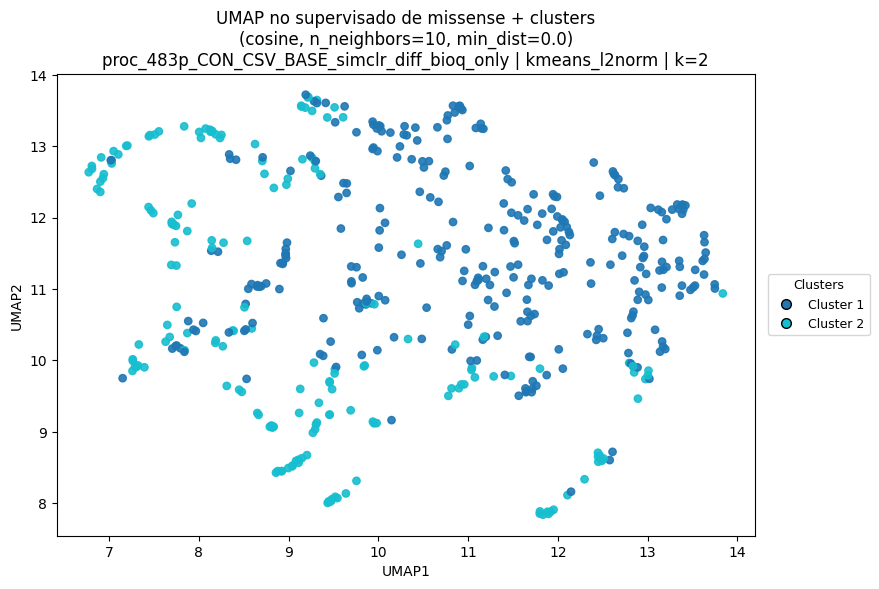

[OK] /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_umap_unsup_missense_clusters_k2.png


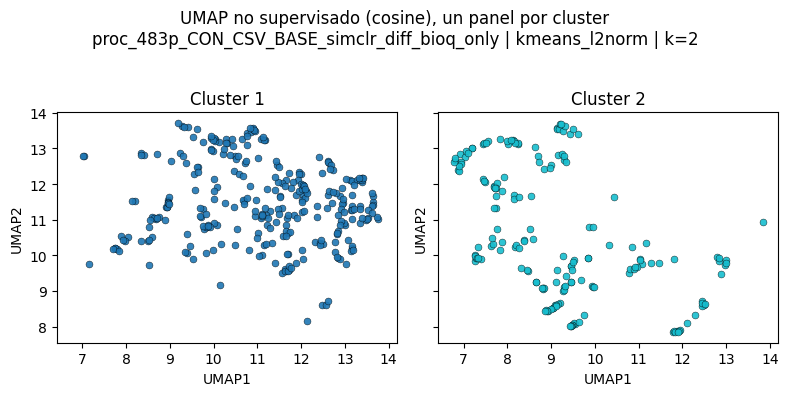

[OK] /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_umap_unsup_panels_by_cluster_k2.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


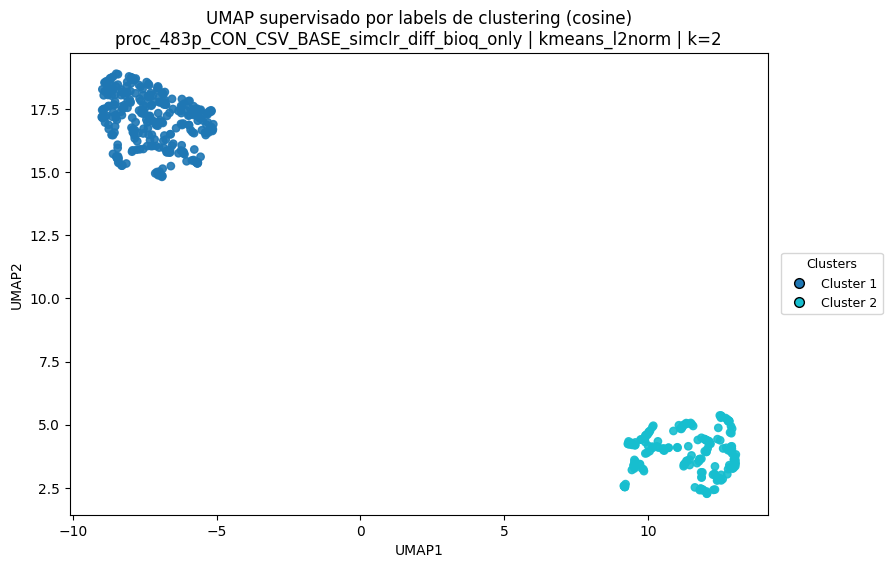

[OK] /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_umap_supervised_missense_clusters_k2.png


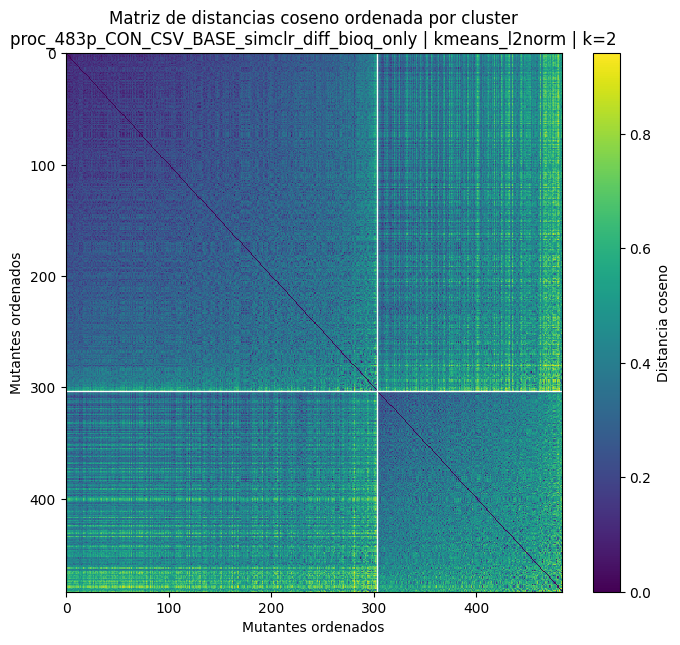

[OK] /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_heatmap_cosine_distance_by_cluster_k2.png
[OK] CSV métricas cluster 128D: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_cluster_metrics_128d_k2.csv

[resumen 128D]
  - exp_name: proc_483p_CON_CSV_BASE_simclr_diff_bioq_only
  - cluster_method: kmeans_l2norm
  - k_used: 2
  - n_samples_missense: 484
  - n_clusters: 2
  - silhouette_cosine: 0.21916160405327023
  - mean_cluster_size: 242.0
  - min_cluster_size: 180
  - max_cluster_size: 304

[métricas por cluster]


,cluster,n_cluster,mean_intra_cosine_distance,nearest_inter_cosine_distance,separation_gap_inter_minus_intra
0,0,304,0.293758,0.443709,0.149951
1,1,180,0.428278,0.443709,0.015431


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


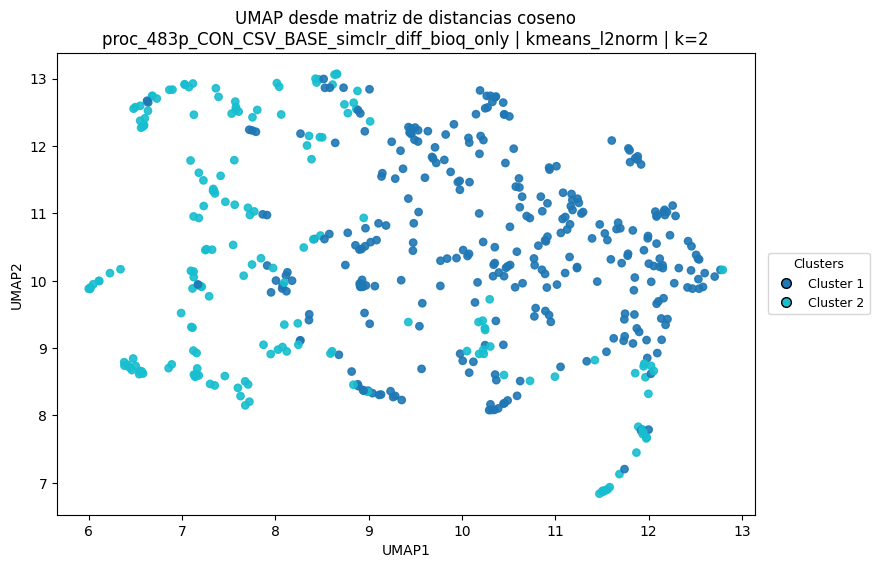

[OK] /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_umap_from_cosine_distance_matrix_k2.png
[OK] CSV missense enriquecido: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_kmeans_l2norm_missense_umap_and_clusters_k2.csv

--- Método de clustering: agglomerative_cosine | k óptimo=2 ---
[OK] CSV asignaciones missense: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/clustering_plots/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only_agglomerative_cosine_missense_cluster_assignments_k2.csv


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [ ]:
# =========================================================
# VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE EN 128D
# - Optimización de k por método
# - KMeans sobre embeddings L2-normalizados
# - Agglomerative con distancia coseno
# - Spectral con afinidad derivada de coseno
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "resultados" not in globals() or not resultados:
    raise RuntimeError(
        "⚠️ 'resultados' no está cargado.\n"
        "Ejecuta antes la celda de selección/carga de ablaciones."
    )

UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.0
UMAP_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 0
GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS = True

# ---------------------------------------------------------
# Configuración del escaneo de k por método
# ---------------------------------------------------------
KSCAN_MIN = 2
KSCAN_MAX = 10
KSCAN_MIN_CLUSTER_SIZE = 3
KSCAN_SILHOUETTE_TOLERANCE = 0.01

# ---------------------------------------------------------
# Selección local opcional de ablaciones a representar
# ---------------------------------------------------------
resultados_plot = _select_resultados_subset(
    resultados,
    prompt_title="seleccionar ablaciones a representar en visualización/métricas missense"
)

summary_rows = []

for exp_name, info in resultados_plot.items():
    print(f"\n=== VISUALIZACIÓN MISSENSE 128D PARA: {exp_name} ===")

    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))
    plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
    os.makedirs(plot_dir, exist_ok=True)

    df_all, df_miss, Z_all, Z_miss, files = _load_missense_embeddings_from_result(info, exp_name)

    print(f"[info] latent_npy: {files.get('latent_npy')}")
    print(f"[info] silhouette_scan_csv: {files.get('silhouette_scan_csv')}")
    print(f"[info] n_missense: {len(df_miss)}")

    # ---------------------------------------------------------
    # Espacio de trabajo coherente con coseno
    # ---------------------------------------------------------
    Z_miss_norm = _l2_normalize_embeddings(Z_miss)
    D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

    # ---------------------------------------------------------
    # Escaneo de k óptimo por método
    # ---------------------------------------------------------
    scan_results = _scan_k_by_method(
        Z_miss_norm,
        D_cos_global,
        k_min=KSCAN_MIN,
        k_max=min(KSCAN_MAX, len(Z_miss_norm) - 1),
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
    )

    scan_summary_rows = []
    for method_name, method_info in scan_results.items():
        best_k = method_info["best_k"]
        scan_df = method_info["scan_df"]

        scan_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_k_scan.csv")
        scan_df.to_csv(scan_csv, index=False)
        print(f"[OK] Scan k por método guardado: {scan_csv}")

        if best_k is None:
            best_k = min(5, max(2, len(Z_miss_norm) - 1))
            print(f"[WARN] No se pudo inferir best_k para {method_name}; uso fallback={best_k}")

        scan_summary_rows.append({
            "method": method_name,
            "best_k": int(best_k),
        })

    scan_summary_df = pd.DataFrame(scan_summary_rows)
    print("\n[resumen best_k por método]")
    display(scan_summary_df)

    clusterings = {}

    best_k_kmeans = int(scan_results["kmeans_l2norm"]["best_k"]) if scan_results["kmeans_l2norm"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_kmeans = _recompute_kmeans_labels_missense_only(
        Z_miss_norm,
        k_new=best_k_kmeans,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["kmeans_l2norm"] = {
        "labels": labels_kmeans,
        "k_used": best_k_kmeans,
    }

    best_k_ag = int(scan_results["agglomerative_cosine"]["best_k"]) if scan_results["agglomerative_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_ag = _recompute_agglomerative_labels_missense_only(
        D_cos_global,
        k_new=best_k_ag,
    )
    clusterings["agglomerative_cosine"] = {
        "labels": labels_ag,
        "k_used": best_k_ag,
    }

    best_k_spec = int(scan_results["spectral_cosine"]["best_k"]) if scan_results["spectral_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_spec = _recompute_spectral_labels_missense_only(
        D_cos_global,
        k_new=best_k_spec,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["spectral_cosine"] = {
        "labels": labels_spec,
        "k_used": best_k_spec,
    }

    for method_name, method_info in clusterings.items():
        labels_miss = method_info["labels"]
        k_to_use = method_info["k_used"]

        print(f"\n--- Método de clustering: {method_name} | k óptimo={k_to_use} ---")

        df_miss_plot = df_miss.copy()
        df_miss_plot["cluster_method"] = method_name
        df_miss_plot["cluster_label"] = labels_miss

        # ---------------------------------------------------------
        # CSV de asignaciones missense
        # ---------------------------------------------------------
        assign_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_cluster_assignments_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(assign_csv, index=False)
        print(f"[OK] CSV asignaciones missense: {assign_csv}")

        # ---------------------------------------------------------
        # 1) UMAP no supervisado de Z_miss_norm
        # ---------------------------------------------------------
        umap_unsup = _compute_umap_unsupervised(
            Z_miss_norm,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        df_miss_plot["umap_unsup_x"] = umap_unsup[:, 0]
        df_miss_plot["umap_unsup_y"] = umap_unsup[:, 1]

        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters(
            ax,
            umap_unsup,
            labels_miss,
            title=(
                f"UMAP no supervisado de missense + clusters\n"
                f"(cosine, n_neighbors=10, min_dist=0.0)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_missense_clusters_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 2) Panel por cluster en el mismo UMAP no supervisado
        # ---------------------------------------------------------
        cluster_ids = sorted(np.unique(labels_miss))
        n_clusters = len(cluster_ids)

        fig, axes = plt.subplots(
            1, n_clusters,
            figsize=(4 * n_clusters, 4),
            sharex=True, sharey=True
        )
        if n_clusters == 1:
            axes = [axes]

        cmap = plt.get_cmap("tab10")
        norm = plt.Normalize(vmin=int(min(cluster_ids)), vmax=int(max(cluster_ids)))

        for ax_panel, cid in zip(axes, cluster_ids):
            sub = df_miss_plot[df_miss_plot["cluster_label"] == cid]
            ax_panel.scatter(
                sub["umap_unsup_x"], sub["umap_unsup_y"],
                c=[cmap(norm(cid))],
                s=25,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3,
            )
            ax_panel.set_title(f"Cluster {int(cid) + 1}")
            ax_panel.set_xlabel("UMAP1")
            ax_panel.set_ylabel("UMAP2")

        plt.suptitle(
            f"UMAP no supervisado (cosine), un panel por cluster\n"
            f"{exp_name} | {method_name} | k={k_to_use}"
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
        panel_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_panels_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, panel_path)

        # ---------------------------------------------------------
        # 3) UMAP supervisado con y=labels
        # ---------------------------------------------------------
        umap_sup = _compute_umap_supervised(
            Z_miss_norm,
            labels_miss,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        df_miss_plot["umap_sup_x"] = umap_sup[:, 0]
        df_miss_plot["umap_sup_y"] = umap_sup[:, 1]

        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters(
            ax,
            umap_sup,
            labels_miss,
            title=f"UMAP supervisado por labels de clustering (cosine)\n{exp_name} | {method_name} | k={k_to_use}",
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_supervised_missense_clusters_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 4) Matriz de distancias coseno ordenada por cluster
        # ---------------------------------------------------------
        summary_dict, metrics_df, D_cos = _compute_cluster_metrics(Z_miss_norm, labels_miss)
        order_idx = _cluster_order_for_heatmap(labels_miss, D=D_cos)
        D_ord = D_cos[np.ix_(order_idx, order_idx)]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(D_ord, aspect="auto", interpolation="nearest")
        ax.set_title(f"Matriz de distancias coseno ordenada por cluster\n{exp_name} | {method_name} | k={k_to_use}")
        ax.set_xlabel("Mutantes ordenados")
        ax.set_ylabel("Mutantes ordenados")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Distancia coseno")

        labels_ord = labels_miss[order_idx]
        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

        heatmap_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_heatmap_cosine_distance_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, heatmap_path)

        # ---------------------------------------------------------
        # 5) Métricas 128D
        # ---------------------------------------------------------
        metrics_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_cluster_metrics_128d_k{k_to_use}.csv"
        )
        metrics_df.to_csv(metrics_csv, index=False)
        print(f"[OK] CSV métricas cluster 128D: {metrics_csv}")

        summary_row = {
            "exp_name": exp_name,
            "cluster_method": method_name,
            "k_used": int(k_to_use),
            **summary_dict,
        }
        summary_rows.append(summary_row)

        print("\n[resumen 128D]")
        for k, v in summary_row.items():
            print(f"  - {k}: {v}")
        print("\n[métricas por cluster]")
        display(metrics_df)

        # ---------------------------------------------------------
        # Extra opcional: UMAP desde la matriz de distancias
        # ---------------------------------------------------------
        if GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS:
            umap_dist = _compute_umap_from_precomputed_dist(
                D_cos,
                n_neighbors=UMAP_N_NEIGHBORS,
                min_dist=UMAP_MIN_DIST,
                random_state=UMAP_RANDOM_STATE,
            )
            df_miss_plot["umap_dist_x"] = umap_dist[:, 0]
            df_miss_plot["umap_dist_y"] = umap_dist[:, 1]

            fig, ax = plt.subplots(figsize=(9, 6))
            _scatter_clusters(
                ax,
                umap_dist,
                labels_miss,
                title=f"UMAP desde matriz de distancias coseno\n{exp_name} | {method_name} | k={k_to_use}",
            )
            fig_path = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_umap_from_cosine_distance_matrix_k{k_to_use}.png"
            )
            _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # Guardar CSV enriquecido con coords y clusters
        # ---------------------------------------------------------
        enriched_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_umap_and_clusters_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(enriched_csv, index=False)
        print(f"[OK] CSV missense enriquecido: {enriched_csv}")

# Resumen global solo de las ablaciones representadas en esta celda
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_root = resolve_runs_root() if "resolve_runs_root" in globals() else os.getcwd()
    summary_out = os.path.join(
        summary_root,
        "summary_missense_cluster_metrics_128d_selected.csv"
    )
    summary_df.to_csv(summary_out, index=False)
    print(f"\n[OK] Resumen global guardado en: {summary_out}")
    display(summary_df)

print(f"\n✅ Gráficas y métricas de clusters missense generadas para: {', '.join(resultados_plot.keys())}")

In [ ]:
# =========================================================
# CELDA OPCIONAL 3
# COMPARAR AUTOMÁTICAMENTE LOS 3 MÉTODOS DE CLUSTERING
# Y QUEDARSE CON EL MEJOR POR silhouette_cosine
# =========================================================
import os
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

if "resultados_plot" not in globals() or not resultados_plot:
    raise RuntimeError(
        "⚠️ 'resultados_plot' no está disponible.\n"
        "Ejecuta antes la celda de visualización/métricas missense."
    )

# ---------------------------------------------------------
# Configuración
# ---------------------------------------------------------
BEST_METHOD_TIE_TOLERANCE = 1e-6   # tolerancia numérica para empates exactos
SAVE_BEST_ASSIGNMENTS = True       # guardar CSV con asignaciones del mejor método
SAVE_BEST_128D_METRICS = True      # guardar CSV con métricas del mejor método
PRINT_DETAILED_TABLES = True       # mostrar tabla completa por ablación

best_method_rows = []
best_method_per_exp = {}

for exp_name, info in resultados_plot.items():
    print(f"\n=== COMPARACIÓN AUTOMÁTICA DE MÉTODOS PARA: {exp_name} ===")

    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))
    plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
    os.makedirs(plot_dir, exist_ok=True)

    # ---------------------------------------------------------
    # Cargar missense y embeddings normalizados
    # ---------------------------------------------------------
    df_all, df_miss, Z_all, Z_miss, files = _load_missense_embeddings_from_result(info, exp_name)
    Z_miss_norm = _l2_normalize_embeddings(Z_miss)
    D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

    # ---------------------------------------------------------
    # Repetir el escaneo de k por método para asegurar consistencia
    # ---------------------------------------------------------
    scan_results = _scan_k_by_method(
        Z_miss_norm,
        D_cos_global,
        k_min=KSCAN_MIN,
        k_max=min(KSCAN_MAX, len(Z_miss_norm) - 1),
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
    )

    # ---------------------------------------------------------
    # Construir labels y métricas finales para cada método
    # ---------------------------------------------------------
    method_rows = []
    method_objects = {}

    for method_name, method_info in scan_results.items():
        best_k = method_info["best_k"]
        if best_k is None:
            best_k = min(5, max(2, len(Z_miss_norm) - 1))
            print(f"[WARN] No se pudo inferir best_k para {method_name}; uso fallback={best_k}")

        if method_name == "kmeans_l2norm":
            labels = _recompute_kmeans_labels_missense_only(
                Z_miss_norm,
                k_new=int(best_k),
                random_state=KMEANS_RANDOM_STATE,
            )
        elif method_name == "agglomerative_cosine":
            labels = _recompute_agglomerative_labels_missense_only(
                D_cos_global,
                k_new=int(best_k),
            )
        elif method_name == "spectral_cosine":
            labels = _recompute_spectral_labels_missense_only(
                D_cos_global,
                k_new=int(best_k),
                random_state=KMEANS_RANDOM_STATE,
            )
        else:
            raise RuntimeError(f"Método no reconocido: {method_name}")

        summary_dict, metrics_df, D_cos = _compute_cluster_metrics(Z_miss_norm, labels)

        mean_gap = float(metrics_df["separation_gap_inter_minus_intra"].mean()) \
            if not metrics_df.empty and metrics_df["separation_gap_inter_minus_intra"].notna().any() else np.nan
        mean_intra = float(metrics_df["mean_intra_cosine_distance"].mean()) \
            if not metrics_df.empty and metrics_df["mean_intra_cosine_distance"].notna().any() else np.nan
        mean_nearest_inter = float(metrics_df["nearest_inter_cosine_distance"].mean()) \
            if not metrics_df.empty and metrics_df["nearest_inter_cosine_distance"].notna().any() else np.nan

        row = {
            "exp_name": exp_name,
            "method": method_name,
            "k_used": int(best_k),
            "silhouette_cosine": summary_dict["silhouette_cosine"],
            "n_clusters": summary_dict["n_clusters"],
            "n_samples_missense": summary_dict["n_samples_missense"],
            "mean_cluster_size": summary_dict["mean_cluster_size"],
            "min_cluster_size": summary_dict["min_cluster_size"],
            "max_cluster_size": summary_dict["max_cluster_size"],
            "mean_intra_cosine_distance": mean_intra,
            "mean_nearest_inter_cosine_distance": mean_nearest_inter,
            "mean_separation_gap": mean_gap,
        }
        method_rows.append(row)

        method_objects[method_name] = {
            "labels": labels,
            "k_used": int(best_k),
            "summary_dict": summary_dict,
            "metrics_df": metrics_df.copy(),
            "method_row": row.copy(),
        }

    compare_df = pd.DataFrame(method_rows)

    # ---------------------------------------------------------
    # Selección del mejor método
    # Criterio principal: silhouette_cosine
    # Desempates:
    #   1) mayor mean_separation_gap
    #   2) menor mean_intra_cosine_distance
    #   3) mayor min_cluster_size
    # ---------------------------------------------------------
    compare_df["silhouette_cosine_rank"] = compare_df["silhouette_cosine"].fillna(-np.inf)

    compare_df_sorted = compare_df.sort_values(
        by=[
            "silhouette_cosine_rank",
            "mean_separation_gap",
            "mean_intra_cosine_distance",
            "min_cluster_size",
        ],
        ascending=[False, False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    best_row = compare_df_sorted.iloc[0].to_dict()
    best_method = best_row["method"]

    # Detectar empate práctico en silhouette
    best_sil = best_row["silhouette_cosine"]
    tied_df = compare_df[
        np.isfinite(compare_df["silhouette_cosine"]) &
        (np.abs(compare_df["silhouette_cosine"] - best_sil) <= BEST_METHOD_TIE_TOLERANCE)
    ].copy()

    tie_note = ""
    if len(tied_df) > 1:
        tie_note = (
            "Empate en silhouette_cosine; resuelto por "
            "mean_separation_gap, mean_intra_cosine_distance y min_cluster_size."
        )

    # ---------------------------------------------------------
    # Guardar tabla comparativa por ablación
    # ---------------------------------------------------------
    compare_csv = os.path.join(
        plot_dir,
        f"{exp_name}_method_comparison_best_by_silhouette.csv"
    )
    compare_df_sorted.to_csv(compare_csv, index=False)
    print(f"[OK] Comparativa de métodos guardada: {compare_csv}")

    # ---------------------------------------------------------
    # Guardar info del mejor método
    # ---------------------------------------------------------
    best_obj = method_objects[best_method]
    best_k = best_obj["k_used"]
    best_labels = best_obj["labels"]
    best_metrics_df = best_obj["metrics_df"].copy()

    if SAVE_BEST_ASSIGNMENTS:
        df_best = df_miss.copy()
        df_best["best_method"] = best_method
        df_best["cluster_label"] = best_labels

        best_assign_csv = os.path.join(
            plot_dir,
            f"{exp_name}_BEST_METHOD_{best_method}_cluster_assignments_k{best_k}.csv"
        )
        df_best.to_csv(best_assign_csv, index=False)
        print(f"[OK] CSV asignaciones mejor método: {best_assign_csv}")

    if SAVE_BEST_128D_METRICS:
        best_metrics_csv = os.path.join(
            plot_dir,
            f"{exp_name}_BEST_METHOD_{best_method}_cluster_metrics_128d_k{best_k}.csv"
        )
        best_metrics_df.to_csv(best_metrics_csv, index=False)
        print(f"[OK] CSV métricas 128D mejor método: {best_metrics_csv}")

    best_summary_row = {
        "exp_name": exp_name,
        "best_method": best_method,
        "best_k": int(best_k),
        "best_silhouette_cosine": best_row["silhouette_cosine"],
        "best_mean_separation_gap": best_row["mean_separation_gap"],
        "best_mean_intra_cosine_distance": best_row["mean_intra_cosine_distance"],
        "best_min_cluster_size": best_row["min_cluster_size"],
        "tie_note": tie_note,
    }
    best_method_rows.append(best_summary_row)

    best_method_per_exp[exp_name] = {
        "best_method": best_method,
        "best_k": int(best_k),
        "labels": best_labels.copy(),
        "compare_df": compare_df_sorted.copy(),
        "metrics_df": best_metrics_df.copy(),
    }

    print("\n[mejor método seleccionado]")
    for k, v in best_summary_row.items():
        print(f"  - {k}: {v}")

    if PRINT_DETAILED_TABLES:
        print("\n[tabla comparativa de métodos]")
        display(compare_df_sorted)

# ---------------------------------------------------------
# Resumen global
# ---------------------------------------------------------
if best_method_rows:
    best_methods_summary_df = pd.DataFrame(best_method_rows)
    summary_root = resolve_runs_root() if "resolve_runs_root" in globals() else os.getcwd()

    best_summary_csv = os.path.join(
        summary_root,
        "summary_best_clustering_method_by_silhouette_selected.csv"
    )
    best_methods_summary_df.to_csv(best_summary_csv, index=False)

    print(f"\n[OK] Resumen global del mejor método guardado en: {best_summary_csv}")
    display(best_methods_summary_df)

print("\n✅ Comparación automática de métodos completada.")


=== COMPARACIÓN AUTOMÁTICA DE MÉTODOS PARA: proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse ===

=== RESUMEN DE ARCHIVOS DETECTADOS ===
umap_csv            : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv
ranking_csv         : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/ranking_mut_vs_wt.csv
severity_csv        : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/training_outputs/embedding_severity_metrics.csv
latent_npy          : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/z_embeddings/embeddings_latent_Z_all.npy
latent_ids_npy      : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse/z_embeddings/embeddings_latent_ids_all.npy
silhouette_sc

,exp_name,method,k_used,silhouette_cosine,n_clusters,n_samples_missense,mean_cluster_size,min_cluster_size,max_cluster_size,mean_intra_cosine_distance,mean_nearest_inter_cosine_distance,mean_separation_gap,silhouette_cosine_rank
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,spectral_cosine,2,0.256530,2,484,242.0,218,266,0.435470,0.592678,0.157208,0.256530
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,kmeans_l2norm,2,0.256494,2,484,242.0,218,266,0.435097,0.592457,0.157360,0.256494
2,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,agglomerative_cosine,2,0.194885,2,484,242.0,1,483,0.512852,0.662262,0.149410,0.194885



[OK] Resumen global del mejor método guardado en: /content/drive/MyDrive/GNN_siames_colab/runs/summary_best_clustering_method_by_silhouette_selected.csv


,exp_name,best_method,best_k,best_silhouette_cosine,best_mean_separation_gap,best_mean_intra_cosine_distance,best_min_cluster_size,tie_note
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,spectral_cosine,2,0.25653,0.157208,0.43547,218,



✅ Comparación automática de métodos completada.


### **Clustering WT-COMPANIONS**

In [ ]:
# =========================================================
# HELPERS PARA VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE
# - Añade proyección de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente de missense
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import umap
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import normalize


WT_NATIVE_TOKEN_DEFAULT_LOCAL = "PKP2_WT"
TRUNC_TOKENS_LOCAL = {"STOP", "TER", "X", "*"}


# ---------------------------------------------------------
# Clasificación robusta de tipos especiales
# ---------------------------------------------------------
def _is_wt_companion_id_local(s: object) -> bool:
    s_up = str(s).strip().upper()
    return (
        s_up.startswith("WT_COMP:")
        or ("WT_COMPANION" in s_up)
        or ("WT_COMP" in s_up)
    )


def _is_native_wt_id_local(s: object, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> bool:
    s = str(s).strip()
    if not s:
        return False

    s_up = s.upper()
    token_up = str(token).strip().upper()

    if _is_wt_companion_id_local(s_up):
        return False

    s_base = os.path.basename(s_up)
    s_noext = os.path.splitext(s_base)[0]
    s_tail = s_up.split(":")[-1].strip()

    return (
        s_up == token_up
        or s_base == token_up
        or s_noext == token_up
        or s_tail == token_up
    )


def _is_trunc_id_local(s: object) -> bool:
    raw = str(s).strip().upper()
    if not raw:
        return False

    # 1) Intentar parser si existe en el notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                _pos, _wt, _mut = parsed
                if str(_mut).upper() in TRUNC_TOKENS_LOCAL:
                    return True
        except Exception:
            pass

    # 2) Fallback textual robusto
    return (
        ("STOP" in raw)
        or ("TER" in raw)
        or ("->X" in raw)
        or raw.endswith(":X")
        or raw.endswith("_X")
        or raw.endswith("_STOP")
        or raw.endswith("_TER")
    )


def infer_type_posthoc_from_id_local(s: object) -> str:
    """
    Devuelve:
      - 'WT'       para WT_companion
      - 'trunc'    para STOP / truncados
      - 'missense' para el resto

    Nota:
      PKP2_WT nativa NO se clasifica como WT_companion aquí.
      Se detecta aparte para dibujarla como estrella.
    """
    if _is_wt_companion_id_local(s):
        return "WT"
    if _is_native_wt_id_local(s):
        return "missense"
    if _is_trunc_id_local(s):
        return "trunc"
    return "missense"


def _choose_identifier_series_local(df: pd.DataFrame) -> pd.Series:
    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key"
    ]
    for col in candidate_cols:
        if col in df.columns:
            return df[col].astype(str)
    return pd.Series([""] * len(df), index=df.index, dtype="object")


def _normalize_type_column_local(df):
    df = df.copy()

    # Guardamos un identificador textual unificado para depuración / overlays
    df["_id_text_plot"] = _choose_identifier_series_local(df)

    if "type_posthoc" in df.columns:
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = df["type_posthoc"].astype(str).map(job_map).fillna("mut_missense")
    else:
        # Rehacer type robustamente con la misma filosofía que la otra celda
        inferred = df["_id_text_plot"].apply(infer_type_posthoc_from_id_local)
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = inferred.map(job_map).fillna("mut_missense")

    # PKP2_WT nativa debe quedar fuera de wt_companion y marcarse aparte
    native_mask = df["_id_text_plot"].apply(_is_native_wt_id_local)
    df.loc[native_mask, "type"] = "mut_missense"

    return df


def _find_wt_native_rows_local(df: pd.DataFrame, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return df.iloc[0:0].copy()

    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key", "_id_text_plot"
    ]
    for col in candidate_cols:
        if col not in df.columns:
            continue
        m = df[col].astype(str).apply(lambda v: _is_native_wt_id_local(v, token=token))
        out = df.loc[m].copy()
        if not out.empty:
            return out

    return df.iloc[0:0].copy()


def _split_variant_frames_local(df: pd.DataFrame):
    df = _normalize_type_column_local(df)
    df_native = _find_wt_native_rows_local(df)

    # WT nativa no debe entrar en missense de plot contextual
    native_idx = set(df_native.index.tolist())

    df_miss = df[(df["type"] == "mut_missense") & (~df.index.isin(native_idx))].copy()
    df_stop = df[df["type"] == "mut_stop"].copy()
    df_wt   = df[df["type"] == "wt_companion"].copy()
    return df, df_miss, df_stop, df_wt, df_native


# ---------------------------------------------------------
# Carga de embeddings de missense + especiales
# ---------------------------------------------------------
def _safe_take_rows(Z_all, rows, label, exp_name):
    rows = np.asarray(rows, dtype=int)
    if rows.size == 0:
        return np.zeros((0, Z_all.shape[1]), dtype=Z_all.dtype)
    if rows.max() >= Z_all.shape[0]:
        raise RuntimeError(
            f"[{exp_name}] row_idx máximo para {label}={rows.max()} pero Z_all.shape={Z_all.shape}"
        )
    return Z_all[rows]


def _load_embeddings_with_specials_from_result(info, exp_name):
    df_all = _normalize_type_column_local(info["df"].copy())
    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))

    z_path = files.get("latent_npy", None)
    if z_path is None or not os.path.isfile(z_path):
        raise FileNotFoundError(
            f"[{exp_name}] No se encontró embeddings_latent_Z_all.npy.\nRuta detectada: {z_path}"
        )

    if "row_idx" not in df_all.columns:
        raise RuntimeError(
            f"[{exp_name}] El CSV no contiene 'row_idx'; no se puede alinear con Z_all."
        )

    df_all, df_miss, df_stop, df_wt, df_native = _split_variant_frames_local(df_all)

    if df_miss.empty:
        raise RuntimeError(f"[{exp_name}] No hay mutantes missense en esta ablación.")

    Z_all = np.load(z_path)

    rows_miss   = df_miss["row_idx"].to_numpy(dtype=int)
    rows_stop   = df_stop["row_idx"].to_numpy(dtype=int) if not df_stop.empty else np.array([], dtype=int)
    rows_wt     = df_wt["row_idx"].to_numpy(dtype=int) if not df_wt.empty else np.array([], dtype=int)
    rows_native = df_native["row_idx"].to_numpy(dtype=int) if not df_native.empty else np.array([], dtype=int)

    Z_miss   = _safe_take_rows(Z_all, rows_miss, "missense", exp_name)
    Z_stop   = _safe_take_rows(Z_all, rows_stop, "STOP/trunc", exp_name)
    Z_wt     = _safe_take_rows(Z_all, rows_wt, "WT_companion", exp_name)
    Z_native = _safe_take_rows(Z_all, rows_native, "PKP2_WT", exp_name)

    return {
        "df_all": df_all,
        "df_miss": df_miss,
        "df_stop": df_stop,
        "df_wt": df_wt,
        "df_native": df_native,
        "Z_all": Z_all,
        "Z_miss": Z_miss,
        "Z_stop": Z_stop,
        "Z_wt": Z_wt,
        "Z_native": Z_native,
        "files": files,
    }


def _resolve_k_for_missense(df_miss, files, default_k=5):
    k_current = default_k
    if "kmeans" in df_miss.columns:
        labels_pre = pd.to_numeric(df_miss["kmeans"], errors="coerce").dropna().astype(int)
        if len(labels_pre) > 0:
            k_current = max(2, int(labels_pre.nunique()))
    return infer_k_from_scan(files.get("silhouette_scan_csv"), default_k=k_current)


def _l2_normalize_embeddings(Z):
    Z = np.asarray(Z, dtype=float)
    if Z.ndim != 2:
        raise ValueError(f"Se esperaba una matriz 2D; recibido shape={Z.shape}")
    return normalize(Z, norm="l2")


def _recompute_kmeans_labels_missense_only(Z_miss, k_new, random_state=0):
    if k_new < 2 or k_new > len(Z_miss):
        raise ValueError(f"k_new={k_new} inválido para N={len(Z_miss)}")
    km = KMeans(n_clusters=int(k_new), random_state=random_state, n_init="auto")
    labels = km.fit_predict(Z_miss)
    return labels


def _recompute_agglomerative_labels_missense_only(D_cos, k_new):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")
    model = AgglomerativeClustering(
        n_clusters=int(k_new),
        metric="precomputed",
        linkage="average",
    )
    labels = model.fit_predict(D_cos)
    return labels


def _recompute_spectral_labels_missense_only(D_cos, k_new, random_state=0):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    affinity = 1.0 - np.asarray(D_cos, dtype=float)
    affinity = np.clip(affinity, 0.0, 1.0)
    np.fill_diagonal(affinity, 1.0)

    model = SpectralClustering(
        n_clusters=int(k_new),
        affinity="precomputed",
        random_state=random_state,
        assign_labels="kmeans",
        n_init=10,
    )
    labels = model.fit_predict(affinity)
    return labels


# ---------------------------------------------------------
# UMAP con reducer reutilizable + transform de especiales
# ---------------------------------------------------------
def _fit_umap_unsupervised_reducer(Z_miss, n_neighbors=10, min_dist=0.0, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss)
    return reducer, coords


def _fit_umap_supervised_reducer(Z_miss, labels, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss, y=np.asarray(labels))
    return reducer, coords


def _transform_with_reducer_safe(reducer, Z):
    Z = np.asarray(Z)
    if Z.ndim != 2 or Z.shape[0] == 0:
        return np.zeros((0, 2), dtype=float)
    return reducer.transform(Z)


def _compute_umap_from_precomputed_dist(D, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="precomputed",
        random_state=random_state,
    )
    return reducer.fit_transform(D)


def _cluster_order_for_heatmap(labels, D=None):
    labels = np.asarray(labels)
    order = np.argsort(labels, kind="stable")
    if D is None:
        return order

    ordered = []
    for cid in sorted(np.unique(labels)):
        idx = np.where(labels == cid)[0]
        if len(idx) <= 2:
            ordered.extend(idx.tolist())
            continue
        subD = D[np.ix_(idx, idx)]
        mean_d = subD.mean(axis=1)
        local_order = idx[np.argsort(mean_d)]
        ordered.extend(local_order.tolist())
    return np.array(ordered, dtype=int)


def _compute_cluster_metrics(Z_miss, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    D_cos = pairwise_distances(Z_miss, metric="cosine")
    silhouette_cos = np.nan
    if len(unique_labels) >= 2 and len(unique_labels) < len(labels):
        silhouette_cos = float(silhouette_score(Z_miss, labels, metric="cosine"))

    rows = []
    for cid in unique_labels:
        idx = np.where(labels == cid)[0]
        n = len(idx)
        intra = np.nan
        nearest_inter = np.nan

        if n >= 2:
            subD = D_cos[np.ix_(idx, idx)]
            intra = float(subD[np.triu_indices_from(subD, k=1)].mean()) if n > 1 else np.nan

        other_cands = []
        for ocid in unique_labels:
            if ocid == cid:
                continue
            jdx = np.where(labels == ocid)[0]
            if len(idx) > 0 and len(jdx) > 0:
                inter_block = D_cos[np.ix_(idx, jdx)]
                other_cands.append(float(inter_block.mean()))
        if other_cands:
            nearest_inter = float(min(other_cands))

        rows.append({
            "cluster": int(cid),
            "n_cluster": int(n),
            "mean_intra_cosine_distance": intra,
            "nearest_inter_cosine_distance": nearest_inter,
            "separation_gap_inter_minus_intra": (
                nearest_inter - intra
                if pd.notna(nearest_inter) and pd.notna(intra)
                else np.nan
            ),
        })

    metrics_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    summary = {
        "n_samples_missense": int(len(labels)),
        "n_clusters": int(len(unique_labels)),
        "silhouette_cosine": silhouette_cos,
        "mean_cluster_size": float(metrics_df["n_cluster"].mean()) if not metrics_df.empty else np.nan,
        "min_cluster_size": int(metrics_df["n_cluster"].min()) if not metrics_df.empty else np.nan,
        "max_cluster_size": int(metrics_df["n_cluster"].max()) if not metrics_df.empty else np.nan,
    }
    return summary, metrics_df, D_cos


def _select_best_k_from_scan(
    df_scan,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    if df_scan is None or df_scan.empty:
        return None, None

    df_scan = df_scan.copy()
    df_scan = df_scan[np.isfinite(df_scan["silhouette_cosine"])].copy()
    if df_scan.empty:
        return None, None

    eligible = df_scan[df_scan["min_cluster_size"] >= int(min_cluster_size_threshold)].copy()
    if eligible.empty:
        eligible = df_scan.copy()

    best_sil = float(eligible["silhouette_cosine"].max())
    near_best = eligible[
        eligible["silhouette_cosine"] >= (best_sil - float(silhouette_tolerance))
    ].copy()

    if near_best.empty:
        near_best = eligible.copy()

    near_best = near_best.sort_values(
        ["k", "min_cluster_size", "silhouette_cosine"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    best_row = near_best.iloc[0].to_dict()
    return int(best_row["k"]), best_row


def _scan_kmeans_l2norm(
    Z_miss_norm,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_kmeans_labels_missense_only(
                Z_miss_norm,
                k_new=k,
                random_state=random_state,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "kmeans_l2norm",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _scan_agglomerative_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_agglomerative_labels_missense_only(
                D_cos,
                k_new=k,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "agglomerative_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _scan_spectral_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_spectral_labels_missense_only(
                D_cos,
                k_new=k,
                random_state=random_state,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "spectral_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _scan_k_by_method(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    results = {}

    best_k_kmeans, df_kmeans = _scan_kmeans_l2norm(
        Z_miss_norm,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["kmeans_l2norm"] = {
        "best_k": best_k_kmeans,
        "scan_df": df_kmeans,
    }

    best_k_ag, df_ag = _scan_agglomerative_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["agglomerative_cosine"] = {
        "best_k": best_k_ag,
        "scan_df": df_ag,
    }

    best_k_spec, df_spec = _scan_spectral_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["spectral_cosine"] = {
        "best_k": best_k_spec,
        "scan_df": df_spec,
    }

    return results


# ---------------------------------------------------------
# Plotting: missense coloreados + especiales sobrepuestos
# ---------------------------------------------------------
def _special_handle_set(include_wt=True, include_stop=True, include_native=True):
    handles = []
    if include_wt:
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor="none", markeredgecolor="black",
                label="WT_companion",
                markersize=8,
            )
        )
    if include_stop:
        handles.append(
            Line2D(
                [0], [0],
                marker="x", linestyle="none",
                color="black",
                label="STOP / truncados",
                markersize=8,
            )
        )
    if include_native:
        handles.append(
            Line2D(
                [0], [0],
                marker="*", linestyle="none",
                markerfacecolor="gold", markeredgecolor="black",
                label="WT nativa (PKP2_WT)",
                markersize=12,
            )
        )
    return handles


def _scatter_clusters_with_specials(
    ax,
    miss_coords,
    labels,
    title,
    wt_coords=None,
    stop_coords=None,
    native_coords=None,
    xlabel="UMAP1",
    ylabel="UMAP2",
):
    miss_coords = np.asarray(miss_coords)
    labels = np.asarray(labels)

    cmap = plt.get_cmap("tab10")
    norm = mcolors.Normalize(vmin=int(labels.min()), vmax=int(labels.max()))

    ax.scatter(
        miss_coords[:, 0], miss_coords[:, 1],
        c=labels, cmap=cmap, norm=norm,
        s=28, alpha=0.9, label="_nolegend_"
    )

    if wt_coords is not None and len(wt_coords) > 0:
        wt_coords = np.asarray(wt_coords)
        ax.scatter(
            wt_coords[:, 0], wt_coords[:, 1],
            marker="o",
            facecolors="none",
            edgecolors="black",
            s=70,
            linewidths=1.4,
            label="_nolegend_",
            zorder=6,
        )

    if stop_coords is not None and len(stop_coords) > 0:
        stop_coords = np.asarray(stop_coords)
        ax.scatter(
            stop_coords[:, 0], stop_coords[:, 1],
            marker="x",
            c="black",
            s=60,
            linewidths=1.3,
            label="_nolegend_",
            zorder=7,
        )

    if native_coords is not None and len(native_coords) > 0:
        native_coords = np.asarray(native_coords)
        ax.scatter(
            native_coords[:, 0], native_coords[:, 1],
            marker="*",
            c="gold",
            edgecolors="black",
            s=220,
            linewidths=1.5,
            label="_nolegend_",
            zorder=10,
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    cluster_handles = []
    for cid in sorted(np.unique(labels)):
        cluster_handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor=cmap(norm(cid)),
                markeredgecolor="black",
                label=f"Cluster {int(cid) + 1}",
                markersize=7,
            )
        )
    legend_clusters = ax.legend(
        handles=cluster_handles,
        title="Clusters missense",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=9,
    )
    ax.add_artist(legend_clusters)

    special_handles = _special_handle_set(
        include_wt=(wt_coords is not None and len(wt_coords) > 0),
        include_stop=(stop_coords is not None and len(stop_coords) > 0),
        include_native=(native_coords is not None and len(native_coords) > 0),
    )
    if special_handles:
        ax.legend(
            handles=special_handles,
            title="Casos especiales",
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
            fontsize=9,
            title_fontsize=9,
        )


def _savefig_and_report(fig, out_path):
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    if not os.path.isfile(out_path):
        raise RuntimeError(f"⚠️ No se generó correctamente: {out_path}")
    print(f"[OK] {out_path}")


def _select_resultados_subset(resultados_dict, prompt_title="seleccionar ablaciones a representar"):
    if not resultados_dict:
        raise RuntimeError("⚠️ 'resultados' está vacío.")

    exp_names = list(resultados_dict.keys())

    print(f"\n=== Opciones para {prompt_title} ===")
    for i, name in enumerate(exp_names, 1):
        print(f"  {i:02d}. {name}")

    selected = safe_input(
        "\nIntroduce una o varias ablaciones (nombre exacto o índice), separadas por comas\n"
        "(ejemplos: 1 | 1,3 | nombre_exacto | all)\n> ",
        default="all"
    ).strip()

    if not selected:
        selected = "all"

    tokens = [t.strip() for t in selected.split(",") if t.strip()]
    if len(tokens) == 1 and tokens[0].lower() in {"all", "*", "todas", "todos"}:
        chosen_names = exp_names
    else:
        chosen_names = []
        seen = set()
        for tok in tokens:
            if tok.isdigit():
                idx = int(tok)
                if idx < 1 or idx > len(exp_names):
                    raise RuntimeError(
                        f"⚠️ Índice fuera de rango: {tok}. Debe estar entre 1 y {len(exp_names)}."
                    )
                name = exp_names[idx - 1]
            else:
                if tok not in resultados_dict:
                    raise RuntimeError(
                        f"⚠️ La ablación '{tok}' no está en resultados.\n"
                        f"Disponibles: {', '.join(exp_names)}"
                    )
                name = tok

            if name not in seen:
                seen.add(name)
                chosen_names.append(name)

    print("\n✅ Ablaciones seleccionadas para esta celda:")
    for name in chosen_names:
        print(f"   - {name}")

    return {name: resultados_dict[name] for name in chosen_names}

In [ ]:
# =========================================================
# VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE EN 128D
# - Clustering SOLO sobre missense
# - Proyección contextual de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "resultados" not in globals() or not resultados:
    raise RuntimeError(
        "⚠️ 'resultados' no está cargado.\n"
        "Ejecuta antes la celda de selección/carga de ablaciones."
    )

UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.0
UMAP_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 0
GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS = True

# ---------------------------------------------------------
# Configuración del escaneo de k por método
# ---------------------------------------------------------
KSCAN_MIN = 2
KSCAN_MAX = 10
KSCAN_MIN_CLUSTER_SIZE = 3
KSCAN_SILHOUETTE_TOLERANCE = 0.01

# ---------------------------------------------------------
# Selección local opcional de ablaciones a representar
# ---------------------------------------------------------
resultados_plot = _select_resultados_subset(
    resultados,
    prompt_title="seleccionar ablaciones a representar en visualización/métricas missense"
)

summary_rows = []

for exp_name, info in resultados_plot.items():
    print(f"\n=== VISUALIZACIÓN MISSENSE 128D PARA: {exp_name} ===")

    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))
    plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
    os.makedirs(plot_dir, exist_ok=True)

    pack = _load_embeddings_with_specials_from_result(info, exp_name)

    df_all    = pack["df_all"]
    df_miss   = pack["df_miss"]
    df_stop   = pack["df_stop"]
    df_wt     = pack["df_wt"]
    df_native = pack["df_native"]

    Z_all    = pack["Z_all"]
    Z_miss   = pack["Z_miss"]
    Z_stop   = pack["Z_stop"]
    Z_wt     = pack["Z_wt"]
    Z_native = pack["Z_native"]
    files    = pack["files"]

    print(f"[info] latent_npy: {files.get('latent_npy')}")
    print(f"[info] silhouette_scan_csv: {files.get('silhouette_scan_csv')}")
    print(f"[info] n_missense: {len(df_miss)}")
    print(f"[info] n_wt_companion: {len(df_wt)}")
    print(f"[info] n_stop_trunc: {len(df_stop)}")
    print(f"[info] n_PKP2_WT: {len(df_native)}")

    # ---------------------------------------------------------
    # Espacio de trabajo coherente con coseno
    # ---------------------------------------------------------
    Z_miss_norm = _l2_normalize_embeddings(Z_miss)
    Z_stop_norm = _l2_normalize_embeddings(Z_stop) if len(Z_stop) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_wt_norm = _l2_normalize_embeddings(Z_wt) if len(Z_wt) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_native_norm = _l2_normalize_embeddings(Z_native) if len(Z_native) > 0 else np.zeros((0, Z_miss_norm.shape[1]))

    D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

    # ---------------------------------------------------------
    # Escaneo de k óptimo por método
    # ---------------------------------------------------------
    scan_results = _scan_k_by_method(
        Z_miss_norm,
        D_cos_global,
        k_min=KSCAN_MIN,
        k_max=min(KSCAN_MAX, len(Z_miss_norm) - 1),
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
    )

    scan_summary_rows = []
    for method_name, method_info in scan_results.items():
        best_k = method_info["best_k"]
        scan_df = method_info["scan_df"]

        scan_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_k_scan.csv")
        scan_df.to_csv(scan_csv, index=False)
        print(f"[OK] Scan k por método guardado: {scan_csv}")

        if best_k is None:
            best_k = min(5, max(2, len(Z_miss_norm) - 1))
            print(f"[WARN] No se pudo inferir best_k para {method_name}; uso fallback={best_k}")

        scan_summary_rows.append({
            "method": method_name,
            "best_k": int(best_k),
        })

    scan_summary_df = pd.DataFrame(scan_summary_rows)
    print("\n[resumen best_k por método]")
    display(scan_summary_df)

    clusterings = {}

    best_k_kmeans = int(scan_results["kmeans_l2norm"]["best_k"]) if scan_results["kmeans_l2norm"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_kmeans = _recompute_kmeans_labels_missense_only(
        Z_miss_norm,
        k_new=best_k_kmeans,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["kmeans_l2norm"] = {
        "labels": labels_kmeans,
        "k_used": best_k_kmeans,
    }

    best_k_ag = int(scan_results["agglomerative_cosine"]["best_k"]) if scan_results["agglomerative_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_ag = _recompute_agglomerative_labels_missense_only(
        D_cos_global,
        k_new=best_k_ag,
    )
    clusterings["agglomerative_cosine"] = {
        "labels": labels_ag,
        "k_used": best_k_ag,
    }

    best_k_spec = int(scan_results["spectral_cosine"]["best_k"]) if scan_results["spectral_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_spec = _recompute_spectral_labels_missense_only(
        D_cos_global,
        k_new=best_k_spec,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["spectral_cosine"] = {
        "labels": labels_spec,
        "k_used": best_k_spec,
    }

    for method_name, method_info in clusterings.items():
        labels_miss = method_info["labels"]
        k_to_use = method_info["k_used"]

        print(f"\n--- Método de clustering: {method_name} | k óptimo={k_to_use} ---")

        df_miss_plot = df_miss.copy()
        df_miss_plot["cluster_method"] = method_name
        df_miss_plot["cluster_label"] = labels_miss

        # ---------------------------------------------------------
        # CSV de asignaciones missense
        # ---------------------------------------------------------
        assign_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_cluster_assignments_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(assign_csv, index=False)
        print(f"[OK] CSV asignaciones missense: {assign_csv}")

        # ---------------------------------------------------------
        # 1) UMAP no supervisado ajustado SOLO con missense
        #    + transform de WT/STOP/PKP2_WT
        # ---------------------------------------------------------
        reducer_unsup, umap_unsup = _fit_umap_unsupervised_reducer(
            Z_miss_norm,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_unsup = _transform_with_reducer_safe(reducer_unsup, Z_wt_norm)
        stop_unsup = _transform_with_reducer_safe(reducer_unsup, Z_stop_norm)
        native_unsup = _transform_with_reducer_safe(reducer_unsup, Z_native_norm)

        df_miss_plot["umap_unsup_x"] = umap_unsup[:, 0]
        df_miss_plot["umap_unsup_y"] = umap_unsup[:, 1]

        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_unsup,
            labels_miss,
            title=(
                f"UMAP no supervisado (fit missense, transform especiales)\n"
                f"(cosine, n_neighbors=10, min_dist=0.0)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=wt_unsup,
            stop_coords=stop_unsup,
            native_coords=native_unsup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 2) Panel por cluster (solo missense)
        # ---------------------------------------------------------
        cluster_ids = sorted(np.unique(labels_miss))
        n_clusters = len(cluster_ids)

        fig, axes = plt.subplots(
            1, n_clusters,
            figsize=(4 * n_clusters, 4),
            sharex=True, sharey=True
        )
        if n_clusters == 1:
            axes = [axes]

        cmap = plt.get_cmap("tab10")
        norm = plt.Normalize(vmin=int(min(cluster_ids)), vmax=int(max(cluster_ids)))

        for ax_panel, cid in zip(axes, cluster_ids):
            sub = df_miss_plot[df_miss_plot["cluster_label"] == cid]
            ax_panel.scatter(
                sub["umap_unsup_x"], sub["umap_unsup_y"],
                c=[cmap(norm(cid))],
                s=25,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3,
            )
            ax_panel.set_title(f"Cluster {int(cid) + 1}")
            ax_panel.set_xlabel("UMAP1")
            ax_panel.set_ylabel("UMAP2")

        plt.suptitle(
            f"UMAP no supervisado (solo missense), un panel por cluster\n"
            f"{exp_name} | {method_name} | k={k_to_use}"
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
        panel_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_panels_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, panel_path)

        # ---------------------------------------------------------
        # 3) UMAP supervisado por labels de clustering
        #    + transform de especiales
        # ---------------------------------------------------------
        reducer_sup, umap_sup = _fit_umap_supervised_reducer(
            Z_miss_norm,
            labels_miss,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_sup = _transform_with_reducer_safe(reducer_sup, Z_wt_norm)
        stop_sup = _transform_with_reducer_safe(reducer_sup, Z_stop_norm)
        native_sup = _transform_with_reducer_safe(reducer_sup, Z_native_norm)

        df_miss_plot["umap_sup_x"] = umap_sup[:, 0]
        df_miss_plot["umap_sup_y"] = umap_sup[:, 1]

        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_sup,
            labels_miss,
            title=(
                f"UMAP supervisado por labels (fit missense, transform especiales)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=wt_sup,
            stop_coords=stop_sup,
            native_coords=native_sup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_supervised_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 4) Matriz de distancias coseno ordenada por cluster
        #    (solo missense; los especiales no tienen cluster)
        # ---------------------------------------------------------
        summary_dict, metrics_df, D_cos = _compute_cluster_metrics(Z_miss_norm, labels_miss)
        order_idx = _cluster_order_for_heatmap(labels_miss, D=D_cos)
        D_ord = D_cos[np.ix_(order_idx, order_idx)]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(D_ord, aspect="auto", interpolation="nearest")
        ax.set_title(f"Matriz de distancias coseno ordenada por cluster\n{exp_name} | {method_name} | k={k_to_use}")
        ax.set_xlabel("Missense ordenados")
        ax.set_ylabel("Missense ordenados")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Distancia coseno")

        labels_ord = labels_miss[order_idx]
        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

        heatmap_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_heatmap_cosine_distance_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, heatmap_path)

        # ---------------------------------------------------------
        # 5) Métricas 128D
        # ---------------------------------------------------------
        metrics_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_cluster_metrics_128d_k{k_to_use}.csv"
        )
        metrics_df.to_csv(metrics_csv, index=False)
        print(f"[OK] CSV métricas cluster 128D: {metrics_csv}")

        summary_row = {
            "exp_name": exp_name,
            "cluster_method": method_name,
            "k_used": int(k_to_use),
            "n_wt_companion_projected": int(len(df_wt)),
            "n_stop_projected": int(len(df_stop)),
            "n_PKP2_WT_projected": int(len(df_native)),
            **summary_dict,
        }
        summary_rows.append(summary_row)

        print("\n[resumen 128D]")
        for k, v in summary_row.items():
            print(f"  - {k}: {v}")
        print("\n[métricas por cluster]")
        display(metrics_df)

        # ---------------------------------------------------------
        # 6) Extra opcional: UMAP desde matriz de distancias
        #    (solo missense; no overlay de especiales aquí)
        # ---------------------------------------------------------
        if GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS:
            umap_dist = _compute_umap_from_precomputed_dist(
                D_cos,
                n_neighbors=UMAP_N_NEIGHBORS,
                min_dist=UMAP_MIN_DIST,
                random_state=UMAP_RANDOM_STATE,
            )
            df_miss_plot["umap_dist_x"] = umap_dist[:, 0]
            df_miss_plot["umap_dist_y"] = umap_dist[:, 1]

            fig, ax = plt.subplots(figsize=(9, 6))
            _scatter_clusters_with_specials(
                ax,
                umap_dist,
                labels_miss,
                title=(
                    f"UMAP desde matriz de distancias coseno (solo missense)\n"
                    f"{exp_name} | {method_name} | k={k_to_use}"
                ),
                wt_coords=np.zeros((0, 2)),
                stop_coords=np.zeros((0, 2)),
                native_coords=np.zeros((0, 2)),
            )
            fig_path = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_umap_from_cosine_distance_matrix_k{k_to_use}.png"
            )
            _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 7) Guardar CSV enriquecido missense
        # ---------------------------------------------------------
        enriched_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_umap_and_clusters_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(enriched_csv, index=False)
        print(f"[OK] CSV missense enriquecido: {enriched_csv}")

        # ---------------------------------------------------------
        # 8) Guardar CSV contextual con especiales proyectados
        # ---------------------------------------------------------
        context_parts = []

        miss_context = df_miss.copy()
        miss_context["plot_group"] = "missense"
        miss_context["cluster_method"] = method_name
        miss_context["cluster_label"] = labels_miss
        miss_context["umap_unsup_x"] = umap_unsup[:, 0]
        miss_context["umap_unsup_y"] = umap_unsup[:, 1]
        miss_context["umap_sup_x"] = umap_sup[:, 0]
        miss_context["umap_sup_y"] = umap_sup[:, 1]
        context_parts.append(miss_context)

        if len(df_wt) > 0:
            wt_context = df_wt.copy()
            wt_context["plot_group"] = "wt_companion"
            wt_context["cluster_method"] = method_name
            wt_context["cluster_label"] = np.nan
            wt_context["umap_unsup_x"] = wt_unsup[:, 0]
            wt_context["umap_unsup_y"] = wt_unsup[:, 1]
            wt_context["umap_sup_x"] = wt_sup[:, 0]
            wt_context["umap_sup_y"] = wt_sup[:, 1]
            context_parts.append(wt_context)

        if len(df_stop) > 0:
            stop_context = df_stop.copy()
            stop_context["plot_group"] = "mut_stop"
            stop_context["cluster_method"] = method_name
            stop_context["cluster_label"] = np.nan
            stop_context["umap_unsup_x"] = stop_unsup[:, 0]
            stop_context["umap_unsup_y"] = stop_unsup[:, 1]
            stop_context["umap_sup_x"] = stop_sup[:, 0]
            stop_context["umap_sup_y"] = stop_sup[:, 1]
            context_parts.append(stop_context)

        if len(df_native) > 0:
            native_context = df_native.copy()
            native_context["plot_group"] = "PKP2_WT_native"
            native_context["cluster_method"] = method_name
            native_context["cluster_label"] = np.nan
            native_context["umap_unsup_x"] = native_unsup[:, 0]
            native_context["umap_unsup_y"] = native_unsup[:, 1]
            native_context["umap_sup_x"] = native_sup[:, 0]
            native_context["umap_sup_y"] = native_sup[:, 1]
            context_parts.append(native_context)

        if context_parts:
            context_df = pd.concat(context_parts, axis=0, ignore_index=False)
            context_csv = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_context_all_points_projected_k{k_to_use}.csv"
            )
            context_df.to_csv(context_csv, index=False)
            print(f"[OK] CSV contextual con especiales proyectados: {context_csv}")

# Resumen global solo de las ablaciones representadas en esta celda
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_root = resolve_runs_root() if "resolve_runs_root" in globals() else os.getcwd()
    summary_out = os.path.join(
        summary_root,
        "summary_missense_cluster_metrics_128d_selected.csv"
    )
    summary_df.to_csv(summary_out, index=False)
    print(f"\n[OK] Resumen global guardado en: {summary_out}")
    display(summary_df)

print(f"\n✅ Gráficas y métricas de clusters missense generadas para: {', '.join(resultados_plot.keys())}")

Output hidden; open in https://colab.research.google.com to view.

### **Clustering con inferencias**

In [ ]:
# =========================================================
# HELPERS PARA VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE
# - Añade proyección de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente de missense
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import umap
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import normalize


WT_NATIVE_TOKEN_DEFAULT_LOCAL = "PKP2_WT"
TRUNC_TOKENS_LOCAL = {"STOP", "TER", "X", "*"}

import re

USER_MISSENSE_GROUP_DEFAULTS_LOCAL = [
    "incremento_energia",
    "disminucion_energia",
    "no_desviacion_apreciable",
]
USER_MISSENSE_GROUP_MARKERS_LOCAL = ["D", "P", "^", "v", "s", "X"]

USER_MISSENSE_GROUP_COLORS_LOCAL = [
    "crimson",
    "darkorange",
    "teal",
    "purple",
    "saddlebrown",
    "deeppink",
]

def _normalize_missense_user_id_local(s: object) -> str:
    """
    Normaliza cualquier identificador de mutante a formato canónico:
      POS_<pos>_<WT>_<MUT>

    Prioridad:
      1) usar el parser robusto del notebook si está disponible
      2) fallback regex sobre cadenas tipo pos_<pos>_<WT>_<MUT>
    """
    raw = str(s).strip()
    if not raw:
        return ""

    # 1) Vía robusta: parser común del notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                pos, wt, mut = parsed
                return f"POS_{int(pos)}_{str(wt).upper()}_{str(mut).upper()}"
        except Exception:
            pass

    # 2) Fallback textual
    s_up = os.path.splitext(os.path.basename(raw))[0].upper()

    m = re.search(r"(POS_\d+_[A-Z*]+_[A-Z*]+)", s_up)
    if m:
        return m.group(1)

    tail = s_up.split(":")[-1].strip()
    m2 = re.search(r"(POS_\d+_[A-Z*]+_[A-Z*]+)", tail)
    if m2:
        return m2.group(1)

    return s_up


def _prompt_user_missense_groups_local():
    """
    Pide por terminal 3 grupos opcionales de missense especiales.
    Cada grupo admite hasta 3 identificadores tipo pos_11_G_C.
    El nombre de la label puede cambiarse por terminal.
    """
    groups = []

    print("\n=== Selección opcional de missense especiales para resaltar en plots ===")
    print("Formato esperado de identificadores: pos_11_G_C")
    print("Puedes dejar cada grupo vacío si no quieres usarlo.\n")

    for default_label in USER_MISSENSE_GROUP_DEFAULTS_LOCAL:
        label = safe_input(
            f"Nombre de la label [{default_label}]: ",
            default=default_label
        ).strip()
        if not label:
            label = default_label

        raw_ids = safe_input(
            f"Introduce hasta 3 identificadores para '{label}' separados por comas\n> ",
            default=""
        ).strip()

        ids = []
        if raw_ids:
            ids = [
                _normalize_missense_user_id_local(x)
                for x in raw_ids.split(",")
                if str(x).strip()
            ]
            ids = [x for x in ids if x]

        if len(ids) > 3:
            print(f"[WARN] Se han dado más de 3 IDs para '{label}'. Solo se usarán los 3 primeros.")
            ids = ids[:3]

        groups.append({
            "label": label,
            "ids": ids,
        })

    print("\n[resumen missense especiales]")
    for g in groups:
        print(f"  - {g['label']}: {g['ids'] if g['ids'] else 'sin selección'}")

    return groups


def _collect_normalized_identifier_columns_local(df: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve un DataFrame con todas las columnas textuales candidatas normalizadas
    a formato tipo POS_11_G_C cuando sea posible.
    """
    candidate_cols = [
        "_id_text_plot",
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key",
    ]

    data = {}
    for col in candidate_cols:
        if col in df.columns:
            data[col] = df[col].astype(str).apply(_normalize_missense_user_id_local)

    if not data:
        data["_fallback"] = pd.Series([""] * len(df), index=df.index, dtype="object")

    return pd.DataFrame(data, index=df.index)


def _annotate_user_missense_groups_local(df: pd.DataFrame, groups):
    """
    Añade columna '_user_special_label' a missense según los IDs elegidos por terminal.
    Guarda además un ID canónico de depuración por fila.
    """
    df = df.copy()
    df["_user_special_label"] = pd.NA

    if df is None or len(df) == 0 or not groups:
        return df

    id_df = _collect_normalized_identifier_columns_local(df)

    # ID canónico por fila: primera columna no vacía que parezca usable
    def _first_nonempty(row):
        for v in row.tolist():
            if str(v).strip():
                return str(v).strip()
        return ""

    df["_user_special_id_canonical"] = id_df.apply(_first_nonempty, axis=1)

    for g in groups:
        label = str(g.get("label", "")).strip()
        ids = set(g.get("ids", []) or [])
        if not label or not ids:
            continue

        mask = id_df.isin(ids).any(axis=1)
        df.loc[mask, "_user_special_label"] = label

    return df


def _report_user_missense_group_matches_local(df: pd.DataFrame, groups, exp_name: str):
    """
    Informa qué IDs seleccionados por terminal se han encontrado realmente en df.
    Añade ejemplos canónicos presentes para depuración.
    """
    if df is None or len(df) == 0 or not groups:
        return

    id_df = _collect_normalized_identifier_columns_local(df)
    present_ids = set()

    for col in id_df.columns:
        present_ids.update([x for x in id_df[col].tolist() if str(x).strip()])

    present_ids_sorted = sorted(present_ids)

    print(f"\n[info] Missense especiales detectados en {exp_name}:")
    for g in groups:
        label = str(g.get("label", "")).strip()
        ids = list(g.get("ids", []) or [])
        if not label:
            continue
        found = [x for x in ids if x in present_ids]
        missing = [x for x in ids if x not in present_ids]
        print(f"  - {label}: encontrados={found if found else []} | no_encontrados={missing if missing else []}")

        if missing:
            print(f"    [debug] ejemplos de IDs presentes en df_miss: {present_ids_sorted[:12]}")

def _build_special_missense_coords_local(df_plot: pd.DataFrame, groups, x_col: str, y_col: str):
    """
    Devuelve dict ordenado {label: coords} para overlays en plots.
    """
    out = {}
    if df_plot is None or len(df_plot) == 0 or not groups:
        return out
    if "_user_special_label" not in df_plot.columns:
        return out
    if x_col not in df_plot.columns or y_col not in df_plot.columns:
        return out

    for g in groups:
        label = str(g.get("label", "")).strip()
        if not label:
            continue
        sub = df_plot[df_plot["_user_special_label"] == label]
        if len(sub) == 0:
            continue
        out[label] = sub[[x_col, y_col]].to_numpy(dtype=float)

    return out



# ---------------------------------------------------------
# Clasificación robusta de tipos especiales
# ---------------------------------------------------------
def _is_wt_companion_id_local(s: object) -> bool:
    s_up = str(s).strip().upper()
    return (
        s_up.startswith("WT_COMP:")
        or ("WT_COMPANION" in s_up)
        or ("WT_COMP" in s_up)
    )


def _is_native_wt_id_local(s: object, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> bool:
    s = str(s).strip()
    if not s:
        return False

    s_up = s.upper()
    token_up = str(token).strip().upper()

    if _is_wt_companion_id_local(s_up):
        return False

    s_base = os.path.basename(s_up)
    s_noext = os.path.splitext(s_base)[0]
    s_tail = s_up.split(":")[-1].strip()

    return (
        s_up == token_up
        or s_base == token_up
        or s_noext == token_up
        or s_tail == token_up
    )


def _is_trunc_id_local(s: object) -> bool:
    raw = str(s).strip().upper()
    if not raw:
        return False

    # 1) Intentar parser si existe en el notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                _pos, _wt, _mut = parsed
                if str(_mut).upper() in TRUNC_TOKENS_LOCAL:
                    return True
        except Exception:
            pass

    # 2) Fallback textual robusto
    return (
        ("STOP" in raw)
        or ("TER" in raw)
        or ("->X" in raw)
        or raw.endswith(":X")
        or raw.endswith("_X")
        or raw.endswith("_STOP")
        or raw.endswith("_TER")
    )


def infer_type_posthoc_from_id_local(s: object) -> str:
    """
    Devuelve:
      - 'WT'       para WT_companion
      - 'trunc'    para STOP / truncados
      - 'missense' para el resto

    Nota:
      PKP2_WT nativa NO se clasifica como WT_companion aquí.
      Se detecta aparte para dibujarla como estrella.
    """
    if _is_wt_companion_id_local(s):
        return "WT"
    if _is_native_wt_id_local(s):
        return "missense"
    if _is_trunc_id_local(s):
        return "trunc"
    return "missense"


def _choose_identifier_series_local(df: pd.DataFrame) -> pd.Series:
    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key"
    ]
    for col in candidate_cols:
        if col in df.columns:
            return df[col].astype(str)
    return pd.Series([""] * len(df), index=df.index, dtype="object")


def _normalize_type_column_local(df):
    df = df.copy()

    # Guardamos un identificador textual unificado para depuración / overlays
    df["_id_text_plot"] = _choose_identifier_series_local(df)

    if "type_posthoc" in df.columns:
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = df["type_posthoc"].astype(str).map(job_map).fillna("mut_missense")
    else:
        # Rehacer type robustamente con la misma filosofía que la otra celda
        inferred = df["_id_text_plot"].apply(infer_type_posthoc_from_id_local)
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = inferred.map(job_map).fillna("mut_missense")

    # PKP2_WT nativa debe quedar fuera de wt_companion y marcarse aparte
    native_mask = df["_id_text_plot"].apply(_is_native_wt_id_local)
    df.loc[native_mask, "type"] = "mut_missense"

    return df


def _find_wt_native_rows_local(df: pd.DataFrame, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return df.iloc[0:0].copy()

    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key", "_id_text_plot"
    ]
    for col in candidate_cols:
        if col not in df.columns:
            continue
        m = df[col].astype(str).apply(lambda v: _is_native_wt_id_local(v, token=token))
        out = df.loc[m].copy()
        if not out.empty:
            return out

    return df.iloc[0:0].copy()


def _split_variant_frames_local(df: pd.DataFrame):
    df = _normalize_type_column_local(df)
    df_native = _find_wt_native_rows_local(df)

    # WT nativa no debe entrar en missense de plot contextual
    native_idx = set(df_native.index.tolist())

    df_miss = df[(df["type"] == "mut_missense") & (~df.index.isin(native_idx))].copy()
    df_stop = df[df["type"] == "mut_stop"].copy()
    df_wt   = df[df["type"] == "wt_companion"].copy()
    return df, df_miss, df_stop, df_wt, df_native


# ---------------------------------------------------------
# Carga de embeddings de missense + especiales
# ---------------------------------------------------------
def _safe_take_rows(Z_all, rows, label, exp_name):
    rows = np.asarray(rows, dtype=int)
    if rows.size == 0:
        return np.zeros((0, Z_all.shape[1]), dtype=Z_all.dtype)
    if rows.max() >= Z_all.shape[0]:
        raise RuntimeError(
            f"[{exp_name}] row_idx máximo para {label}={rows.max()} pero Z_all.shape={Z_all.shape}"
        )
    return Z_all[rows]


def _load_embeddings_with_specials_from_result(info, exp_name):
    df_all = _normalize_type_column_local(info["df"].copy())
    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))

    z_path = files.get("latent_npy", None)
    if z_path is None or not os.path.isfile(z_path):
        raise FileNotFoundError(
            f"[{exp_name}] No se encontró embeddings_latent_Z_all.npy.\nRuta detectada: {z_path}"
        )

    if "row_idx" not in df_all.columns:
        raise RuntimeError(
            f"[{exp_name}] El CSV no contiene 'row_idx'; no se puede alinear con Z_all."
        )

    df_all, df_miss, df_stop, df_wt, df_native = _split_variant_frames_local(df_all)

    if df_miss.empty:
        raise RuntimeError(f"[{exp_name}] No hay mutantes missense en esta ablación.")

    Z_all = np.load(z_path)

    rows_miss   = df_miss["row_idx"].to_numpy(dtype=int)
    rows_stop   = df_stop["row_idx"].to_numpy(dtype=int) if not df_stop.empty else np.array([], dtype=int)
    rows_wt     = df_wt["row_idx"].to_numpy(dtype=int) if not df_wt.empty else np.array([], dtype=int)
    rows_native = df_native["row_idx"].to_numpy(dtype=int) if not df_native.empty else np.array([], dtype=int)

    Z_miss   = _safe_take_rows(Z_all, rows_miss, "missense", exp_name)
    Z_stop   = _safe_take_rows(Z_all, rows_stop, "STOP/trunc", exp_name)
    Z_wt     = _safe_take_rows(Z_all, rows_wt, "WT_companion", exp_name)
    Z_native = _safe_take_rows(Z_all, rows_native, "PKP2_WT", exp_name)

    return {
        "df_all": df_all,
        "df_miss": df_miss,
        "df_stop": df_stop,
        "df_wt": df_wt,
        "df_native": df_native,
        "Z_all": Z_all,
        "Z_miss": Z_miss,
        "Z_stop": Z_stop,
        "Z_wt": Z_wt,
        "Z_native": Z_native,
        "files": files,
    }


def _resolve_k_for_missense(df_miss, files, default_k=5):
    k_current = default_k
    if "kmeans" in df_miss.columns:
        labels_pre = pd.to_numeric(df_miss["kmeans"], errors="coerce").dropna().astype(int)
        if len(labels_pre) > 0:
            k_current = max(2, int(labels_pre.nunique()))
    return infer_k_from_scan(files.get("silhouette_scan_csv"), default_k=k_current)


def _l2_normalize_embeddings(Z):
    Z = np.asarray(Z, dtype=float)
    if Z.ndim != 2:
        raise ValueError(f"Se esperaba una matriz 2D; recibido shape={Z.shape}")
    return normalize(Z, norm="l2")

# ---------------------------------------------------------
# PRE-CHECK: KMeans incluyendo WT_companion + WT nativa
# (solo diagnóstico visual)
# ---------------------------------------------------------
def _kmeans_global_precheck_plot(
    Z_miss_norm,
    Z_wt_norm,
    Z_stop_norm,
    Z_native_norm,
    exp_name,
    plot_dir,
    k=5,
    random_state=0,
    missense_special_labels=None,
    special_group_order=None,
):
    """
    Ejecuta KMeans sobre TODOS los puntos (missense + WT_companion + STOP + WT nativa)
    SOLO para comprobar si WT_companion se agrupan correctamente.

    Este es el ÚNICO plot donde aparecen WT_companion.
    """

    # Concatenación
    Z_all = []
    labels_group = []

    n_miss = len(Z_miss_norm)

    if len(Z_miss_norm) > 0:
        Z_all.append(Z_miss_norm)
        labels_group += ["missense"] * len(Z_miss_norm)

    if len(Z_wt_norm) > 0:
        Z_all.append(Z_wt_norm)
        labels_group += ["wt_companion"] * len(Z_wt_norm)

    if len(Z_stop_norm) > 0:
        Z_all.append(Z_stop_norm)
        labels_group += ["stop"] * len(Z_stop_norm)

    if len(Z_native_norm) > 0:
        Z_all.append(Z_native_norm)
        labels_group += ["wt_native"] * len(Z_native_norm)

    if not Z_all:
        print("[WARN] No hay datos para precheck")
        return

    Z_all = np.vstack(Z_all)

    # KMeans global
    k_eff = min(k, len(Z_all) - 1)
    if k_eff < 2:
        print("[WARN] No suficientes puntos para KMeans global")
        return

    km = KMeans(n_clusters=k_eff, random_state=random_state, n_init="auto")
    labels = km.fit_predict(Z_all)

    # UMAP para visualizar
    Z_all = np.asarray(Z_all, dtype=float)
    print(
        f"[info] PRECHECK {exp_name}: Z_all shape={Z_all.shape} | "
        f"n_miss={len(Z_miss_norm)} | n_wt={len(Z_wt_norm)} | "
        f"n_stop={len(Z_stop_norm)} | n_native={len(Z_native_norm)}"
    )
    if Z_all.ndim != 2 or Z_all.shape[0] == 0:
        raise RuntimeError(
            f"[{exp_name}] PRECHECK inválido: Z_all shape={Z_all.shape}"
        )
    if not np.isfinite(Z_all).all():
        n_bad = int((~np.isfinite(Z_all)).sum())
        raise RuntimeError(
            f"[{exp_name}] PRECHECK inválido: Z_all contiene valores no finitos "
            f"(NaN/Inf). total_no_finitos={n_bad}"
        )

    reducer = umap.UMAP(
        n_components=2,
        metric="cosine",
        n_neighbors=10,
        min_dist=0.0,
        random_state=42,
    )
    coords = reducer.fit_transform(Z_all)

    # Plot
    fig, ax = plt.subplots(figsize=(9, 6))

    colors = {
        "missense": "tab:blue",
        "wt_companion": "none",
        "stop": "black",
        "wt_native": "gold",
    }

    markers = {
        "missense": "o",
        "wt_companion": "o",
        "stop": "x",
        "wt_native": "*",
    }

    for g in ["missense", "wt_companion", "stop", "wt_native"]:
        idx = [i for i, x in enumerate(labels_group) if x == g]
        if not idx:
            continue

        pts = coords[idx]

        if g == "wt_companion":
            ax.scatter(
                pts[:, 0], pts[:, 1],
                facecolors="none",
                edgecolors="black",
                s=70,
                label="WT_companion",
            )
        elif g == "wt_native":
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c="gold",
                edgecolors="black",
                marker="*",
                s=200,
                label="WT nativa",
            )
        else:
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c=colors[g],
                marker=markers[g],
                s=40,
                label=g,
            )

    # Overlay opcional de missense especiales
    if missense_special_labels is not None and n_miss > 0:
        miss_coords = coords[:n_miss]
        if special_group_order is None:
            special_group_order = []
            for x in missense_special_labels:
                if pd.notna(x) and str(x).strip() and str(x) not in special_group_order:
                    special_group_order.append(str(x))

        for i, label in enumerate(special_group_order):
            idx = [
                j for j, lab in enumerate(missense_special_labels)
                if pd.notna(lab) and str(lab) == str(label)
            ]
            if not idx:
                continue
            pts = miss_coords[idx]
            marker = USER_MISSENSE_GROUP_MARKERS_LOCAL[i % len(USER_MISSENSE_GROUP_MARKERS_LOCAL)]
            color = USER_MISSENSE_GROUP_COLORS_LOCAL[i % len(USER_MISSENSE_GROUP_COLORS_LOCAL)]
            ax.scatter(
                pts[:, 0], pts[:, 1],
                marker=marker,
                c=color,
                s=140,
                linewidths=1.8,
                edgecolors="black",
                label=str(label),
                zorder=12,
            )

    ax.set_title(f"[PRECHECK] KMeans global con WT | {exp_name}")
    ax.legend()

    out_path = os.path.join(plot_dir, f"{exp_name}_PRECHECK_kmeans_global.png")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[OK] Precheck guardado en: {out_path}")


def _recompute_kmeans_labels_missense_only(Z_miss, k_new, random_state=0):
    if k_new < 2 or k_new > len(Z_miss):
        raise ValueError(f"k_new={k_new} inválido para N={len(Z_miss)}")
    km = KMeans(n_clusters=int(k_new), random_state=random_state, n_init="auto")
    labels = km.fit_predict(Z_miss)
    return labels


def _recompute_agglomerative_labels_missense_only(D_cos, k_new):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")
    model = AgglomerativeClustering(
        n_clusters=int(k_new),
        metric="precomputed",
        linkage="average",
    )
    labels = model.fit_predict(D_cos)
    return labels


def _recompute_spectral_labels_missense_only(D_cos, k_new, random_state=0):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    affinity = 1.0 - np.asarray(D_cos, dtype=float)
    affinity = np.clip(affinity, 0.0, 1.0)
    np.fill_diagonal(affinity, 1.0)

    model = SpectralClustering(
        n_clusters=int(k_new),
        affinity="precomputed",
        random_state=random_state,
        assign_labels="kmeans",
        n_init=10,
    )
    labels = model.fit_predict(affinity)
    return labels


# ---------------------------------------------------------
# UMAP con reducer reutilizable + transform de especiales
# ---------------------------------------------------------
def _fit_umap_unsupervised_reducer(Z_miss, n_neighbors=10, min_dist=0.0, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss)
    return reducer, coords


def _fit_umap_supervised_reducer(Z_miss, labels, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss, y=np.asarray(labels))
    return reducer, coords


def _transform_with_reducer_safe(reducer, Z):
    Z = np.asarray(Z)
    if Z.ndim != 2 or Z.shape[0] == 0:
        return np.zeros((0, 2), dtype=float)
    return reducer.transform(Z)


def _compute_umap_from_precomputed_dist(D, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="precomputed",
        random_state=random_state,
    )
    return reducer.fit_transform(D)


def _cluster_order_for_heatmap(labels, D=None):
    labels = np.asarray(labels)
    order = np.argsort(labels, kind="stable")
    if D is None:
        return order

    ordered = []
    for cid in sorted(np.unique(labels)):
        idx = np.where(labels == cid)[0]
        if len(idx) <= 2:
            ordered.extend(idx.tolist())
            continue
        subD = D[np.ix_(idx, idx)]
        mean_d = subD.mean(axis=1)
        local_order = idx[np.argsort(mean_d)]
        ordered.extend(local_order.tolist())
    return np.array(ordered, dtype=int)


def _compute_cluster_metrics(Z_miss, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    D_cos = pairwise_distances(Z_miss, metric="cosine")
    silhouette_cos = np.nan
    if len(unique_labels) >= 2 and len(unique_labels) < len(labels):
        silhouette_cos = float(silhouette_score(Z_miss, labels, metric="cosine"))

    rows = []
    for cid in unique_labels:
        idx = np.where(labels == cid)[0]
        n = len(idx)
        intra = np.nan
        nearest_inter = np.nan

        if n >= 2:
            subD = D_cos[np.ix_(idx, idx)]
            intra = float(subD[np.triu_indices_from(subD, k=1)].mean()) if n > 1 else np.nan

        other_cands = []
        for ocid in unique_labels:
            if ocid == cid:
                continue
            jdx = np.where(labels == ocid)[0]
            if len(idx) > 0 and len(jdx) > 0:
                inter_block = D_cos[np.ix_(idx, jdx)]
                other_cands.append(float(inter_block.mean()))
        if other_cands:
            nearest_inter = float(min(other_cands))

        rows.append({
            "cluster": int(cid),
            "n_cluster": int(n),
            "mean_intra_cosine_distance": intra,
            "nearest_inter_cosine_distance": nearest_inter,
            "separation_gap_inter_minus_intra": (
                nearest_inter - intra
                if pd.notna(nearest_inter) and pd.notna(intra)
                else np.nan
            ),
        })

    metrics_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    summary = {
        "n_samples_missense": int(len(labels)),
        "n_clusters": int(len(unique_labels)),
        "silhouette_cosine": silhouette_cos,
        "mean_cluster_size": float(metrics_df["n_cluster"].mean()) if not metrics_df.empty else np.nan,
        "min_cluster_size": int(metrics_df["n_cluster"].min()) if not metrics_df.empty else np.nan,
        "max_cluster_size": int(metrics_df["n_cluster"].max()) if not metrics_df.empty else np.nan,
    }
    return summary, metrics_df, D_cos


def _select_best_k_from_scan(
    df_scan,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    if df_scan is None or df_scan.empty:
        return None, None

    df_scan = df_scan.copy()
    df_scan = df_scan[np.isfinite(df_scan["silhouette_cosine"])].copy()
    if df_scan.empty:
        return None, None

    eligible = df_scan[df_scan["min_cluster_size"] >= int(min_cluster_size_threshold)].copy()
    if eligible.empty:
        eligible = df_scan.copy()

    best_sil = float(eligible["silhouette_cosine"].max())
    near_best = eligible[
        eligible["silhouette_cosine"] >= (best_sil - float(silhouette_tolerance))
    ].copy()

    if near_best.empty:
        near_best = eligible.copy()

    near_best = near_best.sort_values(
        ["k", "min_cluster_size", "silhouette_cosine"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    best_row = near_best.iloc[0].to_dict()
    return int(best_row["k"]), best_row


def _scan_kmeans_l2norm(
    Z_miss_norm,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_kmeans_labels_missense_only(
                Z_miss_norm,
                k_new=k,
                random_state=random_state,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "kmeans_l2norm",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _scan_agglomerative_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_agglomerative_labels_missense_only(
                D_cos,
                k_new=k,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "agglomerative_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _scan_spectral_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            labels = _recompute_spectral_labels_missense_only(
                D_cos,
                k_new=k,
                random_state=random_state,
            )
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
        except Exception:
            sil = np.nan
            min_cluster_size = 0

        rows.append({
            "method": "spectral_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "min_cluster_size": int(min_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _scan_k_by_method(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    results = {}

    best_k_kmeans, df_kmeans = _scan_kmeans_l2norm(
        Z_miss_norm,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["kmeans_l2norm"] = {
        "best_k": best_k_kmeans,
        "scan_df": df_kmeans,
    }

    best_k_ag, df_ag = _scan_agglomerative_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["agglomerative_cosine"] = {
        "best_k": best_k_ag,
        "scan_df": df_ag,
    }

    best_k_spec, df_spec = _scan_spectral_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    results["spectral_cosine"] = {
        "best_k": best_k_spec,
        "scan_df": df_spec,
    }

    return results


# ---------------------------------------------------------
# Plotting: missense coloreados + especiales sobrepuestos
# ---------------------------------------------------------
def _special_handle_set(include_wt=True, include_stop=True, include_native=True):
    handles = []
    if include_wt:
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor="none", markeredgecolor="black",
                label="WT_companion",
                markersize=8,
            )
        )
    if include_stop:
        handles.append(
            Line2D(
                [0], [0],
                marker="x", linestyle="none",
                color="black",
                label="STOP / truncados",
                markersize=8,
            )
        )
    if include_native:
        handles.append(
            Line2D(
                [0], [0],
                marker="*", linestyle="none",
                markerfacecolor="gold", markeredgecolor="black",
                label="WT nativa (PKP2_WT)",
                markersize=12,
            )
        )
    return handles


def _scatter_clusters_with_specials(
    ax,
    miss_coords,
    labels,
    title,
    wt_coords=None,
    stop_coords=None,
    native_coords=None,
    xlabel="UMAP1",
    ylabel="UMAP2",
    special_missense_groups=None,
):
    miss_coords = np.asarray(miss_coords)
    labels = np.asarray(labels)

    cmap = plt.get_cmap("tab10")
    norm = mcolors.Normalize(vmin=int(labels.min()), vmax=int(labels.max()))

    ax.scatter(
        miss_coords[:, 0], miss_coords[:, 1],
        c=labels, cmap=cmap, norm=norm,
        s=28, alpha=0.9, label="_nolegend_"
    )

    if stop_coords is not None and len(stop_coords) > 0:
        stop_coords = np.asarray(stop_coords)
        ax.scatter(
            stop_coords[:, 0], stop_coords[:, 1],
            marker="x",
            c="black",
            s=60,
            linewidths=1.3,
            label="_nolegend_",
            zorder=7,
        )

    if native_coords is not None and len(native_coords) > 0:
        native_coords = np.asarray(native_coords)
        ax.scatter(
            native_coords[:, 0], native_coords[:, 1],
            marker="*",
            c="gold",
            edgecolors="black",
            s=220,
            linewidths=1.5,
            label="_nolegend_",
            zorder=10,
        )

    # Overlay opcional de missense especiales elegidos por terminal
    user_special_handles = []
    if special_missense_groups:
        for i, (label, pts) in enumerate(special_missense_groups.items()):
            pts = np.asarray(pts, dtype=float)
            if pts.ndim != 2 or pts.shape[0] == 0:
                continue

            marker = USER_MISSENSE_GROUP_MARKERS_LOCAL[i % len(USER_MISSENSE_GROUP_MARKERS_LOCAL)]
            color = USER_MISSENSE_GROUP_COLORS_LOCAL[i % len(USER_MISSENSE_GROUP_COLORS_LOCAL)]

            ax.scatter(
                pts[:, 0], pts[:, 1],
                marker=marker,
                c=color,
                s=140,
                linewidths=1.8,
                edgecolors="black",
                label="_nolegend_",
                zorder=12,
            )
            user_special_handles.append(
                Line2D(
                    [0], [0],
                    marker=marker, linestyle="none",
                    markerfacecolor=color,
                    markeredgecolor="black",
                    color=color,
                    label=str(label),
                    markersize=9,
                )
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    cluster_handles = []
    for cid in sorted(np.unique(labels)):
        cluster_handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor=cmap(norm(cid)),
                markeredgecolor="black",
                label=f"Cluster {int(cid) + 1}",
                markersize=7,
            )
        )
    legend_clusters = ax.legend(
        handles=cluster_handles,
        title="Clusters missense",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=9,
    )
    ax.add_artist(legend_clusters)

    special_handles = user_special_handles + _special_handle_set(
        include_wt=False,
        include_stop=(stop_coords is not None and len(stop_coords) > 0),
        include_native=(native_coords is not None and len(native_coords) > 0),
    )
    if special_handles:
        ax.legend(
            handles=special_handles,
            title="Casos especiales",
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
            fontsize=9,
            title_fontsize=9,
        )


def _savefig_and_report(fig, out_path):
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    if not os.path.isfile(out_path):
        raise RuntimeError(f"⚠️ No se generó correctamente: {out_path}")
    print(f"[OK] {out_path}")


def _select_resultados_subset(resultados_dict, prompt_title="seleccionar ablaciones a representar"):
    if not resultados_dict:
        raise RuntimeError("⚠️ 'resultados' está vacío.")

    exp_names = list(resultados_dict.keys())

    print(f"\n=== Opciones para {prompt_title} ===")
    for i, name in enumerate(exp_names, 1):
        print(f"  {i:02d}. {name}")

    selected = safe_input(
        "\nIntroduce una o varias ablaciones (nombre exacto o índice), separadas por comas\n"
        "(ejemplos: 1 | 1,3 | nombre_exacto | all)\n> ",
        default="all"
    ).strip()

    if not selected:
        selected = "all"

    tokens = [t.strip() for t in selected.split(",") if t.strip()]
    if len(tokens) == 1 and tokens[0].lower() in {"all", "*", "todas", "todos"}:
        chosen_names = exp_names
    else:
        chosen_names = []
        seen = set()
        for tok in tokens:
            if tok.isdigit():
                idx = int(tok)
                if idx < 1 or idx > len(exp_names):
                    raise RuntimeError(
                        f"⚠️ Índice fuera de rango: {tok}. Debe estar entre 1 y {len(exp_names)}."
                    )
                name = exp_names[idx - 1]
            else:
                if tok not in resultados_dict:
                    raise RuntimeError(
                        f"⚠️ La ablación '{tok}' no está en resultados.\n"
                        f"Disponibles: {', '.join(exp_names)}"
                    )
                name = tok

            if name not in seen:
                seen.add(name)
                chosen_names.append(name)

    print("\n✅ Ablaciones seleccionadas para esta celda:")
    for name in chosen_names:
        print(f"   - {name}")

    return {name: resultados_dict[name] for name in chosen_names}

In [ ]:
# =========================================================
# VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE EN 128D
# - Clustering SOLO sobre missense
# - Proyección contextual de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "resultados" not in globals() or not resultados:
    raise RuntimeError(
        "⚠️ 'resultados' no está cargado.\n"
        "Ejecuta antes la celda de selección/carga de ablaciones."
    )

UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.0
UMAP_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 0
GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS = True

# ---------------------------------------------------------
# Configuración del escaneo de k por método
# ---------------------------------------------------------
KSCAN_MIN = 2
KSCAN_MAX = 10
KSCAN_MIN_CLUSTER_SIZE = 3
KSCAN_SILHOUETTE_TOLERANCE = 0.01

# ---------------------------------------------------------
# Selección local opcional de ablaciones a representar
# ---------------------------------------------------------
resultados_plot = _select_resultados_subset(
    resultados,
    prompt_title="seleccionar ablaciones a representar en visualización/métricas missense"
)

summary_rows = []

# ---------------------------------------------------------
# Selección opcional de missense especiales a resaltar
# ---------------------------------------------------------
user_missense_groups = _prompt_user_missense_groups_local()

for exp_name, info in resultados_plot.items():
    print(f"\n=== VISUALIZACIÓN MISSENSE 128D PARA: {exp_name} ===")

    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))
    plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
    os.makedirs(plot_dir, exist_ok=True)

    pack = _load_embeddings_with_specials_from_result(info, exp_name)

    df_all    = pack["df_all"]
    df_miss   = _annotate_user_missense_groups_local(pack["df_miss"], user_missense_groups)
    df_stop   = pack["df_stop"]
    df_wt     = pack["df_wt"]
    df_native = pack["df_native"]

    _report_user_missense_group_matches_local(df_miss, user_missense_groups, exp_name)

    Z_all    = pack["Z_all"]
    Z_miss   = pack["Z_miss"]
    Z_stop   = pack["Z_stop"]
    Z_wt     = pack["Z_wt"]
    Z_native = pack["Z_native"]
    files    = pack["files"]

    print(f"[info] latent_npy: {files.get('latent_npy')}")
    print(f"[info] silhouette_scan_csv: {files.get('silhouette_scan_csv')}")
    print(f"[info] n_missense: {len(df_miss)}")
    print(f"[info] n_wt_companion: {len(df_wt)}")
    print(f"[info] n_stop_trunc: {len(df_stop)}")
    print(f"[info] n_PKP2_WT: {len(df_native)}")

    # ---------------------------------------------------------
    # Espacio de trabajo coherente con coseno
    # ---------------------------------------------------------
    Z_miss_norm = _l2_normalize_embeddings(Z_miss)
    Z_stop_norm = _l2_normalize_embeddings(Z_stop) if len(Z_stop) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_wt_norm = _l2_normalize_embeddings(Z_wt) if len(Z_wt) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_native_norm = _l2_normalize_embeddings(Z_native) if len(Z_native) > 0 else np.zeros((0, Z_miss_norm.shape[1]))

    # ---------------------------------------------------------
    # PRE-CHECK GLOBAL (único plot con WT_companion)
    # ---------------------------------------------------------
    try:
        _kmeans_global_precheck_plot(
            Z_miss_norm,
            Z_wt_norm,
            Z_stop_norm,
            Z_native_norm,
            exp_name,
            plot_dir,
            k=5,
            random_state=KMEANS_RANDOM_STATE,
            missense_special_labels=df_miss["_user_special_label"].tolist() if "_user_special_label" in df_miss.columns else None,
            special_group_order=[g["label"] for g in user_missense_groups if g.get("label")],
        )
    except Exception as e:
        print(f"[WARN] PRECHECK global omitido en {exp_name}: {type(e).__name__}: {e}")

    D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

    # ---------------------------------------------------------
    # Escaneo de k óptimo por método
    # ---------------------------------------------------------
    scan_results = _scan_k_by_method(
        Z_miss_norm,
        D_cos_global,
        k_min=KSCAN_MIN,
        k_max=min(KSCAN_MAX, len(Z_miss_norm) - 1),
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
    )

    scan_summary_rows = []
    for method_name, method_info in scan_results.items():
        best_k = method_info["best_k"]
        scan_df = method_info["scan_df"]

        scan_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_k_scan.csv")
        scan_df.to_csv(scan_csv, index=False)
        print(f"[OK] Scan k por método guardado: {scan_csv}")

        if best_k is None:
            best_k = min(5, max(2, len(Z_miss_norm) - 1))
            print(f"[WARN] No se pudo inferir best_k para {method_name}; uso fallback={best_k}")

        scan_summary_rows.append({
            "method": method_name,
            "best_k": int(best_k),
        })

    scan_summary_df = pd.DataFrame(scan_summary_rows)
    print("\n[resumen best_k por método]")
    display(scan_summary_df)

    clusterings = {}

    best_k_kmeans = int(scan_results["kmeans_l2norm"]["best_k"]) if scan_results["kmeans_l2norm"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_kmeans = _recompute_kmeans_labels_missense_only(
        Z_miss_norm,
        k_new=best_k_kmeans,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["kmeans_l2norm"] = {
        "labels": labels_kmeans,
        "k_used": best_k_kmeans,
    }

    best_k_ag = int(scan_results["agglomerative_cosine"]["best_k"]) if scan_results["agglomerative_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_ag = _recompute_agglomerative_labels_missense_only(
        D_cos_global,
        k_new=best_k_ag,
    )
    clusterings["agglomerative_cosine"] = {
        "labels": labels_ag,
        "k_used": best_k_ag,
    }

    best_k_spec = int(scan_results["spectral_cosine"]["best_k"]) if scan_results["spectral_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_spec = _recompute_spectral_labels_missense_only(
        D_cos_global,
        k_new=best_k_spec,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["spectral_cosine"] = {
        "labels": labels_spec,
        "k_used": best_k_spec,
    }

    for method_name, method_info in clusterings.items():
        labels_miss = method_info["labels"]
        k_to_use = method_info["k_used"]

        print(f"\n--- Método de clustering: {method_name} | k óptimo={k_to_use} ---")

        df_miss_plot = df_miss.copy()
        df_miss_plot["cluster_method"] = method_name
        df_miss_plot["cluster_label"] = labels_miss

        special_groups_unsup = {}
        special_groups_sup = {}
        special_groups_dist = {}

        # ---------------------------------------------------------
        # CSV de asignaciones missense
        # ---------------------------------------------------------
        assign_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_cluster_assignments_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(assign_csv, index=False)
        print(f"[OK] CSV asignaciones missense: {assign_csv}")

        # ---------------------------------------------------------
        # 1) UMAP no supervisado ajustado SOLO con missense
        #    + transform de WT/STOP/PKP2_WT
        # ---------------------------------------------------------
        reducer_unsup, umap_unsup = _fit_umap_unsupervised_reducer(
            Z_miss_norm,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_unsup = _transform_with_reducer_safe(reducer_unsup, Z_wt_norm)
        stop_unsup = _transform_with_reducer_safe(reducer_unsup, Z_stop_norm)
        native_unsup = _transform_with_reducer_safe(reducer_unsup, Z_native_norm)

        df_miss_plot["umap_unsup_x"] = umap_unsup[:, 0]
        df_miss_plot["umap_unsup_y"] = umap_unsup[:, 1]

        special_groups_unsup = _build_special_missense_coords_local(
            df_miss_plot,
            user_missense_groups,
            "umap_unsup_x",
            "umap_unsup_y",
        )


        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_unsup,
            labels_miss,
            title=(
                f"UMAP no supervisado (fit missense, transform especiales)\n"
                f"(cosine, n_neighbors=10, min_dist=0.0)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=np.zeros((0, 2)),
            stop_coords=stop_unsup,
            native_coords=native_unsup,
            special_missense_groups=special_groups_unsup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 2) Panel por cluster (solo missense)
        # ---------------------------------------------------------
        cluster_ids = sorted(np.unique(labels_miss))
        n_clusters = len(cluster_ids)

        fig, axes = plt.subplots(
            1, n_clusters,
            figsize=(4 * n_clusters, 4),
            sharex=True, sharey=True
        )
        if n_clusters == 1:
            axes = [axes]

        cmap = plt.get_cmap("tab10")
        norm = plt.Normalize(vmin=int(min(cluster_ids)), vmax=int(max(cluster_ids)))

        for ax_panel, cid in zip(axes, cluster_ids):
            sub = df_miss_plot[df_miss_plot["cluster_label"] == cid]
            ax_panel.scatter(
                sub["umap_unsup_x"], sub["umap_unsup_y"],
                c=[cmap(norm(cid))],
                s=25,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3,
            )
            ax_panel.set_title(f"Cluster {int(cid) + 1}")
            ax_panel.set_xlabel("UMAP1")
            ax_panel.set_ylabel("UMAP2")

        plt.suptitle(
            f"UMAP no supervisado (solo missense), un panel por cluster\n"
            f"{exp_name} | {method_name} | k={k_to_use}"
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
        panel_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_panels_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, panel_path)

        # ---------------------------------------------------------
        # 3) UMAP supervisado por labels de clustering
        #    + transform de especiales
        # ---------------------------------------------------------
        reducer_sup, umap_sup = _fit_umap_supervised_reducer(
            Z_miss_norm,
            labels_miss,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_sup = _transform_with_reducer_safe(reducer_sup, Z_wt_norm)
        stop_sup = _transform_with_reducer_safe(reducer_sup, Z_stop_norm)
        native_sup = _transform_with_reducer_safe(reducer_sup, Z_native_norm)

        df_miss_plot["umap_sup_x"] = umap_sup[:, 0]
        df_miss_plot["umap_sup_y"] = umap_sup[:, 1]

        special_groups_sup = _build_special_missense_coords_local(
            df_miss_plot,
            user_missense_groups,
            "umap_sup_x",
            "umap_sup_y",
        )


        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_sup,
            labels_miss,
            title=(
                f"UMAP supervisado por labels (fit missense, transform especiales)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=np.zeros((0, 2)),
            stop_coords=stop_sup,
            native_coords=native_sup,
            special_missense_groups=special_groups_sup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_supervised_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 4) Matriz de distancias coseno ordenada por cluster
        #    (solo missense; los especiales no tienen cluster)
        # ---------------------------------------------------------
        summary_dict, metrics_df, D_cos = _compute_cluster_metrics(Z_miss_norm, labels_miss)
        order_idx = _cluster_order_for_heatmap(labels_miss, D=D_cos)
        D_ord = D_cos[np.ix_(order_idx, order_idx)]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(D_ord, aspect="auto", interpolation="nearest")
        ax.set_title(f"Matriz de distancias coseno ordenada por cluster\n{exp_name} | {method_name} | k={k_to_use}")
        ax.set_xlabel("Missense ordenados")
        ax.set_ylabel("Missense ordenados")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Distancia coseno")

        labels_ord = labels_miss[order_idx]
        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

        heatmap_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_heatmap_cosine_distance_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, heatmap_path)

        # ---------------------------------------------------------
        # 5) Métricas 128D
        # ---------------------------------------------------------
        metrics_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_cluster_metrics_128d_k{k_to_use}.csv"
        )
        metrics_df.to_csv(metrics_csv, index=False)
        print(f"[OK] CSV métricas cluster 128D: {metrics_csv}")

        summary_row = {
            "exp_name": exp_name,
            "cluster_method": method_name,
            "k_used": int(k_to_use),
            "n_wt_companion_projected": int(len(df_wt)),
            "n_stop_projected": int(len(df_stop)),
            "n_PKP2_WT_projected": int(len(df_native)),
            **summary_dict,
        }
        summary_rows.append(summary_row)

        print("\n[resumen 128D]")
        for k, v in summary_row.items():
            print(f"  - {k}: {v}")
        print("\n[métricas por cluster]")
        display(metrics_df)

        # ---------------------------------------------------------
        # 6) Extra opcional: UMAP desde matriz de distancias
        #    (solo missense; no overlay de especiales aquí)
        # ---------------------------------------------------------
        if GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS:
            umap_dist = _compute_umap_from_precomputed_dist(
                D_cos,
                n_neighbors=UMAP_N_NEIGHBORS,
                min_dist=UMAP_MIN_DIST,
                random_state=UMAP_RANDOM_STATE,
            )
            df_miss_plot["umap_dist_x"] = umap_dist[:, 0]
            df_miss_plot["umap_dist_y"] = umap_dist[:, 1]

            special_groups_dist = _build_special_missense_coords_local(
                df_miss_plot,
                user_missense_groups,
                "umap_dist_x",
                "umap_dist_y",
            )


            fig, ax = plt.subplots(figsize=(9, 6))
            _scatter_clusters_with_specials(
                ax,
                umap_dist,
                labels_miss,
                title=(
                    f"UMAP desde matriz de distancias coseno (solo missense)\n"
                    f"{exp_name} | {method_name} | k={k_to_use}"
                ),
                wt_coords=np.zeros((0, 2)),
                stop_coords=np.zeros((0, 2)),
                native_coords=np.zeros((0, 2)),
                special_missense_groups=special_groups_dist,
            )
            fig_path = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_umap_from_cosine_distance_matrix_k{k_to_use}.png"
            )
            _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 7) Guardar CSV enriquecido missense
        # ---------------------------------------------------------
        enriched_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_umap_and_clusters_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(enriched_csv, index=False)
        print(f"[OK] CSV missense enriquecido: {enriched_csv}")

        # ---------------------------------------------------------
        # 8) Guardar CSV contextual con especiales proyectados
        # ---------------------------------------------------------
        context_parts = []

        miss_context = df_miss.copy()
        miss_context["plot_group"] = "missense"
        miss_context["cluster_method"] = method_name
        miss_context["cluster_label"] = labels_miss
        miss_context["umap_unsup_x"] = umap_unsup[:, 0]
        miss_context["umap_unsup_y"] = umap_unsup[:, 1]
        miss_context["umap_sup_x"] = umap_sup[:, 0]
        miss_context["umap_sup_y"] = umap_sup[:, 1]
        context_parts.append(miss_context)

        if len(df_wt) > 0:
            wt_context = df_wt.copy()
            wt_context["plot_group"] = "wt_companion"
            wt_context["cluster_method"] = method_name
            wt_context["cluster_label"] = np.nan
            wt_context["umap_unsup_x"] = wt_unsup[:, 0]
            wt_context["umap_unsup_y"] = wt_unsup[:, 1]
            wt_context["umap_sup_x"] = wt_sup[:, 0]
            wt_context["umap_sup_y"] = wt_sup[:, 1]
            context_parts.append(wt_context)

        if len(df_stop) > 0:
            stop_context = df_stop.copy()
            stop_context["plot_group"] = "mut_stop"
            stop_context["cluster_method"] = method_name
            stop_context["cluster_label"] = np.nan
            stop_context["umap_unsup_x"] = stop_unsup[:, 0]
            stop_context["umap_unsup_y"] = stop_unsup[:, 1]
            stop_context["umap_sup_x"] = stop_sup[:, 0]
            stop_context["umap_sup_y"] = stop_sup[:, 1]
            context_parts.append(stop_context)

        if len(df_native) > 0:
            native_context = df_native.copy()
            native_context["plot_group"] = "PKP2_WT_native"
            native_context["cluster_method"] = method_name
            native_context["cluster_label"] = np.nan
            native_context["umap_unsup_x"] = native_unsup[:, 0]
            native_context["umap_unsup_y"] = native_unsup[:, 1]
            native_context["umap_sup_x"] = native_sup[:, 0]
            native_context["umap_sup_y"] = native_sup[:, 1]
            context_parts.append(native_context)

        if context_parts:
            context_df = pd.concat(context_parts, axis=0, ignore_index=False)
            context_csv = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_context_all_points_projected_k{k_to_use}.csv"
            )
            context_df.to_csv(context_csv, index=False)
            print(f"[OK] CSV contextual con especiales proyectados: {context_csv}")

# Resumen global solo de las ablaciones representadas en esta celda
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_root = resolve_runs_root() if "resolve_runs_root" in globals() else os.getcwd()
    summary_out = os.path.join(
        summary_root,
        "summary_missense_cluster_metrics_128d_selected.csv"
    )
    summary_df.to_csv(summary_out, index=False)
    print(f"\n[OK] Resumen global guardado en: {summary_out}")
    display(summary_df)

print(f"\n✅ Gráficas y métricas de clusters missense generadas para: {', '.join(resultados_plot.keys())}")

Output hidden; open in https://colab.research.google.com to view.

### **clustering optimizacion**

In [ ]:
# =========================================================
# HELPERS PARA VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE
# - Añade proyección de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente de missense
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import umap
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.sparse.csgraph import laplacian as csgraph_laplacian


WT_NATIVE_TOKEN_DEFAULT_LOCAL = "PKP2_WT"
TRUNC_TOKENS_LOCAL = {"STOP", "TER", "X", "*"}

import re

USER_MISSENSE_GROUP_DEFAULTS_LOCAL = [
    "incremento_energia",
    "disminucion_energia",
    "no_desviacion_apreciable",
]
USER_MISSENSE_GROUP_MARKERS_LOCAL = ["D", "P", "^", "v", "s", "X"]

USER_MISSENSE_GROUP_COLORS_LOCAL = [
    "crimson",
    "darkorange",
    "teal",
    "purple",
    "saddlebrown",
    "deeppink",
]

def _normalize_missense_user_id_local(s: object) -> str:
    """
    Normaliza cualquier identificador de mutante a formato canónico:
      POS_<pos>_<WT>_<MUT>

    Prioridad:
      1) usar el parser robusto del notebook si está disponible
      2) fallback regex sobre cadenas tipo pos_<pos>_<WT>_<MUT>
    """
    raw = str(s).strip()
    if not raw:
        return ""

    # 1) Vía robusta: parser común del notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                pos, wt, mut = parsed
                return f"POS_{int(pos)}_{str(wt).upper()}_{str(mut).upper()}"
        except Exception:
            pass

    # 2) Fallback textual
    s_up = os.path.splitext(os.path.basename(raw))[0].upper()

    m = re.search(r"(POS_\d+_[A-Z*]+_[A-Z*]+)", s_up)
    if m:
        return m.group(1)

    tail = s_up.split(":")[-1].strip()
    m2 = re.search(r"(POS_\d+_[A-Z*]+_[A-Z*]+)", tail)
    if m2:
        return m2.group(1)

    return s_up


def _prompt_user_missense_groups_local():
    """
    Pide por terminal 3 grupos opcionales de missense especiales.
    Cada grupo admite hasta 3 identificadores tipo pos_11_G_C.
    El nombre de la label puede cambiarse por terminal.
    """
    groups = []

    print("\n=== Selección opcional de missense especiales para resaltar en plots ===")
    print("Formato esperado de identificadores: pos_11_G_C")
    print("Puedes dejar cada grupo vacío si no quieres usarlo.\n")

    for default_label in USER_MISSENSE_GROUP_DEFAULTS_LOCAL:
        label = safe_input(
            f"Nombre de la label [{default_label}]: ",
            default=default_label
        ).strip()
        if not label:
            label = default_label

        raw_ids = safe_input(
            f"Introduce hasta 3 identificadores para '{label}' separados por comas\n> ",
            default=""
        ).strip()

        ids = []
        if raw_ids:
            ids = [
                _normalize_missense_user_id_local(x)
                for x in raw_ids.split(",")
                if str(x).strip()
            ]
            ids = [x for x in ids if x]

        if len(ids) > 3:
            print(f"[WARN] Se han dado más de 3 IDs para '{label}'. Solo se usarán los 3 primeros.")
            ids = ids[:3]

        groups.append({
            "label": label,
            "ids": ids,
        })

    print("\n[resumen missense especiales]")
    for g in groups:
        print(f"  - {g['label']}: {g['ids'] if g['ids'] else 'sin selección'}")

    return groups


def _collect_normalized_identifier_columns_local(df: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve un DataFrame con todas las columnas textuales candidatas normalizadas
    a formato tipo POS_11_G_C cuando sea posible.
    """
    candidate_cols = [
        "_id_text_plot",
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key",
    ]

    data = {}
    for col in candidate_cols:
        if col in df.columns:
            data[col] = df[col].astype(str).apply(_normalize_missense_user_id_local)

    if not data:
        data["_fallback"] = pd.Series([""] * len(df), index=df.index, dtype="object")

    return pd.DataFrame(data, index=df.index)


def _annotate_user_missense_groups_local(df: pd.DataFrame, groups):
    """
    Añade columna '_user_special_label' a missense según los IDs elegidos por terminal.
    Guarda además un ID canónico de depuración por fila.
    """
    df = df.copy()
    df["_user_special_label"] = pd.NA

    if df is None or len(df) == 0 or not groups:
        return df

    id_df = _collect_normalized_identifier_columns_local(df)

    # ID canónico por fila: primera columna no vacía que parezca usable
    def _first_nonempty(row):
        for v in row.tolist():
            if str(v).strip():
                return str(v).strip()
        return ""

    df["_user_special_id_canonical"] = id_df.apply(_first_nonempty, axis=1)

    for g in groups:
        label = str(g.get("label", "")).strip()
        ids = set(g.get("ids", []) or [])
        if not label or not ids:
            continue

        mask = id_df.isin(ids).any(axis=1)
        df.loc[mask, "_user_special_label"] = label

    return df


def _report_user_missense_group_matches_local(df: pd.DataFrame, groups, exp_name: str):
    """
    Informa qué IDs seleccionados por terminal se han encontrado realmente en df.
    Añade ejemplos canónicos presentes para depuración.
    """
    if df is None or len(df) == 0 or not groups:
        return

    id_df = _collect_normalized_identifier_columns_local(df)
    present_ids = set()

    for col in id_df.columns:
        present_ids.update([x for x in id_df[col].tolist() if str(x).strip()])

    present_ids_sorted = sorted(present_ids)

    print(f"\n[info] Missense especiales detectados en {exp_name}:")
    for g in groups:
        label = str(g.get("label", "")).strip()
        ids = list(g.get("ids", []) or [])
        if not label:
            continue
        found = [x for x in ids if x in present_ids]
        missing = [x for x in ids if x not in present_ids]
        print(f"  - {label}: encontrados={found if found else []} | no_encontrados={missing if missing else []}")

        if missing:
            print(f"    [debug] ejemplos de IDs presentes en df_miss: {present_ids_sorted[:12]}")

def _build_special_missense_coords_local(df_plot: pd.DataFrame, groups, x_col: str, y_col: str):
    """
    Devuelve dict ordenado {label: coords} para overlays en plots.
    """
    out = {}
    if df_plot is None or len(df_plot) == 0 or not groups:
        return out
    if "_user_special_label" not in df_plot.columns:
        return out
    if x_col not in df_plot.columns or y_col not in df_plot.columns:
        return out

    for g in groups:
        label = str(g.get("label", "")).strip()
        if not label:
            continue
        sub = df_plot[df_plot["_user_special_label"] == label]
        if len(sub) == 0:
            continue
        out[label] = sub[[x_col, y_col]].to_numpy(dtype=float)

    return out



# ---------------------------------------------------------
# Clasificación robusta de tipos especiales
# ---------------------------------------------------------
def _is_wt_companion_id_local(s: object) -> bool:
    s_up = str(s).strip().upper()
    return (
        s_up.startswith("WT_COMP:")
        or ("WT_COMPANION" in s_up)
        or ("WT_COMP" in s_up)
    )


def _is_native_wt_id_local(s: object, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> bool:
    s = str(s).strip()
    if not s:
        return False

    s_up = s.upper()
    token_up = str(token).strip().upper()

    if _is_wt_companion_id_local(s_up):
        return False

    s_base = os.path.basename(s_up)
    s_noext = os.path.splitext(s_base)[0]
    s_tail = s_up.split(":")[-1].strip()

    return (
        s_up == token_up
        or s_base == token_up
        or s_noext == token_up
        or s_tail == token_up
    )


def _is_trunc_id_local(s: object) -> bool:
    raw = str(s).strip().upper()
    if not raw:
        return False

    # 1) Intentar parser si existe en el notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                _pos, _wt, _mut = parsed
                if str(_mut).upper() in TRUNC_TOKENS_LOCAL:
                    return True
        except Exception:
            pass

    # 2) Fallback textual robusto
    return (
        ("STOP" in raw)
        or ("TER" in raw)
        or ("->X" in raw)
        or raw.endswith(":X")
        or raw.endswith("_X")
        or raw.endswith("_STOP")
        or raw.endswith("_TER")
    )


def infer_type_posthoc_from_id_local(s: object) -> str:
    """
    Devuelve:
      - 'WT'       para WT_companion
      - 'trunc'    para STOP / truncados
      - 'missense' para el resto

    Nota:
      PKP2_WT nativa NO se clasifica como WT_companion aquí.
      Se detecta aparte para dibujarla como estrella.
    """
    if _is_wt_companion_id_local(s):
        return "WT"
    if _is_native_wt_id_local(s):
        return "missense"
    if _is_trunc_id_local(s):
        return "trunc"
    return "missense"


def _choose_identifier_series_local(df: pd.DataFrame) -> pd.Series:
    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key"
    ]
    for col in candidate_cols:
        if col in df.columns:
            return df[col].astype(str)
    return pd.Series([""] * len(df), index=df.index, dtype="object")


def _normalize_type_column_local(df):
    df = df.copy()

    # Guardamos un identificador textual unificado para depuración / overlays
    df["_id_text_plot"] = _choose_identifier_series_local(df)

    if "type_posthoc" in df.columns:
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = df["type_posthoc"].astype(str).map(job_map).fillna("mut_missense")
    else:
        # Rehacer type robustamente con la misma filosofía que la otra celda
        inferred = df["_id_text_plot"].apply(infer_type_posthoc_from_id_local)
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = inferred.map(job_map).fillna("mut_missense")

    # PKP2_WT nativa debe quedar fuera de wt_companion y marcarse aparte
    native_mask = df["_id_text_plot"].apply(_is_native_wt_id_local)
    df.loc[native_mask, "type"] = "mut_missense"

    return df


def _find_wt_native_rows_local(df: pd.DataFrame, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return df.iloc[0:0].copy()

    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key", "_id_text_plot"
    ]
    for col in candidate_cols:
        if col not in df.columns:
            continue
        m = df[col].astype(str).apply(lambda v: _is_native_wt_id_local(v, token=token))
        out = df.loc[m].copy()
        if not out.empty:
            return out

    return df.iloc[0:0].copy()


def _split_variant_frames_local(df: pd.DataFrame):
    df = _normalize_type_column_local(df)
    df_native = _find_wt_native_rows_local(df)

    # WT nativa no debe entrar en missense de plot contextual
    native_idx = set(df_native.index.tolist())

    df_miss = df[(df["type"] == "mut_missense") & (~df.index.isin(native_idx))].copy()
    df_stop = df[df["type"] == "mut_stop"].copy()
    df_wt   = df[df["type"] == "wt_companion"].copy()
    return df, df_miss, df_stop, df_wt, df_native


# ---------------------------------------------------------
# Carga de embeddings de missense + especiales
# ---------------------------------------------------------
def _safe_take_rows(Z_all, rows, label, exp_name):
    rows = np.asarray(rows, dtype=int)
    if rows.size == 0:
        return np.zeros((0, Z_all.shape[1]), dtype=Z_all.dtype)
    if rows.max() >= Z_all.shape[0]:
        raise RuntimeError(
            f"[{exp_name}] row_idx máximo para {label}={rows.max()} pero Z_all.shape={Z_all.shape}"
        )
    return Z_all[rows]


def _load_embeddings_with_specials_from_result(info, exp_name):
    df_all = _normalize_type_column_local(info["df"].copy())
    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))

    z_path = files.get("latent_npy", None)
    if z_path is None or not os.path.isfile(z_path):
        raise FileNotFoundError(
            f"[{exp_name}] No se encontró embeddings_latent_Z_all.npy.\nRuta detectada: {z_path}"
        )

    if "row_idx" not in df_all.columns:
        raise RuntimeError(
            f"[{exp_name}] El CSV no contiene 'row_idx'; no se puede alinear con Z_all."
        )

    df_all, df_miss, df_stop, df_wt, df_native = _split_variant_frames_local(df_all)

    if df_miss.empty:
        raise RuntimeError(f"[{exp_name}] No hay mutantes missense en esta ablación.")

    Z_all = np.load(z_path)

    rows_miss   = df_miss["row_idx"].to_numpy(dtype=int)
    rows_stop   = df_stop["row_idx"].to_numpy(dtype=int) if not df_stop.empty else np.array([], dtype=int)
    rows_wt     = df_wt["row_idx"].to_numpy(dtype=int) if not df_wt.empty else np.array([], dtype=int)
    rows_native = df_native["row_idx"].to_numpy(dtype=int) if not df_native.empty else np.array([], dtype=int)

    Z_miss   = _safe_take_rows(Z_all, rows_miss, "missense", exp_name)
    Z_stop   = _safe_take_rows(Z_all, rows_stop, "STOP/trunc", exp_name)
    Z_wt     = _safe_take_rows(Z_all, rows_wt, "WT_companion", exp_name)
    Z_native = _safe_take_rows(Z_all, rows_native, "PKP2_WT", exp_name)

    return {
        "df_all": df_all,
        "df_miss": df_miss,
        "df_stop": df_stop,
        "df_wt": df_wt,
        "df_native": df_native,
        "Z_all": Z_all,
        "Z_miss": Z_miss,
        "Z_stop": Z_stop,
        "Z_wt": Z_wt,
        "Z_native": Z_native,
        "files": files,
    }


def _resolve_k_for_missense(df_miss, files, default_k=5):
    k_current = default_k
    if "kmeans" in df_miss.columns:
        labels_pre = pd.to_numeric(df_miss["kmeans"], errors="coerce").dropna().astype(int)
        if len(labels_pre) > 0:
            k_current = max(2, int(labels_pre.nunique()))
    return infer_k_from_scan(files.get("silhouette_scan_csv"), default_k=k_current)


def _l2_normalize_embeddings(Z, verbose=True):
    Z = np.asarray(Z, dtype=float)
    if Z.ndim != 2:
        raise ValueError(f"Se esperaba una matriz 2D; recibido shape={Z.shape}")
    if verbose and Z.shape[0] > 0:
        norms = np.linalg.norm(Z, axis=1)
        n_zero = int((norms == 0).sum())
        print(f"[info] Vectores cero antes de normalizar: {n_zero}/{len(norms)}")
        if n_zero > 0:
            print("[WARN] Hay vectores cero; pueden distorsionar coseno, silhouette y spectral.")
    return normalize(Z, norm="l2")

# ---------------------------------------------------------
# PRE-CHECK: KMeans incluyendo WT_companion + WT nativa
# (solo diagnóstico visual)
# ---------------------------------------------------------
def _kmeans_global_precheck_plot(
    Z_miss_norm,
    Z_wt_norm,
    Z_stop_norm,
    Z_native_norm,
    exp_name,
    plot_dir,
    k=5,
    random_state=0,
    missense_special_labels=None,
    special_group_order=None,
):
    """
    Ejecuta KMeans sobre TODOS los puntos (missense + WT_companion + STOP + WT nativa)
    SOLO para comprobar si WT_companion se agrupan correctamente.

    Este es el ÚNICO plot donde aparecen WT_companion.
    """

    # Concatenación
    Z_all = []
    labels_group = []

    n_miss = len(Z_miss_norm)

    if len(Z_miss_norm) > 0:
        Z_all.append(Z_miss_norm)
        labels_group += ["missense"] * len(Z_miss_norm)

    if len(Z_wt_norm) > 0:
        Z_all.append(Z_wt_norm)
        labels_group += ["wt_companion"] * len(Z_wt_norm)

    if len(Z_stop_norm) > 0:
        Z_all.append(Z_stop_norm)
        labels_group += ["stop"] * len(Z_stop_norm)

    if len(Z_native_norm) > 0:
        Z_all.append(Z_native_norm)
        labels_group += ["wt_native"] * len(Z_native_norm)

    if not Z_all:
        print("[WARN] No hay datos para precheck")
        return

    Z_all = np.vstack(Z_all)

    # KMeans global
    k_eff = min(k, len(Z_all) - 1)
    if k_eff < 2:
        print("[WARN] No suficientes puntos para KMeans global")
        return

    km = KMeans(n_clusters=k_eff, random_state=random_state, n_init=50)
    labels = km.fit_predict(Z_all)

    # UMAP para visualizar
    Z_all = np.asarray(Z_all, dtype=float)
    print(
        f"[info] PRECHECK {exp_name}: Z_all shape={Z_all.shape} | "
        f"n_miss={len(Z_miss_norm)} | n_wt={len(Z_wt_norm)} | "
        f"n_stop={len(Z_stop_norm)} | n_native={len(Z_native_norm)}"
    )
    if Z_all.ndim != 2 or Z_all.shape[0] == 0:
        raise RuntimeError(
            f"[{exp_name}] PRECHECK inválido: Z_all shape={Z_all.shape}"
        )
    if not np.isfinite(Z_all).all():
        n_bad = int((~np.isfinite(Z_all)).sum())
        raise RuntimeError(
            f"[{exp_name}] PRECHECK inválido: Z_all contiene valores no finitos "
            f"(NaN/Inf). total_no_finitos={n_bad}"
        )

    reducer = umap.UMAP(
        n_components=2,
        metric="cosine",
        n_neighbors=10,
        min_dist=0.0,
        random_state=42,
    )
    coords = reducer.fit_transform(Z_all)

    # Plot
    fig, ax = plt.subplots(figsize=(9, 6))

    colors = {
        "missense": "tab:blue",
        "wt_companion": "none",
        "stop": "black",
        "wt_native": "gold",
    }

    markers = {
        "missense": "o",
        "wt_companion": "o",
        "stop": "x",
        "wt_native": "*",
    }

    for g in ["missense", "wt_companion", "stop", "wt_native"]:
        idx = [i for i, x in enumerate(labels_group) if x == g]
        if not idx:
            continue

        pts = coords[idx]

        if g == "wt_companion":
            ax.scatter(
                pts[:, 0], pts[:, 1],
                facecolors="none",
                edgecolors="black",
                s=70,
                label="WT_companion",
            )
        elif g == "wt_native":
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c="gold",
                edgecolors="black",
                marker="*",
                s=200,
                label="WT nativa",
            )
        else:
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c=colors[g],
                marker=markers[g],
                s=40,
                label=g,
            )

    # Overlay opcional de missense especiales
    if missense_special_labels is not None and n_miss > 0:
        miss_coords = coords[:n_miss]
        if special_group_order is None:
            special_group_order = []
            for x in missense_special_labels:
                if pd.notna(x) and str(x).strip() and str(x) not in special_group_order:
                    special_group_order.append(str(x))

        for i, label in enumerate(special_group_order):
            idx = [
                j for j, lab in enumerate(missense_special_labels)
                if pd.notna(lab) and str(lab) == str(label)
            ]
            if not idx:
                continue
            pts = miss_coords[idx]
            marker = USER_MISSENSE_GROUP_MARKERS_LOCAL[i % len(USER_MISSENSE_GROUP_MARKERS_LOCAL)]
            color = USER_MISSENSE_GROUP_COLORS_LOCAL[i % len(USER_MISSENSE_GROUP_COLORS_LOCAL)]
            ax.scatter(
                pts[:, 0], pts[:, 1],
                marker=marker,
                c=color,
                s=140,
                linewidths=1.8,
                edgecolors="black",
                label=str(label),
                zorder=12,
            )

    ax.set_title(f"[PRECHECK] KMeans global con WT | {exp_name}")
    ax.legend()

    out_path = os.path.join(plot_dir, f"{exp_name}_PRECHECK_kmeans_global.png")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[OK] Precheck guardado en: {out_path}")


def _spherical_kmeans_labels_local(
    Z_miss,
    k_new,
    random_state=0,
    n_init=50,
    max_iter=300,
    tol=1e-6,
):
    """
    Spherical k-means mínimo: asignación por similitud coseno y centroides renormalizados.
    Asume Z_miss ya normalizado L2.
    """
    Z = _l2_normalize_embeddings(Z_miss, verbose=False)
    n_samples = len(Z)
    rng_master = np.random.RandomState(random_state)

    best_labels = None
    best_score = -np.inf

    for _ in range(int(n_init)):
        seed = int(rng_master.randint(0, 2**31 - 1))
        rng = np.random.RandomState(seed)
        init_idx = rng.choice(n_samples, size=int(k_new), replace=False)
        centroids = Z[init_idx].copy()
        centroids = _l2_normalize_embeddings(centroids, verbose=False)

        prev_obj = -np.inf
        labels = np.zeros(n_samples, dtype=int)

        for _iter in range(int(max_iter)):
            sim = Z @ centroids.T
            labels = np.argmax(sim, axis=1)

            new_centroids = np.zeros_like(centroids)
            for cid in range(int(k_new)):
                idx = np.where(labels == cid)[0]
                if len(idx) == 0:
                    new_centroids[cid] = Z[rng.randint(0, n_samples)]
                else:
                    new_centroids[cid] = Z[idx].mean(axis=0)

            new_centroids = _l2_normalize_embeddings(new_centroids, verbose=False)
            obj = float(np.sum(np.max(Z @ new_centroids.T, axis=1)))

            centroids = new_centroids
            if abs(obj - prev_obj) < float(tol):
                break
            prev_obj = obj

        if prev_obj > best_score:
            best_score = prev_obj
            best_labels = labels.copy()

    return best_labels


def _recompute_kmeans_labels_missense_only(Z_miss, k_new, random_state=0):
    if k_new < 2 or k_new > len(Z_miss):
        raise ValueError(f"k_new={k_new} inválido para N={len(Z_miss)}")
    labels = _spherical_kmeans_labels_local(
        Z_miss,
        k_new=int(k_new),
        random_state=random_state,
        n_init=50,
    )
    return labels


def _recompute_agglomerative_labels_missense_only(D_cos, k_new, Z_miss_norm=None, linkage_method="average"):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    if linkage_method == "ward":
        if Z_miss_norm is None:
            raise ValueError("linkage_method='ward' requiere Z_miss_norm.")
        model = AgglomerativeClustering(
            n_clusters=int(k_new),
            metric="euclidean",
            linkage="ward",
        )
        labels = model.fit_predict(Z_miss_norm)
    else:
        model = AgglomerativeClustering(
            n_clusters=int(k_new),
            metric="precomputed",
            linkage=linkage_method,
        )
        labels = model.fit_predict(D_cos)

    return labels


def _spectral_affinity_rbf_from_cosine_local(D_cos):
    D = np.asarray(D_cos, dtype=float)
    vals = D[np.isfinite(D) & (D > 0)]
    sigma = float(np.median(vals)) if vals.size > 0 else 1.0
    if sigma <= 0 or not np.isfinite(sigma):
        sigma = 1.0

    affinity = np.exp(-(D ** 2) / (2.0 * sigma ** 2))
    np.fill_diagonal(affinity, 1.0)
    return affinity, sigma


def _spectral_eigengap_k_local(D_cos, k_min=2, k_max=10):
    affinity, sigma = _spectral_affinity_rbf_from_cosine_local(D_cos)
    L = csgraph_laplacian(affinity, normed=True)
    eigenvalues = np.linalg.eigvalsh(L)

    k_max_eff = min(int(k_max), len(eigenvalues) - 1)
    if k_max_eff < int(k_min):
        return None, eigenvalues, np.array([], dtype=float), sigma

    eigengaps = np.diff(eigenvalues[:k_max_eff + 1])
    start = max(1, int(k_min) - 1)
    if len(eigengaps[start:]) == 0:
        return None, eigenvalues, eigengaps, sigma

    k_eigengap = int(np.argmax(eigengaps[start:]) + start + 1)
    return k_eigengap, eigenvalues, eigengaps, sigma


def _recompute_spectral_labels_missense_only(D_cos, k_new, random_state=0):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    affinity, _sigma = _spectral_affinity_rbf_from_cosine_local(D_cos)

    model = SpectralClustering(
        n_clusters=int(k_new),
        affinity="precomputed",
        random_state=random_state,
        assign_labels="kmeans",
        n_init=50,
    )
    labels = model.fit_predict(affinity)
    return labels


# ---------------------------------------------------------
# UMAP con reducer reutilizable + transform de especiales
# ---------------------------------------------------------
def _fit_umap_unsupervised_reducer(Z_miss, n_neighbors=10, min_dist=0.0, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss)
    return reducer, coords


def _fit_umap_supervised_reducer(Z_miss, labels, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss, y=np.asarray(labels))
    return reducer, coords


def _transform_with_reducer_safe(reducer, Z):
    Z = np.asarray(Z)
    if Z.ndim != 2 or Z.shape[0] == 0:
        return np.zeros((0, 2), dtype=float)
    return reducer.transform(Z)


def _compute_umap_from_precomputed_dist(D, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="precomputed",
        random_state=random_state,
    )
    return reducer.fit_transform(D)


def _cluster_order_for_heatmap(labels, D=None):
    labels = np.asarray(labels)
    order = np.argsort(labels, kind="stable")
    if D is None:
        return order

    ordered = []
    for cid in sorted(np.unique(labels)):
        idx = np.where(labels == cid)[0]
        if len(idx) <= 2:
            ordered.extend(idx.tolist())
            continue
        subD = D[np.ix_(idx, idx)]
        mean_d = subD.mean(axis=1)
        local_order = idx[np.argsort(mean_d)]
        ordered.extend(local_order.tolist())
    return np.array(ordered, dtype=int)


def _compute_cluster_metrics(Z_miss, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    D_cos = pairwise_distances(Z_miss, metric="cosine")
    silhouette_cos = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

    if len(unique_labels) >= 2 and len(unique_labels) < len(labels):
        silhouette_cos = float(silhouette_score(Z_miss, labels, metric="cosine"))
        davies_bouldin = float(davies_bouldin_score(Z_miss, labels))
        calinski_harabasz = float(calinski_harabasz_score(Z_miss, labels))

    rows = []
    for cid in unique_labels:
        idx = np.where(labels == cid)[0]
        n = len(idx)
        intra = np.nan
        nearest_inter = np.nan

        if n >= 2:
            subD = D_cos[np.ix_(idx, idx)]
            intra = float(subD[np.triu_indices_from(subD, k=1)].mean()) if n > 1 else np.nan

        other_cands = []
        for ocid in unique_labels:
            if ocid == cid:
                continue
            jdx = np.where(labels == ocid)[0]
            if len(idx) > 0 and len(jdx) > 0:
                inter_block = D_cos[np.ix_(idx, jdx)]
                other_cands.append(float(inter_block.mean()))
        if other_cands:
            nearest_inter = float(min(other_cands))

        rows.append({
            "cluster": int(cid),
            "n_cluster": int(n),
            "mean_intra_cosine_distance": intra,
            "nearest_inter_cosine_distance": nearest_inter,
            "separation_gap_inter_minus_intra": (
                nearest_inter - intra
                if pd.notna(nearest_inter) and pd.notna(intra)
                else np.nan
            ),
        })

    metrics_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    summary = {
        "n_samples_missense": int(len(labels)),
        "n_clusters": int(len(unique_labels)),
        "silhouette_cosine": silhouette_cos,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "mean_cluster_size": float(metrics_df["n_cluster"].mean()) if not metrics_df.empty else np.nan,
        "min_cluster_size": int(metrics_df["n_cluster"].min()) if not metrics_df.empty else np.nan,
        "max_cluster_size": int(metrics_df["n_cluster"].max()) if not metrics_df.empty else np.nan,
    }
    return summary, metrics_df, D_cos


def _mean_pairwise_ari_local(label_runs):
    if label_runs is None or len(label_runs) < 2:
        return np.nan, np.nan

    vals = []
    for i in range(len(label_runs)):
        for j in range(i + 1, len(label_runs)):
            vals.append(adjusted_rand_score(label_runs[i], label_runs[j]))

    if not vals:
        return np.nan, np.nan

    return float(np.mean(vals)), float(np.std(vals))


def _bootstrap_stability_ari_local(
    Z_miss_norm,
    D_cos,
    k_new,
    method_name,
    random_state=0,
    n_bootstrap=20,
    subsample_fraction=0.85,
    linkage_method="average",
):
    """
    Estabilidad bootstrap real:
      - submuestrea 80-90% de variantes sin reemplazo
      - reclusterea cada submuestra
      - calcula ARI en la intersección de muestras entre pares de bootstraps
    """
    N = len(Z_miss_norm)
    if N < 3 or k_new < 2:
        return np.nan, np.nan

    rng = np.random.RandomState(random_state)
    n_sub = int(round(float(subsample_fraction) * N))
    n_sub = max(int(k_new) + 1, min(N, n_sub))

    runs = []

    for b in range(int(n_bootstrap)):
        try:
            idx = np.sort(rng.choice(N, size=n_sub, replace=False))

            if method_name == "kmeans_l2norm":
                labels_sub = _recompute_kmeans_labels_missense_only(
                    Z_miss_norm[idx],
                    k_new=k_new,
                    random_state=random_state + b,
                )
            elif method_name == "agglomerative_cosine":
                D_sub = D_cos[np.ix_(idx, idx)]
                labels_sub = _recompute_agglomerative_labels_missense_only(
                    D_sub,
                    k_new=k_new,
                    Z_miss_norm=Z_miss_norm[idx],
                    linkage_method=linkage_method,
                )
            elif method_name == "spectral_cosine":
                D_sub = D_cos[np.ix_(idx, idx)]
                labels_sub = _recompute_spectral_labels_missense_only(
                    D_sub,
                    k_new=k_new,
                    random_state=random_state + b,
                )
            else:
                continue

            runs.append((idx, np.asarray(labels_sub)))
        except Exception:
            continue

    if len(runs) < 2:
        return np.nan, np.nan

    vals = []
    for i in range(len(runs)):
        idx_i, lab_i = runs[i]
        for j in range(i + 1, len(runs)):
            idx_j, lab_j = runs[j]
            common, pos_i, pos_j = np.intersect1d(
                idx_i,
                idx_j,
                assume_unique=True,
                return_indices=True,
            )
            if len(common) >= max(3, int(k_new) + 1):
                vals.append(adjusted_rand_score(lab_i[pos_i], lab_j[pos_j]))

    if not vals:
        return np.nan, np.nan

    return float(np.mean(vals)), float(np.std(vals))


def _add_selection_score_local(df_scan):
    df_scan = df_scan.copy()

    sil = pd.to_numeric(df_scan.get("silhouette_cosine", np.nan), errors="coerce")
    sil_std = pd.to_numeric(df_scan.get("silhouette_cosine_std", 0.0), errors="coerce").fillna(0.0)
    stability = pd.to_numeric(df_scan.get("stability_ari_mean", 0.0), errors="coerce").fillna(0.0)

    df_scan["selection_score"] = sil - sil_std + 0.1 * stability

    return df_scan


def _top_k_candidates_from_scan_local(df_scan, n_top=3):
    if df_scan is None or df_scan.empty:
        return pd.DataFrame()

    df_top = _add_selection_score_local(df_scan)
    df_top = df_top[np.isfinite(df_top["silhouette_cosine"])].copy()
    if df_top.empty:
        return df_top

    cols = [
        "method",
        "k",
        "selection_score",
        "silhouette_cosine",
        "silhouette_cosine_std",
        "stability_ari_mean",
        "bootstrap_ari_mean",
        "min_cluster_size",
        "max_cluster_size",
    ]
    if "linkage_method" in df_top.columns:
        cols.insert(2, "linkage_method")
    if "spectral_k_eigengap" in df_top.columns:
        cols.append("spectral_k_eigengap")

    cols = [c for c in cols if c in df_top.columns]

    return (
        df_top.sort_values(
            ["selection_score", "silhouette_cosine", "min_cluster_size", "k"],
            ascending=[False, False, False, True]
        )
        .head(int(n_top))
        .loc[:, cols]
        .reset_index(drop=True)
    )


def _select_best_k_from_scan(
    df_scan,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    if df_scan is None or df_scan.empty:
        return None, None

    df_scan = _add_selection_score_local(df_scan)
    df_scan = df_scan[np.isfinite(df_scan["silhouette_cosine"])].copy()
    if df_scan.empty:
        return None, None

    eligible = df_scan[df_scan["min_cluster_size"] >= int(min_cluster_size_threshold)].copy()
    if eligible.empty:
        eligible = df_scan.copy()

    best_score = float(eligible["selection_score"].max())
    near_best = eligible[
        eligible["selection_score"] >= (best_score - float(silhouette_tolerance))
    ].copy()

    if near_best.empty:
        near_best = eligible.copy()

    sort_cols = ["selection_score", "silhouette_cosine", "min_cluster_size", "k"]
    sort_asc = [False, False, False, True]
    if "bootstrap_ari_mean" in near_best.columns:
        sort_cols = ["selection_score", "bootstrap_ari_mean", "silhouette_cosine", "min_cluster_size", "k"]
        sort_asc = [False, False, False, False, True]

    near_best = near_best.sort_values(
        sort_cols,
        ascending=sort_asc
    ).reset_index(drop=True)

    best_row = near_best.iloc[0].to_dict()
    return int(best_row["k"]), best_row


def _scan_kmeans_l2norm(
    Z_miss_norm,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=50,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []
    D_cos = pairwise_distances(Z_miss_norm, metric="cosine")

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            label_runs = []
            sil_runs = []
            for seed in range(int(n_stability_seeds)):
                labels_seed = _recompute_kmeans_labels_missense_only(
                    Z_miss_norm,
                    k_new=k,
                    random_state=random_state + seed,
                )
                label_runs.append(labels_seed)
                sil_runs.append(float(silhouette_score(Z_miss_norm, labels_seed, metric="cosine")))

            labels = label_runs[0]
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            max_cluster_size = int(counts.max()) if len(counts) > 0 else 0
            sil = float(np.mean(sil_runs))
            sil_std = float(np.std(sil_runs))
            stability_mean, stability_std = _mean_pairwise_ari_local(label_runs)
            bootstrap_mean, bootstrap_std = _bootstrap_stability_ari_local(
                Z_miss_norm,
                D_cos,
                k_new=k,
                method_name="kmeans_l2norm",
                random_state=random_state,
                n_bootstrap=n_bootstrap,
                subsample_fraction=bootstrap_fraction,
            )
            db = float(davies_bouldin_score(Z_miss_norm, labels))
            ch = float(calinski_harabasz_score(Z_miss_norm, labels))
        except Exception:
            sil = np.nan
            sil_std = np.nan
            stability_mean = np.nan
            stability_std = np.nan
            bootstrap_mean = np.nan
            bootstrap_std = np.nan
            db = np.nan
            ch = np.nan
            min_cluster_size = 0
            max_cluster_size = 0

        rows.append({
            "method": "kmeans_l2norm",
            "k": int(k),
            "silhouette_cosine": sil,
            "silhouette_cosine_std": sil_std,
            "stability_ari_mean": stability_mean,
            "stability_ari_std": stability_std,
            "bootstrap_ari_mean": bootstrap_mean,
            "bootstrap_ari_std": bootstrap_std,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "min_cluster_size": int(min_cluster_size),
            "max_cluster_size": int(max_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    df_scan = _add_selection_score_local(df_scan)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _save_agglomerative_linkage_outputs_local(Z_miss_norm, D_cos, plot_dir, exp_name):
    if plot_dir is None or exp_name is None:
        return

    os.makedirs(plot_dir, exist_ok=True)

    configs = [
        ("average", squareform(np.asarray(D_cos), checks=False), "cosine"),
        ("complete", squareform(np.asarray(D_cos), checks=False), "cosine"),
        ("ward", Z_miss_norm, "euclidean"),
    ]

    for linkage_method, X_link, metric_name in configs:
        try:
            Z_link = scipy_linkage(X_link, method=linkage_method)
            npy_path = os.path.join(plot_dir, f"{exp_name}_agglomerative_{linkage_method}_{metric_name}_linkage.npy")
            csv_path = os.path.join(plot_dir, f"{exp_name}_agglomerative_{linkage_method}_{metric_name}_linkage.csv")
            png_path = os.path.join(plot_dir, f"{exp_name}_agglomerative_{linkage_method}_{metric_name}_dendrogram.png")

            np.save(npy_path, Z_link)
            pd.DataFrame(
                Z_link,
                columns=["idx_1", "idx_2", "distance", "n_observations"]
            ).to_csv(csv_path, index=False)

            fig, ax = plt.subplots(figsize=(10, 5))
            dendrogram(Z_link, no_labels=True, ax=ax)
            ax.set_title(f"Dendrograma aglomerativo | {exp_name} | {linkage_method} / {metric_name}")
            ax.set_xlabel("Missense")
            ax.set_ylabel("Distancia")
            fig.savefig(png_path, dpi=200, bbox_inches="tight")
            plt.close(fig)

            print(f"[OK] Linkage aglomerativo guardado: {npy_path}")
            print(f"[OK] Dendrograma aglomerativo guardado: {png_path}")
        except Exception as e:
            print(f"[WARN] No se pudo guardar linkage/dendrograma {linkage_method}: {type(e).__name__}: {e}")


def _scan_agglomerative_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    plot_dir=None,
    exp_name=None,
    random_state=0,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    _save_agglomerative_linkage_outputs_local(Z_miss_norm, D_cos, plot_dir, exp_name)

    k_max_eff = min(int(k_max), N - 1)
    rows = []
    linkage_methods = ["average", "complete", "ward"]

    for linkage_method in linkage_methods:
        for k in range(max(2, int(k_min)), k_max_eff + 1):
            try:
                labels = _recompute_agglomerative_labels_missense_only(
                    D_cos,
                    k_new=k,
                    Z_miss_norm=Z_miss_norm,
                    linkage_method=linkage_method,
                )
                uniq, counts = np.unique(labels, return_counts=True)
                min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
                max_cluster_size = int(counts.max()) if len(counts) > 0 else 0
                sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
                bootstrap_mean, bootstrap_std = _bootstrap_stability_ari_local(
                    Z_miss_norm,
                    D_cos,
                    k_new=k,
                    method_name="agglomerative_cosine",
                    random_state=random_state,
                    n_bootstrap=n_bootstrap,
                    subsample_fraction=bootstrap_fraction,
                    linkage_method=linkage_method,
                )
                db = float(davies_bouldin_score(Z_miss_norm, labels))
                ch = float(calinski_harabasz_score(Z_miss_norm, labels))
            except Exception:
                sil = np.nan
                bootstrap_mean = np.nan
                bootstrap_std = np.nan
                db = np.nan
                ch = np.nan
                min_cluster_size = 0
                max_cluster_size = 0

            rows.append({
                "method": "agglomerative_cosine",
                "linkage_method": linkage_method,
                "k": int(k),
                "silhouette_cosine": sil,
                "silhouette_cosine_std": 0.0,
                "stability_ari_mean": 1.0,
                "stability_ari_std": 0.0,
                "bootstrap_ari_mean": bootstrap_mean,
                "bootstrap_ari_std": bootstrap_std,
                "davies_bouldin": db,
                "calinski_harabasz": ch,
                "min_cluster_size": int(min_cluster_size),
                "max_cluster_size": int(max_cluster_size),
            })

    df_scan = pd.DataFrame(rows)
    df_scan = _add_selection_score_local(df_scan)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )

    if best_row is not None and "linkage_method" in best_row:
        df_scan.attrs["best_linkage_method"] = str(best_row["linkage_method"])

    return best_k, df_scan


def _scan_spectral_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=50,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    k_eigengap, eigenvalues, eigengaps, sigma = _spectral_eigengap_k_local(
        D_cos,
        k_min=k_min,
        k_max=k_max_eff,
    )

    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            label_runs = []
            sil_runs = []
            for seed in range(int(n_stability_seeds)):
                labels_seed = _recompute_spectral_labels_missense_only(
                    D_cos,
                    k_new=k,
                    random_state=random_state + seed,
                )
                label_runs.append(labels_seed)
                sil_runs.append(float(silhouette_score(Z_miss_norm, labels_seed, metric="cosine")))

            labels = label_runs[0]
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            max_cluster_size = int(counts.max()) if len(counts) > 0 else 0
            sil = float(np.mean(sil_runs))
            sil_std = float(np.std(sil_runs))
            stability_mean, stability_std = _mean_pairwise_ari_local(label_runs)
            bootstrap_mean, bootstrap_std = _bootstrap_stability_ari_local(
                Z_miss_norm,
                D_cos,
                k_new=k,
                method_name="spectral_cosine",
                random_state=random_state,
                n_bootstrap=n_bootstrap,
                subsample_fraction=bootstrap_fraction,
            )
            db = float(davies_bouldin_score(Z_miss_norm, labels))
            ch = float(calinski_harabasz_score(Z_miss_norm, labels))
        except Exception:
            sil = np.nan
            sil_std = np.nan
            stability_mean = np.nan
            stability_std = np.nan
            bootstrap_mean = np.nan
            bootstrap_std = np.nan
            db = np.nan
            ch = np.nan
            min_cluster_size = 0
            max_cluster_size = 0

        rows.append({
            "method": "spectral_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "silhouette_cosine_std": sil_std,
            "stability_ari_mean": stability_mean,
            "stability_ari_std": stability_std,
            "bootstrap_ari_mean": bootstrap_mean,
            "bootstrap_ari_std": bootstrap_std,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "min_cluster_size": int(min_cluster_size),
            "max_cluster_size": int(max_cluster_size),
            "spectral_sigma_rbf": float(sigma),
            "spectral_k_eigengap": int(k_eigengap) if k_eigengap is not None else np.nan,
            "spectral_eigengap_at_k": (
                float(eigengaps[int(k) - 1])
                if eigengaps is not None and len(eigengaps) > int(k) - 1
                else np.nan
            ),
        })

    df_scan = pd.DataFrame(rows)
    df_scan = _add_selection_score_local(df_scan)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )

    if k_eigengap is not None:
        df_scan.attrs["spectral_k_eigengap"] = int(k_eigengap)

    return best_k, df_scan


def _scan_k_by_method(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=50,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
    plot_dir=None,
    exp_name=None,
):
    results = {}

    best_k_kmeans, df_kmeans = _scan_kmeans_l2norm(
        Z_miss_norm,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        n_stability_seeds=n_stability_seeds,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
    )
    results["kmeans_l2norm"] = {
        "best_k": best_k_kmeans,
        "scan_df": df_kmeans,
        "top3_df": _top_k_candidates_from_scan_local(df_kmeans, n_top=3),
    }

    best_k_ag, df_ag = _scan_agglomerative_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        plot_dir=plot_dir,
        exp_name=exp_name,
        random_state=random_state,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
    )
    ag_best_linkage = df_ag.attrs.get("best_linkage_method", "average")
    results["agglomerative_cosine"] = {
        "best_k": best_k_ag,
        "scan_df": df_ag,
        "top3_df": _top_k_candidates_from_scan_local(df_ag, n_top=3),
        "best_linkage_method": ag_best_linkage,
    }

    best_k_spec, df_spec = _scan_spectral_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        n_stability_seeds=n_stability_seeds,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
    )
    results["spectral_cosine"] = {
        "best_k": best_k_spec,
        "scan_df": df_spec,
        "top3_df": _top_k_candidates_from_scan_local(df_spec, n_top=3),
        "spectral_k_eigengap": df_spec.attrs.get("spectral_k_eigengap", None),
    }

    return results


# ---------------------------------------------------------
# Plotting: missense coloreados + especiales sobrepuestos
# ---------------------------------------------------------
def _special_handle_set(include_wt=True, include_stop=True, include_native=True):
    handles = []
    if include_wt:
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor="none", markeredgecolor="black",
                label="WT_companion",
                markersize=8,
            )
        )
    if include_stop:
        handles.append(
            Line2D(
                [0], [0],
                marker="x", linestyle="none",
                color="black",
                label="STOP / truncados",
                markersize=8,
            )
        )
    if include_native:
        handles.append(
            Line2D(
                [0], [0],
                marker="*", linestyle="none",
                markerfacecolor="gold", markeredgecolor="black",
                label="WT nativa (PKP2_WT)",
                markersize=12,
            )
        )
    return handles


def _scatter_clusters_with_specials(
    ax,
    miss_coords,
    labels,
    title,
    wt_coords=None,
    stop_coords=None,
    native_coords=None,
    xlabel="UMAP1",
    ylabel="UMAP2",
    special_missense_groups=None,
):
    miss_coords = np.asarray(miss_coords)
    labels = np.asarray(labels)

    cmap = plt.get_cmap("tab10")
    norm = mcolors.Normalize(vmin=int(labels.min()), vmax=int(labels.max()))

    ax.scatter(
        miss_coords[:, 0], miss_coords[:, 1],
        c=labels, cmap=cmap, norm=norm,
        s=28, alpha=0.9, label="_nolegend_"
    )

    if stop_coords is not None and len(stop_coords) > 0:
        stop_coords = np.asarray(stop_coords)
        ax.scatter(
            stop_coords[:, 0], stop_coords[:, 1],
            marker="x",
            c="black",
            s=60,
            linewidths=1.3,
            label="_nolegend_",
            zorder=7,
        )

    if native_coords is not None and len(native_coords) > 0:
        native_coords = np.asarray(native_coords)
        ax.scatter(
            native_coords[:, 0], native_coords[:, 1],
            marker="*",
            c="gold",
            edgecolors="black",
            s=220,
            linewidths=1.5,
            label="_nolegend_",
            zorder=10,
        )

    # Overlay opcional de missense especiales elegidos por terminal
    user_special_handles = []
    if special_missense_groups:
        for i, (label, pts) in enumerate(special_missense_groups.items()):
            pts = np.asarray(pts, dtype=float)
            if pts.ndim != 2 or pts.shape[0] == 0:
                continue

            marker = USER_MISSENSE_GROUP_MARKERS_LOCAL[i % len(USER_MISSENSE_GROUP_MARKERS_LOCAL)]
            color = USER_MISSENSE_GROUP_COLORS_LOCAL[i % len(USER_MISSENSE_GROUP_COLORS_LOCAL)]

            ax.scatter(
                pts[:, 0], pts[:, 1],
                marker=marker,
                c=color,
                s=140,
                linewidths=1.8,
                edgecolors="black",
                label="_nolegend_",
                zorder=12,
            )
            user_special_handles.append(
                Line2D(
                    [0], [0],
                    marker=marker, linestyle="none",
                    markerfacecolor=color,
                    markeredgecolor="black",
                    color=color,
                    label=str(label),
                    markersize=9,
                )
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    cluster_handles = []
    for cid in sorted(np.unique(labels)):
        cluster_handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor=cmap(norm(cid)),
                markeredgecolor="black",
                label=f"Cluster {int(cid) + 1}",
                markersize=7,
            )
        )
    legend_clusters = ax.legend(
        handles=cluster_handles,
        title="Clusters missense",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=9,
    )
    ax.add_artist(legend_clusters)

    special_handles = user_special_handles + _special_handle_set(
        include_wt=False,
        include_stop=(stop_coords is not None and len(stop_coords) > 0),
        include_native=(native_coords is not None and len(native_coords) > 0),
    )
    if special_handles:
        ax.legend(
            handles=special_handles,
            title="Casos especiales",
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
            fontsize=9,
            title_fontsize=9,
        )


def _savefig_and_report(fig, out_path):
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    if not os.path.isfile(out_path):
        raise RuntimeError(f"⚠️ No se generó correctamente: {out_path}")
    print(f"[OK] {out_path}")


def _save_combined_umap_panel_local(panel_records, exp_name, plot_dir, panel_kind, filename_suffix):
    if not panel_records:
        return

    n_methods = len(panel_records)
    fig, axes = plt.subplots(
        1,
        n_methods,
        figsize=(7 * n_methods, 6),
        sharex=False,
        sharey=False,
    )
    if n_methods == 1:
        axes = [axes]

    for ax, rec in zip(axes, panel_records):
        _scatter_clusters_with_specials(
            ax,
            rec["coords"],
            rec["labels"],
            title=f"{panel_kind}\n{exp_name} | {rec['method_name']} | k={rec['k_used']}",
            wt_coords=np.zeros((0, 2)),
            stop_coords=rec.get("stop_coords", np.zeros((0, 2))),
            native_coords=rec.get("native_coords", np.zeros((0, 2))),
            special_missense_groups=rec.get("special_groups", None),
        )

    plt.suptitle(f"Comparación entre métodos: {panel_kind}\n{exp_name}")
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))

    out_path = os.path.join(
        plot_dir,
        f"{exp_name}_{filename_suffix}_combined_methods_panel.png"
    )
    _savefig_and_report(fig, out_path)


def _save_combined_heatmap_panel_local(panel_records, exp_name, plot_dir):
    if not panel_records:
        return

    n_methods = len(panel_records)
    fig, axes = plt.subplots(
        1,
        n_methods,
        figsize=(6 * n_methods, 5.5),
        sharex=False,
        sharey=False,
    )
    if n_methods == 1:
        axes = [axes]

    vmin = min(float(np.nanmin(rec["D_ord"])) for rec in panel_records)
    vmax = max(float(np.nanmax(rec["D_ord"])) for rec in panel_records)

    last_im = None
    for ax, rec in zip(axes, panel_records):
        D_ord = rec["D_ord"]
        labels_ord = rec["labels_ord"]

        last_im = ax.imshow(
            D_ord,
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"{rec['method_name']} | k={rec['k_used']}")
        ax.set_xlabel("Missense ordenados")
        ax.set_ylabel("Missense ordenados")

        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

    cbar = fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("Distancia coseno")

    plt.suptitle(f"Comparación entre métodos: matrices de distancia coseno\n{exp_name}")
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))

    out_path = os.path.join(
        plot_dir,
        f"{exp_name}_heatmap_cosine_distance_combined_methods_panel.png"
    )
    _savefig_and_report(fig, out_path)


def _select_resultados_subset(resultados_dict, prompt_title="seleccionar ablaciones a representar"):
    if not resultados_dict:
        raise RuntimeError("⚠️ 'resultados' está vacío.")

    exp_names = list(resultados_dict.keys())

    print(f"\n=== Opciones para {prompt_title} ===")
    for i, name in enumerate(exp_names, 1):
        print(f"  {i:02d}. {name}")

    selected = safe_input(
        "\nIntroduce una o varias ablaciones (nombre exacto o índice), separadas por comas\n"
        "(ejemplos: 1 | 1,3 | nombre_exacto | all)\n> ",
        default="all"
    ).strip()

    if not selected:
        selected = "all"

    tokens = [t.strip() for t in selected.split(",") if t.strip()]
    if len(tokens) == 1 and tokens[0].lower() in {"all", "*", "todas", "todos"}:
        chosen_names = exp_names
    else:
        chosen_names = []
        seen = set()
        for tok in tokens:
            if tok.isdigit():
                idx = int(tok)
                if idx < 1 or idx > len(exp_names):
                    raise RuntimeError(
                        f"⚠️ Índice fuera de rango: {tok}. Debe estar entre 1 y {len(exp_names)}."
                    )
                name = exp_names[idx - 1]
            else:
                if tok not in resultados_dict:
                    raise RuntimeError(
                        f"⚠️ La ablación '{tok}' no está en resultados.\n"
                        f"Disponibles: {', '.join(exp_names)}"
                    )
                name = tok

            if name not in seen:
                seen.add(name)
                chosen_names.append(name)

    print("\n✅ Ablaciones seleccionadas para esta celda:")
    for name in chosen_names:
        print(f"   - {name}")

    return {name: resultados_dict[name] for name in chosen_names}

#### **Calculo de k-CLUSTERS, metricas de selección k, visualizacion UMAP + heatmap de distancias**

In [ ]:
# =========================================================
# VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE EN 128D
# - Clustering SOLO sobre missense
# - Proyección contextual de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "resultados" not in globals() or not resultados:
    raise RuntimeError(
        "⚠️ 'resultados' no está cargado.\n"
        "Ejecuta antes la celda de selección/carga de ablaciones."
    )

UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.0
UMAP_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 0
GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS = False

# ---------------------------------------------------------
# Configuración del escaneo de k por método
# ---------------------------------------------------------
KSCAN_MIN = 2
KSCAN_MAX = 10
KSCAN_MIN_CLUSTER_SIZE = 3
KSCAN_SILHOUETTE_TOLERANCE = 0.01
KSCAN_STABILITY_N_SEEDS = 20
KSCAN_BOOTSTRAP_N = 20
KSCAN_BOOTSTRAP_FRACTION = 0.85

# ---------------------------------------------------------
# Selección local opcional de ablaciones a representar
# ---------------------------------------------------------
resultados_plot = _select_resultados_subset(
    resultados,
    prompt_title="seleccionar ablaciones a representar en visualización/métricas missense"
)

summary_rows = []

# ---------------------------------------------------------
# Selección opcional de missense especiales a resaltar
# ---------------------------------------------------------
user_missense_groups = _prompt_user_missense_groups_local()

for exp_name, info in resultados_plot.items():
    print(f"\n=== VISUALIZACIÓN MISSENSE 128D PARA: {exp_name} ===")

    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))
    plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
    os.makedirs(plot_dir, exist_ok=True)

    pack = _load_embeddings_with_specials_from_result(info, exp_name)

    df_all    = pack["df_all"]
    df_miss   = _annotate_user_missense_groups_local(pack["df_miss"], user_missense_groups)
    df_stop   = pack["df_stop"]
    df_wt     = pack["df_wt"]
    df_native = pack["df_native"]

    _report_user_missense_group_matches_local(df_miss, user_missense_groups, exp_name)

    Z_all    = pack["Z_all"]
    Z_miss   = pack["Z_miss"]
    Z_stop   = pack["Z_stop"]
    Z_wt     = pack["Z_wt"]
    Z_native = pack["Z_native"]
    files    = pack["files"]

    print(f"[info] latent_npy: {files.get('latent_npy')}")
    print(f"[info] silhouette_scan_csv: {files.get('silhouette_scan_csv')}")
    print(f"[info] n_missense: {len(df_miss)}")
    print(f"[info] n_wt_companion: {len(df_wt)}")
    print(f"[info] n_stop_trunc: {len(df_stop)}")
    print(f"[info] n_PKP2_WT: {len(df_native)}")

    # ---------------------------------------------------------
    # Espacio de trabajo coherente con coseno
    # ---------------------------------------------------------
    Z_miss_norm = _l2_normalize_embeddings(Z_miss)
    Z_stop_norm = _l2_normalize_embeddings(Z_stop) if len(Z_stop) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_wt_norm = _l2_normalize_embeddings(Z_wt) if len(Z_wt) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_native_norm = _l2_normalize_embeddings(Z_native) if len(Z_native) > 0 else np.zeros((0, Z_miss_norm.shape[1]))

    # ---------------------------------------------------------
    # PRE-CHECK GLOBAL (único plot con WT_companion)
    # ---------------------------------------------------------
    try:
        _kmeans_global_precheck_plot(
            Z_miss_norm,
            Z_wt_norm,
            Z_stop_norm,
            Z_native_norm,
            exp_name,
            plot_dir,
            k=5,
            random_state=KMEANS_RANDOM_STATE,
            missense_special_labels=df_miss["_user_special_label"].tolist() if "_user_special_label" in df_miss.columns else None,
            special_group_order=[g["label"] for g in user_missense_groups if g.get("label")],
        )
    except Exception as e:
        print(f"[WARN] PRECHECK global omitido en {exp_name}: {type(e).__name__}: {e}")

    D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

    # ---------------------------------------------------------
    # Escaneo de k óptimo por método
    # ---------------------------------------------------------
    scan_results = _scan_k_by_method(
        Z_miss_norm,
        D_cos_global,
        k_min=KSCAN_MIN,
        k_max=min(KSCAN_MAX, len(Z_miss_norm) - 1),
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
        n_stability_seeds=KSCAN_STABILITY_N_SEEDS,
        n_bootstrap=KSCAN_BOOTSTRAP_N,
        bootstrap_fraction=KSCAN_BOOTSTRAP_FRACTION,
        plot_dir=plot_dir,
        exp_name=exp_name,
    )

    scan_summary_rows = []
    for method_name, method_info in scan_results.items():
        best_k = method_info["best_k"]
        scan_df = method_info["scan_df"]
        top3_df = method_info.get("top3_df", pd.DataFrame())

        scan_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_k_scan.csv")
        scan_df.to_csv(scan_csv, index=False)
        print(f"[OK] Scan k por método guardado: {scan_csv}")

        if top3_df is not None and not top3_df.empty:
            top3_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_top3_k_candidates.csv")
            top3_df.to_csv(top3_csv, index=False)
            print(f"[OK] Top 3 candidatos k guardado: {top3_csv}")
            print(f"\n[top 3 candidatos k | {method_name}]")
            display(top3_df)

        if best_k is None:
            best_k = min(5, max(2, len(Z_miss_norm) - 1))
            print(f"[WARN] No se pudo inferir best_k para {method_name}; uso fallback={best_k}")

        best_rows = scan_df[scan_df["k"] == int(best_k)].copy()
        if method_name == "agglomerative_cosine" and "best_linkage_method" in method_info:
            best_rows = best_rows[
                best_rows["linkage_method"].astype(str) == str(method_info.get("best_linkage_method"))
            ].copy()
        best_row = best_rows.iloc[0].to_dict() if not best_rows.empty else {}

        scan_summary_rows.append({
            "method": method_name,
            "best_k": int(best_k),
            "selection_score": best_row.get("selection_score", np.nan),
            "silhouette_cosine": best_row.get("silhouette_cosine", np.nan),
            "silhouette_cosine_std": best_row.get("silhouette_cosine_std", np.nan),
            "stability_ari_mean": best_row.get("stability_ari_mean", np.nan),
            "bootstrap_ari_mean": best_row.get("bootstrap_ari_mean", np.nan),
            "min_cluster_size": best_row.get("min_cluster_size", np.nan),
            "best_linkage_method": method_info.get("best_linkage_method", pd.NA),
            "spectral_k_eigengap": method_info.get("spectral_k_eigengap", pd.NA),
        })

    scan_summary_df = pd.DataFrame(scan_summary_rows)
    print("\n[resumen best_k por método]")
    display(scan_summary_df)

    scan_best_metrics_by_method = {
        str(row["method"]): row.to_dict()
        for _, row in scan_summary_df.iterrows()
    }

    clusterings = {}

    best_k_kmeans = int(scan_results["kmeans_l2norm"]["best_k"]) if scan_results["kmeans_l2norm"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_kmeans = _recompute_kmeans_labels_missense_only(
        Z_miss_norm,
        k_new=best_k_kmeans,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["kmeans_l2norm"] = {
        "labels": labels_kmeans,
        "k_used": best_k_kmeans,
    }

    best_k_ag = int(scan_results["agglomerative_cosine"]["best_k"]) if scan_results["agglomerative_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    best_linkage_ag = scan_results["agglomerative_cosine"].get("best_linkage_method", "average")
    labels_ag = _recompute_agglomerative_labels_missense_only(
        D_cos_global,
        k_new=best_k_ag,
        Z_miss_norm=Z_miss_norm,
        linkage_method=best_linkage_ag,
    )
    clusterings["agglomerative_cosine"] = {
        "labels": labels_ag,
        "k_used": best_k_ag,
        "linkage_method": best_linkage_ag,
    }

    best_k_spec = int(scan_results["spectral_cosine"]["best_k"]) if scan_results["spectral_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))

    labels_spec = _recompute_spectral_labels_missense_only(
        D_cos_global,
        k_new=best_k_spec,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["spectral_cosine"] = {
        "labels": labels_spec,
        "k_used": best_k_spec,
    }

    combined_umap_unsup_records = []
    combined_umap_sup_records = []
    combined_heatmap_records = []

    for method_name, method_info in clusterings.items():
        labels_miss = method_info["labels"]
        k_to_use = method_info["k_used"]

        print(f"\n--- Método de clustering: {method_name} | k óptimo={k_to_use} ---")

        df_miss_plot = df_miss.copy()
        df_miss_plot["cluster_method"] = method_name
        df_miss_plot["cluster_label"] = labels_miss

        special_groups_unsup = {}
        special_groups_sup = {}
        special_groups_dist = {}

        # ---------------------------------------------------------
        # CSV de asignaciones missense
        # ---------------------------------------------------------
        assign_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_cluster_assignments_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(assign_csv, index=False)
        print(f"[OK] CSV asignaciones missense: {assign_csv}")

        # ---------------------------------------------------------
        # 1) UMAP no supervisado ajustado SOLO con missense
        #    + transform de WT/STOP/PKP2_WT
        # ---------------------------------------------------------
        reducer_unsup, umap_unsup = _fit_umap_unsupervised_reducer(
            Z_miss_norm,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_unsup = _transform_with_reducer_safe(reducer_unsup, Z_wt_norm)
        stop_unsup = _transform_with_reducer_safe(reducer_unsup, Z_stop_norm)
        native_unsup = _transform_with_reducer_safe(reducer_unsup, Z_native_norm)

        df_miss_plot["umap_unsup_x"] = umap_unsup[:, 0]
        df_miss_plot["umap_unsup_y"] = umap_unsup[:, 1]

        special_groups_unsup = _build_special_missense_coords_local(
            df_miss_plot,
            user_missense_groups,
            "umap_unsup_x",
            "umap_unsup_y",
        )


        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_unsup,
            labels_miss,
            title=(
                f"UMAP no supervisado (fit missense, transform especiales)\n"
                f"(cosine, n_neighbors=10, min_dist=0.0)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=np.zeros((0, 2)),
            stop_coords=stop_unsup,
            native_coords=native_unsup,
            special_missense_groups=special_groups_unsup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        combined_umap_unsup_records.append({
            "method_name": method_name,
            "k_used": k_to_use,
            "coords": umap_unsup.copy(),
            "labels": labels_miss.copy(),
            "stop_coords": stop_unsup.copy(),
            "native_coords": native_unsup.copy(),
            "special_groups": {k: v.copy() for k, v in special_groups_unsup.items()},
        })

        # ---------------------------------------------------------
        # 2) Panel por cluster (solo missense)
        # ---------------------------------------------------------
        cluster_ids = sorted(np.unique(labels_miss))
        n_clusters = len(cluster_ids)

        fig, axes = plt.subplots(
            1, n_clusters,
            figsize=(4 * n_clusters, 4),
            sharex=True, sharey=True
        )
        if n_clusters == 1:
            axes = [axes]

        cmap = plt.get_cmap("tab10")
        norm = plt.Normalize(vmin=int(min(cluster_ids)), vmax=int(max(cluster_ids)))

        for ax_panel, cid in zip(axes, cluster_ids):
            sub = df_miss_plot[df_miss_plot["cluster_label"] == cid]
            ax_panel.scatter(
                sub["umap_unsup_x"], sub["umap_unsup_y"],
                c=[cmap(norm(cid))],
                s=25,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3,
            )
            ax_panel.set_title(f"Cluster {int(cid) + 1}")
            ax_panel.set_xlabel("UMAP1")
            ax_panel.set_ylabel("UMAP2")

        plt.suptitle(
            f"UMAP no supervisado (solo missense), un panel por cluster\n"
            f"{exp_name} | {method_name} | k={k_to_use}"
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
        panel_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_panels_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, panel_path)

        # ---------------------------------------------------------
        # 3) UMAP supervisado por labels de clustering
        #    + transform de especiales
        # ---------------------------------------------------------
        reducer_sup, umap_sup = _fit_umap_supervised_reducer(
            Z_miss_norm,
            labels_miss,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_sup = _transform_with_reducer_safe(reducer_sup, Z_wt_norm)
        stop_sup = _transform_with_reducer_safe(reducer_sup, Z_stop_norm)
        native_sup = _transform_with_reducer_safe(reducer_sup, Z_native_norm)

        df_miss_plot["umap_sup_x"] = umap_sup[:, 0]
        df_miss_plot["umap_sup_y"] = umap_sup[:, 1]

        special_groups_sup = _build_special_missense_coords_local(
            df_miss_plot,
            user_missense_groups,
            "umap_sup_x",
            "umap_sup_y",
        )


        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_sup,
            labels_miss,
            title=(
                f"UMAP supervisado por labels (fit missense, transform especiales)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=np.zeros((0, 2)),
            stop_coords=stop_sup,
            native_coords=native_sup,
            special_missense_groups=special_groups_sup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_supervised_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        combined_umap_sup_records.append({
            "method_name": method_name,
            "k_used": k_to_use,
            "coords": umap_sup.copy(),
            "labels": labels_miss.copy(),
            "stop_coords": stop_sup.copy(),
            "native_coords": native_sup.copy(),
            "special_groups": {k: v.copy() for k, v in special_groups_sup.items()},
        })

        # ---------------------------------------------------------
        # 4) Matriz de distancias coseno ordenada por cluster
        #    (solo missense; los especiales no tienen cluster)
        # ---------------------------------------------------------
        summary_dict, metrics_df, D_cos = _compute_cluster_metrics(Z_miss_norm, labels_miss)
        order_idx = _cluster_order_for_heatmap(labels_miss, D=D_cos)
        D_ord = D_cos[np.ix_(order_idx, order_idx)]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(D_ord, aspect="auto", interpolation="nearest")
        ax.set_title(f"Matriz de distancias coseno ordenada por cluster\n{exp_name} | {method_name} | k={k_to_use}")
        ax.set_xlabel("Missense ordenados")
        ax.set_ylabel("Missense ordenados")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Distancia coseno")

        labels_ord = labels_miss[order_idx]
        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

        heatmap_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_heatmap_cosine_distance_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, heatmap_path)

        combined_heatmap_records.append({
            "method_name": method_name,
            "k_used": k_to_use,
            "D_ord": D_ord.copy(),
            "labels_ord": labels_ord.copy(),
        })

        # ---------------------------------------------------------
        # 5) Métricas 128D
        # ---------------------------------------------------------
        metrics_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_cluster_metrics_128d_k{k_to_use}.csv"
        )
        metrics_df.to_csv(metrics_csv, index=False)
        print(f"[OK] CSV métricas cluster 128D: {metrics_csv}")

        best_scan_metrics = scan_best_metrics_by_method.get(method_name, {})

        summary_row = {
            "exp_name": exp_name,
            "cluster_method": method_name,
            "k_used": int(k_to_use),
            "selection_score": best_scan_metrics.get("selection_score", np.nan),
            "scan_silhouette_cosine_mean": best_scan_metrics.get("silhouette_cosine", np.nan),
            "scan_silhouette_cosine_std": best_scan_metrics.get("silhouette_cosine_std", np.nan),
            "stability_ari_mean": best_scan_metrics.get("stability_ari_mean", np.nan),
            "bootstrap_ari_mean": best_scan_metrics.get("bootstrap_ari_mean", np.nan),
            "bootstrap_ari_std": best_scan_metrics.get("bootstrap_ari_std", np.nan),
            "best_linkage_method": best_scan_metrics.get("best_linkage_method", pd.NA),
            "spectral_k_eigengap": best_scan_metrics.get("spectral_k_eigengap", pd.NA),
            "n_wt_companion_projected": int(len(df_wt)),
            "n_stop_projected": int(len(df_stop)),
            "n_PKP2_WT_projected": int(len(df_native)),
            **summary_dict,
        }
        summary_rows.append(summary_row)

        print("\n[resumen 128D]")
        for k, v in summary_row.items():
            print(f"  - {k}: {v}")
        print("\n[métricas por cluster]")
        display(metrics_df)

        # ---------------------------------------------------------
        # 6) Extra opcional: UMAP desde matriz de distancias
        #    (solo missense; no overlay de especiales aquí)
        # ---------------------------------------------------------
        if GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS:
            umap_dist = _compute_umap_from_precomputed_dist(
                D_cos,
                n_neighbors=UMAP_N_NEIGHBORS,
                min_dist=UMAP_MIN_DIST,
                random_state=UMAP_RANDOM_STATE,
            )
            df_miss_plot["umap_dist_x"] = umap_dist[:, 0]
            df_miss_plot["umap_dist_y"] = umap_dist[:, 1]

            special_groups_dist = _build_special_missense_coords_local(
                df_miss_plot,
                user_missense_groups,
                "umap_dist_x",
                "umap_dist_y",
            )


            fig, ax = plt.subplots(figsize=(9, 6))
            _scatter_clusters_with_specials(
                ax,
                umap_dist,
                labels_miss,
                title=(
                    f"UMAP desde matriz de distancias coseno (solo missense)\n"
                    f"{exp_name} | {method_name} | k={k_to_use}"
                ),
                wt_coords=np.zeros((0, 2)),
                stop_coords=np.zeros((0, 2)),
                native_coords=np.zeros((0, 2)),
                special_missense_groups=special_groups_dist,
            )
            fig_path = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_umap_from_cosine_distance_matrix_k{k_to_use}.png"
            )
            _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 7) Guardar CSV enriquecido missense
        # ---------------------------------------------------------
        enriched_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_umap_and_clusters_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(enriched_csv, index=False)
        print(f"[OK] CSV missense enriquecido: {enriched_csv}")

        # ---------------------------------------------------------
        # 8) Guardar CSV contextual con especiales proyectados
        # ---------------------------------------------------------
        context_parts = []

        miss_context = df_miss.copy()
        miss_context["plot_group"] = "missense"
        miss_context["cluster_method"] = method_name
        miss_context["cluster_label"] = labels_miss
        miss_context["umap_unsup_x"] = umap_unsup[:, 0]
        miss_context["umap_unsup_y"] = umap_unsup[:, 1]
        miss_context["umap_sup_x"] = umap_sup[:, 0]
        miss_context["umap_sup_y"] = umap_sup[:, 1]
        context_parts.append(miss_context)

        if len(df_wt) > 0:
            wt_context = df_wt.copy()
            wt_context["plot_group"] = "wt_companion"
            wt_context["cluster_method"] = method_name
            wt_context["cluster_label"] = np.nan
            wt_context["umap_unsup_x"] = wt_unsup[:, 0]
            wt_context["umap_unsup_y"] = wt_unsup[:, 1]
            wt_context["umap_sup_x"] = wt_sup[:, 0]
            wt_context["umap_sup_y"] = wt_sup[:, 1]
            context_parts.append(wt_context)

        if len(df_stop) > 0:
            stop_context = df_stop.copy()
            stop_context["plot_group"] = "mut_stop"
            stop_context["cluster_method"] = method_name
            stop_context["cluster_label"] = np.nan
            stop_context["umap_unsup_x"] = stop_unsup[:, 0]
            stop_context["umap_unsup_y"] = stop_unsup[:, 1]
            stop_context["umap_sup_x"] = stop_sup[:, 0]
            stop_context["umap_sup_y"] = stop_sup[:, 1]
            context_parts.append(stop_context)

        if len(df_native) > 0:
            native_context = df_native.copy()
            native_context["plot_group"] = "PKP2_WT_native"
            native_context["cluster_method"] = method_name
            native_context["cluster_label"] = np.nan
            native_context["umap_unsup_x"] = native_unsup[:, 0]
            native_context["umap_unsup_y"] = native_unsup[:, 1]
            native_context["umap_sup_x"] = native_sup[:, 0]
            native_context["umap_sup_y"] = native_sup[:, 1]
            context_parts.append(native_context)

        if context_parts:
            context_df = pd.concat(context_parts, axis=0, ignore_index=False)
            context_csv = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_context_all_points_projected_k{k_to_use}.csv"
            )
            context_df.to_csv(context_csv, index=False)
            print(f"[OK] CSV contextual con especiales proyectados: {context_csv}")

    _save_combined_umap_panel_local(
        combined_umap_unsup_records,
        exp_name,
        plot_dir,
        panel_kind="UMAP no supervisado",
        filename_suffix="umap_unsup_missense_plus_specials",
    )

    _save_combined_umap_panel_local(
        combined_umap_sup_records,
        exp_name,
        plot_dir,
        panel_kind="UMAP supervisado por labels",
        filename_suffix="umap_supervised_missense_plus_specials",
    )

    _save_combined_heatmap_panel_local(
        combined_heatmap_records,
        exp_name,
        plot_dir,
    )

# Resumen global solo de las ablaciones representadas en esta celda
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_root = resolve_runs_root() if "resolve_runs_root" in globals() else os.getcwd()
    summary_out = os.path.join(
        summary_root,
        "summary_missense_cluster_metrics_128d_selected.csv"
    )
    summary_df.to_csv(summary_out, index=False)
    print(f"\n[OK] Resumen global guardado en: {summary_out}")
    display(summary_df)

print(f"\n✅ Gráficas y métricas de clusters missense generadas para: {', '.join(resultados_plot.keys())}")

Output hidden; open in https://colab.research.google.com to view.

### **Clustering opt_mayor espansión de clusters**

**Se han modificado los siguientes parametros:**

KSCAN_MIN_CLUSTER_SIZE: 3 → 15
KSCAN_MAX: 10 → 20
KSCAN_SILHOUETTE_TOLERANCE: 0.01 → 0.005

Agglomerative linkage: "average" ↔ "complete"
Spectral sigma: 0.2 → 0.1

**Lo que expande los clusters en la visualización 2D**

UMAP_N_NEIGHBORS: 10 → 8 → 5

In [ ]:
# =========================================================
# HELPERS PARA VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE
# - Añade proyección de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente de missense
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import umap
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.sparse.csgraph import laplacian as csgraph_laplacian


WT_NATIVE_TOKEN_DEFAULT_LOCAL = "PKP2_WT"
TRUNC_TOKENS_LOCAL = {"STOP", "TER", "X", "*"}

import re

USER_MISSENSE_GROUP_DEFAULTS_LOCAL = [
    "incremento_energia",
    "disminucion_energia",
    "no_desviacion_apreciable",
]
USER_MISSENSE_GROUP_MARKERS_LOCAL = ["D", "P", "^", "v", "s", "X"]

USER_MISSENSE_GROUP_COLORS_LOCAL = [
    "crimson",
    "darkorange",
    "teal",
    "purple",
    "saddlebrown",
    "deeppink",
]

def _normalize_missense_user_id_local(s: object) -> str:
    """
    Normaliza cualquier identificador de mutante a formato canónico:
      POS_<pos>_<WT>_<MUT>

    Prioridad:
      1) usar el parser robusto del notebook si está disponible
      2) fallback regex sobre cadenas tipo pos_<pos>_<WT>_<MUT>
    """
    raw = str(s).strip()
    if not raw:
        return ""

    # 1) Vía robusta: parser común del notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                pos, wt, mut = parsed
                return f"POS_{int(pos)}_{str(wt).upper()}_{str(mut).upper()}"
        except Exception:
            pass

    # 2) Fallback textual
    s_up = os.path.splitext(os.path.basename(raw))[0].upper()

    m = re.search(r"(POS_\d+_[A-Z*]+_[A-Z*]+)", s_up)
    if m:
        return m.group(1)

    tail = s_up.split(":")[-1].strip()
    m2 = re.search(r"(POS_\d+_[A-Z*]+_[A-Z*]+)", tail)
    if m2:
        return m2.group(1)

    return s_up


def _prompt_user_missense_groups_local():
    """
    Pide por terminal 3 grupos opcionales de missense especiales.
    Cada grupo admite hasta 3 identificadores tipo pos_11_G_C.
    El nombre de la label puede cambiarse por terminal.
    """
    groups = []

    print("\n=== Selección opcional de missense especiales para resaltar en plots ===")
    print("Formato esperado de identificadores: pos_11_G_C")
    print("Puedes dejar cada grupo vacío si no quieres usarlo.\n")

    for default_label in USER_MISSENSE_GROUP_DEFAULTS_LOCAL:
        label = safe_input(
            f"Nombre de la label [{default_label}]: ",
            default=default_label
        ).strip()
        if not label:
            label = default_label

        raw_ids = safe_input(
            f"Introduce hasta 3 identificadores para '{label}' separados por comas\n> ",
            default=""
        ).strip()

        ids = []
        if raw_ids:
            ids = [
                _normalize_missense_user_id_local(x)
                for x in raw_ids.split(",")
                if str(x).strip()
            ]
            ids = [x for x in ids if x]

        if len(ids) > 3:
            print(f"[WARN] Se han dado más de 3 IDs para '{label}'. Solo se usarán los 3 primeros.")
            ids = ids[:3]

        groups.append({
            "label": label,
            "ids": ids,
        })

    print("\n[resumen missense especiales]")
    for g in groups:
        print(f"  - {g['label']}: {g['ids'] if g['ids'] else 'sin selección'}")

    return groups


def _collect_normalized_identifier_columns_local(df: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve un DataFrame con todas las columnas textuales candidatas normalizadas
    a formato tipo POS_11_G_C cuando sea posible.
    """
    candidate_cols = [
        "_id_text_plot",
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key",
    ]

    data = {}
    for col in candidate_cols:
        if col in df.columns:
            data[col] = df[col].astype(str).apply(_normalize_missense_user_id_local)

    if not data:
        data["_fallback"] = pd.Series([""] * len(df), index=df.index, dtype="object")

    return pd.DataFrame(data, index=df.index)


def _annotate_user_missense_groups_local(df: pd.DataFrame, groups):
    """
    Añade columna '_user_special_label' a missense según los IDs elegidos por terminal.
    Guarda además un ID canónico de depuración por fila.
    """
    df = df.copy()
    df["_user_special_label"] = pd.NA

    if df is None or len(df) == 0 or not groups:
        return df

    id_df = _collect_normalized_identifier_columns_local(df)

    # ID canónico por fila: primera columna no vacía que parezca usable
    def _first_nonempty(row):
        for v in row.tolist():
            if str(v).strip():
                return str(v).strip()
        return ""

    df["_user_special_id_canonical"] = id_df.apply(_first_nonempty, axis=1)

    for g in groups:
        label = str(g.get("label", "")).strip()
        ids = set(g.get("ids", []) or [])
        if not label or not ids:
            continue

        mask = id_df.isin(ids).any(axis=1)
        df.loc[mask, "_user_special_label"] = label

    return df


def _report_user_missense_group_matches_local(df: pd.DataFrame, groups, exp_name: str):
    """
    Informa qué IDs seleccionados por terminal se han encontrado realmente en df.
    Añade ejemplos canónicos presentes para depuración.
    """
    if df is None or len(df) == 0 or not groups:
        return

    id_df = _collect_normalized_identifier_columns_local(df)
    present_ids = set()

    for col in id_df.columns:
        present_ids.update([x for x in id_df[col].tolist() if str(x).strip()])

    present_ids_sorted = sorted(present_ids)

    print(f"\n[info] Missense especiales detectados en {exp_name}:")
    for g in groups:
        label = str(g.get("label", "")).strip()
        ids = list(g.get("ids", []) or [])
        if not label:
            continue
        found = [x for x in ids if x in present_ids]
        missing = [x for x in ids if x not in present_ids]
        print(f"  - {label}: encontrados={found if found else []} | no_encontrados={missing if missing else []}")

        if missing:
            print(f"    [debug] ejemplos de IDs presentes en df_miss: {present_ids_sorted[:12]}")

def _build_special_missense_coords_local(df_plot: pd.DataFrame, groups, x_col: str, y_col: str):
    """
    Devuelve dict ordenado {label: coords} para overlays en plots.
    """
    out = {}
    if df_plot is None or len(df_plot) == 0 or not groups:
        return out
    if "_user_special_label" not in df_plot.columns:
        return out
    if x_col not in df_plot.columns or y_col not in df_plot.columns:
        return out

    for g in groups:
        label = str(g.get("label", "")).strip()
        if not label:
            continue
        sub = df_plot[df_plot["_user_special_label"] == label]
        if len(sub) == 0:
            continue
        out[label] = sub[[x_col, y_col]].to_numpy(dtype=float)

    return out



# ---------------------------------------------------------
# Clasificación robusta de tipos especiales
# ---------------------------------------------------------
def _is_wt_companion_id_local(s: object) -> bool:
    s_up = str(s).strip().upper()
    return (
        s_up.startswith("WT_COMP:")
        or ("WT_COMPANION" in s_up)
        or ("WT_COMP" in s_up)
    )


def _is_native_wt_id_local(s: object, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> bool:
    s = str(s).strip()
    if not s:
        return False

    s_up = s.upper()
    token_up = str(token).strip().upper()

    if _is_wt_companion_id_local(s_up):
        return False

    s_base = os.path.basename(s_up)
    s_noext = os.path.splitext(s_base)[0]
    s_tail = s_up.split(":")[-1].strip()

    return (
        s_up == token_up
        or s_base == token_up
        or s_noext == token_up
        or s_tail == token_up
    )


def _is_trunc_id_local(s: object) -> bool:
    raw = str(s).strip().upper()
    if not raw:
        return False

    # 1) Intentar parser si existe en el notebook
    if "parse_mut_fields_from_key_or_name" in globals():
        try:
            parsed = parse_mut_fields_from_key_or_name(raw)
            if parsed is not None:
                _pos, _wt, _mut = parsed
                if str(_mut).upper() in TRUNC_TOKENS_LOCAL:
                    return True
        except Exception:
            pass

    # 2) Fallback textual robusto
    return (
        ("STOP" in raw)
        or ("TER" in raw)
        or ("->X" in raw)
        or raw.endswith(":X")
        or raw.endswith("_X")
        or raw.endswith("_STOP")
        or raw.endswith("_TER")
    )


def infer_type_posthoc_from_id_local(s: object) -> str:
    """
    Devuelve:
      - 'WT'       para WT_companion
      - 'trunc'    para STOP / truncados
      - 'missense' para el resto

    Nota:
      PKP2_WT nativa NO se clasifica como WT_companion aquí.
      Se detecta aparte para dibujarla como estrella.
    """
    if _is_wt_companion_id_local(s):
        return "WT"
    if _is_native_wt_id_local(s):
        return "missense"
    if _is_trunc_id_local(s):
        return "trunc"
    return "missense"


def _choose_identifier_series_local(df: pd.DataFrame) -> pd.Series:
    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key"
    ]
    for col in candidate_cols:
        if col in df.columns:
            return df[col].astype(str)
    return pd.Series([""] * len(df), index=df.index, dtype="object")


def _normalize_type_column_local(df):
    df = df.copy()

    # Guardamos un identificador textual unificado para depuración / overlays
    df["_id_text_plot"] = _choose_identifier_series_local(df)

    if "type_posthoc" in df.columns:
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = df["type_posthoc"].astype(str).map(job_map).fillna("mut_missense")
    else:
        # Rehacer type robustamente con la misma filosofía que la otra celda
        inferred = df["_id_text_plot"].apply(infer_type_posthoc_from_id_local)
        job_map = {
            "missense": "mut_missense",
            "trunc": "mut_stop",
            "WT": "wt_companion",
            "wt": "wt_companion",
        }
        df["type"] = inferred.map(job_map).fillna("mut_missense")

    # PKP2_WT nativa debe quedar fuera de wt_companion y marcarse aparte
    native_mask = df["_id_text_plot"].apply(_is_native_wt_id_local)
    df.loc[native_mask, "type"] = "mut_missense"

    return df


def _find_wt_native_rows_local(df: pd.DataFrame, token: str = WT_NATIVE_TOKEN_DEFAULT_LOCAL) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return df.iloc[0:0].copy()

    candidate_cols = [
        "id", "mut_name", "pdb_id", "variant_id", "graph_id",
        "name", "entry_id", "mut_id", "mut_key", "_id_text_plot"
    ]
    for col in candidate_cols:
        if col not in df.columns:
            continue
        m = df[col].astype(str).apply(lambda v: _is_native_wt_id_local(v, token=token))
        out = df.loc[m].copy()
        if not out.empty:
            return out

    return df.iloc[0:0].copy()


def _split_variant_frames_local(df: pd.DataFrame):
    df = _normalize_type_column_local(df)
    df_native = _find_wt_native_rows_local(df)

    # WT nativa no debe entrar en missense de plot contextual
    native_idx = set(df_native.index.tolist())

    df_miss = df[(df["type"] == "mut_missense") & (~df.index.isin(native_idx))].copy()
    df_stop = df[df["type"] == "mut_stop"].copy()
    df_wt   = df[df["type"] == "wt_companion"].copy()
    return df, df_miss, df_stop, df_wt, df_native


# ---------------------------------------------------------
# Carga de embeddings de missense + especiales
# ---------------------------------------------------------
def _safe_take_rows(Z_all, rows, label, exp_name):
    rows = np.asarray(rows, dtype=int)
    if rows.size == 0:
        return np.zeros((0, Z_all.shape[1]), dtype=Z_all.dtype)
    if rows.max() >= Z_all.shape[0]:
        raise RuntimeError(
            f"[{exp_name}] row_idx máximo para {label}={rows.max()} pero Z_all.shape={Z_all.shape}"
        )
    return Z_all[rows]


def _load_embeddings_with_specials_from_result(info, exp_name):
    df_all = _normalize_type_column_local(info["df"].copy())
    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))

    z_path = files.get("latent_npy", None)
    if z_path is None or not os.path.isfile(z_path):
        raise FileNotFoundError(
            f"[{exp_name}] No se encontró embeddings_latent_Z_all.npy.\nRuta detectada: {z_path}"
        )

    if "row_idx" not in df_all.columns:
        raise RuntimeError(
            f"[{exp_name}] El CSV no contiene 'row_idx'; no se puede alinear con Z_all."
        )

    df_all, df_miss, df_stop, df_wt, df_native = _split_variant_frames_local(df_all)

    if df_miss.empty:
        raise RuntimeError(f"[{exp_name}] No hay mutantes missense en esta ablación.")

    Z_all = np.load(z_path)

    rows_miss   = df_miss["row_idx"].to_numpy(dtype=int)
    rows_stop   = df_stop["row_idx"].to_numpy(dtype=int) if not df_stop.empty else np.array([], dtype=int)
    rows_wt     = df_wt["row_idx"].to_numpy(dtype=int) if not df_wt.empty else np.array([], dtype=int)
    rows_native = df_native["row_idx"].to_numpy(dtype=int) if not df_native.empty else np.array([], dtype=int)

    Z_miss   = _safe_take_rows(Z_all, rows_miss, "missense", exp_name)
    Z_stop   = _safe_take_rows(Z_all, rows_stop, "STOP/trunc", exp_name)
    Z_wt     = _safe_take_rows(Z_all, rows_wt, "WT_companion", exp_name)
    Z_native = _safe_take_rows(Z_all, rows_native, "PKP2_WT", exp_name)

    return {
        "df_all": df_all,
        "df_miss": df_miss,
        "df_stop": df_stop,
        "df_wt": df_wt,
        "df_native": df_native,
        "Z_all": Z_all,
        "Z_miss": Z_miss,
        "Z_stop": Z_stop,
        "Z_wt": Z_wt,
        "Z_native": Z_native,
        "files": files,
    }


def _resolve_k_for_missense(df_miss, files, default_k=5):
    k_current = default_k
    if "kmeans" in df_miss.columns:
        labels_pre = pd.to_numeric(df_miss["kmeans"], errors="coerce").dropna().astype(int)
        if len(labels_pre) > 0:
            k_current = max(2, int(labels_pre.nunique()))
    return infer_k_from_scan(files.get("silhouette_scan_csv"), default_k=k_current)


def _l2_normalize_embeddings(Z, verbose=True):
    Z = np.asarray(Z, dtype=float)
    if Z.ndim != 2:
        raise ValueError(f"Se esperaba una matriz 2D; recibido shape={Z.shape}")
    if verbose and Z.shape[0] > 0:
        norms = np.linalg.norm(Z, axis=1)
        n_zero = int((norms == 0).sum())
        print(f"[info] Vectores cero antes de normalizar: {n_zero}/{len(norms)}")
        if n_zero > 0:
            print("[WARN] Hay vectores cero; pueden distorsionar coseno, silhouette y spectral.")
    return normalize(Z, norm="l2")

# ---------------------------------------------------------
# PRE-CHECK: KMeans incluyendo WT_companion + WT nativa
# (solo diagnóstico visual)
# ---------------------------------------------------------
def _kmeans_global_precheck_plot(
    Z_miss_norm,
    Z_wt_norm,
    Z_stop_norm,
    Z_native_norm,
    exp_name,
    plot_dir,
    k=5,
    random_state=0,
    missense_special_labels=None,
    special_group_order=None,
):
    """
    Ejecuta KMeans sobre TODOS los puntos (missense + WT_companion + STOP + WT nativa)
    SOLO para comprobar si WT_companion se agrupan correctamente.

    Este es el ÚNICO plot donde aparecen WT_companion.
    """

    # Concatenación
    Z_all = []
    labels_group = []

    n_miss = len(Z_miss_norm)

    if len(Z_miss_norm) > 0:
        Z_all.append(Z_miss_norm)
        labels_group += ["missense"] * len(Z_miss_norm)

    if len(Z_wt_norm) > 0:
        Z_all.append(Z_wt_norm)
        labels_group += ["wt_companion"] * len(Z_wt_norm)

    if len(Z_stop_norm) > 0:
        Z_all.append(Z_stop_norm)
        labels_group += ["stop"] * len(Z_stop_norm)

    if len(Z_native_norm) > 0:
        Z_all.append(Z_native_norm)
        labels_group += ["wt_native"] * len(Z_native_norm)

    if not Z_all:
        print("[WARN] No hay datos para precheck")
        return

    Z_all = np.vstack(Z_all)

    # KMeans global
    k_eff = min(k, len(Z_all) - 1)
    if k_eff < 2:
        print("[WARN] No suficientes puntos para KMeans global")
        return

    km = KMeans(n_clusters=k_eff, random_state=random_state, n_init=50)
    labels = km.fit_predict(Z_all)

    # UMAP para visualizar
    Z_all = np.asarray(Z_all, dtype=float)
    print(
        f"[info] PRECHECK {exp_name}: Z_all shape={Z_all.shape} | "
        f"n_miss={len(Z_miss_norm)} | n_wt={len(Z_wt_norm)} | "
        f"n_stop={len(Z_stop_norm)} | n_native={len(Z_native_norm)}"
    )
    if Z_all.ndim != 2 or Z_all.shape[0] == 0:
        raise RuntimeError(
            f"[{exp_name}] PRECHECK inválido: Z_all shape={Z_all.shape}"
        )
    if not np.isfinite(Z_all).all():
        n_bad = int((~np.isfinite(Z_all)).sum())
        raise RuntimeError(
            f"[{exp_name}] PRECHECK inválido: Z_all contiene valores no finitos "
            f"(NaN/Inf). total_no_finitos={n_bad}"
        )

    reducer = umap.UMAP(
        n_components=2,
        metric="cosine",
        n_neighbors=10,
        min_dist=0.0,
        random_state=42,
    )
    coords = reducer.fit_transform(Z_all)

    # Plot
    fig, ax = plt.subplots(figsize=(9, 6))

    colors = {
        "missense": "tab:blue",
        "wt_companion": "none",
        "stop": "black",
        "wt_native": "gold",
    }

    markers = {
        "missense": "o",
        "wt_companion": "o",
        "stop": "x",
        "wt_native": "*",
    }

    for g in ["missense", "wt_companion", "stop", "wt_native"]:
        idx = [i for i, x in enumerate(labels_group) if x == g]
        if not idx:
            continue

        pts = coords[idx]

        if g == "wt_companion":
            ax.scatter(
                pts[:, 0], pts[:, 1],
                facecolors="none",
                edgecolors="black",
                s=70,
                label="WT_companion",
            )
        elif g == "wt_native":
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c="gold",
                edgecolors="black",
                marker="*",
                s=200,
                label="WT nativa",
            )
        else:
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c=colors[g],
                marker=markers[g],
                s=40,
                label=g,
            )

    # Overlay opcional de missense especiales
    if missense_special_labels is not None and n_miss > 0:
        miss_coords = coords[:n_miss]
        if special_group_order is None:
            special_group_order = []
            for x in missense_special_labels:
                if pd.notna(x) and str(x).strip() and str(x) not in special_group_order:
                    special_group_order.append(str(x))

        for i, label in enumerate(special_group_order):
            idx = [
                j for j, lab in enumerate(missense_special_labels)
                if pd.notna(lab) and str(lab) == str(label)
            ]
            if not idx:
                continue
            pts = miss_coords[idx]
            marker = USER_MISSENSE_GROUP_MARKERS_LOCAL[i % len(USER_MISSENSE_GROUP_MARKERS_LOCAL)]
            color = USER_MISSENSE_GROUP_COLORS_LOCAL[i % len(USER_MISSENSE_GROUP_COLORS_LOCAL)]
            ax.scatter(
                pts[:, 0], pts[:, 1],
                marker=marker,
                c=color,
                s=140,
                linewidths=1.8,
                edgecolors="black",
                label=str(label),
                zorder=12,
            )

    ax.set_title(f"[PRECHECK] KMeans global con WT | {exp_name}")
    ax.legend()

    out_path = os.path.join(plot_dir, f"{exp_name}_PRECHECK_kmeans_global.png")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[OK] Precheck guardado en: {out_path}")


def _spherical_kmeans_labels_local(
    Z_miss,
    k_new,
    random_state=0,
    n_init=50,
    max_iter=300,
    tol=1e-6,
):
    """
    Spherical k-means mínimo: asignación por similitud coseno y centroides renormalizados.
    Asume Z_miss ya normalizado L2.
    """
    Z = _l2_normalize_embeddings(Z_miss, verbose=False)
    n_samples = len(Z)
    rng_master = np.random.RandomState(random_state)

    best_labels = None
    best_score = -np.inf

    for _ in range(int(n_init)):
        seed = int(rng_master.randint(0, 2**31 - 1))
        rng = np.random.RandomState(seed)
        init_idx = rng.choice(n_samples, size=int(k_new), replace=False)
        centroids = Z[init_idx].copy()
        centroids = _l2_normalize_embeddings(centroids, verbose=False)

        prev_obj = -np.inf
        labels = np.zeros(n_samples, dtype=int)

        for _iter in range(int(max_iter)):
            sim = Z @ centroids.T
            labels = np.argmax(sim, axis=1)

            new_centroids = np.zeros_like(centroids)
            for cid in range(int(k_new)):
                idx = np.where(labels == cid)[0]
                if len(idx) == 0:
                    new_centroids[cid] = Z[rng.randint(0, n_samples)]
                else:
                    new_centroids[cid] = Z[idx].mean(axis=0)

            new_centroids = _l2_normalize_embeddings(new_centroids, verbose=False)
            obj = float(np.sum(np.max(Z @ new_centroids.T, axis=1)))

            centroids = new_centroids
            if abs(obj - prev_obj) < float(tol):
                break
            prev_obj = obj

        if prev_obj > best_score:
            best_score = prev_obj
            best_labels = labels.copy()

    return best_labels


def _recompute_kmeans_labels_missense_only(Z_miss, k_new, random_state=0):
    if k_new < 2 or k_new > len(Z_miss):
        raise ValueError(f"k_new={k_new} inválido para N={len(Z_miss)}")
    labels = _spherical_kmeans_labels_local(
        Z_miss,
        k_new=int(k_new),
        random_state=random_state,
        n_init=50,
    )
    return labels


def _recompute_agglomerative_labels_missense_only(D_cos, k_new, Z_miss_norm=None, linkage_method="complete"):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    if linkage_method == "ward":
        if Z_miss_norm is None:
            raise ValueError("linkage_method='ward' requiere Z_miss_norm.")
        model = AgglomerativeClustering(
            n_clusters=int(k_new),
            metric="euclidean",
            linkage="ward",
        )
        labels = model.fit_predict(Z_miss_norm)
    else:
        model = AgglomerativeClustering(
            n_clusters=int(k_new),
            metric="precomputed",
            linkage=linkage_method,
        )
        labels = model.fit_predict(D_cos)

    return labels


def _spectral_affinity_rbf_from_cosine_local(D_cos):
    D = np.asarray(D_cos, dtype=float)
    vals = D[np.isfinite(D) & (D > 0)]
    sigma = float(np.median(vals)) if vals.size > 0 else 1.0
    if sigma <= 0 or not np.isfinite(sigma):
        sigma = 0.1

    affinity = np.exp(-(D ** 2) / (2.0 * sigma ** 2))
    np.fill_diagonal(affinity, 1.0)
    return affinity, sigma


def _spectral_eigengap_k_local(D_cos, k_min=2, k_max=10):
    affinity, sigma = _spectral_affinity_rbf_from_cosine_local(D_cos)
    L = csgraph_laplacian(affinity, normed=True)
    eigenvalues = np.linalg.eigvalsh(L)

    k_max_eff = min(int(k_max), len(eigenvalues) - 1)
    if k_max_eff < int(k_min):
        return None, eigenvalues, np.array([], dtype=float), sigma

    eigengaps = np.diff(eigenvalues[:k_max_eff + 1])
    start = max(1, int(k_min) - 1)
    if len(eigengaps[start:]) == 0:
        return None, eigenvalues, eigengaps, sigma

    k_eigengap = int(np.argmax(eigengaps[start:]) + start + 1)
    return k_eigengap, eigenvalues, eigengaps, sigma


def _recompute_spectral_labels_missense_only(D_cos, k_new, random_state=0):
    if k_new < 2 or k_new > len(D_cos):
        raise ValueError(f"k_new={k_new} inválido para N={len(D_cos)}")

    affinity, _sigma = _spectral_affinity_rbf_from_cosine_local(D_cos)

    model = SpectralClustering(
        n_clusters=int(k_new),
        affinity="precomputed",
        random_state=random_state,
        assign_labels="kmeans",
        n_init=50,
    )
    labels = model.fit_predict(affinity)
    return labels


# ---------------------------------------------------------
# UMAP con reducer reutilizable + transform de especiales
# ---------------------------------------------------------
def _fit_umap_unsupervised_reducer(Z_miss, n_neighbors=10, min_dist=0.0, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss)
    return reducer, coords


def _fit_umap_supervised_reducer(Z_miss, labels, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    coords = reducer.fit_transform(Z_miss, y=np.asarray(labels))
    return reducer, coords


def _transform_with_reducer_safe(reducer, Z):
    Z = np.asarray(Z)
    if Z.ndim != 2 or Z.shape[0] == 0:
        return np.zeros((0, 2), dtype=float)
    return reducer.transform(Z)


def _compute_umap_from_precomputed_dist(D, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="precomputed",
        random_state=random_state,
    )
    return reducer.fit_transform(D)


def _cluster_order_for_heatmap(labels, D=None):
    labels = np.asarray(labels)
    order = np.argsort(labels, kind="stable")
    if D is None:
        return order

    ordered = []
    for cid in sorted(np.unique(labels)):
        idx = np.where(labels == cid)[0]
        if len(idx) <= 2:
            ordered.extend(idx.tolist())
            continue
        subD = D[np.ix_(idx, idx)]
        mean_d = subD.mean(axis=1)
        local_order = idx[np.argsort(mean_d)]
        ordered.extend(local_order.tolist())
    return np.array(ordered, dtype=int)


def _compute_cluster_metrics(Z_miss, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    D_cos = pairwise_distances(Z_miss, metric="cosine")
    silhouette_cos = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

    if len(unique_labels) >= 2 and len(unique_labels) < len(labels):
        silhouette_cos = float(silhouette_score(Z_miss, labels, metric="cosine"))
        davies_bouldin = float(davies_bouldin_score(Z_miss, labels))
        calinski_harabasz = float(calinski_harabasz_score(Z_miss, labels))

    rows = []
    for cid in unique_labels:
        idx = np.where(labels == cid)[0]
        n = len(idx)
        intra = np.nan
        nearest_inter = np.nan

        if n >= 2:
            subD = D_cos[np.ix_(idx, idx)]
            intra = float(subD[np.triu_indices_from(subD, k=1)].mean()) if n > 1 else np.nan

        other_cands = []
        for ocid in unique_labels:
            if ocid == cid:
                continue
            jdx = np.where(labels == ocid)[0]
            if len(idx) > 0 and len(jdx) > 0:
                inter_block = D_cos[np.ix_(idx, jdx)]
                other_cands.append(float(inter_block.mean()))
        if other_cands:
            nearest_inter = float(min(other_cands))

        rows.append({
            "cluster": int(cid),
            "n_cluster": int(n),
            "mean_intra_cosine_distance": intra,
            "nearest_inter_cosine_distance": nearest_inter,
            "separation_gap_inter_minus_intra": (
                nearest_inter - intra
                if pd.notna(nearest_inter) and pd.notna(intra)
                else np.nan
            ),
        })

    metrics_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    summary = {
        "n_samples_missense": int(len(labels)),
        "n_clusters": int(len(unique_labels)),
        "silhouette_cosine": silhouette_cos,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "mean_cluster_size": float(metrics_df["n_cluster"].mean()) if not metrics_df.empty else np.nan,
        "min_cluster_size": int(metrics_df["n_cluster"].min()) if not metrics_df.empty else np.nan,
        "max_cluster_size": int(metrics_df["n_cluster"].max()) if not metrics_df.empty else np.nan,
    }
    return summary, metrics_df, D_cos


def _mean_pairwise_ari_local(label_runs):
    if label_runs is None or len(label_runs) < 2:
        return np.nan, np.nan

    vals = []
    for i in range(len(label_runs)):
        for j in range(i + 1, len(label_runs)):
            vals.append(adjusted_rand_score(label_runs[i], label_runs[j]))

    if not vals:
        return np.nan, np.nan

    return float(np.mean(vals)), float(np.std(vals))


def _bootstrap_stability_ari_local(
    Z_miss_norm,
    D_cos,
    k_new,
    method_name,
    random_state=0,
    n_bootstrap=20,
    subsample_fraction=0.85,
    linkage_method="average",
):
    """
    Estabilidad bootstrap real:
      - submuestrea 80-90% de variantes sin reemplazo
      - reclusterea cada submuestra
      - calcula ARI en la intersección de muestras entre pares de bootstraps
    """
    N = len(Z_miss_norm)
    if N < 3 or k_new < 2:
        return np.nan, np.nan

    rng = np.random.RandomState(random_state)
    n_sub = int(round(float(subsample_fraction) * N))
    n_sub = max(int(k_new) + 1, min(N, n_sub))

    runs = []

    for b in range(int(n_bootstrap)):
        try:
            idx = np.sort(rng.choice(N, size=n_sub, replace=False))

            if method_name == "kmeans_l2norm":
                labels_sub = _recompute_kmeans_labels_missense_only(
                    Z_miss_norm[idx],
                    k_new=k_new,
                    random_state=random_state + b,
                )
            elif method_name == "agglomerative_cosine":
                D_sub = D_cos[np.ix_(idx, idx)]
                labels_sub = _recompute_agglomerative_labels_missense_only(
                    D_sub,
                    k_new=k_new,
                    Z_miss_norm=Z_miss_norm[idx],
                    linkage_method=linkage_method,
                )
            elif method_name == "spectral_cosine":
                D_sub = D_cos[np.ix_(idx, idx)]
                labels_sub = _recompute_spectral_labels_missense_only(
                    D_sub,
                    k_new=k_new,
                    random_state=random_state + b,
                )
            else:
                continue

            runs.append((idx, np.asarray(labels_sub)))
        except Exception:
            continue

    if len(runs) < 2:
        return np.nan, np.nan

    vals = []
    for i in range(len(runs)):
        idx_i, lab_i = runs[i]
        for j in range(i + 1, len(runs)):
            idx_j, lab_j = runs[j]
            common, pos_i, pos_j = np.intersect1d(
                idx_i,
                idx_j,
                assume_unique=True,
                return_indices=True,
            )
            if len(common) >= max(3, int(k_new) + 1):
                vals.append(adjusted_rand_score(lab_i[pos_i], lab_j[pos_j]))

    if not vals:
        return np.nan, np.nan

    return float(np.mean(vals)), float(np.std(vals))


def _add_selection_score_local(df_scan):
    df_scan = df_scan.copy()

    sil = pd.to_numeric(df_scan.get("silhouette_cosine", np.nan), errors="coerce")
    sil_std = pd.to_numeric(df_scan.get("silhouette_cosine_std", 0.0), errors="coerce").fillna(0.0)
    stability = pd.to_numeric(df_scan.get("stability_ari_mean", 0.0), errors="coerce").fillna(0.0)

    df_scan["selection_score"] = sil - sil_std + 0.1 * stability

    return df_scan


def _top_k_candidates_from_scan_local(df_scan, n_top=3):
    if df_scan is None or df_scan.empty:
        return pd.DataFrame()

    df_top = _add_selection_score_local(df_scan)
    df_top = df_top[np.isfinite(df_top["silhouette_cosine"])].copy()
    if df_top.empty:
        return df_top

    cols = [
        "method",
        "k",
        "selection_score",
        "silhouette_cosine",
        "silhouette_cosine_std",
        "stability_ari_mean",
        "bootstrap_ari_mean",
        "min_cluster_size",
        "max_cluster_size",
    ]
    if "linkage_method" in df_top.columns:
        cols.insert(2, "linkage_method")
    if "spectral_k_eigengap" in df_top.columns:
        cols.append("spectral_k_eigengap")

    cols = [c for c in cols if c in df_top.columns]

    return (
        df_top.sort_values(
            ["selection_score", "silhouette_cosine", "min_cluster_size", "k"],
            ascending=[False, False, False, True]
        )
        .head(int(n_top))
        .loc[:, cols]
        .reset_index(drop=True)
    )


def _select_best_k_from_scan(
    df_scan,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
):
    if df_scan is None or df_scan.empty:
        return None, None

    df_scan = _add_selection_score_local(df_scan)
    df_scan = df_scan[np.isfinite(df_scan["silhouette_cosine"])].copy()
    if df_scan.empty:
        return None, None

    eligible = df_scan[df_scan["min_cluster_size"] >= int(min_cluster_size_threshold)].copy()
    if eligible.empty:
        eligible = df_scan.copy()

    best_score = float(eligible["selection_score"].max())
    near_best = eligible[
        eligible["selection_score"] >= (best_score - float(silhouette_tolerance))
    ].copy()

    if near_best.empty:
        near_best = eligible.copy()

    sort_cols = ["selection_score", "silhouette_cosine", "min_cluster_size", "k"]
    sort_asc = [False, False, False, True]
    if "bootstrap_ari_mean" in near_best.columns:
        sort_cols = ["selection_score", "bootstrap_ari_mean", "silhouette_cosine", "min_cluster_size", "k"]
        sort_asc = [False, False, False, False, True]

    near_best = near_best.sort_values(
        sort_cols,
        ascending=sort_asc
    ).reset_index(drop=True)

    best_row = near_best.iloc[0].to_dict()
    return int(best_row["k"]), best_row


def _scan_kmeans_l2norm(
    Z_miss_norm,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=50,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    rows = []
    D_cos = pairwise_distances(Z_miss_norm, metric="cosine")

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            label_runs = []
            sil_runs = []
            for seed in range(int(n_stability_seeds)):
                labels_seed = _recompute_kmeans_labels_missense_only(
                    Z_miss_norm,
                    k_new=k,
                    random_state=random_state + seed,
                )
                label_runs.append(labels_seed)
                sil_runs.append(float(silhouette_score(Z_miss_norm, labels_seed, metric="cosine")))

            labels = label_runs[0]
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            max_cluster_size = int(counts.max()) if len(counts) > 0 else 0
            sil = float(np.mean(sil_runs))
            sil_std = float(np.std(sil_runs))
            stability_mean, stability_std = _mean_pairwise_ari_local(label_runs)
            bootstrap_mean, bootstrap_std = _bootstrap_stability_ari_local(
                Z_miss_norm,
                D_cos,
                k_new=k,
                method_name="kmeans_l2norm",
                random_state=random_state,
                n_bootstrap=n_bootstrap,
                subsample_fraction=bootstrap_fraction,
            )
            db = float(davies_bouldin_score(Z_miss_norm, labels))
            ch = float(calinski_harabasz_score(Z_miss_norm, labels))
        except Exception:
            sil = np.nan
            sil_std = np.nan
            stability_mean = np.nan
            stability_std = np.nan
            bootstrap_mean = np.nan
            bootstrap_std = np.nan
            db = np.nan
            ch = np.nan
            min_cluster_size = 0
            max_cluster_size = 0

        rows.append({
            "method": "kmeans_l2norm",
            "k": int(k),
            "silhouette_cosine": sil,
            "silhouette_cosine_std": sil_std,
            "stability_ari_mean": stability_mean,
            "stability_ari_std": stability_std,
            "bootstrap_ari_mean": bootstrap_mean,
            "bootstrap_ari_std": bootstrap_std,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "min_cluster_size": int(min_cluster_size),
            "max_cluster_size": int(max_cluster_size),
        })

    df_scan = pd.DataFrame(rows)
    df_scan = _add_selection_score_local(df_scan)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )
    return best_k, df_scan


def _save_agglomerative_linkage_outputs_local(Z_miss_norm, D_cos, plot_dir, exp_name):
    if plot_dir is None or exp_name is None:
        return

    os.makedirs(plot_dir, exist_ok=True)

    configs = [
        ("average", squareform(np.asarray(D_cos), checks=False), "cosine"),
        ("complete", squareform(np.asarray(D_cos), checks=False), "cosine"),
        ("ward", Z_miss_norm, "euclidean"),
    ]

    for linkage_method, X_link, metric_name in configs:
        try:
            Z_link = scipy_linkage(X_link, method=linkage_method)
            npy_path = os.path.join(plot_dir, f"{exp_name}_agglomerative_{linkage_method}_{metric_name}_linkage.npy")
            csv_path = os.path.join(plot_dir, f"{exp_name}_agglomerative_{linkage_method}_{metric_name}_linkage.csv")
            png_path = os.path.join(plot_dir, f"{exp_name}_agglomerative_{linkage_method}_{metric_name}_dendrogram.png")

            np.save(npy_path, Z_link)
            pd.DataFrame(
                Z_link,
                columns=["idx_1", "idx_2", "distance", "n_observations"]
            ).to_csv(csv_path, index=False)

            fig, ax = plt.subplots(figsize=(10, 5))
            dendrogram(Z_link, no_labels=True, ax=ax)
            ax.set_title(f"Dendrograma aglomerativo | {exp_name} | {linkage_method} / {metric_name}")
            ax.set_xlabel("Missense")
            ax.set_ylabel("Distancia")
            fig.savefig(png_path, dpi=200, bbox_inches="tight")
            plt.close(fig)

            print(f"[OK] Linkage aglomerativo guardado: {npy_path}")
            print(f"[OK] Dendrograma aglomerativo guardado: {png_path}")
        except Exception as e:
            print(f"[WARN] No se pudo guardar linkage/dendrograma {linkage_method}: {type(e).__name__}: {e}")


def _scan_agglomerative_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    plot_dir=None,
    exp_name=None,
    random_state=0,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    _save_agglomerative_linkage_outputs_local(Z_miss_norm, D_cos, plot_dir, exp_name)

    k_max_eff = min(int(k_max), N - 1)
    rows = []
    linkage_methods = ["average", "complete", "ward"]

    for linkage_method in linkage_methods:
        for k in range(max(2, int(k_min)), k_max_eff + 1):
            try:
                labels = _recompute_agglomerative_labels_missense_only(
                    D_cos,
                    k_new=k,
                    Z_miss_norm=Z_miss_norm,
                    linkage_method=linkage_method,
                )
                uniq, counts = np.unique(labels, return_counts=True)
                min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
                max_cluster_size = int(counts.max()) if len(counts) > 0 else 0
                sil = float(silhouette_score(Z_miss_norm, labels, metric="cosine"))
                bootstrap_mean, bootstrap_std = _bootstrap_stability_ari_local(
                    Z_miss_norm,
                    D_cos,
                    k_new=k,
                    method_name="agglomerative_cosine",
                    random_state=random_state,
                    n_bootstrap=n_bootstrap,
                    subsample_fraction=bootstrap_fraction,
                    linkage_method=linkage_method,
                )
                db = float(davies_bouldin_score(Z_miss_norm, labels))
                ch = float(calinski_harabasz_score(Z_miss_norm, labels))
            except Exception:
                sil = np.nan
                bootstrap_mean = np.nan
                bootstrap_std = np.nan
                db = np.nan
                ch = np.nan
                min_cluster_size = 0
                max_cluster_size = 0

            rows.append({
                "method": "agglomerative_cosine",
                "linkage_method": linkage_method,
                "k": int(k),
                "silhouette_cosine": sil,
                "silhouette_cosine_std": 0.0,
                "stability_ari_mean": 1.0,
                "stability_ari_std": 0.0,
                "bootstrap_ari_mean": bootstrap_mean,
                "bootstrap_ari_std": bootstrap_std,
                "davies_bouldin": db,
                "calinski_harabasz": ch,
                "min_cluster_size": int(min_cluster_size),
                "max_cluster_size": int(max_cluster_size),
            })

    df_scan = pd.DataFrame(rows)
    df_scan = _add_selection_score_local(df_scan)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )

    if best_row is not None and "linkage_method" in best_row:
        df_scan.attrs["best_linkage_method"] = str(best_row["linkage_method"])

    return best_k, df_scan


def _scan_spectral_cosine(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=50,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
):
    N = len(Z_miss_norm)
    if N < 3:
        return None, pd.DataFrame()

    k_max_eff = min(int(k_max), N - 1)
    k_eigengap, eigenvalues, eigengaps, sigma = _spectral_eigengap_k_local(
        D_cos,
        k_min=k_min,
        k_max=k_max_eff,
    )

    rows = []

    for k in range(max(2, int(k_min)), k_max_eff + 1):
        try:
            label_runs = []
            sil_runs = []
            for seed in range(int(n_stability_seeds)):
                labels_seed = _recompute_spectral_labels_missense_only(
                    D_cos,
                    k_new=k,
                    random_state=random_state + seed,
                )
                label_runs.append(labels_seed)
                sil_runs.append(float(silhouette_score(Z_miss_norm, labels_seed, metric="cosine")))

            labels = label_runs[0]
            uniq, counts = np.unique(labels, return_counts=True)
            min_cluster_size = int(counts.min()) if len(counts) > 0 else 0
            max_cluster_size = int(counts.max()) if len(counts) > 0 else 0
            sil = float(np.mean(sil_runs))
            sil_std = float(np.std(sil_runs))
            stability_mean, stability_std = _mean_pairwise_ari_local(label_runs)
            bootstrap_mean, bootstrap_std = _bootstrap_stability_ari_local(
                Z_miss_norm,
                D_cos,
                k_new=k,
                method_name="spectral_cosine",
                random_state=random_state,
                n_bootstrap=n_bootstrap,
                subsample_fraction=bootstrap_fraction,
            )
            db = float(davies_bouldin_score(Z_miss_norm, labels))
            ch = float(calinski_harabasz_score(Z_miss_norm, labels))
        except Exception:
            sil = np.nan
            sil_std = np.nan
            stability_mean = np.nan
            stability_std = np.nan
            bootstrap_mean = np.nan
            bootstrap_std = np.nan
            db = np.nan
            ch = np.nan
            min_cluster_size = 0
            max_cluster_size = 0

        rows.append({
            "method": "spectral_cosine",
            "k": int(k),
            "silhouette_cosine": sil,
            "silhouette_cosine_std": sil_std,
            "stability_ari_mean": stability_mean,
            "stability_ari_std": stability_std,
            "bootstrap_ari_mean": bootstrap_mean,
            "bootstrap_ari_std": bootstrap_std,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "min_cluster_size": int(min_cluster_size),
            "max_cluster_size": int(max_cluster_size),
            "spectral_sigma_rbf": float(sigma),
            "spectral_k_eigengap": int(k_eigengap) if k_eigengap is not None else np.nan,
            "spectral_eigengap_at_k": (
                float(eigengaps[int(k) - 1])
                if eigengaps is not None and len(eigengaps) > int(k) - 1
                else np.nan
            ),
        })

    df_scan = pd.DataFrame(rows)
    df_scan = _add_selection_score_local(df_scan)
    best_k, best_row = _select_best_k_from_scan(
        df_scan,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
    )

    if k_eigengap is not None:
        df_scan.attrs["spectral_k_eigengap"] = int(k_eigengap)

    return best_k, df_scan


def _scan_k_by_method(
    Z_miss_norm,
    D_cos,
    k_min=2,
    k_max=10,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=50,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
    plot_dir=None,
    exp_name=None,
):
    results = {}

    best_k_kmeans, df_kmeans = _scan_kmeans_l2norm(
        Z_miss_norm,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        n_stability_seeds=n_stability_seeds,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
    )
    results["kmeans_l2norm"] = {
        "best_k": best_k_kmeans,
        "scan_df": df_kmeans,
        "top3_df": _top_k_candidates_from_scan_local(df_kmeans, n_top=3),
    }

    best_k_ag, df_ag = _scan_agglomerative_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        plot_dir=plot_dir,
        exp_name=exp_name,
        random_state=random_state,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
    )
    ag_best_linkage = df_ag.attrs.get("best_linkage_method", "complete")
    results["agglomerative_cosine"] = {
        "best_k": best_k_ag,
        "scan_df": df_ag,
        "top3_df": _top_k_candidates_from_scan_local(df_ag, n_top=3),
        "best_linkage_method": ag_best_linkage,
    }

    best_k_spec, df_spec = _scan_spectral_cosine(
        Z_miss_norm,
        D_cos,
        k_min=k_min,
        k_max=k_max,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        n_stability_seeds=n_stability_seeds,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
    )
    results["spectral_cosine"] = {
        "best_k": best_k_spec,
        "scan_df": df_spec,
        "top3_df": _top_k_candidates_from_scan_local(df_spec, n_top=3),
        "spectral_k_eigengap": df_spec.attrs.get("spectral_k_eigengap", None),
    }

    return results


# ---------------------------------------------------------
# Plotting: missense coloreados + especiales sobrepuestos
# ---------------------------------------------------------
def _special_handle_set(include_wt=True, include_stop=True, include_native=True):
    handles = []
    if include_wt:
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor="none", markeredgecolor="black",
                label="WT_companion",
                markersize=8,
            )
        )
    if include_stop:
        handles.append(
            Line2D(
                [0], [0],
                marker="x", linestyle="none",
                color="black",
                label="STOP / truncados",
                markersize=8,
            )
        )
    if include_native:
        handles.append(
            Line2D(
                [0], [0],
                marker="*", linestyle="none",
                markerfacecolor="gold", markeredgecolor="black",
                label="WT nativa (PKP2_WT)",
                markersize=12,
            )
        )
    return handles


def _scatter_clusters_with_specials(
    ax,
    miss_coords,
    labels,
    title,
    wt_coords=None,
    stop_coords=None,
    native_coords=None,
    xlabel="UMAP1",
    ylabel="UMAP2",
    special_missense_groups=None,
):
    miss_coords = np.asarray(miss_coords)
    labels = np.asarray(labels)

    cmap = plt.get_cmap("tab10")
    norm = mcolors.Normalize(vmin=int(labels.min()), vmax=int(labels.max()))

    ax.scatter(
        miss_coords[:, 0], miss_coords[:, 1],
        c=labels, cmap=cmap, norm=norm,
        s=28, alpha=0.9, label="_nolegend_"
    )

    if stop_coords is not None and len(stop_coords) > 0:
        stop_coords = np.asarray(stop_coords)
        ax.scatter(
            stop_coords[:, 0], stop_coords[:, 1],
            marker="x",
            c="black",
            s=60,
            linewidths=1.3,
            label="_nolegend_",
            zorder=7,
        )

    if native_coords is not None and len(native_coords) > 0:
        native_coords = np.asarray(native_coords)
        ax.scatter(
            native_coords[:, 0], native_coords[:, 1],
            marker="*",
            c="gold",
            edgecolors="black",
            s=220,
            linewidths=1.5,
            label="_nolegend_",
            zorder=10,
        )

    # Overlay opcional de missense especiales elegidos por terminal
    user_special_handles = []
    if special_missense_groups:
        for i, (label, pts) in enumerate(special_missense_groups.items()):
            pts = np.asarray(pts, dtype=float)
            if pts.ndim != 2 or pts.shape[0] == 0:
                continue

            marker = USER_MISSENSE_GROUP_MARKERS_LOCAL[i % len(USER_MISSENSE_GROUP_MARKERS_LOCAL)]
            color = USER_MISSENSE_GROUP_COLORS_LOCAL[i % len(USER_MISSENSE_GROUP_COLORS_LOCAL)]

            ax.scatter(
                pts[:, 0], pts[:, 1],
                marker=marker,
                c=color,
                s=140,
                linewidths=1.8,
                edgecolors="black",
                label="_nolegend_",
                zorder=12,
            )
            user_special_handles.append(
                Line2D(
                    [0], [0],
                    marker=marker, linestyle="none",
                    markerfacecolor=color,
                    markeredgecolor="black",
                    color=color,
                    label=str(label),
                    markersize=9,
                )
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    cluster_handles = []
    for cid in sorted(np.unique(labels)):
        cluster_handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="none",
                markerfacecolor=cmap(norm(cid)),
                markeredgecolor="black",
                label=f"Cluster {int(cid) + 1}",
                markersize=7,
            )
        )
    legend_clusters = ax.legend(
        handles=cluster_handles,
        title="Clusters missense",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=9,
    )
    ax.add_artist(legend_clusters)

    special_handles = user_special_handles + _special_handle_set(
        include_wt=False,
        include_stop=(stop_coords is not None and len(stop_coords) > 0),
        include_native=(native_coords is not None and len(native_coords) > 0),
    )
    if special_handles:
        ax.legend(
            handles=special_handles,
            title="Casos especiales",
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
            fontsize=9,
            title_fontsize=9,
        )


def _savefig_and_report(fig, out_path):
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    if not os.path.isfile(out_path):
        raise RuntimeError(f"⚠️ No se generó correctamente: {out_path}")
    print(f"[OK] {out_path}")


def _save_combined_umap_panel_local(panel_records, exp_name, plot_dir, panel_kind, filename_suffix):
    if not panel_records:
        return

    n_methods = len(panel_records)
    fig, axes = plt.subplots(
        1,
        n_methods,
        figsize=(7 * n_methods, 6),
        sharex=False,
        sharey=False,
    )
    if n_methods == 1:
        axes = [axes]

    for ax, rec in zip(axes, panel_records):
        _scatter_clusters_with_specials(
            ax,
            rec["coords"],
            rec["labels"],
            title=f"{panel_kind}\n{exp_name} | {rec['method_name']} | k={rec['k_used']}",
            wt_coords=np.zeros((0, 2)),
            stop_coords=rec.get("stop_coords", np.zeros((0, 2))),
            native_coords=rec.get("native_coords", np.zeros((0, 2))),
            special_missense_groups=rec.get("special_groups", None),
        )

    plt.suptitle(f"Comparación entre métodos: {panel_kind}\n{exp_name}")
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))

    out_path = os.path.join(
        plot_dir,
        f"{exp_name}_{filename_suffix}_combined_methods_panel.png"
    )
    _savefig_and_report(fig, out_path)


def _save_combined_heatmap_panel_local(panel_records, exp_name, plot_dir):
    if not panel_records:
        return

    n_methods = len(panel_records)
    fig, axes = plt.subplots(
        1,
        n_methods,
        figsize=(6 * n_methods, 5.5),
        sharex=False,
        sharey=False,
    )
    if n_methods == 1:
        axes = [axes]

    vmin = min(float(np.nanmin(rec["D_ord"])) for rec in panel_records)
    vmax = max(float(np.nanmax(rec["D_ord"])) for rec in panel_records)

    last_im = None
    for ax, rec in zip(axes, panel_records):
        D_ord = rec["D_ord"]
        labels_ord = rec["labels_ord"]

        last_im = ax.imshow(
            D_ord,
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"{rec['method_name']} | k={rec['k_used']}")
        ax.set_xlabel("Missense ordenados")
        ax.set_ylabel("Missense ordenados")

        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

    cbar = fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("Distancia coseno")

    plt.suptitle(f"Comparación entre métodos: matrices de distancia coseno\n{exp_name}")
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))

    out_path = os.path.join(
        plot_dir,
        f"{exp_name}_heatmap_cosine_distance_combined_methods_panel.png"
    )
    _savefig_and_report(fig, out_path)


def _select_resultados_subset(resultados_dict, prompt_title="seleccionar ablaciones a representar"):
    if not resultados_dict:
        raise RuntimeError("⚠️ 'resultados' está vacío.")

    exp_names = list(resultados_dict.keys())

    print(f"\n=== Opciones para {prompt_title} ===")
    for i, name in enumerate(exp_names, 1):
        print(f"  {i:02d}. {name}")

    selected = safe_input(
        "\nIntroduce una o varias ablaciones (nombre exacto o índice), separadas por comas\n"
        "(ejemplos: 1 | 1,3 | nombre_exacto | all)\n> ",
        default="all"
    ).strip()

    if not selected:
        selected = "all"

    tokens = [t.strip() for t in selected.split(",") if t.strip()]
    if len(tokens) == 1 and tokens[0].lower() in {"all", "*", "todas", "todos"}:
        chosen_names = exp_names
    else:
        chosen_names = []
        seen = set()
        for tok in tokens:
            if tok.isdigit():
                idx = int(tok)
                if idx < 1 or idx > len(exp_names):
                    raise RuntimeError(
                        f"⚠️ Índice fuera de rango: {tok}. Debe estar entre 1 y {len(exp_names)}."
                    )
                name = exp_names[idx - 1]
            else:
                if tok not in resultados_dict:
                    raise RuntimeError(
                        f"⚠️ La ablación '{tok}' no está en resultados.\n"
                        f"Disponibles: {', '.join(exp_names)}"
                    )
                name = tok

            if name not in seen:
                seen.add(name)
                chosen_names.append(name)

    print("\n✅ Ablaciones seleccionadas para esta celda:")
    for name in chosen_names:
        print(f"   - {name}")

    return {name: resultados_dict[name] for name in chosen_names}

#### **visualizacion**

In [ ]:
# =========================================================
# VISUALIZACIÓN / MÉTRICAS DE CLUSTERS MISSENSE EN 128D
# - Clustering SOLO sobre missense
# - Proyección contextual de WT_companion / PKP2_WT / truncados
#   sobre el mismo espacio latente
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "resultados" not in globals() or not resultados:
    raise RuntimeError(
        "⚠️ 'resultados' no está cargado.\n"
        "Ejecuta antes la celda de selección/carga de ablaciones."
    )

UMAP_N_NEIGHBORS = 5
UMAP_MIN_DIST = 0.0
UMAP_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 0
GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS = False

# ---------------------------------------------------------
# Configuración del escaneo de k por método
# ---------------------------------------------------------
KSCAN_MIN = 2
KSCAN_MAX = 20
KSCAN_MIN_CLUSTER_SIZE = 15
KSCAN_SILHOUETTE_TOLERANCE = 0.005
KSCAN_STABILITY_N_SEEDS = 20
KSCAN_BOOTSTRAP_N = 20
KSCAN_BOOTSTRAP_FRACTION = 0.85

# ---------------------------------------------------------
# Selección local opcional de ablaciLINKAGEones a representar
# ---------------------------------------------------------
resultados_plot = _select_resultados_subset(
    resultados,
    prompt_title="seleccionar ablaciones a representar en visualización/métricas missense"
)

summary_rows = []

# ---------------------------------------------------------
# Selección opcional de missense especiales a resaltar
# ---------------------------------------------------------
user_missense_groups = _prompt_user_missense_groups_local()

for exp_name, info in resultados_plot.items():
    print(f"\n=== VISUALIZACIÓN MISSENSE 128D PARA: {exp_name} ===")

    res_dir = info["dir"]
    files = info.get("files", locate_run_files(res_dir, verbose=False))
    plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
    os.makedirs(plot_dir, exist_ok=True)

    pack = _load_embeddings_with_specials_from_result(info, exp_name)

    df_all    = pack["df_all"]
    df_miss   = _annotate_user_missense_groups_local(pack["df_miss"], user_missense_groups)
    df_stop   = pack["df_stop"]
    df_wt     = pack["df_wt"]
    df_native = pack["df_native"]

    _report_user_missense_group_matches_local(df_miss, user_missense_groups, exp_name)

    Z_all    = pack["Z_all"]
    Z_miss   = pack["Z_miss"]
    Z_stop   = pack["Z_stop"]
    Z_wt     = pack["Z_wt"]
    Z_native = pack["Z_native"]
    files    = pack["files"]

    print(f"[info] latent_npy: {files.get('latent_npy')}")
    print(f"[info] silhouette_scan_csv: {files.get('silhouette_scan_csv')}")
    print(f"[info] n_missense: {len(df_miss)}")
    print(f"[info] n_wt_companion: {len(df_wt)}")
    print(f"[info] n_stop_trunc: {len(df_stop)}")
    print(f"[info] n_PKP2_WT: {len(df_native)}")

    # ---------------------------------------------------------
    # Espacio de trabajo coherente con coseno
    # ---------------------------------------------------------
    Z_miss_norm = _l2_normalize_embeddings(Z_miss)
    Z_stop_norm = _l2_normalize_embeddings(Z_stop) if len(Z_stop) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_wt_norm = _l2_normalize_embeddings(Z_wt) if len(Z_wt) > 0 else np.zeros((0, Z_miss_norm.shape[1]))
    Z_native_norm = _l2_normalize_embeddings(Z_native) if len(Z_native) > 0 else np.zeros((0, Z_miss_norm.shape[1]))

    # ---------------------------------------------------------
    # PRE-CHECK GLOBAL (único plot con WT_companion)
    # ---------------------------------------------------------
    try:
        _kmeans_global_precheck_plot(
            Z_miss_norm,
            Z_wt_norm,
            Z_stop_norm,
            Z_native_norm,
            exp_name,
            plot_dir,
            k=5,
            random_state=KMEANS_RANDOM_STATE,
            missense_special_labels=df_miss["_user_special_label"].tolist() if "_user_special_label" in df_miss.columns else None,
            special_group_order=[g["label"] for g in user_missense_groups if g.get("label")],
        )
    except Exception as e:
        print(f"[WARN] PRECHECK global omitido en {exp_name}: {type(e).__name__}: {e}")

    D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

    # ---------------------------------------------------------
    # Escaneo de k óptimo por método
    # ---------------------------------------------------------
    scan_results = _scan_k_by_method(
        Z_miss_norm,
        D_cos_global,
        k_min=KSCAN_MIN,
        k_max=min(KSCAN_MAX, len(Z_miss_norm) - 1),
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
        n_stability_seeds=KSCAN_STABILITY_N_SEEDS,
        n_bootstrap=KSCAN_BOOTSTRAP_N,
        bootstrap_fraction=KSCAN_BOOTSTRAP_FRACTION,
        plot_dir=plot_dir,
        exp_name=exp_name,
    )

    scan_summary_rows = []
    for method_name, method_info in scan_results.items():
        best_k = method_info["best_k"]
        scan_df = method_info["scan_df"]
        top3_df = method_info.get("top3_df", pd.DataFrame())

        scan_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_k_scan.csv")
        scan_df.to_csv(scan_csv, index=False)
        print(f"[OK] Scan k por método guardado: {scan_csv}")

        if top3_df is not None and not top3_df.empty:
            top3_csv = os.path.join(plot_dir, f"{exp_name}_{method_name}_top3_k_candidates.csv")
            top3_df.to_csv(top3_csv, index=False)
            print(f"[OK] Top 3 candidatos k guardado: {top3_csv}")
            print(f"\n[top 3 candidatos k | {method_name}]")
            display(top3_df)

        if best_k is None:
            best_k = min(5, max(2, len(Z_miss_norm) - 1))
            print(f"[WARN] No se pudo inferir best_k para {method_name}; uso fallback={best_k}")

        best_rows = scan_df[scan_df["k"] == int(best_k)].copy()
        if method_name == "agglomerative_cosine" and "best_linkage_method" in method_info:
            best_rows = best_rows[
                best_rows["linkage_method"].astype(str) == str(method_info.get("best_linkage_method"))
            ].copy()
        best_row = best_rows.iloc[0].to_dict() if not best_rows.empty else {}

        scan_summary_rows.append({
            "method": method_name,
            "best_k": int(best_k),
            "selection_score": best_row.get("selection_score", np.nan),
            "silhouette_cosine": best_row.get("silhouette_cosine", np.nan),
            "silhouette_cosine_std": best_row.get("silhouette_cosine_std", np.nan),
            "stability_ari_mean": best_row.get("stability_ari_mean", np.nan),
            "bootstrap_ari_mean": best_row.get("bootstrap_ari_mean", np.nan),
            "min_cluster_size": best_row.get("min_cluster_size", np.nan),
            "best_linkage_method": method_info.get("best_linkage_method", pd.NA),
            "spectral_k_eigengap": method_info.get("spectral_k_eigengap", pd.NA),
        })

    scan_summary_df = pd.DataFrame(scan_summary_rows)
    print("\n[resumen best_k por método]")
    display(scan_summary_df)

    scan_best_metrics_by_method = {
        str(row["method"]): row.to_dict()
        for _, row in scan_summary_df.iterrows()
    }

    clusterings = {}

    best_k_kmeans = int(scan_results["kmeans_l2norm"]["best_k"]) if scan_results["kmeans_l2norm"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    labels_kmeans = _recompute_kmeans_labels_missense_only(
        Z_miss_norm,
        k_new=best_k_kmeans,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["kmeans_l2norm"] = {
        "labels": labels_kmeans,
        "k_used": best_k_kmeans,
    }

    best_k_ag = int(scan_results["agglomerative_cosine"]["best_k"]) if scan_results["agglomerative_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))
    best_linkage_ag = scan_results["agglomerative_cosine"].get("best_linkage_method", "complete")
    labels_ag = _recompute_agglomerative_labels_missense_only(
        D_cos_global,
        k_new=best_k_ag,
        Z_miss_norm=Z_miss_norm,
        linkage_method=best_linkage_ag,
    )
    clusterings["agglomerative_cosine"] = {
        "labels": labels_ag,
        "k_used": best_k_ag,
        "linkage_method": best_linkage_ag,
    }

    best_k_spec = int(scan_results["spectral_cosine"]["best_k"]) if scan_results["spectral_cosine"]["best_k"] is not None else min(5, max(2, len(Z_miss_norm) - 1))

    labels_spec = _recompute_spectral_labels_missense_only(
        D_cos_global,
        k_new=best_k_spec,
        random_state=KMEANS_RANDOM_STATE,
    )
    clusterings["spectral_cosine"] = {
        "labels": labels_spec,
        "k_used": best_k_spec,
    }

    combined_umap_unsup_records = []
    combined_umap_sup_records = []
    combined_heatmap_records = []

    for method_name, method_info in clusterings.items():
        labels_miss = method_info["labels"]
        k_to_use = method_info["k_used"]

        print(f"\n--- Método de clustering: {method_name} | k óptimo={k_to_use} ---")

        df_miss_plot = df_miss.copy()
        df_miss_plot["cluster_method"] = method_name
        df_miss_plot["cluster_label"] = labels_miss

        special_groups_unsup = {}
        special_groups_sup = {}
        special_groups_dist = {}

        # ---------------------------------------------------------
        # CSV de asignaciones missense
        # ---------------------------------------------------------
        assign_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_cluster_assignments_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(assign_csv, index=False)
        print(f"[OK] CSV asignaciones missense: {assign_csv}")

        # ---------------------------------------------------------
        # 1) UMAP no supervisado ajustado SOLO con missense
        #    + transform de WT/STOP/PKP2_WT
        # ---------------------------------------------------------
        reducer_unsup, umap_unsup = _fit_umap_unsupervised_reducer(
            Z_miss_norm,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_unsup = _transform_with_reducer_safe(reducer_unsup, Z_wt_norm)
        stop_unsup = _transform_with_reducer_safe(reducer_unsup, Z_stop_norm)
        native_unsup = _transform_with_reducer_safe(reducer_unsup, Z_native_norm)

        df_miss_plot["umap_unsup_x"] = umap_unsup[:, 0]
        df_miss_plot["umap_unsup_y"] = umap_unsup[:, 1]

        special_groups_unsup = _build_special_missense_coords_local(
            df_miss_plot,
            user_missense_groups,
            "umap_unsup_x",
            "umap_unsup_y",
        )


        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_unsup,
            labels_miss,
            title=(
                f"UMAP no supervisado (fit missense, transform especiales)\n"
                f"(cosine, n_neighbors=10, min_dist=0.0)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=np.zeros((0, 2)),
            stop_coords=stop_unsup,
            native_coords=native_unsup,
            special_missense_groups=special_groups_unsup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        combined_umap_unsup_records.append({
            "method_name": method_name,
            "k_used": k_to_use,
            "coords": umap_unsup.copy(),
            "labels": labels_miss.copy(),
            "stop_coords": stop_unsup.copy(),
            "native_coords": native_unsup.copy(),
            "special_groups": {k: v.copy() for k, v in special_groups_unsup.items()},
        })

        # ---------------------------------------------------------
        # 2) Panel por cluster (solo missense)
        # ---------------------------------------------------------
        cluster_ids = sorted(np.unique(labels_miss))
        n_clusters = len(cluster_ids)

        fig, axes = plt.subplots(
            1, n_clusters,
            figsize=(4 * n_clusters, 4),
            sharex=True, sharey=True
        )
        if n_clusters == 1:
            axes = [axes]

        cmap = plt.get_cmap("tab10")
        norm = plt.Normalize(vmin=int(min(cluster_ids)), vmax=int(max(cluster_ids)))

        for ax_panel, cid in zip(axes, cluster_ids):
            sub = df_miss_plot[df_miss_plot["cluster_label"] == cid]
            ax_panel.scatter(
                sub["umap_unsup_x"], sub["umap_unsup_y"],
                c=[cmap(norm(cid))],
                s=25,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3,
            )
            ax_panel.set_title(f"Cluster {int(cid) + 1}")
            ax_panel.set_xlabel("UMAP1")
            ax_panel.set_ylabel("UMAP2")

        plt.suptitle(
            f"UMAP no supervisado (solo missense), un panel por cluster\n"
            f"{exp_name} | {method_name} | k={k_to_use}"
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
        panel_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_unsup_panels_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, panel_path)

        # ---------------------------------------------------------
        # 3) UMAP supervisado por labels de clustering
        #    + transform de especiales
        # ---------------------------------------------------------
        reducer_sup, umap_sup = _fit_umap_supervised_reducer(
            Z_miss_norm,
            labels_miss,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            random_state=UMAP_RANDOM_STATE,
        )
        wt_sup = _transform_with_reducer_safe(reducer_sup, Z_wt_norm)
        stop_sup = _transform_with_reducer_safe(reducer_sup, Z_stop_norm)
        native_sup = _transform_with_reducer_safe(reducer_sup, Z_native_norm)

        df_miss_plot["umap_sup_x"] = umap_sup[:, 0]
        df_miss_plot["umap_sup_y"] = umap_sup[:, 1]

        special_groups_sup = _build_special_missense_coords_local(
            df_miss_plot,
            user_missense_groups,
            "umap_sup_x",
            "umap_sup_y",
        )


        fig, ax = plt.subplots(figsize=(9, 6))
        _scatter_clusters_with_specials(
            ax,
            umap_sup,
            labels_miss,
            title=(
                f"UMAP supervisado por labels (fit missense, transform especiales)\n"
                f"{exp_name} | {method_name} | k={k_to_use}"
            ),
            wt_coords=np.zeros((0, 2)),
            stop_coords=stop_sup,
            native_coords=native_sup,
            special_missense_groups=special_groups_sup,
        )
        fig_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_umap_supervised_missense_plus_specials_k{k_to_use}.png"
        )
        _savefig_and_report(fig, fig_path)

        combined_umap_sup_records.append({
            "method_name": method_name,
            "k_used": k_to_use,
            "coords": umap_sup.copy(),
            "labels": labels_miss.copy(),
            "stop_coords": stop_sup.copy(),
            "native_coords": native_sup.copy(),
            "special_groups": {k: v.copy() for k, v in special_groups_sup.items()},
        })

        # ---------------------------------------------------------
        # 4) Matriz de distancias coseno ordenada por cluster
        #    (solo missense; los especiales no tienen cluster)
        # ---------------------------------------------------------
        summary_dict, metrics_df, D_cos = _compute_cluster_metrics(Z_miss_norm, labels_miss)
        order_idx = _cluster_order_for_heatmap(labels_miss, D=D_cos)
        D_ord = D_cos[np.ix_(order_idx, order_idx)]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(D_ord, aspect="auto", interpolation="nearest")
        ax.set_title(f"Matriz de distancias coseno ordenada por cluster\n{exp_name} | {method_name} | k={k_to_use}")
        ax.set_xlabel("Missense ordenados")
        ax.set_ylabel("Missense ordenados")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Distancia coseno")

        labels_ord = labels_miss[order_idx]
        changes = np.where(np.diff(labels_ord) != 0)[0]
        for ch in changes:
            ax.axhline(ch + 0.5, color="white", linewidth=1.0)
            ax.axvline(ch + 0.5, color="white", linewidth=1.0)

        heatmap_path = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_heatmap_cosine_distance_by_cluster_k{k_to_use}.png"
        )
        _savefig_and_report(fig, heatmap_path)

        combined_heatmap_records.append({
            "method_name": method_name,
            "k_used": k_to_use,
            "D_ord": D_ord.copy(),
            "labels_ord": labels_ord.copy(),
        })

        # ---------------------------------------------------------
        # 5) Métricas 128D
        # ---------------------------------------------------------
        metrics_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_cluster_metrics_128d_k{k_to_use}.csv"
        )
        metrics_df.to_csv(metrics_csv, index=False)
        print(f"[OK] CSV métricas cluster 128D: {metrics_csv}")

        best_scan_metrics = scan_best_metrics_by_method.get(method_name, {})

        summary_row = {
            "exp_name": exp_name,
            "cluster_method": method_name,
            "k_used": int(k_to_use),
            "selection_score": best_scan_metrics.get("selection_score", np.nan),
            "scan_silhouette_cosine_mean": best_scan_metrics.get("silhouette_cosine", np.nan),
            "scan_silhouette_cosine_std": best_scan_metrics.get("silhouette_cosine_std", np.nan),
            "stability_ari_mean": best_scan_metrics.get("stability_ari_mean", np.nan),
            "bootstrap_ari_mean": best_scan_metrics.get("bootstrap_ari_mean", np.nan),
            "bootstrap_ari_std": best_scan_metrics.get("bootstrap_ari_std", np.nan),
            "best_linkage_method": best_scan_metrics.get("best_linkage_method", pd.NA),
            "spectral_k_eigengap": best_scan_metrics.get("spectral_k_eigengap", pd.NA),
            "n_wt_companion_projected": int(len(df_wt)),
            "n_stop_projected": int(len(df_stop)),
            "n_PKP2_WT_projected": int(len(df_native)),
            **summary_dict,
        }
        summary_rows.append(summary_row)

        print("\n[resumen 128D]")
        for k, v in summary_row.items():
            print(f"  - {k}: {v}")
        print("\n[métricas por cluster]")
        display(metrics_df)

        # ---------------------------------------------------------
        # 6) Extra opcional: UMAP desde matriz de distancias
        #    (solo missense; no overlay de especiales aquí)
        # ---------------------------------------------------------
        if GENERAR_UMAP_DESDE_MATRIZ_DISTANCIAS:
            umap_dist = _compute_umap_from_precomputed_dist(
                D_cos,
                n_neighbors=UMAP_N_NEIGHBORS,
                min_dist=UMAP_MIN_DIST,
                random_state=UMAP_RANDOM_STATE,
            )
            df_miss_plot["umap_dist_x"] = umap_dist[:, 0]
            df_miss_plot["umap_dist_y"] = umap_dist[:, 1]

            special_groups_dist = _build_special_missense_coords_local(
                df_miss_plot,
                user_missense_groups,
                "umap_dist_x",
                "umap_dist_y",
            )


            fig, ax = plt.subplots(figsize=(9, 6))
            _scatter_clusters_with_specials(
                ax,
                umap_dist,
                labels_miss,
                title=(
                    f"UMAP desde matriz de distancias coseno (solo missense)\n"
                    f"{exp_name} | {method_name} | k={k_to_use}"
                ),
                wt_coords=np.zeros((0, 2)),
                stop_coords=np.zeros((0, 2)),
                native_coords=np.zeros((0, 2)),
                special_missense_groups=special_groups_dist,
            )
            fig_path = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_umap_from_cosine_distance_matrix_k{k_to_use}.png"
            )
            _savefig_and_report(fig, fig_path)

        # ---------------------------------------------------------
        # 7) Guardar CSV enriquecido missense
        # ---------------------------------------------------------
        enriched_csv = os.path.join(
            plot_dir,
            f"{exp_name}_{method_name}_missense_umap_and_clusters_k{k_to_use}.csv"
        )
        df_miss_plot.to_csv(enriched_csv, index=False)
        print(f"[OK] CSV missense enriquecido: {enriched_csv}")

        # ---------------------------------------------------------
        # 8) Guardar CSV contextual con especiales proyectados
        # ---------------------------------------------------------
        context_parts = []

        miss_context = df_miss.copy()
        miss_context["plot_group"] = "missense"
        miss_context["cluster_method"] = method_name
        miss_context["cluster_label"] = labels_miss
        miss_context["umap_unsup_x"] = umap_unsup[:, 0]
        miss_context["umap_unsup_y"] = umap_unsup[:, 1]
        miss_context["umap_sup_x"] = umap_sup[:, 0]
        miss_context["umap_sup_y"] = umap_sup[:, 1]
        context_parts.append(miss_context)

        if len(df_wt) > 0:
            wt_context = df_wt.copy()
            wt_context["plot_group"] = "wt_companion"
            wt_context["cluster_method"] = method_name
            wt_context["cluster_label"] = np.nan
            wt_context["umap_unsup_x"] = wt_unsup[:, 0]
            wt_context["umap_unsup_y"] = wt_unsup[:, 1]
            wt_context["umap_sup_x"] = wt_sup[:, 0]
            wt_context["umap_sup_y"] = wt_sup[:, 1]
            context_parts.append(wt_context)

        if len(df_stop) > 0:
            stop_context = df_stop.copy()
            stop_context["plot_group"] = "mut_stop"
            stop_context["cluster_method"] = method_name
            stop_context["cluster_label"] = np.nan
            stop_context["umap_unsup_x"] = stop_unsup[:, 0]
            stop_context["umap_unsup_y"] = stop_unsup[:, 1]
            stop_context["umap_sup_x"] = stop_sup[:, 0]
            stop_context["umap_sup_y"] = stop_sup[:, 1]
            context_parts.append(stop_context)

        if len(df_native) > 0:
            native_context = df_native.copy()
            native_context["plot_group"] = "PKP2_WT_native"
            native_context["cluster_method"] = method_name
            native_context["cluster_label"] = np.nan
            native_context["umap_unsup_x"] = native_unsup[:, 0]
            native_context["umap_unsup_y"] = native_unsup[:, 1]
            native_context["umap_sup_x"] = native_sup[:, 0]
            native_context["umap_sup_y"] = native_sup[:, 1]
            context_parts.append(native_context)

        if context_parts:
            context_df = pd.concat(context_parts, axis=0, ignore_index=False)
            context_csv = os.path.join(
                plot_dir,
                f"{exp_name}_{method_name}_context_all_points_projected_k{k_to_use}.csv"
            )
            context_df.to_csv(context_csv, index=False)
            print(f"[OK] CSV contextual con especiales proyectados: {context_csv}")

    _save_combined_umap_panel_local(
        combined_umap_unsup_records,
        exp_name,
        plot_dir,
        panel_kind="UMAP no supervisado",
        filename_suffix="umap_unsup_missense_plus_specials",
    )

    _save_combined_umap_panel_local(
        combined_umap_sup_records,
        exp_name,
        plot_dir,
        panel_kind="UMAP supervisado por labels",
        filename_suffix="umap_supervised_missense_plus_specials",
    )

    _save_combined_heatmap_panel_local(
        combined_heatmap_records,
        exp_name,
        plot_dir,
    )

# Resumen global solo de las ablaciones representadas en esta celda
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_root = resolve_runs_root() if "resolve_runs_root" in globals() else os.getcwd()
    summary_out = os.path.join(
        summary_root,
        "summary_missense_cluster_metrics_128d_selected.csv"
    )
    summary_df.to_csv(summary_out, index=False)
    print(f"\n[OK] Resumen global guardado en: {summary_out}")
    display(summary_df)

print(f"\n✅ Gráficas y métricas de clusters missense generadas para: {', '.join(resultados_plot.keys())}")

Output hidden; open in https://colab.research.google.com to view.

### **Re_clusterizacion,para búsqueda de sub-clusters**

#### Helpers y funciones

In [ ]:
!pip -q install hdbscan
# =========================================================
# FLUJO COMBINADO INTRA-CLUSTER COMPATIBLE CON TU CELDA BASE
#
# Mantiene k global fijo.
# Dentro de cada cluster global:
#   1) Dendrograma + heatmap local
#   2) Gradientes locales
#   3) HDBSCAN local
#   4) Re-escaneo local de k con _scan_k_by_method
#   5) Validación local: silhouette / bootstrap / estabilidad
#   6) Exportación de tablas
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import normalize

import hdbscan


def _safe_mkdir_local(path):
    os.makedirs(path, exist_ok=True)
    return path


def _compute_local_gradients_combined_base(Z_sub_norm, D_sub):
    Z_sub_norm = np.asarray(Z_sub_norm, dtype=float)
    D_sub = np.asarray(D_sub, dtype=float)

    n = len(Z_sub_norm)
    if n == 0:
        return pd.DataFrame()

    centroid = normalize(Z_sub_norm.mean(axis=0, keepdims=True), norm="l2")

    dist_centroid = pairwise_distances(
        Z_sub_norm,
        centroid,
        metric="cosine"
    ).ravel()

    mean_d = D_sub.mean(axis=1)
    medoid_local_idx = int(np.argmin(mean_d))
    dist_medoid = D_sub[:, medoid_local_idx]

    if n >= 3:
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(Z_sub_norm)
        pca1 = pcs[:, 0]
        pca2 = pcs[:, 1]
        explained_pc1 = float(pca.explained_variance_ratio_[0])
    elif n == 2:
        pca = PCA(n_components=1)
        pcs = pca.fit_transform(Z_sub_norm)
        pca1 = pcs[:, 0]
        pca2 = np.zeros(n)
        explained_pc1 = float(pca.explained_variance_ratio_[0])
    else:
        pca1 = np.zeros(n)
        pca2 = np.zeros(n)
        explained_pc1 = np.nan

    if n >= 5:
        corr = np.corrcoef(pca1, dist_centroid)[0, 1]
        gradient_is_continuous = bool(np.isfinite(corr) and abs(corr) >= 0.70)
    else:
        corr = np.nan
        gradient_is_continuous = False

    return pd.DataFrame({
        "local_idx": np.arange(n, dtype=int),
        "dist_to_centroid_cosine": dist_centroid,
        "dist_to_medoid_cosine": dist_medoid,
        "pca1_local": pca1,
        "pca2_local": pca2,
        "medoid_local_idx": medoid_local_idx,
        "explained_var_pc1": explained_pc1,
        "corr_pca1_vs_dist_centroid": corr,
        "gradient_is_continuous_heuristic": gradient_is_continuous,
    })


def _local_hierarchical_diagnostics_base(D_sub, linkage_method="average"):
    D_sub = np.asarray(D_sub, dtype=float)
    n = len(D_sub)

    if n < 2:
        return None, np.arange(n), {
            "hier_max_merge_jump": np.nan,
            "hier_suggested_cut_height": np.nan,
            "hier_has_blocks_heuristic": False,
        }

    D_sym = 0.5 * (D_sub + D_sub.T)
    np.fill_diagonal(D_sym, 0.0)

    condensed = squareform(D_sym, checks=False)
    Zlink = linkage(condensed, method=linkage_method)
    order = leaves_list(Zlink)

    heights = np.asarray(Zlink[:, 2], dtype=float)

    if len(heights) >= 4:
        diffs = np.diff(heights)
        max_jump = float(np.max(diffs))
        jump_idx = int(np.argmax(diffs))
        suggested_height = float(heights[jump_idx])
        has_blocks = bool(max_jump > np.nanmedian(diffs) + np.nanstd(diffs))
    elif len(heights) >= 1:
        max_jump = np.nan
        suggested_height = float(heights[-1])
        has_blocks = False
    else:
        max_jump = np.nan
        suggested_height = np.nan
        has_blocks = False

    return Zlink, order, {
        "hier_max_merge_jump": max_jump,
        "hier_suggested_cut_height": suggested_height,
        "hier_has_blocks_heuristic": has_blocks,
    }


def _run_hdbscan_local_base(
    D_sub,
    min_cluster_size=None,
    min_samples=None,
    cluster_selection_method="eom",
):
    n = len(D_sub)

    if n < 5:
        return None, None, {
            "hdbscan_min_cluster_size": np.nan,
            "hdbscan_min_samples": np.nan,
            "hdbscan_n_subclusters_non_noise": np.nan,
            "hdbscan_noise_n": np.nan,
            "hdbscan_noise_frac": np.nan,
            "hdbscan_mean_persistence": np.nan,
        }

    if min_cluster_size is None:
        min_cluster_size = max(3, int(np.ceil(0.15 * n)))
    if min_samples is None:
        min_samples = max(2, int(np.ceil(0.10 * n)))

    min_cluster_size = min(int(min_cluster_size), n)
    min_samples = min(int(min_samples), n)

    clusterer = hdbscan.HDBSCAN(
        metric="precomputed",
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method=cluster_selection_method,
        allow_single_cluster=False,
    )

    labels = clusterer.fit_predict(D_sub)

    non_noise = [x for x in np.unique(labels) if x != -1]
    noise_n = int(np.sum(labels == -1))
    noise_frac = float(noise_n / n)

    persistence = getattr(clusterer, "cluster_persistence_", None)
    if persistence is not None and len(persistence) > 0:
        mean_persistence = float(np.nanmean(np.asarray(persistence, dtype=float)))
    else:
        mean_persistence = np.nan

    return clusterer, labels, {
        "hdbscan_min_cluster_size": int(min_cluster_size),
        "hdbscan_min_samples": int(min_samples),
        "hdbscan_n_subclusters_non_noise": int(len(non_noise)),
        "hdbscan_noise_n": noise_n,
        "hdbscan_noise_frac": noise_frac,
        "hdbscan_mean_persistence": mean_persistence,
    }


def _scan_local_k_with_base_framework(
    Z_sub_norm,
    D_sub,
    k_min=2,
    k_max=6,
    random_state=0,
    min_cluster_size_threshold=3,
    silhouette_tolerance=0.01,
    n_stability_seeds=20,
    n_bootstrap=20,
    bootstrap_fraction=0.85,
    plot_dir=None,
    exp_name="local_subcluster",
):
    n = len(Z_sub_norm)

    if n < 4:
        return {}, pd.DataFrame()

    k_max_eff = min(int(k_max), n - 1)
    if k_max_eff < k_min:
        return {}, pd.DataFrame()

    if plot_dir is None:
        plot_dir = os.getcwd()

    scan_results_local = _scan_k_by_method(
        Z_sub_norm,
        D_sub,
        k_min=k_min,
        k_max=k_max_eff,
        random_state=random_state,
        min_cluster_size_threshold=min_cluster_size_threshold,
        silhouette_tolerance=silhouette_tolerance,
        n_stability_seeds=n_stability_seeds,
        n_bootstrap=n_bootstrap,
        bootstrap_fraction=bootstrap_fraction,
        plot_dir=plot_dir,
        exp_name=exp_name,
    )

    rows = []

    for local_method, info in scan_results_local.items():
        best_k = info.get("best_k")
        scan_df = info.get("scan_df", pd.DataFrame())

        best_row = {}
        if scan_df is not None and not scan_df.empty and best_k is not None:
            sub = scan_df[scan_df["k"] == int(best_k)].copy()

            if local_method == "agglomerative_cosine" and "best_linkage_method" in info:
                if "linkage_method" in sub.columns:
                    sub = sub[
                        sub["linkage_method"].astype(str) == str(info.get("best_linkage_method"))
                    ].copy()

            if not sub.empty:
                if "selection_score" in sub.columns:
                    best_row = sub.sort_values("selection_score", ascending=False).iloc[0].to_dict()
                else:
                    best_row = sub.iloc[0].to_dict()

        rows.append({
            "local_method": local_method,
            "local_best_k": best_k,
            "local_best_linkage_method": info.get("best_linkage_method", pd.NA),
            "local_spectral_k_eigengap": info.get("spectral_k_eigengap", pd.NA),
            "local_selection_score": best_row.get("selection_score", np.nan),
            "local_silhouette_cosine": best_row.get("silhouette_cosine", np.nan),
            "local_silhouette_cosine_std": best_row.get("silhouette_cosine_std", np.nan),
            "local_stability_ari_mean": best_row.get("stability_ari_mean", np.nan),
            "local_bootstrap_ari_mean": best_row.get("bootstrap_ari_mean", np.nan),
            "local_bootstrap_ari_std": best_row.get("bootstrap_ari_std", np.nan),
            "local_min_cluster_size": best_row.get("min_cluster_size", np.nan),
        })

    return scan_results_local, pd.DataFrame(rows)


def _choose_best_local_method_base(local_scan_summary):
    if local_scan_summary is None or local_scan_summary.empty:
        return None

    df = local_scan_summary.copy()

    for col in [
        "local_selection_score",
        "local_silhouette_cosine",
        "local_stability_ari_mean",
        "local_bootstrap_ari_mean",
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values(
        by=[
            "local_selection_score",
            "local_bootstrap_ari_mean",
            "local_stability_ari_mean",
            "local_silhouette_cosine",
            "local_best_k",
        ],
        ascending=[False, False, False, False, True],
    )

    return df.iloc[0].to_dict()


def _fit_best_local_subclusters_base(
    Z_sub_norm,
    D_sub,
    best_local_row,
    random_state=0,
):
    if best_local_row is None:
        return None

    method = best_local_row.get("local_method")
    k = best_local_row.get("local_best_k")

    if pd.isna(k):
        return None

    k = int(k)

    if method == "kmeans_l2norm":
        return _recompute_kmeans_labels_missense_only(
            Z_sub_norm,
            k_new=k,
            random_state=random_state,
        )

    if method == "agglomerative_cosine":
        linkage_method = best_local_row.get("local_best_linkage_method", "average")
        if pd.isna(linkage_method):
            linkage_method = "average"

        return _recompute_agglomerative_labels_missense_only(
            D_sub,
            k_new=k,
            Z_miss_norm=Z_sub_norm,
            linkage_method=linkage_method,
        )

    if method == "spectral_cosine":
        return _recompute_spectral_labels_missense_only(
            D_sub,
            k_new=k,
            random_state=random_state,
        )

    return None


def _classify_local_structure_combined_base(
    hier_has_blocks,
    gradient_is_continuous,
    hdbscan_n_subclusters,
    hdbscan_mean_persistence,
    local_best_k,
    local_silhouette,
    local_bootstrap_ari,
    local_stability_ari,
):
    hdb_ok = (
        pd.notna(hdbscan_n_subclusters)
        and hdbscan_n_subclusters >= 2
        and (
            pd.isna(hdbscan_mean_persistence)
            or hdbscan_mean_persistence >= 0.25
        )
    )

    scan_ok = (
        pd.notna(local_best_k)
        and int(local_best_k) >= 2
        and pd.notna(local_silhouette)
        and local_silhouette >= 0.05
        and pd.notna(local_bootstrap_ari)
        and local_bootstrap_ari >= 0.50
    )

    scan_strong = (
        scan_ok
        and pd.notna(local_stability_ari)
        and local_stability_ari >= 0.50
    )

    if scan_strong and hdb_ok and hier_has_blocks and not gradient_is_continuous:
        return "validated_discrete_subclusters"

    if scan_ok and hdb_ok:
        return "probable_discrete_subclusters"

    if scan_ok and hier_has_blocks:
        return "hierarchical_subclusters_supported_by_local_scan"

    if gradient_is_continuous and not hdb_ok and not scan_ok:
        return "continuous_gradient_likely"

    if gradient_is_continuous and scan_ok:
        return "mixed_gradient_and_subclusters"

    if hdb_ok and not scan_ok:
        return "density_subclusters_not_confirmed_by_scan"

    if scan_ok and not hdb_ok:
        return "local_scan_subclusters_not_density_based"

    return "no_clear_internal_structure"


def _plot_combined_local_structure_base(
    exp_name,
    global_method,
    cluster_id,
    Z_sub_norm,
    D_sub,
    df_grad,
    Zlink,
    order,
    hdb_labels,
    local_sub_labels,
    local_status,
    out_dir,
):
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 3)

    ax1 = fig.add_subplot(gs[0, 0])
    if Zlink is not None:
        dendrogram(Zlink, ax=ax1, no_labels=True, color_threshold=None)
        ax1.set_title("1) Dendrograma jerárquico local")
        ax1.set_ylabel("Distancia linkage")
    else:
        ax1.text(0.5, 0.5, "N insuficiente", ha="center", va="center")
        ax1.set_axis_off()

    ax2 = fig.add_subplot(gs[0, 1])
    D_ord = D_sub[np.ix_(order, order)]
    im = ax2.imshow(D_ord, aspect="auto", interpolation="nearest")
    ax2.set_title("2) Heatmap distancia coseno local")
    ax2.set_xlabel("Orden jerárquico")
    ax2.set_ylabel("Orden jerárquico")
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(gs[0, 2])
    sc3 = ax3.scatter(
        df_grad["pca1_local"],
        df_grad["dist_to_centroid_cosine"],
        c=df_grad["dist_to_medoid_cosine"],
        cmap="viridis",
        s=60,
        edgecolors="black",
        linewidths=0.3,
    )
    ax3.set_title("3) Gradiente local")
    ax3.set_xlabel("PCA1 local")
    ax3.set_ylabel("Distancia a centroide")
    plt.colorbar(sc3, ax=ax3, fraction=0.046, pad=0.04, label="Distancia a medoid")

    ax4 = fig.add_subplot(gs[1, 0])
    ax4.scatter(
        df_grad["pca1_local"],
        df_grad["pca2_local"],
        c=hdb_labels if hdb_labels is not None else "lightgray",
        cmap="tab10",
        s=60,
        edgecolors="black",
        linewidths=0.3,
    )
    ax4.set_title("4) HDBSCAN local")
    ax4.set_xlabel("PCA1 local")
    ax4.set_ylabel("PCA2 local")

    ax5 = fig.add_subplot(gs[1, 1])
    ax5.scatter(
        df_grad["pca1_local"],
        df_grad["pca2_local"],
        c=local_sub_labels if local_sub_labels is not None else "lightgray",
        cmap="tab10",
        s=60,
        edgecolors="black",
        linewidths=0.3,
    )
    ax5.set_title("5) Subclusters por scan_k local")
    ax5.set_xlabel("PCA1 local")
    ax5.set_ylabel("PCA2 local")

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    txt = (
        f"exp_name: {exp_name}\n"
        f"método global: {global_method}\n"
        f"cluster global: {cluster_id}\n"
        f"N local: {len(Z_sub_norm)}\n\n"
        f"Conclusión combinada:\n"
        f"{local_status}\n\n"
        f"Notas:\n"
        f"- No se modifica k global.\n"
        f"- Los subclusters son capa local.\n"
        f"- Validar biológicamente."
    )
    ax6.text(0, 1, txt, ha="left", va="top", fontsize=11, family="monospace")

    fig.suptitle(
        f"Flujo combinado intra-cluster | {exp_name} | {global_method} | cluster {cluster_id}",
        y=1.02,
        fontsize=15,
    )
    plt.tight_layout()

    out_png = os.path.join(
        out_dir,
        f"{exp_name}_{global_method}_cluster{cluster_id}_combined_local_structure.png"
    )
    fig.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    print(f"[OK] Figura combinada: {out_png}")
    return out_png


def analyze_one_cluster_combined_base(
    exp_name,
    global_method,
    cluster_id,
    Z_miss_norm,
    labels_global,
    df_miss,
    out_dir,
    linkage_method="average",
    local_k_max=6,
    local_min_cluster_size_threshold=3,
    local_n_stability_seeds=20,
    local_n_bootstrap=20,
    local_bootstrap_fraction=0.85,
    hdbscan_min_cluster_size=None,
    hdbscan_min_samples=None,
):
    labels_global = np.asarray(labels_global)
    idx = np.where(labels_global == cluster_id)[0]
    n = len(idx)

    if n < 4:
        print(f"[WARN] {exp_name} | {global_method} | cluster {cluster_id}: N={n} demasiado pequeño.")
        return None

    Z_sub_norm = Z_miss_norm[idx]
    D_sub = pairwise_distances(Z_sub_norm, metric="cosine")

    df_sub = df_miss.iloc[idx].copy() if df_miss is not None and len(df_miss) > 0 else pd.DataFrame(index=np.arange(n))
    df_sub = df_sub.reset_index(drop=True)
    df_sub["global_idx_missense"] = idx
    df_sub["global_cluster_method"] = global_method
    df_sub["global_cluster_label"] = int(cluster_id)

    Zlink, order, hier_info = _local_hierarchical_diagnostics_base(
        D_sub,
        linkage_method=linkage_method,
    )

    df_grad = _compute_local_gradients_combined_base(Z_sub_norm, D_sub)

    hdb_clusterer, hdb_labels, hdb_info = _run_hdbscan_local_base(
        D_sub,
        min_cluster_size=hdbscan_min_cluster_size,
        min_samples=hdbscan_min_samples,
    )

    local_exp_name = f"{exp_name}_{global_method}_cluster{cluster_id}_local"

    scan_results_local, local_scan_summary = _scan_local_k_with_base_framework(
        Z_sub_norm,
        D_sub,
        k_min=2,
        k_max=local_k_max,
        random_state=KMEANS_RANDOM_STATE,
        min_cluster_size_threshold=local_min_cluster_size_threshold,
        silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
        n_stability_seeds=local_n_stability_seeds,
        n_bootstrap=local_n_bootstrap,
        bootstrap_fraction=local_bootstrap_fraction,
        plot_dir=out_dir,
        exp_name=local_exp_name,
    )

    best_local_row = _choose_best_local_method_base(local_scan_summary)

    local_sub_labels = _fit_best_local_subclusters_base(
        Z_sub_norm,
        D_sub,
        best_local_row,
        random_state=KMEANS_RANDOM_STATE,
    )

    if best_local_row is None:
        local_best_method = None
        local_best_k = np.nan
        local_sil = np.nan
        local_bootstrap = np.nan
        local_stability = np.nan
        local_score = np.nan
    else:
        local_best_method = best_local_row.get("local_method")
        local_best_k = best_local_row.get("local_best_k", np.nan)
        local_sil = best_local_row.get("local_silhouette_cosine", np.nan)
        local_bootstrap = best_local_row.get("local_bootstrap_ari_mean", np.nan)
        local_stability = best_local_row.get("local_stability_ari_mean", np.nan)
        local_score = best_local_row.get("local_selection_score", np.nan)

    gradient_is_continuous = bool(df_grad["gradient_is_continuous_heuristic"].iloc[0]) if len(df_grad) > 0 else False

    local_status = _classify_local_structure_combined_base(
        hier_has_blocks=bool(hier_info["hier_has_blocks_heuristic"]),
        gradient_is_continuous=gradient_is_continuous,
        hdbscan_n_subclusters=hdb_info["hdbscan_n_subclusters_non_noise"],
        hdbscan_mean_persistence=hdb_info["hdbscan_mean_persistence"],
        local_best_k=local_best_k,
        local_silhouette=local_sil,
        local_bootstrap_ari=local_bootstrap,
        local_stability_ari=local_stability,
    )

    fig_path = _plot_combined_local_structure_base(
        exp_name=exp_name,
        global_method=global_method,
        cluster_id=cluster_id,
        Z_sub_norm=Z_sub_norm,
        D_sub=D_sub,
        df_grad=df_grad,
        Zlink=Zlink,
        order=order,
        hdb_labels=hdb_labels,
        local_sub_labels=local_sub_labels,
        local_status=local_status,
        out_dir=out_dir,
    )

    df_export = pd.concat(
        [df_sub.reset_index(drop=True), df_grad.reset_index(drop=True)],
        axis=1,
    )

    df_export["hdbscan_subcluster"] = hdb_labels if hdb_labels is not None else pd.NA

    if hdb_clusterer is not None and hasattr(hdb_clusterer, "probabilities_"):
        df_export["hdbscan_probability"] = hdb_clusterer.probabilities_
    else:
        df_export["hdbscan_probability"] = pd.NA

    df_export["local_scan_subcluster"] = local_sub_labels if local_sub_labels is not None else pd.NA

    df_export["local_best_method"] = local_best_method
    df_export["local_best_k"] = local_best_k
    df_export["local_silhouette_cosine"] = local_sil
    df_export["local_bootstrap_ari_mean"] = local_bootstrap
    df_export["local_stability_ari_mean"] = local_stability
    df_export["local_selection_score"] = local_score
    df_export["local_structure_status"] = local_status

    table_path = os.path.join(
        out_dir,
        f"{exp_name}_{global_method}_cluster{cluster_id}_combined_local_table.csv"
    )
    df_export.to_csv(table_path, index=False)
    print(f"[OK] Tabla local: {table_path}")

    local_scan_summary_path = os.path.join(
        out_dir,
        f"{exp_name}_{global_method}_cluster{cluster_id}_local_scan_summary.csv"
    )
    local_scan_summary.to_csv(local_scan_summary_path, index=False)
    print(f"[OK] Resumen scan_k local: {local_scan_summary_path}")

    scan_dir = _safe_mkdir_local(os.path.join(out_dir, "local_k_scans"))
    for local_method, local_info in scan_results_local.items():
        scan_df = local_info.get("scan_df", pd.DataFrame())
        if scan_df is not None and not scan_df.empty:
            scan_path = os.path.join(
                scan_dir,
                f"{exp_name}_{global_method}_cluster{cluster_id}_{local_method}_local_k_scan.csv"
            )
            scan_df.to_csv(scan_path, index=False)

    summary = {
        "exp_name": exp_name,
        "global_method": global_method,
        "global_cluster_id": int(cluster_id),
        "n_local": int(n),

        "hier_has_blocks_heuristic": bool(hier_info["hier_has_blocks_heuristic"]),
        "hier_max_merge_jump": hier_info["hier_max_merge_jump"],
        "hier_suggested_cut_height": hier_info["hier_suggested_cut_height"],

        "gradient_is_continuous_heuristic": gradient_is_continuous,
        "corr_pca1_vs_dist_centroid": float(df_grad["corr_pca1_vs_dist_centroid"].iloc[0]) if len(df_grad) > 0 and np.isfinite(df_grad["corr_pca1_vs_dist_centroid"].iloc[0]) else np.nan,
        "explained_var_pc1": float(df_grad["explained_var_pc1"].iloc[0]) if len(df_grad) > 0 and np.isfinite(df_grad["explained_var_pc1"].iloc[0]) else np.nan,

        **hdb_info,

        "local_best_method": local_best_method,
        "local_best_k": local_best_k,
        "local_silhouette_cosine": local_sil,
        "local_bootstrap_ari_mean": local_bootstrap,
        "local_stability_ari_mean": local_stability,
        "local_selection_score": local_score,

        "local_structure_status": local_status,
        "figure_path": fig_path,
        "table_path": table_path,
        "local_scan_summary_path": local_scan_summary_path,
    }

    return summary


def run_combined_intra_cluster_workflow_base(
    resultados_plot,
    clusterings_by_exp,
    df_miss_by_exp,
    Z_miss_norm_by_exp,
    out_root=None,
    linkage_method="average",
    local_k_max=6,
    local_min_cluster_size_threshold=3,
    local_n_stability_seeds=20,
    local_n_bootstrap=20,
    local_bootstrap_fraction=0.85,
    hdbscan_min_cluster_size=None,
    hdbscan_min_samples=None,
):
    if out_root is None:
        out_root = os.path.join(os.getcwd(), "combined_intra_cluster_outputs")

    _safe_mkdir_local(out_root)
    summary_rows = []

    for exp_name in resultados_plot.keys():
        if exp_name not in clusterings_by_exp:
            print(f"[WARN] {exp_name}: no hay clusterings guardados.")
            continue

        if exp_name not in Z_miss_norm_by_exp:
            print(f"[WARN] {exp_name}: no hay Z_miss_norm.")
            continue

        exp_dir = _safe_mkdir_local(os.path.join(out_root, exp_name))
        Z_miss_norm = Z_miss_norm_by_exp[exp_name]
        df_miss = df_miss_by_exp.get(exp_name, None)

        for global_method, method_info in clusterings_by_exp[exp_name].items():
            labels_global = np.asarray(method_info["labels"])
            method_dir = _safe_mkdir_local(os.path.join(exp_dir, global_method))

            for cluster_id in sorted(np.unique(labels_global)):
                print(f"\n=== Subestructura combinada: {exp_name} | {global_method} | cluster {cluster_id} ===")

                summary = analyze_one_cluster_combined_base(
                    exp_name=exp_name,
                    global_method=global_method,
                    cluster_id=int(cluster_id),
                    Z_miss_norm=Z_miss_norm,
                    labels_global=labels_global,
                    df_miss=df_miss,
                    out_dir=method_dir,
                    linkage_method=linkage_method,
                    local_k_max=local_k_max,
                    local_min_cluster_size_threshold=local_min_cluster_size_threshold,
                    local_n_stability_seeds=local_n_stability_seeds,
                    local_n_bootstrap=local_n_bootstrap,
                    local_bootstrap_fraction=local_bootstrap_fraction,
                    hdbscan_min_cluster_size=hdbscan_min_cluster_size,
                    hdbscan_min_samples=hdbscan_min_samples,
                )

                if summary is not None:
                    summary_rows.append(summary)

    summary_df = pd.DataFrame(summary_rows)

    summary_path = os.path.join(
        out_root,
        "summary_combined_intra_cluster_structure.csv"
    )
    summary_df.to_csv(summary_path, index=False)

    print(f"\n[OK] Resumen combinado guardado: {summary_path}")
    return summary_df, summary_path

In [ ]:
# =========================================================
# CONFIGURACIÓN DE CACHE / RUTAS PERSISTENTES
# =========================================================
import os
import pandas as pd
import pickle

# Si usas Google Drive, descomenta estas líneas:
# from google.colab import drive
# drive.mount("/content/drive")
# CACHE_ROOT = "/content/drive/MyDrive/combined_intra_cluster_cache"

# Si no usas Drive, se guarda en la sesión actual de Colab
CACHE_ROOT = os.path.join(os.getcwd(), "combined_intra_cluster_outputs")

os.makedirs(CACHE_ROOT, exist_ok=True)

SUMMARY_COMBINED_CSV = os.path.join(
    CACHE_ROOT,
    "summary_combined_intra_cluster_structure.csv"
)

GLOBAL_CACHE_PKL = os.path.join(
    CACHE_ROOT,
    "global_clusterings_cache.pkl"
)

FORCE_REBUILD_GLOBAL_CACHE = False
FORCE_RERUN_INTRA_CLUSTER = False

print("CACHE_ROOT:", CACHE_ROOT)
print("SUMMARY_COMBINED_CSV:", SUMMARY_COMBINED_CSV)
print("GLOBAL_CACHE_PKL:", GLOBAL_CACHE_PKL)

CACHE_ROOT: /content/combined_intra_cluster_outputs
SUMMARY_COMBINED_CSV: /content/combined_intra_cluster_outputs/summary_combined_intra_cluster_structure.csv
GLOBAL_CACHE_PKL: /content/combined_intra_cluster_outputs/global_clusterings_cache.pkl


#### reconstruir clusterings

In [ ]:
# =========================================================
# CARGAR O RECONSTRUIR CLUSTERINGS GLOBALES FIJOS
# =========================================================

from sklearn.metrics.pairwise import pairwise_distances

if (
    os.path.isfile(GLOBAL_CACHE_PKL)
    and not FORCE_REBUILD_GLOBAL_CACHE
):
    print(f"[OK] Cargando cache global desde:\n{GLOBAL_CACHE_PKL}")

    with open(GLOBAL_CACHE_PKL, "rb") as f:
        global_cache = pickle.load(f)

    clusterings_by_exp = global_cache["clusterings_by_exp"]
    df_miss_by_exp = global_cache["df_miss_by_exp"]
    Z_miss_norm_by_exp = global_cache["Z_miss_norm_by_exp"]
    D_cos_global_by_exp = global_cache["D_cos_global_by_exp"]
    scan_results_by_exp = global_cache["scan_results_by_exp"]

else:
    print("[INFO] No existe cache global o FORCE_REBUILD_GLOBAL_CACHE=True.")
    print("[INFO] Reconstruyendo clusterings globales fijos...")

    if "resultados_plot" not in globals() or not resultados_plot:
        raise RuntimeError("⚠️ No existe 'resultados_plot'. Ejecuta antes la celda base.")

    clusterings_by_exp = {}
    df_miss_by_exp = {}
    Z_miss_norm_by_exp = {}
    D_cos_global_by_exp = {}
    scan_results_by_exp = {}

    for exp_name, info in resultados_plot.items():
        print(f"\n=== Reconstruyendo k global fijo para: {exp_name} ===")

        pack = _load_embeddings_with_specials_from_result(info, exp_name)

        df_miss = pack["df_miss"].copy()
        Z_miss = pack["Z_miss"]

        Z_miss_norm = _l2_normalize_embeddings(Z_miss)
        D_cos_global = pairwise_distances(Z_miss_norm, metric="cosine")

        n_miss = len(Z_miss_norm)

        if n_miss < 4:
            print(f"[WARN] {exp_name}: N={n_miss} demasiado pequeño; se omite.")
            continue

        res_dir = info["dir"]
        files = info.get("files", locate_run_files(res_dir, verbose=False))
        plot_dir = files.get("plot_dir", os.path.join(res_dir, "clustering_plots"))
        os.makedirs(plot_dir, exist_ok=True)

        scan_results = _scan_k_by_method(
            Z_miss_norm,
            D_cos_global,
            k_min=KSCAN_MIN,
            k_max=min(KSCAN_MAX, n_miss - 1),
            random_state=KMEANS_RANDOM_STATE,
            min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
            silhouette_tolerance=KSCAN_SILHOUETTE_TOLERANCE,
            n_stability_seeds=KSCAN_STABILITY_N_SEEDS,
            n_bootstrap=KSCAN_BOOTSTRAP_N,
            bootstrap_fraction=KSCAN_BOOTSTRAP_FRACTION,
            plot_dir=plot_dir,
            exp_name=exp_name,
        )

        clusterings = {}

        best_k_kmeans = scan_results["kmeans_l2norm"]["best_k"]
        if best_k_kmeans is None:
            best_k_kmeans = min(5, max(2, n_miss - 1))

        labels_kmeans = _recompute_kmeans_labels_missense_only(
            Z_miss_norm,
            k_new=int(best_k_kmeans),
            random_state=KMEANS_RANDOM_STATE,
        )

        clusterings["kmeans_l2norm"] = {
            "labels": labels_kmeans,
            "k_used": int(best_k_kmeans),
        }

        best_k_ag = scan_results["agglomerative_cosine"]["best_k"]
        if best_k_ag is None:
            best_k_ag = min(5, max(2, n_miss - 1))

        best_linkage_ag = scan_results["agglomerative_cosine"].get(
            "best_linkage_method",
            "average",
        )

        labels_ag = _recompute_agglomerative_labels_missense_only(
            D_cos_global,
            k_new=int(best_k_ag),
            Z_miss_norm=Z_miss_norm,
            linkage_method=best_linkage_ag,
        )

        clusterings["agglomerative_cosine"] = {
            "labels": labels_ag,
            "k_used": int(best_k_ag),
            "linkage_method": best_linkage_ag,
        }

        best_k_spec = scan_results["spectral_cosine"]["best_k"]
        if best_k_spec is None:
            best_k_spec = min(5, max(2, n_miss - 1))

        labels_spec = _recompute_spectral_labels_missense_only(
            D_cos_global,
            k_new=int(best_k_spec),
            random_state=KMEANS_RANDOM_STATE,
        )

        clusterings["spectral_cosine"] = {
            "labels": labels_spec,
            "k_used": int(best_k_spec),
        }

        print("[INFO] k global fijo por método:")
        for m, d in clusterings.items():
            print(f"  - {m}: k={d['k_used']}")

        clusterings_by_exp[exp_name] = clusterings
        df_miss_by_exp[exp_name] = df_miss
        Z_miss_norm_by_exp[exp_name] = Z_miss_norm
        D_cos_global_by_exp[exp_name] = D_cos_global
        scan_results_by_exp[exp_name] = scan_results

    global_cache = {
        "clusterings_by_exp": clusterings_by_exp,
        "df_miss_by_exp": df_miss_by_exp,
        "Z_miss_norm_by_exp": Z_miss_norm_by_exp,
        "D_cos_global_by_exp": D_cos_global_by_exp,
        "scan_results_by_exp": scan_results_by_exp,
    }

    with open(GLOBAL_CACHE_PKL, "wb") as f:
        pickle.dump(global_cache, f)

    print(f"\n[OK] Cache global guardada en:\n{GLOBAL_CACHE_PKL}")

print("\n✅ Clusterings globales disponibles.")
print("Experimentos:", list(clusterings_by_exp.keys()))

[INFO] No existe cache global o FORCE_REBUILD_GLOBAL_CACHE=True.
[INFO] Reconstruyendo clusterings globales fijos...

=== Reconstruyendo k global fijo para: proc_483p_CON_CSV_BASE_simclr_diff_bioq_only ===

=== RESUMEN DE ARCHIVOS DETECTADOS ===
umap_csv            : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/training_outputs/embeddings_umap_kmeans_mut_wt_stop.csv
ranking_csv         : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/training_outputs/ranking_mut_vs_wt.csv
severity_csv        : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/training_outputs/embedding_severity_metrics.csv
latent_npy          : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/z_embeddings/embeddings_latent_Z_all.npy
latent_ids_npy      : /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only/z_embeddin

#### Ejecutar flujo intra-cluster

In [ ]:
# =========================================================
# EJECUTAR O CARGAR FLUJO COMBINADO INTRA-CLUSTER
# =========================================================

COMBINED_INTRA_CLUSTER_OUT_ROOT = CACHE_ROOT

if (
    os.path.isfile(SUMMARY_COMBINED_CSV)
    and not FORCE_RERUN_INTRA_CLUSTER
):
    print(f"[OK] Resumen intra-cluster ya existe. Cargando desde:\n{SUMMARY_COMBINED_CSV}")
    summary_combined_intra_df = pd.read_csv(SUMMARY_COMBINED_CSV)
    summary_combined_intra_csv = SUMMARY_COMBINED_CSV

else:
    print("[INFO] Ejecutando análisis intra-cluster completo...")

    required_vars = [
        "clusterings_by_exp",
        "df_miss_by_exp",
        "Z_miss_norm_by_exp",
    ]

    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise RuntimeError(
            "⚠️ Faltan variables necesarias para ejecutar el análisis intra-cluster:\n"
            f"{missing}\n"
            "Ejecuta primero la celda de carga/reconstrucción de cache global."
        )

    summary_combined_intra_df, summary_combined_intra_csv = run_combined_intra_cluster_workflow_base(
        resultados_plot=resultados_plot,
        clusterings_by_exp=clusterings_by_exp,
        df_miss_by_exp=df_miss_by_exp,
        Z_miss_norm_by_exp=Z_miss_norm_by_exp,
        out_root=COMBINED_INTRA_CLUSTER_OUT_ROOT,

        linkage_method="average",

        local_k_max=6,
        local_min_cluster_size_threshold=KSCAN_MIN_CLUSTER_SIZE,
        local_n_stability_seeds=KSCAN_STABILITY_N_SEEDS,
        local_n_bootstrap=KSCAN_BOOTSTRAP_N,
        local_bootstrap_fraction=KSCAN_BOOTSTRAP_FRACTION,

        hdbscan_min_cluster_size=None,
        hdbscan_min_samples=None,
    )

display(
    summary_combined_intra_df.sort_values(
        ["exp_name", "global_method", "global_cluster_id"]
    ).reset_index(drop=True)
)

[OK] Resumen intra-cluster ya existe. Cargando desde:
/content/drive/MyDrive/GNN_siames_colab/combined_intra_cluster_outputs/summary_combined_intra_cluster_structure.csv


,exp_name,global_method,global_cluster_id,n_local,hier_has_blocks_heuristic,hier_max_merge_jump,hier_suggested_cut_height,gradient_is_continuous_heuristic,corr_pca1_vs_dist_centroid,explained_var_pc1,hdbscan_min_cluster_size,hdbscan_min_samples,hdbscan_n_subclusters_non_noise,hdbscan_noise_n,hdbscan_noise_frac,hdbscan_mean_persistence,local_best_method,local_best_k,local_silhouette_cosine,local_bootstrap_ari_mean,local_stability_ari_mean,local_selection_score,local_structure_status,figure_path,table_path,local_scan_summary_path
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,agglomerative_cosine,0,438,True,0.029427,0.377483,True,-0.708349,0.128451,66,44,0,438,1.000000,NaN,spectral_cosine,2,0.190698,0.805642,1.000000,0.290698,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,agglomerative_cosine,1,45,True,0.061538,0.406660,False,0.170572,0.205867,7,5,3,16,0.355556,0.099856,agglomerative_cosine,2,0.274510,0.980108,1.000000,0.374510,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
2,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,kmeans_l2norm,0,307,True,0.088893,0.422799,False,-0.640607,0.118179,47,31,0,307,1.000000,NaN,agglomerative_cosine,2,0.203182,0.357766,1.000000,0.303182,no_clear_internal_structure,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
3,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,kmeans_l2norm,1,176,True,0.055027,0.500410,False,0.201694,0.104496,27,18,0,176,1.000000,NaN,spectral_cosine,4,0.146485,0.611586,1.000000,0.246485,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
4,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,spectral_cosine,0,361,True,0.043236,0.379544,False,-0.567258,0.107308,55,37,0,361,1.000000,NaN,agglomerative_cosine,2,0.188867,0.474408,1.000000,0.288867,no_clear_internal_structure,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
5,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,spectral_cosine,1,122,True,0.027934,0.406128,False,0.196437,0.114903,19,13,0,122,1.000000,NaN,spectral_cosine,4,0.167453,0.559320,0.992566,0.266652,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
6,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,agglomerative_cosine,0,165,True,0.051596,0.554447,True,0.742167,0.154251,25,17,0,165,1.000000,NaN,agglomerative_cosine,2,0.327717,0.673988,1.000000,0.427717,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
7,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,agglomerative_cosine,1,318,True,0.027074,0.495870,False,-0.485911,0.135779,48,32,0,318,1.000000,NaN,spectral_cosine,2,0.183870,0.890195,1.000000,0.283870,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
8,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,kmeans_l2norm,0,260,True,0.025801,0.442224,True,0.760942,0.104445,39,26,0,260,1.000000,NaN,spectral_cosine,2,0.226877,0.743453,1.000000,0.326877,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/dr

#### Resumen interpretativo

In [ ]:
# =========================================================
# RESUMEN INTERPRETATIVO CON AUTO-CARGA
# =========================================================

if "summary_combined_intra_df" not in globals() or summary_combined_intra_df.empty:
    if os.path.isfile(SUMMARY_COMBINED_CSV):
        print(f"[OK] Cargando summary_combined_intra_df desde:\n{SUMMARY_COMBINED_CSV}")
        summary_combined_intra_df = pd.read_csv(SUMMARY_COMBINED_CSV)
    else:
        raise RuntimeError(
            "⚠️ No hay summary_combined_intra_df en memoria ni CSV guardado.\n"
            "Ejecuta primero la celda D."
        )

cols = [
    "exp_name",
    "global_method",
    "global_cluster_id",
    "n_local",
    "hier_has_blocks_heuristic",
    "gradient_is_continuous_heuristic",
    "corr_pca1_vs_dist_centroid",
    "hdbscan_n_subclusters_non_noise",
    "hdbscan_noise_frac",
    "hdbscan_mean_persistence",
    "local_best_method",
    "local_best_k",
    "local_silhouette_cosine",
    "local_bootstrap_ari_mean",
    "local_stability_ari_mean",
    "local_selection_score",
    "local_structure_status",
]

summary_interpretativo = summary_combined_intra_df[cols].copy()

display(
    summary_interpretativo.sort_values(
        ["exp_name", "global_method", "global_cluster_id"]
    ).reset_index(drop=True)
)

print("\n=== Conteo por estado final ===")
display(
    summary_interpretativo["local_structure_status"]
    .value_counts(dropna=False)
    .to_frame("n")
)

,exp_name,global_method,global_cluster_id,n_local,hier_has_blocks_heuristic,gradient_is_continuous_heuristic,corr_pca1_vs_dist_centroid,hdbscan_n_subclusters_non_noise,hdbscan_noise_frac,hdbscan_mean_persistence,local_best_method,local_best_k,local_silhouette_cosine,local_bootstrap_ari_mean,local_stability_ari_mean,local_selection_score,local_structure_status
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,agglomerative_cosine,0,438,True,True,-0.708349,0,1.000000,NaN,spectral_cosine,2,0.190698,0.805642,1.000000,0.290698,hierarchical_subclusters_supported_by_local_scan
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,agglomerative_cosine,1,45,True,False,0.170572,3,0.355556,0.099856,agglomerative_cosine,2,0.274510,0.980108,1.000000,0.374510,hierarchical_subclusters_supported_by_local_scan
2,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,kmeans_l2norm,0,307,True,False,-0.640607,0,1.000000,NaN,agglomerative_cosine,2,0.203182,0.357766,1.000000,0.303182,no_clear_internal_structure
3,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,kmeans_l2norm,1,176,True,False,0.201694,0,1.000000,NaN,spectral_cosine,4,0.146485,0.611586,1.000000,0.246485,hierarchical_subclusters_supported_by_local_scan
4,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,spectral_cosine,0,361,True,False,-0.567258,0,1.000000,NaN,agglomerative_cosine,2,0.188867,0.474408,1.000000,0.288867,no_clear_internal_structure
5,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,spectral_cosine,1,122,True,False,0.196437,0,1.000000,NaN,spectral_cosine,4,0.167453,0.559320,0.992566,0.266652,hierarchical_subclusters_supported_by_local_scan
6,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,agglomerative_cosine,0,165,True,True,0.742167,0,1.000000,NaN,agglomerative_cosine,2,0.327717,0.673988,1.000000,0.427717,hierarchical_subclusters_supported_by_local_scan
7,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,agglomerative_cosine,1,318,True,False,-0.485911,0,1.000000,NaN,spectral_cosine,2,0.183870,0.890195,1.000000,0.283870,hierarchical_subclusters_supported_by_local_scan
8,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,kmeans_l2norm,0,260,True,True,0.760942,0,1.000000,NaN,spectral_cosine,2,0.226877,0.743453,1.000000,0.326877,hierarchical_subclusters_supported_by_local_scan
9,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,kmeans_l2norm,1,223,True,False,0.557048,0,1.000000,NaN,spectral_cosine,2,0.186827,0.716680,1.000000,0.286827,hierarchical_subclusters_supported_by_local_scan



=== Conteo por estado final ===


,n
local_structure_status,
hierarchical_subclusters_supported_by_local_scan,30
no_clear_internal_structure,8


In [ ]:
# =========================================================
# CANDIDATOS FUERTES A SUBCLUSTERS REALES CON AUTO-CARGA
# =========================================================

import os
import pandas as pd

if "COMBINED_INTRA_CLUSTER_OUT_ROOT" not in globals():
    COMBINED_INTRA_CLUSTER_OUT_ROOT = CACHE_ROOT if "CACHE_ROOT" in globals() else os.path.join(
        os.getcwd(),
        "combined_intra_cluster_outputs"
    )

if "SUMMARY_COMBINED_CSV" not in globals():
    SUMMARY_COMBINED_CSV = os.path.join(
        COMBINED_INTRA_CLUSTER_OUT_ROOT,
        "summary_combined_intra_cluster_structure.csv"
    )

if "summary_combined_intra_df" not in globals() or summary_combined_intra_df.empty:
    if os.path.isfile(SUMMARY_COMBINED_CSV):
        print(f"[OK] Cargando summary_combined_intra_df desde:\n{SUMMARY_COMBINED_CSV}")
        summary_combined_intra_df = pd.read_csv(SUMMARY_COMBINED_CSV)
    else:
        raise RuntimeError(
            "⚠️ No hay summary_combined_intra_df en memoria ni CSV guardado.\n"
            "Ejecuta primero la celda de ejecución/carga del flujo intra-cluster."
        )

required_cols = [
    "local_structure_status",
    "local_bootstrap_ari_mean",
    "local_stability_ari_mean",
    "local_silhouette_cosine",
]

missing_cols = [c for c in required_cols if c not in summary_combined_intra_df.columns]
if missing_cols:
    raise RuntimeError(
        "⚠️ Faltan columnas necesarias en summary_combined_intra_df:\n"
        f"{missing_cols}"
    )

candidate_status = [
    "validated_discrete_subclusters",
    "probable_discrete_subclusters",
    "hierarchical_subclusters_supported_by_local_scan",
]

subcluster_candidates = summary_combined_intra_df[
    summary_combined_intra_df["local_structure_status"].isin(candidate_status)
].copy()

subcluster_candidates = subcluster_candidates.sort_values(
    [
        "local_structure_status",
        "local_bootstrap_ari_mean",
        "local_stability_ari_mean",
        "local_silhouette_cosine",
    ],
    ascending=[True, False, False, False],
)

display(subcluster_candidates.reset_index(drop=True))

candidate_csv = os.path.join(
    COMBINED_INTRA_CLUSTER_OUT_ROOT,
    "strong_subcluster_candidates.csv"
)

subcluster_candidates.to_csv(candidate_csv, index=False)
print(f"[OK] Candidatos fuertes guardados en: {candidate_csv}")

,exp_name,global_method,global_cluster_id,n_local,hier_has_blocks_heuristic,hier_max_merge_jump,hier_suggested_cut_height,gradient_is_continuous_heuristic,corr_pca1_vs_dist_centroid,explained_var_pc1,hdbscan_min_cluster_size,hdbscan_min_samples,hdbscan_n_subclusters_non_noise,hdbscan_noise_n,hdbscan_noise_frac,hdbscan_mean_persistence,local_best_method,local_best_k,local_silhouette_cosine,local_bootstrap_ari_mean,local_stability_ari_mean,local_selection_score,local_structure_status,figure_path,table_path,local_scan_summary_path
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,agglomerative_cosine,1,45,True,0.061538,0.406660,False,0.170572,0.205867,7,5,3,16,0.355556,0.099856,agglomerative_cosine,2,0.274510,0.980108,1.000000,0.374510,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
1,proc_483p_CON_CSV_LAMBDAWT_only_025,kmeans_l2norm,0,326,True,0.036508,0.400695,False,0.364831,0.157616,49,33,0,326,1.000000,NaN,spectral_cosine,2,0.203453,0.964239,1.000000,0.303453,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,agglomerative_cosine,0,428,True,0.045479,0.491755,False,-0.153777,0.206757,65,43,0,428,1.000000,NaN,spectral_cosine,2,0.262998,0.962244,1.000000,0.362998,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
3,proc_483p_CON_CSV_WTAUX_only,kmeans_l2norm,1,240,True,0.039154,0.151751,False,-0.389678,0.107852,36,24,0,240,1.000000,NaN,kmeans_l2norm,2,0.155148,0.962193,1.000000,0.255148,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
4,proc_483p_CON_CSV_LAMBDAWT_only_025,spectral_cosine,0,361,True,0.132719,0.475791,False,0.279115,0.145270,55,37,0,361,1.000000,NaN,spectral_cosine,2,0.188542,0.950070,1.000000,0.288542,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
5,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,spectral_cosine,0,361,True,0.133644,0.473520,False,0.279335,0.145244,55,37,0,361,1.000000,NaN,spectral_cosine,2,0.188551,0.945952,1.000000,0.288551,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
6,proc_483p_CON_CSV_LAMBDAWT_only_025,agglomerative_cosine,0,380,True,0.135296,0.480685,False,0.232382,0.135607,57,38,0,380,1.000000,NaN,spectral_cosine,2,0.180855,0.940003,0.989173,0.279461,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
7,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,agglomerative_cosine,1,83,True,0.032764,0.331800,False,-0.007429,0.176628,13,9,0,83,1.000000,NaN,kmeans_l2norm,2,0.225954,0.908399,1.000000,0.325954,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin...
8,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,agglomerative_cosine,0,400,True,0.123996,0.483747,False,0.199887,0.129847,60,40,0,400,1.000000,NaN,spectral_cosine,3,0.173770,0.898863,1.000000,0.273770,hierarchical_subclusters_supported_by_local_scan,/content/drive/MyDrive/GNN_siames_colab/combin...,/content/drive/MyDrive/GNN_siames_colab/combin..

[OK] Candidatos fuertes guardados en: /content/drive/MyDrive/GNN_siames_colab/combined_intra_cluster_outputs/strong_subcluster_candidates.csv


In [ ]:
# =========================================================
# CLUSTERS QUE PARECEN GRADIENTES CONTINUOS CON AUTO-CARGA
# =========================================================

import os
import pandas as pd

if "COMBINED_INTRA_CLUSTER_OUT_ROOT" not in globals():
    COMBINED_INTRA_CLUSTER_OUT_ROOT = CACHE_ROOT if "CACHE_ROOT" in globals() else os.path.join(
        os.getcwd(),
        "combined_intra_cluster_outputs"
    )

if "SUMMARY_COMBINED_CSV" not in globals():
    SUMMARY_COMBINED_CSV = os.path.join(
        COMBINED_INTRA_CLUSTER_OUT_ROOT,
        "summary_combined_intra_cluster_structure.csv"
    )

if "summary_combined_intra_df" not in globals() or summary_combined_intra_df.empty:
    if os.path.isfile(SUMMARY_COMBINED_CSV):
        print(f"[OK] Cargando summary_combined_intra_df desde:\n{SUMMARY_COMBINED_CSV}")
        summary_combined_intra_df = pd.read_csv(SUMMARY_COMBINED_CSV)
    else:
        raise RuntimeError(
            "⚠️ No hay summary_combined_intra_df en memoria ni CSV guardado.\n"
            "Ejecuta primero la celda de ejecución/carga del flujo intra-cluster."
        )

required_cols = [
    "local_structure_status",
    "exp_name",
    "global_method",
    "global_cluster_id",
]

missing_cols = [c for c in required_cols if c not in summary_combined_intra_df.columns]
if missing_cols:
    raise RuntimeError(
        "⚠️ Faltan columnas necesarias en summary_combined_intra_df:\n"
        f"{missing_cols}"
    )

gradient_like = summary_combined_intra_df[
    summary_combined_intra_df["local_structure_status"].isin([
        "continuous_gradient_likely",
        "mixed_gradient_and_subclusters",
    ])
].copy()

gradient_like = gradient_like.sort_values(
    ["exp_name", "global_method", "global_cluster_id"]
)

display(gradient_like.reset_index(drop=True))

gradient_csv = os.path.join(
    COMBINED_INTRA_CLUSTER_OUT_ROOT,
    "continuous_gradient_like_clusters.csv"
)

gradient_like.to_csv(gradient_csv, index=False)
print(f"[OK] Clusters tipo gradiente guardados en: {gradient_csv}")

,exp_name,global_method,global_cluster_id,n_local,hier_has_blocks_heuristic,hier_max_merge_jump,hier_suggested_cut_height,gradient_is_continuous_heuristic,corr_pca1_vs_dist_centroid,explained_var_pc1,hdbscan_min_cluster_size,hdbscan_min_samples,hdbscan_n_subclusters_non_noise,hdbscan_noise_n,hdbscan_noise_frac,hdbscan_mean_persistence,local_best_method,local_best_k,local_silhouette_cosine,local_bootstrap_ari_mean,local_stability_ari_mean,local_selection_score,local_structure_status,figure_path,table_path,local_scan_summary_path


[OK] Clusters tipo gradiente guardados en: /content/drive/MyDrive/GNN_siames_colab/combined_intra_cluster_outputs/continuous_gradient_like_clusters.csv


# ============================================================

# Evaluacion de entrenamiento

In [ ]:
# ============================================================
# PATCH GLOBAL FEATURES EFECTIVAS EN EL ENCODER
# ============================================================
# Sustituye a la versión antigua de get_globals_names_from_run_dir().
#
# Corrección principal:
#   Una ablación SOLO usa graph_features en el encoder si:
#       ckpt["globals_use"] == True
#       ckpt["g_dim"] > 0
#
# Aunque el checkpoint conserve ckpt["globals_names"], esos nombres pueden
# corresponder a globales leídos para losses auxiliares, metadatos o restos
# de configuración, pero NO necesariamente entraron al encoder.
# ============================================================

import os
import json
import numpy as np
import pandas as pd

try:
    import torch
except Exception:
    torch = None


def _to_bool_robust(x, default=False):
    """
    Convierte valores tipo bool/str/int a bool de forma robusta.
    """
    if pd.isna(x):
        return default
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, np.integer)):
        return bool(int(x))
    if isinstance(x, (float, np.floating)):
        if np.isnan(x):
            return default
        return bool(int(x))
    s = str(x).strip().lower()
    if s in {"true", "1", "yes", "y", "si", "sí"}:
        return True
    if s in {"false", "0", "no", "n", "none", "nan", ""}:
        return False
    return default


def _to_int_robust(x, default=0):
    """
    Convierte valores tipo int/float/str a int de forma robusta.
    """
    try:
        if pd.isna(x):
            return default
        return int(float(x))
    except Exception:
        return default


def _clean_names_list(names):
    """
    Limpia una lista de nombres de features.
    """
    if names is None:
        return []

    if isinstance(names, str):
        if names.strip() == "":
            return []
        # Permite nombres guardados como "a,b,c"
        if "," in names:
            names = [x.strip() for x in names.split(",")]
        else:
            names = [names.strip()]

    try:
        out = []
        for n in list(names):
            s = str(n).strip()
            if s and s.lower() not in {"none", "nan"}:
                out.append(s)
        return out
    except Exception:
        return []

def read_ckpt_global_metadata(run_dir):
    """
    Lee metadatos de graph_features desde best_model_full.pt.

    Distingue:
      - ckpt_globals_names_raw:
          nombres guardados en globals_names
      - configured_globals_names:
          nombres configurados originalmente
      - effective_globals_names_encoder:
          nombres realmente usados por el encoder
    """

    row = {
        "ckpt_globals_use": pd.NA,
        "ckpt_globals_mode": pd.NA,
        "ckpt_g_dim": 0,
        "ckpt_globals_names_raw": "",
        "configured_globals_names": "",
        "raw_globals_names_before_effective_filter": "",

        "effective_globals_use_encoder": False,
        "effective_globals_names_encoder": [],
        "n_effective_global_features": 0,

        "globals_metadata_version": "",
        "global_metadata_source": "missing_checkpoint",
        "global_metadata_warning": "",
    }

    ckpt_path = os.path.join(run_dir, "best_model_full.pt")

    if not os.path.isfile(ckpt_path):
        row["global_metadata_warning"] = f"No existe best_model_full.pt en {run_dir}"
        return row

    if torch is None:
        row["global_metadata_source"] = "error"
        row["global_metadata_warning"] = "torch no está disponible para leer el checkpoint"
        return row

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu")

        if not isinstance(ckpt, dict):
            row["global_metadata_source"] = "error"
            row["global_metadata_warning"] = "El checkpoint no es un dict"
            return row

        raw_use = ckpt.get("globals_use", False)
        raw_g_dim = ckpt.get("g_dim", 0)
        raw_mode = ckpt.get("globals_mode", pd.NA)

        raw_names = _clean_names_list(ckpt.get("globals_names", []))
        configured_names = _clean_names_list(ckpt.get("configured_globals_names", []))
        raw_before_filter = _clean_names_list(
            ckpt.get("raw_globals_names_before_effective_filter", [])
        )

        # Compatibilidad con checkpoints antiguos:
        # si no existe configured_globals_names, usar raw_before_filter o raw_names.
        if not configured_names:
            if raw_before_filter:
                configured_names = list(raw_before_filter)
            else:
                configured_names = list(raw_names)

        ckpt_globals_use = _to_bool_robust(raw_use, default=False)
        ckpt_g_dim = _to_int_robust(raw_g_dim, default=0)

        row["ckpt_globals_use"] = ckpt_globals_use
        row["ckpt_globals_mode"] = raw_mode
        row["ckpt_g_dim"] = ckpt_g_dim
        row["ckpt_globals_names_raw"] = ",".join(raw_names)
        row["configured_globals_names"] = ",".join(configured_names)
        row["raw_globals_names_before_effective_filter"] = ",".join(raw_before_filter)
        row["globals_metadata_version"] = str(
            ckpt.get("globals_metadata_version", "legacy")
        )
        row["global_metadata_source"] = "best_model_full.pt"

        # ====================================================
        # CRITERIO EFECTIVO:
        # globales efectivos en encoder SOLO si:
        #   globals_use=True AND g_dim>0
        # ====================================================
        effective = bool(ckpt_globals_use and ckpt_g_dim > 0)

        if not effective:
            row["effective_globals_use_encoder"] = False
            row["effective_globals_names_encoder"] = []
            row["n_effective_global_features"] = 0

            if raw_names:
                row["global_metadata_warning"] = (
                    "El checkpoint tiene globals_names no vacío, pero "
                    "globals_use=False o g_dim=0. Se interpretan como configurados, "
                    "no efectivos en encoder."
                )

            return row

        if len(raw_names) > ckpt_g_dim:
            eff_names = raw_names[:ckpt_g_dim]
            row["global_metadata_warning"] = (
                "globals_names tenía más nombres que g_dim; se truncó a g_dim."
            )
        elif len(raw_names) < ckpt_g_dim:
            eff_names = list(raw_names) + [
                f"global_feature_{i}"
                for i in range(len(raw_names), ckpt_g_dim)
            ]
            row["global_metadata_warning"] = (
                f"globals_use=True y g_dim={ckpt_g_dim}, pero solo hay "
                f"{len(raw_names)} nombres guardados. Se completan nombres genéricos."
            )
        else:
            eff_names = list(raw_names)

        row["effective_globals_use_encoder"] = True
        row["effective_globals_names_encoder"] = eff_names
        row["n_effective_global_features"] = int(len(eff_names))

        return row

    except Exception as e:
        row["global_metadata_source"] = "error"
        row["global_metadata_warning"] = f"{type(e).__name__}: {e}"
        return row


def get_effective_globals_metadata_from_run_dir(run_dir):
    """
    Wrapper principal para la evaluación.
    """
    return read_ckpt_global_metadata(run_dir)


def get_globals_names_from_run_dir(run_dir):
    """
    FUNCIÓN CORREGIDA.

    Mantiene el mismo nombre que tu código anterior para no romper otras celdas,
    pero ahora devuelve SOLO los nombres de graph_features que realmente entran
    al encoder.

    Si ckpt_globals_use=False o ckpt_g_dim=0:
        devuelve []
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return list(meta.get("effective_globals_names_encoder", []))


def run_uses_effective_globals(run_dir):
    """
    True solo si la ablación usa graph_features en el encoder.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return bool(meta.get("effective_globals_use_encoder", False))


def get_n_effective_global_features(run_dir):
    """
    Número de graph_features efectivas en el encoder.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return int(meta.get("n_effective_global_features", 0))


def _checkpoint_global_audit(run_name, run_dir):
    """
    Versión corregida de la auditoría de checkpoint.

    Añade columnas explícitas:
      - effective_globals_use_encoder
      - effective_g_dim_encoder
      - effective_globals_names_encoder

    Conserva también los campos raw del checkpoint.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)

    row = {
        "ablacion": run_name,

        # Raw checkpoint
        "ckpt_globals_use": meta.get("ckpt_globals_use", pd.NA),
        "ckpt_globals_mode": meta.get("ckpt_globals_mode", pd.NA),
        "ckpt_g_dim": meta.get("ckpt_g_dim", 0),
        "ckpt_globals_names": meta.get("ckpt_globals_names_raw", ""),

        # Interpretación corregida
        "effective_globals_use_encoder": bool(meta.get("effective_globals_use_encoder", False)),
        "effective_g_dim_encoder": int(meta.get("n_effective_global_features", 0)),
        "effective_globals_names_encoder": ",".join(meta.get("effective_globals_names_encoder", [])),

        # Diagnóstico
        "global_metadata_source": meta.get("global_metadata_source", ""),
        "global_metadata_warning": meta.get("global_metadata_warning", ""),
    }

    return row


print("[OK] Patch cargado: global features efectivas = ckpt_globals_use=True AND ckpt_g_dim>0")

[OK] Patch cargado: global features efectivas = ckpt_globals_use=True AND ckpt_g_dim>0


#### CELDA 2A

In [ ]:
# ============================================================
# PATCH DE SEGURIDAD PARA FEATURE IMPORTANCE GLOBAL
# ============================================================
# IMPORTANTE:
# Ejecutar DESPUÉS de las funciones de detección de runs,
# pero ANTES de:
#   - resumen de global features
#   - compute_global_permutation_importance
#   - final_rows de feature importance
#
# Corrige el problema de que get_globals_names_from_run_dir()
# pueda volver a una versión antigua que lee globals_names aunque
# ckpt_globals_use=False o ckpt_g_dim=0.
# ============================================================

import os
import pandas as pd
import torch


def get_globals_names_from_run_dir(run_dir):
    """
    FUNCIÓN CORREGIDA DEFINITIVA.

    Devuelve SOLO las graph_features efectivas en el encoder.

    Criterio:
        effective = ckpt_globals_use=True AND ckpt_g_dim>0

    Si el checkpoint conserva globals_names pero:
        globals_use=False
        o g_dim=0

    entonces devuelve [].
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return list(meta.get("effective_globals_names_encoder", []))


def run_uses_effective_globals(run_dir):
    """
    True solo si la ablación usa graph_features en el encoder.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return bool(meta.get("effective_globals_use_encoder", False))


def get_n_effective_global_features(run_dir):
    """
    Número de graph_features efectivas en el encoder.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return int(meta.get("n_effective_global_features", 0))


def _get_global_names_from_context(model=None, args=None, run_dir=None):
    """
    Recupera nombres de graph_features globales SOLO si son efectivas.

    Prioridad:
      1) run_dir explícito
      2) args.outdir
      3) fallback a variables globales SOLO si _GLOBALS_USE=True

    Nunca devuelve nombres guardados en checkpoint si:
      ckpt_globals_use=False
      ckpt_g_dim=0
    """

    # Resolver run_dir
    if run_dir is None and args is not None and hasattr(args, "outdir"):
        run_dir = args.outdir

    # Fuente principal: checkpoint del run
    if run_dir is not None and os.path.isdir(run_dir):
        meta = get_effective_globals_metadata_from_run_dir(run_dir)

        if not bool(meta.get("effective_globals_use_encoder", False)):
            return []

        return list(meta.get("effective_globals_names_encoder", []))

    # Fallback únicamente para contexto en memoria
    # Solo se acepta si _GLOBALS_USE=True.
    if bool(globals().get("_GLOBALS_USE", False)):
        names = globals().get("_GLOBALS_NAMES", [])
        if names is not None and len(names) > 0:
            return list(names)

    return []


print("[OK] Funciones globales protegidas: solo devuelven global features efectivas en encoder.")

# ============================================================
# PATCH: COMBINAR NODE + GLOBAL PERMUTATION IMPORTANCE
# CON ESQUEMA NORMALIZADO
# ============================================================

def combine_node_and_global_permutation_importance(fi_dir):
    """
    Combina feature_importance_perm.csv, de nodos, y
    feature_importance_global_perm.csv, de graph/global features,
    usando un esquema de columnas común.

    Corrige:
      1) columnas desplazadas o heterogéneas en feature_importance_perm_all.csv;
      2) filas globales sin feature_name;
      3) global features clasificadas como 'all' o NaN;
      4) interpretación falsa de globales en ablaciones sin globales efectivos.
    """
    import os
    import numpy as np
    import pandas as pd

    node_path = os.path.join(fi_dir, "feature_importance_perm.csv")
    global_path = os.path.join(fi_dir, "feature_importance_global_perm.csv")
    out_path = os.path.join(fi_dir, "feature_importance_perm_all.csv")

    run_dir = os.path.dirname(fi_dir.rstrip("/"))

    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    effective_uses_globals = bool(meta.get("effective_globals_use_encoder", False))
    n_effective_globals = int(meta.get("n_effective_global_features", 0) or 0)

    dfs = []

    # -------------------------
    # 1) Node features
    # -------------------------
    if os.path.isfile(node_path):
        df_node = pd.read_csv(node_path)

        node_rows = pd.DataFrame()

        node_rows["feat_index"] = pd.to_numeric(
            df_node.get("feat_index", df_node.get("feature_index", np.nan)),
            errors="coerce",
        )

        node_rows["feature_name"] = (
            df_node.get("feature_name", df_node.get("feature", ""))
            .astype(str)
        )

        node_rows["feature_scope"] = "node"
        node_rows["importance_source_kind"] = "node"
        node_rows["feature"] = node_rows["feature_name"]
        node_rows["global_index"] = np.nan

        node_rows["acc_base"] = pd.to_numeric(
            df_node.get("acc_base", df_node.get("base_acc", np.nan)),
            errors="coerce",
        )

        node_rows["acc_shuffled_mean"] = pd.to_numeric(
            df_node.get("acc_shuffled_mean", df_node.get("acc_permuted_mean", np.nan)),
            errors="coerce",
        )

        node_rows["delta_acc"] = pd.to_numeric(
            df_node.get("delta_acc", np.nan),
            errors="coerce",
        )

        for c in [
            "base_acc",
            "acc_permuted",
            "acc_permuted_mean",
            "acc_permuted_sd",
            "base_loss",
            "loss_permuted_mean",
            "loss_permuted_sd",
            "delta_loss",
            "n_repeats",
            "base_n_batches",
            "base_n_pairs",
            "perm_n_batches_min",
            "perm_n_batches_max",
            "perm_n_pairs_min",
            "perm_n_pairs_max",
        ]:
            if c in df_node.columns and c not in node_rows.columns:
                node_rows[c] = df_node[c]

        dfs.append(node_rows)

    # -------------------------
    # 2) Global / graph features
    # -------------------------
    if os.path.isfile(global_path):
        if effective_uses_globals and n_effective_globals > 0:
            df_global = pd.read_csv(global_path)

            global_rows = pd.DataFrame()

            if dfs and "feat_index" in dfs[0].columns:
                max_idx = pd.to_numeric(dfs[0]["feat_index"], errors="coerce").max()
                start_idx = int(max_idx) + 1 if pd.notna(max_idx) else 0
            else:
                start_idx = 0

            global_rows["feat_index"] = np.arange(start_idx, start_idx + len(df_global))

            feature_col = df_global.get("feature", "")
            global_rows["feature"] = feature_col.astype(str).apply(
                lambda x: x if x.startswith("global:") else f"global:{x}"
            )

            global_rows["feature_name"] = (
                global_rows["feature"]
                .astype(str)
                .str.replace("^global:", "", regex=True)
            )

            global_rows["feature_scope"] = "global"
            global_rows["importance_source_kind"] = "global"

            global_rows["global_index"] = pd.to_numeric(
                df_global.get("global_index", np.nan),
                errors="coerce",
            )

            global_rows["acc_base"] = pd.to_numeric(
                df_global.get("base_acc", df_global.get("acc_base", np.nan)),
                errors="coerce",
            )

            global_rows["acc_shuffled_mean"] = pd.to_numeric(
                df_global.get(
                    "acc_permuted_mean",
                    df_global.get("acc_permuted", df_global.get("acc_shuffled_mean", np.nan)),
                ),
                errors="coerce",
            )

            global_rows["delta_acc"] = pd.to_numeric(
                df_global.get("delta_acc", np.nan),
                errors="coerce",
            )

            for c in [
                "base_acc",
                "acc_permuted",
                "acc_permuted_mean",
                "acc_permuted_sd",
                "base_loss",
                "loss_permuted_mean",
                "loss_permuted_sd",
                "delta_loss",
                "n_repeats",
                "base_n_batches",
                "base_n_pairs",
                "perm_n_batches_min",
                "perm_n_batches_max",
                "perm_n_pairs_min",
                "perm_n_pairs_max",
            ]:
                if c in df_global.columns and c not in global_rows.columns:
                    global_rows[c] = df_global[c]

            dfs.append(global_rows)

        else:
            print(
                "[global_perm] Se ignora feature_importance_global_perm.csv "
                "porque esta ablación no usa global_features efectivas en el encoder:"
            )
            print("             ", global_path)

    if not dfs:
        out = pd.DataFrame()
    else:
        out = pd.concat(dfs, ignore_index=True, sort=False)

    if not out.empty and "delta_acc" in out.columns:
        out["delta_acc"] = pd.to_numeric(out["delta_acc"], errors="coerce")
        out = out.sort_values(
            "delta_acc",
            ascending=False,
            na_position="last",
        ).reset_index(drop=True)

    out.to_csv(out_path, index=False)
    print(f"[global_perm] CSV combinado normalizado guardado en: {out_path}")

    return out

[OK] Funciones globales protegidas: solo devuelven global features efectivas en encoder.


#### feature importante de graph features globales (cargar)

In [ ]:
# ============================================================
# FEATURE IMPORTANCE DE GRAPH FEATURES GLOBALES
# ============================================================
# Objetivo:
#   - Evaluar features globales tipo custom_structure_energy
#   - Permutar columnas de G1/G2, no columnas de x
#   - Guardar:
#       feature_importance_global_perm.csv
#       feature_importance_perm_all.csv
#
# Requiere que existan en memoria:
#   model
#   val_dl
#   device
#   args.outdir
#   _simclr_eval_acc
#
# Opcional:
#   logger
#   _GLOBALS_NAMES
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


def _simclr_acc_loss_from_embeddings(z1, z2):
    """
    Calcula accuracy SimCLR y loss InfoNCE/CE simétrica para un batch.

    Devuelve:
      acc_batch: accuracy dirección z1 -> z2
      loss_batch: CE simétrica promedio: z1->z2 y z2->z1
      n_pairs: número de pares efectivos del batch
    """
    z1_n = F.normalize(z1, dim=1)
    z2_n = F.normalize(z2, dim=1)

    sim = z1_n @ z2_n.T
    targets = torch.arange(sim.size(0), device=sim.device)

    preds = sim.argmax(dim=1)
    acc_batch = (preds == targets).float().mean()

    loss_12 = F.cross_entropy(sim, targets)
    loss_21 = F.cross_entropy(sim.T, targets)
    loss_batch = 0.5 * (loss_12 + loss_21)

    return acc_batch, loss_batch, int(sim.size(0))


def _simclr_eval_acc_loss(model, loader, device):
    """
    Evalúa el modelo sin permutar nada.

    Devuelve:
      acc
      loss
      n_batches
      n_pairs
    """
    model.eval()

    total_correct_weighted = 0.0
    total_loss_weighted = 0.0
    n_batches = 0
    n_pairs_total = 0

    with torch.no_grad():
        for batch in loader:
            try:
                pkg1, pkg2, kinds, ref_pkg = batch
                (b1, G1), (b2, G2) = pkg1, pkg2
            except Exception:
                continue

            b1 = b1.to(device)
            b2 = b2.to(device)

            G1 = G1.to(device) if isinstance(G1, torch.Tensor) else None
            G2 = G2.to(device) if isinstance(G2, torch.Tensor) else None

            z1 = model(
                b1.x,
                b1.edge_index,
                b1.batch,
                edge_attr=getattr(b1, "edge_attr", None),
                film_G=G1,
            )

            z2 = model(
                b2.x,
                b2.edge_index,
                b2.batch,
                edge_attr=getattr(b2, "edge_attr", None),
                film_G=G2,
            )

            acc_batch, loss_batch, n_pairs = _simclr_acc_loss_from_embeddings(z1, z2)

            total_correct_weighted += float(acc_batch.item()) * n_pairs
            total_loss_weighted += float(loss_batch.item()) * n_pairs
            n_pairs_total += n_pairs
            n_batches += 1

    denom = max(n_pairs_total, 1)

    return {
        "acc": float(total_correct_weighted / denom),
        "loss": float(total_loss_weighted / denom),
        "n_batches": int(n_batches),
        "n_pairs": int(n_pairs_total),
    }


def _simclr_eval_acc_loss_shuffled_global(model, loader, device, global_index: int):
    """
    Igual que _simclr_eval_acc_loss, pero permutando una graph feature global.

    La permutación se hace entre grafos del batch, no entre nodos.
    """
    model.eval()

    total_correct_weighted = 0.0
    total_loss_weighted = 0.0
    n_batches = 0
    n_pairs_total = 0

    with torch.no_grad():
        for batch in loader:
            try:
                pkg1, pkg2, kinds, ref_pkg = batch
                (b1, G1), (b2, G2) = pkg1, pkg2
            except Exception:
                continue

            b1 = b1.to(device)
            b2 = b2.to(device)

            G1 = G1.to(device) if isinstance(G1, torch.Tensor) else None
            G2 = G2.to(device) if isinstance(G2, torch.Tensor) else None

            if G1 is None or G2 is None:
                continue

            if G1.ndim != 2 or G2.ndim != 2:
                continue

            if global_index >= G1.size(1) or global_index >= G2.size(1):
                continue

            G1_orig = G1.clone()
            G2_orig = G2.clone()

            idx1 = torch.randperm(G1_orig.size(0), device=device)
            idx2 = torch.randperm(G2_orig.size(0), device=device)

            G1_perm = G1_orig.clone()
            G2_perm = G2_orig.clone()

            G1_perm[:, global_index] = G1_orig[idx1, global_index]
            G2_perm[:, global_index] = G2_orig[idx2, global_index]

            z1 = model(
                b1.x,
                b1.edge_index,
                b1.batch,
                edge_attr=getattr(b1, "edge_attr", None),
                film_G=G1_perm,
            )

            z2 = model(
                b2.x,
                b2.edge_index,
                b2.batch,
                edge_attr=getattr(b2, "edge_attr", None),
                film_G=G2_perm,
            )

            acc_batch, loss_batch, n_pairs = _simclr_acc_loss_from_embeddings(z1, z2)

            total_correct_weighted += float(acc_batch.item()) * n_pairs
            total_loss_weighted += float(loss_batch.item()) * n_pairs
            n_pairs_total += n_pairs
            n_batches += 1

    denom = max(n_pairs_total, 1)

    return {
        "acc": float(total_correct_weighted / denom),
        "loss": float(total_loss_weighted / denom),
        "n_batches": int(n_batches),
        "n_pairs": int(n_pairs_total),
    }


def _get_global_names_from_context(model=None, args=None, run_dir=None):
    """
    Intenta recuperar los nombres de graph features globales desde varias fuentes:
      1) variable global _GLOBALS_NAMES
      2) args.globals
      3) checkpoint best_model_full.pt
      4) zscore_stats.json
    """

    # 1) Variable global del script
    if "_GLOBALS_NAMES" in globals() and run_dir is None:
        names = globals().get("_GLOBALS_NAMES")
        if names is not None and len(names) > 0:
            return list(names)

    # 2) Argumentos del script
    if args is not None and hasattr(args, "globals"):
        names = getattr(args, "globals")
        if names is not None:
            if isinstance(names, str):
                return [x.strip() for x in names.split(",") if x.strip()]
            if isinstance(names, (list, tuple)):
                return list(names)

    # 3) Checkpoint
    if run_dir is None and args is not None and hasattr(args, "outdir"):
        run_dir = args.outdir

    if run_dir is not None:
        ckpt_path = os.path.join(run_dir, "best_model_full.pt")
        if os.path.isfile(ckpt_path):
            try:
                ckpt = torch.load(ckpt_path, map_location="cpu")
                names = ckpt.get("globals_names", None)
                if names is not None and len(names) > 0:
                    return list(names)
            except Exception:
                pass

        # 4) zscore_stats.json
        stats_path = os.path.join(run_dir, "zscore_stats.json")
        if os.path.isfile(stats_path):
            try:
                import json
                with open(stats_path, "r", encoding="utf-8") as f:
                    stats = json.load(f)
                names = stats.get("globals_names", None)
                if names is not None and len(names) > 0:
                    return list(names)
            except Exception:
                pass

    return []


def _simclr_eval_acc_shuffled_global(model, loader, device, global_index: int):
    """
    Igual que _simclr_eval_acc, pero permutando una columna de las
    graph features globales G1 y G2.

    Sirve para medir la importancia de features globales como:
      - custom_structure_energy
      - custom_complex_energy_phenotype
      - delta_nodes

    Si al permutar una global baja el accuracy SimCLR, esa global estaba
    aportando información al modelo.
    """

    model.eval()
    total_acc, n_batches = 0.0, 0

    with torch.no_grad():
        for batch in loader:

            # Formato esperado en tu PairDataset:
            #   (pkg1, pkg2, kinds, ref_pkg)
            try:
                pkg1, pkg2, kinds, ref_pkg = batch
            except Exception:
                continue

            try:
                (b1, G1), (b2, G2) = pkg1, pkg2
            except Exception:
                continue

            b1 = b1.to(device)
            b2 = b2.to(device)

            G1 = G1.to(device) if isinstance(G1, torch.Tensor) else None
            G2 = G2.to(device) if isinstance(G2, torch.Tensor) else None

            # Si esta ablación no usa globales, no se puede evaluar
            if G1 is None or G2 is None:
                continue

            if G1.ndim != 2 or G2.ndim != 2:
                continue

            if global_index >= G1.size(1) or global_index >= G2.size(1):
                continue

            # Copiamos G originales
            G1_orig = G1.clone()
            G2_orig = G2.clone()

            # Permutación por grafo, no por nodo
            idx1 = torch.randperm(G1_orig.size(0), device=device)
            idx2 = torch.randperm(G2_orig.size(0), device=device)

            G1_perm = G1_orig.clone()
            G2_perm = G2_orig.clone()

            G1_perm[:, global_index] = G1_orig[idx1, global_index]
            G2_perm[:, global_index] = G2_orig[idx2, global_index]

            z1 = model(
                b1.x,
                b1.edge_index,
                b1.batch,
                edge_attr=getattr(b1, "edge_attr", None),
                film_G=G1_perm,
            )

            z2 = model(
                b2.x,
                b2.edge_index,
                b2.batch,
                edge_attr=getattr(b2, "edge_attr", None),
                film_G=G2_perm,
            )

            z1_n = F.normalize(z1, dim=1)
            z2_n = F.normalize(z2, dim=1)

            sim = z1_n @ z2_n.T
            targets = torch.arange(sim.size(0), device=sim.device)
            preds = sim.argmax(dim=1)

            acc_batch = (preds == targets).float().mean().item()

            total_acc += acc_batch
            n_batches += 1

    return total_acc / max(n_batches, 1)


def compute_global_permutation_importance(model, loader, device, outdir,
                                          logger=None, args=None,
                                          n_repeats: int = 20):
    """
    Calcula permutation importance de graph features globales.

    Corrección metodológica:
      - repite la permutación n_repeats veces por feature global;
      - reporta media y desviación estándar de acc permutada;
      - reporta media y desviación estándar de loss permutada;
      - mantiene delta_acc para compatibilidad;
      - añade delta_loss = loss_permuted_mean - base_loss.
    """
    os.makedirs(outdir, exist_ok=True)

    run_dir = None
    if args is not None and hasattr(args, "outdir"):
        run_dir = args.outdir

    global_names = _get_global_names_from_context(
        model=model,
        args=args,
        run_dir=run_dir,
    )

    rows = []

    if not global_names:
        msg = "[global_perm] No hay nombres de global features. No se evalúan globales."
        if logger:
            logger.warning(msg)
        else:
            print(msg)
        return pd.DataFrame()

    base_metrics = _simclr_eval_acc_loss(model, loader, device)
    base_acc = float(base_metrics["acc"])
    base_loss = float(base_metrics["loss"])
    base_n_batches = int(base_metrics["n_batches"])
    base_n_pairs = int(base_metrics["n_pairs"])

    msg = (
        f"[global_perm] Base val: "
        f"acc={base_acc:.6f}, loss={base_loss:.6f}, "
        f"n_batches={base_n_batches}, n_pairs={base_n_pairs}"
    )
    if logger:
        logger.info(msg)
    else:
        print(msg)

    for j, gname in enumerate(global_names):
        accs = []
        losses = []
        n_batches_rep = []
        n_pairs_rep = []

        for rep in range(n_repeats):
            metrics_perm = _simclr_eval_acc_loss_shuffled_global(
                model=model,
                loader=loader,
                device=device,
                global_index=j,
            )

            accs.append(float(metrics_perm["acc"]))
            losses.append(float(metrics_perm["loss"]))
            n_batches_rep.append(int(metrics_perm["n_batches"]))
            n_pairs_rep.append(int(metrics_perm["n_pairs"]))

        acc_perm_mean = float(np.mean(accs))
        acc_perm_sd = float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0

        loss_perm_mean = float(np.mean(losses))
        loss_perm_sd = float(np.std(losses, ddof=1)) if len(losses) > 1 else 0.0

        delta_acc = float(base_acc - acc_perm_mean)
        delta_loss = float(loss_perm_mean - base_loss)

        rows.append({
            "feature": f"global:{gname}",
            "feature_scope": "global",
            "global_index": int(j),

            "base_acc": base_acc,
            "acc_permuted": acc_perm_mean,
            "acc_permuted_mean": acc_perm_mean,
            "acc_permuted_sd": acc_perm_sd,
            "delta_acc": delta_acc,

            "base_loss": base_loss,
            "loss_permuted_mean": loss_perm_mean,
            "loss_permuted_sd": loss_perm_sd,
            "delta_loss": delta_loss,

            "n_repeats": int(n_repeats),
            "base_n_batches": base_n_batches,
            "base_n_pairs": base_n_pairs,
            "perm_n_batches_min": int(np.min(n_batches_rep)) if n_batches_rep else 0,
            "perm_n_batches_max": int(np.max(n_batches_rep)) if n_batches_rep else 0,
            "perm_n_pairs_min": int(np.min(n_pairs_rep)) if n_pairs_rep else 0,
            "perm_n_pairs_max": int(np.max(n_pairs_rep)) if n_pairs_rep else 0,
        })

        msg = (
            f"[global_perm] {gname}: "
            f"base_acc={base_acc:.6f}, "
            f"acc_perm_mean={acc_perm_mean:.6f}, "
            f"acc_perm_sd={acc_perm_sd:.6f}, "
            f"delta_acc={delta_acc:.6f}, "
            f"base_loss={base_loss:.6f}, "
            f"loss_perm_mean={loss_perm_mean:.6f}, "
            f"loss_perm_sd={loss_perm_sd:.6f}, "
            f"delta_loss={delta_loss:.6f}, "
            f"n_repeats={n_repeats}"
        )

        if logger:
            logger.info(msg)
        else:
            print(msg)

    df_global_perm = pd.DataFrame(rows)

    if not df_global_perm.empty:
        df_global_perm = df_global_perm.sort_values(
            ["delta_acc", "delta_loss"],
            ascending=[False, False],
            na_position="last",
        )

    out_csv = os.path.join(outdir, "feature_importance_global_perm.csv")
    df_global_perm.to_csv(out_csv, index=False)

    msg = f"[global_perm] Guardado en: {out_csv}"
    if logger:
        logger.info(msg)
    else:
        print(msg)

    return df_global_perm


def combine_node_and_global_permutation_importance(fi_dir):
    """
    Combina feature_importance_perm.csv, de nodos, y
    feature_importance_global_perm.csv, de graph/global features,
    usando un esquema de columnas común.

    Corrige:
      1) columnas desplazadas o heterogéneas en feature_importance_perm_all.csv;
      2) filas globales sin feature_name;
      3) global features clasificadas como 'all' o NaN;
      4) interpretación falsa de globales en ablaciones sin globales efectivos.
    """
    import os
    import numpy as np
    import pandas as pd

    node_path = os.path.join(fi_dir, "feature_importance_perm.csv")
    global_path = os.path.join(fi_dir, "feature_importance_global_perm.csv")
    out_path = os.path.join(fi_dir, "feature_importance_perm_all.csv")

    run_dir = os.path.dirname(fi_dir.rstrip("/"))

    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    effective_uses_globals = bool(meta.get("effective_globals_use_encoder", False))
    n_effective_globals = int(meta.get("n_effective_global_features", 0) or 0)

    dfs = []

    # -------------------------
    # 1) Node features
    # -------------------------
    if os.path.isfile(node_path):
        df_node = pd.read_csv(node_path)

        node_rows = pd.DataFrame()

        node_rows["feat_index"] = pd.to_numeric(
            df_node.get("feat_index", df_node.get("feature_index", np.nan)),
            errors="coerce",
        )

        node_rows["feature_name"] = (
            df_node.get("feature_name", df_node.get("feature", ""))
            .astype(str)
        )

        node_rows["feature_scope"] = "node"
        node_rows["importance_source_kind"] = "node"
        node_rows["feature"] = node_rows["feature_name"]
        node_rows["global_index"] = np.nan

        node_rows["acc_base"] = pd.to_numeric(
            df_node.get("acc_base", df_node.get("base_acc", np.nan)),
            errors="coerce",
        )

        node_rows["acc_shuffled_mean"] = pd.to_numeric(
            df_node.get("acc_shuffled_mean", df_node.get("acc_permuted_mean", np.nan)),
            errors="coerce",
        )

        node_rows["delta_acc"] = pd.to_numeric(
            df_node.get("delta_acc", np.nan),
            errors="coerce",
        )

        for c in [
            "base_acc",
            "acc_permuted",
            "acc_permuted_mean",
            "acc_permuted_sd",
            "base_loss",
            "loss_permuted_mean",
            "loss_permuted_sd",
            "delta_loss",
            "n_repeats",
            "base_n_batches",
            "base_n_pairs",
            "perm_n_batches_min",
            "perm_n_batches_max",
            "perm_n_pairs_min",
            "perm_n_pairs_max",
        ]:
            if c in df_node.columns and c not in node_rows.columns:
                node_rows[c] = df_node[c]

        dfs.append(node_rows)

    # -------------------------
    # 2) Global / graph features
    # -------------------------
    if os.path.isfile(global_path):
        if effective_uses_globals and n_effective_globals > 0:
            df_global = pd.read_csv(global_path)

            global_rows = pd.DataFrame()

            if dfs and "feat_index" in dfs[0].columns:
                max_idx = pd.to_numeric(dfs[0]["feat_index"], errors="coerce").max()
                start_idx = int(max_idx) + 1 if pd.notna(max_idx) else 0
            else:
                start_idx = 0

            global_rows["feat_index"] = np.arange(start_idx, start_idx + len(df_global))

            feature_col = df_global.get("feature", "")
            global_rows["feature"] = feature_col.astype(str).apply(
                lambda x: x if x.startswith("global:") else f"global:{x}"
            )

            global_rows["feature_name"] = (
                global_rows["feature"]
                .astype(str)
                .str.replace("^global:", "", regex=True)
            )

            global_rows["feature_scope"] = "global"
            global_rows["importance_source_kind"] = "global"

            global_rows["global_index"] = pd.to_numeric(
                df_global.get("global_index", np.nan),
                errors="coerce",
            )

            global_rows["acc_base"] = pd.to_numeric(
                df_global.get("base_acc", df_global.get("acc_base", np.nan)),
                errors="coerce",
            )

            global_rows["acc_shuffled_mean"] = pd.to_numeric(
                df_global.get(
                    "acc_permuted_mean",
                    df_global.get("acc_permuted", df_global.get("acc_shuffled_mean", np.nan)),
                ),
                errors="coerce",
            )

            global_rows["delta_acc"] = pd.to_numeric(
                df_global.get("delta_acc", np.nan),
                errors="coerce",
            )

            for c in [
                "base_acc",
                "acc_permuted",
                "acc_permuted_mean",
                "acc_permuted_sd",
                "base_loss",
                "loss_permuted_mean",
                "loss_permuted_sd",
                "delta_loss",
                "n_repeats",
                "base_n_batches",
                "base_n_pairs",
                "perm_n_batches_min",
                "perm_n_batches_max",
                "perm_n_pairs_min",
                "perm_n_pairs_max",
            ]:
                if c in df_global.columns and c not in global_rows.columns:
                    global_rows[c] = df_global[c]

            dfs.append(global_rows)

        else:
            print(
                "[global_perm] Se ignora feature_importance_global_perm.csv "
                "porque esta ablación no usa global_features efectivas en el encoder:"
            )
            print("             ", global_path)

    if not dfs:
        out = pd.DataFrame()
    else:
        out = pd.concat(dfs, ignore_index=True, sort=False)

    if not out.empty and "delta_acc" in out.columns:
        out["delta_acc"] = pd.to_numeric(out["delta_acc"], errors="coerce")
        out = out.sort_values(
            "delta_acc",
            ascending=False,
            na_position="last",
        ).reset_index(drop=True)

    out.to_csv(out_path, index=False)
    print(f"[global_perm] CSV combinado normalizado guardado en: {out_path}")

    return out


# ============================================================
# EJECUCIÓN ROBUSTA ESCANEANDO TODAS LAS ABLACIONES EN runs/
# ============================================================
# Objetivo:
#   - No depender del dict global 'resultados'
#   - Detectar directamente las carpetas reales de ablación en:
#       /content/drive/MyDrive/GNN_siames_colab/runs
#   - Incluir solo las ablaciones proc_483p_CON_CSV_*
#   - Excluir:
#       ablation_global_evaluation
#       results
#       run_YYYYMMDD-XXXXXX
#   - Calcular feature importance global para el modelo/val_dl actualmente cargado
#   - Crear una tabla resumen de todas las ablaciones detectadas
# ============================================================

import os
import re
import json
import glob
import pandas as pd
import torch

# ------------------------------------------------------------
# 1) Directorio raíz de runs
# ------------------------------------------------------------
RUNS_ROOT_FOR_GLOBAL_IMPORTANCE = "/content/drive/MyDrive/GNN_siames_colab/runs"

# ------------------------------------------------------------
# 2) Lista explícita de ablaciones esperadas
# ------------------------------------------------------------
EXPECTED_ABLATION_NAMES = [
    "proc_483p_CON_CSV_BASE_simclr_diff_bioq_only",
    "proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse",
    "proc_483p_CON_CSV_BASE_simclr_global_cse_only",
    "proc_483p_CON_CSV_LAMBDAWT_only_025",
    "proc_483p_CON_CSV_PSEUDO_custom_structure_energy_no_global",
    "proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_structure_energy_no_global",
    "proc_483p_CON_CSV_SUPCON_custom_structure_energy_no_global",
    "proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_structure_energy_no_global",
    "proc_483p_CON_CSV_WTAUX_only",
    "proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025",
]

EXPECTED_ABLATION_SET = set(EXPECTED_ABLATION_NAMES)

# ------------------------------------------------------------
# 3) Carpetas que NO deben analizarse
# ------------------------------------------------------------
EXCLUDE_RUN_DIR_NAMES = {
    "ablation_global_evaluation",
    "results",
}

RUN_TIMESTAMP_RE = re.compile(r"^run_\d{8}-\d{6}$")


def discover_ablation_run_dirs(
    runs_root,
    expected_names=None,
    require_best_model=False,
    verbose=True,
):
    """
    Detecta ablaciones reales dentro de runs_root.

    No usa el dict global 'resultados'.
    Solo acepta:
      - carpetas cuyo nombre empiece por proc_483p_CON_CSV_
      - y, si expected_names no es None, que estén en esa lista esperada

    Excluye:
      - ablation_global_evaluation
      - results
      - run_YYYYMMDD-HHMMSS
    """

    if expected_names is not None:
        expected_names = set(expected_names)

    if not os.path.isdir(runs_root):
        raise FileNotFoundError(f"No existe el directorio de runs: {runs_root}")

    candidates = []

    for name in sorted(os.listdir(runs_root)):
        path = os.path.join(runs_root, name)

        if not os.path.isdir(path):
            continue

        # Excluir carpetas auxiliares
        if name in EXCLUDE_RUN_DIR_NAMES:
            continue

        if RUN_TIMESTAMP_RE.match(name):
            continue

        # Solo ablaciones del experimento actual
        if not name.startswith("proc_483p_CON_CSV_"):
            continue

        # Si se proporciona lista cerrada, exigir que esté ahí
        if expected_names is not None and name not in expected_names:
            continue

        best_model_path = os.path.join(path, "best_model_full.pt")
        has_best_model = os.path.isfile(best_model_path)

        if require_best_model and not has_best_model:
            if verbose:
                print(f"[WARN] Ignorada porque falta best_model_full.pt: {name}")
            continue

        candidates.append({
            "exp_name": name,
            "dir": path,
            "best_model_full": best_model_path if has_best_model else None,
            "has_best_model_full": bool(has_best_model),
            "feature_importance_dir": os.path.join(path, "feature_importance"),
            "zscore_stats_json": os.path.join(path, "zscore_stats.json"),
        })

    found_names = [x["exp_name"] for x in candidates]

    missing_expected = []
    if expected_names is not None:
        missing_expected = sorted(expected_names - set(found_names))

    if verbose:
        print(f"[INFO] Detectadas {len(candidates)} ablaciones desde disco en:")
        print(f"       {runs_root}")

        for i, item in enumerate(candidates, 1):
            flag_model = "OK" if item["has_best_model_full"] else "SIN best_model_full.pt"
            print(f"  {i:02d}. {item['exp_name']}  [{flag_model}]")

        if missing_expected:
            print("\n[WARN] Ablaciones esperadas NO encontradas en disco:")
            for name in missing_expected:
                print("   -", name)

    return candidates


def get_globals_names_from_run_dir(run_dir):
    """
    Recupera globals_names de:
      1) best_model_full.pt
      2) zscore_stats.json

    Devuelve lista vacía si la ablación no usa globales.
    """

    names = []

    ckpt_path = os.path.join(run_dir, "best_model_full.pt")
    if os.path.isfile(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location="cpu")
            names = ckpt.get("globals_names", None)

            if names is not None and len(names) > 0:
                return list(names)

            # fallback por si globals_names no está pero globals_use/g_dim sí
            globals_use = ckpt.get("globals_use", False)
            g_dim = int(ckpt.get("g_dim", 0) or 0)
            if globals_use and g_dim > 0:
                # En tus ablaciones globales actuales suele ser custom_structure_energy
                return ["custom_structure_energy"]

        except Exception as e:
            print(f"[WARN] No se pudo leer checkpoint para globals_names: {ckpt_path}")
            print(f"       {e}")

    stats_path = os.path.join(run_dir, "zscore_stats.json")
    if os.path.isfile(stats_path):
        try:
            with open(stats_path, "r", encoding="utf-8") as f:
                stats = json.load(f)

            names = stats.get("globals_names", None)
            if names is not None and len(names) > 0:
                return list(names)

        except Exception as e:
            print(f"[WARN] No se pudo leer zscore_stats.json: {stats_path}")
            print(f"       {e}")

    return []

# ============================================================
# PATCH DE SEGURIDAD DEFINITIVO PARA FEATURE IMPORTANCE GLOBAL
# ============================================================
# IMPORTANTE:
# Este bloque debe ir DENTRO de la celda de FEATURE IMPORTANCE,
# después de cualquier definición antigua de:
#   - _get_global_names_from_context
#   - get_globals_names_from_run_dir
#
# y ANTES de ejecutar:
#   - compute_global_permutation_importance
#   - resumen de global features
#   - final_rows de feature importance
#
# Motivo:
#   Si se ejecuta antes de Texto 2, Texto 2 lo sobrescribe.
# ============================================================

def get_globals_names_from_run_dir(run_dir):
    """
    FUNCIÓN CORREGIDA DEFINITIVA.

    Devuelve SOLO las graph_features efectivas en el encoder.

    Criterio:
        effective = ckpt_globals_use=True AND ckpt_g_dim>0

    Si el checkpoint conserva globals_names pero:
        globals_use=False
        o g_dim=0

    entonces devuelve [].
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return list(meta.get("effective_globals_names_encoder", []))


def run_uses_effective_globals(run_dir):
    """
    True solo si la ablación usa graph_features en el encoder.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return bool(meta.get("effective_globals_use_encoder", False))


def get_n_effective_global_features(run_dir):
    """
    Número de graph_features efectivas en el encoder.
    """
    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    return int(meta.get("n_effective_global_features", 0))


def _get_global_names_from_context(model=None, args=None, run_dir=None):
    """
    Recupera nombres de graph_features globales SOLO si son efectivas.

    Prioridad:
      1) run_dir explícito
      2) args.outdir
      3) fallback a variables globales SOLO si _GLOBALS_USE=True

    Nunca devuelve nombres guardados en checkpoint si:
      ckpt_globals_use=False
      ckpt_g_dim=0
    """

    # Resolver run_dir
    if run_dir is None and args is not None and hasattr(args, "outdir"):
        run_dir = args.outdir

    # Fuente principal: checkpoint del run
    if run_dir is not None and os.path.isdir(run_dir):
        meta = get_effective_globals_metadata_from_run_dir(run_dir)

        if not bool(meta.get("effective_globals_use_encoder", False)):
            return []

        return list(meta.get("effective_globals_names_encoder", []))

    # Fallback únicamente para contexto en memoria.
    # Solo se acepta si _GLOBALS_USE=True.
    if bool(globals().get("_GLOBALS_USE", False)):
        names = globals().get("_GLOBALS_NAMES", [])
        if names is not None and len(names) > 0:
            return list(names)

    return []


print("[OK] Patch interno aplicado: global features solo si son efectivas en encoder.")

# ============================================================
# CARGA ROBUSTA DE RUN PARA FEATURE IMPORTANCE
# ============================================================
# Reconstruye:
#   - model
#   - val_dl
#   - device
#   - args compatible
#
# usando:
#   <run_dir>/best_model_full.pt
#   <run_dir>/zscore_stats.json
#   BASE_DIR/mutantes_output/<hdf_tag>/proc*.hdf5
#   BASE_DIR/mutantes_output/<hdf_tag>/wt_companion*.hdf5
# ============================================================

def _infer_hdf_tag_from_run_name(run_name):
    """
    Extrae el tag del directorio HDF5 desde el nombre del run.

    Ejemplo:
      proc_483p_CON_CSV_BASE_simclr_diff_bioq_only
      -> proc_483p_CON_CSV
    """

    markers = [
        "_BASE_",
        "_LAMBDAWT_",
        "_PSEUDO_",
        "_SUPCON_",
        "_WTAUX_",
    ]

    for marker in markers:
        if marker in run_name:
            return run_name.split(marker, 1)[0]

    # Fallback para el caso actual del proyecto
    parts = run_name.split("_")
    if len(parts) >= 4 and parts[0] == "proc":
        return "_".join(parts[:4])

    raise ValueError(
        f"No se pudo inferir hdf_tag desde el nombre del run: {run_name}"
    )


def _make_args_namespace_for_feature_importance(
    run_dir,
    h5_dir,
    ckpt,
    batch_size=64,
    num_workers=0,
):
    """
    Construye un objeto args mínimo compatible con PairDataset,
    pair_collate y compute_global_permutation_importance.
    """

    class _ArgsFeatureImportance:
        pass

    run_name = os.path.basename(run_dir.rstrip("/"))

    args_local = _ArgsFeatureImportance()
    args_local.outdir = run_dir

    args_local.mut_h5_glob = os.path.join(h5_dir, "proc*.hdf5")
    args_local.wt_h5_glob = os.path.join(h5_dir, "wt_companion*.hdf5")

    args_local.batch_size = int(batch_size)
    args_local.num_workers = int(num_workers)

    # Hiperparámetros necesarios por PairDataset
    if "LAMBDAWT_only_025" in run_name or "WTAUX_plus_LAMBDAWT_025" in run_name:
        args_local.lambda_wt = 0.25
    else:
        args_local.lambda_wt = 0.0

    args_local.feat_drop_frac = 0.02
    args_local.edge_drop_frac = 0.01
    args_local.jitter_std = 0.005

    args_local.val_frac = 0.15
    args_local.seed = 42

    # Arquitectura desde checkpoint
    args_local.hidden = int(ckpt.get("hidden_dim", 128))
    args_local.emb_dim = int(ckpt.get("emb_dim", 128))
    args_local.dropout = float(ckpt.get("dropout", 0.2))

    # Graph features globales del encoder
    args_local.globals = list(ckpt.get("globals_names", []) or [])

    # Se detecta más abajo comparando in_dim del checkpoint contra el grafo base
    args_local.use_diff_struct = False
    args_local.diff_struct_list = "SASA,HSE,SSnum,contact_count"
    args_local.rings_mode = "canon"

    return args_local


def _clean_state_dict_for_loading(state_dict):
    """
    Limpia prefijos habituales generados por torch.compile/DataParallel.
    """

    if state_dict is None:
        return None

    cleaned = {}
    for k, v in state_dict.items():
        kk = str(k)
        kk = kk.replace("_orig_mod.", "")
        kk = kk.replace("module.", "")
        cleaned[kk] = v

    return cleaned


def _build_loadable_state_from_ckpt(ckpt, prefer_ema=True):
    """
    Construye un state_dict completo para EdgeAwareEncoder.

    Motivo:
      - ckpt["model"] contiene parámetros + buffers, incluyendo BatchNorm.
      - ckpt["ema"] contiene solo parámetros entrenables.
      - strict=True falla si se intenta cargar directamente ckpt["ema"],
        porque faltan buffers como bn1.running_mean/bn1.running_var.
      - Además, NNConv registra el MLP también como conv1.nn / conv2.nn,
        por lo que hay que propagar alias edge_mlp* <-> conv*.nn.
    """

    model_state = _clean_state_dict_for_loading(ckpt.get("model", None))
    ema_state = _clean_state_dict_for_loading(ckpt.get("ema", None))

    if not prefer_ema or ema_state is None:
        return model_state

    if model_state is None:
        print(
            "[WARN] No existe ckpt['model']; se intentará usar ckpt['ema'], "
            "pero pueden faltar buffers de BatchNorm."
        )
        merged = dict(ema_state)
    else:
        merged = dict(model_state)

    # Superponer pesos EMA sobre el state_dict completo.
    for k, v in ema_state.items():
        merged[k] = v

        # Alias por doble registro del MLP dentro de NNConv.
        if k.startswith("edge_mlp1."):
            suffix = k.replace("edge_mlp1.", "", 1)
            merged[f"conv1.nn.{suffix}"] = v

        elif k.startswith("conv1.nn."):
            suffix = k.replace("conv1.nn.", "", 1)
            merged[f"edge_mlp1.{suffix}"] = v

        elif k.startswith("edge_mlp2."):
            suffix = k.replace("edge_mlp2.", "", 1)
            merged[f"conv2.nn.{suffix}"] = v

        elif k.startswith("conv2.nn."):
            suffix = k.replace("conv2.nn.", "", 1)
            merged[f"edge_mlp2.{suffix}"] = v

    return merged

def _load_zscore_stats_for_feature_importance(stats_path, use_globals, globals_names):
    """
    Carga zscore_stats.json en las variables globales usadas por pair_collate:
      _ZSCORE_MEAN/_STD
      _GZSCORE_MEAN/_STD
      _LGZSCORE_MEAN/_STD
    """

    global _ZSCORE_MEAN, _ZSCORE_STD
    global _GZSCORE_MEAN, _GZSCORE_STD
    global _LGZSCORE_MEAN, _LGZSCORE_STD

    _ZSCORE_MEAN = None
    _ZSCORE_STD = None
    _GZSCORE_MEAN = None
    _GZSCORE_STD = None
    _LGZSCORE_MEAN = None
    _LGZSCORE_STD = None

    if not os.path.isfile(stats_path):
        print(f"[WARN] No existe zscore_stats.json: {stats_path}")
        return {}

    with open(stats_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    mean = payload.get("mean", None)
    std = payload.get("std", None)
    g_mean = payload.get("globals_mean", None)
    g_std = payload.get("globals_std", None)
    lg_mean = payload.get("loss_globals_mean", None)
    lg_std = payload.get("loss_globals_std", None)

    _ZSCORE_MEAN = torch.tensor(mean).float() if mean is not None else None
    _ZSCORE_STD = torch.tensor(std).float() if std is not None else None

    if use_globals and globals_names:
        _GZSCORE_MEAN = torch.tensor(g_mean).float() if g_mean is not None else None
        _GZSCORE_STD = torch.tensor(g_std).float() if g_std is not None else None

    _LGZSCORE_MEAN = torch.tensor(lg_mean).float() if lg_mean is not None else None
    _LGZSCORE_STD = torch.tensor(lg_std).float() if lg_std is not None else None

    return payload


def _extend_node_zscore_to_match_in_dim(target_in_dim, current_extra_dim=0):
    """
    En el entrenamiento original, el z-score se calcula sobre features base
    y después se extiende para:
      - diff_struct, si existe
      - is_mutation

    Aquí hacemos lo mismo para que pair_collate no falle por dimensión.
    """

    global _ZSCORE_MEAN, _ZSCORE_STD

    if _ZSCORE_MEAN is None or _ZSCORE_STD is None:
        return

    cur_dim = int(_ZSCORE_MEAN.numel())
    target_in_dim = int(target_in_dim)

    if cur_dim == target_in_dim:
        return

    if cur_dim > target_in_dim:
        _ZSCORE_MEAN = _ZSCORE_MEAN[:target_in_dim]
        _ZSCORE_STD = _ZSCORE_STD[:target_in_dim]
        print(
            f"[WARN] Z-score recortado: {cur_dim} -> {target_in_dim}"
        )
        return

    pad = target_in_dim - cur_dim
    _ZSCORE_MEAN = torch.cat([_ZSCORE_MEAN, torch.zeros(pad)], dim=0)
    _ZSCORE_STD = torch.cat([_ZSCORE_STD, torch.ones(pad)], dim=0)

    print(
        f"[INFO] Z-score extendido: {cur_dim} -> {target_in_dim} "
        f"(pad={pad}, extra_detectado={current_extra_dim})"
    )


def _position_from_key_for_feature_importance(key):
    parsed = parse_mut_fields_from_key_or_name(key)
    if parsed is None:
        return -1
    pos, _wt, _mut = parsed
    return int(pos)


def _grouped_split_by_position_for_feature_importance(mut_entries, val_frac=0.15, seed=42):
    """
    Reproduce el split agrupado por posición usado en main().
    """

    rng = np.random.RandomState(seed)
    groups = {}

    for i, (_h5, key, _label) in enumerate(mut_entries):
        pid = _position_from_key_for_feature_importance(key)
        groups.setdefault(pid, []).append(i)

    pids = [g for g in groups.keys() if g != -1]
    rng.shuffle(pids)

    if len(pids) == 0:
        if len(mut_entries) <= 1:
            return list(mut_entries), []
        n_val = max(1, int(round(val_frac * len(mut_entries))))
        n_val = min(n_val, len(mut_entries) - 1)
        val_idx = list(range(n_val))
        train_idx = list(range(n_val, len(mut_entries)))
        return [mut_entries[i] for i in train_idx], [mut_entries[i] for i in val_idx]

    if len(pids) == 1:
        train_pids = set(pids)
        val_pids = set()
    else:
        n_val = max(1, int(round(val_frac * len(pids))))
        n_val = min(n_val, len(pids) - 1)
        val_pids = set(pids[:n_val])
        train_pids = set(pids[n_val:])

    train_idx, val_idx = [], []

    for pid, idxs in groups.items():
        if pid == -1:
            train_idx.extend(idxs)
        elif pid in val_pids:
            val_idx.extend(idxs)
        else:
            train_idx.extend(idxs)

    if len(train_idx) == 0 and len(val_idx) > 0:
        train_idx.append(val_idx.pop())

    if len(val_idx) == 0 and len(train_idx) > 1 and len(pids) > 1:
        val_idx.append(train_idx.pop())

    return [mut_entries[i] for i in train_idx], [mut_entries[i] for i in val_idx]


def _is_trunc_entry_for_feature_importance(h5_path, key):
    """
    Detecta truncados igual que el flujo principal:
      - por nombre STOP/TER/X/*
      - por graph_features/is_truncation si existe
    """

    parsed = parse_mut_fields_from_key_or_name(key)
    if parsed is not None:
        _pos, _wt, mut = parsed
        if str(mut).upper() in {"STOP", "TER", "X", "*"}:
            return True

    try:
        with h5py.File(h5_path, "r") as f:
            grp = f.get(key, None)
            if grp is None:
                return False
            gf = grp.get("graph_features", None)
            if gf is not None and "is_truncation" in gf:
                arr = np.asarray(gf["is_truncation"][()]).reshape(-1)
                if arr.size > 0 and np.any(np.abs(arr) > 0.5):
                    return True
    except Exception:
        return False

    return False


def load_run_for_feature_importance(
    run_dir,
    h5_dir=None,
    base_dir="/content/drive/MyDrive/GNN_siames_colab",
    batch_size=64,
    num_workers=0,
    prefer_ema=True,
):
    """
    Carga todo lo necesario para ejecutar permutation importance global
    sin reentrenar:

      1. best_model_full.pt
      2. zscore_stats.json
      3. proc*.hdf5
      4. wt_companion*.hdf5
      5. mut_entries
      6. wt_index
      7. split train/val
      8. PairDataset
      9. val_dl
      10. EdgeAwareEncoder
      11. state_dict
      12. args compatible
    """

    global _GLOBALS_USE, _GLOBALS_NAMES, _GLOBALS_MODE
    global _LOSS_GLOBALS_NAMES
    global _GLOBAL_WT_INDEX, _GLOBAL_MUT_H5_SET
    global model, val_dl, device, args

    run_dir = os.path.abspath(run_dir)
    run_name = os.path.basename(run_dir.rstrip("/"))

    ckpt_path = os.path.join(run_dir, "best_model_full.pt")
    stats_path = os.path.join(run_dir, "zscore_stats.json")

    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f"No existe checkpoint: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location="cpu")

    if h5_dir is None:
        hdf_tag = _infer_hdf_tag_from_run_name(run_name)
        h5_dir = os.path.join(base_dir, "mutantes_output", hdf_tag)

    mut_h5_glob = os.path.join(h5_dir, "proc*.hdf5")
    wt_h5_glob = os.path.join(h5_dir, "wt_companion*.hdf5")

    mut_h5_files = sorted(glob.glob(mut_h5_glob))
    wt_h5_files = sorted(glob.glob(wt_h5_glob))

    if not mut_h5_files:
        raise FileNotFoundError(
            f"No se encontraron HDF5 mutantes con: {mut_h5_glob}"
        )

    if not wt_h5_files:
        raise FileNotFoundError(
            f"No se encontraron HDF5 WT_companion con: {wt_h5_glob}"
        )

    print("[LOAD_RUN] Run:", run_name)
    print("[LOAD_RUN] Checkpoint:", ckpt_path)
    print("[LOAD_RUN] Z-score:", stats_path)
    print("[LOAD_RUN] HDF5 mutantes:", mut_h5_glob, "n=", len(mut_h5_files))
    print("[LOAD_RUN] HDF5 WT:", wt_h5_glob, "n=", len(wt_h5_files))

    args_local = _make_args_namespace_for_feature_importance(
        run_dir=run_dir,
        h5_dir=h5_dir,
        ckpt=ckpt,
        batch_size=batch_size,
        num_workers=num_workers,
    )

    node_feats_include = ckpt.get("node_feats_include", None)
    edge_feats_include = ckpt.get("edge_feats_include", None)

    if node_feats_include is None:
        sample_keys = list_h5_graphs_safe(mut_h5_files[0])
        if not sample_keys:
            raise RuntimeError(f"El HDF5 no contiene grafos: {mut_h5_files[0]}")
        all_names = list_node_feature_names(mut_h5_files[0], sample_keys[0])
        node_feats_include = [
            n for n in all_names
            if not n.startswith("var_")
            and not n.startswith("mask_")
            and n != "is_truncation_node"
        ]

    # Fijar plantilla de node_features igual que en main()
    sample_h5 = mut_h5_files[0]
    sample_keys = list_h5_graphs_safe(sample_h5)
    if not sample_keys:
        raise RuntimeError(f"El HDF5 no contiene grafos: {sample_h5}")

    sample_key = sample_keys[0]
    set_node_feature_template(sample_h5, sample_key, node_feats_include)

    # Config globales del encoder
    _GLOBALS_USE = bool(ckpt.get("globals_use", False))
    _GLOBALS_NAMES = list(ckpt.get("globals_names", []) or [])
    _GLOBALS_MODE = str(ckpt.get("globals_mode", "both"))

    # Para feature importance no necesitamos reconstruir losses auxiliares
    _LOSS_GLOBALS_NAMES = []

    # Cargar z-score
    _load_zscore_stats_for_feature_importance(
        stats_path=stats_path,
        use_globals=_GLOBALS_USE,
        globals_names=_GLOBALS_NAMES,
    )

    mut_entries_full = build_mut_entries(mut_h5_files)

    # Las ablaciones actuales están centradas en missense y excluyen truncados
    mut_entries_trainable = [
        (h5, key, label)
        for (h5, key, label) in mut_entries_full
        if not _is_trunc_entry_for_feature_importance(h5, key)
    ]

    if len(mut_entries_trainable) == 0:
        raise RuntimeError(
            "No hay entradas missense entrenables tras filtrar truncados."
        )

    wt_index = build_wt_index(wt_h5_files)

    _GLOBAL_WT_INDEX = wt_index
    _GLOBAL_MUT_H5_SET = set(mut_h5_files)

    train_entries, val_entries = _grouped_split_by_position_for_feature_importance(
        mut_entries_trainable,
        val_frac=args_local.val_frac,
        seed=args_local.seed,
    )

    if len(val_entries) == 0:
        print(
            "[WARN] val_entries quedó vacío. Se usará train_entries como fallback "
            "solo para poder calcular permutation importance."
        )
        val_entries = list(train_entries)

    # Detectar si el checkpoint esperaba diff_struct
    base_graph = load_graph_safe(
        train_entries[0][0],
        train_entries[0][1],
        node_feats_include,
        edge_feats_include,
    )

    if base_graph is None:
        raise RuntimeError("No se pudo cargar grafo base para inferir dimensiones.")

    ckpt_in_dim = int(ckpt.get("in_dim", base_graph.x.size(1) + 1))
    base_plus_mut_flag = int(base_graph.x.size(1)) + 1

    if ckpt_in_dim > base_plus_mut_flag:
        args_local.use_diff_struct = True
        extra_dim = ckpt_in_dim - base_plus_mut_flag
    else:
        args_local.use_diff_struct = False
        extra_dim = 0

    _extend_node_zscore_to_match_in_dim(
        target_in_dim=ckpt_in_dim,
        current_extra_dim=extra_dim,
    )

    val_ds = PairDataset(
        val_entries,
        wt_index,
        args_local.lambda_wt,
        node_feats_include,
        edge_feats_include,
        args_local.feat_drop_frac,
        args_local.edge_drop_frac,
        args_local.jitter_std,
        use_diff_struct=args_local.use_diff_struct,
        diff_struct_list=[
            s.strip()
            for s in args_local.diff_struct_list.split(",")
            if s.strip()
        ],
        rings_mode=args_local.rings_mode,
    )

    from torch.utils.data import DataLoader

    val_dl_local = DataLoader(
        val_ds,
        batch_size=args_local.batch_size,
        shuffle=False,
        collate_fn=pair_collate,
        drop_last=False,
        num_workers=args_local.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    device_local = get_device() if "get_device" in globals() else torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model_local = EdgeAwareEncoder(
        in_dim=int(ckpt.get("in_dim", ckpt_in_dim)),
        edge_dim=int(ckpt.get("edge_dim", 0)),
        hidden=int(ckpt.get("hidden_dim", 128)),
        emb=int(ckpt.get("emb_dim", 128)),
        p=float(ckpt.get("dropout", 0.2)),
        g_dim=int(ckpt.get("g_dim", len(_GLOBALS_NAMES) if _GLOBALS_USE else 0)),
        globals_mode=str(ckpt.get("globals_mode", _GLOBALS_MODE)),
    ).to(device_local)

    state = _build_loadable_state_from_ckpt(
        ckpt=ckpt,
        prefer_ema=prefer_ema,
    )

    if state is None:
        raise RuntimeError(
            f"El checkpoint no contiene una clave de pesos válida: {ckpt_path}. "
            "Se esperaba ckpt['model'] o ckpt['ema']."
        )

    try:
        model_local.load_state_dict(state, strict=True)
        print(
            "[LOAD_RUN] Pesos cargados con strict=True "
            f"({'EMA fusionada con model' if prefer_ema and ckpt.get('ema', None) is not None else 'model'})."
        )

    except RuntimeError as e:
        print("[WARN] Falló la carga strict=True del checkpoint.")
        print("       Se intentará carga diagnóstica con strict=False.")
        print("       Error original:")
        print(str(e))

        incompatible = model_local.load_state_dict(state, strict=False)

        missing = list(incompatible.missing_keys)
        unexpected = list(incompatible.unexpected_keys)

        critical_missing = [
            k for k in missing
            if not k.endswith("num_batches_tracked")
        ]

        if critical_missing:
            raise RuntimeError(
                "El checkpoint sigue siendo incompatible con la arquitectura actual.\n"
                f"Missing keys críticas: {critical_missing}\n"
                f"Unexpected keys: {unexpected}\n\n"
                "Esto suele indicar que la clase EdgeAwareEncoder actual no coincide "
                "con la arquitectura usada al entrenar el checkpoint."
            )

        print("[WARN] Carga completada con strict=False; solo faltaban buffers no críticos.")
        if unexpected:
            print("[WARN] Unexpected keys:", unexpected)

    model_local.eval()

    # Publicar en globals() para que la celda original siga funcionando
    model = model_local
    val_dl = val_dl_local
    device = device_local
    args = args_local

    print("[LOAD_RUN] model, val_dl, device y args cargados correctamente.")
    print("[LOAD_RUN] device:", device)
    print("[LOAD_RUN] val_entries:", len(val_entries))
    print("[LOAD_RUN] use_globals:", _GLOBALS_USE)
    print("[LOAD_RUN] globals_names:", _GLOBALS_NAMES)
    print("[LOAD_RUN] use_diff_struct:", args_local.use_diff_struct)
    print("[LOAD_RUN] in_dim checkpoint:", ckpt_in_dim)
    print("[LOAD_RUN] edge_dim checkpoint:", ckpt.get("edge_dim", None))

    return model, val_dl, device, args


# ------------------------------------------------------------
# 4) Detectar TODAS las ablaciones desde disco
# ------------------------------------------------------------
ablation_runs_global_importance = discover_ablation_run_dirs(
    runs_root=RUNS_ROOT_FOR_GLOBAL_IMPORTANCE,
    expected_names=EXPECTED_ABLATION_SET,
    require_best_model=False,
    verbose=True,
)

# Crear también un diccionario compatible con otras celdas si lo necesitas
resultados_all_from_disk = {
    item["exp_name"]: {
        "dir": item["dir"],
        "files": {
            "best_model_full": item["best_model_full"],
            "feature_importance_dir": item["feature_importance_dir"],
            "zscore_stats_json": item["zscore_stats_json"],
        }
    }
    for item in ablation_runs_global_importance
}

print(f"\n[INFO] Usando {len(resultados_all_from_disk)} ablaciones desde escaneo directo de runs/.")
print("[INFO] Ya no se usa el dict global 'resultados' para detectar ablaciones.")

# ============================================================
# PATCH DE CHECKPOINTS ANTIGUOS:
# separar globals configurados vs globals efectivos
# ============================================================
# Ejecutar primero con dry_run=True.
# Si la tabla es correcta, ejecutar después con dry_run=False.
# ============================================================

import shutil

def _clean_name_list_for_ckpt(x):
    if x is None:
        return []

    if isinstance(x, str):
        vals = [v.strip() for v in x.split(",")]
    elif isinstance(x, (list, tuple, set)):
        vals = [str(v).strip() for v in x]
    else:
        vals = [str(x).strip()]

    vals = [
        v for v in vals
        if v and v.lower() not in {"none", "nan", "null", "false"}
    ]

    return vals


def patch_one_checkpoint_globals_metadata(ckpt_path, dry_run=True, make_backup=True):
    row = {
        "ckpt_path": ckpt_path,
        "exists": os.path.isfile(ckpt_path),
        "dry_run": dry_run,
        "action": "none",
        "backup_path": "",
        "old_globals_use": pd.NA,
        "old_g_dim": pd.NA,
        "old_globals_names": "",
        "old_configured_globals_names": "",
        "new_globals_use": pd.NA,
        "new_g_dim": pd.NA,
        "new_globals_names": "",
        "new_configured_globals_names": "",
        "warning": "",
        "error": "",
    }

    if not os.path.isfile(ckpt_path):
        row["action"] = "missing_checkpoint"
        return row

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu")

        if not isinstance(ckpt, dict):
            row["action"] = "skip_not_dict"
            row["warning"] = "El checkpoint no es un dict."
            return row

        old_globals_use = bool(ckpt.get("globals_use", False))
        old_g_dim = int(ckpt.get("g_dim", 0) or 0)

        old_globals_names = _clean_name_list_for_ckpt(
            ckpt.get("globals_names", [])
        )

        old_configured_names = _clean_name_list_for_ckpt(
            ckpt.get("configured_globals_names", [])
        )

        configured_names = old_configured_names if old_configured_names else list(old_globals_names)

        effective = bool(old_globals_use and old_g_dim > 0)

        if effective:
            new_globals_use = True
            new_g_dim = old_g_dim

            if len(old_globals_names) > new_g_dim:
                new_globals_names = old_globals_names[:new_g_dim]
                row["warning"] = "globals_names tenía más nombres que g_dim; se truncó a g_dim."
            elif len(old_globals_names) < new_g_dim:
                new_globals_names = list(old_globals_names) + [
                    f"global_{i}"
                    for i in range(len(old_globals_names), new_g_dim)
                ]
                row["warning"] = "globals_names tenía menos nombres que g_dim; se completó con global_i."
            else:
                new_globals_names = list(old_globals_names)

        else:
            new_globals_use = False
            new_g_dim = 0
            new_globals_names = []

            if old_globals_names:
                row["warning"] = (
                    "El checkpoint tenía globals_names no vacío, pero "
                    "globals_use=False o g_dim=0. Se mueven a configured_globals_names."
                )

        row.update({
            "old_globals_use": old_globals_use,
            "old_g_dim": old_g_dim,
            "old_globals_names": ",".join(old_globals_names),
            "old_configured_globals_names": ",".join(old_configured_names),
            "new_globals_use": new_globals_use,
            "new_g_dim": new_g_dim,
            "new_globals_names": ",".join(new_globals_names),
            "new_configured_globals_names": ",".join(configured_names),
        })

        needs_patch = (
            ckpt.get("globals_use", None) != new_globals_use
            or int(ckpt.get("g_dim", 0) or 0) != new_g_dim
            or _clean_name_list_for_ckpt(ckpt.get("globals_names", [])) != new_globals_names
            or _clean_name_list_for_ckpt(ckpt.get("configured_globals_names", [])) != configured_names
            or ckpt.get("globals_metadata_version", None) != "effective_globals_v2"
        )

        if not needs_patch:
            row["action"] = "already_ok"
            return row

        row["action"] = "would_patch" if dry_run else "patched"

        if not dry_run:
            if make_backup:
                backup_path = ckpt_path + ".backup_before_effective_globals_v2"
                if not os.path.isfile(backup_path):
                    shutil.copy2(ckpt_path, backup_path)
                row["backup_path"] = backup_path

            ckpt["globals_use"] = bool(new_globals_use)
            ckpt["g_dim"] = int(new_g_dim)
            ckpt["globals_names"] = list(new_globals_names)
            ckpt["configured_globals_names"] = list(configured_names)
            ckpt["raw_globals_names_before_effective_filter"] = list(old_globals_names)
            ckpt["globals_metadata_version"] = "effective_globals_v2"

            torch.save(ckpt, ckpt_path)

        return row

    except Exception as e:
        row["action"] = "error"
        row["error"] = f"{type(e).__name__}: {e}"
        return row


def patch_all_ablation_checkpoints_globals_metadata(ablation_runs, dry_run=True, make_backup=True):
    rows = []

    for item in ablation_runs:
        exp_name = item.get("exp_name", "")
        run_dir = item.get("dir", "")

        ckpt_path = os.path.join(run_dir, "best_model_full.pt")

        row = patch_one_checkpoint_globals_metadata(
            ckpt_path=ckpt_path,
            dry_run=dry_run,
            make_backup=make_backup,
        )

        row["ablacion"] = exp_name
        row["run_dir"] = run_dir

        rows.append(row)

    df = pd.DataFrame(rows)

    first_cols = [
        "ablacion",
        "action",
        "old_globals_use",
        "old_g_dim",
        "old_globals_names",
        "new_globals_use",
        "new_g_dim",
        "new_globals_names",
        "new_configured_globals_names",
        "warning",
        "error",
        "ckpt_path",
        "backup_path",
    ]

    first_cols = [c for c in first_cols if c in df.columns]
    other_cols = [c for c in df.columns if c not in first_cols]

    return df[first_cols + other_cols]


df_ckpt_patch_preview = patch_all_ablation_checkpoints_globals_metadata(
    ablation_runs=ablation_runs_global_importance,
    dry_run=True,
    make_backup=True,
)

display(df_ckpt_patch_preview)

print("\n[INFO] Revisa la tabla anterior.")
print("[INFO] Si el preview es correcto, ejecuta AHORA el patch real antes del resumen.")

# ============================================================
# EJECUCIÓN REAL DEL PATCH DE CHECKPOINTS
# ============================================================
# IMPORTANTE:
# Esta ejecución debe hacerse ANTES del resumen de global features.
# Si prefieres revisar manualmente primero, separa la celda aquí:
#   1) ejecuta hasta df_ckpt_patch_preview
#   2) revisa la tabla
#   3) ejecuta este bloque dry_run=False
#   4) continúa con el resumen
# ============================================================

df_ckpt_patch_done = patch_all_ablation_checkpoints_globals_metadata(
    ablation_runs=ablation_runs_global_importance,
    dry_run=False,
    make_backup=True,
)

display(df_ckpt_patch_done)

# ============================================================
# RESUMEN CORREGIDO DE GLOBAL FEATURES POR ABLACIÓN
# ============================================================
# Usa:
#   configured_globals_names  -> globales configurados
#   global_features           -> globales efectivos en encoder
# ============================================================

if "ablation_runs_global_importance" not in globals():
    if "RUNS_ROOT_FOR_GLOBAL_IMPORTANCE" not in globals():
        RUNS_ROOT_FOR_GLOBAL_IMPORTANCE = os.path.join(BASE_DIR, "runs")

    ablation_runs_global_importance = discover_ablation_run_dirs(
        runs_root=RUNS_ROOT_FOR_GLOBAL_IMPORTANCE,
        expected_names=globals().get("EXPECTED_ABLATION_SET", None),
        require_best_model=False,
        verbose=True,
    )

summary_rows = []

for item in ablation_runs_global_importance:
    exp_name = item["exp_name"]
    run_dir = item["dir"]

    meta = get_effective_globals_metadata_from_run_dir(run_dir)

    effective_names = list(meta.get("effective_globals_names_encoder", []))
    configured_names = _clean_names_list(meta.get("configured_globals_names", ""))

    summary_rows.append({
        "exp_name": exp_name,
        "ablacion": exp_name,
        "run_dir": run_dir,
        "has_best_model_full": bool(item.get("has_best_model_full", False)),

        # -------------------------------
        # RAW checkpoint metadata
        # -------------------------------
        "ckpt_globals_use": meta.get("ckpt_globals_use", pd.NA),
        "ckpt_globals_mode": meta.get("ckpt_globals_mode", pd.NA),
        "ckpt_g_dim": int(meta.get("ckpt_g_dim", 0) or 0),
        "ckpt_globals_names_raw": meta.get("ckpt_globals_names_raw", ""),

        # -------------------------------
        # Nuevo campo claro
        # -------------------------------
        "configured_globals_names": ",".join(configured_names),

        # -------------------------------
        # Interpretación efectiva
        # -------------------------------
        "uses_globals": bool(meta.get("effective_globals_use_encoder", False)),
        "n_global_features": int(meta.get("n_effective_global_features", 0)),
        "global_features": ",".join(effective_names),

        # Alias explícitos
        "effective_globals_use_encoder": bool(meta.get("effective_globals_use_encoder", False)),
        "effective_g_dim_encoder": int(meta.get("n_effective_global_features", 0)),
        "effective_globals_names_encoder": ",".join(effective_names),

        # Diagnóstico
        "globals_metadata_version": meta.get("globals_metadata_version", ""),
        "global_metadata_source": meta.get("global_metadata_source", ""),
        "global_metadata_warning": meta.get("global_metadata_warning", ""),
    })

df_globals_summary_by_ablation = pd.DataFrame(summary_rows)

print("\n[RESUMEN CORREGIDO DE GLOBAL FEATURES EFECTIVAS EN EL ENCODER]")
display(df_globals_summary_by_ablation)

GLOBAL_SUMMARY_DIR = globals().get(
    "GLOBAL_SUMMARY_DIR",
    os.path.join(BASE_DIR, "runs", "ablation_global_evaluation")
)
os.makedirs(GLOBAL_SUMMARY_DIR, exist_ok=True)

globals_audit_csv = os.path.join(
    GLOBAL_SUMMARY_DIR,
    "00_effective_globals_audit_by_ablation.csv"
)

df_globals_summary_by_ablation.to_csv(globals_audit_csv, index=False)

print(f"\n[OK] Auditoría corregida guardada en:")
print(globals_audit_csv)

# ============================================================
# CHECK FINAL ERROR 3:
# No debe haber globals_names efectivos en runs sin globales
# ============================================================

df_check_globals = df_globals_summary_by_ablation.copy()

bad_error3 = df_check_globals[
    (
        (df_check_globals["ckpt_globals_use"] == False)
        |
        (
            pd.to_numeric(df_check_globals["ckpt_g_dim"], errors="coerce")
            .fillna(0)
            .astype(int)
            == 0
        )
    )
    &
    (df_check_globals["ckpt_globals_names_raw"].astype(str).str.len() > 0)
].copy()

print("Filas con posible inconsistencia legacy:", len(bad_error3))

cols_show = [
    "ablacion",
    "ckpt_globals_use",
    "ckpt_g_dim",
    "ckpt_globals_names_raw",
    "configured_globals_names",
    "uses_globals",
    "n_global_features",
    "global_features",
    "globals_metadata_version",
    "global_metadata_warning",
]

cols_show = [c for c in cols_show if c in bad_error3.columns]

display(bad_error3[cols_show])

if len(bad_error3) == 0:
    print("[OK] Error 3 corregido: no quedan ckpt_globals_names no vacíos en ablaciones sin globales efectivos.")
else:
    print(
        "[WARN] Todavía hay checkpoints legacy sin parchar. "
        "Ejecuta el patch de checkpoints con dry_run=False y vuelve a generar este resumen."
    )
# ------------------------------------------------------------
# 6) Reconstrucción limpia del run para permutation importance
# ------------------------------------------------------------
# IMPORTANTE:
# En notebooks puede haber en memoria model/val_dl/args/_ZSCORE_MEAN
# procedentes de otra ablación. Eso causa errores tipo:
#   batch.x tiene 74 columnas pero _ZSCORE_MEAN tiene 65.
#
# Por tanto, para permutation importance global NO basta con comprobar
# que model, val_dl y device existan: hay que reconstruirlos siempre
# desde el checkpoint del run seleccionado.
# ------------------------------------------------------------

RUN_DIR_FOR_GLOBAL_IMPORTANCE = "/content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse"

run_dir_for_importance = RUN_DIR_FOR_GLOBAL_IMPORTANCE

required_eval_functions = [
    "_simclr_eval_acc",
    "_simclr_eval_acc_loss",
    "_simclr_eval_acc_loss_shuffled_global",
]

missing_eval_functions = [
    v for v in required_eval_functions
    if v not in globals() or not callable(globals()[v])
]

if missing_eval_functions:
    raise NameError(
        "Faltan funciones necesarias para CALCULAR permutation importance: "
        + ", ".join(missing_eval_functions)
        + "\n\nEjecuta antes la celda que define: "
        "_simclr_eval_acc, _simclr_eval_acc_loss y "
        "_simclr_eval_acc_loss_shuffled_global."
    )

print("[INFO] Reconstruyendo SIEMPRE model, val_dl, device y args para evitar estado stale.")
print("       Run seleccionado:", run_dir_for_importance)

model, val_dl, device, args = load_run_for_feature_importance(
    run_dir=run_dir_for_importance,
    base_dir="/content/drive/MyDrive/GNN_siames_colab",
    batch_size=64,
    num_workers=0,
    prefer_ema=True,
)

# Blindaje: asegurar que args.outdir apunta al run realmente evaluado
args.outdir = run_dir_for_importance

print("[OK] Variables reconstruidas para permutation importance:")
print("     model:", type(model).__name__)
print("     val_dl:", type(val_dl).__name__)
print("     device:", device)
print("     args.outdir:", args.outdir)
print("     _simclr_eval_acc:", callable(_simclr_eval_acc))
print("     _simclr_eval_acc_loss:", callable(_simclr_eval_acc_loss))
print("     _simclr_eval_acc_loss_shuffled_global:", callable(_simclr_eval_acc_loss_shuffled_global))
# ------------------------------------------------------------
# 7) Decidir qué run corresponde al modelo actualmente cargado
# ------------------------------------------------------------
# Prioridad:
#   1) args.outdir si existe
#   2) si no existe, usar manualmente RUN_DIR_FOR_GLOBAL_IMPORTANCE
# ------------------------------------------------------------

run_dir_for_importance = RUN_DIR_FOR_GLOBAL_IMPORTANCE

run_name_for_importance = os.path.basename(run_dir_for_importance.rstrip("/"))

print("\n[INFO] Run actualmente cargado para calcular permutation importance:")
print("      ", run_name_for_importance)
print("      ", run_dir_for_importance)

if run_name_for_importance not in resultados_all_from_disk:
    print(
        "\n[WARN] El run actualmente cargado no está dentro de la lista esperada "
        "de ablaciones proc_483p_CON_CSV_*."
    )

# ------------------------------------------------------------
# 8) Preparar directorio feature_importance
# ------------------------------------------------------------
fi_dir = os.path.join(run_dir_for_importance, "feature_importance")
os.makedirs(fi_dir, exist_ok=True)

print("[INFO] Feature importance dir:", fi_dir)

# ------------------------------------------------------------
# 9) Crear args fallback compatible
# ------------------------------------------------------------
class _ArgsFallback:
    pass

if "args" in globals():
    args_for_importance = args
else:
    args_for_importance = _ArgsFallback()
    args_for_importance.outdir = run_dir_for_importance

    detected_globals = get_globals_names_from_run_dir(run_dir_for_importance)

    if detected_globals:
        args_for_importance.globals = detected_globals
    else:
        # Fallback seguro para las ablaciones globales conocidas
        if (
            "plus_global_cse" in run_name_for_importance
            or "global_cse_only" in run_name_for_importance
        ):
            args_for_importance.globals = ["custom_structure_energy"]
        else:
            args_for_importance.globals = []

print("[INFO] Global features usadas para esta permutation importance:")
print("      ", getattr(args_for_importance, "globals", []))

# ------------------------------------------------------------
# 10) Calcular permutation importance global
# ------------------------------------------------------------
df_global_perm = compute_global_permutation_importance(
    model=model,
    loader=val_dl,
    device=device,
    outdir=fi_dir,
    logger=logger if "logger" in globals() else None,
    args=args_for_importance,
    n_repeats=20,
)

# ------------------------------------------------------------
# 11) Combinar importance de nodos + globales para el run cargado
# ------------------------------------------------------------
df_perm_all = combine_node_and_global_permutation_importance(fi_dir)

print("\n[OK] Feature importance global completada para:")
print("    ", run_name_for_importance)

print("\nArchivos esperados:")
print(" -", os.path.join(fi_dir, "feature_importance_perm.csv"))
print(" -", os.path.join(fi_dir, "feature_importance_global_perm.csv"))
print(" -", os.path.join(fi_dir, "feature_importance_perm_all.csv"))

print("\n[GLOBAL PERMUTATION IMPORTANCE]")
display(df_global_perm)

print("\n[PERMUTATION IMPORTANCE COMBINADA: NODOS + GLOBALES]")
display(df_perm_all.head(20))

# ============================================================
# ESTADO FINAL DE FEATURE IMPORTANCE POR ABLACIÓN
# CORREGIDO PARA GLOBAL FEATURES EFECTIVAS
# ============================================================

final_rows = []

for item in ablation_runs_global_importance:
    exp_name = item["exp_name"]
    run_dir = item["dir"]
    fi_dir_i = item["feature_importance_dir"]

    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    effective_uses_globals = bool(meta.get("effective_globals_use_encoder", False))
    effective_names = list(meta.get("effective_globals_names_encoder", []))

    global_perm_csv = os.path.join(fi_dir_i, "feature_importance_global_perm.csv")
    perm_all_csv = os.path.join(fi_dir_i, "feature_importance_perm_all.csv")
    node_perm_csv = os.path.join(fi_dir_i, "feature_importance_perm.csv")

    # Importante:
    # Aunque exista feature_importance_global_perm.csv, si el encoder no usó
    # globales efectivos, no debe interpretarse como importancia global real.
    has_global_perm_effective = bool(
        effective_uses_globals and os.path.isfile(global_perm_csv)
    )

    final_rows.append({
        "exp_name": exp_name,
        "run_dir": run_dir,
        "has_best_model_full": bool(item.get("has_best_model_full", False)),

        # Raw checkpoint
        "ckpt_globals_use": meta.get("ckpt_globals_use", pd.NA),
        "ckpt_g_dim": int(meta.get("ckpt_g_dim", 0) or 0),
        "ckpt_globals_mode": meta.get("ckpt_globals_mode", pd.NA),
        "ckpt_globals_names_raw": meta.get("ckpt_globals_names_raw", ""),

        # Interpretación corregida
        "uses_globals": effective_uses_globals,
        "n_global_features": int(meta.get("n_effective_global_features", 0)),
        "global_features": ",".join(effective_names),
        "effective_globals_use_encoder": effective_uses_globals,
        "effective_g_dim_encoder": int(meta.get("n_effective_global_features", 0)),
        "effective_globals_names_encoder": ",".join(effective_names),

        # Feature importance
        "has_node_perm_csv": os.path.isfile(node_perm_csv),
        "has_global_perm_csv_raw_file_exists": os.path.isfile(global_perm_csv),
        "has_global_perm_csv_effective": has_global_perm_effective,
        "has_perm_all_csv": os.path.isfile(perm_all_csv),

        "node_perm_csv": node_perm_csv if os.path.isfile(node_perm_csv) else None,
        "global_perm_csv": global_perm_csv if has_global_perm_effective else None,
        "global_perm_csv_raw_file": global_perm_csv if os.path.isfile(global_perm_csv) else None,
        "perm_all_csv": perm_all_csv if os.path.isfile(perm_all_csv) else None,

        # Diagnóstico
        "global_metadata_warning": meta.get("global_metadata_warning", ""),
    })

df_global_perm_status_all_ablations = pd.DataFrame(final_rows)

status_csv = os.path.join(
    GLOBAL_SUMMARY_DIR,
    "global_permutation_importance_status_all_ablations.csv"
)

df_global_perm_status_all_ablations.to_csv(status_csv, index=False)

print("\n[RESUMEN FINAL CORREGIDO DE FEATURE IMPORTANCE POR ABLACIÓN]")
display(df_global_perm_status_all_ablations)

print(f"\n[OK] Estado de feature importance guardado en:")
print(status_csv)

[OK] Patch interno aplicado: global features solo si son efectivas en encoder.
[INFO] Detectadas 10 ablaciones desde disco en:
       /content/drive/MyDrive/GNN_siames_colab/runs
  01. proc_483p_CON_CSV_BASE_simclr_diff_bioq_only  [OK]
  02. proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse  [OK]
  03. proc_483p_CON_CSV_BASE_simclr_global_cse_only  [OK]
  04. proc_483p_CON_CSV_LAMBDAWT_only_025  [OK]
  05. proc_483p_CON_CSV_PSEUDO_custom_structure_energy_no_global  [OK]
  06. proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_structure_energy_no_global  [OK]
  07. proc_483p_CON_CSV_SUPCON_custom_structure_energy_no_global  [OK]
  08. proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_structure_energy_no_global  [OK]
  09. proc_483p_CON_CSV_WTAUX_only  [OK]
  10. proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025  [OK]

[INFO] Usando 10 ablaciones desde escaneo directo de runs/.
[INFO] Ya no se usa el dict global 'resultados' para detectar ablaciones.


,ablacion,action,old_globals_use,old_g_dim,old_globals_names,new_globals_use,new_g_dim,new_globals_names,new_configured_globals_names,warning,error,ckpt_path,backup_path,exists,dry_run,old_configured_globals_names,run_dir
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,already_ok,True,1,custom_structure_energy,True,1,custom_structure_energy,custom_structure_energy,,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,custom_structure_energy,/content/drive/MyDrive/GNN_siames_colab/runs/p...
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,already_ok,True,1,custom_structure_energy,True,1,custom_structure_energy,custom_structure_energy,,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,custom_structure_energy,/content/drive/MyDrive/GNN_siames_colab/runs/p...
3,proc_483p_CON_CSV_LAMBDAWT_only_025,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
4,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
5,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
6,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
7,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
8,proc_483p_CON_CSV_WTAUX_only,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
9,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,True,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...



[INFO] Revisa la tabla anterior.
[INFO] Si el preview es correcto, ejecuta AHORA el patch real antes del resumen.


,ablacion,action,old_globals_use,old_g_dim,old_globals_names,new_globals_use,new_g_dim,new_globals_names,new_configured_globals_names,warning,error,ckpt_path,backup_path,exists,dry_run,old_configured_globals_names,run_dir
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,already_ok,True,1,custom_structure_energy,True,1,custom_structure_energy,custom_structure_energy,,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,custom_structure_energy,/content/drive/MyDrive/GNN_siames_colab/runs/p...
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,already_ok,True,1,custom_structure_energy,True,1,custom_structure_energy,custom_structure_energy,,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,custom_structure_energy,/content/drive/MyDrive/GNN_siames_colab/runs/p...
3,proc_483p_CON_CSV_LAMBDAWT_only_025,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
4,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
5,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
6,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
7,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
8,proc_483p_CON_CSV_WTAUX_only,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
9,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...



[RESUMEN CORREGIDO DE GLOBAL FEATURES EFECTIVAS EN EL ENCODER]


...


[PERMUTATION IMPORTANCE COMBINADA: NODOS + GLOBALES]


,feat_index,feature_name,feature_scope,importance_source_kind,feature,global_index,acc_base,acc_shuffled_mean,delta_acc,base_acc,...,loss_permuted_mean,loss_permuted_sd,delta_loss,n_repeats,base_n_batches,base_n_pairs,perm_n_batches_min,perm_n_batches_max,perm_n_pairs_min,perm_n_pairs_max
0,64,custom_structure_energy,global,global,global:custom_structure_energy,0.0,0.985507,0.745652,0.239855,0.985507,...,3.492248,0.017302,0.137067,20.0,2.0,69.0,2.0,2.0,69.0,69.0
1,4,diff_hbond_count,node,node,diff_hbond_count,NaN,1.000000,0.989583,0.010417,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17,polarity_1,node,node,polarity_1,NaN,1.000000,0.989583,0.010417,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,46,res_type_18,node,node,res_type_18,NaN,1.000000,0.989583,0.010417,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,23,res_id,node,node,res_id,NaN,1.000000,0.989583,0.010417,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,8,diff_polarity,node,node,diff_polarity,NaN,1.000000,0.992188,0.007812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,22,res_depth_missing,node,node,res_depth_missing,NaN,1.000000,0.992188,0.007812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,24,res_id_norm,node,node,res_id_norm,NaN,1.000000,0.992188,0.007812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,7,diff_pI,node,node,diff_pI,NaN,1.000000,0.992188,0.007812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,39,res_type_11,node,node,res_type_11,NaN,1.000000,0.992188,0.007812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



[RESUMEN FINAL CORREGIDO DE FEATURE IMPORTANCE POR ABLACIÓN]


,exp_name,run_dir,has_best_model_full,ckpt_globals_use,ckpt_g_dim,ckpt_globals_mode,ckpt_globals_names_raw,uses_globals,n_global_features,global_features,...,effective_globals_names_encoder,has_node_perm_csv,has_global_perm_csv_raw_file_exists,has_global_perm_csv_effective,has_perm_all_csv,node_perm_csv,global_perm_csv,global_perm_csv_raw_file,perm_all_csv,global_metadata_warning
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,True,1,both,custom_structure_energy,True,1,custom_structure_energy,...,custom_structure_energy,True,True,True,True,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,True,1,both,custom_structure_energy,True,1,custom_structure_energy,...,custom_structure_energy,True,True,True,True,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,
3,proc_483p_CON_CSV_LAMBDAWT_only_025,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
4,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
5,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
6,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
7,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
8,proc_483p_CON_CSV_WTAUX_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
9,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,



[OK] Estado de feature importance guardado en:
/content/drive/MyDrive/GNN_siames_colab/runs/ablation_global_evaluation/global_permutation_importance_status_all_ablations.csv


#### Revision

In [ ]:
df_ckpt_patch_done = patch_all_ablation_checkpoints_globals_metadata(
    ablation_runs=ablation_runs_global_importance,
    dry_run=False,
    make_backup=True,
)

display(df_ckpt_patch_done)

,ablacion,action,old_globals_use,old_g_dim,old_globals_names,new_globals_use,new_g_dim,new_globals_names,new_configured_globals_names,warning,error,ckpt_path,backup_path,exists,dry_run,old_configured_globals_names,run_dir
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,already_ok,True,1,custom_structure_energy,True,1,custom_structure_energy,custom_structure_energy,,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,custom_structure_energy,/content/drive/MyDrive/GNN_siames_colab/runs/p...
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,already_ok,True,1,custom_structure_energy,True,1,custom_structure_energy,custom_structure_energy,,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,custom_structure_energy,/content/drive/MyDrive/GNN_siames_colab/runs/p...
3,proc_483p_CON_CSV_LAMBDAWT_only_025,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
4,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
5,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
6,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
7,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
8,proc_483p_CON_CSV_WTAUX_only,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...
9,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,already_ok,False,0,,False,0,,"custom_complex_energy_phenotype,custom_structu...",,,/content/drive/MyDrive/GNN_siames_colab/runs/p...,,True,False,"custom_complex_energy_phenotype,custom_structu...",/content/drive/MyDrive/GNN_siames_colab/runs/p...


#### Ejecutar global permutation

In [ ]:
# ============================================================
# EJECUTAR GLOBAL PERMUTATION EN ABLACIONES CON GLOBALES EFECTIVOS PENDIENTES
# ============================================================

runs_with_missing_global_perm = df_global_perm_status_all_ablations[
    (df_global_perm_status_all_ablations["uses_globals"] == True)
    & (df_global_perm_status_all_ablations["has_global_perm_csv_effective"] == False)
].copy()

display(runs_with_missing_global_perm[
    ["exp_name", "run_dir", "global_features", "has_global_perm_csv_effective"]
])

for _, row in runs_with_missing_global_perm.iterrows():
    run_dir_i = str(row["run_dir"])
    run_name_i = str(row["exp_name"])

    print("\n" + "=" * 80)
    print("[GLOBAL PERM] Ejecutando permutation importance global pendiente para:")
    print("   ", run_name_i)
    print("   ", run_dir_i)
    print("=" * 80)

    model, val_dl, device, args = load_run_for_feature_importance(
        run_dir=run_dir_i,
        base_dir="/content/drive/MyDrive/GNN_siames_colab",
        batch_size=64,
        num_workers=0,
        prefer_ema=True,
    )

    # Blindaje: evitar que compute_global_permutation_importance
    # lea nombres/globales desde un args.outdir stale de otra ablación.
    args.outdir = run_dir_i

    fi_dir_i = os.path.join(run_dir_i, "feature_importance")
    os.makedirs(fi_dir_i, exist_ok=True)

    args_for_importance = args
    if not hasattr(args_for_importance, "globals") or args_for_importance.globals is None:
        args_for_importance.globals = ["custom_structure_energy"]

    df_global_perm_i = compute_global_permutation_importance(
        model=model,
        loader=val_dl,
        device=device,
        outdir=fi_dir_i,
        logger=logger if "logger" in globals() else None,
        args=args_for_importance,
    )

    df_perm_all_i = combine_node_and_global_permutation_importance(fi_dir_i)

    print("[OK] Global permutation completada para:", run_name_i)
    display(df_global_perm_i)
    display(df_perm_all_i.head(20))

# ============================================================
# REFRESCAR ESTADO FINAL DE GLOBAL PERMUTATION TRAS EJECUTAR PENDIENTES
# ============================================================
# IMPORTANTE:
# Esta celda debe ejecutarse DESPUÉS de calcular las global permutation
# pendientes y ANTES de la evaluación global/final patch.
#
# Si no se refresca, df_global_perm_status_all_ablations puede seguir
# marcando has_global_perm_csv_effective=False aunque el CSV ya exista.
# ============================================================

final_rows = []

for item in ablation_runs_global_importance:
    exp_name = item["exp_name"]
    run_dir = item["dir"]
    fi_dir_i = item["feature_importance_dir"]

    meta = get_effective_globals_metadata_from_run_dir(run_dir)
    effective_uses_globals = bool(meta.get("effective_globals_use_encoder", False))
    effective_names = list(meta.get("effective_globals_names_encoder", []))

    global_perm_csv = os.path.join(fi_dir_i, "feature_importance_global_perm.csv")
    perm_all_csv = os.path.join(fi_dir_i, "feature_importance_perm_all.csv")
    node_perm_csv = os.path.join(fi_dir_i, "feature_importance_perm.csv")

    has_global_perm_effective = bool(
        effective_uses_globals and os.path.isfile(global_perm_csv)
    )

    final_rows.append({
        "exp_name": exp_name,
        "run_dir": run_dir,
        "has_best_model_full": bool(item.get("has_best_model_full", False)),

        # Raw checkpoint
        "ckpt_globals_use": meta.get("ckpt_globals_use", pd.NA),
        "ckpt_g_dim": int(meta.get("ckpt_g_dim", 0) or 0),
        "ckpt_globals_mode": meta.get("ckpt_globals_mode", pd.NA),
        "ckpt_globals_names_raw": meta.get("ckpt_globals_names_raw", ""),

        # Interpretación corregida
        "uses_globals": effective_uses_globals,
        "n_global_features": int(meta.get("n_effective_global_features", 0)),
        "global_features": ",".join(effective_names),
        "effective_globals_use_encoder": effective_uses_globals,
        "effective_g_dim_encoder": int(meta.get("n_effective_global_features", 0)),
        "effective_globals_names_encoder": ",".join(effective_names),

        # Feature importance
        "has_node_perm_csv": os.path.isfile(node_perm_csv),
        "has_global_perm_csv_raw_file_exists": os.path.isfile(global_perm_csv),
        "has_global_perm_csv_effective": has_global_perm_effective,
        "has_perm_all_csv": os.path.isfile(perm_all_csv),

        "node_perm_csv": node_perm_csv if os.path.isfile(node_perm_csv) else None,
        "global_perm_csv": global_perm_csv if has_global_perm_effective else None,
        "global_perm_csv_raw_file": global_perm_csv if os.path.isfile(global_perm_csv) else None,
        "perm_all_csv": perm_all_csv if os.path.isfile(perm_all_csv) else None,

        # Diagnóstico
        "global_metadata_warning": meta.get("global_metadata_warning", ""),
    })

df_global_perm_status_all_ablations = pd.DataFrame(final_rows)

status_csv = os.path.join(
    GLOBAL_SUMMARY_DIR,
    "global_permutation_importance_status_all_ablations.csv"
)

df_global_perm_status_all_ablations.to_csv(status_csv, index=False)

print("\n[RESUMEN FINAL REFRESCADO DE FEATURE IMPORTANCE POR ABLACIÓN]")
display(df_global_perm_status_all_ablations)

print(f"\n[OK] Estado de feature importance actualizado en:")
print(status_csv)

,exp_name,run_dir,global_features,has_global_perm_csv_effective



[RESUMEN FINAL REFRESCADO DE FEATURE IMPORTANCE POR ABLACIÓN]


,exp_name,run_dir,has_best_model_full,ckpt_globals_use,ckpt_g_dim,ckpt_globals_mode,ckpt_globals_names_raw,uses_globals,n_global_features,global_features,...,effective_globals_names_encoder,has_node_perm_csv,has_global_perm_csv_raw_file_exists,has_global_perm_csv_effective,has_perm_all_csv,node_perm_csv,global_perm_csv,global_perm_csv_raw_file,perm_all_csv,global_metadata_warning
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,True,1,both,custom_structure_energy,True,1,custom_structure_energy,...,custom_structure_energy,True,True,True,True,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,True,1,both,custom_structure_energy,True,1,custom_structure_energy,...,custom_structure_energy,True,True,True,True,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,
3,proc_483p_CON_CSV_LAMBDAWT_only_025,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
4,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
5,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
6,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
7,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
8,proc_483p_CON_CSV_WTAUX_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,
9,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,/content/drive/MyDrive/GNN_siames_colab/runs/p...,True,False,0,both,,False,0,,...,,True,False,False,False,/content/drive/MyDrive/GNN_siames_colab/runs/p...,None,None,None,



[OK] Estado de feature importance actualizado en:
/content/drive/MyDrive/GNN_siames_colab/runs/ablation_global_evaluation/global_permutation_importance_status_all_ablations.csv


#### evaluacion global

In [ ]:
# ============================================================
# EVALUACIÓN GLOBAL DE TODAS LAS ABLACIONES DEL MODELO GNN SIAMÉS
# ============================================================
# Esta celda busca automáticamente los resultados de cada ablación en:
#
#   BASE_DIR/runs/<nombre_ablacion>/
#       best_model_full.pt
#       train.log
#       training_outputs/
#           ranking_mut_vs_wt.csv
#           embedding_severity_metrics.csv
#           embeddings_umap_kmeans_mut_wt_stop.csv
#       clustering_plots/
#           silhouette_128d_scan.csv
#           *_k_scan.csv
#           *_cluster_metrics_128d_k*.csv
#       feature_importance/
#           feature_importance_perm.csv
#       z_embeddings/
#           embeddings_latent_Z_mut.npy
#           embeddings_latent_ids_mut.npy
#           embeddings_latent_Z_wt.npy
#           embeddings_latent_ids_wt.npy
#
# Salidas:
#   BASE_DIR/runs/ablation_global_evaluation/
#       01_training_summary.csv
#       02_mutant_wt_distances.csv
#       03_wt_companion_compactness.csv
#       04_clustering_quality.csv
#       05_feature_importance_summary.csv
#       06_feature_importance_long.csv
#       00_ablation_evaluation_global.xlsx
# ============================================================

import os
import re
import glob
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

# ------------------------------------------------------------
# 0) Configuración de rutas
# ------------------------------------------------------------
if "BASE_DIR" not in globals():
    BASE_DIR = "/content/drive/MyDrive/GNN_siames_colab"

RUNS_ROOT = os.path.join(BASE_DIR, "runs")
EVAL_OUTDIR = os.path.join(RUNS_ROOT, "ablation_global_evaluation")
os.makedirs(EVAL_OUTDIR, exist_ok=True)

print(f"[INFO] BASE_DIR:   {BASE_DIR}")
print(f"[INFO] RUNS_ROOT:  {RUNS_ROOT}")
print(f"[INFO] EVAL_OUTDIR:{EVAL_OUTDIR}")

# ------------------------------------------------------------
# 1) Helpers generales
# ------------------------------------------------------------
def _safe_read_csv(path, **kwargs):
    if path is None or not os.path.isfile(path):
        return None
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as e:
        print(f"[WARN] No pude leer CSV: {path}\n       {type(e).__name__}: {e}")
        return None


def _safe_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def _numeric_series(df, col):
    if df is None or col not in df.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(df[col], errors="coerce").dropna()


def _find_first_existing(paths):
    for p in paths:
        if p and os.path.isfile(p):
            return p
    return None


def _glob_first(patterns):
    for pat in patterns:
        hits = sorted(glob.glob(pat))
        if hits:
            return hits[0]
    return None


def _decode_np_ids(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8", errors="replace"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=object)


def _l2_normalize_np(Z, eps=1e-12):
    Z = np.asarray(Z, dtype=np.float64)
    if Z.ndim != 2 or Z.shape[0] == 0:
        return Z
    norm = np.linalg.norm(Z, axis=1, keepdims=True)
    norm = np.maximum(norm, eps)
    return Z / norm


def _cosine_distance_to_center(Z, center, eps=1e-12):
    Z = _l2_normalize_np(Z, eps=eps)
    c = np.asarray(center, dtype=np.float64).reshape(1, -1)
    c = c / max(np.linalg.norm(c), eps)
    sim = np.sum(Z * c, axis=1)
    return 1.0 - sim


def _iqr(x):
    x = np.asarray(pd.to_numeric(pd.Series(x), errors="coerce").dropna(), dtype=float)
    if x.size == 0:
        return np.nan
    return float(np.percentile(x, 75) - np.percentile(x, 25))


def _classify_feature_name(feature):
    s = str(feature).lower()

    # ------------------------------------------------------------
    # NUEVO:
    # reconocer explícitamente graph_features/global features.
    # Ejemplos esperados:
    #   global:custom_structure_energy
    #   custom_structure_energy
    # ------------------------------------------------------------
    if s.startswith("global:"):
        if "custom_structure_energy" in s or "structure_energy" in s:
            return "custom_structure_energy"
        if s.startswith("global:custom_"):
            return "custom_global"
        return "global_feature"

    if s.startswith("diff_") or "diff_" in s:
        return "diff_bioquimica"

    if (
        s.startswith("polarity")
        or "polarity_" in s
        or "res_charge" in s
        or "res_mass" in s
        or "res_size" in s
        or "hydrophobic" in s
        or "hydropathy" in s
        or "hbond" in s
        or "pi" in s
    ):
        return "diff_bioquimica"

    if (
        s == "bsa"
        or "bsa" in s
        or "sasa" in s
        or "surface" in s
        or "exposure" in s
        or "rsa" in s
        or "acc" in s
    ):
        return "exposicion_superficie"

    if s.startswith("variant_res_") or s.startswith("res_type_"):
        return "residuo_codificado"

    if "contact" in s or "neighbor" in s or "hse" in s:
        return "contacto_entorno"

    if "distance" in s or "dist" in s or "coord" in s or "angle" in s or "torsion" in s:
        return "geometria_estructura"

    if "edge" in s or "electrostatic" in s or "vanderwaals" in s or "vdw" in s or "charge" in s:
        return "arista_fisicoquimica"

    if s == "is_mutation" or "mutation" in s:
        return "is_mutation"

    if "custom_structure_energy" in s or "structure_energy" in s:
        return "custom_structure_energy"

    if s.startswith("custom_"):
        return "custom_global"

    if "ss" in s or "secstruct" in s or "helix" in s or "sheet" in s or "coil" in s:
        return "estructura_secundaria"

    return "otros"


def _pick_distance_column(df):
    """
    Intenta detectar la columna de distancia mutante-WT en ranking_mut_vs_wt.csv
    o embedding_severity_metrics.csv.
    """
    if df is None or df.empty:
        return None

    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}

    priority_exact = [
        "dist_mut_wt",
        "distance_mut_wt",
        "cosine_distance_mut_wt",
        "cosine_dist_mut_wt",
        "mut_wt_distance",
        "mutant_wt_distance",
        "d_mut_wt",
        "dist_to_wt",
        "cosine_distance_to_wt",
        "severity_distance",
        "embedding_distance",
    ]
    for key in priority_exact:
        if key in lower:
            return lower[key]

    candidates = []
    for c in cols:
        lc = c.lower()
        if (
            ("dist" in lc or "distance" in lc or "cosine" in lc)
            and ("wt" in lc or "companion" in lc)
        ):
            candidates.append(c)

    if candidates:
        return candidates[0]

    # fallback: primera columna numérica no trivial
    numeric_cols = []
    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().sum() > 0:
            numeric_cols.append(c)

    return numeric_cols[0] if numeric_cols else None


def _find_training_history_csv(run_dir):
    """
    Busca un CSV con columnas de entrenamiento.
    La celda es tolerante porque el script puede guardar estas métricas
    en distintos nombres según la versión.
    """
    candidate_patterns = [
        os.path.join(run_dir, "training_outputs", "*history*.csv"),
        os.path.join(run_dir, "training_outputs", "*metrics*.csv"),
        os.path.join(run_dir, "training_outputs", "*train*.csv"),
        os.path.join(run_dir, "*history*.csv"),
        os.path.join(run_dir, "*metrics*.csv"),
        os.path.join(run_dir, "*train*.csv"),
    ]

    for pat in candidate_patterns:
        for p in sorted(glob.glob(pat)):
            df = _safe_read_csv(p)
            if df is None or df.empty:
                continue
            lc = {c.lower(): c for c in df.columns}
            if any(k in lc for k in ["val_loss", "train_loss", "acc", "pos_cos_wt", "pos_cos_aug"]):
                return p, df

    return None, None


def _parse_train_log(run_dir):
    """
    Fallback si no existe CSV de historia.
    Intenta extraer métricas de train.log con patrones tipo:
    epoch ... train_loss=... val_loss=... acc=... pos_cos_wt=...
    """
    log_path = os.path.join(run_dir, "train.log")
    if not os.path.isfile(log_path):
        return None

    rows = []
    pat = re.compile(
        r"(?:epoch|ep)\D*(?P<epoch>\d+).*?"
        r"(?:train_loss|loss_train)\D*(?P<train_loss>[-+0-9.eE]+).*?"
        r"(?:val_loss|loss_val)\D*(?P<val_loss>[-+0-9.eE]+)",
        flags=re.IGNORECASE,
    )

    key_patterns = {
        "acc": re.compile(r"(?:\bacc\b|accuracy)\D*([-+0-9.eE]+)", re.IGNORECASE),
        "pos_cos_wt": re.compile(r"pos_cos_wt\D*([-+0-9.eE]+)", re.IGNORECASE),
        "pos_cos_aug": re.compile(r"pos_cos_aug\D*([-+0-9.eE]+)", re.IGNORECASE),
    }

    try:
        with open(log_path, "r", encoding="utf-8", errors="replace") as fh:
            for line in fh:
                m = pat.search(line)
                if not m:
                    continue
                row = {
                    "epoch": int(m.group("epoch")),
                    "train_loss": float(m.group("train_loss")),
                    "val_loss": float(m.group("val_loss")),
                }
                for k, rx in key_patterns.items():
                    mm = rx.search(line)
                    row[k] = float(mm.group(1)) if mm else np.nan
                rows.append(row)
    except Exception as e:
        print(f"[WARN] No pude parsear train.log en {run_dir}: {e}")
        return None

    if not rows:
        return None
    return pd.DataFrame(rows)


def _read_checkpoint_metrics(run_dir):
    """
    Fallback para best_val_loss si no hay historia.
    Lee best_model_full.pt si está disponible.
    """
    ckpt_path = os.path.join(run_dir, "best_model_full.pt")
    if not os.path.isfile(ckpt_path):
        return {}

    try:
        import torch
        ckpt = torch.load(ckpt_path, map_location="cpu")
        out = {}
        if isinstance(ckpt, dict):
            for k in ["epoch", "val_loss", "metric_for_ckpt"]:
                if k in ckpt:
                    out[f"ckpt_{k}"] = ckpt[k]
        return out
    except Exception as e:
        print(f"[WARN] No pude leer checkpoint: {ckpt_path}\n       {type(e).__name__}: {e}")
        return {}


def _training_summary_from_run(run_name, run_dir):
    history_path, hist = _find_training_history_csv(run_dir)

    if hist is None:
        hist = _parse_train_log(run_dir)
        history_path = os.path.join(run_dir, "train.log") if hist is not None else None

    ckpt_metrics = _read_checkpoint_metrics(run_dir)

    row = {
        "ablacion": run_name,
        "run_dir": run_dir,
        "history_source": history_path,
        "n_epochs_logged": 0,
        "best_epoch_by_val_loss": np.nan,
        "best_val_loss": np.nan,
        "mean_val_loss": np.nan,
        "sd_val_loss": np.nan,
        "train_loss_at_best_val": np.nan,
        "final_train_loss": np.nan,
        "final_val_loss": np.nan,
        "best_acc_simclr": np.nan,
        "acc_at_best_val": np.nan,
        "final_acc_simclr": np.nan,
        "pos_cos_wt_at_best_val": np.nan,
        "final_pos_cos_wt": np.nan,
        "pos_cos_aug_at_best_val": np.nan,
        "final_pos_cos_aug": np.nan,
        "ckpt_val_loss": _safe_float(ckpt_metrics.get("ckpt_val_loss", np.nan)),
        "ckpt_metric_for_ckpt": _safe_float(ckpt_metrics.get("ckpt_metric_for_ckpt", np.nan)),
        "ckpt_epoch": _safe_float(ckpt_metrics.get("ckpt_epoch", np.nan)),
    }

    if hist is None or hist.empty:
        # Si no hay historia pero sí checkpoint, usar val_loss del checkpoint
        if pd.notna(row["ckpt_val_loss"]):
            row["best_val_loss"] = row["ckpt_val_loss"]
            row["best_epoch_by_val_loss"] = row["ckpt_epoch"]
        return row

    hist = hist.copy()
    hist.columns = [str(c).strip() for c in hist.columns]
    lc = {c.lower(): c for c in hist.columns}

    def col(name):
        return lc.get(name.lower(), None)

    def _find_col(candidates, contains_all=None, contains_any=None):
        """
        Busca columnas por nombre exacto o por patrones parciales.
        Mantiene compatibilidad con versiones donde las métricas se guardan
        como val_pos_cos_wt, pos_cos_wt_mean, acc_simclr, etc.
        """
        for name in candidates:
            hit = col(name)
            if hit is not None:
                return hit

        for c in hist.columns:
            s = str(c).lower()
            ok_all = True if contains_all is None else all(x in s for x in contains_all)
            ok_any = True if contains_any is None else any(x in s for x in contains_any)
            if ok_all and ok_any:
                return c

        return None

    val_col = _find_col(["val_loss", "loss_val"], contains_all=["val", "loss"])
    train_col = _find_col(["train_loss", "loss_train"], contains_all=["train", "loss"])
    acc_col = _find_col(
        ["acc", "accuracy", "acc_simclr", "simclr_acc"],
        contains_any=["acc", "accuracy"],
    )
    pos_wt_col = _find_col(
        ["pos_cos_wt", "val_pos_cos_wt", "pos_cos_wt_mean"],
        contains_all=["pos", "cos", "wt"],
    )
    pos_aug_col = _find_col(
        ["pos_cos_aug", "val_pos_cos_aug", "pos_cos_aug_mean"],
        contains_all=["pos", "cos", "aug"],
    )
    epoch_col = _find_col(["epoch", "ep"])

    row["n_epochs_logged"] = int(len(hist))

    if val_col is not None:
        hist[val_col] = pd.to_numeric(hist[val_col], errors="coerce")
        valid = hist[hist[val_col].notna()].copy()
        if not valid.empty:
            idx = valid[val_col].idxmin()
            best = hist.loc[idx]
            row["best_val_loss"] = _safe_float(best[val_col])
            row["mean_val_loss"] = _safe_float(hist[val_col].mean())
            row["sd_val_loss"] = _safe_float(hist[val_col].std(ddof=1))
            if epoch_col is not None:
                row["best_epoch_by_val_loss"] = _safe_float(best[epoch_col])
            else:
                row["best_epoch_by_val_loss"] = int(idx)

            if train_col is not None:
                row["train_loss_at_best_val"] = _safe_float(best[train_col])
            if acc_col is not None:
                row["acc_at_best_val"] = _safe_float(best[acc_col])
            if pos_wt_col is not None:
                row["pos_cos_wt_at_best_val"] = _safe_float(best[pos_wt_col])
            if pos_aug_col is not None:
                row["pos_cos_aug_at_best_val"] = _safe_float(best[pos_aug_col])

    if train_col is not None:
        row["final_train_loss"] = _safe_float(hist[train_col].iloc[-1])
    if val_col is not None:
        row["final_val_loss"] = _safe_float(hist[val_col].iloc[-1])
    if acc_col is not None:
        acc_s = pd.to_numeric(hist[acc_col], errors="coerce")
        row["best_acc_simclr"] = _safe_float(acc_s.max())
        row["final_acc_simclr"] = _safe_float(acc_s.iloc[-1])
    if pos_wt_col is not None:
        row["final_pos_cos_wt"] = _safe_float(hist[pos_wt_col].iloc[-1])
    if pos_aug_col is not None:
        row["final_pos_cos_aug"] = _safe_float(hist[pos_aug_col].iloc[-1])

    # Si el CSV no contenía val_loss pero el checkpoint sí
    if pd.isna(row["best_val_loss"]) and pd.notna(row["ckpt_val_loss"]):
        row["best_val_loss"] = row["ckpt_val_loss"]
        row["best_epoch_by_val_loss"] = row["ckpt_epoch"]

    return row


def _is_cosine_similarity_column(colname, values):
    """
    Detecta si una columna representa similitud coseno y no distancia.

    Casos típicos:
      - cosine_to_WT
      - cos_to_wt
      - similarity_to_wt
      - valores entre -1 y 1
      - presencia de valores negativos

    Una distancia coseno real suele estar en [0, 2] y no debería ser negativa.
    """
    name = str(colname).lower()

    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
    if vals.empty:
        return False

    vmin = vals.min()
    vmax = vals.max()

    # Nombre claramente de similitud
    similarity_name_patterns = [
        "cosine_to_wt",
        "cos_to_wt",
        "similarity",
        "sim_to_wt",
        "cos_sim",
        "cosine_sim",
    ]

    if any(p in name for p in similarity_name_patterns):
        return True

    # Si contiene cosine pero no contiene dist/distance, probablemente es similitud
    if "cosine" in name and ("dist" not in name and "distance" not in name):
        return True

    # Si hay valores negativos, no puede ser distancia coseno
    if vmin < 0:
        return True

    # Si está estrictamente dentro de [-1, 1] y el nombre no dice distancia,
    # probablemente es similitud.
    if vmin >= -1.0 and vmax <= 1.0 and ("dist" not in name and "distance" not in name):
        return True

    return False


def _mutant_wt_distance_summary_from_run(run_name, run_dir):
    training_dir = os.path.join(run_dir, "training_outputs")

    ranking_csv = os.path.join(training_dir, "ranking_mut_vs_wt.csv")
    severity_csv = os.path.join(training_dir, "embedding_severity_metrics.csv")

    ranking = _safe_read_csv(ranking_csv)
    severity = _safe_read_csv(severity_csv)

    source_name = None
    source_path = None
    raw_col = None
    raw_values = pd.Series(dtype=float)
    distance_values = pd.Series(dtype=float)
    conversion_applied = "none"

    for name, path, df in [
        ("ranking_mut_vs_wt", ranking_csv, ranking),
        ("embedding_severity_metrics", severity_csv, severity),
    ]:
        c = _pick_distance_column(df)
        if c is not None:
            s = pd.to_numeric(df[c], errors="coerce").dropna()
            if len(s) > 0:
                source_name = name
                source_path = path
                raw_col = c
                raw_values = s

                # ----------------------------------------------------
                # CORRECCIÓN CLAVE:
                # si la columna es similitud coseno, convertir a distancia
                # ----------------------------------------------------
                if _is_cosine_similarity_column(c, s):
                    distance_values = 1.0 - s
                    conversion_applied = f"distance = 1 - {c}"
                else:
                    distance_values = s
                    conversion_applied = "raw_column_used_as_distance"

                break

    row = {
        "ablacion": run_name,
        "run_dir": run_dir,
        "distance_source": source_name,
        "distance_source_path": source_path if source_path and os.path.isfile(source_path) else None,

        # Columna original detectada
        "raw_column_used": raw_col,
        "conversion_applied": conversion_applied,

        # Estadísticos de la columna original
        "n_raw_values": int(len(raw_values)),
        "media_raw_mut_wt": float(raw_values.mean()) if len(raw_values) else np.nan,
        "mediana_raw_mut_wt": float(raw_values.median()) if len(raw_values) else np.nan,
        "sd_raw_mut_wt": float(raw_values.std(ddof=1)) if len(raw_values) > 1 else np.nan,
        "min_raw_mut_wt": float(raw_values.min()) if len(raw_values) else np.nan,
        "max_raw_mut_wt": float(raw_values.max()) if len(raw_values) else np.nan,

        # Estadísticos corregidos de distancia
        "distance_column_used": "distance_cosine_mut_wt_corrected",
        "n_dist_mut_wt": int(len(distance_values)),
        "media_dist_mut_wt": np.nan,
        "mediana_dist_mut_wt": np.nan,
        "sd_dist_mut_wt": np.nan,
        "IQR_dist_mut_wt": np.nan,
        "min_dist_mut_wt": np.nan,
        "max_dist_mut_wt": np.nan,
    }

    if len(distance_values) > 0:
        row.update({
            "media_dist_mut_wt": float(distance_values.mean()),
            "mediana_dist_mut_wt": float(distance_values.median()),
            "sd_dist_mut_wt": float(distance_values.std(ddof=1)) if len(distance_values) > 1 else 0.0,
            "IQR_dist_mut_wt": _iqr(distance_values),
            "min_dist_mut_wt": float(distance_values.min()),
            "max_dist_mut_wt": float(distance_values.max()),
        })

    return row


def _wt_compactness_from_embeddings(run_name, run_dir):
    z_dir = os.path.join(run_dir, "z_embeddings")

    z_mut_path = os.path.join(z_dir, "embeddings_latent_Z_mut.npy")
    z_wt_path = os.path.join(z_dir, "embeddings_latent_Z_wt.npy")
    ids_mut_path = os.path.join(z_dir, "embeddings_latent_ids_mut.npy")
    ids_wt_path = os.path.join(z_dir, "embeddings_latent_ids_wt.npy")

    row = {
        "ablacion": run_name,
        "run_dir": run_dir,
        "z_mut_path": z_mut_path if os.path.isfile(z_mut_path) else None,
        "z_wt_path": z_wt_path if os.path.isfile(z_wt_path) else None,
        "n_missense_embeddings": 0,
        "n_wt_companion_embeddings": 0,
        "media_dist_WTcompanion_WTcenter": np.nan,
        "sd_dist_WTcompanion_WTcenter": np.nan,
        "mediana_dist_WTcompanion_WTcenter": np.nan,
        "IQR_dist_WTcompanion_WTcenter": np.nan,
        "media_dist_missense_WTcenter": np.nan,
        "sd_dist_missense_WTcenter": np.nan,
        "mediana_dist_missense_WTcenter": np.nan,
        "IQR_dist_missense_WTcenter": np.nan,
        "ratio_missense_vs_WTcompanion_center": np.nan,
        "interpretacion_ratio": pd.NA,
    }

    if not os.path.isfile(z_mut_path) or not os.path.isfile(z_wt_path):
        return row

    try:
        Z_mut = np.load(z_mut_path, allow_pickle=True)
        Z_wt = np.load(z_wt_path, allow_pickle=True)

        # IDs opcionales
        ids_mut = _decode_np_ids(np.load(ids_mut_path, allow_pickle=True)) if os.path.isfile(ids_mut_path) else None
        ids_wt = _decode_np_ids(np.load(ids_wt_path, allow_pickle=True)) if os.path.isfile(ids_wt_path) else None

        Z_mut = np.asarray(Z_mut, dtype=np.float64)
        Z_wt = np.asarray(Z_wt, dtype=np.float64)

        if Z_mut.ndim != 2 or Z_wt.ndim != 2 or Z_mut.shape[0] == 0 or Z_wt.shape[0] == 0:
            return row

        Z_mut_n = _l2_normalize_np(Z_mut)
        Z_wt_n = _l2_normalize_np(Z_wt)

        wt_center = np.mean(Z_wt_n, axis=0)
        wt_center = wt_center / max(np.linalg.norm(wt_center), 1e-12)

        d_wt = _cosine_distance_to_center(Z_wt_n, wt_center)
        d_mut = _cosine_distance_to_center(Z_mut_n, wt_center)

        mean_wt = float(np.mean(d_wt))
        mean_mut = float(np.mean(d_mut))
        ratio = mean_mut / mean_wt if mean_wt > 1e-12 else np.nan

        if pd.isna(ratio):
            ratio_txt = "no_calculable"
        elif ratio < 1.0:
            ratio_txt = "ALERTA: missense más cerca del centro WT que los propios WT_companion"
        elif ratio < 1.5:
            ratio_txt = "separación débil: missense solo ligeramente más dispersos que WT_companion"
        elif ratio <= 5.0:
            ratio_txt = "correcto: WT_companion compacto y missense más desviados"
        else:
            ratio_txt = "revisar: missense muy alejados o WT_companion extremadamente compacto"

        row.update({
            "n_missense_embeddings": int(Z_mut.shape[0]),
            "n_wt_companion_embeddings": int(Z_wt.shape[0]),
            "media_dist_WTcompanion_WTcenter": mean_wt,
            "sd_dist_WTcompanion_WTcenter": float(np.std(d_wt, ddof=1)) if len(d_wt) > 1 else 0.0,
            "mediana_dist_WTcompanion_WTcenter": float(np.median(d_wt)),
            "IQR_dist_WTcompanion_WTcenter": _iqr(d_wt),
            "media_dist_missense_WTcenter": mean_mut,
            "sd_dist_missense_WTcenter": float(np.std(d_mut, ddof=1)) if len(d_mut) > 1 else 0.0,
            "mediana_dist_missense_WTcenter": float(np.median(d_mut)),
            "IQR_dist_missense_WTcenter": _iqr(d_mut),
            "ratio_missense_vs_WTcompanion_center": ratio,
            "interpretacion_ratio": ratio_txt,
        })

    except Exception as e:
        print(f"[WARN] Error calculando compactación WT en {run_name}: {type(e).__name__}: {e}")

    return row


def _silhouette_label(v):
    if pd.isna(v):
        return "no_disponible"
    v = float(v)
    if v < 0:
        return "clustering_incorrecto"
    if v < 0.10:
        return "muy_debil"
    if v < 0.25:
        return "debil_moderada"
    if v < 0.40:
        return "buena_separacion"
    if v < 0.60:
        return "separacion_fuerte"
    return "muy_fuerte_revisar_artificialidad"


def _clustering_quality_from_run(run_name, run_dir):
    plot_dir = os.path.join(run_dir, "clustering_plots")

    # Archivos posibles:
    # 1) silhouette_128d_scan.csv inicial
    # 2) *_k_scan.csv posteriores por método
    # 3) *_cluster_metrics_128d_k*.csv métricas por cluster
    scan_files = []
    base_scan = os.path.join(plot_dir, "silhouette_128d_scan.csv")
    if os.path.isfile(base_scan):
        scan_files.append(base_scan)

    scan_files.extend(sorted(glob.glob(os.path.join(plot_dir, "*_k_scan.csv"))))
    scan_files = list(dict.fromkeys(scan_files))

    candidate_rows = []

    for p in scan_files:
        df = _safe_read_csv(p)
        if df is None or df.empty:
            continue

        df = df.copy()
        df.columns = [str(c).strip() for c in df.columns]
        lc = {c.lower(): c for c in df.columns}

        method_col = lc.get("method", None)
        k_col = lc.get("k", lc.get("n_clusters", None))

        # Detectar columna de silhouette
        sil_col = None
        for cand in ["silhouette_cosine", "silhouette", "silhouette_mean", "scan_silhouette_cosine_mean"]:
            if cand in lc:
                sil_col = lc[cand]
                break

        if sil_col is None:
            continue

        std_col = None
        for cand in ["silhouette_cosine_std", "silhouette_std", "scan_silhouette_cosine_std"]:
            if cand in lc:
                std_col = lc[cand]
                break

        db_col = lc.get("davies_bouldin", lc.get("davies_bouldin_score", None))
        ch_col = lc.get("calinski_harabasz", lc.get("calinski_harabasz_score", None))
        ari_col = lc.get("stability_ari_mean", None)
        boot_col = lc.get("bootstrap_ari_mean", None)
        boot_std_col = lc.get("bootstrap_ari_std", None)
        min_size_col = lc.get("min_cluster_size", None)
        max_size_col = lc.get("max_cluster_size", None)
        selection_col = lc.get("selection_score", None)

        df[sil_col] = pd.to_numeric(df[sil_col], errors="coerce")
        valid = df[df[sil_col].notna()].copy()
        if valid.empty:
            continue

        # Selección: mayor silhouette; si existe selection_score, usarlo primero
        sort_cols = []
        ascending = []

        if selection_col is not None:
            valid[selection_col] = pd.to_numeric(valid[selection_col], errors="coerce")
            sort_cols.append(selection_col)
            ascending.append(False)

        sort_cols.append(sil_col)
        ascending.append(False)

        if db_col is not None:
            valid[db_col] = pd.to_numeric(valid[db_col], errors="coerce")
            sort_cols.append(db_col)
            ascending.append(True)

        valid = valid.sort_values(sort_cols, ascending=ascending)
        best = valid.iloc[0]

        candidate_rows.append({
            "source_file": p,
            "source_file_name": os.path.basename(p),
            "method": best[method_col] if method_col is not None else (
                "initial_silhouette_scan" if os.path.basename(p) == "silhouette_128d_scan.csv" else "unknown"
            ),
            "k": _safe_float(best[k_col]) if k_col is not None else np.nan,
            "best_silhouette_mean": _safe_float(best[sil_col]),
            "scan_silhouette_cosine_std": _safe_float(best[std_col]) if std_col is not None else np.nan,
            "davies_bouldin": _safe_float(best[db_col]) if db_col is not None else np.nan,
            "calinski_harabasz": _safe_float(best[ch_col]) if ch_col is not None else np.nan,
            "stability_ari_mean": _safe_float(best[ari_col]) if ari_col is not None else np.nan,
            "bootstrap_ari_mean": _safe_float(best[boot_col]) if boot_col is not None else np.nan,
            "bootstrap_ari_std": _safe_float(best[boot_std_col]) if boot_std_col is not None else np.nan,
            "min_cluster_size": _safe_float(best[min_size_col]) if min_size_col is not None else np.nan,
            "max_cluster_size": _safe_float(best[max_size_col]) if max_size_col is not None else np.nan,
            "selection_score": _safe_float(best[selection_col]) if selection_col is not None else np.nan,
        })

    row = {
        "ablacion": run_name,
        "run_dir": run_dir,
        "best_clustering_source": None,
        "best_clustering_file": None,
        "best_cluster_method": None,
        "best_k": np.nan,
        "best_silhouette_mean": np.nan,
        "scan_silhouette_cosine_std": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "stability_ari_mean": np.nan,
        "bootstrap_ari_mean": np.nan,
        "bootstrap_ari_std": np.nan,
        "min_cluster_size": np.nan,
        "max_cluster_size": np.nan,
        "n_clusters": np.nan,
        "selection_score": np.nan,
        "silhouette_interpretacion": "no_disponible",
    }

    if candidate_rows:
        cand = pd.DataFrame(candidate_rows)

        # Orden recomendado:
        # 1) selection_score si existe
        # 2) silhouette
        # 3) bootstrap/stability si existen
        sort_cols = []
        ascending = []

        if cand["selection_score"].notna().any():
            sort_cols.append("selection_score")
            ascending.append(False)

        sort_cols += ["best_silhouette_mean", "bootstrap_ari_mean", "stability_ari_mean"]
        ascending += [False, False, False]

        cand = cand.sort_values(sort_cols, ascending=ascending, na_position="last")
        best = cand.iloc[0]

        row.update({
            "best_clustering_source": best["source_file"],
            "best_clustering_file": best["source_file_name"],
            "best_cluster_method": best["method"],
            "best_k": best["k"],
            "best_silhouette_mean": best["best_silhouette_mean"],
            "scan_silhouette_cosine_std": best["scan_silhouette_cosine_std"],
            "davies_bouldin": best["davies_bouldin"],
            "calinski_harabasz": best["calinski_harabasz"],
            "stability_ari_mean": best["stability_ari_mean"],
            "bootstrap_ari_mean": best["bootstrap_ari_mean"],
            "bootstrap_ari_std": best["bootstrap_ari_std"],
            "min_cluster_size": best["min_cluster_size"],
            "max_cluster_size": best["max_cluster_size"],
            "n_clusters": best["k"],
            "selection_score": best["selection_score"],
            "silhouette_interpretacion": _silhouette_label(best["best_silhouette_mean"]),
        })

    # Complemento: si hay métricas cluster_metrics_128d, resumir tamaños por cluster
    metrics_files = sorted(glob.glob(os.path.join(plot_dir, "*_cluster_metrics_128d_k*.csv")))
    if metrics_files:
        # Si coincide método/k con el elegido, intentar priorizar ese archivo
        chosen = None
        if row["best_cluster_method"] is not None and pd.notna(row["best_k"]):
            m = str(row["best_cluster_method"])
            k = int(row["best_k"]) if pd.notna(row["best_k"]) else None
            for p in metrics_files:
                if m in os.path.basename(p) and (k is None or f"_k{k}" in os.path.basename(p)):
                    chosen = p
                    break
        if chosen is None:
            chosen = metrics_files[0]

        mdf = _safe_read_csv(chosen)
        if mdf is not None and not mdf.empty:
            lc = {c.lower(): c for c in mdf.columns}
            size_col = None
            for cand_size in ["cluster_size", "size", "n", "n_points", "n_members"]:
                if cand_size in lc:
                    size_col = lc[cand_size]
                    break
            if size_col is not None:
                sizes = pd.to_numeric(mdf[size_col], errors="coerce").dropna()
                if len(sizes) > 0:
                    row["min_cluster_size"] = float(sizes.min())
                    row["max_cluster_size"] = float(sizes.max())
                    row["n_clusters"] = int(len(sizes))

    return row


# ============================================================
# PATCH DEFINITIVO ERROR 5:
# FEATURE IMPORTANCE GLOBAL MAL CLASIFICADA COMO "all"
# ============================================================

def _feature_importance_from_run(run_name, run_dir, top_n=20):
    fi_dir = os.path.join(run_dir, "feature_importance")

    # ------------------------------------------------------------
    # Globales efectivos en el encoder
    # ------------------------------------------------------------
    meta = get_effective_globals_metadata_from_run_dir(run_dir)

    effective_uses_globals = bool(
        meta.get("effective_globals_use_encoder", False)
    )
    n_effective_globals = int(
        meta.get("n_effective_global_features", 0) or 0
    )

    effective_global_names = [
        str(x).strip()
        for x in list(meta.get("effective_globals_names_encoder", []))
        if str(x).strip()
    ]

    effective_global_names_plain = {
        str(x).replace("global:", "").strip().lower()
        for x in effective_global_names
        if str(x).strip()
    }

    # ------------------------------------------------------------
    # Archivos candidatos
    # ------------------------------------------------------------
    candidate_files = [
        ("all", os.path.join(fi_dir, "feature_importance_perm_all.csv")),
        ("node", os.path.join(fi_dir, "feature_importance_perm.csv")),
    ]

    global_perm_path = os.path.join(fi_dir, "feature_importance_global_perm.csv")

    if effective_uses_globals and n_effective_globals > 0:
        candidate_files.append(("global", global_perm_path))
    else:
        if os.path.isfile(global_perm_path):
            print(
                f"[INFO] {run_name}: existe feature_importance_global_perm.csv, "
                "pero se ignora porque effective_globals_use_encoder=False "
                "o n_effective_global_features=0."
            )

    parts = []

    for source_kind, path in candidate_files:
        df = _safe_read_csv(path)
        if df is None or df.empty:
            continue

        df = df.copy()
        df.columns = [str(c).strip() for c in df.columns]
        lc = {c.lower(): c for c in df.columns}

        # --------------------------------------------------------
        # Detectar columna de feature
        # --------------------------------------------------------
        feature_col = None
        for cand in [
            "feature",
            "feature_name",
            "name",
            "node_feature",
            "global_feature",
        ]:
            if cand in lc:
                feature_col = lc[cand]
                break

        # --------------------------------------------------------
        # Detectar columna de importancia
        # --------------------------------------------------------
        delta_col = None
        for cand in [
            "delta_acc",
            "acc_drop",
            "delta_accuracy",
            "importance",
            "score",
        ]:
            if cand in lc:
                delta_col = lc[cand]
                break

        if feature_col is None or delta_col is None:
            continue

        # --------------------------------------------------------
        # Detectar columna de scope si existe
        # --------------------------------------------------------
        scope_col = None
        for cand in [
            "feature_scope",
            "scope",
            "kind",
            "importance_scope",
            "feature_kind",
        ]:
            if cand in lc:
                scope_col = lc[cand]
                break

        cols_to_keep = [feature_col, delta_col]
        if scope_col is not None:
            cols_to_keep.append(scope_col)

        tmp = df[cols_to_keep].copy()

        rename_map = {
            feature_col: "feature",
            delta_col: "delta_acc",
        }
        if scope_col is not None:
            rename_map[scope_col] = "feature_scope"

        tmp = tmp.rename(columns=rename_map)

        tmp["feature"] = tmp["feature"].astype(str).str.strip()
        tmp["delta_acc"] = pd.to_numeric(tmp["delta_acc"], errors="coerce")
        tmp = tmp.dropna(subset=["delta_acc"]).copy()

        if tmp.empty:
            continue

        # --------------------------------------------------------
        # Clasificación inicial según archivo de origen
        # --------------------------------------------------------
        tmp["importance_source_kind"] = source_kind

        # --------------------------------------------------------
        # CORRECCIÓN CLAVE:
        # Si viene del CSV combinado, usar feature_scope.
        # "all" es archivo combinado, no tipo biológico de feature.
        # --------------------------------------------------------
        if source_kind == "all":
            if "feature_scope" in tmp.columns:
                scope_norm = (
                    tmp["feature_scope"]
                    .astype(str)
                    .str.lower()
                    .str.strip()
                )

                tmp.loc[
                    scope_norm.eq("global"),
                    "importance_source_kind"
                ] = "global"

                tmp.loc[
                    scope_norm.eq("node"),
                    "importance_source_kind"
                ] = "node"

                tmp.loc[
                    scope_norm.isin(["nodes", "node_feature", "node_features"]),
                    "importance_source_kind"
                ] = "node"

                tmp.loc[
                    scope_norm.isin(["globals", "global_feature", "global_features"]),
                    "importance_source_kind"
                ] = "global"

            # ----------------------------------------------------
            # Fallback si no hay feature_scope:
            # inferir globales por prefijo global: o nombres efectivos.
            # ----------------------------------------------------
            still_all = tmp["importance_source_kind"].eq("all")

            feature_plain = (
                tmp["feature"]
                .astype(str)
                .str.replace("^global:", "", regex=True)
                .str.strip()
                .str.lower()
            )

            global_like = (
                tmp["feature"].astype(str).str.startswith("global:")
                | feature_plain.isin(effective_global_names_plain)
            )

            tmp.loc[
                still_all & global_like,
                "importance_source_kind"
            ] = "global"

            # Lo que quede como all en el CSV combinado se interpreta como node.
            tmp.loc[
                tmp["importance_source_kind"].eq("all"),
                "importance_source_kind"
            ] = "node"

        # --------------------------------------------------------
        # Si el archivo es global explícito, marcar como global.
        # --------------------------------------------------------
        if source_kind == "global":
            tmp["importance_source_kind"] = "global"

        # --------------------------------------------------------
        # Seguridad:
        # Si la ablación no usa globales efectivos, eliminar cualquier
        # fila global heredada del CSV combinado.
        # --------------------------------------------------------
        if not effective_uses_globals or n_effective_globals <= 0:
            n_before = len(tmp)
            tmp = tmp[tmp["importance_source_kind"] != "global"].copy()
            n_removed = n_before - len(tmp)

            if n_removed > 0:
                print(
                    f"[INFO] {run_name}: eliminadas {n_removed} filas globales "
                    "de feature importance porque la ablación no usa globales "
                    "efectivos en el encoder."
                )

        if tmp.empty:
            continue

        # --------------------------------------------------------
        # Prefijo explícito para globales reales
        # --------------------------------------------------------
        is_global_like = tmp["importance_source_kind"].eq("global")

        tmp.loc[is_global_like, "feature"] = (
            tmp.loc[is_global_like, "feature"]
            .astype(str)
            .apply(lambda x: x if x.startswith("global:") else f"global:{x}")
        )

        tmp["importance_source_file"] = os.path.basename(path)

        parts.append(tmp)

    # ------------------------------------------------------------
    # Construir long_df
    # ------------------------------------------------------------
    if parts:
        long_df = pd.concat(parts, ignore_index=True)
    else:
        long_df = pd.DataFrame(columns=[
            "feature",
            "delta_acc",
            "feature_scope",
            "importance_source_kind",
            "importance_source_file",
        ])

    summary = {
        "ablacion": run_name,
        "run_dir": run_dir,
        "feature_importance_path": "; ".join(
            [p for _, p in candidate_files if os.path.isfile(p)]
        ) if os.path.isdir(fi_dir) else None,

        "n_features_importance": 0,
        "n_node_features_importance": 0,
        "n_global_features_importance": 0,
        "n_all_features_importance": 0,

        "n_features_delta_acc_positive": 0,
        "n_features_delta_acc_negative": 0,
        "mean_delta_acc": np.nan,
        "sd_delta_acc": np.nan,
        "max_delta_acc": np.nan,

        "top1_feature": pd.NA,
        "top1_delta_acc": np.nan,
        "top5_features": pd.NA,
        "top10_features": pd.NA,

        "sum_delta_acc_diff_bioquimica": np.nan,
        "sum_delta_acc_estructura_geometria_contacto_superficie": np.nan,
        "sum_delta_acc_aristas": np.nan,
        "sum_delta_acc_is_mutation": np.nan,
        "sum_delta_acc_custom_structure_energy": np.nan,
        "sum_delta_acc_custom_global": np.nan,
        "sum_delta_acc_global_feature": np.nan,

        "features_biologicamente_relevantes_en_top20": pd.NA,

        "uses_globals": effective_uses_globals,
        "n_global_features": n_effective_globals,
        "global_features": ",".join(effective_global_names),
        "effective_globals_use_encoder": effective_uses_globals,
        "effective_g_dim_encoder": n_effective_globals,
        "effective_globals_names_encoder": ",".join(effective_global_names),
        "configured_globals_names": meta.get("configured_globals_names", ""),
        "ckpt_globals_use": meta.get("ckpt_globals_use", pd.NA),
        "ckpt_g_dim": int(meta.get("ckpt_g_dim", 0) or 0),
        "ckpt_globals_names_raw": meta.get("ckpt_globals_names_raw", ""),
    }

    if long_df.empty:
        long_df["ablacion"] = run_name
        long_df["run_dir"] = run_dir
        return summary, long_df

    # ------------------------------------------------------------
    # Añadir metadatos
    # ------------------------------------------------------------
    long_df["ablacion"] = run_name
    long_df["run_dir"] = run_dir

    long_df["uses_globals"] = effective_uses_globals
    long_df["n_global_features"] = n_effective_globals
    long_df["global_features"] = ",".join(effective_global_names)
    long_df["effective_globals_use_encoder"] = effective_uses_globals
    long_df["effective_g_dim_encoder"] = n_effective_globals
    long_df["effective_globals_names_encoder"] = ",".join(effective_global_names)
    long_df["configured_globals_names"] = meta.get("configured_globals_names", "")
    long_df["ckpt_globals_use"] = meta.get("ckpt_globals_use", pd.NA)
    long_df["ckpt_g_dim"] = int(meta.get("ckpt_g_dim", 0) or 0)
    long_df["ckpt_globals_names_raw"] = meta.get("ckpt_globals_names_raw", "")

    long_df["feature_category"] = long_df["feature"].apply(_classify_feature_name)

    long_df["delta_acc"] = pd.to_numeric(long_df["delta_acc"], errors="coerce")
    long_df = long_df.dropna(subset=["delta_acc"]).copy()

    long_df["delta_acc_pos"] = long_df["delta_acc"].clip(lower=0.0)
    long_df["abs_delta_acc"] = long_df["delta_acc"].abs()

    # ------------------------------------------------------------
    # CORRECCIÓN CLAVE:
    # evitar que "all" gane a "global" al eliminar duplicados.
    # Prioridad:
    #   global > node > all
    # ------------------------------------------------------------
    priority = {
        "global": 0,
        "node": 1,
        "all": 2,
    }

    long_df["_source_priority"] = (
        long_df["importance_source_kind"]
        .map(priority)
        .fillna(9)
    )

    long_df = (
        long_df
        .sort_values(
            ["feature", "_source_priority", "delta_acc"],
            ascending=[True, True, False]
        )
        .drop_duplicates(subset=["feature"], keep="first")
        .drop(columns=["_source_priority"])
    )

    long_df = long_df.sort_values(
        "abs_delta_acc",
        ascending=False
    ).reset_index(drop=True)

    long_df["rank_delta_acc"] = np.arange(1, len(long_df) + 1)

    def _sum_cat(cats):
        return float(
            long_df.loc[
                long_df["feature_category"].isin(cats),
                "delta_acc_pos"
            ].sum()
        )

    biologically_relevant_cats = {
        "diff_bioquimica",
        "exposicion_superficie",
        "contacto_entorno",
        "geometria_estructura",
        "estructura_secundaria",
        "arista_fisicoquimica",
        "is_mutation",
        "custom_structure_energy",
        "residuo_codificado",
        "custom_global",
        "global_feature",
    }

    top_for_bio = long_df.head(int(top_n)).copy() if top_n is not None else long_df.copy()
    relevant_top = top_for_bio[
        top_for_bio["feature_category"].isin(biologically_relevant_cats)
        & (pd.to_numeric(top_for_bio["delta_acc"], errors="coerce") > 0)
    ]

    vals = pd.to_numeric(long_df["delta_acc"], errors="coerce").dropna()
    top = long_df.head(int(top_n)).copy() if top_n is not None else long_df.copy()

    summary.update({
        "n_features_importance": int(len(long_df)),
        "n_node_features_importance": int(
            (long_df["importance_source_kind"] == "node").sum()
        ),
        "n_global_features_importance": int(
            (long_df["importance_source_kind"] == "global").sum()
        ),
        "n_all_features_importance": int(
            (long_df["importance_source_kind"] == "all").sum()
        ),

        "n_features_delta_acc_positive": int((vals > 0).sum()) if len(vals) else 0,
        "n_features_delta_acc_negative": int((vals < 0).sum()) if len(vals) else 0,
        "mean_delta_acc": float(vals.mean()) if len(vals) else np.nan,
        "sd_delta_acc": float(vals.std(ddof=1)) if len(vals) > 1 else 0.0,
        "max_delta_acc": float(vals.max()) if len(vals) else np.nan,

        "sum_delta_acc_diff_bioquimica": _sum_cat(["diff_bioquimica"]),
        "sum_delta_acc_estructura_geometria_contacto_superficie": _sum_cat([
            "exposicion_superficie",
            "contacto_entorno",
            "geometria_estructura",
            "estructura_secundaria",
        ]),
        "sum_delta_acc_aristas": _sum_cat(["arista_fisicoquimica"]),
        "sum_delta_acc_is_mutation": _sum_cat(["is_mutation"]),
        "sum_delta_acc_custom_structure_energy": _sum_cat(["custom_structure_energy"]),
        "sum_delta_acc_custom_global": _sum_cat(["custom_global"]),
        "sum_delta_acc_global_feature": _sum_cat(["global_feature"]),

        "features_biologicamente_relevantes_en_top20": "; ".join(
            relevant_top["feature"].astype(str).tolist()
        ),
    })

    if len(top) > 0:
        summary["top1_feature"] = str(top.iloc[0]["feature"])
        summary["top1_delta_acc"] = float(top.iloc[0]["delta_acc"])
        summary["top5_features"] = ",".join(top.head(5)["feature"].astype(str).tolist())
        summary["top10_features"] = ",".join(top.head(10)["feature"].astype(str).tolist())

    if top_n is not None:
        long_df = long_df.head(int(top_n)).copy()

    return summary, long_df

def _checkpoint_global_audit(run_name, run_dir):
    """
    Auditoría corregida de global features.

    No interpreta globals_names como uso real de globales.
    Solo considera globales efectivos si:
        ckpt_globals_use=True
        ckpt_g_dim>0
    """

    meta = get_effective_globals_metadata_from_run_dir(run_dir)

    row = {
        "ablacion": run_name,
        "run_dir": run_dir,

        # Raw checkpoint
        "ckpt_globals_use": meta.get("ckpt_globals_use", pd.NA),
        "ckpt_globals_mode": meta.get("ckpt_globals_mode", pd.NA),
        "ckpt_g_dim": int(meta.get("ckpt_g_dim", 0) or 0),
        "ckpt_globals_names": meta.get("ckpt_globals_names_raw", ""),

        # Interpretación corregida
        "uses_globals": bool(meta.get("effective_globals_use_encoder", False)),
        "n_global_features": int(meta.get("n_effective_global_features", 0)),
        "global_features": ",".join(meta.get("effective_globals_names_encoder", [])),

        "effective_globals_use_encoder": bool(meta.get("effective_globals_use_encoder", False)),
        "effective_g_dim_encoder": int(meta.get("n_effective_global_features", 0)),
        "effective_globals_names_encoder": ",".join(meta.get("effective_globals_names_encoder", [])),

        # Diagnóstico
        "global_metadata_source": meta.get("global_metadata_source", ""),
        "global_metadata_warning": meta.get("global_metadata_warning", ""),
    }

    return row


def _infer_custom_structure_energy_role(run_name):
    s = str(run_name).lower()

    if "global_cse" in s or "plus_global_cse" in s:
        return "encoder_graph_feature_global"

    if "supcon" in s and "custom_structure_energy" in s and "no_global" in s:
        return "bio_supcon_label_no_encoder_global"

    if "pseudo" in s and "custom_structure_energy" in s and "no_global" in s:
        return "bio_pseudo_label_no_encoder_global"

    if "custom_structure_energy" in s and "no_global" in s:
        return "auxiliary_signal_no_encoder_global"

    return "no_custom_structure_energy_or_unknown"


def _silhouette_interpretacion_corregida(row):
    if bool(row.get("cluster_degenerado_singleton", False)):
        return "no_interpretable_por_cluster_singleton"

    if bool(row.get("cluster_muy_desbalanceado", False)):
        return "no_interpretable_por_cluster_muy_desbalanceado"

    sil = row.get("best_silhouette_mean", np.nan)

    if pd.isna(sil):
        return "no_disponible"

    sil = float(sil)

    if sil < 0:
        return "clustering_incorrecto"
    if sil < 0.10:
        return "muy_debil"
    if sil < 0.25:
        return "debil_moderada"
    if sil < 0.40:
        return "buena_separacion"
    if sil < 0.60:
        return "separacion_fuerte"
    return "muy_fuerte_revisar_artificialidad"


def _decision_ablacion(row):
    if not bool(row.get("evaluacion_outputs_completa", False)):
        return "NO_PRIORIZAR_outputs_incompletos"

    if bool(row.get("solo_checkpoint_sin_historial", False)):
        return "REVISAR_historial_no_disponible"

    if not bool(row.get("clustering_interpretable", False)):
        return "NO_PRIORIZAR_clustering_no_interpretable"

    ratio = row.get("ratio_missense_vs_WTcompanion_center", np.nan)
    if pd.notna(ratio) and ratio > 5.0:
        return "CANDIDATA_PERO_REVISAR_separacion_excesiva_WT"

    if bool(row.get("competitiva_por_val_loss", False)):
        return "CANDIDATA_PRIORITARIA"

    return "CANDIDATA_SECUNDARIA"

def _discover_ablation_runs():
    """
    Prioridad:
    1) Si existe el dict resultados del notebook, usa esos directorios.
    2) Si no, escanea BASE_DIR/runs/* y selecciona carpetas con outputs de ablación.
    """
    runs = {}

    if "resultados" in globals() and isinstance(resultados, dict) and len(resultados) > 0:
        for exp_name, info in resultados.items():
            if isinstance(info, dict):
                d = info.get("dir", None)
            else:
                d = None
            if d and os.path.isdir(d):
                runs[str(exp_name)] = os.path.abspath(d)

    if runs:
        print(f"[INFO] Usando {len(runs)} ablaciones desde el dict global 'resultados'.")
        return runs

    if not os.path.isdir(RUNS_ROOT):
        raise FileNotFoundError(f"No existe RUNS_ROOT: {RUNS_ROOT}")

    for d in sorted(glob.glob(os.path.join(RUNS_ROOT, "*"))):
        if not os.path.isdir(d):
            continue

        name = os.path.basename(d)

        # Excluir carpeta de evaluación y runs genéricos vacíos
        if name == "ablation_global_evaluation":
            continue

        expected_markers = [
            os.path.join(d, "best_model_full.pt"),
            os.path.join(d, "best_model_raw.pt"),
            os.path.join(d, "training_outputs"),
            os.path.join(d, "z_embeddings"),
            os.path.join(d, "clustering_plots"),
            os.path.join(d, "feature_importance"),
        ]

        if any(os.path.exists(x) for x in expected_markers):
            runs[name] = os.path.abspath(d)

    print(f"[INFO] Ablaciones detectadas escaneando runs/: {len(runs)}")
    return runs


# ------------------------------------------------------------
# 2) Detectar ablaciones
# ------------------------------------------------------------
ablation_runs = _discover_ablation_runs()

if not ablation_runs:
    raise RuntimeError(
        "No se detectaron ablaciones. Comprueba que existen carpetas dentro de "
        f"{RUNS_ROOT} con outputs como training_outputs/, z_embeddings/, "
        "clustering_plots/ o feature_importance/."
    )

print("\n[ABLACIONES DETECTADAS]")
for k, v in ablation_runs.items():
    print(f"  - {k}: {v}")

# ------------------------------------------------------------
# 3) Extraer tablas por bloque
# ------------------------------------------------------------
training_rows = []
dist_rows = []
compact_rows = []
cluster_rows = []
fi_summary_rows = []
fi_long_parts = []
global_audit_rows = []

for run_name, run_dir in ablation_runs.items():
    print(f"\n=== Evaluando ablación: {run_name} ===")

    training_rows.append(_training_summary_from_run(run_name, run_dir))
    dist_rows.append(_mutant_wt_distance_summary_from_run(run_name, run_dir))
    compact_rows.append(_wt_compactness_from_embeddings(run_name, run_dir))
    cluster_rows.append(_clustering_quality_from_run(run_name, run_dir))
    global_audit_rows.append(_checkpoint_global_audit(run_name, run_dir))

    fi_sum, fi_long = _feature_importance_from_run(run_name, run_dir, top_n=20)
    fi_summary_rows.append(fi_sum)
    if fi_long is not None and not fi_long.empty:
        fi_long_parts.append(fi_long)

df_training = pd.DataFrame(training_rows)
df_dist = pd.DataFrame(dist_rows)
df_compact = pd.DataFrame(compact_rows)
df_cluster = pd.DataFrame(cluster_rows)
df_fi_summary = pd.DataFrame(fi_summary_rows)
df_global_audit = pd.DataFrame(global_audit_rows)
df_fi_long = pd.concat(fi_long_parts, ignore_index=True) if fi_long_parts else pd.DataFrame()

# ------------------------------------------------------------
# 4) Comparaciones globales entre ablaciones
# ------------------------------------------------------------

# 4.1 Criterio competitivo de val_loss:
# best_val_loss <= media_val_loss + 0.5 * sd_val_loss
if not df_training.empty and "best_val_loss" in df_training.columns:
    df_training["best_val_loss"] = pd.to_numeric(df_training["best_val_loss"], errors="coerce")
    mean_best_val = df_training["best_val_loss"].mean(skipna=True)
    sd_best_val = df_training["best_val_loss"].std(skipna=True, ddof=1)
    threshold_val = mean_best_val + 0.5 * sd_best_val if pd.notna(sd_best_val) else mean_best_val

    df_training["media_global_best_val_loss"] = mean_best_val
    df_training["sd_global_best_val_loss"] = sd_best_val
    df_training["umbral_competitiva_val_loss_media_plus_0_5sd"] = threshold_val
    df_training["competitiva_por_val_loss"] = df_training["best_val_loss"] <= threshold_val

    # ------------------------------------------------------------
    # NUEVO:
    # flags para detectar entrenamientos poco comparables o métricas
    # de checkpoint potencialmente desalineadas.
    # ------------------------------------------------------------
    df_training["historial_entrenamiento_disponible"] = (
        pd.to_numeric(df_training["n_epochs_logged"], errors="coerce").fillna(0) > 0
    )

    df_training["solo_checkpoint_sin_historial"] = (
        ~df_training["historial_entrenamiento_disponible"]
        & pd.to_numeric(df_training["best_val_loss"], errors="coerce").notna()
    )

    df_training["checkpoint_epoch1_sospechoso"] = (
        pd.to_numeric(df_training["best_epoch_by_val_loss"], errors="coerce").fillna(np.inf) <= 1
    ) & (
        pd.to_numeric(df_training["n_epochs_logged"], errors="coerce").fillna(0) > 5
    )

    df_training["delta_final_vs_best_val_loss"] = (
        pd.to_numeric(df_training["final_val_loss"], errors="coerce")
        - pd.to_numeric(df_training["best_val_loss"], errors="coerce")
    )

    df_training["acc_gain_after_best_epoch"] = (
        pd.to_numeric(df_training["final_acc_simclr"], errors="coerce")
        - pd.to_numeric(df_training["acc_at_best_val"], errors="coerce")
    )

    df_training["val_loss_acc_desalineadas"] = (
        df_training["checkpoint_epoch1_sospechoso"].fillna(False)
        & (df_training["acc_gain_after_best_epoch"] > 0.05)
    )

# 4.2 z_dist para distancia mutante-WT
if not df_dist.empty and "media_dist_mut_wt" in df_dist.columns:
    df_dist["media_dist_mut_wt"] = pd.to_numeric(df_dist["media_dist_mut_wt"], errors="coerce")
    mean_dist = df_dist["media_dist_mut_wt"].mean(skipna=True)
    sd_dist = df_dist["media_dist_mut_wt"].std(skipna=True, ddof=1)

    df_dist["media_global_media_dist_mut_wt"] = mean_dist
    df_dist["sd_global_media_dist_mut_wt"] = sd_dist
    if pd.notna(sd_dist) and sd_dist > 0:
        df_dist["z_dist"] = (df_dist["media_dist_mut_wt"] - mean_dist) / sd_dist
    else:
        df_dist["z_dist"] = np.nan

    def _interpret_zdist(z):
        if pd.isna(z):
            return "no_calculable"
        if z < -1.0:
            return "distancia_mutante_WT_baja: revisar posible colapso hacia WT"
        if z > 1.0:
            return "distancia_mutante_WT_alta: revisar desconexion respecto a WT"
        return "distancia_mutante_WT_en_rango_global"

    df_dist["interpretacion_z_dist"] = df_dist["z_dist"].apply(_interpret_zdist)

# 4.3 Comparación global silhouette
if not df_cluster.empty and "best_silhouette_mean" in df_cluster.columns:
    df_cluster["best_silhouette_mean"] = pd.to_numeric(df_cluster["best_silhouette_mean"], errors="coerce")
    mean_sil = df_cluster["best_silhouette_mean"].mean(skipna=True)
    sd_sil = df_cluster["best_silhouette_mean"].std(skipna=True, ddof=1)

    df_cluster["media_silhouette_todas"] = mean_sil
    df_cluster["sd_silhouette_todas"] = sd_sil
    df_cluster["silhouette_sobre_media_global"] = df_cluster["best_silhouette_mean"] >= mean_sil

    def _good_sil(row):
        sil = row.get("best_silhouette_mean", np.nan)
        if pd.isna(sil):
            return False
        # Criterio práctico: por encima de la media global y al menos señal débil/moderada.
        return bool((sil >= mean_sil) and (sil >= 0.10))

    df_cluster["buena_por_silhouette_relativa"] = df_cluster.apply(_good_sil, axis=1)

# ------------------------------------------------------------
# 5) Tabla integrada opcional de ranking global de ablaciones
# ------------------------------------------------------------
df_global = df_training[[
    "ablacion",
    "run_dir",
    "n_epochs_logged",
    "best_epoch_by_val_loss",
    "best_val_loss",
    "competitiva_por_val_loss",
    "train_loss_at_best_val",
    "best_acc_simclr",
    "acc_at_best_val",
    "pos_cos_wt_at_best_val",
    "historial_entrenamiento_disponible",
    "solo_checkpoint_sin_historial",
    "checkpoint_epoch1_sospechoso",
    "delta_final_vs_best_val_loss",
    "acc_gain_after_best_epoch",
    "val_loss_acc_desalineadas",
]].copy() if not df_training.empty else pd.DataFrame()

if not df_global.empty and not df_global_audit.empty:
    df_global = df_global.merge(df_global_audit, on="ablacion", how="left")

if not df_global.empty:
    df_global["custom_structure_energy_role_by_name"] = df_global["ablacion"].apply(
        _infer_custom_structure_energy_role
    )

for addon in [
    df_dist[[
        "ablacion",
        "n_dist_mut_wt",
        "media_dist_mut_wt",
        "mediana_dist_mut_wt",
        "sd_dist_mut_wt",
        "IQR_dist_mut_wt",
        "z_dist",
        "interpretacion_z_dist",
    ]] if not df_dist.empty else pd.DataFrame(),
    df_compact[[
        "ablacion",
        "n_missense_embeddings",
        "n_wt_companion_embeddings",
        "media_dist_WTcompanion_WTcenter",
        "media_dist_missense_WTcenter",
        "ratio_missense_vs_WTcompanion_center",
        "interpretacion_ratio",
    ]] if not df_compact.empty else pd.DataFrame(),
    df_cluster[[
        "ablacion",
        "best_cluster_method",
        "best_k",
        "best_silhouette_mean",
        "scan_silhouette_cosine_std",
        "davies_bouldin",
        "calinski_harabasz",
        "stability_ari_mean",
        "bootstrap_ari_mean",
        "bootstrap_ari_std",
        "min_cluster_size",
        "max_cluster_size",
        "silhouette_interpretacion",
        "buena_por_silhouette_relativa",
    ]] if not df_cluster.empty else pd.DataFrame(),
    df_fi_summary[[
        "ablacion",
        "n_features_importance",
        "n_node_features_importance",
        "n_global_features_importance",
        "n_all_features_importance",
        "n_features_delta_acc_positive",
        "n_features_delta_acc_negative",
        "top1_feature",
        "top1_delta_acc",
        "top5_features",
        "sum_delta_acc_diff_bioquimica",
        "sum_delta_acc_estructura_geometria_contacto_superficie",
        "sum_delta_acc_aristas",
        "sum_delta_acc_is_mutation",
        "sum_delta_acc_custom_structure_energy",
    ]] if not df_fi_summary.empty else pd.DataFrame(),
]:
    if addon is not None and not addon.empty and not df_global.empty:
        df_global = df_global.merge(addon, on="ablacion", how="left")

# ------------------------------------------------------------
# 5.1) Flags de control de calidad por ablación
# ------------------------------------------------------------
if not df_global.empty:
    def _gcol(name, default=np.nan):
        if name in df_global.columns:
            return df_global[name]
        return pd.Series(default, index=df_global.index)

    df_global["evaluacion_outputs_completa"] = (
        pd.to_numeric(_gcol("n_dist_mut_wt"), errors="coerce").fillna(0) > 0
    ) & (
        pd.to_numeric(_gcol("n_missense_embeddings"), errors="coerce").fillna(0) > 0
    ) & (
        pd.to_numeric(_gcol("n_wt_companion_embeddings"), errors="coerce").fillna(0) > 0
    ) & (
        pd.to_numeric(_gcol("best_silhouette_mean"), errors="coerce").notna()
    ) & (
        pd.to_numeric(_gcol("n_features_importance"), errors="coerce").fillna(0) > 0
    )

    if "checkpoint_epoch1_sospechoso" not in df_global.columns:
        df_global["checkpoint_epoch1_sospechoso"] = (
            pd.to_numeric(_gcol("best_epoch_by_val_loss"), errors="coerce").fillna(np.inf) <= 1
        ) & (
            pd.to_numeric(_gcol("n_epochs_logged"), errors="coerce").fillna(0) > 5
        )

    df_global["posible_colapso_hacia_WT"] = (
        pd.to_numeric(_gcol("z_dist"), errors="coerce") < -1.5
    )

    df_global["ratio_WT_en_ventana_correcta"] = (
        pd.to_numeric(_gcol("ratio_missense_vs_WTcompanion_center"), errors="coerce").between(1.5, 5.0)
    )

    df_global["clustering_evaluacion_completa"] = (
        _gcol("best_cluster_method", pd.NA).notna()
    ) & (
        _gcol("best_cluster_method", pd.NA).astype(str) != "initial_silhouette_scan"
    ) & (
        pd.to_numeric(_gcol("davies_bouldin"), errors="coerce").notna()
    ) & (
        pd.to_numeric(_gcol("calinski_harabasz"), errors="coerce").notna()
    ) & (
        pd.to_numeric(_gcol("stability_ari_mean"), errors="coerce").notna()
    ) & (
        pd.to_numeric(_gcol("bootstrap_ari_mean"), errors="coerce").notna()
    )

    n_miss = pd.to_numeric(_gcol("n_missense_embeddings"), errors="coerce")
    min_size = pd.to_numeric(_gcol("min_cluster_size"), errors="coerce")
    max_size = pd.to_numeric(_gcol("max_cluster_size"), errors="coerce")

    df_global["cluster_degenerado_singleton"] = min_size <= 1
    df_global["cluster_muy_desbalanceado"] = (n_miss > 0) & ((max_size / n_miss) > 0.90)

    df_global["clustering_interpretable"] = (
        pd.to_numeric(_gcol("best_silhouette_mean"), errors="coerce").fillna(-np.inf) >= 0.10
    ) & (
        min_size.fillna(0) >= 5
    ) & (
        ~df_global["cluster_degenerado_singleton"].fillna(True)
    ) & (
        ~df_global["cluster_muy_desbalanceado"].fillna(True)
    )

    def _motivos_incompleta(row):
        motivos = []
        if not bool(row.get("evaluacion_outputs_completa", False)):
            motivos.append("outputs_post_entrenamiento_incompletos")
        if bool(row.get("checkpoint_epoch1_sospechoso", False)):
            motivos.append("best_checkpoint_epoca_1")
        if bool(row.get("posible_colapso_hacia_WT", False)):
            motivos.append("posible_colapso_hacia_WT")
        if not bool(row.get("ratio_WT_en_ventana_correcta", False)):
            motivos.append("ratio_WT_fuera_de_ventana_1_5_5")
        if not bool(row.get("clustering_evaluacion_completa", False)):
            motivos.append("clustering_solo_inicial_o_metricas_incompletas")
        if bool(row.get("cluster_degenerado_singleton", False)):
            motivos.append("cluster_singleton")
        if bool(row.get("cluster_muy_desbalanceado", False)):
            motivos.append("cluster_muy_desbalanceado")
        return "; ".join(motivos) if motivos else "OK"

    df_global["motivos_revision"] = df_global.apply(_motivos_incompleta, axis=1)

    df_global["silhouette_interpretacion_corregida"] = df_global.apply(
        _silhouette_interpretacion_corregida,
        axis=1
    )

# ============================================================
# PATCH: tabla de clustering corregida con interpretabilidad
# ============================================================

if ("df_cluster" in globals()) and isinstance(df_cluster, pd.DataFrame) and not df_cluster.empty:
    cols_cluster_corr = [
        "ablacion",
        "cluster_degenerado_singleton",
        "cluster_muy_desbalanceado",
        "clustering_interpretable",
        "silhouette_interpretacion_corregida",
        "motivos_revision",
    ]
    cols_cluster_corr = [c for c in cols_cluster_corr if c in df_global.columns]

    df_cluster_corrected = df_cluster.copy()

    for c in cols_cluster_corr:
        if c != "ablacion" and c in df_cluster_corrected.columns:
            df_cluster_corrected = df_cluster_corrected.drop(columns=[c])

    df_cluster_corrected = df_cluster_corrected.merge(
        df_global[cols_cluster_corr],
        on="ablacion",
        how="left"
    )

    if "best_silhouette_mean" in df_cluster_corrected.columns:
        df_cluster_corrected = df_cluster_corrected.sort_values(
            ["clustering_interpretable", "best_silhouette_mean"],
            ascending=[False, False],
            na_position="last"
        )

    df_cluster = df_cluster_corrected
    df_clustering_quality = df_cluster_corrected

    print("[OK] df_cluster actualizado con interpretación corregida de clustering.")

# Score orientativo para ordenar ablaciones
# No sustituye la interpretación biológica, pero ayuda a priorizar.
if not df_global.empty:
    # Normalizaciones robustas
    def _z_good_high(s):
        s = pd.to_numeric(s, errors="coerce")
        sd = s.std(skipna=True, ddof=1)
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - s.mean(skipna=True)) / sd

    def _z_good_low(s):
        return -_z_good_high(s)

    def _score_ratio_window(s, low=1.5, high=5.0):
        """
        El ratio WT no debe maximizarse sin límite.

        Se premia si está dentro de [1.5, 5.0].
        Se penaliza más fuerte si:
          - es demasiado bajo: posible colapso hacia WT
          - es demasiado alto: posible separación artificial mutante vs WT
        """
        vals = pd.to_numeric(s, errors="coerce")
        out = pd.Series(np.nan, index=vals.index, dtype=float)

        inside = vals.between(low, high)
        below = vals < low
        above = vals > high

        out.loc[inside] = 1.0

        # Penaliza colapso hacia WT.
        out.loc[below] = -2.0 * ((low - vals.loc[below]) / low)

        # Penaliza separación excesiva mutante-WT.
        out.loc[above] = -1.5 * ((vals.loc[above] - high) / high)

        return out.clip(lower=-3.0, upper=1.0)

    df_global["score_val_loss_low_better"] = _z_good_low(df_global["best_val_loss"])
    df_global["score_silhouette_high_better"] = _z_good_high(df_global["best_silhouette_mean"])
    df_global["score_stability_high_better"] = _z_good_high(df_global["stability_ari_mean"])
    df_global["score_bootstrap_high_better"] = _z_good_high(df_global["bootstrap_ari_mean"])
    df_global["score_ratio_window_better"] = _score_ratio_window(df_global["ratio_missense_vs_WTcompanion_center"])

    # Penalización si z_dist extremo absoluto > 1.5
    z_abs = pd.to_numeric(df_global.get("z_dist", np.nan), errors="coerce").abs()
    df_global["penalty_zdist_extreme"] = np.where(z_abs > 1.5, -1.0, 0.0)

    # Penalizaciones adicionales por problemas detectados
    df_global["penalty_outputs_incompletos"] = np.where(
        df_global.get("evaluacion_outputs_completa", False), 0.0, -3.0
    )
    df_global["penalty_clustering_no_interpretable"] = np.where(
        df_global.get("clustering_interpretable", False), 0.0, -1.5
    )
    df_global["penalty_clustering_incompleto"] = np.where(
        df_global.get("clustering_evaluacion_completa", False), 0.0, -0.75
    )
    df_global["penalty_checkpoint_epoch1"] = np.where(
        df_global.get("checkpoint_epoch1_sospechoso", False), -0.5, 0.0
    )

    df_global["penalty_sin_historial"] = np.where(
        df_global.get("solo_checkpoint_sin_historial", False), -1.0, 0.0
    )

    df_global["score_global_orientativo"] = (
        1.00 * df_global["score_val_loss_low_better"].fillna(0)
        + 0.80 * df_global["score_silhouette_high_better"].fillna(0)
        + 0.50 * df_global["score_stability_high_better"].fillna(0)
        + 0.50 * df_global["score_bootstrap_high_better"].fillna(0)
        + 0.70 * df_global["score_ratio_window_better"].fillna(0)
        + df_global["penalty_zdist_extreme"].fillna(0)
        + df_global["penalty_outputs_incompletos"].fillna(0)
        + df_global["penalty_clustering_no_interpretable"].fillna(0)
        + df_global["penalty_clustering_incompleto"].fillna(0)
        + df_global["penalty_checkpoint_epoch1"].fillna(0)
        + df_global["penalty_sin_historial"].fillna(0)
    )

    df_global["decision_final_ablacion"] = df_global.apply(
        _decision_ablacion,
        axis=1
    )

    df_global = df_global.sort_values(
        [
            "evaluacion_outputs_completa",
            "clustering_interpretable",
            "score_global_orientativo",
        ],
        ascending=[False, False, False],
        na_position="last",
    )

# ============================================================
# PATCH CONTEXTUAL:
# Asegurar que las columnas de global features efectivas están
# en la tabla global antes de guardar CSV/Excel.
# ============================================================

if not df_global.empty and not df_global_audit.empty:
    # Evitar columnas duplicadas si ya existen por merges previos
    cols_from_audit = [
        "ablacion",
        "uses_globals",
        "n_global_features",
        "global_features",
        "effective_globals_use_encoder",
        "effective_g_dim_encoder",
        "effective_globals_names_encoder",
        "global_metadata_source",
        "global_metadata_warning",
    ]

    cols_from_audit = [c for c in cols_from_audit if c in df_global_audit.columns]

    # Si ya existen columnas antiguas, eliminarlas para reemplazarlas por la versión corregida
    for c in cols_from_audit:
        if c != "ablacion" and c in df_global.columns:
            df_global = df_global.drop(columns=[c])

    df_global = df_global.merge(
        df_global_audit[cols_from_audit],
        on="ablacion",
        how="left"
    )

# Alias compatibles con el patch final
df_training_summary = df_training
df_mutant_wt_distances = df_dist
df_wt_companion_compactness = df_compact
df_clustering_quality = df_cluster
df_feature_importance_summary = df_fi_summary
df_global_ablation_ranking = df_global
df_checkpoint_global_audit = df_global_audit

print("[OK] Alias creados para que el patch final detecte todas las tablas reales.")

# ============================================================
# PATCH 8 — AUDITORÍA ANTI-ATAJO PARA custom_structure_energy
# ============================================================
# Objetivo:
#   Evitar aceptar como "óptima" una ablación que separe bien WT/mutantes
#   solo porque el embedding ha aprendido un eje global de energía/severidad.
#
# Calcula por ablación:
#   1) Spearman(distance_mut_WT, custom_structure_energy)
#   2) Spearman(PC1_embedding, custom_structure_energy)
#   3) Spearman(UMAP1, custom_structure_energy)
#   4) Asociación cluster_id ~ custom_structure_energy:
#        - eta_squared aproximado
#        - Kruskal-Wallis si hay >=2 clusters válidos
#
# Regla práctica:
#   max(|rho|) > 0.70  -> ALTO_RIESGO_ATAJO
#   0.40–0.70         -> REVISAR_POSIBLE_ATAJO
#   < 0.40            -> SIN_EVIDENCIA_FUERTE_ATAJO
#
# Este parche NO reentrena modelos.
# Solo audita resultados ya generados y actualiza el ranking global.
# ============================================================

import os
import glob
import json
import h5py
import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kruskal
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances


SHORTCUT_VALUE_COL = "custom_structure_energy"
SHORTCUT_HIGH_RHO = 0.70
SHORTCUT_REVIEW_RHO = 0.40


def _safe_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def _l2_normalize_np(Z):
    Z = np.asarray(Z, dtype=np.float32)
    if Z.ndim != 2 or Z.shape[0] == 0:
        return Z
    return Z / np.maximum(np.linalg.norm(Z, axis=1, keepdims=True), 1e-12)


def _decode_h5_scalar(v):
    if isinstance(v, bytes):
        return v.decode("utf-8", errors="ignore")
    if isinstance(v, np.ndarray):
        if v.shape == ():
            return _decode_h5_scalar(v.item())
        if v.size == 1:
            return _decode_h5_scalar(v.reshape(-1)[0])
    return v


def _normalise_id_for_merge(x):
    """
    Normalización conservadora de IDs para cruzar:
      - embeddings ids
      - ranking_mut_vs_wt.csv
      - HDF5 graph keys
      - custom_features.csv
    """
    s = str(x).strip()
    if not s:
        return s

    s = s.replace("\\", "/")
    s = os.path.basename(s)

    if ":" in s:
        s = s.split(":")[-1]

    s = os.path.splitext(s)[0]

    # Normalizar casos tipo proc_102_S_F / pos_102_S_F si aparecen mezclados
    s = s.replace("proc_", "pos_")

    return s


def _find_id_col(df):
    candidates = [
        "id", "ids", "mut_id", "mut_name", "pdb_id", "variant_id",
        "graph_id", "entry_id", "name", "key"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _find_cluster_col(df):
    candidates = [
        "cluster_id", "cluster", "label", "kmeans_cluster",
        "cluster_label", "best_cluster", "spherical_kmeans_cosine_cluster",
        "agglomerative_cosine_cluster", "spectral_cosine_cluster"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    # Fallback: primera columna que contenga cluster
    for c in df.columns:
        if "cluster" in str(c).lower():
            return c

    return None


def _find_umap_cols(df):
    cols = list(df.columns)
    lower = {str(c).lower(): c for c in cols}

    u1 = None
    u2 = None

    for cand in ["umap1", "umap_1", "UMAP1", "UMAP_1"]:
        if str(cand).lower() in lower:
            u1 = lower[str(cand).lower()]
            break

    for cand in ["umap2", "umap_2", "UMAP2", "UMAP_2"]:
        if str(cand).lower() in lower:
            u2 = lower[str(cand).lower()]
            break

    return u1, u2


def _read_custom_structure_energy_from_h5(h5_glob, value_col=SHORTCUT_VALUE_COL):
    """
    Lee custom_structure_energy desde graph_features de los HDF5.
    Devuelve columnas:
      id, id_norm, custom_structure_energy
    """
    rows = []
    h5_files = sorted(glob.glob(h5_glob))

    for h5_path in h5_files:
        try:
            with h5py.File(h5_path, "r") as f:
                for key in f.keys():
                    if "graph_features" not in f[key]:
                        continue

                    gf = f[key]["graph_features"]
                    if value_col not in gf:
                        continue

                    val = _decode_h5_scalar(gf[value_col][()])
                    rows.append({
                        "id": str(key),
                        "id_norm": _normalise_id_for_merge(key),
                        value_col: _safe_float(val),
                        "h5_path": h5_path,
                    })
        except Exception as e:
            print(f"[WARN] No se pudo leer {value_col} en {h5_path}: {e}")

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.dropna(subset=[value_col]).drop_duplicates(subset=["id_norm"])

    return df


def _read_custom_structure_energy_from_csv(base_dir, value_col=SHORTCUT_VALUE_COL):
    """
    Fallback: intenta leer custom_features.csv si existe.
    """
    candidates = [
        os.path.join(base_dir, "inputs_pdb", "custom_features.csv"),
        os.path.join(base_dir, "custom_features.csv"),
    ]

    for path in candidates:
        if not os.path.isfile(path):
            continue

        try:
            df = pd.read_csv(path)
            id_col = _find_id_col(df)

            if id_col is None or value_col not in df.columns:
                continue

            out = df[[id_col, value_col]].copy()
            out = out.rename(columns={id_col: "id"})
            out["id_norm"] = out["id"].map(_normalise_id_for_merge)
            out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
            out = out.dropna(subset=[value_col]).drop_duplicates(subset=["id_norm"])
            return out

        except Exception as e:
            print(f"[WARN] No se pudo leer {path}: {e}")

    return pd.DataFrame(columns=["id", "id_norm", value_col])


def _load_mut_embeddings(run_dir):
    z_dir = os.path.join(run_dir, "z_embeddings")
    z_path = os.path.join(z_dir, "embeddings_latent_Z_mut.npy")
    ids_path = os.path.join(z_dir, "embeddings_latent_ids_mut.npy")

    if not os.path.isfile(z_path) or not os.path.isfile(ids_path):
        return None, None

    Z = np.load(z_path)
    ids = np.load(ids_path, allow_pickle=True).astype(str)

    return Z, ids


def _load_wt_embeddings(run_dir):
    z_dir = os.path.join(run_dir, "z_embeddings")
    z_path = os.path.join(z_dir, "embeddings_latent_Z_wt.npy")
    ids_path = os.path.join(z_dir, "embeddings_latent_ids_wt.npy")

    if not os.path.isfile(z_path) or not os.path.isfile(ids_path):
        return None, None

    Z = np.load(z_path)
    ids = np.load(ids_path, allow_pickle=True).astype(str)

    return Z, ids


def _load_distance_mut_wt(run_dir, ids_mut, Z_mut):
    """
    Prioridad:
      1) ranking_mut_vs_wt.csv / embedding_severity_metrics.csv si existen
      2) cálculo directo contra centro WT si hay embeddings WT
    """
    candidates = [
        os.path.join(run_dir, "training_outputs", "ranking_mut_vs_wt.csv"),
        os.path.join(run_dir, "training_outputs", "embedding_severity_metrics.csv"),
    ]

    for path in candidates:
        if not os.path.isfile(path):
            continue

        try:
            df = pd.read_csv(path)
            id_col = _find_id_col(df)
            if id_col is None:
                continue

            df = df.copy()
            df["id_norm"] = df[id_col].map(_normalise_id_for_merge)

            # Detectar columna de distancia o similitud
            distance_col = None
            similarity_col = None

            for c in df.columns:
                lc = str(c).lower()
                if any(tok in lc for tok in ["distance", "dist"]) and "cluster" not in lc:
                    distance_col = c
                    break

            for c in df.columns:
                lc = str(c).lower()
                if any(tok in lc for tok in ["cosine_to_wt", "cos_to_wt", "similarity", "sim_to_wt", "cosine_sim"]):
                    similarity_col = c
                    break

            if distance_col is not None:
                out = df[["id_norm", distance_col]].copy()
                out = out.rename(columns={distance_col: "distance_mut_WT"})
                out["distance_mut_WT"] = pd.to_numeric(out["distance_mut_WT"], errors="coerce")
                return out.dropna(subset=["distance_mut_WT"]).drop_duplicates(subset=["id_norm"])

            if similarity_col is not None:
                out = df[["id_norm", similarity_col]].copy()
                out = out.rename(columns={similarity_col: "similarity_mut_WT"})
                out["similarity_mut_WT"] = pd.to_numeric(out["similarity_mut_WT"], errors="coerce")
                out["distance_mut_WT"] = 1.0 - out["similarity_mut_WT"]
                return out.dropna(subset=["distance_mut_WT"]).drop_duplicates(subset=["id_norm"])

        except Exception as e:
            print(f"[WARN] No se pudo leer distancia mut-WT desde {path}: {e}")

    # Fallback: distancia al centro WT en espacio coseno
    Z_wt, ids_wt = _load_wt_embeddings(run_dir)
    if Z_wt is None or Z_mut is None or len(Z_wt) == 0:
        return pd.DataFrame(columns=["id_norm", "distance_mut_WT"])

    Zm = _l2_normalize_np(Z_mut)
    Zw = _l2_normalize_np(Z_wt)
    wt_center = Zw.mean(axis=0, keepdims=True)
    wt_center = _l2_normalize_np(wt_center)

    d = pairwise_distances(Zm, wt_center, metric="cosine").reshape(-1)

    return pd.DataFrame({
        "id_norm": [_normalise_id_for_merge(x) for x in ids_mut],
        "distance_mut_WT": d,
    })


def _load_umap_and_clusters(run_dir):
    candidates = [
        os.path.join(run_dir, "training_outputs", "embeddings_umap_kmeans_mut_wt_stop.csv"),
        os.path.join(run_dir, "clustering_plots", "embeddings_umap_kmeans_mut_wt_stop.csv"),
    ]

    # Añadir búsqueda flexible
    candidates.extend(glob.glob(os.path.join(run_dir, "training_outputs", "*umap*.csv")))
    candidates.extend(glob.glob(os.path.join(run_dir, "clustering_plots", "*umap*.csv")))

    seen = set()
    candidates = [p for p in candidates if not (p in seen or seen.add(p))]

    for path in candidates:
        if not os.path.isfile(path):
            continue

        try:
            df = pd.read_csv(path)
            id_col = _find_id_col(df)
            if id_col is None:
                continue

            u1, u2 = _find_umap_cols(df)
            cluster_col = _find_cluster_col(df)

            keep_cols = [id_col]
            if u1 is not None:
                keep_cols.append(u1)
            if u2 is not None:
                keep_cols.append(u2)
            if cluster_col is not None and cluster_col not in keep_cols:
                keep_cols.append(cluster_col)

            out = df[keep_cols].copy()
            out = out.rename(columns={id_col: "id"})

            if u1 is not None:
                out = out.rename(columns={u1: "UMAP1"})
            if u2 is not None:
                out = out.rename(columns={u2: "UMAP2"})
            if cluster_col is not None:
                out = out.rename(columns={cluster_col: "cluster_id"})

            out["id_norm"] = out["id"].map(_normalise_id_for_merge)

            # Si existe columna de grupo, quedarnos preferentemente con missense
            group_cols = [c for c in df.columns if str(c).lower() in {"group", "type", "kind", "class"}]
            if group_cols:
                gcol = group_cols[0]
                tmp = df[[id_col, gcol]].copy()
                tmp = tmp.rename(columns={id_col: "id"})
                tmp["id_norm"] = tmp["id"].map(_normalise_id_for_merge)
                out = out.merge(tmp[["id_norm", gcol]], on="id_norm", how="left")
                mask_miss = out[gcol].astype(str).str.lower().str.contains("miss|mut", regex=True, na=False)
                if mask_miss.sum() >= 3:
                    out = out.loc[mask_miss].copy()
                out = out.drop(columns=[gcol], errors="ignore")

            return out.drop_duplicates(subset=["id_norm"])

        except Exception as e:
            print(f"[WARN] No se pudo leer UMAP/clusters desde {path}: {e}")

    return pd.DataFrame(columns=["id", "id_norm", "UMAP1", "UMAP2", "cluster_id"])


def _spearman_safe(df, x_col, y_col):
    sub = df[[x_col, y_col]].copy()
    sub[x_col] = pd.to_numeric(sub[x_col], errors="coerce")
    sub[y_col] = pd.to_numeric(sub[y_col], errors="coerce")
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

    if len(sub) < 4:
        return np.nan, np.nan, int(len(sub))

    if sub[x_col].nunique() < 2 or sub[y_col].nunique() < 2:
        return np.nan, np.nan, int(len(sub))

    rho, p = spearmanr(sub[x_col], sub[y_col], nan_policy="omit")
    return float(rho), float(p), int(len(sub))


def _eta_squared_anova_like(df, value_col, cluster_col):
    sub = df[[value_col, cluster_col]].copy()
    sub[value_col] = pd.to_numeric(sub[value_col], errors="coerce")
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

    if len(sub) < 4 or sub[cluster_col].nunique() < 2:
        return np.nan, np.nan, int(len(sub)), int(sub[cluster_col].nunique()) if len(sub) else 0

    y = sub[value_col].to_numpy(dtype=float)
    grand = np.nanmean(y)
    ss_total = np.nansum((y - grand) ** 2)

    if not np.isfinite(ss_total) or ss_total <= 1e-12:
        return np.nan, np.nan, int(len(sub)), int(sub[cluster_col].nunique())

    ss_between = 0.0
    groups = []

    for _, g in sub.groupby(cluster_col):
        vals = g[value_col].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) >= 2:
            groups.append(vals)
        if len(vals) > 0:
            ss_between += len(vals) * (np.nanmean(vals) - grand) ** 2

    eta2 = ss_between / ss_total

    p_kw = np.nan
    if len(groups) >= 2:
        try:
            _, p_kw = kruskal(*groups)
            p_kw = float(p_kw)
        except Exception:
            p_kw = np.nan

    return float(eta2), p_kw, int(len(sub)), int(sub[cluster_col].nunique())


def shortcut_audit_one_run(run_name, run_dir, metadata_df, value_col=SHORTCUT_VALUE_COL):
    Z_mut, ids_mut = _load_mut_embeddings(run_dir)

    if Z_mut is None or ids_mut is None or len(ids_mut) == 0:
        return {
            "run_name": run_name,
            "shortcut_audit_status": "NO_EMBEDDINGS",
        }

    Z_norm = _l2_normalize_np(Z_mut)
    pc1 = PCA(n_components=1, random_state=42).fit_transform(Z_norm).reshape(-1)

    df = pd.DataFrame({
        "id": ids_mut.astype(str),
        "id_norm": [_normalise_id_for_merge(x) for x in ids_mut],
        "PC1_embedding": pc1,
    })

    df = df.merge(
        metadata_df[["id_norm", value_col]].drop_duplicates(subset=["id_norm"]),
        on="id_norm",
        how="left",
    )

    dist_df = _load_distance_mut_wt(run_dir, ids_mut, Z_mut)
    if dist_df is not None and not dist_df.empty:
        df = df.merge(dist_df[["id_norm", "distance_mut_WT"]], on="id_norm", how="left")

    umap_df = _load_umap_and_clusters(run_dir)
    if umap_df is not None and not umap_df.empty:
        cols = ["id_norm"]
        for c in ["UMAP1", "UMAP2", "cluster_id"]:
            if c in umap_df.columns:
                cols.append(c)
        df = df.merge(umap_df[cols].drop_duplicates(subset=["id_norm"]), on="id_norm", how="left")

    rho_pc1, p_pc1, n_pc1 = _spearman_safe(df, "PC1_embedding", value_col)

    if "distance_mut_WT" in df.columns:
        rho_dist, p_dist, n_dist = _spearman_safe(df, "distance_mut_WT", value_col)
    else:
        rho_dist, p_dist, n_dist = np.nan, np.nan, 0

    if "UMAP1" in df.columns:
        rho_umap1, p_umap1, n_umap1 = _spearman_safe(df, "UMAP1", value_col)
    else:
        rho_umap1, p_umap1, n_umap1 = np.nan, np.nan, 0

    if "cluster_id" in df.columns:
        eta2, p_kw, n_cluster_assoc, n_clusters = _eta_squared_anova_like(df, value_col, "cluster_id")
    else:
        eta2, p_kw, n_cluster_assoc, n_clusters = np.nan, np.nan, 0, 0

    abs_rhos = [
        abs(x) for x in [rho_dist, rho_pc1, rho_umap1]
        if np.isfinite(x)
    ]
    max_abs_rho = max(abs_rhos) if abs_rhos else np.nan

    if np.isfinite(max_abs_rho) and max_abs_rho > SHORTCUT_HIGH_RHO:
        risk = "ALTO_RIESGO_ATAJO"
    elif np.isfinite(max_abs_rho) and max_abs_rho >= SHORTCUT_REVIEW_RHO:
        risk = "REVISAR_POSIBLE_ATAJO"
    elif np.isfinite(max_abs_rho):
        risk = "SIN_EVIDENCIA_FUERTE_ATAJO"
    else:
        risk = "NO_EVALUABLE"

    out_detail_path = os.path.join(
        run_dir,
        "training_outputs",
        f"shortcut_audit_{value_col}_per_mutant.csv"
    )
    os.makedirs(os.path.dirname(out_detail_path), exist_ok=True)
    df.to_csv(out_detail_path, index=False)

    return {
        "run_name": run_name,
        "shortcut_audit_status": "OK",
        "shortcut_value_col": value_col,

        "spearman_distance_mut_WT_vs_custom_structure_energy": rho_dist,
        "p_distance_mut_WT_vs_custom_structure_energy": p_dist,
        "n_distance_mut_WT_vs_custom_structure_energy": n_dist,

        "spearman_PC1_vs_custom_structure_energy": rho_pc1,
        "p_PC1_vs_custom_structure_energy": p_pc1,
        "n_PC1_vs_custom_structure_energy": n_pc1,

        "spearman_UMAP1_vs_custom_structure_energy": rho_umap1,
        "p_UMAP1_vs_custom_structure_energy": p_umap1,
        "n_UMAP1_vs_custom_structure_energy": n_umap1,

        "eta2_cluster_vs_custom_structure_energy": eta2,
        "kruskal_p_cluster_vs_custom_structure_energy": p_kw,
        "n_cluster_assoc_custom_structure_energy": n_cluster_assoc,
        "n_clusters_assoc_custom_structure_energy": n_clusters,

        "max_abs_shortcut_spearman": max_abs_rho,
        "shortcut_risk_custom_structure_energy": risk,
        "shortcut_detail_path": out_detail_path,
    }


# ------------------------------------------------------------
# 1) Construir metadata de custom_structure_energy
# ------------------------------------------------------------
try:
    _h5_dir_for_shortcut = H5_DIR
except NameError:
    _h5_dir_for_shortcut = os.path.join(BASE_DIR, "mutantes_output", "proc_483p_CON_CSV")

_h5_glob_for_shortcut = os.path.join(_h5_dir_for_shortcut, "proc*.hdf5")

metadata_shortcut_df = _read_custom_structure_energy_from_h5(
    _h5_glob_for_shortcut,
    value_col=SHORTCUT_VALUE_COL,
)

if metadata_shortcut_df.empty:
    metadata_shortcut_df = _read_custom_structure_energy_from_csv(
        BASE_DIR,
        value_col=SHORTCUT_VALUE_COL,
    )

if metadata_shortcut_df.empty:
    print(f"[WARN] No se encontró {SHORTCUT_VALUE_COL}. La auditoría anti-atajo no será evaluable.")
else:
    print(
        f"[OK] Metadata anti-atajo cargada: "
        f"{len(metadata_shortcut_df)} mutantes con {SHORTCUT_VALUE_COL}"
    )


# ------------------------------------------------------------
# 2) Auditar todas las ablaciones detectadas en df_global
# ------------------------------------------------------------
shortcut_rows = []

if "df_global" not in globals():
    raise RuntimeError(
        "No existe df_global. Ejecuta este parche después de construir el ranking global de ablaciones."
    )

if df_global.empty:
    raise RuntimeError(
        "df_global está vacío. Ejecuta este parche después de construir la tabla global de ablaciones."
    )

if "ablacion" not in df_global.columns:
    raise RuntimeError(
        "df_global debe contener una columna 'ablacion'. Ajusta el nombre de columna antes de ejecutar el parche."
    )

for run_name in df_global["ablacion"].astype(str).tolist():
    run_dir = None

    if "run_dir" in df_global.columns:
        hit = df_global.loc[
            df_global["ablacion"].astype(str).eq(run_name),
            "run_dir"
        ]
        if len(hit) > 0 and pd.notna(hit.iloc[0]):
            run_dir = str(hit.iloc[0])

    if run_dir is None or not os.path.isdir(run_dir):
        run_dir = os.path.join(RUNS_ROOT, run_name)

    if not os.path.isdir(run_dir):
        # fallback por si el nombre de ablación viene sin prefijo o con otro formato
        candidates = glob.glob(os.path.join(RUNS_ROOT, f"*{run_name}*"))
        candidates = [c for c in candidates if os.path.isdir(c)]
        run_dir = candidates[0] if candidates else run_dir

    if metadata_shortcut_df.empty:
        shortcut_rows.append({
            "ablacion": run_name,
            "shortcut_audit_status": "NO_METADATA",
            "shortcut_risk_custom_structure_energy": "NO_EVALUABLE",
        })
        continue

    out = shortcut_audit_one_run(
        run_name=run_name,
        run_dir=run_dir,
        metadata_df=metadata_shortcut_df,
        value_col=SHORTCUT_VALUE_COL,
    )

    # Adaptar salida interna del helper a la clave real de esta celda
    out["ablacion"] = out.pop("run_name", run_name)

    shortcut_rows.append(out)

df_shortcut_audit = pd.DataFrame(shortcut_rows)

shortcut_audit_path = os.path.join(
    EVAL_OUTDIR,
    "08_shortcut_audit_custom_structure_energy.csv"
)
df_shortcut_audit.to_csv(shortcut_audit_path, index=False)

print(f"[OK] Auditoría anti-atajo guardada en: {shortcut_audit_path}")


# ------------------------------------------------------------
# 3) Integrar columnas anti-atajo en df_global
# ------------------------------------------------------------
shortcut_prefixes_to_drop = (
    "spearman_distance_mut_WT_vs_custom_structure_energy",
    "spearman_PC1_vs_custom_structure_energy",
    "spearman_UMAP1_vs_custom_structure_energy",
    "p_distance_mut_WT_vs_custom_structure_energy",
    "p_PC1_vs_custom_structure_energy",
    "p_UMAP1_vs_custom_structure_energy",
    "n_distance_mut_WT_vs_custom_structure_energy",
    "n_PC1_vs_custom_structure_energy",
    "n_UMAP1_vs_custom_structure_energy",
    "eta2_cluster_vs_custom_structure_energy",
    "kruskal_p_cluster_vs_custom_structure_energy",
    "n_cluster_assoc_custom_structure_energy",
    "n_clusters_assoc_custom_structure_energy",
    "max_abs_shortcut_spearman",
    "shortcut_",
)

shortcut_cols_to_drop = [
    c for c in df_global.columns
    if any(str(c).startswith(prefix) for prefix in shortcut_prefixes_to_drop)
    or c == "interpretacion_shortcut_custom_structure_energy"
    or c == "decision_final_pre_shortcut_audit"
]

df_global = df_global.drop(columns=shortcut_cols_to_drop, errors="ignore")

df_global = df_global.merge(
    df_shortcut_audit,
    on="ablacion",
    how="left",
)


# ------------------------------------------------------------
# 4) Actualizar decisión final si hay riesgo de atajo
# ------------------------------------------------------------
def _update_decision_with_shortcut(row):
    prev = str(row.get("decision_final_ablacion", "")).strip()
    risk = str(row.get("shortcut_risk_custom_structure_energy", "")).strip()

    if risk == "ALTO_RIESGO_ATAJO":
        if "CANDIDATA" in prev or "ACEPT" in prev or "OPTIMA" in prev or prev == "":
            return "CANDIDATA_PERO_REVISAR_ATAJO_GLOBAL_ALTO"
        return prev + "|REVISAR_ATAJO_GLOBAL_ALTO"

    if risk == "REVISAR_POSIBLE_ATAJO":
        if "CANDIDATA" in prev or "ACEPT" in prev or "OPTIMA" in prev or prev == "":
            return "CANDIDATA_PERO_REVISAR_POSIBLE_ATAJO_GLOBAL"
        return prev + "|REVISAR_POSIBLE_ATAJO_GLOBAL"

    return prev


df_global["decision_final_pre_shortcut_audit"] = df_global.get(
    "decision_final_ablacion",
    pd.Series([""] * len(df_global), index=df_global.index)
)

df_global["decision_final_ablacion"] = df_global.apply(
    _update_decision_with_shortcut,
    axis=1
)


# Columna explícita para interpretación rápida
def _interpret_shortcut(row):
    risk = str(row.get("shortcut_risk_custom_structure_energy", "NO_EVALUABLE"))

    if risk == "ALTO_RIESGO_ATAJO":
        return (
            "alto riesgo: el embedding/distancia/UMAP parece fuertemente asociado a "
            "custom_structure_energy; no aceptar como óptima sin validación mecanística"
        )

    if risk == "REVISAR_POSIBLE_ATAJO":
        return (
            "revisar: asociación moderada con custom_structure_energy; comprobar si los "
            "clusters representan mecanismo y no solo severidad/energía"
        )

    if risk == "SIN_EVIDENCIA_FUERTE_ATAJO":
        return "aceptable: no hay evidencia fuerte de atajo por custom_structure_energy"

    return "no evaluable: faltan embeddings, metadata o columnas necesarias"


df_global["interpretacion_shortcut_custom_structure_energy"] = df_global.apply(
    _interpret_shortcut,
    axis=1
)

# Mantener alias actualizado antes de guardar CSV/Excel
df_global_ablation_ranking = df_global

print("[OK] df_global actualizado con auditoría anti-atajo.")
display(df_global.head(10))

# ============================================================
# PARCHE 8C.0 — HELPERS FALTANTES PARA PATCH 8C
# ============================================================
# Motivo:
#   El PATCH 8C usa funciones auxiliares que no están definidas
#   en la celda actual:
#       - _shortcut_to_str
#       - _shortcut_find_col
#       - shortcut_audit_one_run_complete
#
#   Sin estas funciones, el PATCH 8C falla con:
#       NameError: name '_shortcut_to_str' is not defined
#
#   Este bloque debe pegarse justo ANTES de:
#       PATCH 8C — SOBRESCRITURA FINAL DE AUDITORÍA ANTI-ATAJO COMPLETA
# ============================================================

def _shortcut_to_str(x):
    """
    Conversión robusta a string para IDs procedentes de:
      - numpy arrays
      - bytes
      - pathlib/path
      - NaN/None
    """
    if x is None:
        return ""

    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass

    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")

    if isinstance(x, np.ndarray):
        if x.shape == ():
            return _shortcut_to_str(x.item())
        if x.size == 1:
            return _shortcut_to_str(x.reshape(-1)[0])
        return "_".join(_shortcut_to_str(v) for v in x.reshape(-1).tolist())

    return str(x)


def _shortcut_find_col(df, candidates):
    """
    Busca una columna en un DataFrame de forma tolerante:
      1) coincidencia exacta,
      2) coincidencia ignorando mayúsculas/minúsculas,
      3) coincidencia parcial.
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None

    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for cand in candidates:
        cand_l = str(cand).lower()
        if cand in cols:
            return cand
        if cand_l in lower_map:
            return lower_map[cand_l]

    for cand in candidates:
        cand_l = str(cand).lower()
        for c in cols:
            if cand_l in str(c).lower():
                return c

    return None


def shortcut_audit_one_run_complete(
    run_name,
    run_dir,
    metadata_ready,
    value_col=SHORTCUT_VALUE_COL,
):
    """
    Versión completa y autónoma de la auditoría anti-atajo usada por PATCH 8C.

    Calcula por ablación:
      - Spearman(distance_mut_WT, custom_structure_energy)
      - Spearman(PC1_embedding, custom_structure_energy)
      - Spearman(UMAP1, custom_structure_energy)
      - eta2 / Kruskal-Wallis para cluster_id ~ custom_structure_energy

    Reutiliza helpers ya definidos en la celda:
      - _load_mut_embeddings
      - _load_distance_mut_wt
      - _load_umap_and_clusters
      - _spearman_safe
      - _eta_squared_anova_like
      - _l2_normalize_np
    """

    base_out = {
        "run_name": run_name,
        "shortcut_audit_status": "NO_EVALUABLE",
        "shortcut_value_col": value_col,

        "spearman_distance_mut_WT_vs_custom_structure_energy": np.nan,
        "p_distance_mut_WT_vs_custom_structure_energy": np.nan,
        "n_distance_mut_WT_vs_custom_structure_energy": 0,

        "spearman_PC1_vs_custom_structure_energy": np.nan,
        "p_PC1_vs_custom_structure_energy": np.nan,
        "n_PC1_vs_custom_structure_energy": 0,

        "spearman_UMAP1_vs_custom_structure_energy": np.nan,
        "p_UMAP1_vs_custom_structure_energy": np.nan,
        "n_UMAP1_vs_custom_structure_energy": 0,

        "eta2_cluster_vs_custom_structure_energy": np.nan,
        "kruskal_p_cluster_vs_custom_structure_energy": np.nan,
        "n_cluster_assoc_custom_structure_energy": 0,
        "n_clusters_assoc_custom_structure_energy": 0,

        "max_abs_shortcut_spearman": np.nan,
        "shortcut_risk_custom_structure_energy": "NO_EVALUABLE",
        "shortcut_detail_path": pd.NA,

        "shortcut_umap_source": pd.NA,
        "shortcut_cluster_source": pd.NA,
        "shortcut_cluster_method_used": pd.NA,
        "shortcut_k_used": np.nan,
    }

    if metadata_ready is None or metadata_ready.empty:
        base_out["shortcut_audit_status"] = "NO_METADATA"
        return base_out

    if not os.path.isdir(run_dir):
        base_out["shortcut_audit_status"] = "NO_RUN_DIR"
        return base_out

    Z_mut, ids_mut = _load_mut_embeddings(run_dir)

    if Z_mut is None or ids_mut is None or len(ids_mut) == 0:
        base_out["shortcut_audit_status"] = "NO_EMBEDDINGS"
        return base_out

    try:
        Z_mut = np.asarray(Z_mut, dtype=np.float32)
        ids_mut = np.asarray(ids_mut).astype(str)

        Z_norm = _l2_normalize_np(Z_mut)

        if Z_norm.ndim != 2 or Z_norm.shape[0] < 2:
            base_out["shortcut_audit_status"] = "INVALID_EMBEDDINGS"
            return base_out

        # --------------------------------------------------------
        # PC1 del embedding latente
        # --------------------------------------------------------
        try:
            pc1 = PCA(n_components=1, random_state=42).fit_transform(Z_norm).reshape(-1)
        except Exception:
            pc1 = np.full(Z_norm.shape[0], np.nan)

        df_detail = pd.DataFrame({
            "id": ids_mut,
            "merge_key": [_shortcut_norm_key(x) for x in ids_mut],
            "PC1_embedding": pc1,
        })

        # --------------------------------------------------------
        # Metadata custom_structure_energy
        # --------------------------------------------------------
        meta = metadata_ready.copy()

        if "merge_key" not in meta.columns:
            if "id_norm" in meta.columns:
                meta["merge_key"] = meta["id_norm"].apply(_shortcut_norm_key)
            else:
                key_col = _shortcut_find_col(
                    meta,
                    [
                        "mut_key",
                        "key",
                        "id",
                        "pdb_id",
                        "variant_id",
                        "graph_id",
                        "name",
                        "entry_id",
                        "mut_id",
                    ],
                )
                if key_col is None:
                    base_out["shortcut_audit_status"] = "NO_METADATA_ID_COL"
                    return base_out
                meta["merge_key"] = meta[key_col].apply(_shortcut_norm_key)

        if value_col not in meta.columns:
            base_out["shortcut_audit_status"] = "NO_VALUE_COL"
            return base_out

        meta[value_col] = pd.to_numeric(meta[value_col], errors="coerce")
        meta = meta[["merge_key", value_col]].dropna(subset=["merge_key", value_col])
        meta = meta.drop_duplicates(subset=["merge_key"], keep="first")

        df_detail = df_detail.merge(
            meta,
            on="merge_key",
            how="left",
        )

        # --------------------------------------------------------
        # Distancia mutante-WT
        # --------------------------------------------------------
        try:
            dist_df = _load_distance_mut_wt(run_dir, ids_mut, Z_mut)
        except Exception as e:
            print(f"[WARN] {run_name}: no se pudo cargar distance_mut_WT: {e}")
            dist_df = pd.DataFrame()

        if dist_df is not None and not dist_df.empty:
            dist_df = dist_df.copy()

            if "merge_key" not in dist_df.columns:
                if "id_norm" in dist_df.columns:
                    dist_df["merge_key"] = dist_df["id_norm"].apply(_shortcut_norm_key)
                else:
                    id_col = _shortcut_find_col(dist_df, ["id", "mut_id", "pdb_id", "variant_id"])
                    if id_col is not None:
                        dist_df["merge_key"] = dist_df[id_col].apply(_shortcut_norm_key)

            if "merge_key" in dist_df.columns and "distance_mut_WT" in dist_df.columns:
                dist_df["distance_mut_WT"] = pd.to_numeric(
                    dist_df["distance_mut_WT"],
                    errors="coerce",
                )
                df_detail = df_detail.merge(
                    dist_df[["merge_key", "distance_mut_WT"]]
                    .dropna(subset=["distance_mut_WT"])
                    .drop_duplicates(subset=["merge_key"]),
                    on="merge_key",
                    how="left",
                )

        # --------------------------------------------------------
        # UMAP y clusters
        # --------------------------------------------------------
        try:
            umap_df = _load_umap_and_clusters(run_dir)
        except Exception as e:
            print(f"[WARN] {run_name}: no se pudo cargar UMAP/clusters: {e}")
            umap_df = pd.DataFrame()

        method_used, k_used = _shortcut_get_method_k_from_df_global(run_name)

        base_out["shortcut_cluster_method_used"] = method_used
        base_out["shortcut_k_used"] = k_used

        if umap_df is not None and not umap_df.empty:
            umap_df = umap_df.copy()

            if "merge_key" not in umap_df.columns:
                if "id_norm" in umap_df.columns:
                    umap_df["merge_key"] = umap_df["id_norm"].apply(_shortcut_norm_key)
                else:
                    id_col = _shortcut_find_col(umap_df, ["id", "mut_id", "pdb_id", "variant_id"])
                    if id_col is not None:
                        umap_df["merge_key"] = umap_df[id_col].apply(_shortcut_norm_key)

            keep_cols = ["merge_key"]

            if "UMAP1" in umap_df.columns:
                umap_df["UMAP1"] = pd.to_numeric(umap_df["UMAP1"], errors="coerce")
                keep_cols.append("UMAP1")

            if "UMAP2" in umap_df.columns:
                umap_df["UMAP2"] = pd.to_numeric(umap_df["UMAP2"], errors="coerce")
                keep_cols.append("UMAP2")

            if "cluster_id" in umap_df.columns:
                keep_cols.append("cluster_id")

            if "merge_key" in umap_df.columns and len(keep_cols) > 1:
                df_detail = df_detail.merge(
                    umap_df[keep_cols].drop_duplicates(subset=["merge_key"]),
                    on="merge_key",
                    how="left",
                )

                if "UMAP1" in keep_cols:
                    base_out["shortcut_umap_source"] = "training_outputs_or_clustering_plots_umap_csv"

                if "cluster_id" in keep_cols:
                    base_out["shortcut_cluster_source"] = "training_outputs_or_clustering_plots_umap_csv"

        # --------------------------------------------------------
        # Correlaciones Spearman
        # --------------------------------------------------------
        rho_pc1, p_pc1, n_pc1 = _spearman_safe(
            df_detail,
            "PC1_embedding",
            value_col,
        )

        if "distance_mut_WT" in df_detail.columns:
            rho_dist, p_dist, n_dist = _spearman_safe(
                df_detail,
                "distance_mut_WT",
                value_col,
            )
        else:
            rho_dist, p_dist, n_dist = np.nan, np.nan, 0

        if "UMAP1" in df_detail.columns:
            rho_umap1, p_umap1, n_umap1 = _spearman_safe(
                df_detail,
                "UMAP1",
                value_col,
            )
        else:
            rho_umap1, p_umap1, n_umap1 = np.nan, np.nan, 0

        # --------------------------------------------------------
        # Asociación cluster-energy
        # --------------------------------------------------------
        if "cluster_id" in df_detail.columns:
            eta2, p_kw, n_cluster_assoc, n_clusters = _eta_squared_anova_like(
                df_detail,
                value_col,
                "cluster_id",
            )
        else:
            eta2, p_kw, n_cluster_assoc, n_clusters = np.nan, np.nan, 0, 0

        abs_rhos = [
            abs(x)
            for x in [rho_dist, rho_pc1, rho_umap1]
            if np.isfinite(x)
        ]

        max_abs_rho = max(abs_rhos) if abs_rhos else np.nan

        if np.isfinite(max_abs_rho) and max_abs_rho > SHORTCUT_HIGH_RHO:
            risk = "ALTO_RIESGO_ATAJO"
        elif np.isfinite(max_abs_rho) and max_abs_rho >= SHORTCUT_REVIEW_RHO:
            risk = "REVISAR_POSIBLE_ATAJO"
        elif np.isfinite(max_abs_rho):
            risk = "SIN_EVIDENCIA_FUERTE_ATAJO"
        else:
            risk = "NO_EVALUABLE"

        out_detail_path = os.path.join(
            run_dir,
            "training_outputs",
            f"shortcut_audit_{value_col}_per_mutant_complete.csv",
        )
        os.makedirs(os.path.dirname(out_detail_path), exist_ok=True)
        df_detail.to_csv(out_detail_path, index=False)

        base_out.update({
            "shortcut_audit_status": "OK",
            "spearman_distance_mut_WT_vs_custom_structure_energy": rho_dist,
            "p_distance_mut_WT_vs_custom_structure_energy": p_dist,
            "n_distance_mut_WT_vs_custom_structure_energy": n_dist,

            "spearman_PC1_vs_custom_structure_energy": rho_pc1,
            "p_PC1_vs_custom_structure_energy": p_pc1,
            "n_PC1_vs_custom_structure_energy": n_pc1,

            "spearman_UMAP1_vs_custom_structure_energy": rho_umap1,
            "p_UMAP1_vs_custom_structure_energy": p_umap1,
            "n_UMAP1_vs_custom_structure_energy": n_umap1,

            "eta2_cluster_vs_custom_structure_energy": eta2,
            "kruskal_p_cluster_vs_custom_structure_energy": p_kw,
            "n_cluster_assoc_custom_structure_energy": n_cluster_assoc,
            "n_clusters_assoc_custom_structure_energy": n_clusters,

            "max_abs_shortcut_spearman": max_abs_rho,
            "shortcut_risk_custom_structure_energy": risk,
            "shortcut_detail_path": out_detail_path,
        })

        return base_out

    except Exception as e:
        base_out["shortcut_audit_status"] = f"ERROR_{type(e).__name__}"
        base_out["shortcut_error"] = str(e)
        return base_out

# ============================================================
# PARCHE 8C.0 — HELPERS FALTANTES PARA PATCH 8C
# ============================================================
# Motivo:
#   El PATCH 8C usa funciones auxiliares que no están definidas
#   en la celda actual:
#       - _shortcut_to_str
#       - _shortcut_find_col
#       - shortcut_audit_one_run_complete
#
#   Sin estas funciones, el PATCH 8C falla con:
#       NameError: name '_shortcut_to_str' is not defined
#
#   Este bloque debe pegarse justo ANTES de:
#       PATCH 8C — SOBRESCRITURA FINAL DE AUDITORÍA ANTI-ATAJO COMPLETA
# ============================================================

def _shortcut_to_str(x):
    """
    Conversión robusta a string para IDs procedentes de:
      - numpy arrays
      - bytes
      - pathlib/path
      - NaN/None
    """
    if x is None:
        return ""

    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass

    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")

    if isinstance(x, np.ndarray):
        if x.shape == ():
            return _shortcut_to_str(x.item())
        if x.size == 1:
            return _shortcut_to_str(x.reshape(-1)[0])
        return "_".join(_shortcut_to_str(v) for v in x.reshape(-1).tolist())

    return str(x)


def _shortcut_find_col(df, candidates):
    """
    Busca una columna en un DataFrame de forma tolerante:
      1) coincidencia exacta,
      2) coincidencia ignorando mayúsculas/minúsculas,
      3) coincidencia parcial.
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None

    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for cand in candidates:
        cand_l = str(cand).lower()
        if cand in cols:
            return cand
        if cand_l in lower_map:
            return lower_map[cand_l]

    for cand in candidates:
        cand_l = str(cand).lower()
        for c in cols:
            if cand_l in str(c).lower():
                return c

    return None


def shortcut_audit_one_run_complete(
    run_name,
    run_dir,
    metadata_ready,
    value_col=SHORTCUT_VALUE_COL,
):
    """
    Versión completa y autónoma de la auditoría anti-atajo usada por PATCH 8C.

    Calcula por ablación:
      - Spearman(distance_mut_WT, custom_structure_energy)
      - Spearman(PC1_embedding, custom_structure_energy)
      - Spearman(UMAP1, custom_structure_energy)
      - eta2 / Kruskal-Wallis para cluster_id ~ custom_structure_energy

    Reutiliza helpers ya definidos en la celda:
      - _load_mut_embeddings
      - _load_distance_mut_wt
      - _load_umap_and_clusters
      - _spearman_safe
      - _eta_squared_anova_like
      - _l2_normalize_np
    """

    base_out = {
        "run_name": run_name,
        "shortcut_audit_status": "NO_EVALUABLE",
        "shortcut_value_col": value_col,

        "spearman_distance_mut_WT_vs_custom_structure_energy": np.nan,
        "p_distance_mut_WT_vs_custom_structure_energy": np.nan,
        "n_distance_mut_WT_vs_custom_structure_energy": 0,

        "spearman_PC1_vs_custom_structure_energy": np.nan,
        "p_PC1_vs_custom_structure_energy": np.nan,
        "n_PC1_vs_custom_structure_energy": 0,

        "spearman_UMAP1_vs_custom_structure_energy": np.nan,
        "p_UMAP1_vs_custom_structure_energy": np.nan,
        "n_UMAP1_vs_custom_structure_energy": 0,

        "eta2_cluster_vs_custom_structure_energy": np.nan,
        "kruskal_p_cluster_vs_custom_structure_energy": np.nan,
        "n_cluster_assoc_custom_structure_energy": 0,
        "n_clusters_assoc_custom_structure_energy": 0,

        "max_abs_shortcut_spearman": np.nan,
        "shortcut_risk_custom_structure_energy": "NO_EVALUABLE",
        "shortcut_detail_path": pd.NA,

        "shortcut_umap_source": pd.NA,
        "shortcut_cluster_source": pd.NA,
        "shortcut_cluster_method_used": pd.NA,
        "shortcut_k_used": np.nan,
    }

    if metadata_ready is None or metadata_ready.empty:
        base_out["shortcut_audit_status"] = "NO_METADATA"
        return base_out

    if not os.path.isdir(run_dir):
        base_out["shortcut_audit_status"] = "NO_RUN_DIR"
        return base_out

    Z_mut, ids_mut = _load_mut_embeddings(run_dir)

    if Z_mut is None or ids_mut is None or len(ids_mut) == 0:
        base_out["shortcut_audit_status"] = "NO_EMBEDDINGS"
        return base_out

    try:
        Z_mut = np.asarray(Z_mut, dtype=np.float32)
        ids_mut = np.asarray(ids_mut).astype(str)

        Z_norm = _l2_normalize_np(Z_mut)

        if Z_norm.ndim != 2 or Z_norm.shape[0] < 2:
            base_out["shortcut_audit_status"] = "INVALID_EMBEDDINGS"
            return base_out

        # --------------------------------------------------------
        # PC1 del embedding latente
        # --------------------------------------------------------
        try:
            pc1 = PCA(n_components=1, random_state=42).fit_transform(Z_norm).reshape(-1)
        except Exception:
            pc1 = np.full(Z_norm.shape[0], np.nan)

        df_detail = pd.DataFrame({
            "id": ids_mut,
            "merge_key": [_shortcut_norm_key(x) for x in ids_mut],
            "PC1_embedding": pc1,
        })

        # --------------------------------------------------------
        # Metadata custom_structure_energy
        # --------------------------------------------------------
        meta = metadata_ready.copy()

        if "merge_key" not in meta.columns:
            if "id_norm" in meta.columns:
                meta["merge_key"] = meta["id_norm"].apply(_shortcut_norm_key)
            else:
                key_col = _shortcut_find_col(
                    meta,
                    [
                        "mut_key",
                        "key",
                        "id",
                        "pdb_id",
                        "variant_id",
                        "graph_id",
                        "name",
                        "entry_id",
                        "mut_id",
                    ],
                )
                if key_col is None:
                    base_out["shortcut_audit_status"] = "NO_METADATA_ID_COL"
                    return base_out
                meta["merge_key"] = meta[key_col].apply(_shortcut_norm_key)

        if value_col not in meta.columns:
            base_out["shortcut_audit_status"] = "NO_VALUE_COL"
            return base_out

        meta[value_col] = pd.to_numeric(meta[value_col], errors="coerce")
        meta = meta[["merge_key", value_col]].dropna(subset=["merge_key", value_col])
        meta = meta.drop_duplicates(subset=["merge_key"], keep="first")

        df_detail = df_detail.merge(
            meta,
            on="merge_key",
            how="left",
        )

        # --------------------------------------------------------
        # Distancia mutante-WT
        # --------------------------------------------------------
        try:
            dist_df = _load_distance_mut_wt(run_dir, ids_mut, Z_mut)
        except Exception as e:
            print(f"[WARN] {run_name}: no se pudo cargar distance_mut_WT: {e}")
            dist_df = pd.DataFrame()

        if dist_df is not None and not dist_df.empty:
            dist_df = dist_df.copy()

            if "merge_key" not in dist_df.columns:
                if "id_norm" in dist_df.columns:
                    dist_df["merge_key"] = dist_df["id_norm"].apply(_shortcut_norm_key)
                else:
                    id_col = _shortcut_find_col(dist_df, ["id", "mut_id", "pdb_id", "variant_id"])
                    if id_col is not None:
                        dist_df["merge_key"] = dist_df[id_col].apply(_shortcut_norm_key)

            if "merge_key" in dist_df.columns and "distance_mut_WT" in dist_df.columns:
                dist_df["distance_mut_WT"] = pd.to_numeric(
                    dist_df["distance_mut_WT"],
                    errors="coerce",
                )
                df_detail = df_detail.merge(
                    dist_df[["merge_key", "distance_mut_WT"]]
                    .dropna(subset=["distance_mut_WT"])
                    .drop_duplicates(subset=["merge_key"]),
                    on="merge_key",
                    how="left",
                )

        # --------------------------------------------------------
        # UMAP y clusters
        # --------------------------------------------------------
        try:
            umap_df = _load_umap_and_clusters(run_dir)
        except Exception as e:
            print(f"[WARN] {run_name}: no se pudo cargar UMAP/clusters: {e}")
            umap_df = pd.DataFrame()

        method_used, k_used = _shortcut_get_method_k_from_df_global(run_name)

        base_out["shortcut_cluster_method_used"] = method_used
        base_out["shortcut_k_used"] = k_used

        if umap_df is not None and not umap_df.empty:
            umap_df = umap_df.copy()

            if "merge_key" not in umap_df.columns:
                if "id_norm" in umap_df.columns:
                    umap_df["merge_key"] = umap_df["id_norm"].apply(_shortcut_norm_key)
                else:
                    id_col = _shortcut_find_col(umap_df, ["id", "mut_id", "pdb_id", "variant_id"])
                    if id_col is not None:
                        umap_df["merge_key"] = umap_df[id_col].apply(_shortcut_norm_key)

            keep_cols = ["merge_key"]

            if "UMAP1" in umap_df.columns:
                umap_df["UMAP1"] = pd.to_numeric(umap_df["UMAP1"], errors="coerce")
                keep_cols.append("UMAP1")

            if "UMAP2" in umap_df.columns:
                umap_df["UMAP2"] = pd.to_numeric(umap_df["UMAP2"], errors="coerce")
                keep_cols.append("UMAP2")

            if "cluster_id" in umap_df.columns:
                keep_cols.append("cluster_id")

            if "merge_key" in umap_df.columns and len(keep_cols) > 1:
                df_detail = df_detail.merge(
                    umap_df[keep_cols].drop_duplicates(subset=["merge_key"]),
                    on="merge_key",
                    how="left",
                )

                if "UMAP1" in keep_cols:
                    base_out["shortcut_umap_source"] = "training_outputs_or_clustering_plots_umap_csv"

                if "cluster_id" in keep_cols:
                    base_out["shortcut_cluster_source"] = "training_outputs_or_clustering_plots_umap_csv"

        # --------------------------------------------------------
        # Correlaciones Spearman
        # --------------------------------------------------------
        rho_pc1, p_pc1, n_pc1 = _spearman_safe(
            df_detail,
            "PC1_embedding",
            value_col,
        )

        if "distance_mut_WT" in df_detail.columns:
            rho_dist, p_dist, n_dist = _spearman_safe(
                df_detail,
                "distance_mut_WT",
                value_col,
            )
        else:
            rho_dist, p_dist, n_dist = np.nan, np.nan, 0

        if "UMAP1" in df_detail.columns:
            rho_umap1, p_umap1, n_umap1 = _spearman_safe(
                df_detail,
                "UMAP1",
                value_col,
            )
        else:
            rho_umap1, p_umap1, n_umap1 = np.nan, np.nan, 0

        # --------------------------------------------------------
        # Asociación cluster-energy
        # --------------------------------------------------------
        if "cluster_id" in df_detail.columns:
            eta2, p_kw, n_cluster_assoc, n_clusters = _eta_squared_anova_like(
                df_detail,
                value_col,
                "cluster_id",
            )
        else:
            eta2, p_kw, n_cluster_assoc, n_clusters = np.nan, np.nan, 0, 0

        abs_rhos = [
            abs(x)
            for x in [rho_dist, rho_pc1, rho_umap1]
            if np.isfinite(x)
        ]

        max_abs_rho = max(abs_rhos) if abs_rhos else np.nan

        if np.isfinite(max_abs_rho) and max_abs_rho > SHORTCUT_HIGH_RHO:
            risk = "ALTO_RIESGO_ATAJO"
        elif np.isfinite(max_abs_rho) and max_abs_rho >= SHORTCUT_REVIEW_RHO:
            risk = "REVISAR_POSIBLE_ATAJO"
        elif np.isfinite(max_abs_rho):
            risk = "SIN_EVIDENCIA_FUERTE_ATAJO"
        else:
            risk = "NO_EVALUABLE"

        out_detail_path = os.path.join(
            run_dir,
            "training_outputs",
            f"shortcut_audit_{value_col}_per_mutant_complete.csv",
        )
        os.makedirs(os.path.dirname(out_detail_path), exist_ok=True)
        df_detail.to_csv(out_detail_path, index=False)

        base_out.update({
            "shortcut_audit_status": "OK",
            "spearman_distance_mut_WT_vs_custom_structure_energy": rho_dist,
            "p_distance_mut_WT_vs_custom_structure_energy": p_dist,
            "n_distance_mut_WT_vs_custom_structure_energy": n_dist,

            "spearman_PC1_vs_custom_structure_energy": rho_pc1,
            "p_PC1_vs_custom_structure_energy": p_pc1,
            "n_PC1_vs_custom_structure_energy": n_pc1,

            "spearman_UMAP1_vs_custom_structure_energy": rho_umap1,
            "p_UMAP1_vs_custom_structure_energy": p_umap1,
            "n_UMAP1_vs_custom_structure_energy": n_umap1,

            "eta2_cluster_vs_custom_structure_energy": eta2,
            "kruskal_p_cluster_vs_custom_structure_energy": p_kw,
            "n_cluster_assoc_custom_structure_energy": n_cluster_assoc,
            "n_clusters_assoc_custom_structure_energy": n_clusters,

            "max_abs_shortcut_spearman": max_abs_rho,
            "shortcut_risk_custom_structure_energy": risk,
            "shortcut_detail_path": out_detail_path,
        })

        return base_out

    except Exception as e:
        base_out["shortcut_audit_status"] = f"ERROR_{type(e).__name__}"
        base_out["shortcut_error"] = str(e)
        return base_out

# ============================================================
# PATCH 8C — SOBRESCRITURA FINAL DE AUDITORÍA ANTI-ATAJO COMPLETA
# ============================================================
# Este bloque debe ejecutarse DESPUÉS del PATCH 8 antiguo.
#
# Motivo:
#   El PATCH 8B calcula UMAP1 y cluster-energy correctamente, pero en esta celda
#   queda colocado antes del bloque antiguo de auditoría anti-atajo.
#   Después, el bloque antiguo vuelve a sobrescribir df_shortcut_audit y df_global.
#
# Este PATCH 8C reejecuta la auditoría completa al final y deja df_global,
# df_shortcut_audit, 08_shortcut_audit_custom_structure_energy.csv y
# 07_global_ablation_ranking.csv con las columnas corregidas.
# ============================================================

import os
import glob
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Corregir normalización de IDs para casos proc_/pos_
# ------------------------------------------------------------

def _shortcut_norm_key(x):
    """
    Normalización robusta para cruzar IDs entre:
      - embeddings_latent_ids_mut.npy
      - HDF5 / custom_features.csv
      - ranking_mut_vs_wt.csv

    Corrige también casos proc_XXX -> pos_XXX.
    """
    s = _shortcut_to_str(x).strip()
    s = s.replace("\\", "/")
    s = os.path.basename(s)

    if ":" in s:
        s = s.split(":")[-1]

    for ext in [".pdb", ".hdf5", ".h5", ".csv", ".npy"]:
        if s.lower().endswith(ext):
            s = s[: -len(ext)]

    s = s.replace("proc_", "pos_")

    return s.strip().lower()


# ------------------------------------------------------------
# 2) Corregir extracción de método/k desde df_global
# ------------------------------------------------------------

def _shortcut_get_method_k_from_df_global(run_name):
    """
    Extrae método y k desde df_global.

    En esta celda, la columna real del método es normalmente:
      - best_cluster_method

    También se toleran:
      - cluster_method
      - method
    """
    method = "spherical_kmeans_cosine"
    k = 2

    if "df_global" not in globals() or df_global is None or df_global.empty:
        return method, k

    row = df_global.loc[
        df_global["ablacion"].astype(str).eq(str(run_name))
    ]

    if row.empty:
        row = df_global.loc[
            df_global["ablacion"].astype(str).apply(
                lambda x: str(run_name) in x or x in str(run_name)
            )
        ]

    if not row.empty:
        r = row.iloc[0]

        for method_col in ["best_cluster_method", "cluster_method", "method"]:
            if method_col in row.columns and pd.notna(r.get(method_col, np.nan)):
                method = str(r[method_col])
                break

        for k_col in ["best_k", "k_used", "k", "n_clusters"]:
            if k_col in row.columns and pd.notna(r.get(k_col, np.nan)):
                try:
                    k = int(float(r[k_col]))
                    break
                except Exception:
                    pass

    k = max(int(k), 2)

    return method, k


# ------------------------------------------------------------
# 3) Preparar metadata anti-atajo con merge_key
# ------------------------------------------------------------

def _shortcut_prepare_metadata_final(metadata_df, value_col=SHORTCUT_VALUE_COL):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.DataFrame(columns=["merge_key", value_col])

    meta = metadata_df.copy()

    if value_col not in meta.columns:
        raise RuntimeError(
            f"No se encontró la columna {value_col} en metadata_shortcut_df. "
            f"Columnas disponibles: {list(meta.columns)}"
        )

    # Preferir id_norm si ya existe, porque el PATCH 8 antiguo la genera.
    if "id_norm" in meta.columns:
        meta["merge_key"] = meta["id_norm"].apply(_shortcut_norm_key)
    elif "merge_key" in meta.columns:
        meta["merge_key"] = meta["merge_key"].apply(_shortcut_norm_key)
    else:
        key_col = _shortcut_find_col(
            meta,
            [
                "mut_key",
                "key",
                "id",
                "pdb_id",
                "variant_id",
                "graph_id",
                "name",
                "entry_id",
                "mut_id",
            ],
        )

        if key_col is None:
            raise RuntimeError(
                "No se pudo identificar una columna de ID en metadata_shortcut_df. "
                f"Columnas disponibles: {list(meta.columns)}"
            )

        meta["merge_key"] = meta[key_col].apply(_shortcut_norm_key)

    meta[value_col] = pd.to_numeric(meta[value_col], errors="coerce")

    meta = meta[["merge_key", value_col]].dropna(subset=["merge_key", value_col])
    meta = meta.drop_duplicates(subset=["merge_key"], keep="first")

    return meta


metadata_shortcut_ready = _shortcut_prepare_metadata_final(
    metadata_shortcut_df,
    value_col=SHORTCUT_VALUE_COL,
)

print(
    f"[INFO] PATCH 8C: metadata anti-atajo preparada: "
    f"{len(metadata_shortcut_ready)} mutantes con {SHORTCUT_VALUE_COL}"
)


# ------------------------------------------------------------
# 4) Reejecutar auditoría completa por ablación
# ------------------------------------------------------------

if "df_global" not in globals() or df_global is None or df_global.empty:
    raise RuntimeError(
        "PATCH 8C necesita df_global ya construido. "
        "Pégalo después del bloque antiguo de auditoría anti-atajo."
    )

shortcut_rows_complete = []

for run_name in df_global["ablacion"].astype(str).tolist():
    run_dir = None

    if "run_dir" in df_global.columns:
        hit = df_global.loc[
            df_global["ablacion"].astype(str).eq(run_name),
            "run_dir",
        ]
        if len(hit) > 0 and pd.notna(hit.iloc[0]):
            run_dir = str(hit.iloc[0])

    if run_dir is None or not os.path.isdir(run_dir):
        run_dir = os.path.join(RUNS_ROOT, run_name)

    if not os.path.isdir(run_dir):
        candidates = glob.glob(os.path.join(RUNS_ROOT, f"*{run_name}*"))
        candidates = [c for c in candidates if os.path.isdir(c)]
        run_dir = candidates[0] if candidates else run_dir

    if metadata_shortcut_ready.empty:
        shortcut_rows_complete.append({
            "ablacion": run_name,
            "shortcut_audit_status": "NO_METADATA",
            "shortcut_value_col": SHORTCUT_VALUE_COL,
            "spearman_distance_mut_WT_vs_custom_structure_energy": np.nan,
            "p_distance_mut_WT_vs_custom_structure_energy": np.nan,
            "n_distance_mut_WT_vs_custom_structure_energy": 0,
            "spearman_PC1_vs_custom_structure_energy": np.nan,
            "p_PC1_vs_custom_structure_energy": np.nan,
            "n_PC1_vs_custom_structure_energy": 0,
            "spearman_UMAP1_vs_custom_structure_energy": np.nan,
            "p_UMAP1_vs_custom_structure_energy": np.nan,
            "n_UMAP1_vs_custom_structure_energy": 0,
            "eta2_cluster_vs_custom_structure_energy": np.nan,
            "kruskal_p_cluster_vs_custom_structure_energy": np.nan,
            "n_cluster_assoc_custom_structure_energy": 0,
            "n_clusters_assoc_custom_structure_energy": 0,
            "max_abs_shortcut_spearman": np.nan,
            "shortcut_risk_custom_structure_energy": "NO_EVALUABLE",
            "shortcut_detail_path": pd.NA,
        })
        continue

    out = shortcut_audit_one_run_complete(
        run_name=run_name,
        run_dir=run_dir,
        metadata_ready=metadata_shortcut_ready,
        value_col=SHORTCUT_VALUE_COL,
    )

    out["ablacion"] = out.pop("run_name", run_name)
    shortcut_rows_complete.append(out)


df_shortcut_audit = pd.DataFrame(shortcut_rows_complete)

shortcut_audit_path = os.path.join(
    EVAL_OUTDIR,
    "08_shortcut_audit_custom_structure_energy.csv",
)

df_shortcut_audit.to_csv(shortcut_audit_path, index=False)

print(f"[OK] PATCH 8C: auditoría anti-atajo completa guardada en: {shortcut_audit_path}")


# ------------------------------------------------------------
# 5) Reintegrar columnas corregidas en df_global
# ------------------------------------------------------------

shortcut_prefixes_to_drop = (
    "spearman_distance_mut_WT_vs_custom_structure_energy",
    "spearman_PC1_vs_custom_structure_energy",
    "spearman_UMAP1_vs_custom_structure_energy",
    "p_distance_mut_WT_vs_custom_structure_energy",
    "p_PC1_vs_custom_structure_energy",
    "p_UMAP1_vs_custom_structure_energy",
    "n_distance_mut_WT_vs_custom_structure_energy",
    "n_PC1_vs_custom_structure_energy",
    "n_UMAP1_vs_custom_structure_energy",
    "eta2_cluster_vs_custom_structure_energy",
    "kruskal_p_cluster_vs_custom_structure_energy",
    "n_cluster_assoc_custom_structure_energy",
    "n_clusters_assoc_custom_structure_energy",
    "max_abs_shortcut_spearman",
    "shortcut_",
)

shortcut_cols_to_drop = [
    c for c in df_global.columns
    if any(str(c).startswith(prefix) for prefix in shortcut_prefixes_to_drop)
    or c == "interpretacion_shortcut_custom_structure_energy"
    or c == "decision_final_pre_shortcut_audit"
]

df_global = df_global.drop(columns=shortcut_cols_to_drop, errors="ignore")

df_global = df_global.merge(
    df_shortcut_audit,
    on="ablacion",
    how="left",
)


# ------------------------------------------------------------
# 6) Interpretación final anti-atajo
# ------------------------------------------------------------

def _shortcut_interpretacion_row_final(row):
    risk = str(row.get("shortcut_risk_custom_structure_energy", "NO_EVALUABLE"))

    rho_dist = row.get("spearman_distance_mut_WT_vs_custom_structure_energy", np.nan)
    rho_pc1 = row.get("spearman_PC1_vs_custom_structure_energy", np.nan)
    rho_umap = row.get("spearman_UMAP1_vs_custom_structure_energy", np.nan)
    eta2 = row.get("eta2_cluster_vs_custom_structure_energy", np.nan)
    p_kw = row.get("kruskal_p_cluster_vs_custom_structure_energy", np.nan)

    parts = []

    if risk == "ALTO_RIESGO_ATAJO":
        parts.append(
            "ALTO RIESGO: alguna dimensión latente/geométrica está fuertemente "
            "asociada con custom_structure_energy."
        )
    elif risk == "REVISAR_POSIBLE_ATAJO":
        parts.append(
            "RIESGO MODERADO: existe asociación parcial con custom_structure_energy."
        )
    elif risk == "SIN_EVIDENCIA_FUERTE_ATAJO":
        parts.append(
            "No hay evidencia fuerte de atajo por correlaciones Spearman."
        )
    else:
        parts.append(
            "No evaluable: faltan datos suficientes."
        )

    parts.append(
        f"rho_dist={rho_dist:.3f}" if pd.notna(rho_dist) else "rho_dist=NA"
    )
    parts.append(
        f"rho_PC1={rho_pc1:.3f}" if pd.notna(rho_pc1) else "rho_PC1=NA"
    )
    parts.append(
        f"rho_UMAP1={rho_umap:.3f}" if pd.notna(rho_umap) else "rho_UMAP1=NA"
    )
    parts.append(
        f"eta2_cluster_energy={eta2:.3f}" if pd.notna(eta2) else "eta2_cluster_energy=NA"
    )
    parts.append(
        f"kruskal_p={p_kw:.3e}" if pd.notna(p_kw) else "kruskal_p=NA"
    )

    return " | ".join(parts)


df_global["interpretacion_shortcut_custom_structure_energy"] = df_global.apply(
    _shortcut_interpretacion_row_final,
    axis=1,
)


# ------------------------------------------------------------
# 7) Actualizar decisión final con penalización anti-atajo
# ------------------------------------------------------------

if "decision_final_ablacion" in df_global.columns:
    df_global["decision_final_pre_shortcut_audit"] = df_global["decision_final_ablacion"]

    high_mask = df_global["shortcut_risk_custom_structure_energy"].eq("ALTO_RIESGO_ATAJO")
    review_mask = df_global["shortcut_risk_custom_structure_energy"].eq("REVISAR_POSIBLE_ATAJO")

    df_global.loc[
        high_mask,
        "decision_final_ablacion",
    ] = "CANDIDATA_PERO_REVISAR_ATAJO_GLOBAL_ALTO"

    df_global.loc[
        review_mask & ~high_mask,
        "decision_final_ablacion",
    ] = "CANDIDATA_PERO_REVISAR_POSIBLE_ATAJO_GLOBAL"


# ------------------------------------------------------------
# 8) Guardar ranking global actualizado
# ------------------------------------------------------------

df_global_ablation_ranking = df_global

global_ranking_path = os.path.join(
    EVAL_OUTDIR,
    "07_global_ablation_ranking.csv",
)

df_global.to_csv(global_ranking_path, index=False)

print(f"[OK] PATCH 8C: ranking global actualizado: {global_ranking_path}")


# ------------------------------------------------------------
# 9) Comprobación inmediata del PATCH 8C
# ------------------------------------------------------------

cols_check_8c = [
    "ablacion",
    "shortcut_audit_status",
    "spearman_UMAP1_vs_custom_structure_energy",
    "n_UMAP1_vs_custom_structure_energy",
    "eta2_cluster_vs_custom_structure_energy",
    "kruskal_p_cluster_vs_custom_structure_energy",
    "n_cluster_assoc_custom_structure_energy",
    "n_clusters_assoc_custom_structure_energy",
    "shortcut_risk_custom_structure_energy",
    "shortcut_umap_source",
    "shortcut_cluster_source",
    "shortcut_cluster_method_used",
    "shortcut_k_used",
]

cols_check_8c = [c for c in cols_check_8c if c in df_global.columns]

print("[CHECK PATCH 8C] Auditoría anti-atajo final:")
display(df_global[cols_check_8c].reset_index(drop=True))

# ============================================================
# CHECK FINAL: ¿LA AUDITORÍA ANTI-ATAJO USA UMAP/CLUSTER?
# ============================================================

cols_umap_check = [
    "ablacion",
    "n_UMAP1_vs_custom_structure_energy",
    "spearman_UMAP1_vs_custom_structure_energy",
    "eta2_cluster_vs_custom_structure_energy",
    "kruskal_p_cluster_vs_custom_structure_energy",
    "n_cluster_assoc_custom_structure_energy",
    "n_clusters_assoc_custom_structure_energy",
]

cols_umap_check = [c for c in cols_umap_check if c in df_global.columns]

df_umap_shortcut_check = df_global[cols_umap_check].copy()
display(df_umap_shortcut_check)

if (
    "n_UMAP1_vs_custom_structure_energy" in df_umap_shortcut_check.columns
    and pd.to_numeric(
        df_umap_shortcut_check["n_UMAP1_vs_custom_structure_energy"],
        errors="coerce",
    ).fillna(0).sum() == 0
):
    print(
        "[WARN] La auditoría anti-atajo NO está usando UMAP1. "
        "La interpretación debe basarse en distancia mutante-WT y PC1."
    )

if (
    "n_cluster_assoc_custom_structure_energy" in df_umap_shortcut_check.columns
    and pd.to_numeric(
        df_umap_shortcut_check["n_cluster_assoc_custom_structure_energy"],
        errors="coerce",
    ).fillna(0).sum() == 0
):
    print(
        "[WARN] La auditoría anti-atajo NO está usando asociación cluster-energy. "
        "No interpretes eta2/kruskal si n_cluster_assoc = 0."
    )

# ------------------------------------------------------------
# 6) Guardar resultados
# ------------------------------------------------------------
paths = {
    "training": os.path.join(EVAL_OUTDIR, "01_training_summary.csv"),
    "dist": os.path.join(EVAL_OUTDIR, "02_mutant_wt_distances.csv"),
    "compact": os.path.join(EVAL_OUTDIR, "03_wt_companion_compactness.csv"),
    "cluster": os.path.join(EVAL_OUTDIR, "04_clustering_quality.csv"),
    "fi_summary": os.path.join(EVAL_OUTDIR, "05_feature_importance_summary.csv"),
    "fi_long": os.path.join(EVAL_OUTDIR, "06_feature_importance_long.csv"),
    "global": os.path.join(EVAL_OUTDIR, "07_global_ablation_ranking.csv"),
    "global_audit": os.path.join(EVAL_OUTDIR, "08_checkpoint_global_audit.csv"),
    "xlsx": os.path.join(EVAL_OUTDIR, "00_ablation_evaluation_global.xlsx"),
}

df_training.to_csv(paths["training"], index=False)
df_dist.to_csv(paths["dist"], index=False)
df_compact.to_csv(paths["compact"], index=False)
df_cluster.to_csv(paths["cluster"], index=False)
df_fi_summary.to_csv(paths["fi_summary"], index=False)
df_fi_long.to_csv(paths["fi_long"], index=False)
df_global.to_csv(paths["global"], index=False)
df_global_audit.to_csv(paths["global_audit"], index=False)

try:
    with pd.ExcelWriter(paths["xlsx"], engine="openpyxl") as writer:
        df_global.to_excel(writer, sheet_name="00_global_ranking", index=False)
        df_training.to_excel(writer, sheet_name="01_training", index=False)
        df_dist.to_excel(writer, sheet_name="02_mutant_wt_dist", index=False)
        df_compact.to_excel(writer, sheet_name="03_wt_compactness", index=False)
        df_cluster.to_excel(writer, sheet_name="04_clustering", index=False)
        df_fi_summary.to_excel(writer, sheet_name="05_feature_importance", index=False)
        if not df_fi_long.empty:
            df_fi_long.to_excel(writer, sheet_name="06_feature_importance_long", index=False)
        df_global_audit.to_excel(writer, sheet_name="08_checkpoint_global_audit", index=False)

        if "df_shortcut_audit" in globals() and isinstance(df_shortcut_audit, pd.DataFrame) and not df_shortcut_audit.empty:
            df_shortcut_audit.to_excel(writer, sheet_name="09_shortcut_audit_cse", index=False)
    print(f"[OK] Excel global guardado en: {paths['xlsx']}")
except Exception as e:
    print(f"[WARN] No pude guardar Excel. Sí se guardaron los CSV.\n       {type(e).__name__}: {e}")

print("\n[OK] CSVs guardados:")
for k, p in paths.items():
    if k != "xlsx":
        print(f"  - {k}: {p}")

# ------------------------------------------------------------
# 7) Mostrar tablas principales
# ------------------------------------------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

print("\n\n==============================")
print("TABLA GLOBAL DE PRIORIZACIÓN")
print("==============================")
display(df_global)

print("\n\n==============================")
print("1) ENTRENAMIENTO / VALIDACIÓN")
print("==============================")
display(df_training.sort_values("best_val_loss", ascending=True, na_position="last"))

print("\n\n==============================")
print("2) DISTANCIAS MUTANTE-WT")
print("==============================")
display(df_dist.sort_values("media_dist_mut_wt", ascending=False, na_position="last"))

print("\n\n==============================")
print("3) COMPACTACIÓN WT_COMPANION")
print("==============================")
display(df_compact.sort_values("ratio_missense_vs_WTcompanion_center", ascending=False, na_position="last"))

print("\n\n==============================")
print("4) CALIDAD DE CLUSTERING")
print("==============================")

cluster_sort_cols = []
cluster_ascending = []

if "clustering_interpretable" in df_cluster.columns:
    cluster_sort_cols.append("clustering_interpretable")
    cluster_ascending.append(False)

if "best_silhouette_mean" in df_cluster.columns:
    cluster_sort_cols.append("best_silhouette_mean")
    cluster_ascending.append(False)

if cluster_sort_cols:
    display(
        df_cluster.sort_values(
            cluster_sort_cols,
            ascending=cluster_ascending,
            na_position="last"
        )
    )
else:
    display(df_cluster)

print("\n\n==============================")
print("5) IMPORTANCIA DE FEATURES")
print("==============================")
display(df_fi_summary.sort_values("max_delta_acc", ascending=False, na_position="last"))

if not df_fi_long.empty:
    print("\n\n==============================")
    print("TOP FEATURES POR ABLACIÓN")
    print("==============================")
    display(df_fi_long[df_fi_long["rank_delta_acc"] <= 20].sort_values(["ablacion", "rank_delta_acc"]))

print("\n[DONE] Evaluación global de ablaciones completada.")

# ============================================================
# VERIFICACIÓN ERROR 5:
# Comprobar que las globales del CSV combinado ya no quedan como "all"
# ============================================================

fi_summary_path = os.path.join(EVAL_OUTDIR, "05_feature_importance_summary.csv")
fi_long_path = os.path.join(EVAL_OUTDIR, "06_feature_importance_long.csv")

if os.path.isfile(fi_summary_path):
    df_fi_summary_check = pd.read_csv(fi_summary_path)
else:
    df_fi_summary_check = df_fi_summary.copy()

if os.path.isfile(fi_long_path):
    df_fi_long_check = pd.read_csv(fi_long_path)
else:
    df_fi_long_check = df_fi_long.copy()

cols_check = [
    "ablacion",
    "n_features_importance",
    "n_node_features_importance",
    "n_global_features_importance",
    "n_all_features_importance",
    "sum_delta_acc_custom_structure_energy",
    "sum_delta_acc_custom_global",
    "sum_delta_acc_global_feature",
    "effective_globals_use_encoder",
    "effective_g_dim_encoder",
    "effective_globals_names_encoder",
]

print("[CHECK ERROR 5] Resumen de clasificación de feature importance:")
display(
    df_fi_summary_check[
        [c for c in cols_check if c in df_fi_summary_check.columns]
    ].sort_values("ablacion")
)

print("\n[CHECK ERROR 5] Filas que todavía quedan como importance_source_kind='all':")

if "importance_source_kind" in df_fi_long_check.columns:
    df_all_left = df_fi_long_check[
        df_fi_long_check["importance_source_kind"]
        .astype(str)
        .str.lower()
        .eq("all")
    ].copy()
else:
    df_all_left = pd.DataFrame()

display(df_all_left)

print("\n[CHECK ERROR 5] Globales detectadas en feature importance long:")

if "importance_source_kind" in df_fi_long_check.columns:
    df_globals_detected = df_fi_long_check[
        df_fi_long_check["importance_source_kind"]
        .astype(str)
        .str.lower()
        .eq("global")
    ].copy()
else:
    df_globals_detected = pd.DataFrame()

cols_global_display = [
    "ablacion",
    "feature",
    "delta_acc",
    "importance_source_kind",
    "importance_source_file",
    "feature_category",
    "effective_globals_use_encoder",
    "effective_g_dim_encoder",
]

cols_global_display = [
    c for c in cols_global_display
    if c in df_globals_detected.columns
]

if not df_globals_detected.empty:
    display(
        df_globals_detected[cols_global_display]
        .sort_values(["ablacion", "delta_acc"], ascending=[True, False])
    )
else:
    display(df_globals_detected)

print("\n[CHECK ERROR 5] Diagnóstico específico para ablaciones con global_cse:")

if "ablacion" in df_fi_summary_check.columns:
    mask_global_cse = (
        df_fi_summary_check["ablacion"]
        .astype(str)
        .str.contains("global_cse|plus_global", case=False, regex=True)
    )

    display(
        df_fi_summary_check.loc[
            mask_global_cse,
            [c for c in cols_check if c in df_fi_summary_check.columns]
        ]
    )

# ============================================================
# CHECK FINAL: NO DEBEN APARECER GLOBAL IMPORTANCE EN RUNS SIN GLOBALS
# ============================================================

if "df_feature_importance_long" in globals():
    df_check = df_feature_importance_long.copy()
elif os.path.isfile(os.path.join(EVAL_OUTDIR, "06_feature_importance_long.csv")):
    df_check = pd.read_csv(os.path.join(EVAL_OUTDIR, "06_feature_importance_long.csv"))
else:
    raise RuntimeError("No encuentro df_feature_importance_long ni 06_feature_importance_long.csv")

bad = df_check[
    (df_check["effective_globals_use_encoder"] == False)
    &
    (
        (df_check["importance_source_kind"].astype(str).str.lower() == "global")
        |
        (df_check["feature"].astype(str).isin([
            "custom_complex_energy_phenotype",
            "custom_structure_energy",
            "delta_nodes",
            "graph_num_nodes",
            "graph_num_edges",
            "mean_edge_distance",
        ]))
    )
].copy()

print("Filas problemáticas detectadas:", len(bad))

display(bad.head(50))

if len(bad) == 0:
    print("[OK] Ya no hay importancia global atribuida a ablaciones sin globales efectivos.")
else:
    print("[WARN] Todavía hay filas globales en ablaciones sin globales efectivos. Revisar la tabla mostrada.")

[INFO] BASE_DIR:   /content/drive/MyDrive/GNN_siames_colab
[INFO] RUNS_ROOT:  /content/drive/MyDrive/GNN_siames_colab/runs
[INFO] EVAL_OUTDIR:/content/drive/MyDrive/GNN_siames_colab/runs/ablation_global_evaluation
[INFO] Usando 10 ablaciones desde el dict global 'resultados'.

[ABLACIONES DETECTADAS]
  - proc_483p_CON_CSV_BASE_simclr_diff_bioq_only: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_only
  - proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_global_cse
  - proc_483p_CON_CSV_BASE_simclr_global_cse_only: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_BASE_simclr_global_cse_only
  - proc_483p_CON_CSV_LAMBDAWT_only_025: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_LAMBDAWT_only_025
  - proc_483p_CON_CSV_PSEUDO_custom_structure_energy_no_global: /content/drive/MyDrive/GNN_siames_colab/runs/proc_483p_CON_CSV_PSEUD

,ablacion,run_dir_x,n_epochs_logged,best_epoch_by_val_loss,best_val_loss,competitiva_por_val_loss,train_loss_at_best_val,best_acc_simclr,acc_at_best_val,pos_cos_wt_at_best_val,...,n_UMAP1_vs_custom_structure_energy,eta2_cluster_vs_custom_structure_energy,kruskal_p_cluster_vs_custom_structure_energy,n_cluster_assoc_custom_structure_energy,n_clusters_assoc_custom_structure_energy,max_abs_shortcut_spearman,shortcut_risk_custom_structure_energy,shortcut_detail_path,decision_final_pre_shortcut_audit,interpretacion_shortcut_custom_structure_energy
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,120,59.0,1.827900,True,2.0278,1.000,1.000,NaN,...,0,NaN,NaN,0,0,0.949736,ALTO_RIESGO_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,CANDIDATA_PERO_REVISAR_separacion_excesiva_WT,alto riesgo: el embedding/distancia/UMAP parec...
1,proc_483p_CON_CSV_BASE_simclr_global_cse_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,11,1.0,2.559800,True,3.1916,0.992,0.896,NaN,...,0,NaN,NaN,0,0,0.869843,ALTO_RIESGO_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,CANDIDATA_PERO_REVISAR_separacion_excesiva_WT,alto riesgo: el embedding/distancia/UMAP parec...
2,proc_483p_CON_CSV_WTAUX_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,60,60.0,1.945400,True,2.0710,1.000,0.995,NaN,...,0,NaN,NaN,0,0,0.148217,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...
3,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,/content/drive/MyDrive/GNN_siames_colab/runs/p...,60,60.0,1.947200,True,2.0706,1.000,0.992,NaN,...,0,NaN,NaN,0,0,0.113958,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...
4,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,120,60.0,2.277300,True,2.5244,1.000,0.995,NaN,...,0,NaN,NaN,0,0,0.377560,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...
5,proc_483p_CON_CSV_LAMBDAWT_only_025,/content/drive/MyDrive/GNN_siames_colab/runs/p...,11,1.0,2.653500,False,3.6128,0.932,0.714,NaN,...,0,NaN,NaN,0,0,0.081719,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...
6,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,/content/drive/MyDrive/GNN_siames_colab/runs/p...,22,1.0,2.655100,False,3.6134,0.930,0.714,NaN,...,0,NaN,NaN,0,0,0.081583,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...
7,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,0,1.0,2.809496,False,NaN,NaN,NaN,NaN,...,0,NaN,NaN,0,0,0.098875,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,REVISAR_historial_no_disponible,aceptable: no hay evidencia fuerte de atajo po...
8,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,22,1.0,2.876600,False,3.6993,0.995,0.922,NaN,...,0,NaN,NaN,0,0,0.096790,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...
9,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,/content/drive/MyDrive/GNN_siames_colab/runs/p...,33,1.0,2.870700,False,3.6992,0.995,0.924,NaN,...,0,NaN,NaN,0,0,0.097118,SIN_EVIDENCIA_FUERTE_ATAJO,/content/drive/MyDrive/GNN_siames_colab/runs/p...,NO_PRIORIZAR_clustering_no_interpretable,aceptable: no hay evidencia fuerte de atajo po...


[INFO] PATCH 8C: metadata anti-atajo preparada: 484 mutantes con custom_structure_energy
[OK] PATCH 8C: auditoría anti-atajo completa guardada en: /content/drive/MyDrive/GNN_siames_colab/runs/ablation_global_evaluation/08_shortcut_audit_custom_structure_energy.csv
[OK] PATCH 8C: ranking global actualizado: /content/drive/MyDrive/GNN_siames_colab/runs/ablation_global_evaluation/07_global_ablation_ranking.csv
[CHECK PATCH 8C] Auditoría anti-atajo final:


,ablacion,shortcut_audit_status,spearman_UMAP1_vs_custom_structure_energy,n_UMAP1_vs_custom_structure_energy,eta2_cluster_vs_custom_structure_energy,kruskal_p_cluster_vs_custom_structure_energy,n_cluster_assoc_custom_structure_energy,n_clusters_assoc_custom_structure_energy,shortcut_risk_custom_structure_energy,shortcut_umap_source,shortcut_cluster_source,shortcut_cluster_method_used,shortcut_k_used
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,OK,NaN,0,NaN,NaN,0,0,ALTO_RIESGO_ATAJO,<NA>,<NA>,spectral_cosine,2
1,proc_483p_CON_CSV_BASE_simclr_global_cse_only,OK,NaN,0,NaN,NaN,0,0,ALTO_RIESGO_ATAJO,<NA>,<NA>,agglomerative_cosine,2
2,proc_483p_CON_CSV_WTAUX_only,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
3,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
4,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
5,proc_483p_CON_CSV_LAMBDAWT_only_025,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
6,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
7,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
8,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2
9,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,OK,NaN,0,NaN,NaN,0,0,SIN_EVIDENCIA_FUERTE_ATAJO,<NA>,<NA>,agglomerative_cosine,2


,ablacion,n_UMAP1_vs_custom_structure_energy,spearman_UMAP1_vs_custom_structure_energy,eta2_cluster_vs_custom_structure_energy,kruskal_p_cluster_vs_custom_structure_energy,n_cluster_assoc_custom_structure_energy,n_clusters_assoc_custom_structure_energy
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,0,NaN,NaN,NaN,0,0
1,proc_483p_CON_CSV_BASE_simclr_global_cse_only,0,NaN,NaN,NaN,0,0
2,proc_483p_CON_CSV_WTAUX_only,0,NaN,NaN,NaN,0,0
3,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,0,NaN,NaN,NaN,0,0
4,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,0,NaN,NaN,NaN,0,0
5,proc_483p_CON_CSV_LAMBDAWT_only_025,0,NaN,NaN,NaN,0,0
6,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,0,NaN,NaN,NaN,0,0
7,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,0,NaN,NaN,NaN,0,0
8,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,0,NaN,NaN,NaN,0,0
9,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,0,NaN,NaN,NaN,0,0


...


[CHECK ERROR 5] Diagnóstico específico para ablaciones con global_cse:


,ablacion,n_features_importance,n_node_features_importance,n_global_features_importance,n_all_features_importance,sum_delta_acc_custom_structure_energy,sum_delta_acc_custom_global,sum_delta_acc_global_feature,effective_globals_use_encoder,effective_g_dim_encoder,effective_globals_names_encoder
1,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,65,64,1,0,0.239855,0.0,0.0,True,1,custom_structure_energy
2,proc_483p_CON_CSV_BASE_simclr_global_cse_only,65,64,1,0,0.292029,0.0,0.0,True,1,custom_structure_energy


Filas problemáticas detectadas: 0


,feature,delta_acc,importance_source_kind,importance_source_file,ablacion,run_dir,uses_globals,n_global_features,global_features,effective_globals_use_encoder,effective_g_dim_encoder,effective_globals_names_encoder,configured_globals_names,ckpt_globals_use,ckpt_g_dim,ckpt_globals_names_raw,feature_category,delta_acc_pos,abs_delta_acc,rank_delta_acc,feature_scope


[OK] Ya no hay importancia global atribuida a ablaciones sin globales efectivos.


#### CELDA 4

In [ ]:
# ============================================================
# PATCH FINAL: CORREGIR TODAS LAS TABLAS GLOBALES YA GENERADAS
# ============================================================
# Objetivo:
#   Si una ablación tiene ckpt_globals_use=False o ckpt_g_dim=0,
#   entonces:
#       uses_globals = False
#       n_global_features = 0
#       global_features = ""
#
# Mantiene columnas raw del checkpoint para auditoría.
# ============================================================

import os
import numpy as np
import pandas as pd


def _resolve_run_dir_from_row(row):
    """
    Intenta recuperar run_dir desde una fila de DataFrame.
    """
    for c in ["run_dir", "dir", "outdir", "RUN_DIR"]:
        if c in row.index:
            p = row.get(c)
            if isinstance(p, str) and os.path.isdir(p):
                return p

    name = None
    for c in ["ablacion", "ablation", "exp_name", "run_name", "logical_name"]:
        if c in row.index:
            val = row.get(c)
            if isinstance(val, str) and val.strip():
                name = val.strip()
                break

    if name is None:
        return None

    if "ABLATION_RUN_DIRS" in globals():
        d = globals()["ABLATION_RUN_DIRS"]
        if isinstance(d, dict):
            if name in d and os.path.isdir(d[name]):
                return d[name]
            for _, rd in d.items():
                if os.path.basename(str(rd)) == name and os.path.isdir(rd):
                    return rd

    if "resultados_all_from_disk" in globals():
        d = globals()["resultados_all_from_disk"]
        if isinstance(d, dict) and name in d:
            rd = d[name].get("dir", None)
            if isinstance(rd, str) and os.path.isdir(rd):
                return rd

    if "ablation_runs_global_importance" in globals():
        for item in globals()["ablation_runs_global_importance"]:
            if item.get("exp_name") == name:
                rd = item.get("dir")
                if isinstance(rd, str) and os.path.isdir(rd):
                    return rd

    if "ablation_runs" in globals():
        d = globals()["ablation_runs"]
        if isinstance(d, dict) and name in d and os.path.isdir(d[name]):
            return d[name]

    base_dir = globals().get("BASE_DIR", "/content/drive/MyDrive/GNN_siames_colab")
    candidate = os.path.join(base_dir, "runs", name)
    if os.path.isdir(candidate):
        return candidate

    return None


def patch_effective_globals_columns(df, table_name="df"):
    """
    Corrige columnas relacionadas con global_features en un DataFrame.
    """
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        return df

    out = df.copy()

    meta_rows = []

    for _, row in out.iterrows():
        run_dir = _resolve_run_dir_from_row(row)

        if run_dir is None:
            meta_rows.append({
                "_patch_run_dir": None,
                "ckpt_globals_use_patch": pd.NA,
                "ckpt_g_dim_patch": 0,
                "ckpt_globals_mode_patch": pd.NA,
                "ckpt_globals_names_raw_patch": "",
                "effective_globals_use_encoder_patch": False,
                "effective_g_dim_encoder_patch": 0,
                "effective_globals_names_encoder_patch": "",
                "global_patch_warning": "No se pudo resolver run_dir",
            })
            continue

        meta = get_effective_globals_metadata_from_run_dir(run_dir)
        eff_names = list(meta.get("effective_globals_names_encoder", []))

        meta_rows.append({
            "_patch_run_dir": run_dir,
            "ckpt_globals_use_patch": meta.get("ckpt_globals_use", pd.NA),
            "ckpt_g_dim_patch": int(meta.get("ckpt_g_dim", 0) or 0),
            "ckpt_globals_mode_patch": meta.get("ckpt_globals_mode", pd.NA),
            "ckpt_globals_names_raw_patch": meta.get("ckpt_globals_names_raw", ""),
            "effective_globals_use_encoder_patch": bool(meta.get("effective_globals_use_encoder", False)),
            "effective_g_dim_encoder_patch": int(meta.get("n_effective_global_features", 0)),
            "effective_globals_names_encoder_patch": ",".join(eff_names),
            "global_patch_warning": meta.get("global_metadata_warning", ""),
        })

    meta_df = pd.DataFrame(meta_rows, index=out.index)

    for c in meta_df.columns:
        out[c] = meta_df[c]

    out["uses_globals"] = out["effective_globals_use_encoder_patch"].astype(bool)
    out["n_global_features"] = out["effective_g_dim_encoder_patch"].astype(int)
    out["global_features"] = out["effective_globals_names_encoder_patch"].astype(str)

    out["effective_globals_use_encoder"] = out["effective_globals_use_encoder_patch"].astype(bool)
    out["effective_g_dim_encoder"] = out["effective_g_dim_encoder_patch"].astype(int)
    out["effective_globals_names_encoder"] = out["effective_globals_names_encoder_patch"].astype(str)

    for col in ["has_globals", "global_features_used", "encoder_uses_globals"]:
        if col in out.columns:
            out[col] = out["effective_globals_use_encoder"]

    for col in ["n_globals", "g_dim_effective", "n_graph_features"]:
        if col in out.columns:
            out[col] = out["effective_g_dim_encoder"]

    for col in ["globals_names", "globals_names_effective", "graph_features"]:
        if col in out.columns:
            out[col] = out["effective_globals_names_encoder"]

    # ------------------------------------------------------------
    # Corrección extra para tablas largas de feature importance:
    # eliminar filas globales en ablaciones sin globales efectivos.
    # ------------------------------------------------------------
    if "effective_globals_use_encoder" in out.columns:
        no_effective_globals = ~out["effective_globals_use_encoder"].astype(bool)

        global_source_mask = pd.Series(False, index=out.index)
        global_feature_mask = pd.Series(False, index=out.index)

        if "importance_source_kind" in out.columns:
            global_source_mask = (
                out["importance_source_kind"]
                .astype(str)
                .str.lower()
                .eq("global")
            )

        if "feature" in out.columns:
            global_feature_mask = (
                out["feature"]
                .astype(str)
                .str.lower()
                .str.startswith("global:")
            )

        drop_mask = no_effective_globals & (global_source_mask | global_feature_mask)

        if bool(drop_mask.any()):
            n_drop = int(drop_mask.sum())
            print(
                f"[WARN] {table_name}: eliminadas {n_drop} filas globales "
                "porque el encoder no usó global_features efectivas."
            )
            out = out.loc[~drop_mask].copy()

    print(f"[OK] {table_name}: columnas de global features corregidas.")
    return out


# ------------------------------------------------------------
# Aplicar a DataFrames conocidos si existen
# Incluye nombres del patch anterior y nombres reales de tu celda 3.
# ------------------------------------------------------------
candidate_df_names = [
    # Nombres del parche anterior
    "df_globals_summary_by_ablation",
    "df_global_perm_status_all_ablations",
    "df_training_summary",
    "df_mutant_wt_distances",
    "df_wt_companion_compactness",
    "df_clustering_quality",
    "df_feature_importance_summary",
    "df_feature_importance_long",
    "df_fi_long",
    "df_global_ablation_ranking",
    "df_ablation_global_ranking",
    "df_all_summary",
    "df_summary",

    # Nombres reales de tu evaluación global
    "df_training",
    "df_dist",
    "df_compact",
    "df_cluster",
    "df_fi_summary",
    "df_global",
    "df_global_audit",
]

for name in candidate_df_names:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        globals()[name] = patch_effective_globals_columns(globals()[name], table_name=name)

print("\n[OK] Patch aplicado a los DataFrames existentes.")

# ------------------------------------------------------------
# Crear/actualizar alias compatibles
# ------------------------------------------------------------
if "df_training" in globals():
    df_training_summary = df_training

if "df_dist" in globals():
    df_mutant_wt_distances = df_dist

if "df_compact" in globals():
    df_wt_companion_compactness = df_compact

if "df_cluster" in globals():
    df_clustering_quality = df_cluster

if "df_fi_summary" in globals():
    df_feature_importance_summary = df_fi_summary

if "df_fi_long" in globals():
    df_feature_importance_long = df_fi_long

if "df_feature_importance_long" in globals():
    df_fi_long = df_feature_importance_long

if "df_global" in globals():
    df_global_ablation_ranking = df_global

if "df_global_audit" in globals():
    df_checkpoint_global_audit = df_global_audit

# ------------------------------------------------------------
# Sobrescribir CSV principales
# ------------------------------------------------------------
GLOBAL_SUMMARY_DIR = globals().get(
    "GLOBAL_SUMMARY_DIR",
    os.path.join(
        globals().get("BASE_DIR", "/content/drive/MyDrive/GNN_siames_colab"),
        "runs",
        "ablation_global_evaluation"
    )
)

os.makedirs(GLOBAL_SUMMARY_DIR, exist_ok=True)

save_map = {
    "df_globals_summary_by_ablation": "00_effective_globals_audit_by_ablation.csv",
    "df_training_summary": "01_training_summary.csv",
    "df_mutant_wt_distances": "02_mutant_wt_distances.csv",
    "df_wt_companion_compactness": "03_wt_companion_compactness.csv",
    "df_clustering_quality": "04_clustering_quality.csv",
    "df_feature_importance_summary": "05_feature_importance_summary.csv",
    "df_feature_importance_long": "06_feature_importance_long.csv",
    "df_fi_long": "06_feature_importance_long.csv",
    "df_global_ablation_ranking": "07_global_ablation_ranking.csv",
    "df_checkpoint_global_audit": "08_checkpoint_global_audit.csv",
    "df_global_perm_status_all_ablations": "global_permutation_importance_status_all_ablations.csv",
}

for var_name, filename in save_map.items():
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        out_csv = os.path.join(GLOBAL_SUMMARY_DIR, filename)
        globals()[var_name].to_csv(out_csv, index=False)
        print(f"[SAVE] {var_name} -> {out_csv}")

# ------------------------------------------------------------
# Actualizar Excel global
# ------------------------------------------------------------
excel_path = os.path.join(GLOBAL_SUMMARY_DIR, "00_ablation_evaluation_global.xlsx")

try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        if "df_global_ablation_ranking" in globals():
            df_global_ablation_ranking.to_excel(writer, sheet_name="00_global_ranking", index=False)

        if "df_training_summary" in globals():
            df_training_summary.to_excel(writer, sheet_name="01_training", index=False)

        if "df_mutant_wt_distances" in globals():
            df_mutant_wt_distances.to_excel(writer, sheet_name="02_mutant_wt_dist", index=False)

        if "df_wt_companion_compactness" in globals():
            df_wt_companion_compactness.to_excel(writer, sheet_name="03_wt_compactness", index=False)

        if "df_clustering_quality" in globals():
            df_clustering_quality.to_excel(writer, sheet_name="04_clustering", index=False)

        if "df_feature_importance_summary" in globals():
            df_feature_importance_summary.to_excel(writer, sheet_name="05_feature_importance", index=False)

        if "df_fi_long" in globals() and isinstance(df_fi_long, pd.DataFrame) and not df_fi_long.empty:
            df_fi_long.to_excel(writer, sheet_name="06_feature_importance_long", index=False)

        if "df_checkpoint_global_audit" in globals():
            df_checkpoint_global_audit.to_excel(writer, sheet_name="08_checkpoint_global_audit", index=False)

        if "df_globals_summary_by_ablation" in globals():
            df_globals_summary_by_ablation.to_excel(writer, sheet_name="09_effective_globals", index=False)

    print(f"\n[OK] Excel global actualizado:")
    print(excel_path)

except Exception as e:
    print(f"\n[WARN] No se pudo actualizar el Excel global: {type(e).__name__}: {e}")

# ------------------------------------------------------------
# Check rápido
# ------------------------------------------------------------
print("\n[CHECK RÁPIDO]")

check_df = None

if "df_global_ablation_ranking" in globals():
    check_df = df_global_ablation_ranking
elif "df_global" in globals():
    check_df = df_global
elif "df_training_summary" in globals():
    check_df = df_training_summary
elif "df_training" in globals():
    check_df = df_training

if check_df is not None:
    cols = [
        c for c in [
            "ablacion",
            "exp_name",
            "run_name",
            "uses_globals",
            "n_global_features",
            "global_features",
            "ckpt_globals_use_patch",
            "ckpt_g_dim_patch",
            "ckpt_globals_names_raw_patch",
            "global_patch_warning",
        ]
        if c in check_df.columns
    ]

    display(check_df[cols])

print("\n[DONE] Corrección final de global features efectivas aplicada.")

[OK] df_globals_summary_by_ablation: columnas de global features corregidas.
[OK] df_global_perm_status_all_ablations: columnas de global features corregidas.
[OK] df_training_summary: columnas de global features corregidas.
[OK] df_mutant_wt_distances: columnas de global features corregidas.
[OK] df_wt_companion_compactness: columnas de global features corregidas.
[OK] df_clustering_quality: columnas de global features corregidas.
[OK] df_feature_importance_summary: columnas de global features corregidas.
[OK] df_fi_long: columnas de global features corregidas.
[OK] df_global_ablation_ranking: columnas de global features corregidas.
[OK] df_training: columnas de global features corregidas.
[OK] df_dist: columnas de global features corregidas.
[OK] df_compact: columnas de global features corregidas.
[OK] df_cluster: columnas de global features corregidas.
[OK] df_fi_summary: columnas de global features corregidas.
[OK] df_global: columnas de global features corregidas.
[OK] df_global_a

,ablacion,uses_globals,n_global_features,global_features,ckpt_globals_use_patch,ckpt_g_dim_patch,ckpt_globals_names_raw_patch,global_patch_warning
0,proc_483p_CON_CSV_BASE_simclr_diff_bioq_plus_g...,True,1,custom_structure_energy,True,1,custom_structure_energy,
1,proc_483p_CON_CSV_BASE_simclr_global_cse_only,True,1,custom_structure_energy,True,1,custom_structure_energy,
2,proc_483p_CON_CSV_WTAUX_only,False,0,,False,0,,
3,proc_483p_CON_CSV_BASE_simclr_diff_bioq_only,False,0,,False,0,,
4,proc_483p_CON_CSV_SUPCON_diff_bioq_y_custom_st...,False,0,,False,0,,
5,proc_483p_CON_CSV_LAMBDAWT_only_025,False,0,,False,0,,
6,proc_483p_CON_CSV_WTAUX_plus_LAMBDAWT_025,False,0,,False,0,,
7,proc_483p_CON_CSV_PSEUDO_diff_bioq_y_custom_st...,False,0,,False,0,,
8,proc_483p_CON_CSV_SUPCON_custom_structure_ener...,False,0,,False,0,,
9,proc_483p_CON_CSV_PSEUDO_custom_structure_ener...,False,0,,False,0,,



[DONE] Corrección final de global features efectivas aplicada.
